

**Dyad-Specific Multimodal Affective Dynamics: Integrating Temporal Synchrony and Probabilistic Consistency**




In [ ]:
#@title 00. Install dependencies and the official Seamless Interaction package
import os, sys, subprocess
from pathlib import Path

REPO = Path('/content/seamless_interaction_repo')
if not REPO.exists():
    subprocess.check_call([
        'git', 'clone', '--depth', '1',
        'https://github.com/facebookresearch/seamless_interaction.git',
        str(REPO),
    ])

subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '-e', str(REPO)])
subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '-q',
    'numpy', 'pandas', 'scipy', 'scikit-learn', 'matplotlib',
    'tqdm', 'joblib', 'soundfile', 'requests', 'huggingface_hub',
])

SRC = REPO / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

# Official files can contain trusted NumPy object arrays.
fs_file = SRC / 'seamless_interaction' / 'fs.py'
if fs_file.exists():
    text = fs_file.read_text(encoding='utf-8')
    old = 'data = np.load(tmp_file_path)'
    new = 'data = np.load(tmp_file_path, allow_pickle=True)'
    if old in text and new not in text:
        fs_file.write_text(text.replace(old, new), encoding='utf-8')
        print('Patched the official loader for trusted object arrays.')

print('Installation ready.')


Patched the official loader for trusted object arrays.
Installation ready.


In [ ]:
#@title 01. Imports and global configuration
from __future__ import annotations

import copy, json, math, random, re, shutil, warnings
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Optional, Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist, jensenshannon
from scipy.stats import wilcoxon, binomtest
from sklearn.cluster import KMeans
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score, f1_score,
    silhouette_score, adjusted_rand_score,
)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

from seamless_interaction.fs import SeamlessInteractionFS, DatasetConfig

warnings.filterwarnings('ignore', category=RuntimeWarning)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

@dataclass
class Config:
    # Primary corpus
    label: str = 'improvised'
    split: str = 'dev'
    n_pairs: int = 30
    preferred_vendors_only: bool = True
    num_workers: int = 1

    # Windowing
    assumed_fps: float = 30.0
    window_seconds: float = 2.0
    stride_seconds: float = 0.5
    min_valid_fraction: float = 0.70

    # Main model
    selected_k: int = 3
    crossfit_folds: int = 5
    primary_group_column: str = 'pair_id'

    # PMCI
    pmci_k: int = 16
    pmci_tau: float = 0.25
    pmci_hidden: int = 96
    pmci_embed: int = 96
    pmci_epochs: int = 12
    pmci_batch_size: int = 64
    pmci_lr: float = 1e-3
    pmci_weight_decay: float = 1e-4
    pmci_window_frames: int = 12
    pmci_stride_frames: int = 12
    pmci_test_fraction: float = 0.30

    # Precursor analysis
    precursor_seconds: tuple = (2.0, 4.0, 6.0, 8.0)
    min_event_separation_seconds: float = 8.0
    bootstrap_iterations: int = 5000

    # Naturalistic transfer
    run_naturalistic_transfer: bool = True
    transfer_label: str = 'naturalistic'
    transfer_split: str = 'dev'
    transfer_n_pairs: int = 20

    random_state: int = SEED

CFG = Config()

ROOT = Path('/content/article3_q1_additional_experiments')
DATA_ROOT = ROOT / 'data_improvised'
TRANSFER_ROOT = ROOT / 'data_naturalistic'
PROCESSED = ROOT / 'processed'
RESULTS = ROOT / 'results'
MODELS = ROOT / 'models'
FIGURES = ROOT / 'figures'
for p in [ROOT, DATA_ROOT, TRANSFER_ROOT, PROCESSED, RESULTS, MODELS, FIGURES]:
    p.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(json.dumps(asdict(CFG), indent=2, default=list))
print('Device:', DEVICE)
print('Outputs:', ROOT)


{
  "label": "improvised",
  "split": "dev",
  "n_pairs": 30,
  "preferred_vendors_only": true,
  "num_workers": 1,
  "assumed_fps": 30.0,
  "window_seconds": 2.0,
  "stride_seconds": 0.5,
  "min_valid_fraction": 0.7,
  "selected_k": 3,
  "crossfit_folds": 5,
  "primary_group_column": "pair_id",
  "pmci_k": 16,
  "pmci_tau": 0.25,
  "pmci_hidden": 96,
  "pmci_embed": 96,
  "pmci_epochs": 12,
  "pmci_batch_size": 64,
  "pmci_lr": 0.001,
  "pmci_weight_decay": 0.0001,
  "pmci_window_frames": 12,
  "pmci_stride_frames": 12,
  "pmci_test_fraction": 0.3,
  "precursor_seconds": [
    2.0,
    4.0,
    6.0,
    8.0
  ],
  "min_event_separation_seconds": 8.0,
  "bootstrap_iterations": 5000,
  "run_naturalistic_transfer": true,
  "transfer_label": "naturalistic",
  "transfer_split": "dev",
  "transfer_n_pairs": 20,
  "random_state": 42
}
Device: cuda
Outputs: /content/article3_q1_additional_experiments


In [ ]:
#@title 02A. Reusable official downloader

def download_complete_pairs(label: str, split: str, n_pairs: int, root: Path, seed: int):
    config = DatasetConfig(
        label=label,
        split=split,
        preferred_vendors_only=CFG.preferred_vendors_only,
        local_dir=root,
        seed=seed,
        num_workers=CFG.num_workers,
    )
    fs = SeamlessInteractionFS(config=config)
    pairs = fs.get_interaction_pairs(num_pairs=n_pairs)
    if not pairs:
        raise RuntimeError(f'No interaction pairs found for {label}/{split}.')

    ok, failed = [], []
    file_ids = [fid for pair in pairs for fid in pair]
    for fid in tqdm(file_ids, desc=f'Download {label}/{split}'):
        try:
            fs.gather_file_id_data_from_s3(
                fid, num_workers=CFG.num_workers, local_dir=root
            )
            ok.append(fid)
        except Exception as exc:
            failed.append({'file_id': fid, 'error': f'{type(exc).__name__}: {exc}'})

    print(f'{label}/{split}: requested={len(file_ids)}, downloaded={len(ok)}, failed={len(failed)}')
    if failed:
        display(pd.DataFrame(failed).head(20))
    return fs, pairs, pd.DataFrame(failed)

primary_fs, primary_pairs, primary_download_failures = download_complete_pairs(
    CFG.label, CFG.split, CFG.n_pairs, DATA_ROOT, CFG.random_state
)


Download improvised/dev:   0%|          | 0/60 [00:00<?, ?it/s]

ERROR:seamless_interaction.fs:Failed to download https://dl.fbaipublicfiles.com/seamless_interaction/improvised/dev/movement_v4/emotion_arousal/V00_S2025_I00001082_P1282A.npy: <urlopen error [Errno 104] Connection reset by peer>


improvised/dev: requested=60, downloaded=60, failed=0


In [ ]:
#@title 02B. Manifest and identity helpers

def find_local_file(file_id: str, suffix: str, root: Path) -> Optional[Path]:
    matches = list(root.rglob(f'{file_id}{suffix}'))
    return matches[0] if matches else None


def interaction_key_from_file_id(file_id: str) -> str:
    return '_'.join(file_id.split('_')[:-1])


def participant_id_from_file_id(file_id: str) -> str:
    match = re.search(r'_(P[^_]+)$', file_id)
    if match is None:
        raise ValueError(f'Cannot parse participant ID from {file_id}')
    return match.group(1)


def session_key_from_file_id(file_id: str) -> str:
    return '_'.join(file_id.split('_')[:2])


def prompt_id_from_file_id(file_id: str) -> str:
    parts = file_id.split('_')
    return parts[2] if len(parts) >= 3 else 'unknown'


def canonical_pair_id(participants) -> str:
    return '__'.join(sorted({str(x) for x in participants if pd.notna(x)}))


def build_raw_manifest(pairs, root: Path, label: str, split: str) -> pd.DataFrame:
    rows = []
    for pair_idx, pair in enumerate(pairs):
        pair_id = canonical_pair_id(participant_id_from_file_id(fid) for fid in pair)
        for fid in pair:
            row = {
                'pair_idx': pair_idx,
                'dataset_label': label,
                'dataset_split': split,
                'interaction_key': interaction_key_from_file_id(fid),
                'recording_session_id': session_key_from_file_id(fid),
                'interaction_prompt_id': prompt_id_from_file_id(fid),
                'participant_id': participant_id_from_file_id(fid),
                'pair_id': pair_id,
                'file_id': fid,
            }
            for suffix, name in [('.npz','npz_path'),('.json','json_path'),('.mp4','mp4_path'),('.wav','wav_path')]:
                path = find_local_file(fid, suffix, root)
                row[name] = str(path) if path else None
            rows.append(row)
    return pd.DataFrame(rows)

manifest_all = build_raw_manifest(primary_pairs, DATA_ROOT, CFG.label, CFG.split)
display(manifest_all.head())


,pair_idx,dataset_label,dataset_split,interaction_key,recording_session_id,interaction_prompt_id,participant_id,pair_id,file_id,npz_path,json_path,mp4_path,wav_path
0,0,improvised,dev,V00_S0644_I00000770,V00_S0644,I00000770,P0799,P0299A__P0799,V00_S0644_I00000770_P0799,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...
1,0,improvised,dev,V00_S0644_I00000770,V00_S0644,I00000770,P0299A,P0299A__P0799,V00_S0644_I00000770_P0299A,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...
2,1,improvised,dev,V01_S0172_I00001224,V01_S0172,I00001224,P1316,P1316__P1317,V01_S0172_I00001224_P1316,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...
3,1,improvised,dev,V01_S0172_I00001224,V01_S0172,I00001224,P1317,P1316__P1317,V01_S0172_I00001224_P1317,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...
4,2,improvised,dev,V00_S2025_I00001082,V00_S2025,I00001082,P1281A,P1281A__P1282A,V00_S2025_I00001082_P1281A,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...,/content/article3_q1_additional_experiments/da...


In [ ]:
#@title 02C. Feature inventory and identity graph
FACE_KEYS = [
    'movement_v4:FAUValue', 'movement:FAUValue',
    'movement_v4:expression', 'movement:expression',
    'movement_v4:frame_latent', 'movement:frame_latent',
]
BODY_KEYS = ['boxes_and_keypoints:keypoints', 'smplh:body_pose']
AFFECT_SCORE_KEYS = ['movement_v4:emotion_scores', 'movement:emotion_scores']
VALENCE_KEYS = ['movement_v4:emotion_valence', 'movement:emotion_valence']
AROUSAL_KEYS = ['movement_v4:emotion_arousal', 'movement:emotion_arousal']
VALID_KEYS = ['movement_v4:is_valid', 'movement:is_valid', 'boxes_and_keypoints:is_valid_box']


def safe_numeric_array(npz, key):
    if key not in npz.files:
        return None
    try:
        arr = np.asarray(npz[key])
        if arr.size == 0 or arr.dtype == object:
            return None
        return arr
    except Exception:
        return None


def first_existing_numeric(npz, candidates):
    for key in candidates:
        arr = safe_numeric_array(npz, key)
        if arr is not None:
            return key, arr
    return None, None


class UnionFind:
    def __init__(self): self.parent = {}
    def find(self, x):
        self.parent.setdefault(x, x)
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra != rb: self.parent[rb] = ra


def prepare_identity_manifest(manifest_raw: pd.DataFrame):
    feature_rows = []
    for _, row in tqdm(manifest_raw.iterrows(), total=len(manifest_raw), desc='Feature inventory'):
        result = {'file_id': row.file_id, 'usable': False}
        if not row.npz_path:
            feature_rows.append(result); continue
        try:
            with np.load(row.npz_path, allow_pickle=True) as npz:
                face_key, face = first_existing_numeric(npz, FACE_KEYS)
                body_key, body = first_existing_numeric(npz, BODY_KEYS)
                affect_key, affect = first_existing_numeric(npz, AFFECT_SCORE_KEYS)
                valence_key, valence = first_existing_numeric(npz, VALENCE_KEYS)
                arousal_key, arousal = first_existing_numeric(npz, AROUSAL_KEYS)
                valid_key, _ = first_existing_numeric(npz, VALID_KEYS)
            has_affect = affect is not None or (valence is not None and arousal is not None)
            result.update({
                'face_key': face_key, 'body_key': body_key, 'affect_key': affect_key,
                'valence_key': valence_key, 'arousal_key': arousal_key, 'valid_key': valid_key,
                'face_shape': None if face is None else str(face.shape),
                'body_shape': None if body is None else str(body.shape),
                'usable': face is not None and body is not None and has_affect,
            })
        except Exception as exc:
            result['error'] = f'{type(exc).__name__}: {exc}'
        feature_rows.append(result)

    inventory = pd.DataFrame(feature_rows)
    usable = manifest_raw[manifest_raw.file_id.isin(set(inventory.loc[inventory.usable, 'file_id']))].copy()
    counts = usable.groupby('interaction_key').agg(n_files=('file_id','nunique'), n_participants=('participant_id','nunique'))
    complete = counts.query('n_files == 2 and n_participants == 2').index
    manifest = usable[usable.interaction_key.isin(complete)].copy()

    verified_pairs = manifest.groupby('interaction_key')['participant_id'].agg(canonical_pair_id)
    manifest['pair_id'] = manifest.interaction_key.map(verified_pairs)

    uf = UnionFind()
    for _, g in manifest.groupby('interaction_key'):
        ids = sorted(g.participant_id.unique())
        if len(ids) == 2: uf.union(ids[0], ids[1])
    roots = {p: uf.find(p) for p in manifest.participant_id.unique()}
    root_names = {r: f'C{i:03d}' for i, r in enumerate(sorted(set(roots.values())))}
    manifest['participant_component'] = manifest.participant_id.map({p: root_names[r] for p,r in roots.items()})

    session_identity = manifest.groupby('interaction_key', as_index=False).agg(
        pair_id=('pair_id','first'),
        participant_component=('participant_component','first'),
        participant_A=('participant_id','min'), participant_B=('participant_id','max'),
        dataset_label=('dataset_label','first'), dataset_split=('dataset_split','first'),
    )
    return manifest, inventory, session_identity

manifest, feature_inventory, session_identity = prepare_identity_manifest(manifest_all)
if manifest.empty:
    raise RuntimeError('No complete usable sessions remain.')

identity_audit = pd.DataFrame([{
    'complete_sessions': manifest.interaction_key.nunique(),
    'unique_pairs': manifest.pair_id.nunique(),
    'unique_participants': manifest.participant_id.nunique(),
    'participant_components': manifest.participant_component.nunique(),
    'pairs_with_repeated_sessions': int((session_identity.groupby('pair_id').size() > 1).sum()),
}])
display(identity_audit)
display(session_identity.groupby('pair_id', as_index=False).agg(n_sessions=('interaction_key','nunique')).sort_values('n_sessions', ascending=False))

manifest.to_csv(PROCESSED/'primary_manifest.csv', index=False)
feature_inventory.to_csv(PROCESSED/'primary_feature_inventory.csv', index=False)
session_identity.to_csv(PROCESSED/'primary_session_identity.csv', index=False)


Feature inventory:   0%|          | 0/60 [00:00<?, ?it/s]

,complete_sessions,unique_pairs,unique_participants,participant_components,pairs_with_repeated_sessions
0,24,12,17,5,9


,pair_id,n_sessions
1,P0299A__P0801,3
11,P1346A__P1347A,3
9,P1281A__P1282A,3
2,P0383__P0731,2
8,P1275A__P1277A,2
6,P0844A__P0852,2
4,P0844A__P0845,2
5,P0844A__P0847,2
10,P1282A__P1347A,2
0,P0299A__P0799,1


In [ ]:
#@title 03A. Feature preprocessing and loader

def flatten_time_features(x):
    x = np.asarray(x, dtype=np.float32)
    if x.ndim == 1: x = x[:, None]
    elif x.ndim > 2: x = x.reshape(x.shape[0], -1)
    return x


def prepare_keypoints(x):
    x = np.asarray(x, dtype=np.float32)
    if x.ndim == 3 and x.shape[-1] >= 2:
        coords = x[..., :2]
        center = np.nanmedian(coords, axis=1, keepdims=True)
        coords = coords - center
        scale = np.nanmedian(np.linalg.norm(coords, axis=-1), axis=1, keepdims=True)
        scale = np.where(scale < 1e-6, 1.0, scale)
        coords = coords / scale[:, :, None]
        return coords.reshape(coords.shape[0], -1)
    return flatten_time_features(x)


def robust_standardize(x):
    x = np.asarray(x, dtype=np.float32)
    med = np.nanmedian(x, axis=0, keepdims=True)
    mad = np.nanmedian(np.abs(x-med), axis=0, keepdims=True)
    mad = np.where(mad < 1e-6, 1.0, mad)
    return np.nan_to_num((x-med)/mad)


def align_min_length(**arrays):
    lengths = [len(a) for a in arrays.values() if a is not None]
    if not lengths: return arrays
    n = min(lengths)
    return {k: None if v is None else v[:n] for k,v in arrays.items()}


class SeamlessFeatureLoader:
    def load(self, npz_path: str) -> dict:
        with np.load(npz_path, allow_pickle=True) as npz:
            face_key, face = first_existing_numeric(npz, FACE_KEYS)
            body_key, body = first_existing_numeric(npz, BODY_KEYS)
            affect_key, affect = first_existing_numeric(npz, AFFECT_SCORE_KEYS)
            valence_key, valence = first_existing_numeric(npz, VALENCE_KEYS)
            arousal_key, arousal = first_existing_numeric(npz, AROUSAL_KEYS)
            valid_key, valid = first_existing_numeric(npz, VALID_KEYS)
        if face is None or body is None:
            raise ValueError(f'Missing face/body features in {npz_path}')
        aligned = align_min_length(
            face=flatten_time_features(face), body=prepare_keypoints(body),
            affect=None if affect is None else flatten_time_features(affect),
            valence=None if valence is None else flatten_time_features(valence),
            arousal=None if arousal is None else flatten_time_features(arousal),
            valid=None if valid is None else flatten_time_features(valid),
        )
        aligned['keys'] = {'face':face_key,'body':body_key,'affect':affect_key,'valence':valence_key,'arousal':arousal_key,'valid':valid_key}
        return aligned

loader = SeamlessFeatureLoader()
print('Feature loader ready.')


Feature loader ready.


In [ ]:
#@title 03C. PMCI K16 model and pair-disjoint training utilities
class PMCIModel(nn.Module):
    def __init__(self, face_dim, body_dim, hidden=96, embed=96, K=16, tau=0.25):
        super().__init__(); self.K=int(K); self.tau=float(tau)
        self.face_gru = nn.GRU(face_dim, hidden, batch_first=True)
        self.body_gru = nn.GRU(body_dim, hidden, batch_first=True)
        self.face_proj = nn.Sequential(nn.Linear(hidden,embed),nn.ReLU(),nn.Linear(embed,embed))
        self.body_proj = nn.Sequential(nn.Linear(hidden,embed),nn.ReLU(),nn.Linear(embed,embed))
        self.prototypes = nn.Parameter(torch.randn(self.K, embed)*0.05)

    def encode(self, face, body):
        _, hf = self.face_gru(face); _, hb = self.body_gru(body)
        return F.normalize(self.face_proj(hf[-1]),dim=-1), F.normalize(self.body_proj(hb[-1]),dim=-1)

    def prototype_probabilities(self, face, body):
        zf, zb = self.encode(face, body)
        proto = F.normalize(self.prototypes, dim=-1)
        return F.softmax((zf@proto.T)/self.tau,dim=-1), F.softmax((zb@proto.T)/self.tau,dim=-1)

    def score(self, face, body):
        p,q = self.prototype_probabilities(face, body); m=0.5*(p+q); eps=1e-8
        jsd=0.5*(torch.sum(p*(torch.log(p+eps)-torch.log(m+eps)),dim=-1)+torch.sum(q*(torch.log(q+eps)-torch.log(m+eps)),dim=-1))
        return (1-jsd/math.log(2.0)).clamp(0,1)


def make_pmci_windows(manifest_df, window_frames, stride_frames):
    faces,bodies,groups,file_ids=[],[],[],[]
    for _, row in tqdm(manifest_df.iterrows(), total=len(manifest_df), desc='PMCI windows'):
        try: data=loader.load(row.npz_path)
        except Exception as exc:
            print('Skip',row.file_id,type(exc).__name__,exc); continue
        face,body,valid=data['face'],data['body'],data.get('valid')
        n=min(len(face),len(body))
        for start in range(0,n-window_frames+1,stride_frames):
            end=start+window_frames
            if valid is not None and float(np.nanmean(valid[start:end])) < CFG.min_valid_fraction: continue
            fw,bw=face[start:end],body[start:end]
            if not np.isfinite(fw).all() or not np.isfinite(bw).all(): continue
            faces.append(fw); bodies.append(bw); groups.append(row.pair_id); file_ids.append(row.file_id)
    if not faces: raise RuntimeError('No PMCI windows were produced.')
    return {'face':np.stack(faces).astype('float32'),'body':np.stack(bodies).astype('float32'),'groups':np.asarray(groups),'file_ids':np.asarray(file_ids)}


def fit_standardizer(x):
    flat=x.reshape(-1,x.shape[-1]); mean=flat.mean(0,keepdims=True); std=flat.std(0,keepdims=True); std=np.where(std<1e-6,1,std)
    return mean.astype('float32'),std.astype('float32')


def apply_standardizer(x,mean,std): return ((x-mean[None,:,:])/std[None,:,:]).astype('float32')


def make_balanced_pairs(face, body, seed):
    rng=np.random.default_rng(seed); n=len(face); idx=np.arange(n); neg=rng.permutation(n)
    same=neg==idx
    if same.any(): neg[same]=np.roll(neg,1)[same]
    pf=np.concatenate([face,face]); pb=np.concatenate([body,body[neg]]); y=np.concatenate([np.ones(n),np.zeros(n)]).astype('float32')
    order=rng.permutation(len(y)); return pf[order],pb[order],y[order]


pmci_data = make_pmci_windows(manifest, CFG.pmci_window_frames, CFG.pmci_stride_frames)
indices=np.arange(len(pmci_data['face']))
splitter=GroupShuffleSplit(n_splits=1,test_size=CFG.pmci_test_fraction,random_state=CFG.random_state)
train_idx,test_idx=next(splitter.split(indices,groups=pmci_data['groups']))
assert set(pmci_data['groups'][train_idx]).isdisjoint(set(pmci_data['groups'][test_idx]))

face_mean,face_std=fit_standardizer(pmci_data['face'][train_idx]); body_mean,body_std=fit_standardizer(pmci_data['body'][train_idx])
face_all=apply_standardizer(pmci_data['face'],face_mean,face_std); body_all=apply_standardizer(pmci_data['body'],body_mean,body_std)
trf,trb,try_=make_balanced_pairs(face_all[train_idx],body_all[train_idx],CFG.random_state)
tef,teb,tey=make_balanced_pairs(face_all[test_idx],body_all[test_idx],CFG.random_state+100)

train_loader=DataLoader(TensorDataset(torch.from_numpy(trf),torch.from_numpy(trb),torch.from_numpy(try_)),batch_size=CFG.pmci_batch_size,shuffle=True)
pmci_model=PMCIModel(face_all.shape[-1],body_all.shape[-1],CFG.pmci_hidden,CFG.pmci_embed,CFG.pmci_k,CFG.pmci_tau).to(DEVICE)
optimizer=torch.optim.AdamW(pmci_model.parameters(),lr=CFG.pmci_lr,weight_decay=CFG.pmci_weight_decay)
best_state,best_loss=None,float('inf')
for epoch in range(1,CFG.pmci_epochs+1):
    pmci_model.train(); losses=[]
    for bf,bb,by in train_loader:
        bf,bb,by=bf.to(DEVICE),bb.to(DEVICE),by.to(DEVICE)
        score=pmci_model.score(bf,bb); loss=F.binary_cross_entropy(score.clamp(1e-5,1-1e-5),by)
        optimizer.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(pmci_model.parameters(),1.0); optimizer.step(); losses.append(float(loss.detach().cpu()))
    epoch_loss=float(np.mean(losses)); print(f'Epoch {epoch:02d}/{CFG.pmci_epochs}: loss={epoch_loss:.4f}')
    if epoch_loss<best_loss: best_loss=epoch_loss; best_state=copy.deepcopy(pmci_model.state_dict())
if best_state is not None: pmci_model.load_state_dict(best_state)
pmci_model.eval()

@torch.no_grad()
def pmci_predict(model,face,body,batch=256):
    out=[]
    for start in range(0,len(face),batch):
        f=torch.from_numpy(np.ascontiguousarray(face[start:start+batch])).to(DEVICE)
        b=torch.from_numpy(np.ascontiguousarray(body[start:start+batch])).to(DEVICE)
        out.append(model.score(f,b).cpu().numpy())
    return np.concatenate(out)

test_scores=pmci_predict(pmci_model,tef,teb)
pmci_metrics=pd.DataFrame([{
    'roc_auc':roc_auc_score(tey,test_scores),'pr_auc':average_precision_score(tey,test_scores),
    'accuracy':accuracy_score(tey,(test_scores>=.5).astype(int)),'f1':f1_score(tey,(test_scores>=.5).astype(int)),
    'matched_mean':float(test_scores[tey==1].mean()),'shuffled_mean':float(test_scores[tey==0].mean()),
    'train_pairs':len(set(pmci_data['groups'][train_idx])),'test_pairs':len(set(pmci_data['groups'][test_idx])),
}])
display(pmci_metrics.round(4))

PMCI_CHECKPOINT=MODELS/'pmci_K16_pair_disjoint.pt'
torch.save({'model_state_dict':pmci_model.state_dict(),'face_dim':face_all.shape[-1],'body_dim':body_all.shape[-1],
            'hidden':CFG.pmci_hidden,'embed':CFG.pmci_embed,'K':CFG.pmci_k,'tau':CFG.pmci_tau,
            'window_frames':CFG.pmci_window_frames,'face_mean':face_mean,'face_std':face_std,'body_mean':body_mean,'body_std':body_std,
            'metrics':pmci_metrics.iloc[0].to_dict()},PMCI_CHECKPOINT)
pmci_metrics.to_csv(RESULTS/'pmci_pair_disjoint_metrics.csv',index=False)
print('Saved:',PMCI_CHECKPOINT)


PMCI windows:   0%|          | 0/48 [00:00<?, ?it/s]

Epoch 01/12: loss=0.5778
Epoch 02/12: loss=0.4571
Epoch 03/12: loss=0.4151
Epoch 04/12: loss=0.3892
Epoch 05/12: loss=0.3760
Epoch 06/12: loss=0.3651
Epoch 07/12: loss=0.3560
Epoch 08/12: loss=0.3496
Epoch 09/12: loss=0.3429
Epoch 10/12: loss=0.3371
Epoch 11/12: loss=0.3293
Epoch 12/12: loss=0.3248


,roc_auc,pr_auc,accuracy,f1,matched_mean,shuffled_mean,train_pairs,test_pairs
0,0.6876,0.6766,0.6484,0.6654,0.6722,0.4739,8,4


Saved: /content/article3_q1_additional_experiments/models/pmci_K16_pair_disjoint.pt


In [ ]:
#@title 03D. Audit pair-disjoint vs participant-disjoint PMCI split
_pmci_file_to_participant = manifest.set_index("file_id")["participant_id"].astype(str).to_dict()
train_pmci_files = set(pmci_data["file_ids"][train_idx].astype(str))
test_pmci_files = set(pmci_data["file_ids"][test_idx].astype(str))
train_pmci_participants = {_pmci_file_to_participant.get(x, participant_id_from_file_id(x)) for x in train_pmci_files}
test_pmci_participants = {_pmci_file_to_participant.get(x, participant_id_from_file_id(x)) for x in test_pmci_files}
participant_overlap = sorted(train_pmci_participants & test_pmci_participants)

pmci_split_audit = pd.DataFrame([{
    "split_group": "pair_id",
    "n_train_pairs": len(set(pmci_data["groups"][train_idx])),
    "n_test_pairs": len(set(pmci_data["groups"][test_idx])),
    "n_train_participants": len(train_pmci_participants),
    "n_test_participants": len(test_pmci_participants),
    "n_participants_in_both_splits": len(participant_overlap),
    "strictly_participant_disjoint": len(participant_overlap) == 0,
}])

display(pmci_split_audit)
pmci_split_audit.to_csv(RESULTS / "pmci_split_independence_audit.csv", index=False)
if participant_overlap:
    print("NOTE: PMCI validation is pair-disjoint but NOT participant-disjoint.")
    print("Do not describe this split as participant-disjoint. Overlap count:", len(participant_overlap))
else:
    print("PMCI split is pair-disjoint and, empirically for this sample, also participant-disjoint.")


,split_group,n_train_pairs,n_test_pairs,n_train_participants,n_test_participants,n_participants_in_both_splits,strictly_participant_disjoint
0,pair_id,8,4,13,7,3,False


NOTE: PMCI validation is pair-disjoint but NOT participant-disjoint.
Do not describe this split as participant-disjoint. Overlap count: 3


## 04. Build participant and dyadic CIAS–PMCI trajectories


In [ ]:
#@title 04A. Learned PMCI adapter and dynamic window generator

def resample_sequence(sequence,target_length):
    x=np.asarray(sequence,dtype='float32')
    if x.ndim!=2: x=x.reshape(x.shape[0],-1)
    if len(x)==target_length: return np.nan_to_num(x)
    if len(x)<2: return np.repeat(x[:1],target_length,axis=0)
    old=np.linspace(0,1,len(x)); new=np.linspace(0,1,target_length); out=np.empty((target_length,x.shape[1]),dtype='float32')
    for j in range(x.shape[1]):
        v=x[:,j]; finite=np.isfinite(v)
        out[:,j]=np.interp(new,old[finite],v[finite]) if finite.sum()>=2 else (np.nanmean(v) if finite.any() else 0.0)
    return np.nan_to_num(out)


class LearnedPMCIWindowCalculator:
    def __init__(self,model,input_frames,face_mean,face_std,body_mean,body_std):
        self.model=model; self.input_frames=input_frames
        self.face_mean=face_mean.reshape(1,-1); self.face_std=np.where(face_std.reshape(1,-1)<1e-6,1,face_std.reshape(1,-1))
        self.body_mean=body_mean.reshape(1,-1); self.body_std=np.where(body_std.reshape(1,-1)<1e-6,1,body_std.reshape(1,-1))
    @torch.no_grad()
    def score(self,face_window,body_window):
        f=(resample_sequence(face_window,self.input_frames)-self.face_mean)/self.face_std
        b=(resample_sequence(body_window,self.input_frames)-self.body_mean)/self.body_std
        ft=torch.from_numpy(np.ascontiguousarray(f[None],dtype='float32')).to(DEVICE)
        bt=torch.from_numpy(np.ascontiguousarray(b[None],dtype='float32')).to(DEVICE)
        return float(self.model.score(ft,bt).cpu().item())

learned_pmci=LearnedPMCIWindowCalculator(pmci_model,CFG.pmci_window_frames,face_mean,face_std,body_mean,body_std)


class Article3WindowGenerator:
    def __init__(self):
        self.window_frames=int(round(CFG.window_seconds*CFG.assumed_fps)); self.stride_frames=int(round(CFG.stride_seconds*CFG.assumed_fps))
    def transform(self,row,data):
        n=min(len(data['face']),len(data['body'])); rows=[]
        for start in range(0,n-self.window_frames+1,self.stride_frames):
            end=start+self.window_frames; fw=np.asarray(data['face'][start:end],dtype='float32'); bw=np.asarray(data['body'][start:end],dtype='float32')
            valid_fraction=1.0 if data['valid'] is None else float(np.nanmean(data['valid'][start:end]))
            if not np.isfinite(valid_fraction) or valid_fraction<CFG.min_valid_fraction: continue
            fw=np.nan_to_num(fw); bw=np.nan_to_num(bw)
            rows.append({'session_id':row.interaction_key,'file_id':row.file_id,'participant_id':row.participant_id,'pair_id':row.pair_id,
                         'participant_component':row.participant_component,'time_sec':start/CFG.assumed_fps,
                         'cias':cias_calculator.score(fw,bw),'pmci':learned_pmci.score(fw,bw),'valid_fraction':valid_fraction})
        return pd.DataFrame(rows)

article3_generator=Article3WindowGenerator()


In [ ]:
#@title 04B. Create primary dyadic state space

def build_dynamic_state_space(manifest_df: pd.DataFrame, description='Trajectories'):
    parts=[]; failures=[]
    for _,row in tqdm(manifest_df.iterrows(),total=len(manifest_df),desc=description):
        try:
            data=loader.load(row.npz_path); part=article3_generator.transform(row,data)
            if not part.empty: parts.append(part)
        except Exception as exc: failures.append({'file_id':row.file_id,'error':f'{type(exc).__name__}: {exc}'})
    if not parts: raise RuntimeError('No trajectories were produced.')
    long=pd.concat(parts,ignore_index=True)

    mapped=[]
    for session_id,g in long.groupby('session_id'):
        ids=sorted(g.participant_id.unique())
        if len(ids)!=2: continue
        temp=g.copy(); temp['participant']=temp.participant_id.map({ids[0]:'A',ids[1]:'B'}); mapped.append(temp)
    long=pd.concat(mapped,ignore_index=True).sort_values(['session_id','participant','time_sec']).reset_index(drop=True)
    long['d_cias']=long.groupby(['session_id','participant']).cias.diff(); long['d_pmci']=long.groupby(['session_id','participant']).pmci.diff()

    score_cols=['cias','pmci','valid_fraction','d_cias','d_pmci']
    a=long[long.participant=='A'].rename(columns={c:f'{c}_A' for c in score_cols})
    b=long[long.participant=='B'].rename(columns={c:f'{c}_B' for c in score_cols})
    dyad=a[['session_id','pair_id','participant_component','time_sec']+[f'{c}_A' for c in score_cols]].merge(
        b[['session_id','time_sec']+[f'{c}_B' for c in score_cols]],on=['session_id','time_sec'],how='inner')
    dyad=dyad.sort_values(['session_id','time_sec']).reset_index(drop=True)
    dyad['joint_consistency']=dyad[['cias_A','pmci_A','cias_B','pmci_B']].mean(axis=1)
    dyad['state_asymmetry']=np.sqrt((dyad.cias_A-dyad.cias_B)**2+(dyad.pmci_A-dyad.pmci_B)**2)
    dyad['joint_velocity']=np.sqrt(dyad[['d_cias_A','d_pmci_A','d_cias_B','d_pmci_B']].fillna(0).pow(2).sum(axis=1))
    return long,dyad,pd.DataFrame(failures)

scores_long,dyad,trajectory_failures=build_dynamic_state_space(manifest,'Primary CIAS–PMCI trajectories')
print('Participant windows:',len(scores_long),'Dyadic windows:',len(dyad),'Sessions:',dyad.session_id.nunique(),'Pairs:',dyad.pair_id.nunique())
display(dyad.head())
scores_long.to_csv(PROCESSED/'primary_scores_long.csv',index=False)
dyad.to_csv(PROCESSED/'primary_dyadic_state_space.csv',index=False)


Primary CIAS–PMCI trajectories:   0%|          | 0/48 [00:00<?, ?it/s]

Participant windows: 20144 Dyadic windows: 9903 Sessions: 24 Pairs: 12


,session_id,pair_id,participant_component,time_sec,cias_A,pmci_A,valid_fraction_A,d_cias_A,d_pmci_A,cias_B,pmci_B,valid_fraction_B,d_cias_B,d_pmci_B,joint_consistency,state_asymmetry,joint_velocity
0,V00_S0644_I00000770,P0299A__P0799,C000,65.5,0.540411,0.909524,0.750000,0.012788,0.065215,0.500000,0.176179,0.733333,NaN,NaN,0.531529,0.734457,0.066457
1,V00_S0644_I00000770,P0299A__P0799,C000,69.0,0.557783,0.850779,0.933333,0.017372,-0.058745,0.458981,0.868326,1.000000,-0.080099,0.217353,0.683967,0.100348,0.239606
2,V00_S0644_I00000770,P0299A__P0799,C000,69.5,0.421145,0.882375,0.950000,-0.136638,0.031596,0.634238,0.920868,1.000000,0.175257,0.052541,0.714656,0.216541,0.230529
3,V00_S0644_I00000770,P0299A__P0799,C000,70.0,0.484249,0.877209,1.000000,0.063104,-0.005167,0.449541,0.880386,1.000000,-0.184697,-0.040482,0.672846,0.034853,0.199401
4,V00_S0644_I00000770,P0299A__P0799,C000,70.5,0.539053,0.881641,1.000000,0.054804,0.004432,0.437738,0.701030,1.000000,-0.011802,-0.179356,0.639865,0.207087,0.187966


## 05. Cross-fitting and pair-level inference utilities


In [ ]:
#@title 05A. Statistical helpers

def bh_adjust(p_values):
    p=np.asarray(p_values,dtype=float); out=np.full(len(p),np.nan); valid=np.where(np.isfinite(p))[0]
    if len(valid)==0: return out
    vals=p[valid]; order=np.argsort(vals); ranked=vals[order]; adj=ranked*len(ranked)/np.arange(1,len(ranked)+1); adj=np.minimum.accumulate(adj[::-1])[::-1]
    out[valid[order]]=np.clip(adj,0,1); return out


def bootstrap_mean_ci(values,n_boot=5000,seed=42):
    x=np.asarray(values,dtype=float); x=x[np.isfinite(x)]
    if len(x)==0: return np.nan,np.nan,np.nan
    rng=np.random.default_rng(seed); boot=np.array([rng.choice(x,len(x),replace=True).mean() for _ in range(n_boot)])
    return float(x.mean()),float(np.quantile(boot,.025)),float(np.quantile(boot,.975))


def infer_stride(frame):
    diffs=frame.sort_values(['session_id','time_sec']).groupby('session_id').time_sec.diff().dropna()
    return float(diffs.median()) if len(diffs) else CFG.stride_seconds


In [ ]:


def crossfit_regimes(frame,feature_cols,group_col='pair_id',k=3,n_splits=5,seed=42,label_col='regime_cf'):
    data=frame.copy().reset_index(drop=True); groups=data[group_col].astype(str); unique=groups.nunique()
    if unique<2: raise RuntimeError(f'Need at least 2 {group_col} groups.')
    n_splits=max(2,min(n_splits,unique)); splitter=GroupKFold(n_splits=n_splits)
    labels=np.full(len(data),-1,dtype=int); fold_ids=np.full(len(data),-1,dtype=int); margins=np.full(len(data),np.nan)
    fold_rows=[]; ref_centers=None

    X=data[feature_cols].to_numpy(float)
    for fold,(train_idx,test_idx) in enumerate(splitter.split(X,groups=groups)):
        scaler=StandardScaler().fit(X[train_idx]); Xtr=scaler.transform(X[train_idx]); Xte=scaler.transform(X[test_idx])
        km=KMeans(n_clusters=k,n_init=50,max_iter=500,random_state=seed+fold).fit(Xtr)
        local=km.predict(Xte)
        # IMPORTANT: align fold-specific cluster labels in standardized space.
        # Using inverse-transformed/raw centers would let large-range features dominate
        # the Hungarian label matching even though K-means itself is standardized.
        fold_centers_z=km.cluster_centers_.copy()
        if ref_centers is None:
            ref_centers=fold_centers_z.copy(); mapping={i:i for i in range(k)}
        else:
            rows,cols=linear_sum_assignment(cdist(fold_centers_z,ref_centers)); mapping={int(r):int(c) for r,c in zip(rows,cols)}
        labels[test_idx]=np.array([mapping[int(x)] for x in local]); fold_ids[test_idx]=fold
        distances=cdist(Xte,km.cluster_centers_); sorted_d=np.sort(distances,axis=1); margins[test_idx]=sorted_d[:,1]-sorted_d[:,0]
        sil=np.nan
        if len(np.unique(local))>1 and len(local)>k:
            sample=min(5000,len(local)); sil=silhouette_score(Xte,local,sample_size=sample,random_state=seed)
        fold_rows.append({'fold':fold,'train_groups':groups.iloc[train_idx].nunique(),'test_groups':groups.iloc[test_idx].nunique(),'test_rows':len(test_idx),'silhouette_test':sil})

    if np.any(labels<0): raise AssertionError('Some rows did not receive cross-fitted labels.')
    data[label_col]=labels; data[f'{label_col}_fold']=fold_ids; data[f'{label_col}_boundary_margin']=margins
    return data,pd.DataFrame(fold_rows)


In [ ]:


def dwell_age(labels):
    labels=np.asarray(labels); ages=np.ones(len(labels),dtype=int)
    for i in range(1,len(labels)): ages[i]=ages[i-1]+1 if labels[i]==labels[i-1] else 1
    return ages


def strict_precursor_analysis(frame,label_col='regime_cf',signals=('joint_consistency','state_asymmetry'),pre_seconds=(6.0,),
                              pair_col='pair_id',boundary_col=None,boundary_weight=0.0):
    stride=infer_stride(frame); max_steps=max(2,int(round(max(pre_seconds)/stride)))
    min_sep=max(2*max_steps,int(round(CFG.min_event_separation_seconds/stride)))
    rows=[]; matches=[]
    for session_id,g in frame.groupby('session_id',sort=False):
        g=g.sort_values('time_sec').reset_index(drop=True); labels=g[label_col].to_numpy(int); ages=dwell_age(labels)
        transitions=np.where(labels[1:]!=labels[:-1])[0]+1; filtered=[]
        for idx in transitions:
            if idx<max_steps: continue
            if not filtered or idx-filtered[-1]>=min_sep: filtered.append(int(idx))
        used=set()
        for event_id,idx in enumerate(filtered):
            source=int(labels[idx-1]); event_age=int(ages[idx-1]); event_boundary=float(g[boundary_col].iloc[idx-1]) if boundary_col else np.nan
            candidates=[]
            for cidx in range(max_steps,len(g)):
                if cidx in used or int(labels[cidx-1])!=source: continue
                local=labels[cidx-max_steps:cidx+1]
                if len(local)<max_steps+1 or not np.all(local==source): continue
                if len(transitions) and np.min(np.abs(transitions-cidx))<max_steps: continue
                cage=int(ages[cidx-1]); cost=abs(cage-event_age)/max(event_age,1)+0.10*abs(cidx-idx)/max(len(g),1)
                if boundary_col and np.isfinite(event_boundary):
                    cb=float(g[boundary_col].iloc[cidx-1]); scale=max(np.nanstd(g[boundary_col]),1e-6); cost+=boundary_weight*abs(cb-event_boundary)/scale
                candidates.append((cost,cidx,cage))
            if not candidates: continue
            _,cidx,cage=min(candidates,key=lambda x:x[0]); used.add(cidx)
            matches.append({'session_id':session_id,pair_col:g[pair_col].iloc[0],'event_id':event_id,'event_index':idx,'control_index':cidx,'source_regime':source})
            for seconds in pre_seconds:
                steps=max(2,int(round(seconds/stride)))
                for signal in signals:
                    ev=g[signal].iloc[idx-steps:idx].to_numpy(float); ct=g[signal].iloc[cidx-steps:cidx].to_numpy(float)
                    if len(ev)<steps or len(ct)<steps: continue
                    rows.append({'session_id':session_id,pair_col:g[pair_col].iloc[0],'event_id':event_id,'signal':signal,'pre_seconds':float(seconds),
                                 'transition_variance':float(np.nanvar(ev,ddof=1)),'control_variance':float(np.nanvar(ct,ddof=1))})
    events=pd.DataFrame(rows); matches=pd.DataFrame(matches)
    if events.empty: return events,pd.DataFrame(),pd.DataFrame(),pd.DataFrame(),matches
    events['variance_difference']=events.transition_variance-events.control_variance
    session_effects=events.groupby(['session_id',pair_col,'signal','pre_seconds'],as_index=False).agg(n_events=('event_id','nunique'),mean_effect=('variance_difference','mean'))
    pair_effects=session_effects.groupby([pair_col,'signal','pre_seconds'],as_index=False).agg(n_sessions=('session_id','nunique'),n_events=('n_events','sum'),mean_effect=('mean_effect','mean'))
    summaries=[]
    for (signal,seconds),g in pair_effects.groupby(['signal','pre_seconds']):
        v=g.mean_effect.dropna().to_numpy(float); mean,lo,hi=bootstrap_mean_ci(v,CFG.bootstrap_iterations,CFG.random_state)
        stat,p=(wilcoxon(v) if len(v)>=5 and not np.allclose(v,0) else (np.nan,np.nan)); nz=v[v!=0]; pos=int((nz>0).sum())
        signp=binomtest(pos,len(nz),.5,alternative='greater').pvalue if len(nz) else np.nan
        summaries.append({'signal':signal,'pre_seconds':seconds,'n_pairs':len(v),'n_sessions':int(g.n_sessions.sum()),'n_events':int(g.n_events.sum()),
                          'mean_effect':mean,'bootstrap_ci_low':lo,'bootstrap_ci_high':hi,'n_positive_pairs':int((v>0).sum()),'wilcoxon_p':p,'sign_test_p':signp})
    summary=pd.DataFrame(summaries); summary['p_fdr_bh']=bh_adjust(summary.wilcoxon_p)
    return events,session_effects,pair_effects,summary,matches


## 06. Experiment 1 — cross-fitted joint CIAS–PMCI regimes


In [ ]:
#@title 06A. Main cross-fitted three-regime model
STATE_COLUMNS=['cias_A','pmci_A','cias_B','pmci_B']
regime_data,main_fold_metrics=crossfit_regimes(
    dyad,STATE_COLUMNS,group_col=CFG.primary_group_column,k=CFG.selected_k,n_splits=CFG.crossfit_folds,seed=CFG.random_state,label_col='regime_cf'
)
main_events,main_session_effects,main_pair_effects,main_precursor_summary,main_matches=strict_precursor_analysis(
    regime_data,label_col='regime_cf',signals=('joint_consistency','state_asymmetry','joint_velocity'),pre_seconds=CFG.precursor_seconds,
    pair_col='pair_id',boundary_col=None
)
print('Cross-fitted fold metrics'); display(main_fold_metrics.round(4))
print('Pair-level precursor results'); display(main_precursor_summary.round(6))

regime_data.to_csv(PROCESSED/'crossfitted_joint_regimes.csv',index=False)
main_fold_metrics.to_csv(RESULTS/'crossfitted_joint_fold_metrics.csv',index=False)
main_pair_effects.to_csv(RESULTS/'crossfitted_joint_pair_effects.csv',index=False)
main_precursor_summary.to_csv(RESULTS/'crossfitted_joint_precursor_summary.csv',index=False)


Cross-fitted fold metrics


,fold,train_groups,test_groups,test_rows,silhouette_test
0,0,9,3,2119,0.2839
1,1,10,2,1910,0.1112
2,2,10,2,1915,0.2744
3,3,10,2,1899,0.2591
4,4,9,3,2060,0.3888


Pair-level precursor results


,signal,pre_seconds,n_pairs,n_sessions,n_events,mean_effect,bootstrap_ci_low,bootstrap_ci_high,n_positive_pairs,wilcoxon_p,sign_test_p,p_fdr_bh
0,joint_consistency,2.0,10,17,121,0.001046,0.000692,0.001419,10,0.001953,0.000977,0.005859
1,joint_consistency,4.0,10,17,121,0.001075,0.000614,0.001741,10,0.001953,0.000977,0.005859
2,joint_consistency,6.0,10,17,121,0.001176,0.000679,0.001895,10,0.001953,0.000977,0.005859
3,joint_consistency,8.0,10,17,121,0.001188,0.000691,0.001985,10,0.001953,0.000977,0.005859
4,joint_velocity,2.0,10,17,121,0.003111,0.000817,0.006285,8,0.019531,0.054688,0.029297
5,joint_velocity,4.0,10,17,121,0.002954,0.000710,0.005039,9,0.037109,0.010742,0.044531
6,joint_velocity,6.0,10,17,121,0.003803,0.001490,0.006104,9,0.027344,0.010742,0.036458
7,joint_velocity,8.0,10,17,121,0.003165,0.001543,0.004833,9,0.013672,0.010742,0.027344
8,state_asymmetry,2.0,10,17,121,0.001961,-0.000181,0.003940,8,0.083984,0.054688,0.091619
9,state_asymmetry,4.0,10,17,121,0.002045,-0.001633,0.004882,8,0.105469,0.054688,0.105469


In [ ]:
#@title 07A. Representation ablation under the same cross-fitted protocol
REPRESENTATIONS={
    'CIAS_only':['cias_A','cias_B'],
    'PMCI_only':['pmci_A','pmci_B'],
    'CIAS_PMCI_joint':['cias_A','pmci_A','cias_B','pmci_B'],
}
ablation_rows=[]; ablation_pair_tables={}
for name,cols in REPRESENTATIONS.items():
    cf,folds=crossfit_regimes(dyad,cols,group_col='pair_id',k=CFG.selected_k,n_splits=CFG.crossfit_folds,seed=CFG.random_state,label_col='regime_cf')
    _,_,pair_effects,summary,matches=strict_precursor_analysis(cf,label_col='regime_cf',signals=('joint_consistency','state_asymmetry'),pre_seconds=(6.0,),pair_col='pair_id')
    ablation_pair_tables[name]=pair_effects
    for _,r in summary.iterrows():
        ablation_rows.append({'representation':name,'n_features':len(cols),'mean_test_silhouette':folds.silhouette_test.mean(),
                              'signal':r.signal,'n_pairs':r.n_pairs,'n_events':r.n_events,'mean_effect':r.mean_effect,
                              'ci_low':r.bootstrap_ci_low,'ci_high':r.bootstrap_ci_high,'wilcoxon_p':r.wilcoxon_p,'p_fdr_bh':r.p_fdr_bh})
ablation_summary=pd.DataFrame(ablation_rows)
display(ablation_summary.round(6))
ablation_summary.to_csv(RESULTS/'ablation_cias_pmci_joint.csv',index=False)
for name,table in ablation_pair_tables.items(): table.to_csv(RESULTS/f'ablation_pair_effects_{name}.csv',index=False)


,representation,n_features,mean_test_silhouette,signal,n_pairs,n_events,mean_effect,ci_low,ci_high,wilcoxon_p,p_fdr_bh
0,PMCI_only,2,0.645806,joint_consistency,12,166,0.000655,0.000356,0.000981,0.001465,0.002930
1,PMCI_only,2,0.645806,state_asymmetry,12,166,0.003223,0.001237,0.005326,0.016113,0.016113
2,CIAS_PMCI_joint,4,0.263484,joint_consistency,11,145,0.000598,0.000386,0.000857,0.000977,0.001953
3,CIAS_PMCI_joint,4,0.263484,state_asymmetry,11,145,0.002758,0.001139,0.004516,0.009766,0.009766


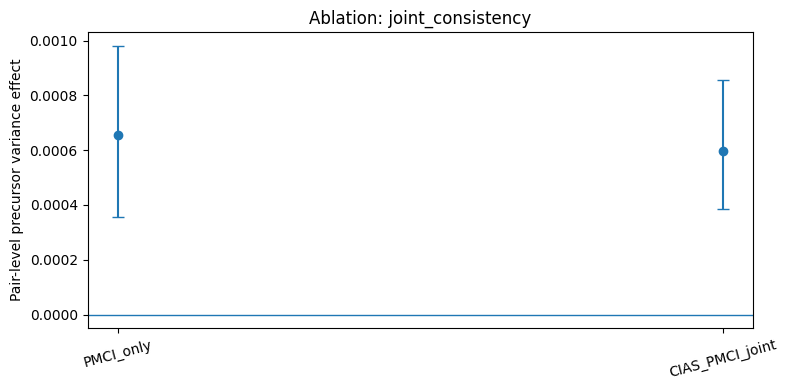

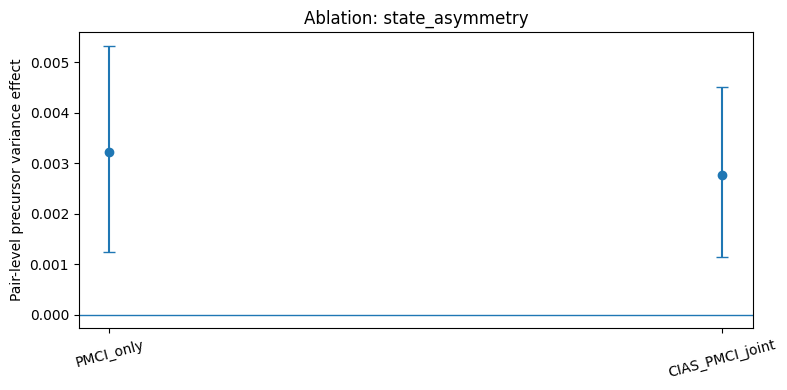

In [ ]:
#@title 07B. Ablation figures
for signal in ablation_summary.signal.unique():
    p=ablation_summary[ablation_summary.signal==signal].copy(); x=np.arange(len(p))
    yerr=np.vstack([p.mean_effect-p.ci_low,p.ci_high-p.mean_effect])
    plt.figure(figsize=(8,4)); plt.errorbar(x,p.mean_effect,yerr=yerr,fmt='o',capsize=4); plt.axhline(0,linewidth=1)
    plt.xticks(x,p.representation,rotation=15); plt.ylabel('Pair-level precursor variance effect'); plt.title(f'Ablation: {signal}'); plt.tight_layout(); plt.show()


## 08. Experiment 3 — boundary-matched control


In [ ]:
#@title 08A. Match stable controls by source regime, dwell age, time and cluster-boundary proximity
boundary_col='regime_cf_boundary_margin'
b_events,b_session,b_pair,b_summary,b_matches=strict_precursor_analysis(
    regime_data,label_col='regime_cf',signals=('joint_consistency','state_asymmetry'),pre_seconds=(6.0,),pair_col='pair_id',
    boundary_col=boundary_col,boundary_weight=2.0
)
standard_6s=main_precursor_summary[(main_precursor_summary.pre_seconds==6.0)&(main_precursor_summary.signal.isin(['joint_consistency','state_asymmetry']))].copy()
standard_6s['control']='standard_matched'
b_comp=b_summary.copy(); b_comp['control']='boundary_matched'
boundary_comparison=pd.concat([standard_6s,b_comp],ignore_index=True,sort=False)
display(boundary_comparison[['control','signal','n_pairs','n_events','mean_effect','bootstrap_ci_low','bootstrap_ci_high','wilcoxon_p','p_fdr_bh']].round(6))
boundary_comparison.to_csv(RESULTS/'boundary_artifact_control_summary.csv',index=False)
b_pair.to_csv(RESULTS/'boundary_matched_pair_effects.csv',index=False)


,control,signal,n_pairs,n_events,mean_effect,bootstrap_ci_low,bootstrap_ci_high,wilcoxon_p,p_fdr_bh
0,standard_matched,joint_consistency,10,121,0.001176,0.000679,0.001895,0.001953,0.005859
1,standard_matched,state_asymmetry,10,121,0.003559,0.001555,0.005514,0.019531,0.029297
2,boundary_matched,joint_consistency,11,145,0.000324,0.000058,0.000588,0.083008,0.083008
3,boundary_matched,state_asymmetry,11,145,0.001997,0.000812,0.003105,0.009766,0.019531


## 09. Experiment 4 — pair-level bootstrap and leave-one-pair-out sensitivity


In [ ]:
#@title 09A. Leave one unique pair out
loo_rows=[]
for (signal,seconds),g in main_pair_effects.groupby(['signal','pre_seconds']):
    for omitted in sorted(g.pair_id.unique()):
        v=g.loc[g.pair_id!=omitted,'mean_effect'].to_numpy(float)
        loo_rows.append({'signal':signal,'pre_seconds':seconds,'omitted_pair':omitted,'remaining_pairs':len(v),'mean_effect':float(np.mean(v)) if len(v) else np.nan})
loo=pd.DataFrame(loo_rows)
loo_summary=loo.groupby(['signal','pre_seconds'],as_index=False).agg(min_loo_effect=('mean_effect','min'),max_loo_effect=('mean_effect','max'),fraction_positive=('mean_effect',lambda x:float(np.mean(np.asarray(x)>0))))
display(loo_summary.round(6))
loo.to_csv(RESULTS/'leave_one_pair_out_runs.csv',index=False); loo_summary.to_csv(RESULTS/'leave_one_pair_out_summary.csv',index=False)


,signal,pre_seconds,min_loo_effect,max_loo_effect,fraction_positive
0,joint_consistency,2.0,0.000952,0.001138,1.0
1,joint_consistency,4.0,0.000784,0.001176,1.0
2,joint_consistency,6.0,0.000866,0.001277,1.0
3,joint_consistency,8.0,0.000825,0.001280,1.0
4,joint_velocity,2.0,0.001749,0.003601,1.0
5,joint_velocity,4.0,0.002367,0.003762,1.0
6,joint_velocity,6.0,0.003108,0.004643,1.0
7,joint_velocity,8.0,0.002731,0.003710,1.0
8,state_asymmetry,2.0,0.001321,0.002709,1.0
9,state_asymmetry,4.0,0.001240,0.003589,1.0


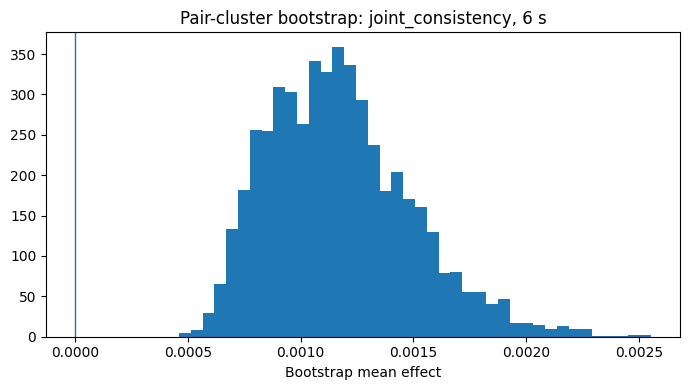

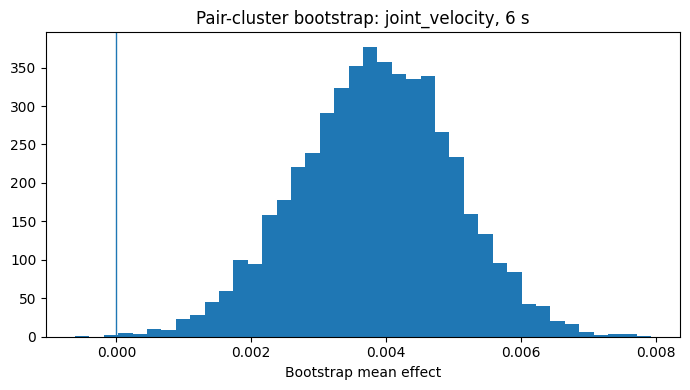

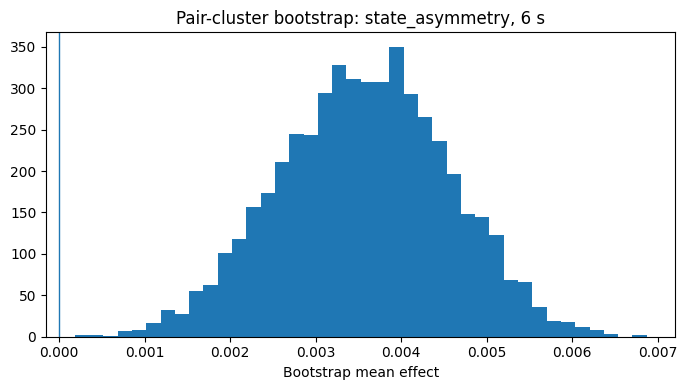

In [ ]:
#@title 09B. Pair-cluster bootstrap distributions
rng=np.random.default_rng(CFG.random_state); boot_rows=[]
for (signal,seconds),g in main_pair_effects.groupby(['signal','pre_seconds']):
    v=g.mean_effect.to_numpy(float)
    for i in range(CFG.bootstrap_iterations):
        boot_rows.append({'signal':signal,'pre_seconds':seconds,'iteration':i,'mean_effect':float(rng.choice(v,len(v),replace=True).mean())})
pair_bootstrap=pd.DataFrame(boot_rows)
pair_bootstrap.to_csv(RESULTS/'pair_cluster_bootstrap.csv',index=False)

for signal in pair_bootstrap.signal.unique():
    p=pair_bootstrap[(pair_bootstrap.signal==signal)&(pair_bootstrap.pre_seconds==6.0)]
    plt.figure(figsize=(7,4)); plt.hist(p.mean_effect,bins=40); plt.axvline(0,linewidth=1); plt.xlabel('Bootstrap mean effect'); plt.title(f'Pair-cluster bootstrap: {signal}, 6 s'); plt.tight_layout(); plt.show()


## 10. Optional strict participant-disjoint cross-fitting


In [ ]:
#@title 10A. Participant-component-disjoint robustness
if dyad.participant_component.nunique() < 2:
    print('Not enough participant components for participant-disjoint analysis.')
else:
    participant_cf,participant_folds=crossfit_regimes(
        dyad,STATE_COLUMNS,group_col='participant_component',k=CFG.selected_k,
        n_splits=min(CFG.crossfit_folds,dyad.participant_component.nunique()),seed=CFG.random_state+500,label_col='regime_participant_cf'
    )
    _,_,participant_pair_effects,participant_summary,_=strict_precursor_analysis(
        participant_cf,label_col='regime_participant_cf',signals=('joint_consistency','state_asymmetry'),pre_seconds=(6.0,),pair_col='pair_id'
    )
    display(participant_folds.round(4)); display(participant_summary.round(6))
    participant_summary.to_csv(RESULTS/'participant_disjoint_precursor_summary.csv',index=False)
    participant_pair_effects.to_csv(RESULTS/'participant_disjoint_pair_effects.csv',index=False)


,fold,train_groups,test_groups,test_rows,silhouette_test
0,0,4,1,3475,0.1266
1,1,4,1,2217,0.3750
2,2,4,1,1434,0.3050
3,3,4,1,1404,0.3584
4,4,4,1,1373,0.2414


,signal,pre_seconds,n_pairs,n_sessions,n_events,mean_effect,bootstrap_ci_low,bootstrap_ci_high,n_positive_pairs,wilcoxon_p,sign_test_p,p_fdr_bh
0,joint_consistency,6.0,9,13,93,0.000617,-0.000023,0.001502,7,0.164062,0.089844,0.203125
1,state_asymmetry,6.0,9,13,93,0.001973,-0.000806,0.004323,7,0.203125,0.089844,0.203125


## 11. Experiment 5 — naturalistic transfer without refitting


In [ ]:
#@title 11A. Download and prepare naturalistic sessions
if not CFG.run_naturalistic_transfer:
    print('Naturalistic transfer disabled in CFG.')
else:
    transfer_fs,transfer_pairs,transfer_download_failures=download_complete_pairs(
        CFG.transfer_label,CFG.transfer_split,CFG.transfer_n_pairs,TRANSFER_ROOT,CFG.random_state+1000
    )
    transfer_manifest_all=build_raw_manifest(transfer_pairs,TRANSFER_ROOT,CFG.transfer_label,CFG.transfer_split)
    transfer_manifest,transfer_inventory,transfer_session_identity=prepare_identity_manifest(transfer_manifest_all)
    print('Naturalistic sessions:',transfer_manifest.interaction_key.nunique(),'pairs:',transfer_manifest.pair_id.nunique())
    transfer_manifest.to_csv(PROCESSED/'naturalistic_manifest.csv',index=False)


Download naturalistic/dev:   0%|          | 0/40 [00:00<?, ?it/s]

naturalistic/dev: requested=40, downloaded=40, failed=0


Feature inventory:   0%|          | 0/40 [00:00<?, ?it/s]

Naturalistic sessions: 17 pairs: 12


In [ ]:
#@title 11B. Project naturalistic data with fixed PMCI and fixed improvised regime model
if CFG.run_naturalistic_transfer:
    transfer_long,transfer_dyad,transfer_failures=build_dynamic_state_space(transfer_manifest,'Naturalistic CIAS–PMCI trajectories')

    # Final regime model is fitted once on the complete primary corpus and then frozen for external transfer.
    final_scaler=StandardScaler().fit(dyad[STATE_COLUMNS]); final_X=final_scaler.transform(dyad[STATE_COLUMNS])
    final_kmeans=KMeans(n_clusters=CFG.selected_k,n_init=100,max_iter=500,random_state=CFG.random_state).fit(final_X)
    transfer_X=final_scaler.transform(transfer_dyad[STATE_COLUMNS]); transfer_dyad['regime_transfer']=final_kmeans.predict(transfer_X)
    dist=cdist(transfer_X,final_kmeans.cluster_centers_); sd=np.sort(dist,axis=1); transfer_dyad['regime_transfer_boundary_margin']=sd[:,1]-sd[:,0]

    _,_,transfer_pair_effects,transfer_summary,_=strict_precursor_analysis(
        transfer_dyad,label_col='regime_transfer',signals=('joint_consistency','state_asymmetry'),pre_seconds=(6.0,),pair_col='pair_id'
    )
    occupancy=transfer_dyad.groupby('regime_transfer',as_index=False).size(); occupancy['fraction']=occupancy['size']/occupancy['size'].sum()
    print('Naturalistic regime occupancy'); display(occupancy)
    print('Naturalistic pair-level precursor'); display(transfer_summary.round(6))
    transfer_dyad.to_csv(PROCESSED/'naturalistic_projected_state_space.csv',index=False)
    transfer_summary.to_csv(RESULTS/'naturalistic_transfer_precursor_summary.csv',index=False)
    transfer_pair_effects.to_csv(RESULTS/'naturalistic_transfer_pair_effects.csv',index=False)
    occupancy.to_csv(RESULTS/'naturalistic_regime_occupancy.csv',index=False)


Naturalistic CIAS–PMCI trajectories:   0%|          | 0/34 [00:00<?, ?it/s]

Naturalistic regime occupancy


,regime_transfer,size,fraction
0,0,929,0.147601
1,1,2416,0.383858
2,2,2949,0.468541


Naturalistic pair-level precursor


,signal,pre_seconds,n_pairs,n_sessions,n_events,mean_effect,bootstrap_ci_low,bootstrap_ci_high,n_positive_pairs,wilcoxon_p,sign_test_p,p_fdr_bh
0,joint_consistency,6.0,11,15,104,0.001251,0.000603,0.001991,10,0.002930,0.005859,0.004883
1,state_asymmetry,6.0,11,15,104,0.008773,0.003927,0.015207,9,0.004883,0.032715,0.004883


## 12. Final reviewer table and export


In [ ]:
#@title 12A. Assemble the final evidence table
final_rows=[]
for _,r in pmci_metrics.iterrows():
    final_rows.append({'experiment':'PMCI pair-disjoint validation','signal':'ROC-AUC','estimate':r.roc_auc,'ci_low':np.nan,'ci_high':np.nan,'n_pairs':r.test_pairs})
for _,r in main_precursor_summary[main_precursor_summary.pre_seconds==6.0].iterrows():
    final_rows.append({'experiment':'Cross-fitted precursor','signal':r.signal,'estimate':r.mean_effect,'ci_low':r.bootstrap_ci_low,'ci_high':r.bootstrap_ci_high,'n_pairs':r.n_pairs})
for _,r in b_summary.iterrows():
    final_rows.append({'experiment':'Boundary-matched precursor','signal':r.signal,'estimate':r.mean_effect,'ci_low':r.bootstrap_ci_low,'ci_high':r.bootstrap_ci_high,'n_pairs':r.n_pairs})
for _,r in ablation_summary.iterrows():
    final_rows.append({'experiment':f'Ablation {r.representation}','signal':r.signal,'estimate':r.mean_effect,'ci_low':r.ci_low,'ci_high':r.ci_high,'n_pairs':r.n_pairs})
if CFG.run_naturalistic_transfer and 'transfer_summary' in globals():
    for _,r in transfer_summary.iterrows():
        final_rows.append({'experiment':'Naturalistic transfer','signal':r.signal,'estimate':r.mean_effect,'ci_low':r.bootstrap_ci_low,'ci_high':r.bootstrap_ci_high,'n_pairs':r.n_pairs})
final_evidence=pd.DataFrame(final_rows)
display(final_evidence.round(6))
final_evidence.to_csv(RESULTS/'FINAL_EVIDENCE_TABLE.csv',index=False)


,experiment,signal,estimate,ci_low,ci_high,n_pairs
0,PMCI pair-disjoint validation,ROC-AUC,0.687581,NaN,NaN,4.0
1,Cross-fitted precursor,joint_consistency,0.001176,0.000679,0.001895,10.0
2,Cross-fitted precursor,joint_velocity,0.003803,0.001490,0.006104,10.0
3,Cross-fitted precursor,state_asymmetry,0.003559,0.001555,0.005514,10.0
4,Boundary-matched precursor,joint_consistency,0.000324,0.000058,0.000588,11.0
5,Boundary-matched precursor,state_asymmetry,0.001997,0.000812,0.003105,11.0
6,Ablation PMCI_only,joint_consistency,0.000655,0.000356,0.000981,12.0
7,Ablation PMCI_only,state_asymmetry,0.003223,0.001237,0.005326,12.0
8,Ablation CIAS_PMCI_joint,joint_consistency,0.000598,0.000386,0.000857,11.0
9,Ablation CIAS_PMCI_joint,state_asymmetry,0.002758,0.001139,0.004516,11.0


Feature groups:
  state_usage: 9 features
  transition_topology: 9 features
  absolute_signal_levels: 6 features
  signal_dynamics: 8 features
  dynamics_without_levels: 26 features
  full_fingerprint: 32 features

STATE CENTROIDS IN ORIGINAL CIAS–PMCI UNITS


,state,cias_A,pmci_A,cias_B,pmci_B,centroid_joint_consistency,centroid_state_asymmetry
0,0,0.523375,0.873644,0.525661,0.919008,0.710422,0.045421
1,1,0.527902,0.376774,0.527237,0.883917,0.578958,0.507143
2,2,0.523366,0.790895,0.522612,0.370853,0.551932,0.420043



TIME-GAP AUDIT


,condition,session_id,n_rows,n_segments,median_dt,max_dt,n_large_gaps
14,improvised,V00_S2022_I00001202,430,8,0.5,28.0,7
0,improvised,V00_S0644_I00000770,205,6,0.5,11.5,5
10,improvised,V00_S0809_I00000581,292,4,0.5,2.5,3
12,improvised,V00_S1061_I00000166,516,4,0.5,4.0,3
1,improvised,V00_S0648_I00000376,495,3,0.5,4.5,2
2,improvised,V00_S0648_I00000541,241,3,0.5,16.0,2
7,improvised,V00_S0696_I00000375,398,2,0.5,2.0,1
8,improvised,V00_S0700_I00000307,399,2,0.5,3.5,1
15,improvised,V00_S2022_I00001203,501,2,0.5,2.5,1
3,improvised,V00_S0648_I00000542,493,1,0.5,0.5,0



MINIMUM-DWELL AUDIT


...

,condition,minimum_dwell_seconds,adjustment,feature_group,same_pair_beta,same_pair_qap_p_fdr,same_pair_minus_shared_beta,pair_specificity_qap_p_fdr,same_pair_confirmed,dyad_specific_confirmed,nearest_pair_accuracy,nearest_pair_accuracy_p_fdr
9,improvised,2.0,pair_crossfitted_technical_residuals,dynamics_without_levels,-1.608505,0.009198,-1.391210,0.080384,True,False,0.458333,0.000600
8,improvised,2.0,raw_with_technical_covariate,dynamics_without_levels,-0.990953,0.140132,-0.560190,0.377025,False,False,0.375000,0.000800
21,improvised,3.0,pair_crossfitted_technical_residuals,dynamics_without_levels,-1.338518,0.027195,-0.989201,0.098140,True,False,0.291667,0.005999
20,improvised,3.0,raw_with_technical_covariate,dynamics_without_levels,-0.955153,0.117876,-0.222479,0.443911,False,False,0.166667,0.099340
33,naturalistic,2.0,pair_crossfitted_technical_residuals,dynamics_without_levels,-1.614944,0.028794,-2.549663,0.002400,True,True,0.235294,0.027295
32,naturalistic,2.0,raw_with_technical_covariate,dynamics_without_levels,-1.952751,0.017397,-2.055004,0.023995,True,True,0.176471,0.100480
45,naturalistic,3.0,pair_crossfitted_technical_residuals,dynamics_without_levels,-2.017967,0.011398,-2.466974,0.003299,True,True,0.352941,0.002400
44,naturalistic,3.0,raw_with_technical_covariate,dynamics_without_levels,-2.322122,0.007598,-1.880583,0.035193,True,True,0.176471,0.075585
11,improvised,2.0,pair_crossfitted_technical_residuals,full_fingerprint,-1.888864,0.008998,-1.638672,0.080384,True,False,0.458333,0.000800
10,improvised,2.0,raw_with_technical_covariate,full_fingerprint,-1.125875,0.140132,-0.647055,0.377025,False,False,0.458333,0.000600



FINGERPRINT ROBUSTNESS SUMMARY


,feature_group,n_tests,n_same_pair_confirmed,n_dyad_specific_confirmed,fraction_same_pair_confirmed,fraction_dyad_specific_confirmed,median_nearest_pair_accuracy
0,dynamics_without_levels,8,6,4,0.75,0.500,0.263480
1,full_fingerprint,8,6,4,0.75,0.500,0.313725
2,state_usage,8,4,3,0.50,0.375,0.192402
3,transition_topology,8,0,0,0.00,0.000,0.121324



GATEWAY VS FIRST-ORDER MARKOV NULL


,condition,minimum_dwell_seconds,gateway_state,n_pairs,mean_observed_gateway_ratio,mean_markov_null_ratio,mean_gateway_excess_over_markov,bootstrap_ci_low,bootstrap_ci_high,n_positive_pairs,wilcoxon_greater_p,p_fdr_bh
1,improvised,2.0,1,8,0.678309,0.581457,0.096852,0.000234,0.205033,4,0.109375,0.656250
0,improvised,2.0,0,11,0.045651,0.145228,-0.099577,-0.144878,-0.056503,0,1.000000,1.000000
2,improvised,2.0,2,9,0.171744,0.160750,0.010994,-0.071166,0.127529,2,0.787109,1.000000
7,naturalistic,2.0,1,10,0.477384,0.462022,0.015363,-0.027122,0.059241,5,0.278320,0.834961
6,naturalistic,2.0,0,12,0.124433,0.155489,-0.031055,-0.058236,-0.012664,1,0.999512,1.000000
8,naturalistic,2.0,2,10,0.309965,0.346113,-0.036149,-0.149158,0.043709,6,0.539062,1.000000
4,improvised,3.0,1,5,0.580000,0.478266,0.101734,-0.127176,0.369313,2,0.406250,0.910156
3,improvised,3.0,0,9,0.050980,0.146508,-0.095528,-0.184486,-0.031337,0,1.000000,1.000000
5,improvised,3.0,2,7,0.075255,0.158974,-0.083719,-0.144240,-0.022870,2,0.976562,1.000000
10,naturalistic,3.0,1,9,0.459436,0.417461,0.041975,-0.001915,0.094828,6,0.125000,0.750000


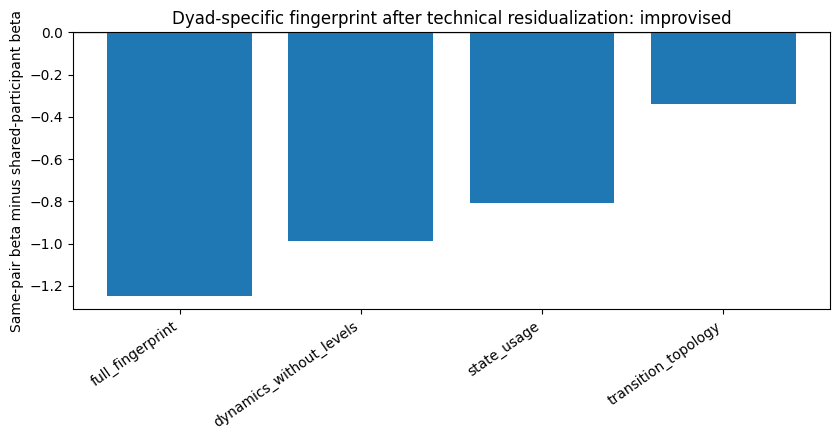

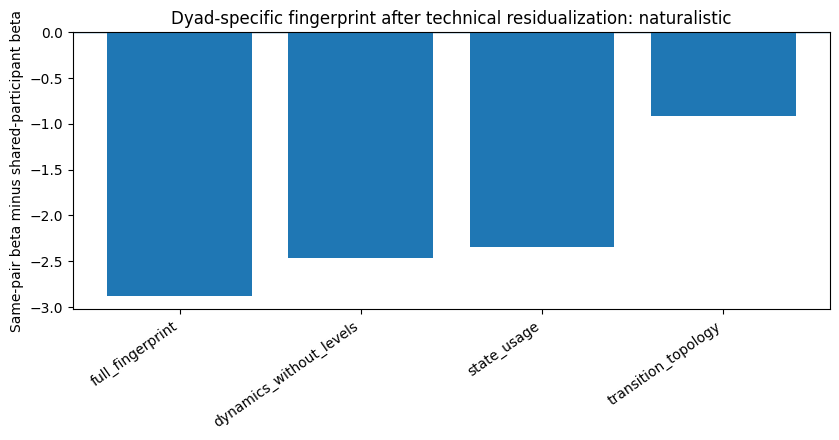


Saved final confirmatory outputs to: /content/article3_q1_additional_experiments/results
Primary interpretation rule:
  same_pair_beta < 0 and same_pair_qap_p_fdr < .05 -> reproducible same-pair fingerprint
  plus same_pair_minus_shared_beta < 0 and pair_specificity_qap_p_fdr < .05
  -> fingerprint is more dyad-specific than participant-specific
  persistence after pair_crossfitted_technical_residuals -> not explained by measured technical factors


In [ ]:
#@title 13. FINAL confirmatory validation: pair fingerprint, technical controls, and Markov gateway null

from __future__ import annotations

from itertools import combinations
from pathlib import Path
import math
import zlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans
from sklearn.linear_model import Ridge
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler

# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------

CONFIRM_DWELL_SECONDS = (2.0, 3.0)
CONFIRM_QAP_PERMUTATIONS = 5000       # final manuscript run
CONFIRM_MARKOV_SIMULATIONS = 2000
CONFIRM_RIDGE_ALPHA = 10.0
CONFIRM_RANDOM_STATE = int(getattr(CFG, 'random_state', 42))
CONFIRM_STATE_COLUMNS = ['cias_A', 'pmci_A', 'cias_B', 'pmci_B']
CONFIRM_K = int(getattr(CFG, 'selected_k', 3))

# The cell is intentionally independent of earlier experimental add-on cells.
# It only requires the original ALL-IN-ONE notebook to have completed through 11B.
_required = [
    'dyad', 'regime_data', 'transfer_dyad', 'manifest', 'transfer_manifest',
    'CFG', 'RESULTS', 'final_scaler', 'final_kmeans'
]
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError(
        'Run the original notebook through cell 11B first. Missing objects: '
        + ', '.join(_missing)
    )

RESULTS = Path(RESULTS)
RESULTS.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# Utilities
# ---------------------------------------------------------------------

def confirm_bh_adjust(p_values):
    p = np.asarray(p_values, dtype=float)
    out = np.full(len(p), np.nan, dtype=float)
    valid = np.flatnonzero(np.isfinite(p))
    if len(valid) == 0:
        return out
    pv = p[valid]
    order = np.argsort(pv)
    ranked = pv[order]
    m = len(ranked)
    adjusted = ranked * m / np.arange(1, m + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    adjusted = np.clip(adjusted, 0, 1)
    restored = np.empty_like(adjusted)
    restored[order] = adjusted
    out[valid] = restored
    return out


def confirm_parse_pair(pair_id):
    parts = str(pair_id).split('__')
    if len(parts) >= 2:
        return parts[0], parts[1]
    return str(pair_id), ''


def confirm_safe_matrix(frame_or_array):
    X = np.asarray(frame_or_array, dtype=float).copy()
    X[~np.isfinite(X)] = np.nan
    med = np.nanmedian(X, axis=0)
    med[~np.isfinite(med)] = 0.0
    rr, cc = np.where(~np.isfinite(X))
    if len(rr):
        X[rr, cc] = med[cc]
    sd = np.std(X, axis=0)
    keep = np.isfinite(sd) & (sd > 1e-10)
    if not np.any(keep):
        return np.zeros((len(X), 1), dtype=float)
    return X[:, keep]


def confirm_standardize(frame_or_array):
    X = confirm_safe_matrix(frame_or_array)
    if X.shape[1] == 0:
        return np.zeros((len(X), 1), dtype=float)
    return StandardScaler().fit_transform(X)


def confirm_infer_step(times, fallback=0.5):
    times = np.asarray(times, dtype=float)
    dt = np.diff(times)
    dt = dt[np.isfinite(dt) & (dt > 0)]
    return float(np.median(dt)) if len(dt) else float(fallback)


def confirm_run_length(labels):
    labels = np.asarray(labels, dtype=int)
    if len(labels) == 0:
        return []
    starts = [0]
    for i in range(1, len(labels)):
        if labels[i] != labels[i - 1]:
            starts.append(i)
    starts.append(len(labels))
    return [
        {'start': starts[i], 'end': starts[i + 1] - 1, 'label': int(labels[starts[i]])}
        for i in range(len(starts) - 1)
    ]


def confirm_run_duration(times, run):
    start, end = int(run['start']), int(run['end'])
    local = np.asarray(times[start:end + 1], dtype=float)
    step = confirm_infer_step(local, getattr(CFG, 'stride_seconds', 0.5))
    return float(local[-1] - local[0] + step)

# ---------------------------------------------------------------------
# Time-aware preparation and frozen shared state model
# ---------------------------------------------------------------------

def confirm_prepare_timeaware(frame, condition):
    data = frame.copy().sort_values(['session_id', 'time_sec']).reset_index(drop=True)

    prepared = []
    audit_rows = []
    for session_id, g in data.groupby('session_id', sort=False):
        g = g.sort_values('time_sec').reset_index(drop=True).copy()
        t = g['time_sec'].to_numpy(float)
        step = confirm_infer_step(t, getattr(CFG, 'stride_seconds', 0.5))
        max_gap = max(0.75, 1.5 * step)
        dt = np.r_[np.nan, np.diff(t)]
        segment_break = np.zeros(len(g), dtype=int)
        segment_break[0] = 1
        if len(g) > 1:
            segment_break[1:] = (np.diff(t) > max_gap).astype(int)
        g['continuous_segment_local'] = np.cumsum(segment_break) - 1
        g['continuous_segment_id'] = (
            condition + '::' + g['session_id'].astype(str) + '::' +
            g['continuous_segment_local'].astype(str)
        )
        g['dt_seconds'] = dt

        for person in ['A', 'B']:
            for signal in ['cias', 'pmci']:
                col = f'{signal}_{person}'
                dcol = f'd_{signal}_{person}_dt'
                diff = g.groupby('continuous_segment_id')[col].diff()
                local_dt = g.groupby('continuous_segment_id')['time_sec'].diff()
                g[dcol] = diff / local_dt.replace(0, np.nan)

        derivative_cols = [
            'd_cias_A_dt', 'd_pmci_A_dt', 'd_cias_B_dt', 'd_pmci_B_dt'
        ]
        g['joint_velocity_timeaware'] = np.sqrt(
            g[derivative_cols].fillna(0.0).pow(2).sum(axis=1)
        )

        audit_rows.append({
            'condition': condition,
            'session_id': session_id,
            'n_rows': len(g),
            'n_segments': int(g['continuous_segment_id'].nunique()),
            'median_dt': step,
            'max_dt': float(np.nanmax(dt)) if np.any(np.isfinite(dt)) else np.nan,
            'n_large_gaps': int(np.sum(np.isfinite(dt) & (dt > max_gap))),
        })
        prepared.append(g)

    return pd.concat(prepared, ignore_index=True), pd.DataFrame(audit_rows)


def confirm_apply_state_labels(frame, condition):
    data = frame.copy()
    X = final_scaler.transform(data[CONFIRM_STATE_COLUMNS])
    distances = cdist(X, final_kmeans.cluster_centers_)
    sorted_d = np.sort(distances, axis=1)

    # Primary labels are genuinely out-of-pair-fold labels from the original notebook.
    # Naturalistic labels use the final frozen model trained only on improvised data.
    if condition == 'improvised' and 'regime_cf' in data.columns:
        data['regime_frozen'] = data['regime_cf'].astype(int)
        if 'regime_cf_boundary_margin' in data.columns:
            data['regime_boundary_margin'] = data['regime_cf_boundary_margin'].astype(float)
        else:
            data['regime_boundary_margin'] = sorted_d[:, 1] - sorted_d[:, 0]
    else:
        data['regime_frozen'] = final_kmeans.predict(X)
        data['regime_boundary_margin'] = sorted_d[:, 1] - sorted_d[:, 0]

    data['regime_nearest_distance'] = sorted_d[:, 0]
    data['condition'] = condition
    return data


primary_prepared, primary_gap_audit = confirm_prepare_timeaware(regime_data, 'improvised')
transfer_prepared, transfer_gap_audit = confirm_prepare_timeaware(transfer_dyad, 'naturalistic')
primary_prepared = confirm_apply_state_labels(primary_prepared, 'improvised')
transfer_prepared = confirm_apply_state_labels(transfer_prepared, 'naturalistic')
confirm_time_gap_audit = pd.concat([primary_gap_audit, transfer_gap_audit], ignore_index=True)

# Raw-state centroids in interpretable units
confirm_state_centroids = pd.DataFrame(
    final_scaler.inverse_transform(final_kmeans.cluster_centers_),
    columns=CONFIRM_STATE_COLUMNS,
)
confirm_state_centroids.insert(0, 'state', np.arange(CONFIRM_K))
confirm_state_centroids['centroid_joint_consistency'] = confirm_state_centroids[
    CONFIRM_STATE_COLUMNS
].mean(axis=1)
confirm_state_centroids['centroid_state_asymmetry'] = np.sqrt(
    (confirm_state_centroids['cias_A'] - confirm_state_centroids['cias_B']) ** 2
    + (confirm_state_centroids['pmci_A'] - confirm_state_centroids['pmci_B']) ** 2
)

# ---------------------------------------------------------------------
# Minimum-dwell smoothing in real time
# ---------------------------------------------------------------------

def confirm_smooth_segment(labels, times, minimum_dwell_seconds):
    labels = np.asarray(labels, dtype=int).copy()
    times = np.asarray(times, dtype=float)
    if minimum_dwell_seconds <= 0 or len(labels) < 2:
        return labels

    for _ in range(1000):
        runs = confirm_run_length(labels)
        durations = [confirm_run_duration(times, run) for run in runs]
        short_indices = [i for i, duration in enumerate(durations) if duration < minimum_dwell_seconds]
        if not short_indices or len(runs) == 1:
            break

        # Fix the shortest unstable run first, then recompute runs.
        i = min(short_indices, key=lambda idx: durations[idx])
        run = runs[i]
        left = runs[i - 1] if i > 0 else None
        right = runs[i + 1] if i + 1 < len(runs) else None

        if left is not None and right is not None and left['label'] == right['label']:
            replacement = left['label']
        elif left is None and right is not None:
            replacement = right['label']
        elif right is None and left is not None:
            replacement = left['label']
        elif left is not None and right is not None:
            left_duration = durations[i - 1]
            right_duration = durations[i + 1]
            replacement = left['label'] if left_duration >= right_duration else right['label']
        else:
            break

        labels[int(run['start']):int(run['end']) + 1] = int(replacement)

    return labels


def confirm_apply_minimum_dwell(frame, dwell_seconds):
    data = frame.copy()
    output_labels = np.full(len(data), -1, dtype=int)
    audit = []

    for segment_id, idx in data.groupby('continuous_segment_id', sort=False).groups.items():
        idx = np.asarray(list(idx), dtype=int)
        idx = idx[np.argsort(data.loc[idx, 'time_sec'].to_numpy(float))]
        labels = data.loc[idx, 'regime_frozen'].to_numpy(int)
        times = data.loc[idx, 'time_sec'].to_numpy(float)
        smoothed = confirm_smooth_segment(labels, times, dwell_seconds)
        output_labels[idx] = smoothed
        audit.append({
            'condition': data.loc[idx[0], 'condition'],
            'minimum_dwell_seconds': float(dwell_seconds),
            'continuous_segment_id': segment_id,
            'original_switches': int(np.sum(labels[1:] != labels[:-1])),
            'smoothed_switches': int(np.sum(smoothed[1:] != smoothed[:-1])),
            'changed_rows': int(np.sum(smoothed != labels)),
        })

    if np.any(output_labels < 0):
        raise AssertionError('Some rows did not receive minimum-dwell labels.')
    label_col = f'regime_dwell_{str(dwell_seconds).replace(".", "p")}'
    data[label_col] = output_labels
    return data, label_col, pd.DataFrame(audit)

# ---------------------------------------------------------------------
# Runs, transitions, and session fingerprints
# ---------------------------------------------------------------------

def confirm_extract_runs_and_transitions(frame, label_col):
    run_rows, transition_rows = [], []

    for segment_id, g in frame.groupby('continuous_segment_id', sort=False):
        g = g.sort_values('time_sec').reset_index(drop=True)
        labels = g[label_col].to_numpy(int)
        times = g['time_sec'].to_numpy(float)
        runs = confirm_run_length(labels)
        local_runs = []

        for run_index, run in enumerate(runs):
            start, end = int(run['start']), int(run['end'])
            row = {
                'condition': g['condition'].iloc[0],
                'session_id': g['session_id'].iloc[0],
                'pair_id': g['pair_id'].iloc[0],
                'continuous_segment_id': segment_id,
                'run_index': run_index,
                'state': int(run['label']),
                'start_time': float(times[start]),
                'end_time': float(times[end]),
                'duration_seconds': confirm_run_duration(times, run),
            }
            for signal in [
                'joint_consistency', 'state_asymmetry', 'joint_velocity_timeaware',
                'cias_A', 'cias_B', 'pmci_A', 'pmci_B',
                'valid_fraction_A', 'valid_fraction_B', 'regime_boundary_margin',
            ]:
                if signal in g.columns:
                    row[f'mean_{signal}'] = float(pd.to_numeric(
                        g.loc[start:end, signal], errors='coerce'
                    ).mean())
            run_rows.append(row)
            local_runs.append(row)

        for source, target in zip(local_runs[:-1], local_runs[1:]):
            transition_rows.append({
                'condition': source['condition'],
                'session_id': source['session_id'],
                'pair_id': source['pair_id'],
                'continuous_segment_id': segment_id,
                'source_state': int(source['state']),
                'target_state': int(target['state']),
                'edge': f"{source['state']}->{target['state']}",
                'transition_time': float(target['start_time']),
            })

    return pd.DataFrame(run_rows), pd.DataFrame(transition_rows)


def confirm_normalized_entropy(counts):
    counts = np.asarray(counts, dtype=float)
    counts = counts[counts > 0]
    if len(counts) <= 1:
        return 0.0
    p = counts / counts.sum()
    return float(-np.sum(p * np.log(p)) / np.log(len(counts)))


def confirm_build_fingerprints(frame, runs, transitions, dwell_seconds):
    rows = []
    for (session_id, pair_id), sf in frame.groupby(['session_id', 'pair_id'], sort=False):
        sr = runs[runs['session_id'] == session_id].copy()
        st = transitions[transitions['session_id'] == session_id].copy()
        total_duration = float(sr['duration_seconds'].sum())
        pa, pb = confirm_parse_pair(pair_id)

        row = {
            'condition': sf['condition'].iloc[0],
            'minimum_dwell_seconds': float(dwell_seconds),
            'session_id': str(session_id),
            'pair_id': str(pair_id),
            'participant_a': pa,
            'participant_b': pb,
            'session_duration_seconds': total_duration,
            'n_rows': len(sf),
            'n_segments': int(sf['continuous_segment_id'].nunique()),
            'n_runs': len(sr),
            'n_transitions': len(st),
            'switching_rate_per_minute': 60.0 * len(st) / max(total_duration, 1e-8),
        }

        for state in range(CONFIRM_K):
            state_runs = sr[sr['state'] == state]
            state_duration = float(state_runs['duration_seconds'].sum())
            row[f'occupancy_state_{state}'] = state_duration / max(total_duration, 1e-8)
            row[f'mean_dwell_state_{state}'] = (
                float(state_runs['duration_seconds'].mean()) if len(state_runs) else 0.0
            )
            row[f'median_dwell_state_{state}'] = (
                float(state_runs['duration_seconds'].median()) if len(state_runs) else 0.0
            )

        edge_counts = []
        for source in range(CONFIRM_K):
            source_rows = st[st['source_state'] == source]
            source_total = len(source_rows)
            for target in range(CONFIRM_K):
                if source == target:
                    continue
                count = int(np.sum(source_rows['target_state'] == target)) if source_total else 0
                edge_counts.append(count)
                row[f'transition_p_{source}_{target}'] = count / source_total if source_total else 0.0

        row['transition_entropy'] = confirm_normalized_entropy(edge_counts)

        returns, triplets = 0, 0
        for _, segment_runs in sr.groupby('continuous_segment_id', sort=False):
            seq = segment_runs.sort_values('run_index')['state'].to_numpy(int)
            for a, b, c in zip(seq[:-2], seq[1:-1], seq[2:]):
                triplets += 1
                returns += int(a == c and a != b)
        row['return_probability'] = returns / triplets if triplets else 0.0

        for signal in [
            'joint_consistency', 'state_asymmetry', 'joint_velocity_timeaware',
            'cias_A', 'cias_B', 'pmci_A', 'pmci_B',
            'valid_fraction_A', 'valid_fraction_B', 'regime_boundary_margin',
            'regime_nearest_distance',
        ]:
            if signal in sf.columns:
                values = pd.to_numeric(sf[signal], errors='coerce')
                row[f'session_mean_{signal}'] = float(values.mean())
                row[f'session_std_{signal}'] = float(values.std())

        rows.append(row)

    return pd.DataFrame(rows)

# ---------------------------------------------------------------------
# Manifest metadata and technical design
# ---------------------------------------------------------------------

def confirm_manifest_metadata(manifest_df, condition):
    m = manifest_df.copy()
    session_key = 'interaction_key' if 'interaction_key' in m.columns else 'session_id'
    keep_candidates = [
        'recording_session_id', 'interaction_prompt_id', 'dataset_label',
        'dataset_split', 'pair_id'
    ]
    keep = [c for c in keep_candidates if c in m.columns]
    meta = m[[session_key] + keep].groupby(session_key, as_index=False).first()
    meta = meta.rename(columns={session_key: 'session_id'})
    meta['session_id'] = meta['session_id'].astype(str)
    meta['condition'] = condition
    return meta


def confirm_add_metadata(fingerprints):
    primary_meta = confirm_manifest_metadata(manifest, 'improvised')
    transfer_meta = confirm_manifest_metadata(transfer_manifest, 'naturalistic')
    meta = pd.concat([primary_meta, transfer_meta], ignore_index=True)
    out = fingerprints.merge(meta, on=['session_id', 'condition'], how='left', suffixes=('', '_manifest'))
    out['vendor'] = out['session_id'].astype(str).str.split('_').str[0]
    return out


def confirm_technical_columns(frame):
    numeric = [
        c for c in [
            'session_duration_seconds', 'n_rows', 'n_segments',
            'session_mean_valid_fraction_A', 'session_mean_valid_fraction_B',
            'session_std_valid_fraction_A', 'session_std_valid_fraction_B',
            'session_mean_regime_nearest_distance', 'session_std_regime_nearest_distance',
        ] if c in frame.columns
    ]
    categorical = [
        c for c in ['vendor', 'recording_session_id', 'interaction_prompt_id']
        if c in frame.columns and 1 < frame[c].nunique(dropna=True) <= 30
    ]
    return numeric, categorical


def confirm_build_technical_matrix(frame):
    numeric, categorical = confirm_technical_columns(frame)
    parts = []
    names = []

    if numeric:
        num = frame[numeric].apply(pd.to_numeric, errors='coerce').copy()
        for c in numeric:
            med = num[c].median()
            num[c] = num[c].fillna(float(med) if np.isfinite(med) else 0.0)
        num_values = confirm_standardize(num.to_numpy(float))
        parts.append(num_values)
        names.extend([f'numeric_{i}' for i in range(num_values.shape[1])])

    if categorical:
        cat = pd.get_dummies(frame[categorical].fillna('missing').astype(str), drop_first=True, dtype=float)
        if cat.shape[1]:
            parts.append(cat.to_numpy(float))
            names.extend(cat.columns.astype(str).tolist())

    if not parts:
        return np.zeros((len(frame), 0), dtype=float), []
    return np.column_stack(parts), names

# ---------------------------------------------------------------------
# Relationship matrices, grouped residualization, and MRQAP
# ---------------------------------------------------------------------

def confirm_relationship_matrices(frame):
    n = len(frame)
    same_pair = np.zeros((n, n), dtype=float)
    shared_participant = np.zeros((n, n), dtype=float)
    participant_sets = []
    for pair_id in frame['pair_id'].astype(str):
        participant_sets.append(set(confirm_parse_pair(pair_id)))

    pair_ids = frame['pair_id'].astype(str).to_numpy()
    for i in range(n):
        for j in range(i + 1, n):
            if pair_ids[i] == pair_ids[j]:
                same_pair[i, j] = same_pair[j, i] = 1.0
            elif len(participant_sets[i] & participant_sets[j]) > 0:
                shared_participant[i, j] = shared_participant[j, i] = 1.0
    return same_pair, shared_participant


def confirm_group_crossfitted_residuals(features, technical, groups, alpha=10.0):
    Y = confirm_safe_matrix(features)
    if technical.shape[1] == 0:
        return Y.copy()

    groups = np.asarray(groups).astype(str)
    predictions = np.zeros_like(Y, dtype=float)
    for group in np.unique(groups):
        test = groups == group
        train = ~test
        if np.sum(train) < 3:
            predictions[test] = np.mean(Y[train], axis=0) if np.any(train) else 0.0
            continue
        model = Ridge(alpha=alpha, fit_intercept=True)
        model.fit(technical[train], Y[train])
        predictions[test] = model.predict(technical[test])
    return Y - predictions


def confirm_mrqap(distance_matrix, same_pair, shared_participant, technical_distance=None,
                   permutations=5000, seed=42):
    n = len(distance_matrix)
    upper = np.triu_indices(n, 1)
    y = distance_matrix[upper]

    predictors = [np.ones(len(y)), same_pair[upper], shared_participant[upper]]
    names = ['intercept', 'same_pair', 'shared_participant']
    if technical_distance is not None:
        tv = technical_distance[upper]
        if np.nanstd(tv) > 1e-10:
            tv = (tv - np.nanmean(tv)) / np.nanstd(tv)
            predictors.append(tv)
            names.append('technical_distance')
    X = np.column_stack(predictors)
    observed = np.linalg.lstsq(X, y, rcond=None)[0]
    i_pair = names.index('same_pair')
    i_shared = names.index('shared_participant')
    observed_pair = float(observed[i_pair])
    observed_shared = float(observed[i_shared])
    observed_contrast = observed_pair - observed_shared

    rng = np.random.default_rng(seed)
    null_pair = np.empty(permutations)
    null_shared = np.empty(permutations)
    null_contrast = np.empty(permutations)

    for b in range(permutations):
        perm = rng.permutation(n)
        yp = distance_matrix[np.ix_(perm, perm)][upper]
        beta = np.linalg.lstsq(X, yp, rcond=None)[0]
        null_pair[b] = beta[i_pair]
        null_shared[b] = beta[i_shared]
        null_contrast[b] = beta[i_pair] - beta[i_shared]

    return {
        'same_pair_beta': observed_pair,
        'same_pair_qap_p': float((1 + np.sum(null_pair <= observed_pair)) / (permutations + 1)),
        'shared_participant_beta': observed_shared,
        'shared_participant_qap_p': float((1 + np.sum(null_shared <= observed_shared)) / (permutations + 1)),
        'same_pair_minus_shared_beta': observed_contrast,
        'pair_specificity_qap_p': float((1 + np.sum(null_contrast <= observed_contrast)) / (permutations + 1)),
    }


def confirm_nearest_pair_accuracy(distance_matrix, pair_ids, permutations=5000, seed=42):
    D = distance_matrix.copy()
    np.fill_diagonal(D, np.inf)
    pair_ids = np.asarray(pair_ids).astype(str)
    nearest = np.argmin(D, axis=1)
    observed = float(np.mean(pair_ids[nearest] == pair_ids))
    rng = np.random.default_rng(seed)
    null = np.empty(permutations)
    for b in range(permutations):
        labels = rng.permutation(pair_ids)
        null[b] = np.mean(labels[nearest] == labels)
    p = float((1 + np.sum(null >= observed)) / (permutations + 1))
    return observed, p

# ---------------------------------------------------------------------
# Feature groups
# ---------------------------------------------------------------------

def confirm_feature_groups(frame):
    numeric = [
        c for c in frame.columns
        if pd.api.types.is_numeric_dtype(frame[c])
    ]
    state_usage = [c for c in numeric if c.startswith(('occupancy_state_', 'mean_dwell_state_', 'median_dwell_state_'))]
    topology = [
        c for c in numeric
        if c.startswith('transition_p_') or c in {
            'switching_rate_per_minute', 'transition_entropy', 'return_probability'
        }
    ]
    absolute_levels = [
        c for c in numeric
        if c.startswith('session_mean_')
        and not any(token in c for token in ['valid_fraction', 'regime_', 'joint_velocity'])
    ]
    signal_dynamics = [
        c for c in numeric
        if (
            c.startswith('session_std_')
            or c == 'session_mean_joint_velocity_timeaware'
        )
        and not any(token in c for token in ['valid_fraction', 'regime_'])
    ]
    dynamics_without_levels = sorted(set(state_usage + topology + signal_dynamics))
    full = sorted(set(state_usage + topology + absolute_levels + signal_dynamics))
    return {
        'state_usage': state_usage,
        'transition_topology': topology,
        'absolute_signal_levels': absolute_levels,
        'signal_dynamics': signal_dynamics,
        'dynamics_without_levels': dynamics_without_levels,
        'full_fingerprint': full,
    }

# ---------------------------------------------------------------------
# Build all dwell-specific fingerprints
# ---------------------------------------------------------------------

confirm_store = {}
all_fingerprints, all_runs, all_transitions, all_smoothing_audits = [], [], [], []

for condition, base_frame in [
    ('improvised', primary_prepared),
    ('naturalistic', transfer_prepared),
]:
    for dwell in CONFIRM_DWELL_SECONDS:
        smoothed, label_col, smoothing_audit = confirm_apply_minimum_dwell(base_frame, dwell)
        runs, transitions = confirm_extract_runs_and_transitions(smoothed, label_col)
        fingerprints = confirm_build_fingerprints(smoothed, runs, transitions, dwell)
        confirm_store[(condition, dwell)] = {
            'frame': smoothed,
            'label_col': label_col,
            'runs': runs,
            'transitions': transitions,
            'fingerprints': fingerprints,
        }
        all_fingerprints.append(fingerprints)
        all_runs.append(runs.assign(minimum_dwell_seconds=float(dwell)))
        all_transitions.append(transitions.assign(minimum_dwell_seconds=float(dwell)))
        all_smoothing_audits.append(smoothing_audit)

confirm_fingerprints = confirm_add_metadata(pd.concat(all_fingerprints, ignore_index=True))
confirm_runs = pd.concat(all_runs, ignore_index=True)
confirm_transitions = pd.concat(all_transitions, ignore_index=True)
confirm_smoothing_audit = pd.concat(all_smoothing_audits, ignore_index=True)
CONFIRM_FEATURE_GROUPS = confirm_feature_groups(confirm_fingerprints)

print('Feature groups:')
for name, columns in CONFIRM_FEATURE_GROUPS.items():
    print(f'  {name}: {len(columns)} features')

# ---------------------------------------------------------------------
# Confirmatory fingerprint analyses
# ---------------------------------------------------------------------

confirm_rows = []
confirm_technical_rows = []

for condition in ['improvised', 'naturalistic']:
    for dwell in CONFIRM_DWELL_SECONDS:
        data = confirm_fingerprints[
            (confirm_fingerprints['condition'] == condition)
            & (confirm_fingerprints['minimum_dwell_seconds'] == float(dwell))
        ].sort_values('session_id').reset_index(drop=True)

        same_pair, shared_participant = confirm_relationship_matrices(data)
        technical_matrix, technical_names = confirm_build_technical_matrix(data)
        technical_distance = None

        if technical_matrix.shape[1] > 0:
            technical_distance = pairwise_distances(confirm_standardize(technical_matrix))
            technical_test = confirm_mrqap(
                technical_distance, same_pair, shared_participant,
                permutations=CONFIRM_QAP_PERMUTATIONS,
                seed=CONFIRM_RANDOM_STATE + int(dwell * 100) + (0 if condition == 'improvised' else 10000),
            )
            confirm_technical_rows.append({
                'condition': condition,
                'minimum_dwell_seconds': float(dwell),
                'n_sessions': len(data),
                'n_pairs': data['pair_id'].nunique(),
                'n_technical_predictors': technical_matrix.shape[1],
                **technical_test,
            })

        for feature_group, columns in CONFIRM_FEATURE_GROUPS.items():
            columns = [c for c in columns if c in data.columns]
            if len(columns) < 2:
                continue

            raw = data[columns].apply(pd.to_numeric, errors='coerce').to_numpy(float)

            for adjustment in ['raw_with_technical_covariate', 'pair_crossfitted_technical_residuals']:
                if adjustment == 'raw_with_technical_covariate':
                    features = raw
                else:
                    features = confirm_group_crossfitted_residuals(
                        raw, technical_matrix, data['pair_id'].astype(str).to_numpy(),
                        alpha=CONFIRM_RIDGE_ALPHA,
                    )

                standardized = confirm_standardize(features)
                distance = pairwise_distances(standardized)
                result = confirm_mrqap(
                    distance, same_pair, shared_participant,
                    technical_distance=technical_distance,
                    permutations=CONFIRM_QAP_PERMUTATIONS,
                    seed=(
                        CONFIRM_RANDOM_STATE
                        + len(confirm_rows) * 17
                        + int(dwell * 100)
                        + (0 if condition == 'improvised' else 20000)
                    ),
                )
                accuracy, accuracy_p = confirm_nearest_pair_accuracy(
                    distance, data['pair_id'],
                    permutations=CONFIRM_QAP_PERMUTATIONS,
                    seed=CONFIRM_RANDOM_STATE + 30000 + len(confirm_rows),
                )
                confirm_rows.append({
                    'condition': condition,
                    'minimum_dwell_seconds': float(dwell),
                    'adjustment': adjustment,
                    'feature_group': feature_group,
                    'n_features': len(columns),
                    'n_sessions': len(data),
                    'n_pairs': data['pair_id'].nunique(),
                    'nearest_pair_accuracy': accuracy,
                    'nearest_pair_accuracy_p': accuracy_p,
                    **result,
                })

confirm_fingerprint_results = pd.DataFrame(confirm_rows)
confirm_technical_confound_results = pd.DataFrame(confirm_technical_rows)

for keys, idx in confirm_fingerprint_results.groupby(
    ['condition', 'minimum_dwell_seconds', 'adjustment']
).groups.items():
    confirm_fingerprint_results.loc[idx, 'same_pair_qap_p_fdr'] = confirm_bh_adjust(
        confirm_fingerprint_results.loc[idx, 'same_pair_qap_p']
    )
    confirm_fingerprint_results.loc[idx, 'pair_specificity_qap_p_fdr'] = confirm_bh_adjust(
        confirm_fingerprint_results.loc[idx, 'pair_specificity_qap_p']
    )
    confirm_fingerprint_results.loc[idx, 'nearest_pair_accuracy_p_fdr'] = confirm_bh_adjust(
        confirm_fingerprint_results.loc[idx, 'nearest_pair_accuracy_p']
    )

# ---------------------------------------------------------------------
# First-order Markov null for gateway motifs
# ---------------------------------------------------------------------

def confirm_gateway_counts_from_sequences(sequences, gateway_state):
    others = [state for state in range(CONFIRM_K) if state != gateway_state]
    if len(others) != 2:
        return 0, 0
    x, y = others
    mediated, direct = 0, 0
    for seq in sequences:
        seq = np.asarray(seq, dtype=int)
        for a, b in zip(seq[:-1], seq[1:]):
            direct += int({int(a), int(b)} == {x, y})
        for a, b, c in zip(seq[:-2], seq[1:-1], seq[2:]):
            mediated += int(int(b) == gateway_state and {int(a), int(c)} == {x, y})
    return mediated, direct


def confirm_pair_sequences(runs_for_pair):
    sequences = []
    for _, g in runs_for_pair.groupby('continuous_segment_id', sort=False):
        seq = g.sort_values('run_index')['state'].to_numpy(int)
        if len(seq):
            sequences.append(seq)
    return sequences


def confirm_transition_matrix(sequences, pseudocount=0.5):
    counts = np.full((CONFIRM_K, CONFIRM_K), float(pseudocount))
    np.fill_diagonal(counts, 0.0)
    for seq in sequences:
        for a, b in zip(seq[:-1], seq[1:]):
            if a != b:
                counts[int(a), int(b)] += 1.0
    matrix = np.zeros_like(counts)
    for state in range(CONFIRM_K):
        total = counts[state].sum()
        if total > 0:
            matrix[state] = counts[state] / total
        else:
            choices = [x for x in range(CONFIRM_K) if x != state]
            matrix[state, choices] = 1.0 / len(choices)
    return matrix


def confirm_simulate_markov_sequences(observed_sequences, transition_matrix, rng):
    simulated = []
    for observed in observed_sequences:
        observed = np.asarray(observed, dtype=int)
        if len(observed) == 0:
            simulated.append(observed)
            continue
        seq = np.empty(len(observed), dtype=int)
        seq[0] = int(observed[0])
        for i in range(1, len(seq)):
            seq[i] = int(rng.choice(np.arange(CONFIRM_K), p=transition_matrix[seq[i - 1]]))
        simulated.append(seq)
    return simulated


gateway_rows = []
for (condition, dwell, pair_id), pair_runs in confirm_runs.groupby(
    ['condition', 'minimum_dwell_seconds', 'pair_id'], sort=False
):
    sequences = confirm_pair_sequences(pair_runs)
    transition_matrix = confirm_transition_matrix(sequences)
    rng = np.random.default_rng(
        CONFIRM_RANDOM_STATE + zlib.crc32(f'{condition}|{float(dwell)}|{pair_id}'.encode('utf-8')) % 1_000_000
    )

    for gateway_state in range(CONFIRM_K):
        observed_mediated, observed_direct = confirm_gateway_counts_from_sequences(sequences, gateway_state)
        denominator = observed_mediated + observed_direct
        if denominator == 0:
            continue
        observed_ratio = observed_mediated / denominator
        null_ratios = []
        for _ in range(CONFIRM_MARKOV_SIMULATIONS):
            simulated = confirm_simulate_markov_sequences(sequences, transition_matrix, rng)
            mediated, direct = confirm_gateway_counts_from_sequences(simulated, gateway_state)
            if mediated + direct > 0:
                null_ratios.append(mediated / (mediated + direct))
        null_ratios = np.asarray(null_ratios, dtype=float)
        if len(null_ratios) == 0:
            continue
        null_mean = float(np.mean(null_ratios))
        null_sd = float(np.std(null_ratios, ddof=1)) if len(null_ratios) > 1 else np.nan
        gateway_rows.append({
            'condition': condition,
            'minimum_dwell_seconds': float(dwell),
            'pair_id': pair_id,
            'gateway_state': gateway_state,
            'observed_gateway_ratio': observed_ratio,
            'markov_null_mean': null_mean,
            'gateway_excess_over_markov': observed_ratio - null_mean,
            'markov_null_sd': null_sd,
            'pair_markov_p_greater': float((1 + np.sum(null_ratios >= observed_ratio)) / (len(null_ratios) + 1)),
            'observed_mediated_count': observed_mediated,
            'observed_direct_count': observed_direct,
        })

confirm_gateway_pair_results = pd.DataFrame(gateway_rows)

gateway_summary_rows = []
for (condition, dwell, state), g in confirm_gateway_pair_results.groupby(
    ['condition', 'minimum_dwell_seconds', 'gateway_state']
):
    values = g['gateway_excess_over_markov'].dropna().to_numpy(float)
    if len(values) >= 5 and not np.allclose(values, 0):
        stat, p = wilcoxon(values, alternative='greater')
    else:
        p = np.nan
    rng = np.random.default_rng(CONFIRM_RANDOM_STATE + len(gateway_summary_rows))
    boot = np.array([
        np.mean(rng.choice(values, size=len(values), replace=True))
        for _ in range(5000)
    ]) if len(values) else np.array([])
    gateway_summary_rows.append({
        'condition': condition,
        'minimum_dwell_seconds': float(dwell),
        'gateway_state': int(state),
        'n_pairs': len(values),
        'mean_observed_gateway_ratio': float(g['observed_gateway_ratio'].mean()),
        'mean_markov_null_ratio': float(g['markov_null_mean'].mean()),
        'mean_gateway_excess_over_markov': float(np.mean(values)) if len(values) else np.nan,
        'bootstrap_ci_low': float(np.quantile(boot, 0.025)) if len(boot) else np.nan,
        'bootstrap_ci_high': float(np.quantile(boot, 0.975)) if len(boot) else np.nan,
        'n_positive_pairs': int(np.sum(values > 0)),
        'wilcoxon_greater_p': float(p) if np.isfinite(p) else np.nan,
    })

confirm_gateway_markov_summary = pd.DataFrame(gateway_summary_rows)
for dwell, idx in confirm_gateway_markov_summary.groupby('minimum_dwell_seconds').groups.items():
    confirm_gateway_markov_summary.loc[idx, 'p_fdr_bh'] = confirm_bh_adjust(
        confirm_gateway_markov_summary.loc[idx, 'wilcoxon_greater_p']
    )

# ---------------------------------------------------------------------
# Compact decision table
# ---------------------------------------------------------------------

core_groups = ['state_usage', 'transition_topology', 'dynamics_without_levels', 'full_fingerprint']
confirm_core_results = confirm_fingerprint_results[
    confirm_fingerprint_results['feature_group'].isin(core_groups)
].copy()
confirm_core_results['same_pair_confirmed'] = (
    (confirm_core_results['same_pair_beta'] < 0)
    & (confirm_core_results['same_pair_qap_p_fdr'] < 0.05)
)
confirm_core_results['dyad_specific_confirmed'] = (
    confirm_core_results['same_pair_confirmed']
    & (confirm_core_results['same_pair_minus_shared_beta'] < 0)
    & (confirm_core_results['pair_specificity_qap_p_fdr'] < 0.05)
)

confirm_robustness_summary = confirm_core_results.groupby('feature_group', as_index=False).agg(
    n_tests=('dyad_specific_confirmed', 'size'),
    n_same_pair_confirmed=('same_pair_confirmed', 'sum'),
    n_dyad_specific_confirmed=('dyad_specific_confirmed', 'sum'),
    fraction_same_pair_confirmed=('same_pair_confirmed', 'mean'),
    fraction_dyad_specific_confirmed=('dyad_specific_confirmed', 'mean'),
    median_nearest_pair_accuracy=('nearest_pair_accuracy', 'median'),
)

# ---------------------------------------------------------------------
# Display
# ---------------------------------------------------------------------

print('\nSTATE CENTROIDS IN ORIGINAL CIAS–PMCI UNITS')
display(confirm_state_centroids.round(6))

print('\nTIME-GAP AUDIT')
display(confirm_time_gap_audit.sort_values(['condition', 'n_large_gaps'], ascending=[True, False]).round(6))

print('\nMINIMUM-DWELL AUDIT')
display(
    confirm_smoothing_audit.groupby(['condition', 'minimum_dwell_seconds'], as_index=False).agg(
        original_switches=('original_switches', 'sum'),
        smoothed_switches=('smoothed_switches', 'sum'),
        changed_rows=('changed_rows', 'sum'),
        represented_segments=('continuous_segment_id', 'nunique'),
    )
)

print('\nTECHNICAL-CONFOUND QAP')
if len(confirm_technical_confound_results):
    display(confirm_technical_confound_results.round(6))
else:
    print('No usable technical predictors were available.')

print('\nFINAL CONFIRMATORY FINGERPRINT RESULTS')
display(
    confirm_fingerprint_results[
        [
            'condition', 'minimum_dwell_seconds', 'adjustment', 'feature_group',
            'n_features', 'n_sessions', 'n_pairs',
            'same_pair_beta', 'same_pair_qap_p_fdr',
            'shared_participant_beta',
            'same_pair_minus_shared_beta', 'pair_specificity_qap_p_fdr',
            'nearest_pair_accuracy', 'nearest_pair_accuracy_p_fdr',
        ]
    ].sort_values([
        'feature_group', 'condition', 'minimum_dwell_seconds', 'adjustment'
    ]).round(6)
)

print('\nCORE DECISION TABLE')
display(
    confirm_core_results[
        [
            'condition', 'minimum_dwell_seconds', 'adjustment', 'feature_group',
            'same_pair_beta', 'same_pair_qap_p_fdr',
            'same_pair_minus_shared_beta', 'pair_specificity_qap_p_fdr',
            'same_pair_confirmed', 'dyad_specific_confirmed',
            'nearest_pair_accuracy', 'nearest_pair_accuracy_p_fdr',
        ]
    ].sort_values(['feature_group', 'condition', 'minimum_dwell_seconds', 'adjustment'])
)

print('\nFINGERPRINT ROBUSTNESS SUMMARY')
display(confirm_robustness_summary.round(6))

print('\nGATEWAY VS FIRST-ORDER MARKOV NULL')
display(
    confirm_gateway_markov_summary.sort_values(
        ['minimum_dwell_seconds', 'condition', 'p_fdr_bh']
    ).round(6)
)

# ---------------------------------------------------------------------
# Figures
# ---------------------------------------------------------------------

plot_data = confirm_core_results[
    (confirm_core_results['minimum_dwell_seconds'] == 3.0)
    & (confirm_core_results['adjustment'] == 'pair_crossfitted_technical_residuals')
].copy()

for condition, g in plot_data.groupby('condition'):
    g = g.sort_values('same_pair_minus_shared_beta')
    plt.figure(figsize=(8.5, 4.5))
    plt.bar(g['feature_group'], g['same_pair_minus_shared_beta'])
    plt.axhline(0, linewidth=1)
    plt.xticks(rotation=35, ha='right')
    plt.ylabel('Same-pair beta minus shared-participant beta')
    plt.title(f'Dyad-specific fingerprint after technical residualization: {condition}')
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------------------
# Save every final result
# ---------------------------------------------------------------------

confirm_state_centroids.to_csv(RESULTS / 'FINAL_confirmatory_state_centroids.csv', index=False)
confirm_time_gap_audit.to_csv(RESULTS / 'FINAL_confirmatory_time_gap_audit.csv', index=False)
confirm_smoothing_audit.to_csv(RESULTS / 'FINAL_confirmatory_minimum_dwell_audit.csv', index=False)
confirm_fingerprints.to_csv(RESULTS / 'FINAL_confirmatory_session_fingerprints.csv', index=False)
confirm_runs.to_csv(RESULTS / 'FINAL_confirmatory_state_runs.csv', index=False)
confirm_transitions.to_csv(RESULTS / 'FINAL_confirmatory_transitions.csv', index=False)
confirm_technical_confound_results.to_csv(RESULTS / 'FINAL_confirmatory_technical_confound_qap.csv', index=False)
confirm_fingerprint_results.to_csv(RESULTS / 'FINAL_confirmatory_fingerprint_mrqap.csv', index=False)
confirm_core_results.to_csv(RESULTS / 'FINAL_confirmatory_core_decision_table.csv', index=False)
confirm_robustness_summary.to_csv(RESULTS / 'FINAL_confirmatory_fingerprint_robustness.csv', index=False)
confirm_gateway_pair_results.to_csv(RESULTS / 'FINAL_confirmatory_gateway_pair_markov_null.csv', index=False)
confirm_gateway_markov_summary.to_csv(RESULTS / 'FINAL_confirmatory_gateway_markov_summary.csv', index=False)

print('\nSaved final confirmatory outputs to:', RESULTS)
print('Primary interpretation rule:')
print('  same_pair_beta < 0 and same_pair_qap_p_fdr < .05 -> reproducible same-pair fingerprint')
print('  plus same_pair_minus_shared_beta < 0 and pair_specificity_qap_p_fdr < .05')
print('  -> fingerprint is more dyad-specific than participant-specific')
print('  persistence after pair_crossfitted_technical_residuals -> not explained by measured technical factors')


In [ ]:
#@title R2A. Robust statistical helpers + self-tests
from itertools import product
from scipy.stats import t as student_t

R2_EPS = 1e-10


def r2_validate_distance_matrix(distance_matrix, name="distance"):
    D = np.asarray(distance_matrix, dtype=float)
    if D.ndim != 2 or D.shape[0] != D.shape[1]:
        raise ValueError(f"{name} must be a square matrix; got {D.shape}.")
    if not np.isfinite(D).all():
        raise ValueError(f"{name} contains non-finite values.")
    if not np.allclose(D, D.T, atol=1e-8, rtol=1e-8):
        raise ValueError(f"{name} is not symmetric.")
    if not np.allclose(np.diag(D), 0.0, atol=1e-8):
        raise ValueError(f"{name} diagonal must be zero before nearest-neighbour masking.")
    if np.any(D < -1e-10):
        raise ValueError(f"{name} contains negative distances.")
    return D


def r2_empirical_p(null_values, observed, alternative="less"):
    null = np.asarray(null_values, dtype=float)
    null = null[np.isfinite(null)]
    if len(null) == 0 or not np.isfinite(observed):
        return np.nan
    if alternative == "less":
        count = np.sum(null <= observed)
    elif alternative == "greater":
        count = np.sum(null >= observed)
    elif alternative == "two-sided":
        center = float(np.mean(null))
        count = np.sum(np.abs(null - center) >= abs(observed - center))
    else:
        raise ValueError("alternative must be 'less', 'greater', or 'two-sided'.")
    return float((count + 1) / (len(null) + 1))


def confirm_mrqap(distance_matrix, same_pair, shared_participant,
                   technical_distance=None, permutations=5000, seed=42):
    """Robust MRQAP.

    Expected directions are negative for same-dyad and shared-participant distance
    effects. A same-dyad-minus-shared contrast is reported only when both terms
    are estimable. Zero-variance predictors are never interpreted as evidence.
    """
    D = r2_validate_distance_matrix(distance_matrix, "MRQAP distance")
    n = len(D)
    if n < 3:
        raise ValueError("MRQAP needs at least 3 sessions.")

    same_pair = np.asarray(same_pair, dtype=float)
    shared_participant = np.asarray(shared_participant, dtype=float)
    if same_pair.shape != D.shape or shared_participant.shape != D.shape:
        raise ValueError("Relationship matrices must match the distance matrix shape.")

    upper = np.triu_indices(n, 1)
    y = D[upper]

    predictors = [np.ones(len(y), dtype=float)]
    names = ["intercept"]

    same_v = same_pair[upper]
    shared_v = shared_participant[upper]
    same_estimable = np.nanstd(same_v) > R2_EPS
    shared_estimable = np.nanstd(shared_v) > R2_EPS

    if same_estimable:
        predictors.append(same_v)
        names.append("same_pair")
    if shared_estimable:
        predictors.append(shared_v)
        names.append("shared_participant")

    tech_estimable = False
    if technical_distance is not None:
        T = r2_validate_distance_matrix(technical_distance, "technical distance")
        tv = T[upper]
        if np.nanstd(tv) > R2_EPS:
            tv = (tv - np.nanmean(tv)) / np.nanstd(tv)
            predictors.append(tv)
            names.append("technical_distance")
            tech_estimable = True

    X = np.column_stack(predictors)
    rank = np.linalg.matrix_rank(X)
    if rank < X.shape[1]:
        raise RuntimeError(
            f"MRQAP design is rank deficient after zero-variance screening: rank={rank}, p={X.shape[1]}"
        )

    beta_obs = np.linalg.lstsq(X, y, rcond=None)[0]
    beta_map = {name: float(beta_obs[i]) for i, name in enumerate(names)}

    observed_pair = beta_map.get("same_pair", np.nan)
    observed_shared = beta_map.get("shared_participant", np.nan)
    observed_contrast = (
        observed_pair - observed_shared
        if np.isfinite(observed_pair) and np.isfinite(observed_shared)
        else np.nan
    )

    rng = np.random.default_rng(seed)
    null_pair = np.full(permutations, np.nan)
    null_shared = np.full(permutations, np.nan)
    null_contrast = np.full(permutations, np.nan)

    i_pair = names.index("same_pair") if same_estimable else None
    i_shared = names.index("shared_participant") if shared_estimable else None

    for b in range(int(permutations)):
        perm = rng.permutation(n)
        yp = D[np.ix_(perm, perm)][upper]
        beta = np.linalg.lstsq(X, yp, rcond=None)[0]
        if i_pair is not None:
            null_pair[b] = beta[i_pair]
        if i_shared is not None:
            null_shared[b] = beta[i_shared]
        if i_pair is not None and i_shared is not None:
            null_contrast[b] = beta[i_pair] - beta[i_shared]

    pair_p = r2_empirical_p(null_pair, observed_pair, "less") if same_estimable else np.nan
    pair_p2 = r2_empirical_p(null_pair, observed_pair, "two-sided") if same_estimable else np.nan
    shared_p = r2_empirical_p(null_shared, observed_shared, "less") if shared_estimable else np.nan
    shared_p2 = r2_empirical_p(null_shared, observed_shared, "two-sided") if shared_estimable else np.nan
    contrast_p = (
        r2_empirical_p(null_contrast, observed_contrast, "less")
        if np.isfinite(observed_contrast) else np.nan
    )
    contrast_p2 = (
        r2_empirical_p(null_contrast, observed_contrast, "two-sided")
        if np.isfinite(observed_contrast) else np.nan
    )

    return {
        "same_pair_beta": observed_pair,
        "same_pair_qap_p": pair_p,
        "same_pair_qap_p_two_sided": pair_p2,
        "shared_participant_beta": observed_shared,
        "shared_participant_qap_p": shared_p,
        "shared_participant_qap_p_two_sided": shared_p2,
        "same_pair_minus_shared_beta": observed_contrast,
        "pair_specificity_qap_p": contrast_p,
        "pair_specificity_qap_p_two_sided": contrast_p2,
        "same_pair_estimable": bool(same_estimable),
        "shared_participant_estimable": bool(shared_estimable),
        "technical_distance_estimable": bool(tech_estimable),
        "mrqap_design_rank": int(rank),
        "mrqap_design_columns": int(X.shape[1]),
    }


def r2_nearest_indices(distance_matrix):
    D = r2_validate_distance_matrix(distance_matrix, "nearest-dyad distance").copy()
    np.fill_diagonal(D, np.inf)
    return np.argmin(D, axis=1)


def r2_per_dyad_accuracy(distance_matrix, pair_ids, repeated_only=True):
    D = r2_validate_distance_matrix(distance_matrix, "nearest-dyad distance")
    labels = np.asarray(pair_ids).astype(str)
    if len(labels) != len(D):
        raise ValueError("pair_ids length does not match the distance matrix.")

    counts = pd.Series(labels).value_counts()
    eligible = set(counts[counts >= 2].index) if repeated_only else set(counts.index)
    mask = np.array([x in eligible for x in labels], dtype=bool)
    if np.sum(mask) < 2:
        return pd.DataFrame(columns=["pair_id", "n_sessions", "n_correct", "accuracy"]), np.nan, np.nan

    Dsub = D[np.ix_(mask, mask)]
    lsub = labels[mask]
    nn = r2_nearest_indices(Dsub)
    correct = (lsub[nn] == lsub).astype(int)

    rows = []
    for pair in sorted(np.unique(lsub)):
        ix = lsub == pair
        rows.append({
            "pair_id": pair,
            "n_sessions": int(np.sum(ix)),
            "n_correct": int(np.sum(correct[ix])),
            "accuracy": float(np.mean(correct[ix])),
        })
    table = pd.DataFrame(rows)
    micro = float(np.mean(correct))
    macro = float(table["accuracy"].mean())
    return table, micro, macro


def r2_nearest_pair_permutation(distance_matrix, pair_ids, permutations=10000,
                                seed=42, repeated_only=True):
    """Permutation reference preserving dyad class sizes.

    For repeated-only inference, singleton dyads are removed before permutation so
    the null is defined on the same set of dyads that can actually generate a
    same-dyad nearest neighbour.
    """
    D = r2_validate_distance_matrix(distance_matrix, "nearest-dyad distance")
    labels = np.asarray(pair_ids).astype(str)
    counts = pd.Series(labels).value_counts()
    eligible = set(counts[counts >= 2].index) if repeated_only else set(counts.index)
    mask = np.array([x in eligible for x in labels], dtype=bool)
    D = D[np.ix_(mask, mask)]
    labels = labels[mask]
    if len(labels) < 2:
        return {"micro_accuracy": np.nan, "macro_accuracy": np.nan,
                "micro_p": np.nan, "macro_p": np.nan, "n_sessions": len(labels),
                "n_dyads": len(np.unique(labels))}

    nn = r2_nearest_indices(D)
    correct = labels[nn] == labels
    obs_micro = float(np.mean(correct))
    obs_by = [float(np.mean(correct[labels == p])) for p in np.unique(labels)]
    obs_macro = float(np.mean(obs_by))

    rng = np.random.default_rng(seed)
    null_micro = np.empty(int(permutations), dtype=float)
    null_macro = np.empty(int(permutations), dtype=float)
    unique_labels = np.unique(labels)
    for b in range(int(permutations)):
        lab = rng.permutation(labels)
        c = lab[nn] == lab
        null_micro[b] = np.mean(c)
        null_macro[b] = np.mean([np.mean(c[lab == p]) for p in unique_labels])

    return {
        "micro_accuracy": obs_micro,
        "macro_accuracy": obs_macro,
        "micro_p": r2_empirical_p(null_micro, obs_micro, "greater"),
        "macro_p": r2_empirical_p(null_macro, obs_macro, "greater"),
        "chance_micro_mean": float(np.mean(null_micro)),
        "chance_micro_q025": float(np.quantile(null_micro, 0.025)),
        "chance_micro_q975": float(np.quantile(null_micro, 0.975)),
        "chance_macro_mean": float(np.mean(null_macro)),
        "chance_macro_q025": float(np.quantile(null_macro, 0.025)),
        "chance_macro_q975": float(np.quantile(null_macro, 0.975)),
        "n_sessions": int(len(labels)),
        "n_dyads": int(len(unique_labels)),
    }


def r2_dyad_bootstrap_macro_ci(per_dyad_table, iterations=10000, seed=42):
    vals = per_dyad_table["accuracy"].to_numpy(float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    boot = np.array([
        np.mean(rng.choice(vals, size=len(vals), replace=True))
        for _ in range(int(iterations))
    ])
    return float(np.mean(vals)), float(np.quantile(boot, 0.025)), float(np.quantile(boot, 0.975))


def r2_exact_signflip_test(differences, alternative="greater"):
    """Exact dyad-level paired randomization test when the number of dyads is small."""
    d = np.asarray(differences, dtype=float)
    d = d[np.isfinite(d)]
    if len(d) == 0:
        return np.nan
    observed = float(np.mean(d))
    if len(d) <= 20:
        stats = np.array([np.mean(d * np.asarray(s)) for s in product([-1.0, 1.0], repeat=len(d))])
        if alternative == "greater":
            return float(np.mean(stats >= observed - 1e-15))
        if alternative == "less":
            return float(np.mean(stats <= observed + 1e-15))
        return float(np.mean(np.abs(stats) >= abs(observed) - 1e-15))
    rng = np.random.default_rng(42)
    stats = np.array([np.mean(d * rng.choice([-1.0, 1.0], size=len(d))) for _ in range(200000)])
    if alternative == "greater":
        return float((1 + np.sum(stats >= observed)) / (len(stats) + 1))
    if alternative == "less":
        return float((1 + np.sum(stats <= observed)) / (len(stats) + 1))
    return float((1 + np.sum(np.abs(stats) >= abs(observed))) / (len(stats) + 1))


def r2_jackknife_ci(values_leave_one_out, theta_full, confidence=0.95):
    vals = np.asarray(values_leave_one_out, dtype=float)
    vals = vals[np.isfinite(vals)]
    m = len(vals)
    if m < 3 or not np.isfinite(theta_full):
        return np.nan, np.nan, np.nan
    mean_loo = float(np.mean(vals))
    se = float(np.sqrt((m - 1) / m * np.sum((vals - mean_loo) ** 2)))
    crit = float(student_t.ppf(1 - (1 - confidence) / 2, df=m - 1))
    return se, float(theta_full - crit * se), float(theta_full + crit * se)


def r2_mrqap_delete_one_dyad_ci(distance_matrix, data, technical_distance=None):
    """Delete-one-dyad sensitivity / jackknife CI for the same-dyad beta.

    This is preferable to treating the many session-pairs as independent.
    """
    D = r2_validate_distance_matrix(distance_matrix, "MRQAP distance")
    frame = data.reset_index(drop=True).copy()
    pair_ids = frame["pair_id"].astype(str).to_numpy()
    same, shared = confirm_relationship_matrices(frame)
    full = confirm_mrqap(D, same, shared, technical_distance=technical_distance,
                         permutations=499, seed=12345)
    theta = full["same_pair_beta"]
    loo_rows = []
    for pair in sorted(np.unique(pair_ids)):
        keep = pair_ids != pair
        if np.sum(keep) < 3:
            continue
        sub = frame.loc[keep].reset_index(drop=True)
        Ds = D[np.ix_(keep, keep)]
        Ts = technical_distance[np.ix_(keep, keep)] if technical_distance is not None else None
        s, sh = confirm_relationship_matrices(sub)
        fit = confirm_mrqap(Ds, s, sh, technical_distance=Ts,
                            permutations=199, seed=1000 + (zlib.crc32(pair.encode()) % 100000))
        loo_rows.append({"omitted_pair": pair, "same_pair_beta": fit["same_pair_beta"]})
    loo = pd.DataFrame(loo_rows)
    se, lo, hi = r2_jackknife_ci(loo["same_pair_beta"].to_numpy(float), theta) if len(loo) else (np.nan, np.nan, np.nan)
    return theta, se, lo, hi, loo


# Compatibility wrapper used by the original downstream cells.
def confirm_nearest_pair_accuracy(distance_matrix, pair_ids, permutations=5000, seed=42):
    result = r2_nearest_pair_permutation(
        distance_matrix, pair_ids, permutations=permutations, seed=seed,
        repeated_only=False,
    )
    return result["micro_accuracy"], result["micro_p"]


# ------------------------- SELF-TESTS -------------------------
def r2_run_statistical_self_tests():
    # BH monotonicity / bounds
    q = confirm_bh_adjust([0.01, 0.04, 0.03, 0.20])
    assert np.all(np.isfinite(q)) and np.all((q >= 0) & (q <= 1))

    # Perfect 3-dyad nearest-neighbour geometry.
    labels = np.array(["A", "A", "B", "B", "C", "C"])
    D = np.full((6, 6), 2.0)
    np.fill_diagonal(D, 0.0)
    for i in range(0, 6, 2):
        D[i, i + 1] = D[i + 1, i] = 0.1
    table, micro, macro = r2_per_dyad_accuracy(D, labels, repeated_only=True)
    assert np.isclose(micro, 1.0) and np.isclose(macro, 1.0)
    assert np.allclose(table["accuracy"], 1.0)

    # MRQAP must identify same-pair as estimable and shared-participant as not estimable.
    same = np.zeros_like(D)
    for i in range(0, 6, 2):
        same[i, i + 1] = same[i + 1, i] = 1.0
    shared = np.zeros_like(D)
    mr = confirm_mrqap(D, same, shared, permutations=199, seed=7)
    assert mr["same_pair_estimable"] is True
    assert mr["shared_participant_estimable"] is False
    assert mr["same_pair_beta"] < 0
    assert np.isnan(mr["same_pair_minus_shared_beta"])
    assert 0 <= mr["same_pair_qap_p"] <= 1

    # Exact sign-flip has a valid finite probability.
    p = r2_exact_signflip_test([0.1, 0.2, 0.3, 0.4], alternative="greater")
    assert 0 <= p <= 1

    # Reproducibility of permutation result under fixed seed.
    a = r2_nearest_pair_permutation(D, labels, permutations=199, seed=11)
    b = r2_nearest_pair_permutation(D, labels, permutations=199, seed=11)
    assert a == b

    print("R2 statistical self-tests: PASS")

r2_run_statistical_self_tests()


R2 statistical self-tests: PASS


In [ ]:
#@title 14A. Discovery-composition and primary-result sanity check
STRICT_DISCOVERY_REPRO = True

discovery_audit = pd.DataFrame([{
    "improvised_sessions": int(manifest["interaction_key"].nunique()),
    "improvised_dyads": int(manifest["pair_id"].nunique()),
    "improvised_participants": int(manifest["participant_id"].nunique()),
    "naturalistic_sessions": int(transfer_manifest["interaction_key"].nunique()),
    "naturalistic_dyads": int(transfer_manifest["pair_id"].nunique()),
    "naturalistic_participants": int(transfer_manifest["participant_id"].nunique()),
    "all_discovery_participants": int(
        len(set(manifest["participant_id"].astype(str)) |
            set(transfer_manifest["participant_id"].astype(str)))
    ),
}])

display(discovery_audit)

expected_discovery = {
    "improvised_sessions": 24,
    "improvised_dyads": 12,
    "improvised_participants": 17,
    "naturalistic_sessions": 17,
    "naturalistic_dyads": 12,
    "naturalistic_participants": 21,
    "all_discovery_participants": 38,
}

mismatches = {
    k: (int(discovery_audit.iloc[0][k]), v)
    for k, v in expected_discovery.items()
    if int(discovery_audit.iloc[0][k]) != int(v)
}

if mismatches:
    print("DISCOVERY COMPOSITION MISMATCH:", mismatches)
    if STRICT_DISCOVERY_REPRO:
        raise RuntimeError(
            "Discovery sampling no longer reproduces the manuscript composition. "
            "Set STRICT_DISCOVERY_REPRO=False only if you intentionally want a fresh-sample analysis."
        )
else:
    print("Discovery composition matches the manuscript: 24/12/17 and 17/12/21.")

# The final confirmatory cell should already have generated the primary manuscript rows.
primary_sanity = confirm_core_results[
    (confirm_core_results["feature_group"] == "dynamics_without_levels")
    & (confirm_core_results["adjustment"] == "pair_crossfitted_technical_residuals")
][[
    "condition", "minimum_dwell_seconds", "same_pair_beta", "same_pair_qap_p_fdr",
    "same_pair_minus_shared_beta", "pair_specificity_qap_p_fdr",
    "nearest_pair_accuracy", "nearest_pair_accuracy_p_fdr",
]].sort_values(["condition", "minimum_dwell_seconds"]).reset_index(drop=True)

print("\nPRIMARY MANUSCRIPT SANITY ROWS")
display(primary_sanity.round(6))
primary_sanity.to_csv(RESULTS / "primary_manuscript_sanity_rows.csv", index=False)

,improvised_sessions,improvised_dyads,improvised_participants,naturalistic_sessions,naturalistic_dyads,naturalistic_participants,all_discovery_participants
0,24,12,17,17,12,21,38


Discovery composition matches the manuscript: 24/12/17 and 17/12/21.

PRIMARY MANUSCRIPT SANITY ROWS


,condition,minimum_dwell_seconds,same_pair_beta,same_pair_qap_p_fdr,same_pair_minus_shared_beta,pair_specificity_qap_p_fdr,nearest_pair_accuracy,nearest_pair_accuracy_p_fdr
0,improvised,2.0,-1.608505,0.009198,-1.391210,0.080384,0.458333,0.000600
1,improvised,3.0,-1.338518,0.027195,-0.989201,0.098140,0.291667,0.005999
2,naturalistic,2.0,-1.614944,0.028794,-2.549663,0.002400,0.235294,0.027295
3,naturalistic,3.0,-2.017967,0.011398,-2.466974,0.003299,0.352941,0.002400


# D. Fingerprint-level ablation and same-dimensional CIAS controls


In [ ]:



from pathlib import Path
import math
import shutil
import numpy as np
import pandas as pd

from IPython.display import display
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances


# ------------------------------------------------------------
# 0. Preconditions
# ------------------------------------------------------------

REQUIRED_OBJECTS = [
    "dyad",
    "transfer_dyad",
    "manifest",
    "transfer_manifest",
    "CFG",
    "crossfit_regimes",
    "confirm_prepare_timeaware",
    "confirm_apply_minimum_dwell",
    "confirm_extract_runs_and_transitions",
    "confirm_build_fingerprints",
    "confirm_add_metadata",
    "confirm_build_technical_matrix",
    "confirm_relationship_matrices",
    "confirm_group_crossfitted_residuals",
    "confirm_standardize",
    "confirm_mrqap",
    "confirm_nearest_pair_accuracy",
    "confirm_bh_adjust",
]

missing_objects = [name for name in REQUIRED_OBJECTS if name not in globals()]
if missing_objects:
    raise RuntimeError(
        "Run the original notebook through its final confirmatory cell first.\n"
        "Missing objects/functions:\n- " + "\n- ".join(missing_objects)
    )

REQUIRED_COLUMNS = {
    "session_id",
    "pair_id",
    "time_sec",
    "cias_A",
    "cias_B",
    "pmci_A",
    "pmci_B",
}

for frame_name, frame in [("dyad", dyad), ("transfer_dyad", transfer_dyad)]:
    missing_columns = REQUIRED_COLUMNS - set(frame.columns)
    if missing_columns:
        raise ValueError(
            f"{frame_name} is missing required columns: {sorted(missing_columns)}"
        )


# ------------------------------------------------------------
# 1. Settings
# ------------------------------------------------------------

REPRESENTATIONS = {
    "CIAS_only": ["cias_A", "cias_B"],
    "PMCI_only": ["pmci_A", "pmci_B"],
    "CIAS_PMCI_joint": ["cias_A", "pmci_A", "cias_B", "pmci_B"],
}

K = 3
DWELL_VALUES = (2.0, 3.0)
DISTANCE_METRIC = "euclidean"

# Smoke test: 499. Final manuscript run: 5000.
N_PERMUTATIONS = 5000
N_ADDED_VALUE_PERMUTATIONS = 5000

SEED = int(getattr(CFG, "random_state", 42))
N_FOLDS = int(getattr(CFG, "crossfit_folds", 5))
RIDGE_ALPHA = float(globals().get("CONFIRM_RIDGE_ALPHA", 10.0))

RESULT_ROOT = Path(
    globals().get(
        "RESULTS",
        "/content/article3_q1_additional_experiments/results",
    )
)
OUTPUT_DIR = RESULT_ROOT / "reviewer_defense_ablation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Results will be saved to:")
print(OUTPUT_DIR)


# ------------------------------------------------------------
# 2. Representation-specific observables
# ------------------------------------------------------------

def add_representation_observables(frame, active_columns):
    """Recalculate summary observables using only the active representation."""
    data = (
        frame.copy()
        .sort_values(["session_id", "time_sec"])
        .reset_index(drop=True)
    )

    data["joint_consistency"] = data[active_columns].mean(axis=1)

    if active_columns == ["cias_A", "cias_B"]:
        data["state_asymmetry"] = np.abs(data["cias_A"] - data["cias_B"])
    elif active_columns == ["pmci_A", "pmci_B"]:
        data["state_asymmetry"] = np.abs(data["pmci_A"] - data["pmci_B"])
    else:
        data["state_asymmetry"] = np.sqrt(
            (data["cias_A"] - data["cias_B"]) ** 2
            + (data["pmci_A"] - data["pmci_B"]) ** 2
        )

    prepared_sessions = []
    for _, session in data.groupby("session_id", sort=False):
        session = session.sort_values("time_sec").copy()
        derivatives = []

        for column in active_columns:
            numerator = session.groupby("continuous_segment_id")[column].diff()
            denominator = session.groupby("continuous_segment_id")["time_sec"].diff()
            derivative = numerator / denominator.replace(0, np.nan)
            derivative = derivative.replace([np.inf, -np.inf], np.nan)
            derivatives.append(derivative)

        session["joint_velocity_timeaware"] = np.sqrt(
            pd.concat(derivatives, axis=1)
            .fillna(0.0)
            .pow(2)
            .sum(axis=1)
        )
        prepared_sessions.append(session)

    return pd.concat(prepared_sessions, ignore_index=True)


# ------------------------------------------------------------
# 3. Representation-specific state models
# ------------------------------------------------------------

def fit_full_improvised_model(active_columns, k, seed):
    """Final frozen model fitted only on improvised trajectories."""
    scaler = StandardScaler().fit(dyad[active_columns].to_numpy(float))
    x_train = scaler.transform(dyad[active_columns].to_numpy(float))
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=50,
        max_iter=500,
        random_state=seed,
    ).fit(x_train)
    return scaler, model


def prepare_improvised(active_columns, k, seed):
    """Pair-group cross-fitted labels for the improvised condition."""
    crossfitted, fold_metrics = crossfit_regimes(
        dyad,
        active_columns,
        group_col="pair_id",
        k=k,
        n_splits=N_FOLDS,
        seed=seed,
        label_col="reviewer_state",
    )

    prepared, gap_audit = confirm_prepare_timeaware(crossfitted, "improvised")

    # FIX FOR THE REPORTED KeyError:
    # confirm_prepare_timeaware uses the condition in segment IDs,
    # but it does not preserve it as a DataFrame column.
    prepared = prepared.copy()
    prepared["condition"] = "improvised"

    prepared["regime_frozen"] = prepared["reviewer_state"].astype(int)

    if "reviewer_state_boundary_margin" in prepared.columns:
        prepared["regime_boundary_margin"] = pd.to_numeric(
            prepared["reviewer_state_boundary_margin"], errors="coerce"
        )
    else:
        prepared["regime_boundary_margin"] = np.nan

    # Use the full improvised model only to estimate distance-to-state;
    # the actual improvised labels remain out-of-pair-fold labels.
    scaler, model = fit_full_improvised_model(active_columns, k, seed)
    x = scaler.transform(prepared[active_columns].to_numpy(float))
    distances = cdist(x, model.cluster_centers_)
    prepared["regime_nearest_distance"] = np.min(distances, axis=1)

    prepared = add_representation_observables(prepared, active_columns)
    prepared["condition"] = "improvised"

    return prepared, fold_metrics, gap_audit


def prepare_naturalistic(active_columns, k, seed):
    """Frozen transfer: fit on improvised, project naturalistic without refitting."""
    scaler, model = fit_full_improvised_model(active_columns, k, seed)

    projected = transfer_dyad.copy().reset_index(drop=True)
    x_test = scaler.transform(projected[active_columns].to_numpy(float))
    distances = cdist(x_test, model.cluster_centers_)
    sorted_distances = np.sort(distances, axis=1)

    projected["reviewer_state"] = model.predict(x_test)
    projected["reviewer_state_boundary_margin"] = (
        sorted_distances[:, 1] - sorted_distances[:, 0]
        if k > 1
        else np.zeros(len(projected), dtype=float)
    )
    projected["reviewer_state_nearest_distance"] = sorted_distances[:, 0]

    prepared, gap_audit = confirm_prepare_timeaware(projected, "naturalistic")

    # Same fix as above.
    prepared = prepared.copy()
    prepared["condition"] = "naturalistic"
    prepared["regime_frozen"] = prepared["reviewer_state"].astype(int)
    prepared["regime_boundary_margin"] = pd.to_numeric(
        prepared["reviewer_state_boundary_margin"], errors="coerce"
    )
    prepared["regime_nearest_distance"] = pd.to_numeric(
        prepared["reviewer_state_nearest_distance"], errors="coerce"
    )

    prepared = add_representation_observables(prepared, active_columns)
    prepared["condition"] = "naturalistic"

    return prepared, pd.DataFrame(), gap_audit


def prepare_condition(condition, active_columns, k, seed):
    if condition == "improvised":
        return prepare_improvised(active_columns, k, seed)
    if condition == "naturalistic":
        return prepare_naturalistic(active_columns, k, seed)
    raise ValueError(f"Unknown condition: {condition}")


# ------------------------------------------------------------
# 4. Representation-specific fingerprint groups
# ------------------------------------------------------------

def get_feature_groups(fingerprints, active_columns):
    numeric_columns = [
        column
        for column in fingerprints.columns
        if pd.api.types.is_numeric_dtype(fingerprints[column])
    ]

    state_usage = [
        column
        for column in numeric_columns
        if column.startswith(
            ("occupancy_state_", "mean_dwell_state_", "median_dwell_state_")
        )
    ]

    transition_topology = [
        column
        for column in numeric_columns
        if column.startswith("transition_p_")
        or column
        in {
            "switching_rate_per_minute",
            "transition_entropy",
            "return_probability",
        }
    ]

    absolute_levels = [
        f"session_mean_{column}"
        for column in active_columns
        if f"session_mean_{column}" in fingerprints.columns
    ]
    absolute_levels += [
        column
        for column in [
            "session_mean_joint_consistency",
            "session_mean_state_asymmetry",
        ]
        if column in fingerprints.columns
    ]

    signal_dynamics = [
        f"session_std_{column}"
        for column in active_columns
        if f"session_std_{column}" in fingerprints.columns
    ]
    signal_dynamics += [
        column
        for column in [
            "session_std_joint_consistency",
            "session_std_state_asymmetry",
            "session_mean_joint_velocity_timeaware",
            "session_std_joint_velocity_timeaware",
        ]
        if column in fingerprints.columns
    ]

    state_usage = sorted(set(state_usage))
    transition_topology = sorted(set(transition_topology))
    absolute_levels = sorted(set(absolute_levels))
    signal_dynamics = sorted(set(signal_dynamics))

    dynamics_without_levels = sorted(
        set(state_usage + transition_topology + signal_dynamics)
    )
    full_fingerprint = sorted(
        set(
            state_usage
            + transition_topology
            + absolute_levels
            + signal_dynamics
        )
    )

    return {
        "dynamics_without_levels": dynamics_without_levels,
        "full_fingerprint": full_fingerprint,
    }


# ------------------------------------------------------------
# 5. One complete evaluation
# ------------------------------------------------------------

def evaluate_representation(
    condition,
    representation,
    active_columns,
    dwell_seconds,
    seed,
):
    global CONFIRM_K

    previous_k = globals().get("CONFIRM_K", 3)
    CONFIRM_K = int(K)

    try:
        prepared, fold_metrics, gap_audit = prepare_condition(
            condition=condition,
            active_columns=active_columns,
            k=K,
            seed=seed,
        )

        # Defensive fix immediately before the function that raised KeyError.
        prepared = prepared.copy()
        prepared["condition"] = str(condition)

        smoothed, label_column, smoothing_audit = confirm_apply_minimum_dwell(
            prepared,
            dwell_seconds,
        )

        runs, transitions = confirm_extract_runs_and_transitions(
            smoothed,
            label_column,
        )

        fingerprints = confirm_build_fingerprints(
            smoothed,
            runs,
            transitions,
            dwell_seconds,
        )
        fingerprints = confirm_add_metadata(fingerprints)
        fingerprints = (
            fingerprints.sort_values("session_id").reset_index(drop=True)
        )

        feature_groups = get_feature_groups(fingerprints, active_columns)
        same_pair, shared_participant = confirm_relationship_matrices(fingerprints)
        technical_matrix, technical_names = confirm_build_technical_matrix(
            fingerprints
        )

        output_rows = []
        output_objects = {}

        for feature_group in ["dynamics_without_levels", "full_fingerprint"]:
            feature_columns = [
                column
                for column in feature_groups[feature_group]
                if column in fingerprints.columns
            ]

            if len(feature_columns) < 2:
                print(
                    f"SKIP {condition} {representation} {feature_group}: "
                    f"only {len(feature_columns)} usable features"
                )
                continue

            raw_features = (
                fingerprints[feature_columns]
                .apply(pd.to_numeric, errors="coerce")
                .to_numpy(float)
            )

            residual_features = confirm_group_crossfitted_residuals(
                raw_features,
                technical_matrix,
                fingerprints["pair_id"].astype(str).to_numpy(),
                alpha=RIDGE_ALPHA,
            )

            standardized_features = confirm_standardize(residual_features)
            n_effective_features = int(standardized_features.shape[1])

            raw_distance = pairwise_distances(
                standardized_features,
                metric=DISTANCE_METRIC,
            )

            # Raw distance reproduces the article-style Euclidean analysis.
            raw_mrqap = confirm_mrqap(
                raw_distance,
                same_pair,
                shared_participant,
                technical_distance=None,
                permutations=N_PERMUTATIONS,
                seed=seed + len(output_rows) * 101,
            )

            accuracy, accuracy_p = confirm_nearest_pair_accuracy(
                raw_distance,
                fingerprints["pair_id"],
                permutations=N_PERMUTATIONS,
                seed=seed + 10_000 + len(output_rows) * 101,
            )

            # Divide coefficients by sqrt(p) for a fair direct comparison
            # between representations with different numbers of features.
            scale = math.sqrt(max(n_effective_features, 1))

            row = {
                "condition": condition,
                "representation": representation,
                "active_columns": "|".join(active_columns),
                "k": int(K),
                "minimum_dwell_seconds": float(dwell_seconds),
                "distance_metric": DISTANCE_METRIC,
                "technical_adjustment": "pair_crossfitted_technical_residuals",
                "feature_group": feature_group,
                "n_declared_features": len(feature_columns),
                "n_effective_features": n_effective_features,
                "n_sessions": len(fingerprints),
                "n_pairs": fingerprints["pair_id"].nunique(),
                "mean_crossfitted_silhouette": (
                    float(fold_metrics["silhouette_test"].mean())
                    if len(fold_metrics)
                    and "silhouette_test" in fold_metrics.columns
                    else np.nan
                ),
                "nearest_pair_accuracy": accuracy,
                "nearest_pair_accuracy_p": accuracy_p,
                **raw_mrqap,
                "same_pair_beta_rms": raw_mrqap["same_pair_beta"] / scale,
                "shared_participant_beta_rms": (
                    raw_mrqap["shared_participant_beta"] / scale
                ),
                "same_pair_minus_shared_beta_rms": (
                    raw_mrqap["same_pair_minus_shared_beta"] / scale
                ),
            }
            output_rows.append(row)

            output_objects[feature_group] = {
                "fingerprints": fingerprints.copy(),
                "distance": raw_distance.copy(),
                "same_pair": same_pair.copy(),
                "shared_participant": shared_participant.copy(),
                "n_effective_features": n_effective_features,
            }

        return output_rows, output_objects

    finally:
        CONFIRM_K = previous_k


# ------------------------------------------------------------
# 6. Direct permutation test: joint vs PMCI-only
# ------------------------------------------------------------

def mrqap_coefficients_only(distance_matrix, same_pair, shared_participant):
    n = len(distance_matrix)
    upper = np.triu_indices(n, 1)
    y = distance_matrix[upper]
    X = np.column_stack(
        [
            np.ones(len(y)),
            same_pair[upper],
            shared_participant[upper],
        ]
    )
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    same_beta = float(beta[1])
    shared_beta = float(beta[2])
    return same_beta, same_beta - shared_beta


def direct_joint_vs_pmci_test(
    joint_object,
    pmci_object,
    permutations,
    seed,
):
    joint_fp = joint_object["fingerprints"].reset_index(drop=True)
    pmci_fp = pmci_object["fingerprints"].reset_index(drop=True)

    if not np.array_equal(
        joint_fp["session_id"].astype(str).to_numpy(),
        pmci_fp["session_id"].astype(str).to_numpy(),
    ):
        raise RuntimeError("Joint and PMCI session order does not match.")

    same_pair = joint_object["same_pair"]
    shared = joint_object["shared_participant"]
    d_joint = joint_object["distance"]
    d_pmci = pmci_object["distance"]

    p_joint = max(joint_object["n_effective_features"], 1)
    p_pmci = max(pmci_object["n_effective_features"], 1)

    same_joint, spec_joint = mrqap_coefficients_only(d_joint, same_pair, shared)
    same_pmci, spec_pmci = mrqap_coefficients_only(d_pmci, same_pair, shared)

    observed_same_delta = (
        same_joint / math.sqrt(p_joint) - same_pmci / math.sqrt(p_pmci)
    )
    observed_spec_delta = (
        spec_joint / math.sqrt(p_joint) - spec_pmci / math.sqrt(p_pmci)
    )

    pair_ids = joint_fp["pair_id"].astype(str).to_numpy()
    d_joint_nn = d_joint.copy()
    d_pmci_nn = d_pmci.copy()
    np.fill_diagonal(d_joint_nn, np.inf)
    np.fill_diagonal(d_pmci_nn, np.inf)
    joint_nn = np.argmin(d_joint_nn, axis=1)
    pmci_nn = np.argmin(d_pmci_nn, axis=1)
    observed_accuracy_delta = float(
        np.mean(pair_ids[joint_nn] == pair_ids)
        - np.mean(pair_ids[pmci_nn] == pair_ids)
    )

    rng = np.random.default_rng(seed)
    null_same = np.empty(permutations, dtype=float)
    null_spec = np.empty(permutations, dtype=float)
    null_accuracy = np.empty(permutations, dtype=float)

    for b in range(permutations):
        permutation = rng.permutation(len(d_joint))

        dj = d_joint[np.ix_(permutation, permutation)]
        dp = d_pmci[np.ix_(permutation, permutation)]

        sj, spj = mrqap_coefficients_only(dj, same_pair, shared)
        sm, spm = mrqap_coefficients_only(dp, same_pair, shared)

        null_same[b] = sj / math.sqrt(p_joint) - sm / math.sqrt(p_pmci)
        null_spec[b] = spj / math.sqrt(p_joint) - spm / math.sqrt(p_pmci)

        shuffled_labels = rng.permutation(pair_ids)
        null_accuracy[b] = float(
            np.mean(shuffled_labels[joint_nn] == shuffled_labels)
            - np.mean(shuffled_labels[pmci_nn] == shuffled_labels)
        )

    return {
        "joint_minus_PMCI_same_pair_beta_rms": observed_same_delta,
        "joint_better_same_pair_p": float(
            (1 + np.sum(null_same <= observed_same_delta)) / (permutations + 1)
        ),
        "joint_minus_PMCI_specificity_beta_rms": observed_spec_delta,
        "joint_better_specificity_p": float(
            (1 + np.sum(null_spec <= observed_spec_delta)) / (permutations + 1)
        ),
        "joint_minus_PMCI_accuracy": observed_accuracy_delta,
        "joint_better_accuracy_p": float(
            (1 + np.sum(null_accuracy >= observed_accuracy_delta))
            / (permutations + 1)
        ),
    }


# ------------------------------------------------------------
# 7. Run all ablations
# ------------------------------------------------------------

all_rows = []
all_objects = {}

for condition in ["improvised", "naturalistic"]:
    for representation_index, (representation, active_columns) in enumerate(
        REPRESENTATIONS.items()
    ):
        for dwell_seconds in DWELL_VALUES:
            print(
                "\nRUN:",
                condition,
                representation,
                f"dwell={dwell_seconds:g}s",
            )

            run_seed = (
                SEED
                + representation_index * 1_000
                + int(dwell_seconds * 100)
                + (0 if condition == "improvised" else 20_000)
            )

            rows, objects = evaluate_representation(
                condition=condition,
                representation=representation,
                active_columns=active_columns,
                dwell_seconds=dwell_seconds,
                seed=run_seed,
            )

            all_rows.extend(rows)
            all_objects[(condition, representation, dwell_seconds)] = objects

ablation_results = pd.DataFrame(all_rows)
if ablation_results.empty:
    raise RuntimeError("Ablation produced no result rows.")


# ------------------------------------------------------------
# 8. FDR correction for representation-level tests
# ------------------------------------------------------------

for _, indices in ablation_results.groupby(
    ["condition", "minimum_dwell_seconds", "feature_group"]
).groups.items():
    ablation_results.loc[indices, "same_pair_qap_p_fdr"] = confirm_bh_adjust(
        ablation_results.loc[indices, "same_pair_qap_p"]
    )
    ablation_results.loc[
        indices, "pair_specificity_qap_p_fdr"
    ] = confirm_bh_adjust(
        ablation_results.loc[indices, "pair_specificity_qap_p"]
    )
    ablation_results.loc[
        indices, "nearest_pair_accuracy_p_fdr"
    ] = confirm_bh_adjust(
        ablation_results.loc[indices, "nearest_pair_accuracy_p"]
    )


# ------------------------------------------------------------
# 9. Added-value table and direct tests
# ------------------------------------------------------------

added_value_rows = []

for condition in ["improvised", "naturalistic"]:
    for dwell_seconds in DWELL_VALUES:
        for feature_group in ["dynamics_without_levels", "full_fingerprint"]:
            joint_key = (condition, "CIAS_PMCI_joint", dwell_seconds)
            pmci_key = (condition, "PMCI_only", dwell_seconds)

            if joint_key not in all_objects or pmci_key not in all_objects:
                continue
            if feature_group not in all_objects[joint_key]:
                continue
            if feature_group not in all_objects[pmci_key]:
                continue

            direct = direct_joint_vs_pmci_test(
                joint_object=all_objects[joint_key][feature_group],
                pmci_object=all_objects[pmci_key][feature_group],
                permutations=N_ADDED_VALUE_PERMUTATIONS,
                seed=(
                    SEED
                    + 50_000
                    + int(dwell_seconds * 100)
                    + (0 if condition == "improvised" else 10_000)
                    + (0 if feature_group == "dynamics_without_levels" else 1_000)
                ),
            )

            subset = ablation_results[
                (ablation_results["condition"] == condition)
                & (
                    ablation_results["minimum_dwell_seconds"]
                    == float(dwell_seconds)
                )
                & (ablation_results["feature_group"] == feature_group)
            ].set_index("representation")

            if not {
                "CIAS_only",
                "PMCI_only",
                "CIAS_PMCI_joint",
            }.issubset(subset.index):
                continue

            cias = subset.loc["CIAS_only"]
            pmci = subset.loc["PMCI_only"]
            joint = subset.loc["CIAS_PMCI_joint"]

            added_value_rows.append(
                {
                    "condition": condition,
                    "minimum_dwell_seconds": float(dwell_seconds),
                    "feature_group": feature_group,
                    "CIAS_only_same_pair_beta_rms": cias["same_pair_beta_rms"],
                    "PMCI_only_same_pair_beta_rms": pmci["same_pair_beta_rms"],
                    "joint_same_pair_beta_rms": joint["same_pair_beta_rms"],
                    "CIAS_only_specificity_beta_rms": cias[
                        "same_pair_minus_shared_beta_rms"
                    ],
                    "PMCI_only_specificity_beta_rms": pmci[
                        "same_pair_minus_shared_beta_rms"
                    ],
                    "joint_specificity_beta_rms": joint[
                        "same_pair_minus_shared_beta_rms"
                    ],
                    "CIAS_only_accuracy": cias["nearest_pair_accuracy"],
                    "PMCI_only_accuracy": pmci["nearest_pair_accuracy"],
                    "joint_accuracy": joint["nearest_pair_accuracy"],
                    "joint_same_pair_q": joint["same_pair_qap_p_fdr"],
                    "joint_specificity_q": joint[
                        "pair_specificity_qap_p_fdr"
                    ],
                    "joint_accuracy_q": joint[
                        "nearest_pair_accuracy_p_fdr"
                    ],
                    **direct,
                }
            )

joint_added_value = pd.DataFrame(added_value_rows)

if not joint_added_value.empty:
    joint_added_value["joint_better_same_pair_p_fdr"] = confirm_bh_adjust(
        joint_added_value["joint_better_same_pair_p"]
    )
    joint_added_value["joint_better_specificity_p_fdr"] = confirm_bh_adjust(
        joint_added_value["joint_better_specificity_p"]
    )
    joint_added_value["joint_better_accuracy_p_fdr"] = confirm_bh_adjust(
        joint_added_value["joint_better_accuracy_p"]
    )


# ------------------------------------------------------------
# 10. Display and save
# ------------------------------------------------------------

DISPLAY_COLUMNS = [
    "condition",
    "representation",
    "minimum_dwell_seconds",
    "feature_group",
    "n_effective_features",
    "same_pair_beta",
    "same_pair_beta_rms",
    "same_pair_qap_p_fdr",
    "same_pair_minus_shared_beta",
    "same_pair_minus_shared_beta_rms",
    "pair_specificity_qap_p_fdr",
    "nearest_pair_accuracy",
    "nearest_pair_accuracy_p_fdr",
]

print("\nFULL REPRESENTATION ABLATION")
display(
    ablation_results[DISPLAY_COLUMNS]
    .sort_values(
        [
            "condition",
            "minimum_dwell_seconds",
            "feature_group",
            "representation",
        ]
    )
    .round(6)
)

print("\nDIRECT ADDED VALUE OF JOINT CIAS-PMCI OVER PMCI-ONLY")
display(joint_added_value.round(6))

ablation_csv = OUTPUT_DIR / "fingerprint_CIAS_PMCI_ablation.csv"
added_value_csv = OUTPUT_DIR / "joint_added_value_over_PMCI.csv"

ablation_results.to_csv(ablation_csv, index=False)
joint_added_value.to_csv(added_value_csv, index=False)

zip_path = shutil.make_archive(
    str(RESULT_ROOT / "reviewer_defense_ablation_results"),
    "zip",
    root_dir=OUTPUT_DIR,
)

print("\nSAVED FILES")
print(ablation_csv)
print(added_value_csv)
print(zip_path)

print(
    "\nINTERPRETATION\n"
    "1. same_pair_beta_rms: more negative = stronger same-dyad similarity.\n"
    "2. specificity_beta_rms: more negative = stronger dyad-specificity.\n"
    "3. joint_minus_PMCI beta < 0 = joint is better than PMCI-only.\n"
    "4. joint_minus_PMCI accuracy > 0 = joint is better than PMCI-only.\n"
    "5. Use the direct added-value FDR p-values before claiming that CIAS "
    "adds significant information beyond PMCI."
)

Results will be saved to:
/content/article3_q1_additional_experiments/results/reviewer_defense_ablation

RUN: improvised CIAS_only dwell=2s

RUN: improvised CIAS_only dwell=3s

RUN: improvised PMCI_only dwell=2s

RUN: improvised PMCI_only dwell=3s

RUN: improvised CIAS_PMCI_joint dwell=2s

RUN: improvised CIAS_PMCI_joint dwell=3s

RUN: naturalistic CIAS_only dwell=2s

RUN: naturalistic CIAS_only dwell=3s

RUN: naturalistic PMCI_only dwell=2s

RUN: naturalistic PMCI_only dwell=3s

RUN: naturalistic CIAS_PMCI_joint dwell=2s

RUN: naturalistic CIAS_PMCI_joint dwell=3s

FULL REPRESENTATION ABLATION


,condition,representation,minimum_dwell_seconds,feature_group,n_effective_features,same_pair_beta,same_pair_beta_rms,same_pair_qap_p_fdr,same_pair_minus_shared_beta,same_pair_minus_shared_beta_rms,pair_specificity_qap_p_fdr,nearest_pair_accuracy,nearest_pair_accuracy_p_fdr
8,improvised,CIAS_PMCI_joint,2.0,dynamics_without_levels,26,-2.551982,-0.500485,0.000300,-2.371740,-0.465137,0.001200,0.458333,0.000600
0,improvised,CIAS_only,2.0,dynamics_without_levels,24,-1.067869,-0.217978,0.003599,-0.677957,-0.138387,0.126775,0.125000,0.161568
4,improvised,PMCI_only,2.0,dynamics_without_levels,24,-2.046869,-0.417815,0.000300,-1.424738,-0.290823,0.040192,0.250000,0.006899
9,improvised,CIAS_PMCI_joint,2.0,full_fingerprint,32,-3.021271,-0.534090,0.000300,-2.788318,-0.492910,0.000600,0.458333,0.000600
1,improvised,CIAS_only,2.0,full_fingerprint,28,-1.315089,-0.248528,0.000600,-1.019193,-0.192609,0.050190,0.125000,0.168166
5,improvised,PMCI_only,2.0,full_fingerprint,28,-2.468364,-0.466477,0.000300,-1.819051,-0.343768,0.019796,0.291667,0.003899
10,improvised,CIAS_PMCI_joint,3.0,dynamics_without_levels,26,-2.236410,-0.438596,0.000600,-1.838651,-0.360589,0.005999,0.291667,0.009598
2,improvised,CIAS_only,3.0,dynamics_without_levels,24,-0.788656,-0.160984,0.011798,-0.962559,-0.196481,0.039292,0.125000,0.180564
6,improvised,PMCI_only,3.0,dynamics_without_levels,24,-1.686286,-0.344212,0.000600,-0.833550,-0.170148,0.102380,0.250000,0.017097
11,improvised,CIAS_PMCI_joint,3.0,full_fingerprint,32,-2.732204,-0.482990,0.000300,-2.278574,-0.402799,0.001200,0.333333,0.002400



DIRECT ADDED VALUE OF JOINT CIAS-PMCI OVER PMCI-ONLY


,condition,minimum_dwell_seconds,feature_group,CIAS_only_same_pair_beta_rms,PMCI_only_same_pair_beta_rms,joint_same_pair_beta_rms,CIAS_only_specificity_beta_rms,PMCI_only_specificity_beta_rms,joint_specificity_beta_rms,CIAS_only_accuracy,...,joint_accuracy_q,joint_minus_PMCI_same_pair_beta_rms,joint_better_same_pair_p,joint_minus_PMCI_specificity_beta_rms,joint_better_specificity_p,joint_minus_PMCI_accuracy,joint_better_accuracy_p,joint_better_same_pair_p_fdr,joint_better_specificity_p_fdr,joint_better_accuracy_p_fdr
0,improvised,2.0,dynamics_without_levels,-0.217978,-0.417815,-0.500485,-0.138387,-0.290823,-0.465137,0.125000,...,0.000600,-0.082669,0.129174,-0.174313,0.041192,0.208333,0.004199,0.223270,0.084783,0.011198
1,improvised,2.0,full_fingerprint,-0.248528,-0.466477,-0.534090,-0.192609,-0.343768,-0.492910,0.125000,...,0.000600,-0.067613,0.143971,-0.149141,0.042392,0.166667,0.011798,0.223270,0.084783,0.023595
2,improvised,3.0,dynamics_without_levels,-0.160984,-0.344212,-0.438596,-0.196481,-0.170148,-0.360589,0.125000,...,0.009598,-0.094384,0.036193,-0.190442,0.004399,0.041667,0.158768,0.150370,0.017596,0.158768
3,improvised,3.0,full_fingerprint,-0.197746,-0.399309,-0.482990,-0.236467,-0.232692,-0.402799,0.125000,...,0.002400,-0.083681,0.037592,-0.170107,0.003199,0.125000,0.044991,0.150370,0.017596,0.071986
4,naturalistic,2.0,dynamics_without_levels,-0.191535,-0.350359,-0.409443,-0.169695,-0.523067,-0.583371,0.117647,...,0.047990,-0.059084,0.147770,-0.060304,0.136973,0.117647,0.079384,0.223270,0.201293,0.105845
5,naturalistic,2.0,full_fingerprint,-0.180280,-0.383778,-0.441921,-0.147424,-0.573121,-0.601915,0.117647,...,0.010198,-0.058144,0.189562,-0.028794,0.323335,0.117647,0.115977,0.223270,0.355729,0.132545
6,naturalistic,3.0,dynamics_without_levels,-0.247871,-0.424971,-0.470984,-0.146371,-0.494452,-0.549227,0.176471,...,0.001200,-0.046012,0.195361,-0.054775,0.150970,0.117647,0.002200,0.223270,0.201293,0.011198
7,naturalistic,3.0,full_fingerprint,-0.234311,-0.451030,-0.491977,-0.131455,-0.549073,-0.570614,0.176471,...,0.001800,-0.040947,0.269146,-0.021541,0.355729,0.117647,0.003999,0.269146,0.355729,0.011198



SAVED FILES
/content/article3_q1_additional_experiments/results/reviewer_defense_ablation/fingerprint_CIAS_PMCI_ablation.csv
/content/article3_q1_additional_experiments/results/reviewer_defense_ablation/joint_added_value_over_PMCI.csv
/content/article3_q1_additional_experiments/results/reviewer_defense_ablation_results.zip

INTERPRETATION
1. same_pair_beta_rms: more negative = stronger same-dyad similarity.
2. specificity_beta_rms: more negative = stronger dyad-specificity.
3. joint_minus_PMCI beta < 0 = joint is better than PMCI-only.
4. joint_minus_PMCI accuracy > 0 = joint is better than PMCI-only.
5. Use the direct added-value FDR p-values before claiming that CIAS adds significant information beyond PMCI.


In [ ]:


from pathlib import Path
import math, shutil
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import pairwise_distances

# ---------- prerequisites ----------
required = [
    "dyad", "transfer_dyad", "all_objects", "ablation_results",
    "prepare_condition", "get_feature_groups", "mrqap_coefficients_only",
    "direct_joint_vs_pmci_test", "confirm_apply_minimum_dwell",
    "confirm_extract_runs_and_transitions", "confirm_build_fingerprints",
    "confirm_add_metadata", "confirm_relationship_matrices",
    "confirm_build_technical_matrix", "confirm_group_crossfitted_residuals",
    "confirm_standardize", "confirm_bh_adjust",
]
missing = [x for x in required if x not in globals()]
if missing:
    raise RuntimeError(
        "Сначала выполни полную ячейку CIAS/PMCI ablation.\nНе найдены:\n- "
        + "\n- ".join(missing)
    )

# ---------- settings ----------
N_CONTROL_REPEATS = 199      # final reviewer run; use 19 only for a quick smoke test
N_DIRECT_PERMUTATIONS = 10000
CONTROL_TYPES = ("PMCI_plus_shuffled_CIAS", "PMCI_plus_matched_noise")
DWELLS = (2.0, 3.0)
FEATURE_GROUPS = ("dynamics_without_levels", "full_fingerprint")
JOINT_COLUMNS = ["cias_A", "pmci_A", "cias_B", "pmci_B"]

BASE_SEED = int(globals().get("SEED", 42)) + 900_000
CONTROL_K = int(globals().get("K", 3))
CONTROL_RIDGE_ALPHA = float(globals().get("RIDGE_ALPHA", 10.0))
CONTROL_DISTANCE = str(globals().get("DISTANCE_METRIC", "euclidean"))
ROOT = Path(globals().get(
    "RESULT_ROOT",
    "/content/article3_q1_additional_experiments/results",
))
OUT = ROOT / "cias_content_controls"
OUT.mkdir(parents=True, exist_ok=True)

print("Results:", OUT)
print("Control ensemble repeats:", N_CONTROL_REPEATS)

# ---------- small utilities ----------
def resample_1d(values, n):
    x = np.asarray(values, float)
    finite = np.isfinite(x)
    if n <= 0:
        return np.empty(0)
    if finite.sum() == 0:
        return np.zeros(n)
    if finite.sum() == 1:
        return np.full(n, x[finite][0])
    if len(x) == n:
        return np.nan_to_num(x)
    old = np.linspace(0, 1, len(x))
    new = np.linspace(0, 1, n)
    return np.interp(new, old[finite], x[finite])

def lag1(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x) < 4 or np.std(x[:-1]) < 1e-12 or np.std(x[1:]) < 1e-12:
        return np.nan
    return float(np.corrcoef(x[:-1], x[1:])[0, 1])

def nearest_accuracy(distance, pair_ids):
    d = np.asarray(distance, float).copy()
    np.fill_diagonal(d, np.inf)
    labels = np.asarray(pair_ids).astype(str)
    return float(np.mean(labels[np.argmin(d, axis=1)] == labels))

# ---------- control 1: real CIAS trajectories reassigned across dyads ----------
def shuffled_cias_frame(frame, seed):
    rng = np.random.default_rng(seed)
    source = frame.copy().sort_values(["session_id", "time_sec"]).reset_index(drop=True)
    meta = source.groupby("session_id", sort=False).agg(pair_id=("pair_id", "first"))
    meta.index = meta.index.astype(str)
    session_ids = meta.index.tolist()
    chunks = []

    for recipient_id in session_ids:
        recipient = source[source["session_id"].astype(str) == recipient_id].copy()
        recipient = recipient.sort_values("time_sec")
        recipient_pair = str(meta.loc[recipient_id, "pair_id"])
        donors = [s for s in session_ids if str(meta.loc[s, "pair_id"]) != recipient_pair]
        if not donors:
            raise RuntimeError("No donor session from another dyad.")
        donor_id = str(rng.choice(donors))
        donor = source[source["session_id"].astype(str) == donor_id].sort_values("time_sec")
        a = donor["cias_A"].to_numpy(float)
        b = donor["cias_B"].to_numpy(float)
        if rng.random() < 0.5:
            a, b = b, a
        recipient["cias_A"] = np.clip(resample_1d(a, len(recipient)), 0, 1)
        recipient["cias_B"] = np.clip(resample_1d(b, len(recipient)), 0, 1)
        recipient["control_cias_source"] = donor_id
        chunks.append(recipient)

    return pd.concat(chunks, ignore_index=True).sort_values(
        ["session_id", "time_sec"]
    ).reset_index(drop=True)

# ---------- control 2: bivariate AR(1) noise matched to CIAS ----------
def noise_parameters(frame):
    data = frame.copy().sort_values(["session_id", "time_sec"])
    means = data[["cias_A", "cias_B"]].mean().to_numpy(float)
    sds = data[["cias_A", "cias_B"]].std(ddof=0).to_numpy(float)
    sds = np.where(sds > 1e-8, sds, 1e-3)

    ra, rb = [], []
    for _, s in data.groupby("session_id", sort=False):
        ra.append(lag1(s["cias_A"]))
        rb.append(lag1(s["cias_B"]))
    rho_a = np.nanmedian(ra) if np.any(np.isfinite(ra)) else 0.0
    rho_b = np.nanmedian(rb) if np.any(np.isfinite(rb)) else 0.0
    rho_a, rho_b = np.clip([rho_a, rho_b], -0.95, 0.95)

    cross = data[["cias_A", "cias_B"]].corr().iloc[0, 1]
    cross = 0.0 if not np.isfinite(cross) else float(np.clip(cross, -0.95, 0.95))
    return means, sds, float(rho_a), float(rho_b), cross

def bivariate_ar1(n, params, rng):
    means, sds, rho_a, rho_b, cross = params
    corr = np.array([[1.0, cross], [cross, 1.0]])
    try:
        chol = np.linalg.cholesky(corr + np.eye(2) * 1e-8)
    except np.linalg.LinAlgError:
        chol = np.eye(2)

    innovations = rng.normal(size=(n, 2)) @ chol.T
    z = np.zeros((n, 2), float)
    if n:
        z[0] = innovations[0]
    rho = np.array([rho_a, rho_b], float)
    innovation_scale = np.sqrt(np.maximum(1.0 - rho**2, 1e-6))
    for t in range(1, n):
        z[t] = rho * z[t - 1] + innovation_scale * innovations[t]

    if n:
        z = (z - z.mean(0, keepdims=True)) / np.where(
            z.std(0, keepdims=True) > 1e-8,
            z.std(0, keepdims=True),
            1.0,
        )
    return np.clip(means[None, :] + z * sds[None, :], 0, 1)

def matched_noise_frame(frame, seed):
    rng = np.random.default_rng(seed)
    source = frame.copy().sort_values(["session_id", "time_sec"]).reset_index(drop=True)
    params = noise_parameters(source)
    chunks = []
    for _, session in source.groupby("session_id", sort=False):
        session = session.sort_values("time_sec").copy()
        generated = bivariate_ar1(len(session), params, rng)
        session["cias_A"] = generated[:, 0]
        session["cias_B"] = generated[:, 1]
        session["control_cias_source"] = "matched_AR1_noise"
        chunks.append(session)
    return pd.concat(chunks, ignore_index=True).sort_values(
        ["session_id", "time_sec"]
    ).reset_index(drop=True)

# ---------- same pipeline, observed metrics only ----------
def evaluate_control_condition(condition, seed):
    global CONFIRM_K
    old_k = int(globals().get("CONFIRM_K", CONTROL_K))
    CONFIRM_K = CONTROL_K
    try:
        prepared, _, _ = prepare_condition(
            condition=condition,
            active_columns=JOINT_COLUMNS,
            k=CONTROL_K,
            seed=seed,
        )
        prepared = prepared.copy()
        prepared["condition"] = str(condition)
        rows, objects = [], {}

        for dwell in DWELLS:
            smoothed, label_col, _ = confirm_apply_minimum_dwell(prepared, dwell)
            runs, transitions = confirm_extract_runs_and_transitions(smoothed, label_col)
            fp = confirm_build_fingerprints(smoothed, runs, transitions, dwell)
            fp = confirm_add_metadata(fp).sort_values("session_id").reset_index(drop=True)
            groups = get_feature_groups(fp, JOINT_COLUMNS)
            same, shared = confirm_relationship_matrices(fp)
            technical, _ = confirm_build_technical_matrix(fp)

            for group in FEATURE_GROUPS:
                cols = [c for c in groups[group] if c in fp.columns]
                raw = fp[cols].apply(pd.to_numeric, errors="coerce").to_numpy(float)
                residual = confirm_group_crossfitted_residuals(
                    raw,
                    technical,
                    fp["pair_id"].astype(str).to_numpy(),
                    alpha=CONTROL_RIDGE_ALPHA,
                )
                standardized = confirm_standardize(residual)
                distance = pairwise_distances(standardized, metric=CONTROL_DISTANCE)
                same_beta, specificity = mrqap_coefficients_only(distance, same, shared)
                p = int(standardized.shape[1])
                scale = math.sqrt(max(p, 1))
                metrics = {
                    "condition": condition,
                    "minimum_dwell_seconds": float(dwell),
                    "feature_group": group,
                    "n_effective_features": p,
                    "same_pair_beta_rms": same_beta / scale,
                    "specificity_beta_rms": specificity / scale,
                    "nearest_pair_accuracy": nearest_accuracy(distance, fp["pair_id"]),
                }
                rows.append(metrics)
                objects[(condition, float(dwell), group)] = {
                    "fingerprints": fp.copy(),
                    "distance": distance.copy(),
                    "same_pair": same.copy(),
                    "shared_participant": shared.copy(),
                    "n_effective_features": p,
                }
        return pd.DataFrame(rows), objects
    finally:
        CONFIRM_K = old_k

# ---------- run control ensemble ----------
real_dyad = dyad
real_transfer = transfer_dyad
descriptive_rows = []
distance_ensemble = {
    (control, condition, float(dwell), group): []
    for control in CONTROL_TYPES
    for condition in ("improvised", "naturalistic")
    for dwell in DWELLS
    for group in FEATURE_GROUPS
}

try:
    for repeat in range(N_CONTROL_REPEATS):
        print(f"\nCONTROL REPEAT {repeat + 1}/{N_CONTROL_REPEATS}")

        for control_index, control in enumerate(CONTROL_TYPES):
            seed = BASE_SEED + repeat * 10000 + control_index * 1000

            if control == "PMCI_plus_shuffled_CIAS":
                control_dyad = shuffled_cias_frame(real_dyad, seed + 11)
                control_transfer = shuffled_cias_frame(real_transfer, seed + 22)
            else:
                control_dyad = matched_noise_frame(real_dyad, seed + 33)
                control_transfer = matched_noise_frame(real_transfer, seed + 44)

            globals()["dyad"] = control_dyad
            globals()["transfer_dyad"] = control_transfer

            imp_rows, imp_objects = evaluate_control_condition("improvised", seed + 101)
            nat_rows, nat_objects = evaluate_control_condition("naturalistic", seed + 202)

            current = pd.concat([imp_rows, nat_rows], ignore_index=True)
            current["control_type"] = control
            current["control_repeat"] = repeat
            current["control_seed"] = seed
            descriptive_rows.append(current)

            for key, obj in {**imp_objects, **nat_objects}.items():
                distance_ensemble[(control, *key)].append(obj["distance"])
finally:
    globals()["dyad"] = real_dyad
    globals()["transfer_dyad"] = real_transfer

control_runs = pd.concat(descriptive_rows, ignore_index=True)
control_runs.to_csv(OUT / "control_repeats.csv", index=False)

# ---------- compare real joint with averaged control distance ----------
comparison_rows = []

for control in CONTROL_TYPES:
    for condition in ("improvised", "naturalistic"):
        for dwell in DWELLS:
            for group in FEATURE_GROUPS:
                real_key = (condition, "CIAS_PMCI_joint", float(dwell))
                if real_key not in all_objects or group not in all_objects[real_key]:
                    continue

                real_object = all_objects[real_key][group]
                matrices = distance_ensemble[(control, condition, float(dwell), group)]
                if not matrices:
                    continue

                mean_distance = np.mean(np.stack(matrices, axis=0), axis=0)
                control_object = {
                    "fingerprints": real_object["fingerprints"].copy(),
                    "distance": mean_distance,
                    "same_pair": real_object["same_pair"].copy(),
                    "shared_participant": real_object["shared_participant"].copy(),
                    "n_effective_features": real_object["n_effective_features"],
                }

                direct = direct_joint_vs_pmci_test(
                    joint_object=real_object,
                    pmci_object=control_object,
                    permutations=N_DIRECT_PERMUTATIONS,
                    seed=BASE_SEED + 500000
                        + (0 if control == CONTROL_TYPES[0] else 100000)
                        + (0 if condition == "improvised" else 10000)
                        + int(dwell * 100)
                        + (0 if group == FEATURE_GROUPS[0] else 1000),
                )

                subset = control_runs[
                    (control_runs["control_type"] == control)
                    & (control_runs["condition"] == condition)
                    & (control_runs["minimum_dwell_seconds"] == float(dwell))
                    & (control_runs["feature_group"] == group)
                ]

                real_row = ablation_results[
                    (ablation_results["representation"] == "CIAS_PMCI_joint")
                    & (ablation_results["condition"] == condition)
                    & (ablation_results["minimum_dwell_seconds"] == float(dwell))
                    & (ablation_results["feature_group"] == group)
                ].iloc[0]

                comparison_rows.append({
                    "control_type": control,
                    "condition": condition,
                    "minimum_dwell_seconds": float(dwell),
                    "feature_group": group,
                    "n_control_repeats": len(matrices),

                    "real_same_pair_beta_rms": real_row["same_pair_beta_rms"],
                    "control_same_pair_mean": subset["same_pair_beta_rms"].mean(),
                    "control_same_pair_sd": subset["same_pair_beta_rms"].std(ddof=1),

                    "real_specificity_beta_rms": real_row["same_pair_minus_shared_beta_rms"],
                    "control_specificity_mean": subset["specificity_beta_rms"].mean(),
                    "control_specificity_sd": subset["specificity_beta_rms"].std(ddof=1),

                    "real_accuracy": real_row["nearest_pair_accuracy"],
                    "control_accuracy_mean": subset["nearest_pair_accuracy"].mean(),
                    "control_accuracy_sd": subset["nearest_pair_accuracy"].std(ddof=1),

                    "real_minus_control_same_pair_beta_rms":
                        direct["joint_minus_PMCI_same_pair_beta_rms"],
                    "real_better_same_pair_p":
                        direct["joint_better_same_pair_p"],

                    "real_minus_control_specificity_beta_rms":
                        direct["joint_minus_PMCI_specificity_beta_rms"],
                    "real_better_specificity_p":
                        direct["joint_better_specificity_p"],

                    "real_minus_control_accuracy":
                        direct["joint_minus_PMCI_accuracy"],
                    "real_better_accuracy_p":
                        direct["joint_better_accuracy_p"],
                })

comparison = pd.DataFrame(comparison_rows)

# FDR separately for each control and outcome
for control in CONTROL_TYPES:
    idx = comparison["control_type"] == control
    comparison.loc[idx, "real_better_same_pair_p_fdr"] = confirm_bh_adjust(
        comparison.loc[idx, "real_better_same_pair_p"]
    )
    comparison.loc[idx, "real_better_specificity_p_fdr"] = confirm_bh_adjust(
        comparison.loc[idx, "real_better_specificity_p"]
    )
    comparison.loc[idx, "real_better_accuracy_p_fdr"] = confirm_bh_adjust(
        comparison.loc[idx, "real_better_accuracy_p"]
    )

comparison.to_csv(OUT / "real_CIAS_vs_controls.csv", index=False)

display_cols = [
    "control_type", "condition", "minimum_dwell_seconds", "feature_group",
    "real_same_pair_beta_rms", "control_same_pair_mean",
    "real_better_same_pair_p_fdr",
    "real_specificity_beta_rms", "control_specificity_mean",
    "real_better_specificity_p_fdr",
    "real_accuracy", "control_accuracy_mean",
    "real_better_accuracy_p_fdr",
]

print("\nREAL CIAS VS SAME-DIMENSION CONTROLS")
display(comparison[display_cols].sort_values(
    ["control_type", "condition", "minimum_dwell_seconds", "feature_group"]
).round(6))

zip_path = shutil.make_archive(
    str(ROOT / "cias_content_control_results"),
    "zip",
    root_dir=OUT,
)

print("\nSAVED")
print(OUT / "control_repeats.csv")
print(OUT / "real_CIAS_vs_controls.csv")
print(zip_path)

print(
    "\nINTERPRETATION\n"
    "real_better_*_p_fdr < 0.05: настоящий CIAS превосходит контроль.\n"
    "Для beta: real_minus_control < 0 лучше.\n"
    "Для accuracy: real_minus_control > 0 лучше.\n"
    "Shuffled CIAS — основной контроль; matched noise — дополнительный.\n"
)

Results: /content/article3_q1_additional_experiments/results/cias_content_controls
Control ensemble repeats: 199

CONTROL REPEAT 1/199

CONTROL REPEAT 2/199

CONTROL REPEAT 3/199

CONTROL REPEAT 4/199

CONTROL REPEAT 5/199

CONTROL REPEAT 6/199

CONTROL REPEAT 7/199

CONTROL REPEAT 8/199

CONTROL REPEAT 9/199

CONTROL REPEAT 10/199

CONTROL REPEAT 11/199

CONTROL REPEAT 12/199

CONTROL REPEAT 13/199

CONTROL REPEAT 14/199

CONTROL REPEAT 15/199

CONTROL REPEAT 16/199

CONTROL REPEAT 17/199

CONTROL REPEAT 18/199

CONTROL REPEAT 19/199

CONTROL REPEAT 20/199

CONTROL REPEAT 21/199

CONTROL REPEAT 22/199

CONTROL REPEAT 23/199

CONTROL REPEAT 24/199

CONTROL REPEAT 25/199

CONTROL REPEAT 26/199

CONTROL REPEAT 27/199

CONTROL REPEAT 28/199

CONTROL REPEAT 29/199

CONTROL REPEAT 30/199

CONTROL REPEAT 31/199

CONTROL REPEAT 32/199

CONTROL REPEAT 33/199

CONTROL REPEAT 34/199

CONTROL REPEAT 35/199

CONTROL REPEAT 36/199

CONTROL REPEAT 37/199

CONTROL REPEAT 38/199

CONTROL REPEAT 39/199

,control_type,condition,minimum_dwell_seconds,feature_group,real_same_pair_beta_rms,control_same_pair_mean,real_better_same_pair_p_fdr,real_specificity_beta_rms,control_specificity_mean,real_better_specificity_p_fdr,real_accuracy,control_accuracy_mean,real_better_accuracy_p_fdr
8,PMCI_plus_matched_noise,improvised,2.0,dynamics_without_levels,-0.500485,-0.569110,0.933607,-0.465137,-0.568783,0.952705,0.458333,0.369347,0.332767
9,PMCI_plus_matched_noise,improvised,2.0,full_fingerprint,-0.534090,-0.601899,0.933607,-0.492910,-0.588853,0.952705,0.458333,0.369556,0.332767
10,PMCI_plus_matched_noise,improvised,3.0,dynamics_without_levels,-0.438596,-0.463950,0.933607,-0.360589,-0.409605,0.952705,0.291667,0.299623,0.735026
11,PMCI_plus_matched_noise,improvised,3.0,full_fingerprint,-0.482990,-0.506399,0.933607,-0.402799,-0.442598,0.952705,0.333333,0.299414,0.735026
12,PMCI_plus_matched_noise,naturalistic,2.0,dynamics_without_levels,-0.409443,-0.306913,0.152785,-0.583371,-0.462878,0.169983,0.235294,0.111144,0.235176
13,PMCI_plus_matched_noise,naturalistic,2.0,full_fingerprint,-0.441921,-0.341717,0.152785,-0.601915,-0.516786,0.175182,0.294118,0.192137,0.235176
14,PMCI_plus_matched_noise,naturalistic,3.0,dynamics_without_levels,-0.470984,-0.373325,0.152785,-0.549227,-0.444975,0.169983,0.352941,0.246231,0.039196
15,PMCI_plus_matched_noise,naturalistic,3.0,full_fingerprint,-0.491977,-0.402350,0.152785,-0.570614,-0.502346,0.183182,0.352941,0.240615,0.049995
0,PMCI_plus_shuffled_CIAS,improvised,2.0,dynamics_without_levels,-0.500485,-0.534789,0.817618,-0.465137,-0.520452,0.860014,0.458333,0.400963,0.411639
1,PMCI_plus_shuffled_CIAS,improvised,2.0,full_fingerprint,-0.534090,-0.531471,0.594455,-0.492910,-0.507785,0.750096,0.458333,0.401382,0.411639



SAVED
/content/article3_q1_additional_experiments/results/cias_content_controls/control_repeats.csv
/content/article3_q1_additional_experiments/results/cias_content_controls/real_CIAS_vs_controls.csv
/content/article3_q1_additional_experiments/results/cias_content_control_results.zip

INTERPRETATION
real_better_*_p_fdr < 0.05: настоящий CIAS превосходит контроль.
Для beta: real_minus_control < 0 лучше.
Для accuracy: real_minus_control > 0 лучше.
Shuffled CIAS — основной контроль; matched noise — дополнительный.



In [ ]:
#@title E0. Switch to Table 7 output root
from pathlib import Path
ROOT = Path('/content/article3_table7_full_reproduction')
RESULTS = ROOT / "results"
RESULTS.mkdir(parents=True, exist_ok=True)
print("Active ROOT:", ROOT)
print("Active RESULTS:", RESULTS)


Active ROOT: /content/article3_table7_full_reproduction
Active RESULTS: /content/article3_table7_full_reproduction/results


In [ ]:

import os
import time
import tarfile
import shutil
import requests
from pathlib import Path
from huggingface_hub import HfApi, hf_hub_url

HF_REPO_ID = "facebook/seamless-interaction"
HF_BATCH_INDEX = 0
HF_MAX_RETRIES = 4

BATCH_ROOT = ROOT / "historical_batch0000"
IMP_BATCH_NPZ = BATCH_ROOT / "improvised_npz"
NAT_BATCH_NPZ = BATCH_ROOT / "naturalistic_npz"
CHECKPOINT_ROOT = BATCH_ROOT / "archive_checkpoints"

for p in [BATCH_ROOT, IMP_BATCH_NPZ, NAT_BATCH_NPZ, CHECKPOINT_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

def list_hf_batch_archives(label: str, split: str = "dev", batch_index: int = 0):
    api = HfApi()
    path_in_repo = f"{label}/{split}/{batch_index:04d}"
    items = list(api.list_repo_tree(
        repo_id=HF_REPO_ID,
        repo_type="dataset",
        path_in_repo=path_in_repo,
        recursive=False,
    ))
    paths = sorted(
        [x.path for x in items if getattr(x, "path", "").endswith(".tar")],
        key=lambda x: int(Path(x).stem) if Path(x).stem.isdigit() else Path(x).stem,
    )
    if not paths:
        raise RuntimeError(f"No .tar archives found under {path_in_repo}")
    return paths

def _checkpoint_path(label, split, batch_index, remote_path):
    d = CHECKPOINT_ROOT / label / split / f"{batch_index:04d}"
    d.mkdir(parents=True, exist_ok=True)
    return d / f"{Path(remote_path).stem}.done"

def stream_extract_npz_archive(remote_path: str, output_dir: Path, token=None):
    url = hf_hub_url(
        repo_id=HF_REPO_ID,
        filename=remote_path,
        repo_type="dataset",
    )
    headers = {}
    if token:
        headers["Authorization"] = f"Bearer {token}"

    with requests.get(
        url,
        stream=True,
        allow_redirects=True,
        headers=headers,
        timeout=(30, 1800),
    ) as response:
        response.raise_for_status()
        response.raw.decode_content = True
        n_npz = 0
        with tarfile.open(fileobj=response.raw, mode="r|*") as tar:
            for member in tar:
                if not member.isfile() or not member.name.lower().endswith(".npz"):
                    continue
                src = tar.extractfile(member)
                if src is None:
                    continue
                destination = output_dir / Path(member.name).name
                temp = destination.with_suffix(destination.suffix + ".part")
                with open(temp, "wb") as dst:
                    shutil.copyfileobj(src, dst, length=1024 * 1024)
                os.replace(temp, destination)
                n_npz += 1
        return n_npz

def download_batch_npz_only(
    label: str,
    split: str,
    batch_index: int,
    output_dir: Path,
    token=None,
):
    archives = list_hf_batch_archives(label, split, batch_index)
    print(f"{label}/{split}/{batch_index:04d}: {len(archives)} archives")
    total_new_npz = 0

    for idx, remote_path in enumerate(archives, 1):
        checkpoint = _checkpoint_path(label, split, batch_index, remote_path)
        if checkpoint.exists():
            print(f"[{idx}/{len(archives)}] checkpoint OK: {remote_path}")
            continue

        last_error = None
        for attempt in range(1, HF_MAX_RETRIES + 1):
            try:
                print(f"[{idx}/{len(archives)}] streaming {remote_path} (attempt {attempt})")
                n = stream_extract_npz_archive(remote_path, output_dir, token=token)
                checkpoint.write_text(
                    json.dumps({"remote_path": remote_path, "npz_extracted": n}),
                    encoding="utf-8",
                )
                total_new_npz += n
                print(f"    extracted NPZ: {n}; pool total: {len(list(output_dir.glob('*.npz')))}")
                last_error = None
                break
            except Exception as exc:
                last_error = exc
                print("    ERROR:", type(exc).__name__, exc)
                time.sleep(min(30, 3 * attempt))
        if last_error is not None:
            raise RuntimeError(f"Failed archive {remote_path}") from last_error

    print(f"{label}: finished. NPZ files stored: {len(list(output_dir.glob('*.npz')))}")
    return archives

# Anonymous access worked for the original batch scan; if HF_TOKEN exists it will be used automatically.
HF_TOKEN = os.environ.get("HF_TOKEN") or os.environ.get("HUGGINGFACE_TOKEN")

imp_archives = download_batch_npz_only(
    "improvised", "dev", HF_BATCH_INDEX, IMP_BATCH_NPZ, token=HF_TOKEN
)
nat_archives = download_batch_npz_only(
    "naturalistic", "dev", HF_BATCH_INDEX, NAT_BATCH_NPZ, token=HF_TOKEN
)

improvised/dev/0000: 92 archives
[1/92] streaming improvised/dev/0000/0000.tar (attempt 1)
    extracted NPZ: 10; pool total: 10
[2/92] streaming improvised/dev/0000/0001.tar (attempt 1)
    extracted NPZ: 12; pool total: 22
[3/92] streaming improvised/dev/0000/0002.tar (attempt 1)
    extracted NPZ: 11; pool total: 33
[4/92] streaming improvised/dev/0000/0003.tar (attempt 1)
    extracted NPZ: 6; pool total: 39
[5/92] streaming improvised/dev/0000/0004.tar (attempt 1)
    extracted NPZ: 9; pool total: 48
[6/92] streaming improvised/dev/0000/0005.tar (attempt 1)
    extracted NPZ: 10; pool total: 58
[7/92] streaming improvised/dev/0000/0006.tar (attempt 1)
    extracted NPZ: 10; pool total: 68
[8/92] streaming improvised/dev/0000/0007.tar (attempt 1)
    extracted NPZ: 10; pool total: 78
[9/92] streaming improvised/dev/0000/0008.tar (attempt 1)
    extracted NPZ: 7; pool total: 85
[10/92] streaming improvised/dev/0000/0009.tar (attempt 1)
    extracted NPZ: 8; pool total: 93
[11/92] st

In [ ]:
#@title 16A. Build complete usable batch manifests and reproduce the historical pair composition

EXPECTED_IMPROVISED_PAIR_COUNTS = {
    "P0299A__P0799": 17,
    "P0844A__P0845": 16,
    "P0299A__P0801": 15,
    "P0844A__P0852": 15,
    "P0383__P0816": 14,
    "P0844A__P0847": 14,
    "P0383__P0947": 13,
    "P0383__P0731": 11,
    "P1275A__P1276A": 8,
    "P1275A__P1277A": 8,
    "P1281A__P1282A": 8,
    "P1281A__P1346A": 8,
    "P1282A__P1347A": 8,
    "P1346A__P1347A": 8,
    "P1276A__P1277A": 7,
}

EXPECTED_NATURALISTIC_PAIR_COUNTS = {
    "P0116__P0410": 14,
    "P0467__P0697": 14,
    "P0779__P0780": 14,
    "P0410__P0665": 12,
    "P0484__P0485": 12,
    "P0671__P0672": 7,
}

STRICT_HISTORICAL_COMPOSITION = True

def raw_manifest_from_npz_pool(npz_root: Path, label: str, split: str = "dev"):
    rows = []
    for npz_path in sorted(npz_root.glob("*.npz")):
        fid = npz_path.stem
        try:
            participant_id = participant_id_from_file_id(fid)
            interaction_key = interaction_key_from_file_id(fid)
        except Exception:
            continue
        rows.append({
            "pair_idx": -1,
            "dataset_label": label,
            "dataset_split": split,
            "interaction_key": interaction_key,
            "recording_session_id": session_key_from_file_id(fid),
            "interaction_prompt_id": prompt_id_from_file_id(fid),
            "participant_id": participant_id,
            "pair_id": "",
            "file_id": fid,
            "npz_path": str(npz_path),
            "json_path": None,
            "mp4_path": None,
            "wav_path": None,
        })
    return pd.DataFrame(rows)

def select_expected_pairs(complete_manifest, expected_counts, label):
    expected_pairs = set(expected_counts)
    selected = complete_manifest[
        complete_manifest["pair_id"].astype(str).isin(expected_pairs)
    ].copy()
    counts = (
        selected.groupby("pair_id")["interaction_key"]
        .nunique()
        .sort_values(ascending=False)
    )
    audit = pd.DataFrame({
        "pair_id": list(expected_counts.keys()),
        "expected_sessions": [expected_counts[x] for x in expected_counts],
        "observed_sessions": [int(counts.get(x, 0)) for x in expected_counts],
    })
    audit["match"] = audit["expected_sessions"] == audit["observed_sessions"]
    print(f"\n{label} historical pair audit")
    display(audit)
    if STRICT_HISTORICAL_COMPOSITION and not bool(audit["match"].all()):
        raise RuntimeError(
            f"{label} batch-0000 composition has changed. "
            "Do not silently replace the manuscript sample; inspect the audit first."
        )
    return selected, audit

# -------- improvised batch --------
imp_raw = raw_manifest_from_npz_pool(IMP_BATCH_NPZ, "improvised", "dev")
imp_complete, imp_inventory, imp_identity = prepare_identity_manifest(imp_raw)

expanded_improvised_manifest, imp_pair_audit = select_expected_pairs(
    imp_complete, EXPECTED_IMPROVISED_PAIR_COUNTS, "Expanded improvised"
)

# Re-run identity graph on the selected historical rows.
expanded_improvised_manifest, _, expanded_imp_identity = prepare_identity_manifest(
    expanded_improvised_manifest
)

# -------- naturalistic batch --------
nat_raw = raw_manifest_from_npz_pool(NAT_BATCH_NPZ, "naturalistic", "dev")
nat_complete, nat_inventory, nat_identity = prepare_identity_manifest(nat_raw)

old_improvised_participants = set(manifest["participant_id"].astype(str))
old_naturalistic_participants = set(transfer_manifest["participant_id"].astype(str))
old_all_participants = old_improvised_participants | old_naturalistic_participants

# A session is participant-disjoint only when BOTH members are absent from the 38-person discovery pool.
nat_session_overlap = (
    nat_complete.groupby("interaction_key")["participant_id"]
    .apply(lambda s: bool(set(map(str, s)) & old_all_participants))
)
disjoint_session_ids = set(nat_session_overlap[~nat_session_overlap].index.astype(str))

nat_disjoint = nat_complete[
    nat_complete["interaction_key"].astype(str).isin(disjoint_session_ids)
].copy()

# Keep the historically observed repeated dyads used for the frozen replication.
participant_disjoint_naturalistic_manifest, nat_pair_audit = select_expected_pairs(
    nat_disjoint, EXPECTED_NATURALISTIC_PAIR_COUNTS, "Participant-disjoint naturalistic"
)
participant_disjoint_naturalistic_manifest, _, nat_rep_identity = prepare_identity_manifest(
    participant_disjoint_naturalistic_manifest
)

def composition_row(name, m):
    sessions = int(m["interaction_key"].nunique())
    dyads = int(m["pair_id"].nunique())
    participants = int(m["participant_id"].nunique())
    return {
        "analysis_sample": name,
        "sessions": sessions,
        "dyads": dyads,
        "participants": participants,
    }

composition = pd.DataFrame([
    composition_row("Expanded within-pool improvised", expanded_improvised_manifest),
    composition_row("Participant-disjoint naturalistic", participant_disjoint_naturalistic_manifest),
])

# Overlap audits
expanded_participants = set(expanded_improvised_manifest["participant_id"].astype(str))
rep_participants = set(participant_disjoint_naturalistic_manifest["participant_id"].astype(str))

composition["overlap_with_discovery"] = [
    len(expanded_participants & old_all_participants),
    len(rep_participants & old_all_participants),
]

print("\nFINAL SAMPLE COMPOSITION")
display(composition)

expected_topline = {
    "Expanded within-pool improvised": (170, 15, 18),
    "Participant-disjoint naturalistic": (73, 6, 11),
}
for _, r in composition.iterrows():
    exp = expected_topline[r["analysis_sample"]]
    obs = (int(r["sessions"]), int(r["dyads"]), int(r["participants"]))
    if STRICT_HISTORICAL_COMPOSITION and obs != exp:
        raise RuntimeError(f"Top-line composition mismatch for {r['analysis_sample']}: {obs} != {exp}")

# Strong participant-disjoint assertion for the naturalistic replication.
assert len(rep_participants & old_all_participants) == 0, \
    "Participant leakage detected in the naturalistic replication sample."

# Expected five participant-connected components in the 6-dyad naturalistic sample.
rep_components = int(nat_rep_identity["participant_component"].nunique())
print("Participant-disjoint naturalistic connected components:", rep_components)
if STRICT_HISTORICAL_COMPOSITION and rep_components != 5:
    raise RuntimeError(f"Expected 5 participant-connected components, got {rep_components}")

composition.to_csv(RESULTS / "table7_sample_composition.csv", index=False)
imp_pair_audit.to_csv(RESULTS / "table7_expanded_improvised_pair_audit.csv", index=False)
nat_pair_audit.to_csv(RESULTS / "table7_participant_disjoint_pair_audit.csv", index=False)
expanded_improvised_manifest.to_csv(PROCESSED / "table7_expanded_improvised_manifest.csv", index=False)
participant_disjoint_naturalistic_manifest.to_csv(
    PROCESSED / "table7_participant_disjoint_naturalistic_manifest.csv", index=False
)

Feature inventory:   0%|          | 0/690 [00:00<?, ?it/s]


Expanded improvised historical pair audit


,pair_id,expected_sessions,observed_sessions,match
0,P0299A__P0799,17,17,True
1,P0844A__P0845,16,16,True
2,P0299A__P0801,15,15,True
3,P0844A__P0852,15,15,True
4,P0383__P0816,14,14,True
5,P0844A__P0847,14,14,True
6,P0383__P0947,13,13,True
7,P0383__P0731,11,11,True
8,P1275A__P1276A,8,8,True
9,P1275A__P1277A,8,8,True


Feature inventory:   0%|          | 0/340 [00:00<?, ?it/s]

Feature inventory:   0%|          | 0/500 [00:00<?, ?it/s]

...

,pair_id,expected_sessions,observed_sessions,match
0,P0116__P0410,14,14,True
1,P0467__P0697,14,14,True
2,P0779__P0780,14,14,True
3,P0410__P0665,12,12,True
4,P0484__P0485,12,12,True
5,P0671__P0672,7,7,True


Feature inventory:   0%|          | 0/146 [00:00<?, ?it/s]


FINAL SAMPLE COMPOSITION


,analysis_sample,sessions,dyads,participants,overlap_with_discovery
0,Expanded within-pool improvised,170,15,18,17
1,Participant-disjoint naturalistic,73,6,11,0


Participant-disjoint naturalistic connected components: 5


In [ ]:
#@title 17A. Cached trajectory construction using the already frozen discovery model

TRAJECTORY_CACHE = ROOT / "table7_trajectory_cache"
TRAJECTORY_CACHE.mkdir(parents=True, exist_ok=True)

def build_dynamic_state_space_cached(manifest_df, cache_name, description):
    cache_dir = TRAJECTORY_CACHE / cache_name
    cache_dir.mkdir(parents=True, exist_ok=True)
    parts, failures = [], []

    for _, row in tqdm(manifest_df.iterrows(), total=len(manifest_df), desc=description):
        cache_path = cache_dir / f"{row.file_id}.csv"
        try:
            if cache_path.exists():
                part = pd.read_csv(cache_path)
            else:
                data = loader.load(row.npz_path)
                part = article3_generator.transform(row, data)
                if not part.empty:
                    part.to_csv(cache_path, index=False)
            if not part.empty:
                parts.append(part)
        except Exception as exc:
            failures.append({
                "file_id": row.file_id,
                "error": f"{type(exc).__name__}: {exc}",
            })

    if not parts:
        raise RuntimeError(f"No trajectories produced for {description}")

    long = pd.concat(parts, ignore_index=True)

    mapped = []
    for session_id, g in long.groupby("session_id"):
        ids = sorted(g.participant_id.astype(str).unique())
        if len(ids) != 2:
            continue
        temp = g.copy()
        temp["participant"] = temp.participant_id.astype(str).map({ids[0]: "A", ids[1]: "B"})
        mapped.append(temp)

    if not mapped:
        raise RuntimeError(f"No complete dyadic trajectories for {description}")

    long = (
        pd.concat(mapped, ignore_index=True)
        .sort_values(["session_id", "participant", "time_sec"])
        .reset_index(drop=True)
    )
    long["d_cias"] = long.groupby(["session_id", "participant"]).cias.diff()
    long["d_pmci"] = long.groupby(["session_id", "participant"]).pmci.diff()

    score_cols = ["cias", "pmci", "valid_fraction", "d_cias", "d_pmci"]
    a = long[long.participant == "A"].rename(columns={c: f"{c}_A" for c in score_cols})
    b = long[long.participant == "B"].rename(columns={c: f"{c}_B" for c in score_cols})

    dyad = a[
        ["session_id", "pair_id", "participant_component", "time_sec"]
        + [f"{c}_A" for c in score_cols]
    ].merge(
        b[["session_id", "time_sec"] + [f"{c}_B" for c in score_cols]],
        on=["session_id", "time_sec"],
        how="inner",
    )
    dyad = dyad.sort_values(["session_id", "time_sec"]).reset_index(drop=True)
    dyad["joint_consistency"] = dyad[["cias_A", "pmci_A", "cias_B", "pmci_B"]].mean(axis=1)
    dyad["state_asymmetry"] = np.sqrt(
        (dyad.cias_A - dyad.cias_B) ** 2
        + (dyad.pmci_A - dyad.pmci_B) ** 2
    )
    dyad["joint_velocity"] = np.sqrt(
        dyad[["d_cias_A", "d_pmci_A", "d_cias_B", "d_pmci_B"]]
        .fillna(0).pow(2).sum(axis=1)
    )

    return long, dyad, pd.DataFrame(failures)

expanded_imp_long, expanded_imp_dyad, expanded_imp_failures = build_dynamic_state_space_cached(
    expanded_improvised_manifest,
    "expanded_improvised",
    "Expanded improvised CIAS–PMCI",
)
nat_rep_long, nat_rep_dyad, nat_rep_failures = build_dynamic_state_space_cached(
    participant_disjoint_naturalistic_manifest,
    "participant_disjoint_naturalistic",
    "Participant-disjoint naturalistic CIAS–PMCI",
)

print(
    "Expanded improvised:",
    expanded_imp_dyad.session_id.nunique(), "sessions,",
    expanded_imp_dyad.pair_id.nunique(), "dyads"
)
print(
    "Participant-disjoint naturalistic:",
    nat_rep_dyad.session_id.nunique(), "sessions,",
    nat_rep_dyad.pair_id.nunique(), "dyads"
)

expanded_imp_dyad.to_csv(PROCESSED / "table7_expanded_improvised_dyadic_state_space.csv", index=False)
nat_rep_dyad.to_csv(PROCESSED / "table7_participant_disjoint_dyadic_state_space.csv", index=False)
expanded_imp_failures.to_csv(RESULTS / "table7_expanded_improvised_trajectory_failures.csv", index=False)
nat_rep_failures.to_csv(RESULTS / "table7_participant_disjoint_trajectory_failures.csv", index=False)

Expanded improvised CIAS–PMCI:   0%|          | 0/340 [00:00<?, ?it/s]

Participant-disjoint naturalistic CIAS–PMCI:   0%|          | 0/146 [00:00<?, ?it/s]

Expanded improvised: 162 sessions, 14 dyads
Participant-disjoint naturalistic: 73 sessions, 6 dyads


In [ ]:
#@title 18A. Build 2 s / 3 s frozen fingerprints for the two robustness samples

TABLE7_DWELLS = (2.0, 3.0)
TABLE7_FEATURE_GROUPS = [
    "state_usage",
    "transition_topology",
    "dynamics_without_levels",
    "full_fingerprint",
]
TABLE7_QAP_PERMUTATIONS = 5000
TABLE7_RIDGE_ALPHA = 10.0
TABLE7_SEED = int(CFG.random_state) + 91000

def table7_fingerprints_for_sample(
    dyad_frame,
    manifest_df,
    condition,
    analysis_sample,
):
    prepared, gap_audit = confirm_prepare_timeaware(dyad_frame, condition)
    prepared = confirm_apply_state_labels(prepared, condition)

    all_fp, all_runs, all_transitions, all_smooth = [], [], [], []
    for dwell in TABLE7_DWELLS:
        smoothed, label_col, smooth_audit = confirm_apply_minimum_dwell(prepared, dwell)
        runs, transitions = confirm_extract_runs_and_transitions(smoothed, label_col)
        fp = confirm_build_fingerprints(smoothed, runs, transitions, dwell)

        meta = confirm_manifest_metadata(manifest_df, condition)
        fp = fp.merge(
            meta,
            on=["session_id", "condition"],
            how="left",
            suffixes=("", "_manifest"),
        )
        fp["vendor"] = fp["session_id"].astype(str).str.split("_").str[0]
        fp["analysis_sample"] = analysis_sample

        all_fp.append(fp)
        all_runs.append(runs.assign(
            minimum_dwell_seconds=float(dwell),
            analysis_sample=analysis_sample,
        ))
        all_transitions.append(transitions.assign(
            minimum_dwell_seconds=float(dwell),
            analysis_sample=analysis_sample,
        ))
        all_smooth.append(smooth_audit.assign(analysis_sample=analysis_sample))

    return (
        pd.concat(all_fp, ignore_index=True),
        pd.concat(all_runs, ignore_index=True),
        pd.concat(all_transitions, ignore_index=True),
        pd.concat(all_smooth, ignore_index=True),
        gap_audit.assign(analysis_sample=analysis_sample),
    )

exp_fp, exp_runs, exp_trans, exp_smooth, exp_gap = table7_fingerprints_for_sample(
    expanded_imp_dyad,
    expanded_improvised_manifest,
    "improvised",
    "Expanded within-pool improvised",
)
nat_fp, nat_runs, nat_trans, nat_smooth, nat_gap = table7_fingerprints_for_sample(
    nat_rep_dyad,
    participant_disjoint_naturalistic_manifest,
    "naturalistic",
    "Participant-disjoint naturalistic",
)

table7_fingerprints = pd.concat([exp_fp, nat_fp], ignore_index=True)
table7_runs = pd.concat([exp_runs, nat_runs], ignore_index=True)
table7_transitions = pd.concat([exp_trans, nat_trans], ignore_index=True)
table7_smoothing_audit = pd.concat([exp_smooth, nat_smooth], ignore_index=True)
table7_gap_audit = pd.concat([exp_gap, nat_gap], ignore_index=True)

TABLE7_FEATURE_MAP = confirm_feature_groups(table7_fingerprints)

print("Feature groups used:")
for k in TABLE7_FEATURE_GROUPS:
    print(f"  {k}: {len(TABLE7_FEATURE_MAP.get(k, []))} features")

table7_fingerprints.to_csv(RESULTS / "table7_session_fingerprints.csv", index=False)
table7_runs.to_csv(RESULTS / "table7_state_runs.csv", index=False)
table7_transitions.to_csv(RESULTS / "table7_transitions.csv", index=False)
table7_smoothing_audit.to_csv(RESULTS / "table7_minimum_dwell_audit.csv", index=False)
table7_gap_audit.to_csv(RESULTS / "table7_time_gap_audit.csv", index=False)

Feature groups used:
  state_usage: 9 features
  transition_topology: 9 features
  dynamics_without_levels: 26 features
  full_fingerprint: 32 features


In [ ]:
#@title 18B. MRQAP + nearest-dyad permutation tests + BH-FDR

rows = []
technical_rows = []

for analysis_sample in table7_fingerprints["analysis_sample"].unique():
    for dwell in TABLE7_DWELLS:
        data = (
            table7_fingerprints[
                (table7_fingerprints["analysis_sample"] == analysis_sample)
                & (table7_fingerprints["minimum_dwell_seconds"] == float(dwell))
            ]
            .sort_values("session_id")
            .reset_index(drop=True)
        )

        same_pair, shared_participant = confirm_relationship_matrices(data)
        technical_matrix, technical_names = confirm_build_technical_matrix(data)
        technical_distance = None

        if technical_matrix.shape[1] > 0:
            technical_distance = pairwise_distances(confirm_standardize(technical_matrix))
            tech_test = confirm_mrqap(
                technical_distance,
                same_pair,
                shared_participant,
                permutations=TABLE7_QAP_PERMUTATIONS,
                seed=TABLE7_SEED + int(dwell * 100) + len(technical_rows),
            )
            technical_rows.append({
                "analysis_sample": analysis_sample,
                "minimum_dwell_seconds": float(dwell),
                "n_sessions": len(data),
                "n_pairs": data["pair_id"].nunique(),
                "n_technical_predictors": technical_matrix.shape[1],
                "technical_predictor_names": "|".join(technical_names),
                **tech_test,
            })

        for feature_group in TABLE7_FEATURE_GROUPS:
            columns = [
                c for c in TABLE7_FEATURE_MAP.get(feature_group, [])
                if c in data.columns
            ]
            if len(columns) < 2:
                continue

            raw = data[columns].apply(pd.to_numeric, errors="coerce").to_numpy(float)

            for adjustment in [
                "raw_with_technical_covariate",
                "pair_crossfitted_technical_residuals",
            ]:
                if adjustment == "raw_with_technical_covariate":
                    features = raw
                else:
                    features = confirm_group_crossfitted_residuals(
                        raw,
                        technical_matrix,
                        data["pair_id"].astype(str).to_numpy(),
                        alpha=TABLE7_RIDGE_ALPHA,
                    )

                distance = pairwise_distances(confirm_standardize(features))

                stable_seed = (
                    TABLE7_SEED
                    + zlib.crc32(
                        f"{analysis_sample}|{dwell}|{adjustment}|{feature_group}".encode("utf-8")
                    ) % 1_000_000
                )

                result = confirm_mrqap(
                    distance,
                    same_pair,
                    shared_participant,
                    technical_distance=technical_distance,
                    permutations=TABLE7_QAP_PERMUTATIONS,
                    seed=stable_seed,
                )
                accuracy, accuracy_p = confirm_nearest_pair_accuracy(
                    distance,
                    data["pair_id"],
                    permutations=TABLE7_QAP_PERMUTATIONS,
                    seed=stable_seed + 1,
                )

                rows.append({
                    "analysis_sample": analysis_sample,
                    "condition": data["condition"].iloc[0],
                    "minimum_dwell_seconds": float(dwell),
                    "adjustment": adjustment,
                    "feature_group": feature_group,
                    "n_features": len(columns),
                    "n_sessions": len(data),
                    "n_pairs": data["pair_id"].nunique(),
                    "nearest_pair_accuracy": accuracy,
                    "nearest_pair_accuracy_p": accuracy_p,
                    **result,
                })

table7_all_results = pd.DataFrame(rows)
table7_technical_results = pd.DataFrame(technical_rows)

# Same FDR family logic as the confirmatory pipeline:
# within sample × dwell × adjustment, across the predefined feature groups.
for _, idx in table7_all_results.groupby(
    ["analysis_sample", "minimum_dwell_seconds", "adjustment"]
).groups.items():
    table7_all_results.loc[idx, "same_pair_qap_p_fdr"] = confirm_bh_adjust(
        table7_all_results.loc[idx, "same_pair_qap_p"]
    )
    table7_all_results.loc[idx, "pair_specificity_qap_p_fdr"] = confirm_bh_adjust(
        table7_all_results.loc[idx, "pair_specificity_qap_p"]
    )
    table7_all_results.loc[idx, "nearest_pair_accuracy_p_fdr"] = confirm_bh_adjust(
        table7_all_results.loc[idx, "nearest_pair_accuracy_p"]
    )

table7_all_results["same_pair_confirmed"] = (
    (table7_all_results["same_pair_beta"] < 0)
    & (table7_all_results["same_pair_qap_p_fdr"] < 0.05)
)
table7_all_results["dyad_specific_confirmed"] = (
    table7_all_results["same_pair_confirmed"]
    & (table7_all_results["same_pair_minus_shared_beta"] < 0)
    & (table7_all_results["pair_specificity_qap_p_fdr"] < 0.05)
)

table7_all_results.to_csv(RESULTS / "table7_all_mrqap_results.csv", index=False)
table7_technical_results.to_csv(RESULTS / "table7_technical_confound_qap.csv", index=False)

print("ALL TABLE-7 SENSITIVITY RESULTS")
display(
    table7_all_results[
        [
            "analysis_sample", "minimum_dwell_seconds", "adjustment", "feature_group",
            "n_sessions", "n_pairs",
            "same_pair_beta", "same_pair_qap_p_fdr",
            "same_pair_minus_shared_beta", "pair_specificity_qap_p_fdr",
            "nearest_pair_accuracy", "nearest_pair_accuracy_p_fdr",
            "same_pair_confirmed", "dyad_specific_confirmed",
        ]
    ].sort_values(
        ["analysis_sample", "minimum_dwell_seconds", "adjustment", "feature_group"]
    ).round(6)
)

ALL TABLE-7 SENSITIVITY RESULTS


,analysis_sample,minimum_dwell_seconds,adjustment,feature_group,n_sessions,n_pairs,same_pair_beta,same_pair_qap_p_fdr,same_pair_minus_shared_beta,pair_specificity_qap_p_fdr,nearest_pair_accuracy,nearest_pair_accuracy_p_fdr,same_pair_confirmed,dyad_specific_confirmed
5,Expanded within-pool improvised,2.0,pair_crossfitted_technical_residuals,dynamics_without_levels,162,14,-0.513760,0.145571,-0.333079,0.266613,0.518519,0.000200,False,False
7,Expanded within-pool improvised,2.0,pair_crossfitted_technical_residuals,full_fingerprint,162,14,-0.686627,0.103179,-0.377801,0.266613,0.555556,0.000200,False,False
1,Expanded within-pool improvised,2.0,pair_crossfitted_technical_residuals,state_usage,162,14,-1.048334,0.002400,-0.970176,0.002400,0.456790,0.000200,True,True
3,Expanded within-pool improvised,2.0,pair_crossfitted_technical_residuals,transition_topology,162,14,0.092738,0.650070,0.275190,0.892222,0.401235,0.000200,False,False
4,Expanded within-pool improvised,2.0,raw_with_technical_covariate,dynamics_without_levels,162,14,-0.020403,0.954209,0.363017,0.993001,0.407407,0.000200,False,False
6,Expanded within-pool improvised,2.0,raw_with_technical_covariate,full_fingerprint,162,14,0.268373,0.954209,0.685268,0.993001,0.444444,0.000200,False,False
0,Expanded within-pool improvised,2.0,raw_with_technical_covariate,state_usage,162,14,-0.714270,0.087982,-0.553396,0.219156,0.345679,0.000200,False,False
2,Expanded within-pool improvised,2.0,raw_with_technical_covariate,transition_topology,162,14,0.368914,0.954209,0.510348,0.993001,0.209877,0.000200,False,False
13,Expanded within-pool improvised,3.0,pair_crossfitted_technical_residuals,dynamics_without_levels,162,14,-1.087126,0.000400,-0.790495,0.005999,0.518519,0.000200,True,True
15,Expanded within-pool improvised,3.0,pair_crossfitted_technical_residuals,full_fingerprint,162,14,-1.205893,0.000533,-0.791902,0.008798,0.598765,0.000200,True,True


In [ ]:


table7_primary = table7_all_results[
    (table7_all_results["minimum_dwell_seconds"] == 3.0)
    & (
        table7_all_results["adjustment"]
        == "pair_crossfitted_technical_residuals"
    )
    & (
        table7_all_results["feature_group"]
        == "dynamics_without_levels"
    )
].copy()

sample_order = {
    "Expanded within-pool improvised": 0,
    "Participant-disjoint naturalistic": 1,
}
table7_primary["_order"] = table7_primary["analysis_sample"].map(sample_order)
table7_primary = table7_primary.sort_values("_order").drop(columns="_order")

TABLE7_MANUSCRIPT = table7_primary[[
    "analysis_sample",
    "n_sessions",
    "n_pairs",
    "same_pair_beta",
    "same_pair_qap_p_fdr",
    "same_pair_minus_shared_beta",
    "pair_specificity_qap_p_fdr",
    "nearest_pair_accuracy",
    "nearest_pair_accuracy_p_fdr",
]].rename(columns={
    "analysis_sample": "Analysis sample",
    "n_sessions": "Sessions",
    "n_pairs": "Dyads",
    "same_pair_beta": "Same-dyad beta",
    "same_pair_qap_p_fdr": "Same-dyad FDR q",
    "same_pair_minus_shared_beta": "Dyad-specificity Delta beta",
    "pair_specificity_qap_p_fdr": "Dyad-specificity FDR q",
    "nearest_pair_accuracy": "Accuracy",
    "nearest_pair_accuracy_p_fdr": "Accuracy FDR q",
})

print("=" * 110)
print("FINAL TABLE 7 — 3 s / dynamics-without-levels / pair-cross-fitted technical residualization")
print("=" * 110)
display(TABLE7_MANUSCRIPT.round(6))

table7_path = RESULTS / "Table_7_PRIMARY.csv"
TABLE7_MANUSCRIPT.to_csv(table7_path, index=False)

# A compact paste-ready text version.
paste_lines = []
paste_lines.append(
    "Analysis sample | Sessions | Dyads | Same-dyad beta | FDR q | "
    "Dyad-specificity Delta beta | FDR q | Accuracy | FDR q"
)
for _, r in TABLE7_MANUSCRIPT.iterrows():
    paste_lines.append(
        f"{r['Analysis sample']} | {int(r['Sessions'])} | {int(r['Dyads'])} | "
        f"{r['Same-dyad beta']:.4f} | {r['Same-dyad FDR q']:.4f} | "
        f"{r['Dyad-specificity Delta beta']:.4f} | {r['Dyad-specificity FDR q']:.4f} | "
        f"{r['Accuracy']:.4f} | {r['Accuracy FDR q']:.4f}"
    )

paste_text = "\n".join(paste_lines)
print("\nPASTE-READY TABLE\n")
print(paste_text)
(RESULTS / "Table_7_PASTE_READY.txt").write_text(paste_text, encoding="utf-8")

# Export all reproducibility evidence.
export_root = ROOT / "table7_export"
if export_root.exists():
    shutil.rmtree(export_root)
export_root.mkdir(parents=True, exist_ok=True)

for src in [
    RESULTS / "Table_7_PRIMARY.csv",
    RESULTS / "Table_7_PASTE_READY.txt",
    RESULTS / "table7_all_mrqap_results.csv",
    RESULTS / "table7_technical_confound_qap.csv",
    RESULTS / "table7_sample_composition.csv",
    RESULTS / "table7_expanded_improvised_pair_audit.csv",
    RESULTS / "table7_participant_disjoint_pair_audit.csv",
    RESULTS / "table7_time_gap_audit.csv",
    RESULTS / "table7_minimum_dwell_audit.csv",
    RESULTS / "primary_manuscript_sanity_rows.csv",
    PROCESSED / "table7_expanded_improvised_manifest.csv",
    PROCESSED / "table7_participant_disjoint_naturalistic_manifest.csv",
]:
    if Path(src).exists():
        shutil.copy2(src, export_root / Path(src).name)

zip_path = shutil.make_archive(
    "/content/article3_table7_full_reproduction_results",
    "zip",
    export_root,
)

print("\nSaved:")
print("Table:", table7_path)
print("ZIP:", zip_path)

FINAL TABLE 7 — 3 s / dynamics-without-levels / pair-cross-fitted technical residualization


,Analysis sample,Sessions,Dyads,Same-dyad beta,Same-dyad FDR q,Dyad-specificity Delta beta,Dyad-specificity FDR q,Accuracy,Accuracy FDR q
13,Expanded within-pool improvised,162,14,-1.087126,0.000400,-0.790495,0.005999,0.518519,0.0002
29,Participant-disjoint naturalistic,73,6,-0.563772,0.015197,-2.275080,0.000200,0.835616,0.0002



PASTE-READY TABLE

Analysis sample | Sessions | Dyads | Same-dyad beta | FDR q | Dyad-specificity Delta beta | FDR q | Accuracy | FDR q
Expanded within-pool improvised | 162 | 14 | -1.0871 | 0.0004 | -0.7905 | 0.0060 | 0.5185 | 0.0002
Participant-disjoint naturalistic | 73 | 6 | -0.5638 | 0.0152 | -2.2751 | 0.0002 | 0.8356 | 0.0002

Saved:
Table: /content/article3_table7_full_reproduction/results/Table_7_PRIMARY.csv
ZIP: /content/article3_table7_full_reproduction_results.zip


In [ ]:
#@title F0. Switch to reviewer-proof output root
from pathlib import Path
ROOT = Path('/content/article3_reviewer_proof_from_zero')
RESULTS = ROOT / "results"
RESULTS.mkdir(parents=True, exist_ok=True)
print("Active ROOT:", ROOT)
print("Active RESULTS:", RESULTS)


Active ROOT: /content/article3_reviewer_proof_from_zero
Active RESULTS: /content/article3_reviewer_proof_from_zero/results


In [ ]:
#@title 16B. State fingerprint vs no-state continuous baseline

import math, zlib
import numpy as np
import pandas as pd

from sklearn.metrics import pairwise_distances
from IPython.display import display


# ============================================================
# 0. CONFIGURATION
# ============================================================

REVIEWER_PERMUTATIONS = int(globals().get("REVIEWER_PERMUTATIONS", 5000))
REVIEWER_RIDGE_ALPHA = float(
    globals().get("REVIEWER_RIDGE_ALPHA",
                  globals().get("CONFIRM_RIDGE_ALPHA", 10.0))
)
REVIEWER_SEED = int(
    globals().get(
        "REVIEWER_SEED",
        globals().get(
            "CONFIRM_RANDOM_STATE",
            getattr(CFG, "random_state", 42)
        )
    )
)

R2_EPS_LOCAL = float(globals().get("R2_EPS", 1e-12))

_required = [
    "primary_prepared",
    "transfer_prepared",
    "confirm_fingerprints",
    "CONFIRM_FEATURE_GROUPS",
    "confirm_relationship_matrices",
    "confirm_group_crossfitted_residuals",
    "confirm_standardize",
    "confirm_mrqap",
    "confirm_nearest_pair_accuracy",
    "confirm_bh_adjust",
    "r2_validate_distance_matrix",
    "r2_empirical_p",
    "REVIEWER_ROOT",
]

_missing = [x for x in _required if x not in globals()]
if _missing:
    raise RuntimeError(
        "Missing required objects/functions: " + ", ".join(_missing)
    )

print("=" * 110)
print("TEST B — STATE FINGERPRINT vs NO-STATE CONTINUOUS BASELINE")
print("=" * 110)
print("Permutations:", REVIEWER_PERMUTATIONS)


# ============================================================
# 1. CONTINUOUS SESSION REPRESENTATION
# ============================================================

CONT_SIGNALS = [
    "cias_A",
    "cias_B",
    "pmci_A",
    "pmci_B",
    "joint_consistency",
    "state_asymmetry",
]


def reviewer_continuous_session_features(frame, condition):
    rows = []

    for (session_id, pair_id), g in frame.groupby(
        ["session_id", "pair_id"],
        sort=False
    ):
        row = {
            "condition": str(condition),
            "session_id": str(session_id),
            "pair_id": str(pair_id),
        }

        for signal in CONT_SIGNALS:
            if signal not in g.columns:
                raise KeyError(
                    f"Missing continuous signal: {signal}"
                )

            values = pd.to_numeric(
                g[signal],
                errors="coerce"
            ).to_numpy(float)

            finite = values[np.isfinite(values)]

            if len(finite) == 0:
                mean_value = np.nan
                std_value = np.nan

            elif len(finite) == 1:
                mean_value = float(finite[0])
                std_value = 0.0

            else:
                mean_value = float(np.mean(finite))
                std_value = float(np.std(finite, ddof=1))

            row[f"continuous_mean_{signal}"] = mean_value
            row[f"continuous_std_{signal}"] = std_value

        velocity = pd.to_numeric(
            g["joint_velocity_timeaware"],
            errors="coerce"
        ).to_numpy(float)

        velocity = velocity[np.isfinite(velocity)]

        if len(velocity) == 0:
            row["continuous_mean_joint_velocity"] = np.nan
            row["continuous_std_joint_velocity"] = np.nan

        elif len(velocity) == 1:
            row["continuous_mean_joint_velocity"] = float(velocity[0])
            row["continuous_std_joint_velocity"] = 0.0

        else:
            row["continuous_mean_joint_velocity"] = float(
                np.mean(velocity)
            )
            row["continuous_std_joint_velocity"] = float(
                np.std(velocity, ddof=1)
            )

        rows.append(row)

    out = pd.DataFrame(rows)

    if out.duplicated(
        ["condition", "session_id", "pair_id"]
    ).any():
        raise AssertionError(
            "Continuous representation contains duplicate sessions."
        )

    return out


continuous_features = pd.concat(
    [
        reviewer_continuous_session_features(
            primary_prepared,
            "improvised"
        ),
        reviewer_continuous_session_features(
            transfer_prepared,
            "naturalistic"
        ),
    ],
    ignore_index=True,
)


CONT_DYNAMICS = (
    [f"continuous_std_{x}" for x in CONT_SIGNALS]
    + [
        "continuous_mean_joint_velocity",
        "continuous_std_joint_velocity",
    ]
)

CONT_FULL = (
    [f"continuous_mean_{x}" for x in CONT_SIGNALS]
    + CONT_DYNAMICS
)

assert len(CONT_DYNAMICS) == 8
assert len(CONT_FULL) == 14

print(
    "Continuous representation:",
    len(continuous_features),
    "sessions"
)


# ============================================================
# 2. TECHNICAL COVARIATES
# ============================================================

def reviewer_nonstate_technical_matrix(frame):

    numeric_candidates = [
        "session_duration_seconds",
        "n_rows",
        "n_segments",
        "session_mean_valid_fraction_A",
        "session_mean_valid_fraction_B",
        "session_std_valid_fraction_A",
        "session_std_valid_fraction_B",
    ]

    categorical_candidates = [
        "vendor",
        "recording_session_id",
        "interaction_prompt_id",
    ]

    numeric = [
        c for c in numeric_candidates
        if c in frame.columns
    ]

    categorical = [
        c for c in categorical_candidates
        if (
            c in frame.columns
            and 1 < frame[c].nunique(dropna=True) <= 30
        )
    ]

    parts = []

    if numeric:
        num = (
            frame[numeric]
            .apply(pd.to_numeric, errors="coerce")
            .copy()
        )

        for c in numeric:
            median = num[c].median()

            if not np.isfinite(median):
                median = 0.0

            num[c] = num[c].fillna(float(median))

        parts.append(
            confirm_standardize(
                num.to_numpy(float)
            )
        )

    if categorical:
        cat = pd.get_dummies(
            frame[categorical]
            .fillna("missing")
            .astype(str),
            drop_first=True,
            dtype=float,
        )

        if cat.shape[1] > 0:
            parts.append(
                cat.to_numpy(float)
            )

    if not parts:
        return np.zeros(
            (len(frame), 0),
            dtype=float
        )

    matrix = np.column_stack(parts)

    if not np.isfinite(matrix).all():
        raise ValueError(
            "Technical matrix contains non-finite values."
        )

    return matrix


# ============================================================
# 3. REPRESENTATION EVALUATION
# ============================================================

def reviewer_eval_representation(
    data,
    columns,
    technical_matrix,
    seed
):

    if len(columns) == 0:
        raise ValueError(
            "Representation contains zero features."
        )

    same_pair, shared_participant = (
        confirm_relationship_matrices(data)
    )

    technical_distance = None

    if technical_matrix.shape[1] > 0:
        technical_distance = pairwise_distances(
            confirm_standardize(
                technical_matrix
            )
        )

    raw = (
        data[columns]
        .apply(pd.to_numeric, errors="coerce")
        .to_numpy(float)
    )

    if not np.isfinite(raw).all():
        # Median imputation only for representation features.
        for j in range(raw.shape[1]):
            finite = np.isfinite(raw[:, j])

            median = (
                np.nanmedian(raw[:, j])
                if np.any(finite)
                else 0.0
            )

            raw[~finite, j] = median

    features = confirm_group_crossfitted_residuals(
        raw,
        technical_matrix,
        data["pair_id"].astype(str).to_numpy(),
        alpha=REVIEWER_RIDGE_ALPHA,
    )

    features_z = confirm_standardize(features)

    if not np.isfinite(features_z).all():
        raise ValueError(
            "Standardized representation contains non-finite values."
        )

    distance = pairwise_distances(
        features_z
    )

    # Genuine distance matrix:
    # must remain symmetric and non-negative.
    distance = r2_validate_distance_matrix(
        distance,
        "representation distance"
    )

    result = confirm_mrqap(
        distance,
        same_pair,
        shared_participant,
        technical_distance=technical_distance,
        permutations=REVIEWER_PERMUTATIONS,
        seed=int(seed),
    )

    accuracy, accuracy_p = (
        confirm_nearest_pair_accuracy(
            distance,
            data["pair_id"],
            permutations=REVIEWER_PERMUTATIONS,
            seed=int(seed) + 1,
        )
    )

    result["nearest_pair_accuracy"] = accuracy
    result["nearest_pair_accuracy_p"] = accuracy_p

    # Kept for descriptive comparability with the earlier analysis.
    result["same_pair_beta_rms"] = (
        result["same_pair_beta"]
        / math.sqrt(len(columns))
        if np.isfinite(result["same_pair_beta"])
        else np.nan
    )

    result["dyad_specificity_beta_rms"] = (
        result["same_pair_minus_shared_beta"]
        / math.sqrt(len(columns))
        if np.isfinite(
            result["same_pair_minus_shared_beta"]
        )
        else np.nan
    )

    return (
        distance,
        same_pair,
        shared_participant,
        technical_distance,
        result,
    )


# ============================================================
# 4. SIGNED DISTANCE-CONTRAST VALIDATION
# ============================================================

def reviewer_validate_signed_response(
    matrix,
    name="signed response"
):
    """
    Validate a symmetric matrix used as a SIGNED response.

    Unlike a genuine distance matrix, a difference between
    two normalized distance matrices can legitimately contain
    negative values.
    """

    M = np.asarray(
        matrix,
        dtype=float
    )

    if (
        M.ndim != 2
        or M.shape[0] != M.shape[1]
    ):
        raise ValueError(
            f"{name} must be square; got {M.shape}."
        )

    if not np.isfinite(M).all():
        raise ValueError(
            f"{name} contains non-finite values."
        )

    if not np.allclose(
        M,
        M.T,
        atol=1e-8,
        rtol=1e-8
    ):
        raise ValueError(
            f"{name} is not symmetric."
        )

    if not np.allclose(
        np.diag(M),
        0.0,
        atol=1e-8
    ):
        raise ValueError(
            f"{name} diagonal must be zero."
        )

    return M


# ============================================================
# 5. NORMALIZE GENUINE DISTANCE MATRICES
# ============================================================

def reviewer_normalize_distance_for_contrast(
    distance_matrix,
    name
):
    """
    Normalize by off-diagonal RMS.

    This is preferable to division by sqrt(number of features)
    because fingerprint features are correlated and therefore
    dimensionality alone does not define distance scale.
    """

    D = r2_validate_distance_matrix(
        distance_matrix,
        name
    )

    upper = np.triu_indices(
        len(D),
        1
    )

    values = D[upper]

    rms = float(
        np.sqrt(
            np.mean(values ** 2)
        )
    )

    if (
        not np.isfinite(rms)
        or rms <= R2_EPS_LOCAL
    ):
        raise ValueError(
            f"{name} has zero/invalid "
            f"off-diagonal RMS."
        )

    normalized = D / rms

    # still a genuine distance matrix
    r2_validate_distance_matrix(
        normalized,
        name + " normalized"
    )

    return normalized, rms


# ============================================================
# 6. MRQAP FOR SIGNED RESPONSE
# ============================================================

def reviewer_mrqap_signed_response(
    response_matrix,
    same_pair,
    shared_participant,
    technical_distance=None,
    permutations=5000,
    seed=42,
):
    """
    MRQAP-style permutation regression for a signed
    symmetric response matrix.

    IMPORTANT:
    confirm_mrqap() is intentionally NOT used here because
    confirm_mrqap() correctly requires genuine distances >= 0.

    Here the response is:

        normalized(state distance)
        -
        normalized(continuous distance)

    which can legitimately be negative.

    Negative same-pair beta:
        state representation gives relatively smaller
        same-dyad distances than the continuous baseline.
    """

    Y = reviewer_validate_signed_response(
        response_matrix,
        "signed MRQAP response"
    )

    n = len(Y)

    if n < 3:
        raise ValueError(
            "Signed MRQAP requires at least 3 sessions."
        )

    same_pair = np.asarray(
        same_pair,
        dtype=float
    )

    shared_participant = np.asarray(
        shared_participant,
        dtype=float
    )

    if same_pair.shape != Y.shape:
        raise ValueError(
            "same_pair shape mismatch."
        )

    if shared_participant.shape != Y.shape:
        raise ValueError(
            "shared_participant shape mismatch."
        )

    upper = np.triu_indices(
        n,
        1
    )

    y = Y[upper]

    predictors = [
        np.ones(
            len(y),
            dtype=float
        )
    ]

    names = ["intercept"]

    same_v = same_pair[upper]
    shared_v = shared_participant[upper]

    same_estimable = (
        np.nanstd(same_v)
        > R2_EPS_LOCAL
    )

    shared_estimable = (
        np.nanstd(shared_v)
        > R2_EPS_LOCAL
    )

    if same_estimable:
        predictors.append(same_v)
        names.append("same_pair")

    if shared_estimable:
        predictors.append(shared_v)
        names.append(
            "shared_participant"
        )

    technical_estimable = False

    if technical_distance is not None:

        T = r2_validate_distance_matrix(
            technical_distance,
            "technical distance"
        )

        if T.shape != Y.shape:
            raise ValueError(
                "Technical distance shape mismatch."
            )

        tv = T[upper]

        if np.nanstd(tv) > R2_EPS_LOCAL:

            tv = (
                tv - np.nanmean(tv)
            ) / np.nanstd(tv)

            predictors.append(tv)

            names.append(
                "technical_distance"
            )

            technical_estimable = True

    X = np.column_stack(
        predictors
    )

    rank = np.linalg.matrix_rank(X)

    if rank < X.shape[1]:
        raise RuntimeError(
            "Signed MRQAP design matrix "
            f"is rank deficient: "
            f"rank={rank}, p={X.shape[1]}"
        )

    beta_obs = np.linalg.lstsq(
        X,
        y,
        rcond=None
    )[0]

    beta_map = {
        name: float(beta_obs[i])
        for i, name in enumerate(names)
    }

    observed_pair = beta_map.get(
        "same_pair",
        np.nan
    )

    observed_shared = beta_map.get(
        "shared_participant",
        np.nan
    )

    observed_specificity = (
        observed_pair - observed_shared
        if (
            np.isfinite(observed_pair)
            and np.isfinite(observed_shared)
        )
        else np.nan
    )

    rng = np.random.default_rng(
        int(seed)
    )

    B = int(permutations)

    null_pair = np.full(
        B,
        np.nan
    )

    null_shared = np.full(
        B,
        np.nan
    )

    null_specificity = np.full(
        B,
        np.nan
    )

    i_pair = (
        names.index("same_pair")
        if same_estimable
        else None
    )

    i_shared = (
        names.index("shared_participant")
        if shared_estimable
        else None
    )

    # QAP permutation:
    # same node permutation applied to rows + columns
    for b in range(B):

        perm = rng.permutation(n)

        Y_perm = Y[
            np.ix_(perm, perm)
        ]

        yp = Y_perm[upper]

        beta = np.linalg.lstsq(
            X,
            yp,
            rcond=None
        )[0]

        if i_pair is not None:
            null_pair[b] = beta[i_pair]

        if i_shared is not None:
            null_shared[b] = beta[i_shared]

        if (
            i_pair is not None
            and i_shared is not None
        ):
            null_specificity[b] = (
                beta[i_pair]
                - beta[i_shared]
            )

    # Primary directional hypothesis:
    # more negative => stronger same-dyad closeness
    pair_p = (
        r2_empirical_p(
            null_pair,
            observed_pair,
            "less"
        )
        if same_estimable
        else np.nan
    )

    pair_p_two = (
        r2_empirical_p(
            null_pair,
            observed_pair,
            "two-sided"
        )
        if same_estimable
        else np.nan
    )

    shared_p = (
        r2_empirical_p(
            null_shared,
            observed_shared,
            "less"
        )
        if shared_estimable
        else np.nan
    )

    shared_p_two = (
        r2_empirical_p(
            null_shared,
            observed_shared,
            "two-sided"
        )
        if shared_estimable
        else np.nan
    )

    specificity_p = (
        r2_empirical_p(
            null_specificity,
            observed_specificity,
            "less"
        )
        if np.isfinite(
            observed_specificity
        )
        else np.nan
    )

    specificity_p_two = (
        r2_empirical_p(
            null_specificity,
            observed_specificity,
            "two-sided"
        )
        if np.isfinite(
            observed_specificity
        )
        else np.nan
    )

    return {
        "same_pair_estimable":
            bool(same_estimable),

        "shared_participant_estimable":
            bool(shared_estimable),

        "technical_distance_estimable":
            bool(technical_estimable),

        "same_pair_beta":
            observed_pair,

        "same_pair_qap_p":
            pair_p,

        "same_pair_qap_p_two_sided":
            pair_p_two,

        "shared_participant_beta":
            observed_shared,

        "shared_participant_qap_p":
            shared_p,

        "shared_participant_qap_p_two_sided":
            shared_p_two,

        "same_pair_minus_shared_beta":
            observed_specificity,

        "pair_specificity_qap_p":
            specificity_p,

        "pair_specificity_qap_p_two_sided":
            specificity_p_two,
    }


# ============================================================
# 7. DIRECT STATE-vs-CONTINUOUS CONTRAST
# ============================================================

def reviewer_direct_distance_difference(
    D_state,
    n_state,
    D_continuous,
    n_continuous,
    same_pair,
    shared_participant,
    technical_distance,
    pair_ids,
    seed,
):

    # --------------------------------------------------------
    # Normalize each genuine distance matrix independently.
    # --------------------------------------------------------

    D_state_norm, state_scale = (
        reviewer_normalize_distance_for_contrast(
            D_state,
            "state distance"
        )
    )

    D_cont_norm, cont_scale = (
        reviewer_normalize_distance_for_contrast(
            D_continuous,
            "continuous distance"
        )
    )

    # --------------------------------------------------------
    # SIGNED contrast
    # --------------------------------------------------------

    D_difference = (
        D_state_norm
        - D_cont_norm
    )

    reviewer_validate_signed_response(
        D_difference,
        "state-minus-continuous contrast"
    )

    # --------------------------------------------------------
    # Signed MRQAP
    # --------------------------------------------------------

    mr = reviewer_mrqap_signed_response(
        D_difference,
        same_pair,
        shared_participant,
        technical_distance=technical_distance,
        permutations=REVIEWER_PERMUTATIONS,
        seed=int(seed),
    )

    # --------------------------------------------------------
    # Nearest-dyad comparison
    # --------------------------------------------------------

    pair_ids = np.asarray(
        pair_ids
    ).astype(str)

    def nearest_indices(D):

        D = r2_validate_distance_matrix(
            D,
            "nearest-neighbour distance"
        )

        temp = D.copy()

        np.fill_diagonal(
            temp,
            np.inf
        )

        return np.argmin(
            temp,
            axis=1
        )

    nn_state = nearest_indices(
        D_state
    )

    nn_cont = nearest_indices(
        D_continuous
    )

    state_correct = (
        pair_ids[nn_state]
        == pair_ids
    )

    cont_correct = (
        pair_ids[nn_cont]
        == pair_ids
    )

    state_accuracy = float(
        np.mean(state_correct)
    )

    continuous_accuracy = float(
        np.mean(cont_correct)
    )

    delta_accuracy = (
        state_accuracy
        - continuous_accuracy
    )

    # --------------------------------------------------------
    # Paired permutation test
    #
    # SAME permutation is used for both methods.
    # --------------------------------------------------------

    rng = np.random.default_rng(
        int(seed) + 1
    )

    null_delta = np.empty(
        REVIEWER_PERMUTATIONS,
        dtype=float
    )

    for b in range(
        REVIEWER_PERMUTATIONS
    ):

        labels = rng.permutation(
            pair_ids
        )

        acc_state_null = np.mean(
            labels[nn_state]
            == labels
        )

        acc_cont_null = np.mean(
            labels[nn_cont]
            == labels
        )

        null_delta[b] = (
            acc_state_null
            - acc_cont_null
        )

    # one-sided:
    # state accuracy > continuous accuracy
    delta_accuracy_p = float(
        (
            1
            + np.sum(
                null_delta
                >= delta_accuracy
            )
        )
        /
        (
            REVIEWER_PERMUTATIONS
            + 1
        )
    )

    # two-sided around permutation-null center
    null_center = float(
        np.mean(null_delta)
    )

    delta_accuracy_p_two_sided = float(
        (
            1
            + np.sum(
                np.abs(
                    null_delta
                    - null_center
                )
                >=
                abs(
                    delta_accuracy
                    - null_center
                )
            )
        )
        /
        (
            REVIEWER_PERMUTATIONS
            + 1
        )
    )

    return {

        "distance_normalization":
            "offdiagonal_rms",

        "state_distance_rms_scale":
            state_scale,

        "continuous_distance_rms_scale":
            cont_scale,

        "state_n_features":
            int(n_state),

        "continuous_n_features":
            int(n_continuous),

        "delta_same_pair_beta_normalized":
            mr["same_pair_beta"],

        "delta_same_pair_p":
            mr["same_pair_qap_p"],

        "delta_same_pair_p_two_sided":
            mr["same_pair_qap_p_two_sided"],

        "delta_dyad_specificity_beta_normalized":
            mr[
                "same_pair_minus_shared_beta"
            ],

        "delta_dyad_specificity_p":
            mr[
                "pair_specificity_qap_p"
            ],

        "delta_dyad_specificity_p_two_sided":
            mr[
                "pair_specificity_qap_p_two_sided"
            ],

        "state_accuracy":
            state_accuracy,

        "continuous_accuracy":
            continuous_accuracy,

        "delta_accuracy":
            delta_accuracy,

        "delta_accuracy_p":
            delta_accuracy_p,

        "delta_accuracy_p_two_sided":
            delta_accuracy_p_two_sided,
    }


# ============================================================
# 8. SYNTHETIC SELF-TEST
# ============================================================

_test_D1 = np.array([
    [0., 1., 3., 4.],
    [1., 0., 4., 3.],
    [3., 4., 0., 1.],
    [4., 3., 1., 0.]
])

_test_D2 = np.array([
    [0., 2., 3., 4.],
    [2., 0., 4., 3.],
    [3., 4., 0., 2.],
    [4., 3., 2., 0.]
])

_test_same = np.array([
    [0., 1., 0., 0.],
    [1., 0., 0., 0.],
    [0., 0., 0., 1.],
    [0., 0., 1., 0.]
])

_test_shared = np.zeros(
    (4, 4),
    dtype=float
)

_t1, _ = reviewer_normalize_distance_for_contrast(
    _test_D1,
    "self-test D1"
)

_t2, _ = reviewer_normalize_distance_for_contrast(
    _test_D2,
    "self-test D2"
)

_test_delta = (
    _t1 - _t2
)

assert np.any(
    _test_delta < 0
), (
    "Signed contrast self-test "
    "must contain negative entries."
)

reviewer_validate_signed_response(
    _test_delta,
    "self-test signed contrast"
)

_test_mr = reviewer_mrqap_signed_response(
    _test_delta,
    _test_same,
    _test_shared,
    permutations=199,
    seed=123,
)

assert _test_mr[
    "same_pair_estimable"
]

assert np.isfinite(
    _test_mr[
        "same_pair_beta"
    ]
)

print(
    "Signed distance-contrast self-test: PASS"
)


# ============================================================
# 9. RUN STATE vs CONTINUOUS
# ============================================================

no_state_rows = []
direct_rows = []

for condition in [
    "improvised",
    "naturalistic"
]:

    for dwell in REVIEWER_DWELLS:

        state_data = (
            confirm_fingerprints[
                (
                    confirm_fingerprints[
                        "condition"
                    ]
                    == condition
                )
                &
                (
                    confirm_fingerprints[
                        "minimum_dwell_seconds"
                    ]
                    == float(dwell)
                )
            ]
            .sort_values(
                "session_id"
            )
            .reset_index(drop=True)
            .copy()
        )

        cont = (
            continuous_features[
                continuous_features[
                    "condition"
                ]
                == condition
            ]
            .copy()
        )

        data = (
            state_data.merge(
                cont,
                on=[
                    "condition",
                    "session_id",
                    "pair_id"
                ],
                how="inner",
                validate="one_to_one",
            )
            .sort_values(
                "session_id"
            )
            .reset_index(drop=True)
        )

        if len(data) != len(
            state_data
        ):
            raise RuntimeError(
                "Continuous merge lost sessions "
                f"for {condition}, "
                f"dwell={dwell}: "
                f"{len(state_data)} -> "
                f"{len(data)}"
            )

        technical_matrix = (
            reviewer_nonstate_technical_matrix(
                data
            )
        )

        representations = {

            "state_dynamics": [
                c
                for c in CONFIRM_FEATURE_GROUPS[
                    "dynamics_without_levels"
                ]
                if c in data.columns
            ],

            "continuous_dynamics": [
                c
                for c in CONT_DYNAMICS
                if c in data.columns
            ],

            "state_full": [
                c
                for c in CONFIRM_FEATURE_GROUPS[
                    "full_fingerprint"
                ]
                if c in data.columns
            ],

            "continuous_full": [
                c
                for c in CONT_FULL
                if c in data.columns
            ],
        }

        stored = {}

        for (
            rep_name,
            columns
        ) in representations.items():

            stable_seed = (
                REVIEWER_SEED
                + zlib.crc32(
                    (
                        "NOSTATE|"
                        f"{condition}|"
                        f"{dwell}|"
                        f"{rep_name}"
                    ).encode()
                )
                % 1_000_000
            )

            (
                D,
                same,
                shared,
                tech_dist,
                metrics,
            ) = reviewer_eval_representation(
                data,
                columns,
                technical_matrix,
                stable_seed,
            )

            stored[
                rep_name
            ] = {
                "D": D,
                "same": same,
                "shared": shared,
                "tech": tech_dist,
                "n_features": len(columns),
            }

            no_state_rows.append({
                "condition":
                    condition,

                "minimum_dwell_seconds":
                    float(dwell),

                "representation":
                    rep_name,

                "n_features":
                    len(columns),

                "n_sessions":
                    len(data),

                "n_pairs":
                    data[
                        "pair_id"
                    ].nunique(),

                **metrics,
            })

        comparisons = {

            "state_dynamics_vs_continuous_dynamics":
                (
                    "state_dynamics",
                    "continuous_dynamics"
                ),

            "state_full_vs_continuous_full":
                (
                    "state_full",
                    "continuous_full"
                ),
        }

        for (
            comparison,
            (
                state_name,
                cont_name
            )
        ) in comparisons.items():

            S = stored[
                state_name
            ]

            C = stored[
                cont_name
            ]

            stable_seed = (
                REVIEWER_SEED
                + zlib.crc32(
                    (
                        "DIRECT|"
                        f"{condition}|"
                        f"{dwell}|"
                        f"{comparison}"
                    ).encode()
                )
                % 1_000_000
            )

            direct = (
                reviewer_direct_distance_difference(
                    S["D"],
                    S["n_features"],
                    C["D"],
                    C["n_features"],
                    S["same"],
                    S["shared"],
                    S["tech"],
                    data[
                        "pair_id"
                    ].astype(str).to_numpy(),
                    stable_seed,
                )
            )

            direct_rows.append({
                "condition":
                    condition,

                "minimum_dwell_seconds":
                    float(dwell),

                "comparison":
                    comparison,

                **direct,
            })


# ============================================================
# 10. RESULTS TABLES
# ============================================================

no_state_results = pd.DataFrame(
    no_state_rows
)

direct_state_vs_continuous = pd.DataFrame(
    direct_rows
)


# ------------------------------------------------------------
# FDR: representation-level analyses
# ------------------------------------------------------------

for _, idx in no_state_results.groupby(
    [
        "condition",
        "minimum_dwell_seconds"
    ]
).groups.items():

    no_state_results.loc[
        idx,
        "same_pair_q_fdr"
    ] = confirm_bh_adjust(
        no_state_results.loc[
            idx,
            "same_pair_qap_p"
        ]
    )

    no_state_results.loc[
        idx,
        "dyad_specificity_q_fdr"
    ] = confirm_bh_adjust(
        no_state_results.loc[
            idx,
            "pair_specificity_qap_p"
        ]
    )

    no_state_results.loc[
        idx,
        "accuracy_q_fdr"
    ] = confirm_bh_adjust(
        no_state_results.loc[
            idx,
            "nearest_pair_accuracy_p"
        ]
    )


# ------------------------------------------------------------
# FDR: direct state-vs-continuous comparisons
# ------------------------------------------------------------

for _, idx in direct_state_vs_continuous.groupby(
    [
        "condition",
        "minimum_dwell_seconds"
    ]
).groups.items():

    direct_state_vs_continuous.loc[
        idx,
        "delta_same_pair_q_fdr"
    ] = confirm_bh_adjust(
        direct_state_vs_continuous.loc[
            idx,
            "delta_same_pair_p"
        ]
    )

    direct_state_vs_continuous.loc[
        idx,
        "delta_dyad_specificity_q_fdr"
    ] = confirm_bh_adjust(
        direct_state_vs_continuous.loc[
            idx,
            "delta_dyad_specificity_p"
        ]
    )

    direct_state_vs_continuous.loc[
        idx,
        "delta_accuracy_q_fdr"
    ] = confirm_bh_adjust(
        direct_state_vs_continuous.loc[
            idx,
            "delta_accuracy_p"
        ]
    )


# ============================================================
# 11. DISPLAY
# ============================================================

print(
    "\nSTATE AND CONTINUOUS REPRESENTATIONS"
)

display(
    no_state_results[
        [
            "condition",
            "minimum_dwell_seconds",
            "representation",
            "n_features",
            "n_sessions",
            "n_pairs",
            "same_pair_beta_rms",
            "same_pair_q_fdr",
            "dyad_specificity_beta_rms",
            "dyad_specificity_q_fdr",
            "nearest_pair_accuracy",
            "accuracy_q_fdr",
        ]
    ]
    .sort_values(
        [
            "condition",
            "minimum_dwell_seconds",
            "representation"
        ]
    )
    .round(6)
)


print(
    "\nDIRECT STATE vs CONTINUOUS"
)

print(
    "delta same-pair beta < 0 "
    "=> state representation gives relatively "
    "stronger same-dyad closeness."
)

print(
    "delta accuracy > 0 "
    "=> state representation gives better "
    "nearest-dyad accuracy."
)

display(
    direct_state_vs_continuous[
        [
            "condition",
            "minimum_dwell_seconds",
            "comparison",

            "state_n_features",
            "continuous_n_features",

            "delta_same_pair_beta_normalized",
            "delta_same_pair_q_fdr",

            "delta_dyad_specificity_beta_normalized",
            "delta_dyad_specificity_q_fdr",

            "state_accuracy",
            "continuous_accuracy",
            "delta_accuracy",
            "delta_accuracy_q_fdr",

            "state_distance_rms_scale",
            "continuous_distance_rms_scale",
        ]
    ]
    .sort_values(
        [
            "condition",
            "minimum_dwell_seconds",
            "comparison"
        ]
    )
    .round(6)
)


# ============================================================
# 12. SANITY CHECKS
# ============================================================

assert (
    len(no_state_results)
    == 16
), (
    "Expected 16 representation rows: "
    "2 conditions × 2 dwell values × "
    "4 representations."
)

assert (
    len(direct_state_vs_continuous)
    == 8
), (
    "Expected 8 direct-comparison rows: "
    "2 conditions × 2 dwell values × "
    "2 comparisons."
)

assert np.isfinite(
    no_state_results[
        "nearest_pair_accuracy"
    ]
).all()

assert (
    (
        no_state_results[
            "nearest_pair_accuracy"
        ] >= 0
    )
    &
    (
        no_state_results[
            "nearest_pair_accuracy"
        ] <= 1
    )
).all()

assert np.isfinite(
    direct_state_vs_continuous[
        "delta_accuracy"
    ]
).all()

print(
    "\nAll TEST B statistical sanity checks: PASS"
)


# ============================================================
# 13. SAVE
# ============================================================

continuous_features.to_csv(
    REVIEWER_ROOT
    / "continuous_no_state_session_features.csv",
    index=False,
)

no_state_results.to_csv(
    REVIEWER_ROOT
    / "no_state_representation_results.csv",
    index=False,
)

direct_state_vs_continuous.to_csv(
    REVIEWER_ROOT
    / "state_vs_continuous_DIRECT.csv",
    index=False,
)

print(
    "\nSaved corrected no-state results to:",
    REVIEWER_ROOT
)

TEST B — STATE FINGERPRINT vs NO-STATE CONTINUOUS BASELINE
Permutations: 5000
Continuous representation: 41 sessions
Signed distance-contrast self-test: PASS

STATE AND CONTINUOUS REPRESENTATIONS


,condition,minimum_dwell_seconds,representation,n_features,n_sessions,n_pairs,same_pair_beta_rms,same_pair_q_fdr,dyad_specificity_beta_rms,dyad_specificity_q_fdr,nearest_pair_accuracy,accuracy_q_fdr
1,improvised,2.0,continuous_dynamics,8,24,12,-0.544275,0.002400,-0.237723,0.122376,0.208333,0.023595
3,improvised,2.0,continuous_full,14,24,12,-0.485051,0.002666,-0.250052,0.122376,0.500000,0.000267
0,improvised,2.0,state_dynamics,26,24,12,-0.372754,0.002999,-0.256904,0.107978,0.416667,0.000267
2,improvised,2.0,state_full,32,24,12,-0.377480,0.002666,-0.264781,0.107978,0.375000,0.000267
5,improvised,3.0,continuous_dynamics,8,24,12,-0.544275,0.002799,-0.237723,0.131774,0.208333,0.024195
7,improvised,3.0,continuous_full,14,24,12,-0.485051,0.002799,-0.250052,0.131774,0.500000,0.000800
4,improvised,3.0,state_dynamics,26,24,12,-0.314958,0.008398,-0.169703,0.131774,0.250000,0.014664
6,improvised,3.0,state_full,32,24,12,-0.330620,0.006665,-0.190711,0.131774,0.333333,0.000800
9,naturalistic,2.0,continuous_dynamics,8,17,12,-0.423333,0.039792,-0.290210,0.083383,0.411765,0.000800
11,naturalistic,2.0,continuous_full,14,17,12,-0.476047,0.005865,-0.381871,0.026928,0.411765,0.000800



DIRECT STATE vs CONTINUOUS
delta same-pair beta < 0 => state representation gives relatively stronger same-dyad closeness.
delta accuracy > 0 => state representation gives better nearest-dyad accuracy.


,condition,minimum_dwell_seconds,comparison,state_n_features,continuous_n_features,delta_same_pair_beta_normalized,delta_same_pair_q_fdr,delta_dyad_specificity_beta_normalized,delta_dyad_specificity_q_fdr,state_accuracy,continuous_accuracy,delta_accuracy,delta_accuracy_q_fdr,state_distance_rms_scale,continuous_distance_rms_scale
0,improvised,2.0,state_dynamics_vs_continuous_dynamics,26,8,0.118730,0.936413,-0.013278,0.449510,0.416667,0.208333,0.208333,0.007998,7.366198,4.086031
1,improvised,2.0,state_full_vs_continuous_full,32,14,0.074463,0.936413,-0.010196,0.449510,0.375000,0.500000,-0.125000,0.976605,8.172063,5.405311
2,improvised,3.0,state_dynamics_vs_continuous_dynamics,26,8,0.158738,0.981404,0.047084,0.744651,0.250000,0.208333,0.041667,0.650670,7.366198,4.086031
3,improvised,3.0,state_full_vs_continuous_full,32,14,0.106900,0.981404,0.041077,0.744651,0.333333,0.500000,-0.166667,0.996001,8.172063,5.405311
4,naturalistic,2.0,state_dynamics_vs_continuous_dynamics,26,8,-0.004709,0.583283,-0.181961,0.056389,0.117647,0.411765,-0.294118,0.999800,7.433034,4.123106
5,naturalistic,2.0,state_full_vs_continuous_full,32,14,0.012919,0.583283,-0.115424,0.056389,0.117647,0.411765,-0.294118,0.999800,8.246211,5.454356
6,naturalistic,3.0,state_dynamics_vs_continuous_dynamics,26,8,-0.049733,0.410718,-0.201389,0.065387,0.235294,0.411765,-0.176471,0.992202,7.433034,4.123106
7,naturalistic,3.0,state_full_vs_continuous_full,32,14,-0.024193,0.410718,-0.128499,0.065387,0.235294,0.411765,-0.176471,0.992202,8.246211,5.454356



All TEST B statistical sanity checks: PASS

Saved corrected no-state results to: /content/article3_reviewer_proof_from_zero/results/reviewer_proof_tests


In [ ]:
#@title 15A. Bidirectional Cross-Attention + Consistency/Discrepancy extension

from pathlib import Path
import copy, math, random, zlib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score
from sklearn.metrics import pairwise_distances
from IPython.display import display
from tqdm.auto import tqdm

# ============================================================
# 0. Preconditions + config
# ============================================================

_BCA_REQUIRED = [
    'trf','trb','try_','tef','teb','tey',
    'manifest','transfer_manifest','loader',
    'face_mean','face_std','body_mean','body_std',
    'CFG','DEVICE','RESULTS','confirm_fingerprints',
    'CONFIRM_FEATURE_GROUPS',
    'confirm_relationship_matrices',
    'confirm_build_technical_matrix',
    'confirm_group_crossfitted_residuals',
    'confirm_standardize',
    'confirm_mrqap',
    'confirm_nearest_pair_accuracy',
    'confirm_bh_adjust',
    'scores_long',
    'transfer_long',
    'resample_sequence',
]

_missing = [x for x in _BCA_REQUIRED if x not in globals()]
if _missing:
    raise RuntimeError(
        'Run the notebook through cell 13 first. Missing: '
        + ', '.join(_missing)
    )

BCA_SEED = int(getattr(CFG, 'random_state', 42)) + 120000

BCA_D_MODEL = 64
BCA_HEADS = 4
BCA_DROPOUT = 0.10

BCA_EPOCHS = 10
BCA_BATCH = int(getattr(CFG, 'pmci_batch_size', 64))
BCA_LR = 7e-4
BCA_WEIGHT_DECAY = 1e-4

BCA_PERMUTATIONS = 5000
BCA_DWELL = 3.0

BCA_CONTROL_REPEATS = 20
BCA_RIDGE_ALPHA = 10.0

BCA_ROOT = Path(RESULTS) / 'bca_cd_extension'
BCA_ROOT.mkdir(parents=True, exist_ok=True)

np.random.seed(BCA_SEED)
random.seed(BCA_SEED)
torch.manual_seed(BCA_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(BCA_SEED)

print('Output:', BCA_ROOT)
print('Device:', DEVICE)


# ============================================================
# 1. Cross-Attention model
# ============================================================

class BCACDModel(nn.Module):

    def __init__(
        self,
        face_dim,
        body_dim,
        d_model=64,
        n_heads=4,
        dropout=0.10,
        mode='bidirectional'
    ):
        super().__init__()

        if mode not in {
            'none',
            'face_to_body',
            'body_to_face',
            'bidirectional'
        }:
            raise ValueError(mode)

        self.mode = mode

        self.face_in = nn.Sequential(
            nn.Linear(face_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
        )

        self.body_in = nn.Sequential(
            nn.Linear(body_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
        )

        self.f_to_b = nn.MultiheadAttention(
            d_model,
            n_heads,
            dropout=dropout,
            batch_first=True
        )

        self.b_to_f = nn.MultiheadAttention(
            d_model,
            n_heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm_f = nn.LayerNorm(d_model)
        self.norm_b = nn.LayerNorm(d_model)

        self.drop = nn.Dropout(dropout)

        # -----------------------------------------
        # Consistency:
        # common / multiplicative interaction
        # -----------------------------------------
        self.consistency_head = nn.Sequential(
            nn.Linear(d_model * 3, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1)
        )

        # -----------------------------------------
        # Discrepancy:
        # explicit directional difference
        # -----------------------------------------
        self.discrepancy_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1)
        )

    def forward(self, face, body):

        f0 = self.face_in(face)
        b0 = self.body_in(body)

        # Face attends to Body
        if self.mode in {'face_to_body', 'bidirectional'}:
            fctx, _ = self.f_to_b(
                query=f0,
                key=b0,
                value=b0,
                need_weights=False
            )

            f = self.norm_f(
                f0 + self.drop(fctx)
            )

        else:
            f = self.norm_f(f0)

        # Body attends to Face
        if self.mode in {'body_to_face', 'bidirectional'}:
            bctx, _ = self.b_to_f(
                query=b0,
                key=f0,
                value=f0,
                need_weights=False
            )

            b = self.norm_b(
                b0 + self.drop(bctx)
            )

        else:
            b = self.norm_b(b0)

        # temporal pooling
        uf = f.mean(dim=1)
        ub = b.mean(dim=1)

        # Consistency
        c_input = torch.cat(
            [
                uf,
                ub,
                uf * ub
            ],
            dim=-1
        )

        c_logit = self.consistency_head(
            c_input
        ).squeeze(-1)

        # Discrepancy
        d_input = torch.abs(
            uf - ub
        )

        d_logit = self.discrepancy_head(
            d_input
        ).squeeze(-1)

        return c_logit, d_logit

    @torch.no_grad()
    def scores(self, face, body):

        c_logit, d_logit = self(
            face,
            body
        )

        consistency = torch.sigmoid(
            c_logit
        )

        discrepancy = torch.sigmoid(
            d_logit
        )

        # ONLY for matched-vs-shuffled sanity evaluation
        fused_match = 0.5 * (
            consistency
            +
            (1.0 - discrepancy)
        )

        return (
            consistency,
            discrepancy,
            fused_match
        )


# ============================================================
# 2. Training
# ============================================================

def bca_train_one(mode, seed):

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = BCACDModel(
        face_dim=trf.shape[-1],
        body_dim=trb.shape[-1],

        d_model=BCA_D_MODEL,
        n_heads=BCA_HEADS,
        dropout=BCA_DROPOUT,

        mode=mode
    ).to(DEVICE)

    generator = torch.Generator()
    generator.manual_seed(seed)

    train_ds = TensorDataset(
        torch.from_numpy(
            np.ascontiguousarray(trf)
        ).float(),

        torch.from_numpy(
            np.ascontiguousarray(trb)
        ).float(),

        torch.from_numpy(
            np.ascontiguousarray(try_)
        ).float()
    )

    train_dl = DataLoader(
        train_ds,
        batch_size=BCA_BATCH,
        shuffle=True,
        generator=generator
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=BCA_LR,
        weight_decay=BCA_WEIGHT_DECAY
    )

    bce = nn.BCEWithLogitsLoss()

    history = []

    for epoch in range(
        1,
        BCA_EPOCHS + 1
    ):

        model.train()

        losses = []

        for bf, bb, y in train_dl:

            bf = bf.to(DEVICE)
            bb = bb.to(DEVICE)
            y = y.to(DEVICE)

            c_logit, d_logit = model(
                bf,
                bb
            )

            # matched = consistency
            loss_c = bce(
                c_logit,
                y
            )

            # mismatched = discrepancy
            loss_d = bce(
                d_logit,
                1.0 - y
            )

            loss = 0.5 * (
                loss_c
                +
                loss_d
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            loss.backward()

            nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0
            )

            optimizer.step()

            losses.append(
                float(
                    loss.detach().cpu()
                )
            )

        epoch_loss = float(
            np.mean(losses)
        )

        history.append(
            epoch_loss
        )

        print(
            f'{mode:>14s} | '
            f'epoch {epoch:02d}/{BCA_EPOCHS} | '
            f'loss={epoch_loss:.4f}'
        )

    return model.eval(), history


@torch.no_grad()
def bca_predict(
    model,
    face_np,
    body_np,
    batch=256
):

    c_all = []
    d_all = []
    f_all = []

    for start in range(
        0,
        len(face_np),
        batch
    ):

        face = torch.from_numpy(
            np.ascontiguousarray(
                face_np[
                    start:start + batch
                ]
            )
        ).float().to(DEVICE)

        body = torch.from_numpy(
            np.ascontiguousarray(
                body_np[
                    start:start + batch
                ]
            )
        ).float().to(DEVICE)

        c, d, fused = model.scores(
            face,
            body
        )

        c_all.append(
            c.cpu().numpy()
        )

        d_all.append(
            d.cpu().numpy()
        )

        f_all.append(
            fused.cpu().numpy()
        )

    return (
        np.concatenate(c_all),
        np.concatenate(d_all),
        np.concatenate(f_all)
    )


# ============================================================
# 3. Architecture ablation
#
# NONE
# F -> B
# B -> F
# F <-> B
# ============================================================

BCA_MODES = [
    'none',
    'face_to_body',
    'body_to_face',
    'bidirectional'
]

bca_models = {}

architecture_rows = []


for index, mode in enumerate(
    BCA_MODES
):

    print(
        '\n',
        '=' * 70
    )

    print(
        'TRAIN:',
        mode
    )

    model, history = bca_train_one(
        mode,
        BCA_SEED
        +
        index * 1000
    )

    bca_models[
        mode
    ] = model

    consistency, discrepancy, fused = bca_predict(
        model,
        tef,
        teb
    )

    pred = (
        fused >= 0.5
    ).astype(int)

    architecture_rows.append(
        {

            'architecture':
                mode,

            'roc_auc':
                roc_auc_score(
                    tey,
                    fused
                ),

            'pr_auc':
                average_precision_score(
                    tey,
                    fused
                ),

            'accuracy':
                accuracy_score(
                    tey,
                    pred
                ),

            'consistency_pos_mean':
                float(
                    consistency[
                        tey == 1
                    ].mean()
                ),

            'consistency_neg_mean':
                float(
                    consistency[
                        tey == 0
                    ].mean()
                ),

            'discrepancy_pos_mean':
                float(
                    discrepancy[
                        tey == 1
                    ].mean()
                ),

            'discrepancy_neg_mean':
                float(
                    discrepancy[
                        tey == 0
                    ].mean()
                ),

            'train_loss':
                history[-1]

        }
    )


bca_architecture_results = pd.DataFrame(
    architecture_rows
)


print(
    '\nARCHITECTURE ABLATION'
)

display(
    bca_architecture_results.round(4)
)


bca_architecture_results.to_csv(
    BCA_ROOT /
    'architecture_ablation.csv',
    index=False
)


# IMPORTANT:
# downstream model is FIXED as bidirectional.
# We do NOT select the architecture using the test results.

bca_model = bca_models[
    'bidirectional'
]


torch.save(
    {
        'model_state_dict':
            bca_model.state_dict(),

        'face_dim':
            trf.shape[-1],

        'body_dim':
            trb.shape[-1],

        'd_model':
            BCA_D_MODEL,

        'n_heads':
            BCA_HEADS,

        'dropout':
            BCA_DROPOUT,

        'mode':
            'bidirectional',

        'epochs':
            BCA_EPOCHS,

        'seed':
            BCA_SEED
    },

    BCA_ROOT /
    'bidirectional_cross_attention_cd.pt'
)


# ============================================================
# 4. Prepare original standardization
# ============================================================

_face_mean = np.asarray(
    face_mean,
    dtype='float32'
).reshape(
    1,
    -1
)

_face_std = np.asarray(
    face_std,
    dtype='float32'
).reshape(
    1,
    -1
)

_face_std = np.where(
    _face_std < 1e-6,
    1.0,
    _face_std
)


_body_mean = np.asarray(
    body_mean,
    dtype='float32'
).reshape(
    1,
    -1
)

_body_std = np.asarray(
    body_std,
    dtype='float32'
).reshape(
    1,
    -1
)

_body_std = np.where(
    _body_std < 1e-6,
    1.0,
    _body_std
)


# ============================================================
# 5. C/D temporal trajectories
# ============================================================

def bca_file_windows(
    row,
    data
):

    window_frames = int(
        round(
            CFG.window_seconds
            *
            CFG.assumed_fps
        )
    )

    stride_frames = int(
        round(
            CFG.stride_seconds
            *
            CFG.assumed_fps
        )
    )

    input_frames = int(
        CFG.pmci_window_frames
    )

    n = min(
        len(data['face']),
        len(data['body'])
    )

    faces = []
    bodies = []

    times = []
    valids = []

    for start in range(
        0,
        n - window_frames + 1,
        stride_frames
    ):

        end = (
            start
            +
            window_frames
        )

        if data.get(
            'valid'
        ) is None:

            valid_fraction = 1.0

        else:

            valid_fraction = float(
                np.nanmean(
                    data[
                        'valid'
                    ][
                        start:end
                    ]
                )
            )

        if (
            not np.isfinite(
                valid_fraction
            )
            or
            valid_fraction
            <
            CFG.min_valid_fraction
        ):
            continue

        fw = np.nan_to_num(
            np.asarray(
                data[
                    'face'
                ][
                    start:end
                ],
                dtype='float32'
            )
        )

        bw = np.nan_to_num(
            np.asarray(
                data[
                    'body'
                ][
                    start:end
                ],
                dtype='float32'
            )
        )

        fw = resample_sequence(
            fw,
            input_frames
        )

        bw = resample_sequence(
            bw,
            input_frames
        )

        fw = (
            (
                fw
                -
                _face_mean
            )
            /
            _face_std
        ).astype(
            'float32'
        )

        bw = (
            (
                bw
                -
                _body_mean
            )
            /
            _body_std
        ).astype(
            'float32'
        )

        faces.append(
            fw
        )

        bodies.append(
            bw
        )

        times.append(
            float(
                start
                /
                CFG.assumed_fps
            )
        )

        valids.append(
            valid_fraction
        )

    if not faces:

        return pd.DataFrame()

    consistency, discrepancy, _ = bca_predict(

        bca_model,

        np.stack(
            faces
        ),

        np.stack(
            bodies
        ),

        batch=256

    )

    return pd.DataFrame(
        {

            'session_id':
                str(
                    row.interaction_key
                ),

            'file_id':
                str(
                    row.file_id
                ),

            'participant_id':
                str(
                    row.participant_id
                ),

            'pair_id':
                str(
                    row.pair_id
                ),

            'time_sec':
                times,

            'cd_consistency':
                consistency,

            'cd_discrepancy':
                discrepancy,

            'cd_valid_fraction':
                valids

        }
    )


def bca_build_long(
    manifest_df,
    condition
):

    cache_dir = (
        BCA_ROOT
        /
        f'window_cache_{condition}'
    )

    cache_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    parts = []
    failures = []

    for _, row in tqdm(
        manifest_df.iterrows(),
        total=len(manifest_df),
        desc=f'BCA C/D {condition}'
    ):

        cache_path = (
            cache_dir
            /
            f'{row.file_id}.csv'
        )

        try:

            if cache_path.exists():

                part = pd.read_csv(
                    cache_path
                )

            else:

                data = loader.load(
                    row.npz_path
                )

                part = bca_file_windows(
                    row,
                    data
                )

                if not part.empty:

                    part.to_csv(
                        cache_path,
                        index=False
                    )

            if not part.empty:

                parts.append(
                    part
                )

        except Exception as exc:

            failures.append(
                {

                    'file_id':
                        row.file_id,

                    'error':
                        f'{type(exc).__name__}: {exc}'

                }
            )

    if not parts:

        raise RuntimeError(
            f'No BCA trajectories for {condition}'
        )

    result = pd.concat(
        parts,
        ignore_index=True
    )

    result[
        'condition'
    ] = condition

    pd.DataFrame(
        failures
    ).to_csv(

        BCA_ROOT
        /
        f'{condition}_trajectory_failures.csv',

        index=False

    )

    return result


# ------------------------------------------------------------
# Original 24 / 17 samples
# ------------------------------------------------------------

bca_imp_long = bca_build_long(
    manifest,
    'improvised'
)

bca_nat_long = bca_build_long(
    transfer_manifest,
    'naturalistic'
)


bca_long = pd.concat(
    [
        bca_imp_long,
        bca_nat_long
    ],
    ignore_index=True
)


bca_long.to_csv(
    BCA_ROOT /
    'cd_window_trajectories.csv',
    index=False
)


print(
    '\nC/D trajectories'
)

print(
    'Improvised:',
    bca_imp_long.session_id.nunique()
)

print(
    'Naturalistic:',
    bca_nat_long.session_id.nunique()
)


# ============================================================
# 6. Participant -> Dyadic C/D trajectories
# ============================================================

def bca_make_dyadic(
    long_df
):

    mapped = []

    for session_id, g in long_df.groupby(
        'session_id',
        sort=False
    ):

        ids = sorted(
            g[
                'participant_id'
            ].astype(
                str
            ).unique()
        )

        if len(
            ids
        ) != 2:
            continue

        temp = g.copy()

        temp[
            'participant'
        ] = temp[
            'participant_id'
        ].astype(
            str
        ).map(
            {
                ids[0]:
                    'A',

                ids[1]:
                    'B'
            }
        )

        mapped.append(
            temp
        )

    if not mapped:

        raise RuntimeError(
            'No complete C/D dyads.'
        )

    x = pd.concat(
        mapped,
        ignore_index=True
    )

    cols = [
        'cd_consistency',
        'cd_discrepancy'
    ]

    a = x[
        x.participant == 'A'
    ].rename(
        columns={
            c:
                f'{c}_A'
            for c in cols
        }
    )

    b = x[
        x.participant == 'B'
    ].rename(
        columns={
            c:
                f'{c}_B'
            for c in cols
        }
    )

    out = a[
        [
            'session_id',
            'pair_id',
            'condition',
            'time_sec'
        ]
        +
        [
            f'{c}_A'
            for c in cols
        ]
    ].merge(

        b[
            [
                'session_id',
                'time_sec'
            ]
            +
            [
                f'{c}_B'
                for c in cols
            ]
        ],

        on=[
            'session_id',
            'time_sec'
        ],

        how='inner'
    )

    return out.sort_values(
        [
            'condition',
            'session_id',
            'time_sec'
        ]
    ).reset_index(
        drop=True
    )


bca_dyad = bca_make_dyadic(
    bca_long
)


bca_dyad.to_csv(

    BCA_ROOT
    /
    'cd_dyadic_trajectories.csv',

    index=False

)


# ============================================================
# 7. Session-level C/D dynamics
#
# IMPORTANT:
# only temporal features are used below.
# C/D absolute means are NOT added to dynamics_without_levels.
# ============================================================

def _safe_std(x):

    x = np.asarray(
        x,
        dtype=float
    )

    x = x[
        np.isfinite(
            x
        )
    ]

    if len(
        x
    ) < 2:

        return 0.0

    return float(
        np.std(
            x,
            ddof=1
        )
    )


def _safe_mean(x):

    x = np.asarray(
        x,
        dtype=float
    )

    x = x[
        np.isfinite(
            x
        )
    ]

    if len(
        x
    ) == 0:

        return 0.0

    return float(
        np.mean(
            x
        )
    )


def bca_session_summary(
    dyad_df
):

    rows = []

    nominal_dt = float(
        CFG.stride_seconds
    )

    for (
        condition,
        session_id
    ), g in dyad_df.groupby(
        [
            'condition',
            'session_id'
        ],
        sort=False
    ):

        g = g.sort_values(
            'time_sec'
        ).reset_index(
            drop=True
        )

        t = g[
            'time_sec'
        ].to_numpy(
            float
        )

        dt = np.diff(
            t
        )

        good = (
            np.isfinite(
                dt
            )
            &
            (
                dt > 0
            )
            &
            (
                dt
                <=
                1.5
                *
                nominal_dt
                +
                1e-9
            )
        )

        cA = g[
            'cd_consistency_A'
        ].to_numpy(
            float
        )

        cB = g[
            'cd_consistency_B'
        ].to_numpy(
            float
        )

        dA = g[
            'cd_discrepancy_A'
        ].to_numpy(
            float
        )

        dB = g[
            'cd_discrepancy_B'
        ].to_numpy(
            float
        )


        def derivative(x):

            dx = np.diff(
                x
            )

            result = np.full(
                len(dx),
                np.nan,
                dtype=float
            )

            result[
                good
            ] = (
                dx[
                    good
                ]
                /
                dt[
                    good
                ]
            )

            return result


        dcA = derivative(
            cA
        )

        dcB = derivative(
            cB
        )

        ddA = derivative(
            dA
        )

        ddB = derivative(
            dB
        )


        c_velocity = np.sqrt(
            dcA ** 2
            +
            dcB ** 2
        )

        d_velocity = np.sqrt(
            ddA ** 2
            +
            ddB ** 2
        )


        rows.append(
            {

                'condition':
                    condition,

                'session_id':
                    session_id,

                'pair_id':
                    str(
                        g[
                            'pair_id'
                        ].iloc[
                            0
                        ]
                    ),

                # ------------------------------
                # CONSISTENCY dynamics
                # ------------------------------

                'bca_c_std_A':
                    _safe_std(
                        cA
                    ),

                'bca_c_std_B':
                    _safe_std(
                        cB
                    ),

                'bca_c_gap_std':
                    _safe_std(
                        cA - cB
                    ),

                'bca_c_velocity_mean':
                    _safe_mean(
                        c_velocity
                    ),

                'bca_c_velocity_std':
                    _safe_std(
                        c_velocity
                    ),

                # ------------------------------
                # DISCREPANCY dynamics
                # ------------------------------

                'bca_d_std_A':
                    _safe_std(
                        dA
                    ),

                'bca_d_std_B':
                    _safe_std(
                        dB
                    ),

                'bca_d_gap_std':
                    _safe_std(
                        dA - dB
                    ),

                'bca_d_velocity_mean':
                    _safe_mean(
                        d_velocity
                    ),

                'bca_d_velocity_std':
                    _safe_std(
                        d_velocity
                    ),

                # ------------------------------
                # diagnostics only
                # not used in primary extension
                # ------------------------------

                'bca_c_mean_A':
                    _safe_mean(
                        cA
                    ),

                'bca_c_mean_B':
                    _safe_mean(
                        cB
                    ),

                'bca_d_mean_A':
                    _safe_mean(
                        dA
                    ),

                'bca_d_mean_B':
                    _safe_mean(
                        dB
                    ),

                'bca_c_abs_gap_mean':
                    _safe_mean(
                        np.abs(
                            cA - cB
                        )
                    ),

                'bca_d_abs_gap_mean':
                    _safe_mean(
                        np.abs(
                            dA - dB
                        )
                    )
            }
        )


    return pd.DataFrame(
        rows
    )


bca_session_features = bca_session_summary(
    bca_dyad
)


bca_session_features.to_csv(

    BCA_ROOT
    /
    'cd_session_features.csv',

    index=False

)


BCA_C_COLS = [

    'bca_c_std_A',

    'bca_c_std_B',

    'bca_c_gap_std',

    'bca_c_velocity_mean',

    'bca_c_velocity_std'

]


BCA_D_COLS = [

    'bca_d_std_A',

    'bca_d_std_B',

    'bca_d_gap_std',

    'bca_d_velocity_mean',

    'bca_d_velocity_std'

]


BCA_CD_COLS = (
    BCA_C_COLS
    +
    BCA_D_COLS
)


print(
    '\nSESSION C/D FEATURES'
)

display(
    bca_session_features.head().round(
        4
    )
)


# ============================================================
# 8. Redundancy test
#
# Are C/D merely copies of CIAS/PMCI?
# ============================================================

def bca_join_original(
    condition,
    bca_condition
):

    original = (
        scores_long
        if
        condition == 'improvised'
        else
        transfer_long
    )

    cols = [
        'session_id',
        'participant_id',
        'time_sec',
        'cias',
        'pmci'
    ]

    return bca_condition.merge(

        original[
            cols
        ],

        on=[
            'session_id',
            'participant_id',
            'time_sec'
        ],

        how='inner'

    )


corr_rows = []


for (
    condition,
    bca_condition
) in [

    (
        'improvised',
        bca_imp_long
    ),

    (
        'naturalistic',
        bca_nat_long
    )

]:

    merged = bca_join_original(
        condition,
        bca_condition
    )

    correlation = merged[
        [
            'cias',
            'pmci',
            'cd_consistency',
            'cd_discrepancy'
        ]
    ].corr(
        method='spearman'
    )

    for x in [
        'cd_consistency',
        'cd_discrepancy'
    ]:

        for y in [
            'cias',
            'pmci'
        ]:

            corr_rows.append(
                {

                    'condition':
                        condition,

                    'x':
                        x,

                    'y':
                        y,

                    'spearman_rho':
                        float(
                            correlation.loc[
                                x,
                                y
                            ]
                        ),

                    'n_windows':
                        len(
                            merged
                        )
                }
            )


bca_correlations = pd.DataFrame(
    corr_rows
)


print(
    '\nC/D vs CIAS/PMCI correlations'
)

display(
    bca_correlations.round(
        4
    )
)


bca_correlations.to_csv(

    BCA_ROOT
    /
    'cd_vs_cias_pmci_correlations.csv',

    index=False

)


# ============================================================
# 9. Distance evaluation helpers
# ============================================================

def bca_eval_distance(
    data,
    columns
):

    raw = data[
        columns
    ].apply(
        pd.to_numeric,
        errors='coerce'
    ).to_numpy(
        float
    )


    technical_matrix, technical_names = (
        confirm_build_technical_matrix(
            data
        )
    )


    features = confirm_group_crossfitted_residuals(

        raw,

        technical_matrix,

        data[
            'pair_id'
        ].astype(
            str
        ).to_numpy(),

        alpha=
            BCA_RIDGE_ALPHA

    )


    standardized = confirm_standardize(
        features
    )


    distance = pairwise_distances(
        standardized
    )


    same_pair, shared = (
        confirm_relationship_matrices(
            data
        )
    )


    technical_distance = None


    if technical_matrix.shape[
        1
    ] > 0:

        technical_distance = pairwise_distances(
            confirm_standardize(
                technical_matrix
            )
        )


    return (
        distance,
        same_pair,
        shared,
        technical_distance
    )


def bca_metrics(
    distance,
    same_pair,
    shared,
    technical_distance,
    pair_ids,
    n_features,
    seed
):

    result = confirm_mrqap(

        distance,

        same_pair,

        shared,

        technical_distance=
            technical_distance,

        permutations=
            BCA_PERMUTATIONS,

        seed=
            seed
    )


    accuracy, accuracy_p = (
        confirm_nearest_pair_accuracy(

            distance,

            pair_ids,

            permutations=
                BCA_PERMUTATIONS,

            seed=
                seed + 1

        )
    )


    result[
        'nearest_pair_accuracy'
    ] = accuracy


    result[
        'nearest_pair_accuracy_p'
    ] = accuracy_p


    # dimension-normalized coefficients
    result[
        'same_pair_beta_rms'
    ] = (

        result[
            'same_pair_beta'
        ]
        /
        math.sqrt(
            n_features
        )

    )


    result[
        'dyad_specificity_beta_rms'
    ] = (

        result[
            'same_pair_minus_shared_beta'
        ]
        /
        math.sqrt(
            n_features
        )

    )


    return result


# ============================================================
# 10. Representations
# ============================================================

base_cols = [

    c

    for c in
    CONFIRM_FEATURE_GROUPS[
        'dynamics_without_levels'
    ]

    if c in
    confirm_fingerprints.columns

]


REPRESENTATIONS = {

    'CIAS+PMCI baseline':
        base_cols,

    'C only':
        BCA_C_COLS,

    'D only':
        BCA_D_COLS,

    'C+D only':
        BCA_CD_COLS,

    'CIAS+PMCI+C':
        base_cols
        +
        BCA_C_COLS,

    'CIAS+PMCI+D':
        base_cols
        +
        BCA_D_COLS,

    'CIAS+PMCI+C+D':
        base_cols
        +
        BCA_CD_COLS

}


evaluation_rows = []

distance_store = {}

data_store = {}


for condition in [

    'improvised',

    'naturalistic'

]:

    baseline = confirm_fingerprints[
        (
            confirm_fingerprints[
                'condition'
            ]
            ==
            condition
        )
        &
        (
            confirm_fingerprints[
                'minimum_dwell_seconds'
            ]
            ==
            BCA_DWELL
        )
    ].copy()


    extension = (
        bca_session_features[
            bca_session_features[
                'condition'
            ]
            ==
            condition
        ]
        .copy()
    )


    data = baseline.merge(

        extension[
            [
                'session_id',
                'pair_id'
            ]
            +
            BCA_CD_COLS
        ],

        on=[
            'session_id',
            'pair_id'
        ],

        how='inner',

        validate='one_to_one'

    ).sort_values(
        'session_id'
    ).reset_index(
        drop=True
    )


    if len(
        data
    ) != len(
        baseline
    ):

        print(
            'WARNING',
            condition,
            'baseline=',
            len(
                baseline
            ),
            'with C/D=',
            len(
                data
            )
        )


    data_store[
        condition
    ] = data


    for rep_index, (
        representation,
        columns
    ) in enumerate(
        REPRESENTATIONS.items()
    ):

        columns = [
            c
            for c in columns
            if c in data.columns
        ]


        (
            distance,
            same_pair,
            shared,
            technical_distance
        ) = bca_eval_distance(
            data,
            columns
        )


        seed = (

            BCA_SEED

            +
            (
                0
                if
                condition == 'improvised'
                else
                50000
            )

            +
            rep_index
            *
            101

        )


        metrics = bca_metrics(

            distance,

            same_pair,

            shared,

            technical_distance,

            data[
                'pair_id'
            ].astype(
                str
            ).to_numpy(),

            len(
                columns
            ),

            seed
        )


        distance_store[
            (
                condition,
                representation
            )
        ] = (

            distance,

            same_pair,

            shared,

            technical_distance,

            len(
                columns
            )

        )


        evaluation_rows.append(
            {

                'condition':
                    condition,

                'representation':
                    representation,

                'n_sessions':
                    len(
                        data
                    ),

                'n_pairs':
                    data[
                        'pair_id'
                    ].nunique(),

                'n_features':
                    len(
                        columns
                    ),

                **metrics

            }
        )


bca_dyad_results = pd.DataFrame(
    evaluation_rows
)


# ------------------------------------------------------------
# FDR within interaction condition
# ------------------------------------------------------------

for condition, idx in (
    bca_dyad_results.groupby(
        'condition'
    ).groups.items()
):

    bca_dyad_results.loc[
        idx,
        'same_pair_q_fdr'
    ] = confirm_bh_adjust(

        bca_dyad_results.loc[
            idx,
            'same_pair_qap_p'
        ]

    )


    bca_dyad_results.loc[
        idx,
        'dyad_specificity_q_fdr'
    ] = confirm_bh_adjust(

        bca_dyad_results.loc[
            idx,
            'pair_specificity_qap_p'
        ]

    )


    bca_dyad_results.loc[
        idx,
        'accuracy_q_fdr'
    ] = confirm_bh_adjust(

        bca_dyad_results.loc[
            idx,
            'nearest_pair_accuracy_p'
        ]

    )


print(
    '\nDYAD-LEVEL ARCHITECTURE EXTENSION'
)

display(

    bca_dyad_results[
        [
            'condition',

            'representation',

            'n_features',

            'same_pair_beta_rms',

            'same_pair_q_fdr',

            'dyad_specificity_beta_rms',

            'dyad_specificity_q_fdr',

            'nearest_pair_accuracy',

            'accuracy_q_fdr'
        ]
    ].round(
        6
    )

)


bca_dyad_results.to_csv(

    BCA_ROOT
    /
    'dyad_level_representation_results.csv',

    index=False

)


# ============================================================
# 11. DIRECT permutation comparison
#
# Extended fingerprint vs original CIAS+PMCI
# ============================================================

def _design_matrix(
    same_pair,
    shared,
    technical_distance
):

    n = len(
        same_pair
    )

    upper = np.triu_indices(
        n,
        1
    )


    predictors = [

        np.ones(
            len(
                upper[
                    0
                ]
            )
        ),

        same_pair[
            upper
        ],

        shared[
            upper
        ]

    ]


    names = [
        'intercept',
        'same_pair',
        'shared'
    ]


    if technical_distance is not None:

        tv = technical_distance[
            upper
        ].astype(
            float
        )

        if np.nanstd(
            tv
        ) > 1e-10:

            tv = (
                tv
                -
                np.nanmean(
                    tv
                )
            ) / np.nanstd(
                tv
            )

            predictors.append(
                tv
            )

            names.append(
                'technical'
            )


    return (
        np.column_stack(
            predictors
        ),

        names,

        upper

    )


def direct_distance_test(

    D_new,
    n_new,

    D_base,
    n_base,

    same_pair,
    shared,

    technical_distance,

    pair_ids,

    seed

):

    X, names, upper = _design_matrix(

        same_pair,

        shared,

        technical_distance

    )


    i_same = names.index(
        'same_pair'
    )

    i_shared = names.index(
        'shared'
    )


    def betas(
        D
    ):

        beta = np.linalg.lstsq(

            X,

            D[
                upper
            ],

            rcond=None

        )[0]


        same = float(
            beta[
                i_same
            ]
        )

        specificity = float(

            beta[
                i_same
            ]
            -
            beta[
                i_shared
            ]

        )

        return (
            same,
            specificity
        )


    new_same, new_spec = betas(
        D_new
    )

    base_same, base_spec = betas(
        D_base
    )


    observed_same = (

        new_same
        /
        math.sqrt(
            n_new
        )

        -

        base_same
        /
        math.sqrt(
            n_base
        )

    )


    observed_spec = (

        new_spec
        /
        math.sqrt(
            n_new
        )

        -

        base_spec
        /
        math.sqrt(
            n_base
        )

    )


    rng = np.random.default_rng(
        seed
    )


    null_same = np.empty(
        BCA_PERMUTATIONS
    )

    null_spec = np.empty(
        BCA_PERMUTATIONS
    )


    for iteration in range(
        BCA_PERMUTATIONS
    ):

        perm = rng.permutation(
            len(
                D_new
            )
        )


        ns, nd = betas(
            D_new[
                np.ix_(
                    perm,
                    perm
                )
            ]
        )


        bs, bd = betas(
            D_base[
                np.ix_(
                    perm,
                    perm
                )
            ]
        )


        null_same[
            iteration
        ] = (

            ns
            /
            math.sqrt(
                n_new
            )

            -

            bs
            /
            math.sqrt(
                n_base
            )

        )


        null_spec[
            iteration
        ] = (

            nd
            /
            math.sqrt(
                n_new
            )

            -

            bd
            /
            math.sqrt(
                n_base
            )

        )


    # More negative = stronger distance effect
    p_same = (

        1
        +
        np.sum(
            null_same
            <=
            observed_same
        )

    ) / (

        BCA_PERMUTATIONS
        +
        1

    )


    p_spec = (

        1
        +
        np.sum(
            null_spec
            <=
            observed_spec
        )

    ) / (

        BCA_PERMUTATIONS
        +
        1

    )


    # --------------------------------------------------------
    # Direct nearest-dyad accuracy comparison
    # --------------------------------------------------------

    pair_ids = np.asarray(
        pair_ids
    ).astype(
        str
    )


    def nearest(
        D
    ):

        Xd = D.copy()

        np.fill_diagonal(
            Xd,
            np.inf
        )

        return np.argmin(
            Xd,
            axis=1
        )


    nn_new = nearest(
        D_new
    )

    nn_base = nearest(
        D_base
    )


    accuracy_new = float(
        np.mean(
            pair_ids[
                nn_new
            ]
            ==
            pair_ids
        )
    )


    accuracy_base = float(
        np.mean(
            pair_ids[
                nn_base
            ]
            ==
            pair_ids
        )
    )


    observed_accuracy = (

        accuracy_new
        -
        accuracy_base

    )


    null_accuracy = np.empty(
        BCA_PERMUTATIONS
    )


    for iteration in range(
        BCA_PERMUTATIONS
    ):

        labels = rng.permutation(
            pair_ids
        )


        null_accuracy[
            iteration
        ] = (

            np.mean(
                labels[
                    nn_new
                ]
                ==
                labels
            )

            -

            np.mean(
                labels[
                    nn_base
                ]
                ==
                labels
            )

        )


    p_accuracy = (

        1
        +
        np.sum(
            null_accuracy
            >=
            observed_accuracy
        )

    ) / (

        BCA_PERMUTATIONS
        +
        1

    )


    return {

        'delta_same_pair_beta_rms':
            float(
                observed_same
            ),

        'delta_same_pair_p':
            float(
                p_same
            ),

        'delta_dyad_specificity_beta_rms':
            float(
                observed_spec
            ),

        'delta_dyad_specificity_p':
            float(
                p_spec
            ),

        'delta_accuracy':
            float(
                observed_accuracy
            ),

        'delta_accuracy_p':
            float(
                p_accuracy
            )
    }


# ============================================================
# 12. Direct incremental tests
# ============================================================

direct_rows = []


for condition in [

    'improvised',

    'naturalistic'

]:

    data = data_store[
        condition
    ]

    pair_ids = data[
        'pair_id'
    ].astype(
        str
    ).to_numpy()


    (
        D_base,
        same_pair,
        shared,
        technical_distance,
        n_base
    ) = distance_store[
        (
            condition,
            'CIAS+PMCI baseline'
        )
    ]


    for representation in [

        'CIAS+PMCI+C',

        'CIAS+PMCI+D',

        'CIAS+PMCI+C+D'

    ]:

        (
            D_new,
            _,
            _,
            _,
            n_new
        ) = distance_store[
            (
                condition,
                representation
            )
        ]


        result = direct_distance_test(

            D_new,
            n_new,

            D_base,
            n_base,

            same_pair,
            shared,

            technical_distance,

            pair_ids,

            seed=
                BCA_SEED
                +
                zlib.crc32(
                    f'{condition}|{representation}'.encode()
                )
                %
                1_000_000

        )


        direct_rows.append(
            {

                'condition':
                    condition,

                'comparison':
                    f'{representation} vs baseline',

                **result

            }
        )


bca_direct_results = pd.DataFrame(
    direct_rows
)


for condition, idx in (
    bca_direct_results.groupby(
        'condition'
    ).groups.items()
):

    bca_direct_results.loc[
        idx,
        'delta_same_pair_q_fdr'
    ] = confirm_bh_adjust(

        bca_direct_results.loc[
            idx,
            'delta_same_pair_p'
        ]

    )


    bca_direct_results.loc[
        idx,
        'delta_dyad_specificity_q_fdr'
    ] = confirm_bh_adjust(

        bca_direct_results.loc[
            idx,
            'delta_dyad_specificity_p'
        ]

    )


    bca_direct_results.loc[
        idx,
        'delta_accuracy_q_fdr'
    ] = confirm_bh_adjust(

        bca_direct_results.loc[
            idx,
            'delta_accuracy_p'
        ]

    )


print(
    '\nDIRECT ADDED VALUE'
)

display(

    bca_direct_results[
        [
            'condition',

            'comparison',

            'delta_same_pair_beta_rms',

            'delta_same_pair_q_fdr',

            'delta_dyad_specificity_beta_rms',

            'delta_dyad_specificity_q_fdr',

            'delta_accuracy',

            'delta_accuracy_q_fdr'
        ]
    ].round(
        6
    )

)


bca_direct_results.to_csv(

    BCA_ROOT
    /
    'direct_added_value_vs_baseline.csv',

    index=False

)


# ============================================================
# 13. Same-dimensional control
#
# Real C/D vs 20x session-shuffled C/D
# ============================================================

control_rows = []


for condition in [

    'improvised',

    'naturalistic'

]:

    data = data_store[
        condition
    ].copy()


    pair_ids = data[
        'pair_id'
    ].astype(
        str
    ).to_numpy()


    baseline_columns = [

        c
        for c in base_cols
        if c in data.columns

    ]


    real_columns = (

        baseline_columns

        +

        BCA_CD_COLS

    )


    (
        D_real,
        same_pair,
        shared,
        technical_distance
    ) = bca_eval_distance(

        data,

        real_columns

    )


    shuffled_distances = []


    rng = np.random.default_rng(

        BCA_SEED

        +

        (
            70000
            if
            condition == 'naturalistic'
            else
            60000
        )

    )


    for repeat in range(
        BCA_CONTROL_REPEATS
    ):

        shuffled = data.copy()

        permutation = rng.permutation(
            len(
                shuffled
            )
        )


        # Shuffle all 10 C/D features as one block:
        # internal covariance and dimensionality are preserved,
        # dyad/session association is destroyed.

        shuffled.loc[
            :,
            BCA_CD_COLS
        ] = (

            shuffled[
                BCA_CD_COLS
            ].to_numpy()[

                permutation

            ]

        )


        D_shuffled, _, _, _ = (
            bca_eval_distance(

                shuffled,

                real_columns

            )
        )


        shuffled_distances.append(
            D_shuffled
        )


    D_control = np.mean(

        np.stack(
            shuffled_distances,
            axis=0
        ),

        axis=0

    )


    result = direct_distance_test(

        D_real,
        len(
            real_columns
        ),

        D_control,
        len(
            real_columns
        ),

        same_pair,
        shared,

        technical_distance,

        pair_ids,

        seed=
            BCA_SEED
            +
            zlib.crc32(
                f'shuffled_cd|{condition}'.encode()
            )
            %
            1_000_000

    )


    control_rows.append(
        {

            'condition':
                condition,

            'control':
                f'{BCA_CONTROL_REPEATS}x session-shuffled C/D',

            **result
        }
    )


bca_control_results = pd.DataFrame(
    control_rows
)


bca_control_results[
    'delta_same_pair_q_fdr'
] = confirm_bh_adjust(

    bca_control_results[
        'delta_same_pair_p'
    ]

)


bca_control_results[
    'delta_dyad_specificity_q_fdr'
] = confirm_bh_adjust(

    bca_control_results[
        'delta_dyad_specificity_p'
    ]

)


bca_control_results[
    'delta_accuracy_q_fdr'
] = confirm_bh_adjust(

    bca_control_results[
        'delta_accuracy_p'
    ]

)


print(
    '\nREAL C/D vs SHUFFLED C/D'
)

display(
    bca_control_results.round(
        6
    )
)


bca_control_results.to_csv(

    BCA_ROOT
    /
    'same_dimensional_shuffled_cd_control.csv',

    index=False

)


# ============================================================
# 14. FINAL compact tables
# ============================================================

print(
    '\n'
    +
    '=' * 120
)

print(
    'BIDIRECTIONAL CROSS-ATTENTION + C/D FINAL RESULTS'
)

print(
    '=' * 120
)


print(
    '\n1. ARCHITECTURE ABLATION'
)

display(
    bca_architecture_results[
        [
            'architecture',
            'roc_auc',
            'pr_auc',
            'accuracy'
        ]
    ].round(
        4
    )
)


print(
    '\n2. BASELINE vs BASELINE + C/D'
)

display(

    bca_dyad_results[
        bca_dyad_results[
            'representation'
        ].isin(
            [
                'CIAS+PMCI baseline',
                'CIAS+PMCI+C+D'
            ]
        )
    ][
        [
            'condition',

            'representation',

            'n_features',

            'same_pair_beta_rms',

            'same_pair_q_fdr',

            'dyad_specificity_beta_rms',

            'dyad_specificity_q_fdr',

            'nearest_pair_accuracy',

            'accuracy_q_fdr'
        ]
    ].round(
        6
    )

)


print(
    '\n3. DIRECT ADDED VALUE'
)

display(

    bca_direct_results[
        bca_direct_results[
            'comparison'
        ]
        ==
        'CIAS+PMCI+C+D vs baseline'
    ][
        [
            'condition',

            'delta_same_pair_beta_rms',

            'delta_same_pair_q_fdr',

            'delta_dyad_specificity_beta_rms',

            'delta_dyad_specificity_q_fdr',

            'delta_accuracy',

            'delta_accuracy_q_fdr'
        ]
    ].round(
        6
    )

)


print(
    '\n4. REAL C/D vs SAME-DIMENSIONAL SHUFFLED C/D'
)

display(

    bca_control_results[
        [
            'condition',

            'delta_same_pair_beta_rms',

            'delta_same_pair_q_fdr',

            'delta_dyad_specificity_beta_rms',

            'delta_dyad_specificity_q_fdr',

            'delta_accuracy',

            'delta_accuracy_q_fdr'
        ]
    ].round(
        6
    )

)


# ============================================================
# 15. Save ZIP
# ============================================================

import shutil

zip_path = shutil.make_archive(

    str(
        BCA_ROOT.parent
        /
        'bca_cd_extension_results'
    ),

    'zip',

    BCA_ROOT
)


print(
    '\nSaved folder:',
    BCA_ROOT
)

print(
    'Saved ZIP:',
    zip_path
)

Output: /content/article3_reviewer_proof_from_zero/results/bca_cd_extension
Device: cuda

TRAIN: none
          none | epoch 01/10 | loss=0.4447
          none | epoch 02/10 | loss=0.2983
          none | epoch 03/10 | loss=0.2523
          none | epoch 04/10 | loss=0.2253
          none | epoch 05/10 | loss=0.2080
          none | epoch 06/10 | loss=0.1923
          none | epoch 07/10 | loss=0.1814
          none | epoch 08/10 | loss=0.1725
          none | epoch 09/10 | loss=0.1633
          none | epoch 10/10 | loss=0.1559

TRAIN: face_to_body
  face_to_body | epoch 01/10 | loss=0.4520
  face_to_body | epoch 02/10 | loss=0.2942
  face_to_body | epoch 03/10 | loss=0.2496
  face_to_body | epoch 04/10 | loss=0.2227
  face_to_body | epoch 05/10 | loss=0.2015
  face_to_body | epoch 06/10 | loss=0.1853
  face_to_body | epoch 07/10 | loss=0.1732
  face_to_body | epoch 08/10 | loss=0.1627
  face_to_body | epoch 09/10 | loss=0.1527
  face_to_body | epoch 10/10 | loss=0.1433

TRAIN: body_to_f

,architecture,roc_auc,pr_auc,accuracy,consistency_pos_mean,consistency_neg_mean,discrepancy_pos_mean,discrepancy_neg_mean,train_loss
0,none,0.7621,0.7409,0.6751,0.5184,0.1921,0.4634,0.7752,0.1559
1,face_to_body,0.7782,0.7490,0.6942,0.5515,0.2095,0.3594,0.7250,0.1433
2,body_to_face,0.7707,0.7456,0.6865,0.5696,0.2113,0.4357,0.7697,0.1418
3,bidirectional,0.7795,0.7523,0.6907,0.5629,0.2009,0.4204,0.7911,0.1304


BCA C/D improvised:   0%|          | 0/48 [00:00<?, ?it/s]

BCA C/D naturalistic:   0%|          | 0/34 [00:00<?, ?it/s]


C/D trajectories
Improvised: 24
Naturalistic: 17

SESSION C/D FEATURES


...


3. DIRECT ADDED VALUE


,condition,delta_same_pair_beta_rms,delta_same_pair_q_fdr,delta_dyad_specificity_beta_rms,delta_dyad_specificity_q_fdr,delta_accuracy,delta_accuracy_q_fdr
2,improvised,-0.160722,0.004499,-0.118728,0.048590,0.0,0.946011
5,naturalistic,-0.083298,0.204159,-0.114155,0.069386,0.0,0.992801



4. REAL C/D vs SAME-DIMENSIONAL SHUFFLED C/D


,condition,delta_same_pair_beta_rms,delta_same_pair_q_fdr,delta_dyad_specificity_beta_rms,delta_dyad_specificity_q_fdr,delta_accuracy,delta_accuracy_q_fdr
0,improvised,-0.221794,0.003199,-0.153222,0.029594,0.041667,0.148370
1,naturalistic,-0.129239,0.041992,-0.163977,0.022396,-0.058824,0.832434



Saved folder: /content/article3_reviewer_proof_from_zero/results/bca_cd_extension
Saved ZIP: /content/article3_reviewer_proof_from_zero/results/bca_cd_extension_results.zip


In [ ]:
#@title 17A. BCA architecture stability across 5 matched seeds

from pathlib import Path
import gc
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score
from IPython.display import display

_required = ['bca_train_one', 'bca_predict', 'BCA_MODES', 'trf', 'trb', 'try_', 'tef', 'teb', 'tey', 'BCA_ROOT']
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError('Run the BCA extension cell first. Missing: ' + ', '.join(_missing))

BCA_STABILITY_REPEATS = 5
BCA_STABILITY_BASE_SEED = int(globals().get('BCA_SEED', 120042)) + 500000
BCA_STABILITY_SEEDS = [BCA_STABILITY_BASE_SEED + i * 1009 for i in range(BCA_STABILITY_REPEATS)]

rows = []

print('BCA stability seeds:', BCA_STABILITY_SEEDS)
print('The SAME seed is used across all four architectures within each repeat.')

for repeat_index, seed in enumerate(BCA_STABILITY_SEEDS, start=1):
    print('\n' + '=' * 90)
    print(f'BCA stability repeat {repeat_index}/{BCA_STABILITY_REPEATS} | seed={seed}')
    print('=' * 90)

    for mode in BCA_MODES:
        model, history = bca_train_one(mode, seed)
        consistency, discrepancy, fused = bca_predict(model, tef, teb)
        pred = (fused >= 0.5).astype(int)

        rows.append({
            'repeat': repeat_index,
            'seed': int(seed),
            'architecture': mode,
            'roc_auc': roc_auc_score(tey, fused),
            'pr_auc': average_precision_score(tey, fused),
            'accuracy': accuracy_score(tey, pred),
            'final_train_loss': float(history[-1]),
        })

        del model, consistency, discrepancy, fused, pred
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

bca_seed_results = pd.DataFrame(rows)

bca_seed_summary = bca_seed_results.groupby('architecture', as_index=False).agg(
    roc_auc_mean=('roc_auc', 'mean'),
    roc_auc_std=('roc_auc', 'std'),
    pr_auc_mean=('pr_auc', 'mean'),
    pr_auc_std=('pr_auc', 'std'),
    accuracy_mean=('accuracy', 'mean'),
    accuracy_std=('accuracy', 'std'),
).sort_values('roc_auc_mean', ascending=False)

print('\nBCA MULTI-SEED SUMMARY')
display(bca_seed_summary.round(6))

# Paired bidirectional-vs-competitor deltas on matched seeds.
piv_auc = bca_seed_results.pivot(index='seed', columns='architecture', values='roc_auc')
piv_pr = bca_seed_results.pivot(index='seed', columns='architecture', values='pr_auc')
piv_acc = bca_seed_results.pivot(index='seed', columns='architecture', values='accuracy')

pairwise_rows = []
for competitor in ['none', 'face_to_body', 'body_to_face']:
    da = piv_auc['bidirectional'] - piv_auc[competitor]
    dp = piv_pr['bidirectional'] - piv_pr[competitor]
    dc = piv_acc['bidirectional'] - piv_acc[competitor]
    pairwise_rows.append({
        'comparison': f'bidirectional vs {competitor}',
        'mean_delta_roc_auc': float(da.mean()),
        'std_delta_roc_auc': float(da.std()),
        'bidir_auc_wins': int(np.sum(da > 0)),
        'mean_delta_pr_auc': float(dp.mean()),
        'std_delta_pr_auc': float(dp.std()),
        'bidir_pr_wins': int(np.sum(dp > 0)),
        'mean_delta_accuracy': float(dc.mean()),
        'bidir_accuracy_wins': int(np.sum(dc > 0)),
        'n_seeds': int(len(da)),
    })

bca_seed_pairwise = pd.DataFrame(pairwise_rows)

print('\nPAIRED BIDIRECTIONAL WIN COUNTS')
display(bca_seed_pairwise.round(6))

bca_seed_results.to_csv(BCA_ROOT / 'architecture_multiseed_raw.csv', index=False)
bca_seed_summary.to_csv(BCA_ROOT / 'architecture_multiseed_summary.csv', index=False)
bca_seed_pairwise.to_csv(BCA_ROOT / 'architecture_multiseed_bidirectional_pairwise.csv', index=False)

print('\nSaved BCA multi-seed results to:', BCA_ROOT)


BCA stability seeds: [620042, 621051, 622060, 623069, 624078]
The SAME seed is used across all four architectures within each repeat.

BCA stability repeat 1/5 | seed=620042
          none | epoch 01/10 | loss=0.4487
          none | epoch 02/10 | loss=0.2998
          none | epoch 03/10 | loss=0.2546
          none | epoch 04/10 | loss=0.2277
          none | epoch 05/10 | loss=0.2093
          none | epoch 06/10 | loss=0.1946
          none | epoch 07/10 | loss=0.1809
          none | epoch 08/10 | loss=0.1721
          none | epoch 09/10 | loss=0.1634
          none | epoch 10/10 | loss=0.1548
  face_to_body | epoch 01/10 | loss=0.4485
  face_to_body | epoch 02/10 | loss=0.2971
  face_to_body | epoch 03/10 | loss=0.2501
  face_to_body | epoch 04/10 | loss=0.2231
  face_to_body | epoch 05/10 | loss=0.2038
  face_to_body | epoch 06/10 | loss=0.1886
  face_to_body | epoch 07/10 | loss=0.1743
  face_to_body | epoch 08/10 | loss=0.1652
  face_to_body | epoch 09/10 | loss=0.1538
  face_to

,architecture,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,accuracy_mean,accuracy_std
1,body_to_face,0.782823,0.007929,0.760672,0.006778,0.695285,0.011214
0,bidirectional,0.781446,0.008442,0.753767,0.006048,0.696259,0.010358
2,face_to_body,0.776700,0.006593,0.753847,0.006329,0.694030,0.006844
3,none,0.775316,0.003410,0.755509,0.007199,0.692540,0.008600



PAIRED BIDIRECTIONAL WIN COUNTS


,comparison,mean_delta_roc_auc,std_delta_roc_auc,bidir_auc_wins,mean_delta_pr_auc,std_delta_pr_auc,bidir_pr_wins,mean_delta_accuracy,bidir_accuracy_wins,n_seeds
0,bidirectional vs none,0.006130,0.010310,4,-0.001741,0.011792,2,0.003718,4,5
1,bidirectional vs face_to_body,0.004746,0.004399,4,-0.000079,0.003225,2,0.002228,3,5
2,bidirectional vs body_to_face,-0.001377,0.003268,2,-0.006904,0.003542,0,0.000973,4,5



Saved BCA multi-seed results to: /content/article3_reviewer_proof_from_zero/results/bca_cd_extension


## 14. Independent replication on a larger, fully new sample

This block freezes the discovery PMCI/state model and tests new participant-disjoint dyads.


In [ ]:
#@title DIAGNOSTIC — Why are all replication sessions unusable?

from pathlib import Path
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
from IPython.display import display

ROOT_TO_CHECK = EXPAND_DATA["improvised"]

npz_files = sorted(ROOT_TO_CHECK.rglob("*.npz"))

print("NPZ files found:", len(npz_files))
print("Root:", ROOT_TO_CHECK)

rows = []
all_keys = Counter()

for path in npz_files:
    try:
        with np.load(path, allow_pickle=True) as npz:
            keys = list(npz.files)

            for k in keys:
                all_keys[k] += 1

            face_key, face = first_existing_numeric(npz, FACE_KEYS)
            body_key, body = first_existing_numeric(npz, BODY_KEYS)

            affect_key, affect = first_existing_numeric(
                npz, AFFECT_SCORE_KEYS
            )
            valence_key, valence = first_existing_numeric(
                npz, VALENCE_KEYS
            )
            arousal_key, arousal = first_existing_numeric(
                npz, AROUSAL_KEYS
            )
            valid_key, valid = first_existing_numeric(
                npz, VALID_KEYS
            )

            has_face = face is not None
            has_body = body is not None
            has_affect_scores = affect is not None
            has_va = (
                valence is not None
                and arousal is not None
            )
            has_affect = has_affect_scores or has_va

            rows.append({
                "file": path.name,
                "n_keys": len(keys),

                "has_face": has_face,
                "face_key": face_key,
                "face_shape":
                    None if face is None else str(face.shape),

                "has_body": has_body,
                "body_key": body_key,
                "body_shape":
                    None if body is None else str(body.shape),

                "has_affect_scores":
                    has_affect_scores,
                "affect_key": affect_key,

                "has_valence":
                    valence is not None,
                "valence_key":
                    valence_key,

                "has_arousal":
                    arousal is not None,
                "arousal_key":
                    arousal_key,

                "has_affect":
                    has_affect,

                "valid_key":
                    valid_key,

                "usable_current_rule":
                    has_face
                    and has_body
                    and has_affect,
            })

    except Exception as exc:
        rows.append({
            "file": path.name,
            "error":
                f"{type(exc).__name__}: {exc}",
            "usable_current_rule": False,
        })

diag = pd.DataFrame(rows)

print("\n========== SUMMARY ==========")

summary = pd.DataFrame({
    "criterion": [
        "NPZ files",
        "has face",
        "has body",
        "has affect scores",
        "has valence",
        "has arousal",
        "has valence+arousal",
        "passes current usable rule",
    ],
    "count": [
        len(diag),

        int(diag.get(
            "has_face",
            pd.Series(dtype=bool)
        ).fillna(False).sum()),

        int(diag.get(
            "has_body",
            pd.Series(dtype=bool)
        ).fillna(False).sum()),

        int(diag.get(
            "has_affect_scores",
            pd.Series(dtype=bool)
        ).fillna(False).sum()),

        int(diag.get(
            "has_valence",
            pd.Series(dtype=bool)
        ).fillna(False).sum()),

        int(diag.get(
            "has_arousal",
            pd.Series(dtype=bool)
        ).fillna(False).sum()),

        int(
            (
                diag.get(
                    "has_valence",
                    pd.Series(False, index=diag.index)
                ).fillna(False)
                &
                diag.get(
                    "has_arousal",
                    pd.Series(False, index=diag.index)
                ).fillna(False)
            ).sum()
        ),

        int(diag[
            "usable_current_rule"
        ].fillna(False).sum()),
    ]
})

display(summary)

print("\n========== FIRST 30 FILES ==========")

cols = [
    c for c in [
        "file",
        "has_face",
        "face_key",
        "has_body",
        "body_key",
        "has_affect_scores",
        "affect_key",
        "has_valence",
        "valence_key",
        "has_arousal",
        "arousal_key",
        "usable_current_rule",
        "error",
    ]
    if c in diag.columns
]

display(diag[cols].head(30))


print("\n========== MOST COMMON NPZ KEYS ==========")

key_table = pd.DataFrame(
    all_keys.most_common(),
    columns=["key", "n_files"]
)

display(key_table.head(100))


print("\n========== POSSIBLE EMOTION/AFFECT KEYS ==========")

interesting = key_table[
    key_table["key"].str.contains(
        "emotion|affect|valence|arousal|"
        "expression|face|keypoint|pose|"
        "movement",
        case=False,
        regex=True,
    )
]

display(interesting.head(100))

diag.to_csv(
    REVIEWER_ROOT /
    "replication_npz_feature_diagnostic.csv",
    index=False,
)

key_table.to_csv(
    REVIEWER_ROOT /
    "replication_npz_key_inventory.csv",
    index=False,
)

print("\nDiagnostic saved.")

NPZ files found: 130
Root: /content/article3_reviewer_proof_from_zero/independent_replication/data_improvised

========== SUMMARY ==========


,criterion,count
0,NPZ files,130
1,has face,0
2,has body,124
3,has affect scores,0
4,has valence,0
5,has arousal,0
6,has valence+arousal,0
7,passes current usable rule,0



========== FIRST 30 FILES ==========


,file,has_face,face_key,has_body,body_key,has_affect_scores,affect_key,has_valence,valence_key,has_arousal,arousal_key,usable_current_rule
0,V01_S0304_I00001164_P1627.npz,False,None,True,boxes_and_keypoints:keypoints,False,None,False,None,False,None,False
1,V01_S0346_I00000721_P1694.npz,False,None,True,boxes_and_keypoints:keypoints,False,None,False,None,False,None,False
2,V01_S1881_I00000179_P2767.npz,False,None,True,boxes_and_keypoints:keypoints,False,None,False,None,False,None,False
3,V01_S1881_I00000193_P2766.npz,False,None,True,boxes_and_keypoints:keypoints,False,None,False,None,False,None,False
4,V01_S1881_I00000625_P2766.npz,False,None,True,boxes_and_keypoints:keypoints,False,None,False,None,False,None,False
5,V01_S0172_I00001224_P1316.npz,False,None,True,boxes_and_keypoints:keypoints,False,None,False,None,False,None,False
6,V01_S0935_I00001227_P2039.npz,False,None,True,boxes_and_keypoints:keypoints,False,None,False,None,False,None,False
7,V01_S1881_I00000180_P2766.npz,False,None,True,boxes_and_keypoints:keypoints,False,None,False,None,False,None,False
8,V01_S1881_I00000186_P2767.npz,False,None,True,boxes_and_keypoints:keypoints,False,None,False,None,False,None,False
9,V01_S0346_I00000721_P1693.npz,False,None,True,boxes_and_keypoints:keypoints,False,None,False,None,False,None,False



========== MOST COMMON NPZ KEYS ==========


,key,n_files
0,boxes_and_keypoints:box,130
1,boxes_and_keypoints:is_valid_box,130
2,boxes_and_keypoints:keypoints,130
3,smplh:body_pose,130
4,smplh:global_orient,130
5,smplh:is_valid,130
6,smplh:left_hand_pose,130
7,smplh:right_hand_pose,130
8,smplh:translation,130



========== POSSIBLE EMOTION/AFFECT KEYS ==========


,key,n_files
0,boxes_and_keypoints:box,130
1,boxes_and_keypoints:is_valid_box,130
2,boxes_and_keypoints:keypoints,130
3,smplh:body_pose,130
6,smplh:left_hand_pose,130
7,smplh:right_hand_pose,130



Diagnostic saved.


In [ ]:
#@title DIAGNOSTIC 2 — Is a new feature-complete improvised replication actually available?

import numpy as np
import pandas as pd
from collections import Counter, defaultdict
from IPython.display import display

# ------------------------------------------------------------
# 1. Audit ORIGINAL downloaded files:
#    which vendor prefixes actually had usable face+body+affect?
# ------------------------------------------------------------

if "feature_inventory" not in globals() or "manifest_all" not in globals():
    raise RuntimeError(
        "Original feature_inventory / manifest_all are missing. "
        "Run through the original Feature inventory cell first."
    )

orig = manifest_all[
    ["file_id", "interaction_key", "participant_id", "pair_id"]
].merge(
    feature_inventory,
    on="file_id",
    how="left",
    validate="one_to_one",
)

orig["vendor_prefix"] = (
    orig["file_id"]
    .astype(str)
    .str.extract(r"^(V\d+)", expand=False)
    .fillna("unknown")
)

orig_vendor = (
    orig.groupby("vendor_prefix", as_index=False)
    .agg(
        files=("file_id", "nunique"),
        interactions=("interaction_key", "nunique"),
        usable_files=("usable", lambda x: int(pd.Series(x).fillna(False).sum())),
    )
)

orig_vendor["usable_fraction"] = (
    orig_vendor["usable_files"] / orig_vendor["files"]
)

print("=" * 100)
print("A. ORIGINAL IMPROVISED DATA — FEATURE AVAILABILITY BY VENDOR")
print("=" * 100)
display(orig_vendor.round(4))

print("\nUsable original files:")
display(
    orig.loc[
        orig["usable"].fillna(False),
        ["file_id", "vendor_prefix", "interaction_key", "pair_id",
         "face_key", "body_key", "affect_key",
         "valence_key", "arousal_key"]
    ].sort_values(["vendor_prefix", "interaction_key"]).head(100)
)


# ------------------------------------------------------------
# 2. Search interaction IDs across many seeds WITHOUT downloading.
# ------------------------------------------------------------

SEARCH_SEEDS = 60
REQUEST_PER_SEED = 100

candidate_by_interaction = {}

for r in range(SEARCH_SEEDS):

    seed = (
        int(globals().get("EXPAND_RANDOM_STATE", 42))
        + r * 101
    )

    config = DatasetConfig(
        label=CFG.label,
        split=CFG.split,
        preferred_vendors_only=CFG.preferred_vendors_only,
        local_dir=EXPAND_DATA["improvised"],
        seed=seed,
        num_workers=CFG.num_workers,
    )

    fs = SeamlessInteractionFS(config=config)

    pairs = fs.get_interaction_pairs(
        num_pairs=REQUEST_PER_SEED
    ) or []

    for pair in pairs:
        try:
            interaction_key = expand_interaction_identity(pair)
            pair_id, participants = expand_pair_identity(pair)
        except Exception:
            continue

        # Truly new participants only
        if participants & old_participants:
            continue

        candidate_by_interaction.setdefault(
            interaction_key,
            {
                "interaction_key": interaction_key,
                "pair_id": pair_id,
                "participants": tuple(sorted(participants)),
                "file_ids": tuple(pair),
            }
        )


candidate_rows = []

for item in candidate_by_interaction.values():

    prefixes = sorted({
        str(fid).split("_")[0]
        for fid in item["file_ids"]
    })

    candidate_rows.append({
        "interaction_key": item["interaction_key"],
        "pair_id": item["pair_id"],
        "participant_A": item["participants"][0],
        "participant_B": item["participants"][1],
        "vendor_prefixes": "+".join(prefixes),
        "file_1": item["file_ids"][0],
        "file_2": item["file_ids"][1],
    })

candidate_df = pd.DataFrame(candidate_rows)

print("\n" + "=" * 100)
print("B. ALL NEW IMPROVISED CANDIDATES FOUND WITHOUT DOWNLOADING")
print("=" * 100)

print("Unique candidate interactions:", len(candidate_df))
print(
    "Unique candidate dyads:",
    0 if candidate_df.empty else candidate_df["pair_id"].nunique()
)

if not candidate_df.empty:

    vendor_counts = (
        candidate_df.groupby("vendor_prefixes", as_index=False)
        .agg(
            interactions=("interaction_key", "nunique"),
            dyads=("pair_id", "nunique"),
        )
        .sort_values("interactions", ascending=False)
    )

    display(vendor_counts)

    # --------------------------------------------------------
    # 3. Repeated dyads by vendor
    # --------------------------------------------------------

    repeated = (
        candidate_df.groupby(
            ["vendor_prefixes", "pair_id"],
            as_index=False
        )
        .agg(
            n_sessions=("interaction_key", "nunique")
        )
    )

    repeated = repeated[
        repeated["n_sessions"] >= 2
    ].copy()

    repeated_summary = (
        repeated.groupby(
            "vendor_prefixes",
            as_index=False
        )
        .agg(
            repeated_dyads=("pair_id", "nunique"),
            sessions_in_repeated_dyads=("n_sessions", "sum"),
        )
        .sort_values(
            "repeated_dyads",
            ascending=False
        )
    )

    print("\nRepeated NEW dyads:")
    display(repeated_summary)

    print("\nDetailed repeated dyads:")
    display(
        repeated.sort_values(
            ["vendor_prefixes", "n_sessions"],
            ascending=[True, False]
        )
    )

    candidate_df.to_csv(
        REVIEWER_ROOT /
        "new_improvised_candidate_vendor_audit.csv",
        index=False
    )

    repeated.to_csv(
        REVIEWER_ROOT /
        "new_improvised_repeated_dyads_by_vendor.csv",
        index=False
    )


# ------------------------------------------------------------
# 4. Decision helper
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("DECISION")
print("=" * 100)

usable_vendors = set(
    orig_vendor.loc[
        orig_vendor["usable_fraction"] > 0,
        "vendor_prefix"
    ].astype(str)
)

print("Vendors that produced usable files in ORIGINAL data:",
      sorted(usable_vendors))

if candidate_df.empty:
    print("No completely new candidate interactions were found.")

else:
    candidate_usable_vendor = candidate_df[
        candidate_df["vendor_prefixes"].isin(usable_vendors)
    ]

    counts = (
        candidate_usable_vendor.groupby("pair_id")["interaction_key"]
        .nunique()
    )

    repeated_available = int(
        (counts >= 2).sum()
    )

    print(
        "Repeated completely-new dyads from empirically usable vendors:",
        repeated_available
    )

    if repeated_available == 0:
        print(
            "\nCONCLUSION: a new improvised participant-disjoint "
            "replication is not available from the currently "
            "accessible feature-complete vendor pool. "
            "Do NOT keep downloading V01 files."
        )
    elif repeated_available < 10:
        print(
            "\nCONCLUSION: some usable new repeated dyads exist, "
            "but fewer than the arbitrary target of 10. "
            "Use the actual available number rather than forcing 10."
        )
    else:
        print(
            "\nCONCLUSION: enough potentially usable repeated dyads "
            "exist. The downloader should be changed to select only "
            "those empirically feature-compatible vendor sessions."
        )

A. ORIGINAL IMPROVISED DATA — FEATURE AVAILABILITY BY VENDOR


,vendor_prefix,files,interactions,usable_files,usable_fraction
0,V00,48,24,48,1.0
1,V01,12,6,0,0.0



Usable original files:


,file_id,vendor_prefix,interaction_key,pair_id,face_key,body_key,affect_key,valence_key,arousal_key
0,V00_S0644_I00000770_P0799,V00,V00_S0644_I00000770,P0299A__P0799,movement_v4:FAUValue,boxes_and_keypoints:keypoints,movement_v4:emotion_scores,movement_v4:emotion_valence,movement_v4:emotion_arousal
1,V00_S0644_I00000770_P0299A,V00,V00_S0644_I00000770,P0299A__P0799,movement_v4:FAUValue,boxes_and_keypoints:keypoints,movement_v4:emotion_scores,movement_v4:emotion_valence,movement_v4:emotion_arousal
8,V00_S0648_I00000376_P0299A,V00,V00_S0648_I00000376,P0299A__P0801,movement_v4:FAUValue,boxes_and_keypoints:keypoints,movement_v4:emotion_scores,movement_v4:emotion_valence,movement_v4:emotion_arousal
9,V00_S0648_I00000376_P0801,V00,V00_S0648_I00000376,P0299A__P0801,movement_v4:FAUValue,boxes_and_keypoints:keypoints,movement_v4:emotion_scores,movement_v4:emotion_valence,movement_v4:emotion_arousal
24,V00_S0648_I00000541_P0801,V00,V00_S0648_I00000541,P0299A__P0801,movement_v4:FAUValue,boxes_and_keypoints:keypoints,movement_v4:emotion_scores,movement_v4:emotion_valence,movement_v4:emotion_arousal
25,V00_S0648_I00000541_P0299A,V00,V00_S0648_I00000541,P0299A__P0801,movement_v4:FAUValue,boxes_and_keypoints:keypoints,movement_v4:emotion_scores,movement_v4:emotion_valence,movement_v4:emotion_arousal
28,V00_S0648_I00000542_P0801,V00,V00_S0648_I00000542,P0299A__P0801,movement_v4:FAUValue,boxes_and_keypoints:keypoints,movement_v4:emotion_scores,movement_v4:emotion_valence,movement_v4:emotion_arousal
29,V00_S0648_I00000542_P0299A,V00,V00_S0648_I00000542,P0299A__P0801,movement_v4:FAUValue,boxes_and_keypoints:keypoints,movement_v4:emotion_scores,movement_v4:emotion_valence,movement_v4:emotion_arousal
22,V00_S0692_I00000483_P0844A,V00,V00_S0692_I00000483,P0844A__P0845,movement_v4:FAUValue,boxes_and_keypoints:keypoints,movement_v4:emotion_scores,movement_v4:emotion_valence,movement_v4:emotion_arousal
23,V00_S0692_I00000483_P0845,V00,V00_S0692_I00000483,P0844A__P0845,movement_v4:FAUValue,boxes_and_keypoints:keypoints,movement_v4:emotion_scores,movement_v4:emotion_valence,movement_v4:emotion_arousal



B. ALL NEW IMPROVISED CANDIDATES FOUND WITHOUT DOWNLOADING
Unique candidate interactions: 65
Unique candidate dyads: 6


...


Repeated NEW dyads:


,vendor_prefixes,repeated_dyads,sessions_in_repeated_dyads
0,V01,6,65



Detailed repeated dyads:


,vendor_prefixes,pair_id,n_sessions
5,V01,P2766__P2767,16
0,V01,P1316__P1317,11
3,V01,P1693__P1694,10
4,V01,P2039__P2040,10
1,V01,P1618__P1634,9
2,V01,P1627__P1628,9



DECISION
Vendors that produced usable files in ORIGINAL data: ['V00']
Repeated completely-new dyads from empirically usable vendors: 0

CONCLUSION: a new improvised participant-disjoint replication is not available from the currently accessible feature-complete vendor pool. Do NOT keep downloading V01 files.


In [ ]:
#@title 19A. Participant-disjoint 6-dyad robustness — per-dyad + macro + permutation + CI + LODO

from pathlib import Path
import itertools
import math
import zlib
import numpy as np
import pandas as pd

from scipy.stats import spearmanr
from sklearn.metrics import pairwise_distances
from IPython.display import display


# ============================================================
# 0. CONFIGURATION
# ============================================================

ROBUST_DWELL = 3.0
ROBUST_FEATURE_GROUP = "dynamics_without_levels"
ROBUST_RIDGE_ALPHA = 10.0

# 20k is still cheap for n=73 but gives a much smoother null.
ROBUST_PERMUTATIONS = 20_000
ROBUST_BOOTSTRAPS = 20_000

ROBUST_SEED = int(
    globals().get(
        "TABLE7_SEED",
        int(getattr(CFG, "random_state", 42)) + 91000
    )
) + 19001

ROBUST_ROOT = Path(
    globals().get(
        "REVIEWER_ROOT",
        Path(RESULTS) / "reviewer_proof_tests"
    )
)
ROBUST_ROOT.mkdir(parents=True, exist_ok=True)

ANALYSIS_SAMPLE = "Participant-disjoint naturalistic"

EXPECTED_SESSIONS = 73
EXPECTED_DYADS = 6


_required = [
    "table7_fingerprints",
    "participant_disjoint_naturalistic_manifest",
    "confirm_feature_groups",
    "confirm_relationship_matrices",
    "confirm_build_technical_matrix",
    "confirm_group_crossfitted_residuals",
    "confirm_standardize",
    "confirm_mrqap",
    "confirm_nearest_pair_accuracy",
    "confirm_bh_adjust",
]

_missing = [
    x for x in _required
    if x not in globals()
]

if _missing:
    raise RuntimeError(
        "Run the Table 7 pipeline through cells 18A/18B first. "
        "Missing: " + ", ".join(_missing)
    )

print("=" * 110)
print("PARTICIPANT-DISJOINT 6-DYAD ROBUSTNESS")
print("=" * 110)
print("Primary dwell:", ROBUST_DWELL)
print("Feature group:", ROBUST_FEATURE_GROUP)
print("Permutations:", ROBUST_PERMUTATIONS)
print("Dyad-cluster bootstraps:", ROBUST_BOOTSTRAPS)


# ============================================================
# 1. SELECT THE EXACT PRIMARY PARTICIPANT-DISJOINT SAMPLE
# ============================================================

data = (
    table7_fingerprints[
        (
            table7_fingerprints["analysis_sample"]
            == ANALYSIS_SAMPLE
        )
        &
        (
            table7_fingerprints["minimum_dwell_seconds"]
            == float(ROBUST_DWELL)
        )
    ]
    .sort_values("session_id")
    .reset_index(drop=True)
    .copy()
)


feature_map = confirm_feature_groups(
    table7_fingerprints
)

feature_columns = [
    c
    for c in feature_map.get(
        ROBUST_FEATURE_GROUP,
        []
    )
    if c in data.columns
]


print(
    "\nSelected:",
    len(data),
    "sessions /",
    data["pair_id"].nunique(),
    "dyads /",
    len(feature_columns),
    "features"
)


if len(data) != EXPECTED_SESSIONS:
    raise RuntimeError(
        f"Expected {EXPECTED_SESSIONS} sessions, "
        f"found {len(data)}."
    )

if data["pair_id"].nunique() != EXPECTED_DYADS:
    raise RuntimeError(
        f"Expected {EXPECTED_DYADS} dyads, "
        f"found {data['pair_id'].nunique()}."
    )

if len(feature_columns) < 2:
    raise RuntimeError(
        "Not enough dynamics_without_levels features."
    )

if data["session_id"].duplicated().any():
    raise AssertionError(
        "Duplicate session_id in participant-disjoint sample."
    )


# ============================================================
# 2. STRONG PARTICIPANT-DISJOINT AUDIT
# ============================================================

rep_participants = set(
    participant_disjoint_naturalistic_manifest[
        "participant_id"
    ].astype(str)
)

print(
    "Replication participants:",
    len(rep_participants)
)

if "old_all_participants" in globals():

    overlap = (
        rep_participants
        &
        set(map(str, old_all_participants))
    )

    print(
        "Overlap with discovery participants:",
        len(overlap)
    )

    assert len(overlap) == 0, (
        "Participant leakage detected."
    )

else:
    print(
        "old_all_participants not available; "
        "disjointness cannot be independently re-audited in this cell."
    )


# ============================================================
# 3. HELPER: BUILD THE PRIMARY DISTANCE REPRESENTATION
# ============================================================

def robust_build_distance(frame):
    """
    Rebuild the exact primary Table-7 representation:
      - dynamics_without_levels
      - technical covariates
      - pair-cross-fitted residualization
      - standardization
      - Euclidean session distance
    """

    frame = (
        frame
        .sort_values("session_id")
        .reset_index(drop=True)
        .copy()
    )

    columns = [
        c for c in feature_columns
        if c in frame.columns
    ]

    if len(columns) != len(feature_columns):
        raise RuntimeError(
            "Feature set changed in subset."
        )

    raw = (
        frame[columns]
        .apply(
            pd.to_numeric,
            errors="coerce"
        )
        .to_numpy(float)
    )

    # No silent missingness.
    if not np.isfinite(raw).all():
        missing = int(
            (~np.isfinite(raw)).sum()
        )
        raise ValueError(
            f"Fingerprint contains "
            f"{missing} non-finite values."
        )

    technical_matrix, technical_names = (
        confirm_build_technical_matrix(
            frame
        )
    )

    features = (
        confirm_group_crossfitted_residuals(
            raw,
            technical_matrix,
            frame["pair_id"]
            .astype(str)
            .to_numpy(),
            alpha=ROBUST_RIDGE_ALPHA,
        )
    )

    features_z = confirm_standardize(
        features
    )

    if not np.isfinite(
        features_z
    ).all():
        raise ValueError(
            "Residualized/standardized features "
            "contain non-finite values."
        )

    D = pairwise_distances(
        features_z
    )

    # Distance sanity checks
    assert D.shape == (
        len(frame),
        len(frame)
    )

    assert np.allclose(
        D,
        D.T,
        atol=1e-10
    )

    assert np.allclose(
        np.diag(D),
        0.0,
        atol=1e-10
    )

    assert np.min(D) >= -1e-10

    return (
        frame,
        D,
        technical_matrix,
        technical_names,
    )


data, D, technical_matrix, technical_names = (
    robust_build_distance(data)
)

pair_ids = (
    data["pair_id"]
    .astype(str)
    .to_numpy()
)

session_ids = (
    data["session_id"]
    .astype(str)
    .to_numpy()
)


# ============================================================
# 4. NEAREST-NEIGHBOUR PREDICTIONS
# ============================================================

def nearest_other_indices(D):
    temp = np.asarray(
        D,
        dtype=float
    ).copy()

    np.fill_diagonal(
        temp,
        np.inf
    )

    return np.argmin(
        temp,
        axis=1
    )


nn = nearest_other_indices(D)

predicted_pair = pair_ids[nn]

correct = (
    predicted_pair
    == pair_ids
)

nearest_distance = D[
    np.arange(len(D)),
    nn
]


# ------------------------------------------------------------
# Per-dyad table
# ------------------------------------------------------------

per_dyad_rows = []

for pair_id in sorted(
    np.unique(pair_ids)
):

    mask = (
        pair_ids == pair_id
    )

    n_sessions = int(
        mask.sum()
    )

    n_correct = int(
        correct[mask].sum()
    )

    accuracy = float(
        correct[mask].mean()
    )

    per_dyad_rows.append({
        "pair_id":
            pair_id,

        "n_sessions":
            n_sessions,

        "n_correct":
            n_correct,

        "accuracy":
            accuracy,

        "mean_nearest_distance":
            float(
                np.mean(
                    nearest_distance[mask]
                )
            ),

        "median_nearest_distance":
            float(
                np.median(
                    nearest_distance[mask]
                )
            ),
    })


per_dyad = pd.DataFrame(
    per_dyad_rows
)


micro_accuracy = float(
    correct.mean()
)

macro_accuracy = float(
    per_dyad["accuracy"].mean()
)


print("\nPER-DYAD OBSERVED ACCURACY")
display(
    per_dyad.round(6)
)

print(
    "\nMicro accuracy:",
    round(micro_accuracy, 6)
)

print(
    "Macro-dyad accuracy:",
    round(macro_accuracy, 6)
)

print(
    "Micro - macro:",
    round(
        micro_accuracy
        - macro_accuracy,
        6
    )
)


# ============================================================
# 5. PERMUTATION CHANCE BASELINE
#
# Important:
# We do NOT compare against naive 1/6.
# Pair-label permutation preserves the exact observed
# class-size distribution.
# ============================================================

rng_perm = np.random.default_rng(
    ROBUST_SEED
)

unique_pairs = np.array(
    sorted(
        np.unique(pair_ids)
    )
)

n_pairs = len(
    unique_pairs
)

null_micro = np.empty(
    ROBUST_PERMUTATIONS,
    dtype=float
)

null_macro = np.empty(
    ROBUST_PERMUTATIONS,
    dtype=float
)

null_by_dyad = {
    p: np.empty(
        ROBUST_PERMUTATIONS,
        dtype=float
    )
    for p in unique_pairs
}


for b in range(
    ROBUST_PERMUTATIONS
):

    perm_labels = rng_perm.permutation(
        pair_ids
    )

    perm_correct = (
        perm_labels[nn]
        == perm_labels
    )

    null_micro[b] = float(
        perm_correct.mean()
    )

    dyad_accs = []

    for p in unique_pairs:

        mask = (
            perm_labels == p
        )

        if mask.sum() == 0:
            acc = np.nan
        else:
            acc = float(
                perm_correct[
                    mask
                ].mean()
            )

        null_by_dyad[p][b] = acc

        if np.isfinite(acc):
            dyad_accs.append(acc)

    null_macro[b] = float(
        np.mean(dyad_accs)
    )


def permutation_p_greater(
    null,
    observed
):
    null = np.asarray(
        null,
        dtype=float
    )

    null = null[
        np.isfinite(null)
    ]

    return float(
        (
            1
            + np.sum(
                null >= observed
            )
        )
        /
        (
            len(null)
            + 1
        )
    )


micro_p = permutation_p_greater(
    null_micro,
    micro_accuracy
)

macro_p = permutation_p_greater(
    null_macro,
    macro_accuracy
)


per_dyad[
    "chance_mean"
] = np.nan

per_dyad[
    "chance_95_upper"
] = np.nan

per_dyad[
    "excess_over_chance"
] = np.nan

per_dyad[
    "permutation_p"
] = np.nan


for i, row in per_dyad.iterrows():

    p = str(
        row["pair_id"]
    )

    null = null_by_dyad[p]

    chance_mean = float(
        np.mean(null)
    )

    chance_upper = float(
        np.quantile(
            null,
            0.95
        )
    )

    observed = float(
        row["accuracy"]
    )

    per_dyad.loc[
        i,
        "chance_mean"
    ] = chance_mean

    per_dyad.loc[
        i,
        "chance_95_upper"
    ] = chance_upper

    per_dyad.loc[
        i,
        "excess_over_chance"
    ] = (
        observed
        - chance_mean
    )

    per_dyad.loc[
        i,
        "permutation_p"
    ] = permutation_p_greater(
        null,
        observed
    )


per_dyad[
    "permutation_q_fdr"
] = confirm_bh_adjust(
    per_dyad[
        "permutation_p"
    ]
)


print(
    "\nPER-DYAD ACCURACY vs "
    "PERMUTATION CHANCE"
)

display(
    per_dyad[
        [
            "pair_id",
            "n_sessions",
            "n_correct",
            "accuracy",
            "chance_mean",
            "chance_95_upper",
            "excess_over_chance",
            "permutation_p",
            "permutation_q_fdr",
        ]
    ].round(6)
)


print(
    "\nGLOBAL PERMUTATION BASELINES"
)

global_perm = pd.DataFrame([
    {
        "metric":
            "micro_accuracy",

        "observed":
            micro_accuracy,

        "null_mean":
            float(
                np.mean(
                    null_micro
                )
            ),

        "null_95_upper":
            float(
                np.quantile(
                    null_micro,
                    0.95
                )
            ),

        "permutation_p":
            micro_p,
    },
    {
        "metric":
            "macro_dyad_accuracy",

        "observed":
            macro_accuracy,

        "null_mean":
            float(
                np.mean(
                    null_macro
                )
            ),

        "null_95_upper":
            float(
                np.quantile(
                    null_macro,
                    0.95
                )
            ),

        "permutation_p":
            macro_p,
    },
])

display(
    global_perm.round(6)
)


# ============================================================
# 6. DYAD-CLUSTER BOOTSTRAP 95% CI
#
# Resampling unit = DYAD, not session.
# This avoids pretending 73 sessions are 73 independent units.
# ============================================================

rng_boot = np.random.default_rng(
    ROBUST_SEED + 1
)

dyad_names = (
    per_dyad["pair_id"]
    .astype(str)
    .to_numpy()
)

dyad_accuracy_map = {
    str(r.pair_id):
        float(r.accuracy)
    for r in per_dyad.itertuples()
}

dyad_correct_map = {
    p:
        correct[
            pair_ids == p
        ].astype(float)
    for p in dyad_names
}

dyad_excess_map = {
    str(r.pair_id):
        float(
            r.excess_over_chance
        )
    for r in per_dyad.itertuples()
}


boot_macro = np.empty(
    ROBUST_BOOTSTRAPS,
    dtype=float
)

boot_micro = np.empty(
    ROBUST_BOOTSTRAPS,
    dtype=float
)

boot_excess = np.empty(
    ROBUST_BOOTSTRAPS,
    dtype=float
)


for b in range(
    ROBUST_BOOTSTRAPS
):

    sampled = rng_boot.choice(
        dyad_names,
        size=len(dyad_names),
        replace=True,
    )

    # Every dyad gets equal weight.
    boot_macro[b] = float(
        np.mean([
            dyad_accuracy_map[p]
            for p in sampled
        ])
    )

    # Cluster-resampled session-weighted accuracy.
    pooled = np.concatenate([
        dyad_correct_map[p]
        for p in sampled
    ])

    boot_micro[b] = float(
        np.mean(
            pooled
        )
    )

    boot_excess[b] = float(
        np.mean([
            dyad_excess_map[p]
            for p in sampled
        ])
    )


def percentile_ci(values):
    values = np.asarray(
        values,
        dtype=float
    )

    return (
        float(
            np.quantile(
                values,
                0.025
            )
        ),
        float(
            np.quantile(
                values,
                0.975
            )
        ),
    )


macro_ci = percentile_ci(
    boot_macro
)

micro_ci = percentile_ci(
    boot_micro
)

mean_excess = float(
    per_dyad[
        "excess_over_chance"
    ].mean()
)

excess_ci = percentile_ci(
    boot_excess
)


bootstrap_summary = pd.DataFrame([
    {
        "metric":
            "macro_dyad_accuracy",

        "estimate":
            macro_accuracy,

        "cluster_bootstrap_95CI_low":
            macro_ci[0],

        "cluster_bootstrap_95CI_high":
            macro_ci[1],
    },
    {
        "metric":
            "micro_accuracy",

        "estimate":
            micro_accuracy,

        "cluster_bootstrap_95CI_low":
            micro_ci[0],

        "cluster_bootstrap_95CI_high":
            micro_ci[1],
    },
    {
        "metric":
            "mean_dyad_excess_over_chance",

        "estimate":
            mean_excess,

        "cluster_bootstrap_95CI_low":
            excess_ci[0],

        "cluster_bootstrap_95CI_high":
            excess_ci[1],
    },
])


print(
    "\nDYAD-CLUSTER BOOTSTRAP"
)

display(
    bootstrap_summary.round(6)
)


# ============================================================
# 7. EXACT DYAD-LEVEL SIGN-FLIP TEST
#
# Unit of inference = one of the six dyads.
# Tests whether the mean per-dyad excess above its own
# permutation chance is consistently positive.
#
# With 6 dyads there are only 2^6 = 64 sign assignments,
# so we enumerate ALL of them.
# ============================================================

effects = (
    per_dyad[
        "excess_over_chance"
    ]
    .to_numpy(float)
)

observed_mean_effect = float(
    np.mean(
        effects
    )
)

signflip_null = []

for signs in itertools.product(
    [-1.0, 1.0],
    repeat=len(effects)
):

    signs = np.asarray(
        signs,
        dtype=float
    )

    signflip_null.append(
        float(
            np.mean(
                effects * signs
            )
        )
    )


signflip_null = np.asarray(
    signflip_null,
    dtype=float
)


# one-sided:
# mean excess > 0
signflip_p_one = float(
    np.mean(
        signflip_null
        >= observed_mean_effect
    )
)

# two-sided
signflip_p_two = float(
    np.mean(
        np.abs(
            signflip_null
        )
        >= abs(
            observed_mean_effect
        )
    )
)


signflip_summary = pd.DataFrame([
    {
        "n_independent_dyads":
            len(effects),

        "mean_excess_over_chance":
            observed_mean_effect,

        "exact_signflip_p_one_sided":
            signflip_p_one,

        "exact_signflip_p_two_sided":
            signflip_p_two,

        "enumerated_sign_patterns":
            len(signflip_null),
    }
])


print(
    "\nEXACT DYAD-LEVEL SIGN-FLIP"
)

display(
    signflip_summary.round(6)
)


# ============================================================
# 8. DOES SESSION COUNT DRIVE THE RESULT?
#
# Exact Spearman permutation test over all 6! = 720
# assignments of per-dyad accuracy to session counts.
# ============================================================

session_counts = (
    per_dyad[
        "n_sessions"
    ].to_numpy(float)
)

dyad_accuracies = (
    per_dyad[
        "accuracy"
    ].to_numpy(float)
)


rho_obs = spearmanr(
    session_counts,
    dyad_accuracies
).statistic


if np.isfinite(rho_obs):

    rho_null = []

    for perm_acc in itertools.permutations(
        dyad_accuracies
    ):

        rho = spearmanr(
            session_counts,
            np.asarray(
                perm_acc,
                dtype=float
            )
        ).statistic

        if np.isfinite(rho):
            rho_null.append(
                float(rho)
            )

    rho_null = np.asarray(
        rho_null
    )

    spearman_exact_p = float(
        np.mean(
            np.abs(
                rho_null
            )
            >= abs(
                rho_obs
            )
        )
    )

else:

    rho_null = np.array([])
    spearman_exact_p = np.nan


session_count_test = pd.DataFrame([
    {
        "spearman_rho_sessions_vs_accuracy":
            rho_obs,

        "exact_permutation_p_two_sided":
            spearman_exact_p,

        "enumerated_permutations":
            len(rho_null),

        "micro_minus_macro_accuracy":
            micro_accuracy
            - macro_accuracy,
    }
])


print(
    "\nSESSION-COUNT DOMINANCE TEST"
)

display(
    session_count_test.round(6)
)


# ============================================================
# 9. LEAVE-ONE-DYAD-OUT (LODO)
#
# Rebuild EVERYTHING after removing each dyad:
# technical matrix, cross-fitted residuals, distances,
# nearest-pair accuracy, and MRQAP.
#
# This is much stronger than merely deleting rows
# from the already-built distance matrix.
# ============================================================

lodo_rows = []

for leave_pair in sorted(
    np.unique(pair_ids)
):

    subset = (
        data[
            data["pair_id"]
            .astype(str)
            != str(leave_pair)
        ]
        .copy()
        .sort_values("session_id")
        .reset_index(drop=True)
    )

    (
        subset,
        D_sub,
        tech_sub,
        tech_names_sub,
    ) = robust_build_distance(
        subset
    )

    sub_pairs = (
        subset[
            "pair_id"
        ]
        .astype(str)
        .to_numpy()
    )

    nn_sub = nearest_other_indices(
        D_sub
    )

    correct_sub = (
        sub_pairs[nn_sub]
        == sub_pairs
    )

    micro_sub = float(
        correct_sub.mean()
    )

    sub_dyad_acc = []

    for p in sorted(
        np.unique(
            sub_pairs
        )
    ):

        mask = (
            sub_pairs == p
        )

        sub_dyad_acc.append(
            float(
                correct_sub[
                    mask
                ].mean()
            )
        )

    macro_sub = float(
        np.mean(
            sub_dyad_acc
        )
    )

    # --------------------------------------------------------
    # Same-pair MRQAP on the recomputed subset
    # --------------------------------------------------------

    same_sub, shared_sub = (
        confirm_relationship_matrices(
            subset
        )
    )

    tech_distance_sub = None

    if tech_sub.shape[1] > 0:

        tech_distance_sub = (
            pairwise_distances(
                confirm_standardize(
                    tech_sub
                )
            )
        )

    seed = (
        ROBUST_SEED
        + zlib.crc32(
            f"LODO|{leave_pair}".encode()
        )
        % 1_000_000
    )

    mr_sub = confirm_mrqap(
        D_sub,
        same_sub,
        shared_sub,
        technical_distance=
            tech_distance_sub,
        permutations=
            ROBUST_PERMUTATIONS,
        seed=seed,
    )

    acc_sub, acc_p_sub = (
        confirm_nearest_pair_accuracy(
            D_sub,
            subset["pair_id"],
            permutations=
                ROBUST_PERMUTATIONS,
            seed=seed + 1,
        )
    )

    # Internal consistency:
    assert np.isclose(
        micro_sub,
        acc_sub
    )

    lodo_rows.append({
        "removed_pair_id":
            str(leave_pair),

        "removed_n_sessions":
            int(
                (
                    pair_ids
                    == str(leave_pair)
                ).sum()
            ),

        "remaining_sessions":
            len(subset),

        "remaining_dyads":
            subset[
                "pair_id"
            ].nunique(),

        "micro_accuracy":
            micro_sub,

        "macro_dyad_accuracy":
            macro_sub,

        "micro_change_vs_full":
            micro_sub
            - micro_accuracy,

        "macro_change_vs_full":
            macro_sub
            - macro_accuracy,

        "nearest_pair_accuracy_p":
            acc_p_sub,

        "same_pair_beta":
            mr_sub[
                "same_pair_beta"
            ],

        "same_pair_qap_p":
            mr_sub[
                "same_pair_qap_p"
            ],

        "shared_participant_beta":
            mr_sub.get(
                "shared_participant_beta",
                np.nan
            ),

        "same_pair_minus_shared_beta":
            mr_sub.get(
                "same_pair_minus_shared_beta",
                np.nan
            ),

        "pair_specificity_qap_p":
            mr_sub.get(
                "pair_specificity_qap_p",
                np.nan
            ),
    })


lodo = pd.DataFrame(
    lodo_rows
)


# Conservative multiplicity correction
lodo[
    "accuracy_q_fdr"
] = confirm_bh_adjust(
    lodo[
        "nearest_pair_accuracy_p"
    ]
)

lodo[
    "same_pair_q_fdr"
] = confirm_bh_adjust(
    lodo[
        "same_pair_qap_p"
    ]
)

if lodo[
    "pair_specificity_qap_p"
].notna().any():

    lodo[
        "specificity_q_fdr"
    ] = confirm_bh_adjust(
        lodo[
            "pair_specificity_qap_p"
        ]
    )

else:

    lodo[
        "specificity_q_fdr"
    ] = np.nan


print(
    "\nLEAVE-ONE-DYAD-OUT"
)

display(
    lodo[
        [
            "removed_pair_id",
            "removed_n_sessions",
            "remaining_sessions",
            "remaining_dyads",
            "micro_accuracy",
            "macro_dyad_accuracy",
            "micro_change_vs_full",
            "macro_change_vs_full",
            "nearest_pair_accuracy_p",
            "accuracy_q_fdr",
            "same_pair_beta",
            "same_pair_qap_p",
            "same_pair_q_fdr",
        ]
    ].round(6)
)


# ============================================================
# 10. COMPACT ROBUSTNESS SUMMARY
# ============================================================

robust_summary = pd.DataFrame([
    {
        "n_sessions":
            len(data),

        "n_dyads":
            data[
                "pair_id"
            ].nunique(),

        "micro_accuracy":
            micro_accuracy,

        "micro_permutation_p":
            micro_p,

        "macro_accuracy":
            macro_accuracy,

        "macro_permutation_p":
            macro_p,

        "macro_cluster_CI_low":
            macro_ci[0],

        "macro_cluster_CI_high":
            macro_ci[1],

        "mean_dyad_excess_over_chance":
            mean_excess,

        "excess_cluster_CI_low":
            excess_ci[0],

        "excess_cluster_CI_high":
            excess_ci[1],

        "exact_dyad_signflip_p":
            signflip_p_one,

        "sessions_vs_accuracy_spearman_rho":
            rho_obs,

        "sessions_vs_accuracy_exact_p":
            spearman_exact_p,

        "minimum_per_dyad_accuracy":
            float(
                per_dyad[
                    "accuracy"
                ].min()
            ),

        "maximum_per_dyad_accuracy":
            float(
                per_dyad[
                    "accuracy"
                ].max()
            ),

        "lodo_min_micro_accuracy":
            float(
                lodo[
                    "micro_accuracy"
                ].min()
            ),

        "lodo_max_micro_accuracy":
            float(
                lodo[
                    "micro_accuracy"
                ].max()
            ),

        "lodo_min_macro_accuracy":
            float(
                lodo[
                    "macro_dyad_accuracy"
                ].min()
            ),

        "lodo_max_macro_accuracy":
            float(
                lodo[
                    "macro_dyad_accuracy"
                ].max()
            ),

        "max_abs_lodo_micro_change":
            float(
                np.abs(
                    lodo[
                        "micro_change_vs_full"
                    ]
                ).max()
            ),

        "max_abs_lodo_macro_change":
            float(
                np.abs(
                    lodo[
                        "macro_change_vs_full"
                    ]
                ).max()
            ),
    }
])


print(
    "\n" + "=" * 110
)

print(
    "FINAL 6-DYAD ROBUSTNESS SUMMARY"
)

print(
    "=" * 110
)

display(
    robust_summary.T.round(6)
)


# ============================================================
# 11. AUTOMATIC INTERPRETATION FLAGS
# ============================================================

n_above_chance = int(
    (
        per_dyad[
            "excess_over_chance"
        ]
        > 0
    ).sum()
)

n_fdr_sig = int(
    (
        per_dyad[
            "permutation_q_fdr"
        ]
        < 0.05
    ).sum()
)


print(
    f"\nDyads above their own permutation-chance mean: "
    f"{n_above_chance}/{EXPECTED_DYADS}"
)

print(
    f"Individually FDR-significant dyads: "
    f"{n_fdr_sig}/{EXPECTED_DYADS}"
)

print(
    "Exact dyad-level sign-flip p:",
    signflip_p_one
)

print(
    "Exact session-count/accuracy association p:",
    spearman_exact_p
)


if (
    n_above_chance >= 5
    and signflip_p_one <= 0.05
):

    print(
        "\nROBUSTNESS FLAG: PASS — "
        "the effect is broadly distributed across dyads."
    )

elif n_above_chance >= 4:

    print(
        "\nROBUSTNESS FLAG: MIXED/POSITIVE — "
        "most dyads contribute, but inspect the per-dyad "
        "and leave-one-dyad-out tables carefully."
    )

else:

    print(
        "\nROBUSTNESS FLAG: HETEROGENEOUS — "
        "the aggregate result may depend materially "
        "on a subset of dyads."
    )


# ============================================================
# 12. SANITY CHECKS
# ============================================================

assert len(
    per_dyad
) == EXPECTED_DYADS

assert (
    per_dyad[
        "n_sessions"
    ].sum()
    == EXPECTED_SESSIONS
)

assert np.isclose(
    (
        per_dyad[
            "n_correct"
        ].sum()
        /
        per_dyad[
            "n_sessions"
        ].sum()
    ),
    micro_accuracy
)

assert (
    0.0
    <= macro_accuracy
    <= 1.0
)

assert (
    0.0
    <= micro_accuracy
    <= 1.0
)

assert len(
    lodo
) == EXPECTED_DYADS

assert (
    lodo[
        "remaining_dyads"
    ]
    == EXPECTED_DYADS - 1
).all()

assert np.isfinite(
    null_micro
).all()

assert np.isfinite(
    null_macro
).all()

assert np.isfinite(
    boot_macro
).all()

assert np.isfinite(
    boot_excess
).all()

print(
    "\nAll 6-dyad robustness sanity checks: PASS"
)


# ============================================================
# 13. SAVE EVERYTHING
# ============================================================

per_dyad.to_csv(
    ROBUST_ROOT /
    "participant_disjoint_per_dyad_accuracy.csv",
    index=False,
)

global_perm.to_csv(
    ROBUST_ROOT /
    "participant_disjoint_global_permutation.csv",
    index=False,
)

bootstrap_summary.to_csv(
    ROBUST_ROOT /
    "participant_disjoint_cluster_bootstrap.csv",
    index=False,
)

signflip_summary.to_csv(
    ROBUST_ROOT /
    "participant_disjoint_exact_signflip.csv",
    index=False,
)

session_count_test.to_csv(
    ROBUST_ROOT /
    "participant_disjoint_session_count_dominance.csv",
    index=False,
)

lodo.to_csv(
    ROBUST_ROOT /
    "participant_disjoint_leave_one_dyad_out.csv",
    index=False,
)

robust_summary.to_csv(
    ROBUST_ROOT /
    "participant_disjoint_robustness_summary.csv",
    index=False,
)


# Save nulls too, for reproducibility
np.savez_compressed(
    ROBUST_ROOT /
    "participant_disjoint_null_distributions.npz",

    null_micro=
        null_micro,

    null_macro=
        null_macro,

    bootstrap_macro=
        boot_macro,

    bootstrap_micro=
        boot_micro,

    bootstrap_excess=
        boot_excess,

    signflip_null=
        signflip_null,
)


print(
    "\nSaved robustness outputs to:",
    ROBUST_ROOT
)

PARTICIPANT-DISJOINT 6-DYAD ROBUSTNESS
Primary dwell: 3.0
Feature group: dynamics_without_levels
Permutations: 20000
Dyad-cluster bootstraps: 20000

Selected: 73 sessions / 6 dyads / 26 features
Replication participants: 11
Overlap with discovery participants: 0

PER-DYAD OBSERVED ACCURACY


,pair_id,n_sessions,n_correct,accuracy,mean_nearest_distance,median_nearest_distance
0,P0116__P0410,14,11,0.785714,4.162612,4.426550
1,P0410__P0665,12,10,0.833333,3.321919,2.327416
2,P0467__P0697,14,9,0.642857,3.721880,3.461144
3,P0484__P0485,12,11,0.916667,4.038783,3.670509
4,P0671__P0672,7,7,1.000000,3.651443,3.396691
5,P0779__P0780,14,13,0.928571,2.517927,2.358638



Micro accuracy: 0.835616
Macro-dyad accuracy: 0.85119
Micro - macro: -0.015574

PER-DYAD ACCURACY vs PERMUTATION CHANCE


,pair_id,n_sessions,n_correct,accuracy,chance_mean,chance_95_upper,excess_over_chance,permutation_p,permutation_q_fdr
0,P0116__P0410,14,11,0.785714,0.181196,0.428571,0.604518,0.00010,0.000120
1,P0410__P0665,12,10,0.833333,0.154150,0.333333,0.679183,0.00005,0.000075
2,P0467__P0697,14,9,0.642857,0.180704,0.357143,0.462154,0.00155,0.001550
3,P0484__P0485,12,11,0.916667,0.152100,0.333333,0.764567,0.00005,0.000075
4,P0671__P0672,7,7,1.000000,0.083350,0.285714,0.916650,0.00005,0.000075
5,P0779__P0780,14,13,0.928571,0.180354,0.357143,0.748218,0.00005,0.000075



GLOBAL PERMUTATION BASELINES


...


LEAVE-ONE-DYAD-OUT


,removed_pair_id,removed_n_sessions,remaining_sessions,remaining_dyads,micro_accuracy,macro_dyad_accuracy,micro_change_vs_full,macro_change_vs_full,nearest_pair_accuracy_p,accuracy_q_fdr,same_pair_beta,same_pair_qap_p,same_pair_q_fdr
0,P0116__P0410,14,59,5,0.830508,0.847619,-0.005108,-0.003571,0.00005,0.00005,-0.223085,0.254887,0.254887
1,P0410__P0665,12,61,5,0.786885,0.811905,-0.048731,-0.039286,0.00005,0.00005,-0.735685,0.000750,0.001500
2,P0467__P0697,14,59,5,0.915254,0.923810,0.079638,0.072619,0.00005,0.00005,-1.743411,0.000050,0.000300
3,P0484__P0485,12,61,5,0.819672,0.835714,-0.015944,-0.015476,0.00005,0.00005,-0.731938,0.000400,0.001200
4,P0671__P0672,7,66,5,0.848485,0.852381,0.012868,0.001190,0.00005,0.00005,-0.537554,0.020399,0.024479
5,P0779__P0780,14,59,5,0.864407,0.878571,0.028790,0.027381,0.00005,0.00005,-0.770615,0.001050,0.001575



FINAL 6-DYAD ROBUSTNESS SUMMARY


,0
n_sessions,73.000000
n_dyads,6.000000
micro_accuracy,0.835616
micro_permutation_p,0.000050
macro_accuracy,0.851190
macro_permutation_p,0.000050
macro_cluster_CI_low,0.753968
macro_cluster_CI_high,0.936508
mean_dyad_excess_over_chance,0.695882
excess_cluster_CI_low,0.581952



Dyads above their own permutation-chance mean: 6/6
Individually FDR-significant dyads: 6/6
Exact dyad-level sign-flip p: 0.015625
Exact session-count/accuracy association p: 0.23333333333333334

ROBUSTNESS FLAG: PASS — the effect is broadly distributed across dyads.

All 6-dyad robustness sanity checks: PASS

Saved robustness outputs to: /content/article3_reviewer_proof_from_zero/results/reviewer_proof_tests


In [ ]:
#@title 19B. Participant-connected-component robustness — 5 independent components

import itertools
import zlib
import numpy as np
import pandas as pd

from sklearn.metrics import pairwise_distances
from IPython.display import display


# ============================================================
# 0. CONFIGURATION
# ============================================================

COMP_BOOTSTRAPS = 20_000
COMP_PERMUTATIONS = int(
    globals().get("ROBUST_PERMUTATIONS", 20_000)
)

COMP_SEED = int(
    globals().get("ROBUST_SEED", 42)
) + 27001

COMP_ROOT = globals().get(
    "ROBUST_ROOT",
    Path(RESULTS) / "reviewer_proof_tests"
)

COMP_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


_required = [
    "data",
    "per_dyad",
    "participant_disjoint_naturalistic_manifest",
    "robust_build_distance",
    "confirm_nearest_pair_accuracy",
]

_missing = [
    x for x in _required
    if x not in globals()
]

if _missing:
    raise RuntimeError(
        "Run cell 19A first. Missing: "
        + ", ".join(_missing)
    )


print("=" * 110)
print("PARTICIPANT-CONNECTED-COMPONENT ROBUSTNESS")
print("=" * 110)


# ============================================================
# 1. RECONSTRUCT PARTICIPANT CONNECTED COMPONENTS
#
# Important:
# Two dyads sharing a participant belong to ONE independent
# participant-connected component.
# ============================================================

class _UnionFind:

    def __init__(self):
        self.parent = {}

    def find(self, x):

        if x not in self.parent:
            self.parent[x] = x

        if self.parent[x] != x:
            self.parent[x] = self.find(
                self.parent[x]
            )

        return self.parent[x]

    def union(self, a, b):

        ra = self.find(a)
        rb = self.find(b)

        if ra != rb:
            self.parent[rb] = ra


manifest_comp = (
    participant_disjoint_naturalistic_manifest
    .copy()
)

manifest_comp["participant_id"] = (
    manifest_comp["participant_id"]
    .astype(str)
)

manifest_comp["pair_id"] = (
    manifest_comp["pair_id"]
    .astype(str)
)


# ------------------------------------------------------------
# Every dyad must correspond to exactly two participants
# ------------------------------------------------------------

pair_participants = (
    manifest_comp
    .groupby("pair_id")["participant_id"]
    .apply(
        lambda x: tuple(
            sorted(
                set(
                    map(str, x)
                )
            )
        )
    )
)


bad_pairs = {
    pair_id: participants
    for pair_id, participants
    in pair_participants.items()
    if len(participants) != 2
}

if bad_pairs:
    raise RuntimeError(
        "Some dyads do not contain exactly "
        f"two unique participants: {bad_pairs}"
    )


uf = _UnionFind()

for pair_id, participants in pair_participants.items():

    a, b = participants

    uf.union(a, b)


all_participants = sorted(
    set(
        manifest_comp[
            "participant_id"
        ].astype(str)
    )
)

roots = {
    p: uf.find(p)
    for p in all_participants
}


unique_roots = sorted(
    set(
        roots.values()
    )
)


root_to_component = {
    root: f"COMP_{i+1:02d}"
    for i, root
    in enumerate(unique_roots)
}


participant_to_component = {
    participant:
        root_to_component[root]
    for participant, root
    in roots.items()
}


pair_to_component = {}

for pair_id, participants in pair_participants.items():

    comps = {
        participant_to_component[p]
        for p in participants
    }

    if len(comps) != 1:
        raise AssertionError(
            f"Dyad {pair_id} maps to "
            f"multiple components: {comps}"
        )

    pair_to_component[
        str(pair_id)
    ] = next(iter(comps))


# ============================================================
# 2. COMPONENT AUDIT
# ============================================================

component_participant_rows = []

for participant in all_participants:

    component_participant_rows.append({
        "participant_id":
            participant,

        "component_id":
            participant_to_component[
                participant
            ],
    })


component_participants = pd.DataFrame(
    component_participant_rows
)


component_pair_rows = []

for pair_id, participants in pair_participants.items():

    component_pair_rows.append({
        "pair_id":
            str(pair_id),

        "participant_A":
            participants[0],

        "participant_B":
            participants[1],

        "component_id":
            pair_to_component[
                str(pair_id)
            ],
    })


component_pairs = pd.DataFrame(
    component_pair_rows
)


analysis_pairs = set(
    data["pair_id"]
    .astype(str)
)

mapped_pairs = set(
    component_pairs[
        "pair_id"
    ].astype(str)
)


missing_pair_mapping = (
    analysis_pairs
    - mapped_pairs
)

if missing_pair_mapping:
    raise RuntimeError(
        "Missing component mapping for: "
        + ", ".join(
            sorted(
                missing_pair_mapping
            )
        )
    )


n_components = int(
    component_pairs[
        component_pairs[
            "pair_id"
        ].isin(
            analysis_pairs
        )
    ][
        "component_id"
    ].nunique()
)


n_participants = int(
    manifest_comp[
        manifest_comp[
            "pair_id"
        ].isin(
            analysis_pairs
        )
    ][
        "participant_id"
    ].nunique()
)


print(
    "\nParticipants:",
    n_participants
)

print(
    "Dyads:",
    len(
        analysis_pairs
    )
)

print(
    "Participant-connected components:",
    n_components
)


# This historical sample should be:
# 11 participants -> 6 dyads -> 5 components
assert n_participants == 11
assert len(analysis_pairs) == 6
assert n_components == 5


print(
    "\nDYAD → COMPONENT MAPPING"
)

display(
    component_pairs[
        component_pairs[
            "pair_id"
        ].isin(
            analysis_pairs
        )
    ]
    .sort_values(
        [
            "component_id",
            "pair_id"
        ]
    )
)


# ============================================================
# 3. MERGE EXISTING 19A DYAD RESULTS WITH COMPONENTS
# ============================================================

dyad_comp = (
    per_dyad
    .copy()
)

dyad_comp[
    "pair_id"
] = (
    dyad_comp[
        "pair_id"
    ].astype(str)
)

dyad_comp[
    "component_id"
] = (
    dyad_comp[
        "pair_id"
    ].map(
        pair_to_component
    )
)


if dyad_comp[
    "component_id"
].isna().any():

    raise RuntimeError(
        "At least one 19A dyad "
        "has no participant component."
    )


# ============================================================
# 4. COMPONENT-LEVEL SUMMARY
#
# Within a component:
#   - component_micro_accuracy:
#       session-weighted accuracy
#
#   - component_macro_dyad_accuracy:
#       equal weight to each dyad inside component
#
# The latter is used for primary component-level inference.
# ============================================================

component_rows = []

for component_id, g in dyad_comp.groupby(
    "component_id",
    sort=True
):

    n_sessions = int(
        g["n_sessions"].sum()
    )

    n_correct = int(
        g["n_correct"].sum()
    )

    component_micro_accuracy = float(
        n_correct
        / n_sessions
    )

    component_macro_accuracy = float(
        g["accuracy"].mean()
    )

    component_chance_macro = float(
        g["chance_mean"].mean()
    )

    component_excess_macro = float(
        (
            g["accuracy"]
            - g["chance_mean"]
        ).mean()
    )

    weighted_chance = float(
        np.average(
            g["chance_mean"],
            weights=g["n_sessions"],
        )
    )

    component_micro_excess = float(
        component_micro_accuracy
        - weighted_chance
    )

    participants = sorted(
        component_participants.loc[
            component_participants[
                "component_id"
            ]
            == component_id,
            "participant_id"
        ]
        .astype(str)
        .unique()
        .tolist()
    )

    component_rows.append({

        "component_id":
            component_id,

        "participants":
            "|".join(participants),

        "n_participants":
            len(participants),

        "n_dyads":
            int(
                g[
                    "pair_id"
                ].nunique()
            ),

        "dyads":
            "|".join(
                sorted(
                    g[
                        "pair_id"
                    ].astype(str)
                )
            ),

        "n_sessions":
            n_sessions,

        "n_correct":
            n_correct,

        "component_micro_accuracy":
            component_micro_accuracy,

        "component_macro_dyad_accuracy":
            component_macro_accuracy,

        "component_chance_macro":
            component_chance_macro,

        "component_excess_macro":
            component_excess_macro,

        "component_micro_excess":
            component_micro_excess,
    })


component_table = pd.DataFrame(
    component_rows
)


print(
    "\nCOMPONENT-LEVEL PERFORMANCE"
)

display(
    component_table.round(6)
)


# ============================================================
# 5. FULL COMPONENT-WEIGHTED ESTIMATES
#
# Every participant-connected component receives equal weight.
# ============================================================

component_macro_accuracy = float(
    component_table[
        "component_macro_dyad_accuracy"
    ].mean()
)

component_macro_excess = float(
    component_table[
        "component_excess_macro"
    ].mean()
)

component_mean_micro_accuracy = float(
    component_table[
        "component_micro_accuracy"
    ].mean()
)


print(
    "\nEqual-component macro accuracy:",
    round(
        component_macro_accuracy,
        6
    )
)

print(
    "Equal-component mean micro accuracy:",
    round(
        component_mean_micro_accuracy,
        6
    )
)

print(
    "Equal-component excess over chance:",
    round(
        component_macro_excess,
        6
    )
)


# ============================================================
# 6. COMPONENT-CLUSTER BOOTSTRAP
#
# Resampling unit = participant-connected component.
#
# This is stricter than resampling the six dyads separately.
# ============================================================

rng_boot = np.random.default_rng(
    COMP_SEED
)

component_ids = (
    component_table[
        "component_id"
    ].astype(str)
    .to_numpy()
)

component_accuracy_map = dict(
    zip(
        component_table[
            "component_id"
        ].astype(str),
        component_table[
            "component_macro_dyad_accuracy"
        ].astype(float),
    )
)

component_excess_map = dict(
    zip(
        component_table[
            "component_id"
        ].astype(str),
        component_table[
            "component_excess_macro"
        ].astype(float),
    )
)

component_micro_map = dict(
    zip(
        component_table[
            "component_id"
        ].astype(str),
        component_table[
            "component_micro_accuracy"
        ].astype(float),
    )
)


boot_component_accuracy = np.empty(
    COMP_BOOTSTRAPS,
    dtype=float
)

boot_component_excess = np.empty(
    COMP_BOOTSTRAPS,
    dtype=float
)

boot_component_micro = np.empty(
    COMP_BOOTSTRAPS,
    dtype=float
)


for b in range(
    COMP_BOOTSTRAPS
):

    sampled = rng_boot.choice(
        component_ids,
        size=len(
            component_ids
        ),
        replace=True,
    )

    boot_component_accuracy[b] = float(
        np.mean([
            component_accuracy_map[c]
            for c in sampled
        ])
    )

    boot_component_excess[b] = float(
        np.mean([
            component_excess_map[c]
            for c in sampled
        ])
    )

    boot_component_micro[b] = float(
        np.mean([
            component_micro_map[c]
            for c in sampled
        ])
    )


def comp_percentile_ci(
    values
):

    values = np.asarray(
        values,
        dtype=float
    )

    return (
        float(
            np.quantile(
                values,
                0.025
            )
        ),
        float(
            np.quantile(
                values,
                0.975
            )
        ),
    )


comp_accuracy_ci = comp_percentile_ci(
    boot_component_accuracy
)

comp_excess_ci = comp_percentile_ci(
    boot_component_excess
)

comp_micro_ci = comp_percentile_ci(
    boot_component_micro
)


component_bootstrap_summary = pd.DataFrame([
    {
        "metric":
            "equal_component_macro_dyad_accuracy",

        "estimate":
            component_macro_accuracy,

        "component_bootstrap_95CI_low":
            comp_accuracy_ci[0],

        "component_bootstrap_95CI_high":
            comp_accuracy_ci[1],
    },
    {
        "metric":
            "equal_component_mean_micro_accuracy",

        "estimate":
            component_mean_micro_accuracy,

        "component_bootstrap_95CI_low":
            comp_micro_ci[0],

        "component_bootstrap_95CI_high":
            comp_micro_ci[1],
    },
    {
        "metric":
            "equal_component_excess_over_chance",

        "estimate":
            component_macro_excess,

        "component_bootstrap_95CI_low":
            comp_excess_ci[0],

        "component_bootstrap_95CI_high":
            comp_excess_ci[1],
    },
])


print(
    "\nPARTICIPANT-COMPONENT CLUSTER BOOTSTRAP"
)

display(
    component_bootstrap_summary.round(6)
)


# ============================================================
# 7. EXACT COMPONENT-LEVEL SIGN-FLIP TEST
#
# n = 5 independent participant-connected components.
#
# Enumerate all 2^5 = 32 sign assignments.
#
# Primary directional hypothesis:
# excess over permutation chance > 0.
#
# Note:
# with n=5, minimum possible exact two-sided p
# when all effects have the same sign is 2/32 = 0.0625.
# Therefore one-sided and two-sided p-values are both shown.
# ============================================================

component_effects = (
    component_table[
        "component_excess_macro"
    ]
    .to_numpy(float)
)


observed_component_effect = float(
    np.mean(
        component_effects
    )
)


signflip_component_null = []

for signs in itertools.product(
    [-1.0, 1.0],
    repeat=len(
        component_effects
    ),
):

    signs = np.asarray(
        signs,
        dtype=float
    )

    signflip_component_null.append(
        float(
            np.mean(
                component_effects
                * signs
            )
        )
    )


signflip_component_null = np.asarray(
    signflip_component_null,
    dtype=float
)


component_signflip_p_one = float(
    np.mean(
        signflip_component_null
        >= observed_component_effect
    )
)


component_signflip_p_two = float(
    np.mean(
        np.abs(
            signflip_component_null
        )
        >= abs(
            observed_component_effect
        )
    )
)


n_positive_components = int(
    (
        component_effects
        > 0
    ).sum()
)


# Exact sign test:
# all positive/negative signs under p=0.5
def exact_sign_test_one_sided(
    k_positive,
    n
):
    # P[X >= k], X ~ Binomial(n, 0.5)
    return float(
        sum(
            math.comb(
                n,
                k
            )
            for k in range(
                k_positive,
                n + 1
            )
        )
        / (2 ** n)
    )


component_sign_test_p_one = (
    exact_sign_test_one_sided(
        n_positive_components,
        len(
            component_effects
        ),
    )
)


component_sign_test_p_two = min(
    1.0,
    2.0
    * component_sign_test_p_one
)


component_signflip_summary = pd.DataFrame([
    {
        "n_independent_components":
            len(
                component_effects
            ),

        "positive_components":
            n_positive_components,

        "mean_excess_over_chance":
            observed_component_effect,

        "exact_signflip_p_one_sided":
            component_signflip_p_one,

        "exact_signflip_p_two_sided":
            component_signflip_p_two,

        "exact_sign_test_p_one_sided":
            component_sign_test_p_one,

        "exact_sign_test_p_two_sided":
            component_sign_test_p_two,

        "enumerated_sign_patterns":
            len(
                signflip_component_null
            ),
    }
])


print(
    "\nEXACT PARTICIPANT-COMPONENT SIGN TESTS"
)

display(
    component_signflip_summary.round(6)
)


# ============================================================
# 8. LEAVE-ONE-COMPONENT-OUT
#
# Remove an entire participant-connected component.
#
# Then rebuild:
#   technical covariates
#   cross-fitted residualization
#   feature standardization
#   distance matrix
#   nearest-dyad classification
#
# This prevents participant-sharing dependence from being
# hidden by ordinary leave-one-dyad-out analysis.
# ============================================================

def _nearest_other_indices_local(
    D
):

    D = np.asarray(
        D,
        dtype=float
    )

    temp = D.copy()

    np.fill_diagonal(
        temp,
        np.inf
    )

    return np.argmin(
        temp,
        axis=1
    )


def _component_macro_from_predictions(
    frame,
    correct_vector,
):

    local = pd.DataFrame({
        "pair_id":
            frame[
                "pair_id"
            ].astype(str)
            .to_numpy(),

        "correct":
            np.asarray(
                correct_vector,
                dtype=float
            ),
    })

    dyad_acc = (
        local
        .groupby(
            "pair_id",
            as_index=False
        )
        .agg(
            accuracy=(
                "correct",
                "mean"
            ),
            n_sessions=(
                "correct",
                "size"
            ),
        )
    )

    dyad_acc[
        "component_id"
    ] = (
        dyad_acc[
            "pair_id"
        ].map(
            pair_to_component
        )
    )

    if dyad_acc[
        "component_id"
    ].isna().any():
        raise RuntimeError(
            "Missing component in LOCO subset."
        )

    comp_acc = (
        dyad_acc
        .groupby(
            "component_id",
            as_index=False
        )
        .agg(
            component_macro_dyad_accuracy=(
                "accuracy",
                "mean"
            ),
            n_dyads=(
                "pair_id",
                "nunique"
            ),
            n_sessions=(
                "n_sessions",
                "sum"
            ),
        )
    )

    return (
        float(
            dyad_acc[
                "accuracy"
            ].mean()
        ),
        float(
            comp_acc[
                "component_macro_dyad_accuracy"
            ].mean()
        ),
        dyad_acc,
        comp_acc,
    )


loco_rows = []


for remove_component in sorted(
    component_ids
):

    removed_pairs = sorted(
        component_pairs.loc[
            component_pairs[
                "component_id"
            ]
            == remove_component,
            "pair_id"
        ]
        .astype(str)
        .tolist()
    )

    subset = (
        data[
            ~data[
                "pair_id"
            ]
            .astype(str)
            .isin(
                removed_pairs
            )
        ]
        .copy()
        .sort_values(
            "session_id"
        )
        .reset_index(
            drop=True
        )
    )


    # --------------------------------------------------------
    # Full rebuild
    # --------------------------------------------------------

    (
        subset,
        D_sub,
        technical_sub,
        technical_names_sub,
    ) = robust_build_distance(
        subset
    )


    subset_pairs = (
        subset[
            "pair_id"
        ]
        .astype(str)
        .to_numpy()
    )


    nn_sub = (
        _nearest_other_indices_local(
            D_sub
        )
    )


    correct_sub = (
        subset_pairs[
            nn_sub
        ]
        == subset_pairs
    )


    micro_sub = float(
        np.mean(
            correct_sub
        )
    )


    (
        macro_dyad_sub,
        macro_component_sub,
        dyad_acc_sub,
        component_acc_sub,
    ) = _component_macro_from_predictions(
        subset,
        correct_sub,
    )


    # --------------------------------------------------------
    # Exact same global nearest-pair permutation procedure
    # as used in the main robustness analysis.
    # --------------------------------------------------------

    stable_seed = (
        COMP_SEED
        + zlib.crc32(
            (
                "LOCO|"
                + str(
                    remove_component
                )
            ).encode()
        )
        % 1_000_000
    )


    accuracy_check, accuracy_p = (
        confirm_nearest_pair_accuracy(
            D_sub,
            subset[
                "pair_id"
            ],
            permutations=
                COMP_PERMUTATIONS,
            seed=
                stable_seed,
        )
    )


    assert np.isclose(
        micro_sub,
        accuracy_check
    )


    loco_rows.append({

        "removed_component":
            str(
                remove_component
            ),

        "removed_dyads":
            "|".join(
                removed_pairs
            ),

        "removed_n_dyads":
            len(
                removed_pairs
            ),

        "removed_n_sessions":
            int(
                data[
                    data[
                        "pair_id"
                    ]
                    .astype(str)
                    .isin(
                        removed_pairs
                    )
                ].shape[0]
            ),

        "remaining_sessions":
            len(
                subset
            ),

        "remaining_dyads":
            int(
                subset[
                    "pair_id"
                ].nunique()
            ),

        "remaining_components":
            int(
                component_acc_sub[
                    "component_id"
                ].nunique()
            ),

        "micro_accuracy":
            micro_sub,

        "macro_dyad_accuracy":
            macro_dyad_sub,

        "macro_component_accuracy":
            macro_component_sub,

        "micro_change_vs_full":
            micro_sub
            - float(
                globals().get(
                    "micro_accuracy",
                    np.nan
                )
            ),

        "macro_dyad_change_vs_full":
            macro_dyad_sub
            - float(
                globals().get(
                    "macro_accuracy",
                    np.nan
                )
            ),

        "macro_component_change_vs_full":
            macro_component_sub
            - component_macro_accuracy,

        "nearest_pair_permutation_p":
            accuracy_p,
    })


loco_components = pd.DataFrame(
    loco_rows
)


print(
    "\nLEAVE-ONE-PARTICIPANT-COMPONENT-OUT"
)

display(
    loco_components.round(6)
)


# ============================================================
# 9. LOCO RANGE / INFLUENCE SUMMARY
# ============================================================

loco_summary = pd.DataFrame([
    {
        "n_components":
            n_components,

        "full_micro_accuracy":
            float(
                globals().get(
                    "micro_accuracy",
                    np.nan
                )
            ),

        "full_macro_dyad_accuracy":
            float(
                globals().get(
                    "macro_accuracy",
                    np.nan
                )
            ),

        "full_macro_component_accuracy":
            component_macro_accuracy,

        "loco_min_micro_accuracy":
            float(
                loco_components[
                    "micro_accuracy"
                ].min()
            ),

        "loco_max_micro_accuracy":
            float(
                loco_components[
                    "micro_accuracy"
                ].max()
            ),

        "loco_min_macro_dyad_accuracy":
            float(
                loco_components[
                    "macro_dyad_accuracy"
                ].min()
            ),

        "loco_max_macro_dyad_accuracy":
            float(
                loco_components[
                    "macro_dyad_accuracy"
                ].max()
            ),

        "loco_min_macro_component_accuracy":
            float(
                loco_components[
                    "macro_component_accuracy"
                ].min()
            ),

        "loco_max_macro_component_accuracy":
            float(
                loco_components[
                    "macro_component_accuracy"
                ].max()
            ),

        "max_abs_micro_change":
            float(
                np.abs(
                    loco_components[
                        "micro_change_vs_full"
                    ]
                ).max()
            ),

        "max_abs_macro_component_change":
            float(
                np.abs(
                    loco_components[
                        "macro_component_change_vs_full"
                    ]
                ).max()
            ),

        "all_LOCO_global_permutation_p_lt_0_05":
            bool(
                (
                    loco_components[
                        "nearest_pair_permutation_p"
                    ]
                    < 0.05
                ).all()
            ),
    }
])


print(
    "\nLOCO COMPONENT SUMMARY"
)

display(
    loco_summary.T.round(6)
)


# ============================================================
# 10. FINAL CONSERVATIVE SUMMARY
# ============================================================

final_component_summary = pd.DataFrame([
    {
        "sessions":
            len(data),

        "dyads":
            len(
                analysis_pairs
            ),

        "participants":
            n_participants,

        "participant_connected_components":
            n_components,

        "equal_component_macro_accuracy":
            component_macro_accuracy,

        "component_bootstrap_CI_low":
            comp_accuracy_ci[0],

        "component_bootstrap_CI_high":
            comp_accuracy_ci[1],

        "equal_component_excess_over_chance":
            component_macro_excess,

        "excess_bootstrap_CI_low":
            comp_excess_ci[0],

        "excess_bootstrap_CI_high":
            comp_excess_ci[1],

        "positive_components":
            n_positive_components,

        "exact_component_signflip_p_one_sided":
            component_signflip_p_one,

        "exact_component_signflip_p_two_sided":
            component_signflip_p_two,

        "exact_component_sign_test_p_one_sided":
            component_sign_test_p_one,

        "exact_component_sign_test_p_two_sided":
            component_sign_test_p_two,

        "LOCO_min_micro_accuracy":
            float(
                loco_components[
                    "micro_accuracy"
                ].min()
            ),

        "LOCO_min_macro_component_accuracy":
            float(
                loco_components[
                    "macro_component_accuracy"
                ].min()
            ),

        "LOCO_max_abs_component_change":
            float(
                np.abs(
                    loco_components[
                        "macro_component_change_vs_full"
                    ]
                ).max()
            ),

        "all_LOCO_permutation_significant":
            bool(
                (
                    loco_components[
                        "nearest_pair_permutation_p"
                    ]
                    < 0.05
                ).all()
            ),
    }
])


print(
    "\n" + "=" * 110
)

print(
    "FINAL PARTICIPANT-COMPONENT ROBUSTNESS SUMMARY"
)

print(
    "=" * 110
)

display(
    final_component_summary.T.round(6)
)


# ============================================================
# 11. INTERPRETATION FLAG
# ============================================================

if (
    n_positive_components
    == n_components
    and component_signflip_p_one
    <= 0.05
    and (
        loco_components[
            "nearest_pair_permutation_p"
        ]
        < 0.05
    ).all()
):

    print(
        "\nCOMPONENT ROBUSTNESS: PASS"
    )

    print(
        "All participant-connected components "
        "show positive excess over chance, "
        "the exact one-sided component test is significant, "
        "and the global nearest-dyad result remains significant "
        "after removal of every participant component."
    )

else:

    print(
        "\nCOMPONENT ROBUSTNESS: MIXED"
    )

    print(
        "Inspect the component table and LOCO results "
        "before making a robustness claim."
    )


# ============================================================
# 12. SANITY CHECKS
# ============================================================

assert len(
    component_table
) == 5

assert (
    component_table[
        "n_dyads"
    ].sum()
    == 6
)

assert (
    component_table[
        "n_sessions"
    ].sum()
    == len(data)
)

assert len(
    loco_components
) == 5

assert (
    loco_components[
        "remaining_components"
    ]
    == 4
).all()

assert np.isfinite(
    boot_component_accuracy
).all()

assert np.isfinite(
    boot_component_excess
).all()

assert np.isfinite(
    signflip_component_null
).all()

print(
    "\nAll participant-component sanity checks: PASS"
)


# ============================================================
# 13. SAVE
# ============================================================

component_pairs.to_csv(
    COMP_ROOT /
    "participant_component_pair_mapping.csv",
    index=False,
)

component_table.to_csv(
    COMP_ROOT /
    "participant_component_performance.csv",
    index=False,
)

component_bootstrap_summary.to_csv(
    COMP_ROOT /
    "participant_component_bootstrap.csv",
    index=False,
)

component_signflip_summary.to_csv(
    COMP_ROOT /
    "participant_component_exact_tests.csv",
    index=False,
)

loco_components.to_csv(
    COMP_ROOT /
    "participant_component_leave_one_out.csv",
    index=False,
)

final_component_summary.to_csv(
    COMP_ROOT /
    "participant_component_robustness_summary.csv",
    index=False,
)

np.savez_compressed(
    COMP_ROOT /
    "participant_component_nulls.npz",

    bootstrap_accuracy=
        boot_component_accuracy,

    bootstrap_excess=
        boot_component_excess,

    bootstrap_micro=
        boot_component_micro,

    exact_signflip_null=
        signflip_component_null,
)


print(
    "\nSaved component-level robustness outputs to:",
    COMP_ROOT
)

PARTICIPANT-CONNECTED-COMPONENT ROBUSTNESS

Participants: 11
Dyads: 6
Participant-connected components: 5

DYAD → COMPONENT MAPPING


,pair_id,participant_A,participant_B,component_id
0,P0116__P0410,P0116,P0410,COMP_01
1,P0410__P0665,P0410,P0665,COMP_01
2,P0467__P0697,P0467,P0697,COMP_02
3,P0484__P0485,P0484,P0485,COMP_03
4,P0671__P0672,P0671,P0672,COMP_04
5,P0779__P0780,P0779,P0780,COMP_05



COMPONENT-LEVEL PERFORMANCE


,component_id,participants,n_participants,n_dyads,dyads,n_sessions,n_correct,component_micro_accuracy,component_macro_dyad_accuracy,component_chance_macro,component_excess_macro,component_micro_excess
0,COMP_01,P0116|P0410|P0665,3,2,P0116__P0410|P0410__P0665,26,21,0.807692,0.809524,0.167673,0.641851,0.638979
1,COMP_02,P0467|P0697,2,1,P0467__P0697,14,9,0.642857,0.642857,0.180704,0.462154,0.462154
2,COMP_03,P0484|P0485,2,1,P0484__P0485,12,11,0.916667,0.916667,0.152100,0.764567,0.764567
3,COMP_04,P0671|P0672,2,1,P0671__P0672,7,7,1.000000,1.000000,0.083350,0.916650,0.916650
4,COMP_05,P0779|P0780,2,1,P0779__P0780,14,13,0.928571,0.928571,0.180354,0.748218,0.748218



Equal-component macro accuracy: 0.859524
Equal-component mean micro accuracy: 0.859158
Equal-component excess over chance: 0.706688

PARTICIPANT-COMPONENT CLUSTER BOOTSTRAP


...


LOCO COMPONENT SUMMARY


,0
n_components,5
full_micro_accuracy,0.835616
full_macro_dyad_accuracy,0.85119
full_macro_component_accuracy,0.859524
loco_min_micro_accuracy,0.819672
loco_max_micro_accuracy,0.915254
loco_min_macro_dyad_accuracy,0.835714
loco_max_macro_dyad_accuracy,0.92381
loco_min_macro_component_accuracy,0.84375
loco_max_macro_component_accuracy,0.941964



FINAL PARTICIPANT-COMPONENT ROBUSTNESS SUMMARY


,0
sessions,73
dyads,6
participants,11
participant_connected_components,5
equal_component_macro_accuracy,0.859524
component_bootstrap_CI_low,0.742857
component_bootstrap_CI_high,0.954762
equal_component_excess_over_chance,0.706688
excess_bootstrap_CI_low,0.569972
excess_bootstrap_CI_high,0.828004



COMPONENT ROBUSTNESS: PASS
All participant-connected components show positive excess over chance, the exact one-sided component test is significant, and the global nearest-dyad result remains significant after removal of every participant component.

All participant-component sanity checks: PASS

Saved component-level robustness outputs to: /content/article3_reviewer_proof_from_zero/results/reviewer_proof_tests


In [ ]:
#@title 20A. CONDITIONAL CIAS — does CIAS add information beyond PMCI?

from pathlib import Path
import itertools
import zlib
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.cluster import KMeans

from IPython.display import display


# ============================================================
# 0. CONFIG
# ============================================================

COND_K = 3
COND_DWELLS = [2.0, 3.0]

# Quadratic PMCI -> CIAS regression.
# Fixed alpha: no tuning on target data.
COND_RIDGE_ALPHA = 10.0
COND_POLY_DEGREE = 2

COND_SEED = int(
    globals().get(
        "ROBUST_SEED",
        getattr(CFG, "random_state", 42)
    )
) + 31001

COND_ROOT = Path(
    globals().get(
        "REVIEWER_ROOT",
        Path(RESULTS) / "reviewer_proof_tests"
    )
) / "conditional_CIAS"

COND_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


_required = [
    "dyad",
    "transfer_dyad",
    "all_objects",
    "ablation_results",

    "evaluate_representation",
    "confirm_bh_adjust",
    "r2_per_dyad_accuracy",
]

_missing = [
    x for x in _required
    if x not in globals()
]

if _missing:
    raise RuntimeError(
        "Run the existing ablation / robust-statistics "
        "pipeline first. Missing: "
        + ", ".join(_missing)
    )


print("=" * 110)
print("CONDITIONAL CIAS ADDED-VALUE TEST")
print("=" * 110)

print(
    "Question: does CIAS retain useful structure "
    "after removing the component predictable from PMCI?"
)


# ============================================================
# 1. INPUT AUDIT
# ============================================================

required_columns = [
    "session_id",
    "pair_id",
    "time_sec",
    "cias_A",
    "cias_B",
    "pmci_A",
    "pmci_B",
]

for name, frame in [
    ("improvised", dyad),
    ("naturalistic", transfer_dyad),
]:

    missing = [
        c for c in required_columns
        if c not in frame.columns
    ]

    if missing:
        raise RuntimeError(
            f"{name} missing columns: {missing}"
        )

    for c in [
        "cias_A",
        "cias_B",
        "pmci_A",
        "pmci_B",
    ]:

        values = pd.to_numeric(
            frame[c],
            errors="coerce"
        ).to_numpy(float)

        if not np.isfinite(values).all():
            raise ValueError(
                f"{name}.{c} contains non-finite values."
            )


print(
    "\nImprovised:",
    len(dyad),
    "temporal rows /",
    dyad["pair_id"].nunique(),
    "dyads"
)

print(
    "Naturalistic:",
    len(transfer_dyad),
    "temporal rows /",
    transfer_dyad["pair_id"].nunique(),
    "dyads"
)


# ============================================================
# 2. CONDITIONAL MODEL
#
# Predict each CIAS trajectory from BOTH PMCI trajectories:
#
# CIAS_A ~ f(PMCI_A, PMCI_B)
# CIAS_B ~ f(PMCI_A, PMCI_B)
#
# f is fixed quadratic Ridge.
#
# Improvised:
# predictions are OUT-OF-DYAD-FOLD.
#
# Naturalistic:
# model is fitted ONLY on full improvised sample,
# then transferred without refitting.
# ============================================================

def conditional_pmci_model():

    return make_pipeline(

        PolynomialFeatures(
            degree=COND_POLY_DEGREE,
            include_bias=False,
        ),

        StandardScaler(),

        Ridge(
            alpha=COND_RIDGE_ALPHA
        ),
    )


def make_conditional_cias_frames(
    improvised_frame,
    naturalistic_frame,
):

    imp = (
        improvised_frame
        .copy()
        .reset_index(drop=True)
    )

    nat = (
        naturalistic_frame
        .copy()
        .reset_index(drop=True)
    )

    X_imp = (
        imp[
            ["pmci_A", "pmci_B"]
        ]
        .to_numpy(float)
    )

    X_nat = (
        nat[
            ["pmci_A", "pmci_B"]
        ]
        .to_numpy(float)
    )

    groups = (
        imp["pair_id"]
        .astype(str)
        .to_numpy()
    )

    n_groups = len(
        np.unique(groups)
    )

    if n_groups < 2:
        raise RuntimeError(
            "Need at least two improvised dyads "
            "for cross-fitting."
        )

    n_splits = min(
        5,
        n_groups
    )

    splitter = GroupKFold(
        n_splits=n_splits
    )

    diagnostics = []

    full_models = {}

    for target in [
        "cias_A",
        "cias_B",
    ]:

        y = (
            imp[target]
            .to_numpy(float)
        )

        pred_cf = np.full(
            len(imp),
            np.nan,
            dtype=float
        )

        # --------------------------------------------
        # Group cross-fitted prediction
        # --------------------------------------------

        for fold, (
            train_idx,
            test_idx
        ) in enumerate(
            splitter.split(
                X_imp,
                y,
                groups=groups,
            )
        ):

            model = (
                conditional_pmci_model()
            )

            model.fit(
                X_imp[train_idx],
                y[train_idx],
            )

            pred = model.predict(
                X_imp[test_idx]
            )

            pred_cf[
                test_idx
            ] = pred

            fold_r2 = r2_score(
                y[test_idx],
                pred
            )

            diagnostics.append({
                "target":
                    target,

                "fold":
                    fold,

                "train_dyads":
                    len(
                        np.unique(
                            groups[
                                train_idx
                            ]
                        )
                    ),

                "test_dyads":
                    len(
                        np.unique(
                            groups[
                                test_idx
                            ]
                        )
                    ),

                "n_test_rows":
                    len(
                        test_idx
                    ),

                "crossfitted_R2":
                    fold_r2,
            })


        if not np.isfinite(
            pred_cf
        ).all():

            raise RuntimeError(
                f"Cross-fitted prediction failed for {target}."
            )


        imp[
            target
            + "_pred_from_PMCI"
        ] = pred_cf

        imp[
            target
            + "_residual"
        ] = (
            y
            - pred_cf
        )


        # --------------------------------------------
        # Fit full IMPROVISED model for frozen transfer
        # --------------------------------------------

        full_model = (
            conditional_pmci_model()
        )

        full_model.fit(
            X_imp,
            y,
        )

        full_models[
            target
        ] = full_model


        nat_y = (
            nat[target]
            .to_numpy(float)
        )

        nat_pred = (
            full_model.predict(
                X_nat
            )
        )


        nat[
            target
            + "_pred_from_PMCI"
        ] = nat_pred

        nat[
            target
            + "_residual"
        ] = (
            nat_y
            - nat_pred
        )


    return (
        imp,
        nat,
        pd.DataFrame(
            diagnostics
        ),
        full_models,
    )


(
    conditional_imp,
    conditional_nat,
    conditional_fold_diagnostics,
    conditional_models,
) = make_conditional_cias_frames(
    dyad,
    transfer_dyad,
)


# ============================================================
# 3. HOW MUCH CIAS WAS EXPLAINED BY PMCI?
# ============================================================

print(
    "\nOUT-OF-DYAD-FOLD PMCI -> CIAS EXPLANATION"
)

display(
    conditional_fold_diagnostics
    .groupby(
        "target",
        as_index=False
    )
    .agg(
        mean_crossfitted_R2=(
            "crossfitted_R2",
            "mean"
        ),

        median_crossfitted_R2=(
            "crossfitted_R2",
            "median"
        ),

        min_crossfitted_R2=(
            "crossfitted_R2",
            "min"
        ),

        max_crossfitted_R2=(
            "crossfitted_R2",
            "max"
        ),

        folds=(
            "fold",
            "nunique"
        ),
    )
    .round(6)
)


# ============================================================
# 4. RESIDUAL DIAGNOSTICS
#
# After residualization, CIAS residuals should have much
# weaker simple association with PMCI.
# ============================================================

def safe_corr(
    x,
    y
):

    x = np.asarray(
        x,
        dtype=float
    )

    y = np.asarray(
        y,
        dtype=float
    )

    ok = (
        np.isfinite(x)
        &
        np.isfinite(y)
    )

    if ok.sum() < 3:
        return np.nan

    if (
        np.std(x[ok])
        < 1e-12
        or
        np.std(y[ok])
        < 1e-12
    ):
        return np.nan

    return float(
        np.corrcoef(
            x[ok],
            y[ok]
        )[0, 1]
    )


correlation_rows = []

for condition, frame in [
    (
        "improvised_crossfitted",
        conditional_imp
    ),
    (
        "naturalistic_frozen_transfer",
        conditional_nat
    ),
]:

    for target in [
        "cias_A",
        "cias_B",
    ]:

        residual = frame[
            target
            + "_residual"
        ].to_numpy(float)

        for predictor in [
            "pmci_A",
            "pmci_B",
        ]:

            correlation_rows.append({
                "condition":
                    condition,

                "CIAS_target":
                    target,

                "PMCI_predictor":
                    predictor,

                "raw_CIAS_PMCI_corr":
                    safe_corr(
                        frame[target],
                        frame[predictor],
                    ),

                "residual_CIAS_PMCI_corr":
                    safe_corr(
                        residual,
                        frame[predictor],
                    ),
            })


conditional_correlations = pd.DataFrame(
    correlation_rows
)


print(
    "\nRAW vs RESIDUAL CIAS–PMCI CORRELATIONS"
)

display(
    conditional_correlations.round(6)
)


# ============================================================
# 5. REPLACE CIAS WITH CONDITIONAL RESIDUAL
#
# IMPORTANT:
# We preserve the original column names here because the
# existing downstream pipeline explicitly expects:
#
# cias_A, pmci_A, cias_B, pmci_B
#
# PMCI itself is NOT changed.
# ============================================================

imp_residual = (
    conditional_imp
    .copy()
)

nat_residual = (
    conditional_nat
    .copy()
)


# Keep original CIAS for audit
imp_residual[
    "cias_A_original"
] = imp_residual[
    "cias_A"
]

imp_residual[
    "cias_B_original"
] = imp_residual[
    "cias_B"
]

nat_residual[
    "cias_A_original"
] = nat_residual[
    "cias_A"
]

nat_residual[
    "cias_B_original"
] = nat_residual[
    "cias_B"
]


# Replace only CIAS with its PMCI-conditional residual
imp_residual[
    "cias_A"
] = imp_residual[
    "cias_A_residual"
]

imp_residual[
    "cias_B"
] = imp_residual[
    "cias_B_residual"
]

nat_residual[
    "cias_A"
] = nat_residual[
    "cias_A_residual"
]

nat_residual[
    "cias_B"
] = nat_residual[
    "cias_B_residual"
]


# ============================================================
# 6. DOES RESIDUAL CIAS PARTICIPATE IN K-MEANS STRUCTURE?
#
# Same standardized 4D K-means as the main joint model.
#
# BSS/TSS:
#   near 0   -> dimension contributes little to cluster split
#   large    -> dimension participates strongly
# ============================================================

STATE_COLUMNS = [
    "cias_A",
    "pmci_A",
    "cias_B",
    "pmci_B",
]


X_raw = (
    imp_residual[
        STATE_COLUMNS
    ]
    .to_numpy(float)
)


state_scaler = (
    StandardScaler()
    .fit(
        X_raw
    )
)

X_z = (
    state_scaler
    .transform(
        X_raw
    )
)


state_kmeans = KMeans(
    n_clusters=COND_K,
    n_init=100,
    max_iter=500,
    random_state=COND_SEED,
).fit(
    X_z
)


state_labels = (
    state_kmeans.labels_
)

state_centers_z = (
    state_kmeans.cluster_centers_
)

state_centers_raw = (
    state_scaler
    .inverse_transform(
        state_centers_z
    )
)


conditional_influence_rows = []

for j, column in enumerate(
    STATE_COLUMNS
):

    x = X_z[
        :,
        j
    ]

    total_ss = float(
        np.sum(
            (
                x
                - np.mean(x)
            ) ** 2
        )
    )

    within_ss = float(
        np.sum(
            (
                x
                - state_centers_z[
                    state_labels,
                    j
                ]
            ) ** 2
        )
    )

    bss_fraction = (
        max(
            0.0,
            1.0
            - within_ss
            / total_ss
        )
        if total_ss > 1e-12
        else np.nan
    )

    conditional_influence_rows.append({

        "feature":
            (
                "residual_CIAS_A"
                if column == "cias_A"
                else
                "residual_CIAS_B"
                if column == "cias_B"
                else column
            ),

        "raw_sd":
            float(
                np.std(
                    X_raw[:, j]
                )
            ),

        "standardized_sd":
            float(
                np.std(
                    X_z[:, j]
                )
            ),

        "centroid_spread_raw":
            float(
                np.ptp(
                    state_centers_raw[
                        :,
                        j
                    ]
                )
            ),

        "centroid_spread_z":
            float(
                np.ptp(
                    state_centers_z[
                        :,
                        j
                    ]
                )
            ),

        "cluster_BSS_over_TSS":
            bss_fraction,
    })


conditional_state_influence = (
    pd.DataFrame(
        conditional_influence_rows
    )
)


print(
    "\nCONDITIONAL STATE-SPACE INFLUENCE"
)

display(
    conditional_state_influence
    .round(6)
)


# ============================================================
# 7. RUN THE IDENTICAL DOWNSTREAM PIPELINE
#
# Temporarily substitute the residual-CIAS trajectories.
# The function itself remains unchanged.
# ============================================================

original_dyad_global = dyad
original_transfer_global = transfer_dyad


conditional_rows = []
conditional_objects = {}


try:

    globals()[
        "dyad"
    ] = imp_residual

    globals()[
        "transfer_dyad"
    ] = nat_residual


    for condition in [
        "improvised",
        "naturalistic",
    ]:

        for dwell in COND_DWELLS:

            stable_seed = (
                COND_SEED
                +
                zlib.crc32(
                    (
                        f"{condition}|"
                        f"{dwell}"
                    ).encode()
                )
                % 1_000_000
            )


            print(
                "\nRUN:",
                condition,
                "PMCI + residual-CIAS",
                f"dwell={dwell:g}s"
            )


            rows, objects = (
                evaluate_representation(
                    condition=condition,

                    representation=
                        "PMCI_plus_residual_CIAS",

                    active_columns=[
                        "cias_A",
                        "pmci_A",
                        "cias_B",
                        "pmci_B",
                    ],

                    dwell_seconds=
                        float(dwell),

                    seed=
                        stable_seed,
                )
            )


            conditional_rows.extend(
                rows
            )

            conditional_objects[
                (
                    condition,
                    float(dwell)
                )
            ] = objects


finally:

    # CRITICAL:
    # restore original data regardless of success/failure
    globals()[
        "dyad"
    ] = original_dyad_global

    globals()[
        "transfer_dyad"
    ] = original_transfer_global


conditional_results = pd.DataFrame(
    conditional_rows
)


if conditional_results.empty:

    raise RuntimeError(
        "Conditional CIAS analysis produced no results."
    )


# ============================================================
# 8. DISPLAY CONDITIONAL REPRESENTATION ITSELF
# ============================================================

print(
    "\nPMCI + RESIDUAL-CIAS RESULTS"
)

display_columns = [
    "condition",
    "minimum_dwell_seconds",
    "feature_group",
    "n_effective_features",

    "same_pair_beta_rms",
    "same_pair_qap_p",

    "same_pair_minus_shared_beta_rms",
    "pair_specificity_qap_p",

    "nearest_pair_accuracy",
    "nearest_pair_accuracy_p",
]


display(
    conditional_results[
        [
            c
            for c in display_columns
            if c in conditional_results.columns
        ]
    ]
    .sort_values(
        [
            "condition",
            "minimum_dwell_seconds",
            "feature_group",
        ]
    )
    .round(6)
)


# ============================================================
# 9. DIRECT DYAD-LEVEL COMPARISON
#
# Compare:
#
# A) PMCI-only
# B) original CIAS+PMCI
# C) PMCI + residual-CIAS
#
# Unit = repeated dyad
# ============================================================

def exact_signflip_greater(
    differences
):
    """
    Exact one-sided paired sign-flip test:
    H1: mean difference > 0.

    Zero differences contain no sign information and are
    removed before exact enumeration.
    """

    d = np.asarray(
        differences,
        dtype=float
    )

    d = d[
        np.isfinite(d)
    ]

    d = d[
        ~np.isclose(
            d,
            0.0,
            atol=1e-12
        )
    ]

    if len(d) == 0:
        return 1.0

    observed = float(
        np.mean(d)
    )

    null = []

    for signs in itertools.product(
        [-1.0, 1.0],
        repeat=len(d),
    ):

        signs = np.asarray(
            signs,
            dtype=float
        )

        null.append(
            float(
                np.mean(
                    d
                    * signs
                )
            )
        )

    null = np.asarray(
        null
    )

    return float(
        np.mean(
            null
            >= observed
            - 1e-15
        )
    )


comparison_rows = []
paired_tables = []


for condition in [
    "improvised",
    "naturalistic",
]:

    for dwell in COND_DWELLS:

        residual_key = (
            condition,
            float(dwell)
        )

        pmci_key = (
            condition,
            "PMCI_only",
            float(dwell)
        )

        joint_key = (
            condition,
            "CIAS_PMCI_joint",
            float(dwell)
        )


        if (
            residual_key
            not in conditional_objects
        ):
            continue

        if (
            pmci_key
            not in all_objects
        ):
            continue

        if (
            joint_key
            not in all_objects
        ):
            continue


        for feature_group in [
            "dynamics_without_levels",
            "full_fingerprint",
        ]:

            if (
                feature_group
                not in conditional_objects[
                    residual_key
                ]
            ):
                continue

            if (
                feature_group
                not in all_objects[
                    pmci_key
                ]
            ):
                continue

            if (
                feature_group
                not in all_objects[
                    joint_key
                ]
            ):
                continue


            residual_obj = (
                conditional_objects[
                    residual_key
                ][
                    feature_group
                ]
            )

            pmci_obj = (
                all_objects[
                    pmci_key
                ][
                    feature_group
                ]
            )

            joint_obj = (
                all_objects[
                    joint_key
                ][
                    feature_group
                ]
            )


            # ----------------------------------------
            # Session alignment
            # ----------------------------------------

            residual_fp = (
                residual_obj[
                    "fingerprints"
                ]
                .sort_values(
                    "session_id"
                )
                .reset_index(
                    drop=True
                )
            )

            pmci_fp = (
                pmci_obj[
                    "fingerprints"
                ]
                .sort_values(
                    "session_id"
                )
                .reset_index(
                    drop=True
                )
            )

            joint_fp = (
                joint_obj[
                    "fingerprints"
                ]
                .sort_values(
                    "session_id"
                )
                .reset_index(
                    drop=True
                )
            )


            session_r = (
                residual_fp[
                    "session_id"
                ]
                .astype(str)
                .to_numpy()
            )

            session_p = (
                pmci_fp[
                    "session_id"
                ]
                .astype(str)
                .to_numpy()
            )

            session_j = (
                joint_fp[
                    "session_id"
                ]
                .astype(str)
                .to_numpy()
            )


            if not (
                np.array_equal(
                    session_r,
                    session_p
                )
                and
                np.array_equal(
                    session_r,
                    session_j
                )
            ):

                raise RuntimeError(
                    "Session alignment mismatch in "
                    f"{condition}, dwell={dwell}, "
                    f"{feature_group}"
                )


            pair_ids = (
                residual_fp[
                    "pair_id"
                ]
                .astype(str)
                .to_numpy()
            )


            # ----------------------------------------
            # Per-dyad accuracies
            # ----------------------------------------

            residual_dyad, _, _ = (
                r2_per_dyad_accuracy(
                    residual_obj[
                        "distance"
                    ],
                    pair_ids,
                    repeated_only=True,
                )
            )

            pmci_dyad, _, _ = (
                r2_per_dyad_accuracy(
                    pmci_obj[
                        "distance"
                    ],
                    pair_ids,
                    repeated_only=True,
                )
            )

            joint_dyad, _, _ = (
                r2_per_dyad_accuracy(
                    joint_obj[
                        "distance"
                    ],
                    pair_ids,
                    repeated_only=True,
                )
            )


            paired = (
                residual_dyad[
                    [
                        "pair_id",
                        "accuracy"
                    ]
                ]
                .rename(
                    columns={
                        "accuracy":
                            "accuracy_residual_CIAS"
                    }
                )
                .merge(
                    pmci_dyad[
                        [
                            "pair_id",
                            "accuracy"
                        ]
                    ].rename(
                        columns={
                            "accuracy":
                                "accuracy_PMCI"
                        }
                    ),
                    on="pair_id",
                    validate="one_to_one",
                )
                .merge(
                    joint_dyad[
                        [
                            "pair_id",
                            "accuracy"
                        ]
                    ].rename(
                        columns={
                            "accuracy":
                                "accuracy_original_joint"
                        }
                    ),
                    on="pair_id",
                    validate="one_to_one",
                )
            )


            paired[
                "residual_minus_PMCI"
            ] = (
                paired[
                    "accuracy_residual_CIAS"
                ]
                -
                paired[
                    "accuracy_PMCI"
                ]
            )


            paired[
                "original_joint_minus_PMCI"
            ] = (
                paired[
                    "accuracy_original_joint"
                ]
                -
                paired[
                    "accuracy_PMCI"
                ]
            )


            paired[
                "condition"
            ] = condition

            paired[
                "minimum_dwell_seconds"
            ] = float(
                dwell
            )

            paired[
                "feature_group"
            ] = feature_group


            paired_tables.append(
                paired.copy()
            )


            residual_delta = (
                paired[
                    "residual_minus_PMCI"
                ]
                .to_numpy(float)
            )

            original_delta = (
                paired[
                    "original_joint_minus_PMCI"
                ]
                .to_numpy(float)
            )


            comparison_rows.append({

                "condition":
                    condition,

                "minimum_dwell_seconds":
                    float(
                        dwell
                    ),

                "feature_group":
                    feature_group,

                "n_repeated_dyads":
                    len(
                        paired
                    ),

                "PMCI_macro_accuracy":
                    float(
                        paired[
                            "accuracy_PMCI"
                        ].mean()
                    ),

                "original_joint_macro_accuracy":
                    float(
                        paired[
                            "accuracy_original_joint"
                        ].mean()
                    ),

                "residual_CIAS_macro_accuracy":
                    float(
                        paired[
                            "accuracy_residual_CIAS"
                        ].mean()
                    ),

                "original_joint_minus_PMCI":
                    float(
                        np.mean(
                            original_delta
                        )
                    ),

                "residual_CIAS_minus_PMCI":
                    float(
                        np.mean(
                            residual_delta
                        )
                    ),

                "residual_CIAS_exact_signflip_p":
                    exact_signflip_greater(
                        residual_delta
                    ),

                "n_dyads_residual_better":
                    int(
                        np.sum(
                            residual_delta
                            > 0
                        )
                    ),

                "n_dyads_equal":
                    int(
                        np.sum(
                            np.isclose(
                                residual_delta,
                                0.0
                            )
                        )
                    ),

                "n_dyads_PMCI_better":
                    int(
                        np.sum(
                            residual_delta
                            < 0
                        )
                    ),
            })


conditional_comparison = (
    pd.DataFrame(
        comparison_rows
    )
)


conditional_paired_dyads = (
    pd.concat(
        paired_tables,
        ignore_index=True
    )
    if paired_tables
    else pd.DataFrame()
)


# ============================================================
# 10. MULTIPLE-COMPARISON CONTROL
# ============================================================

if not conditional_comparison.empty:

    conditional_comparison[
        "residual_CIAS_exact_signflip_q_fdr"
    ] = confirm_bh_adjust(
        conditional_comparison[
            "residual_CIAS_exact_signflip_p"
        ]
    )


print(
    "\nDIRECT CONDITIONAL ADDED VALUE"
)

print(
    "residual_CIAS_minus_PMCI > 0 "
    "means CIAS contributes nearest-dyad information "
    "that remains after conditioning on PMCI."
)

display(
    conditional_comparison
    .sort_values(
        [
            "condition",
            "minimum_dwell_seconds",
            "feature_group",
        ]
    )
    .round(6)
)


print(
    "\nPER-DYAD CONDITIONAL EFFECTS"
)

if not conditional_paired_dyads.empty:

    display(
        conditional_paired_dyads[
            [
                "condition",
                "minimum_dwell_seconds",
                "feature_group",
                "pair_id",

                "accuracy_PMCI",
                "accuracy_original_joint",
                "accuracy_residual_CIAS",

                "original_joint_minus_PMCI",
                "residual_minus_PMCI",
            ]
        ]
        .sort_values(
            [
                "condition",
                "minimum_dwell_seconds",
                "feature_group",
                "pair_id",
            ]
        )
        .round(6)
    )


# ============================================================
# 11. PRIMARY REVIEWER-FACING CELL
#
# Primary sensitivity:
# dwell = 3 s
# dynamics_without_levels
# ============================================================

primary_conditional = (
    conditional_comparison[
        (
            conditional_comparison[
                "minimum_dwell_seconds"
            ]
            == 3.0
        )
        &
        (
            conditional_comparison[
                "feature_group"
            ]
            == "dynamics_without_levels"
        )
    ]
    .copy()
)


print(
    "\n" + "=" * 110
)

print(
    "PRIMARY CONDITIONAL-CIAS RESULT"
)

print(
    "=" * 110
)

display(
    primary_conditional.round(6)
)


# ============================================================
# 12. AUTOMATIC INTERPRETATION
# ============================================================

if len(
    primary_conditional
):

    for row in (
        primary_conditional
        .itertuples()
    ):

        delta = float(
            row.residual_CIAS_minus_PMCI
        )

        q = float(
            row.residual_CIAS_exact_signflip_q_fdr
        )

        print(
            "\n",
            row.condition.upper(),
            sep=""
        )

        print(
            "Conditional CIAS Δmacro accuracy:",
            round(
                delta,
                6
            )
        )

        print(
            "FDR q:",
            round(
                q,
                6
            )
        )


        if (
            delta > 0
            and q < 0.05
        ):

            print(
                "INTERPRETATION: strong evidence that "
                "CIAS adds dyad-specific information "
                "beyond PMCI."
            )

        elif delta > 0:

            print(
                "INTERPRETATION: positive conditional "
                "CIAS added value, but not statistically "
                "resolved at the dyad level."
            )

        elif np.isclose(
            delta,
            0.0
        ):

            print(
                "INTERPRETATION: no measurable conditional "
                "added value of CIAS over PMCI."
            )

        else:

            print(
                "INTERPRETATION: residual CIAS does not "
                "improve the PMCI-only representation in "
                "this condition."
            )


# ============================================================
# 13. SANITY CHECKS
# ============================================================

assert np.isfinite(
    imp_residual[
        [
            "cias_A",
            "cias_B",
            "pmci_A",
            "pmci_B",
        ]
    ].to_numpy(float)
).all()


assert np.isfinite(
    nat_residual[
        [
            "cias_A",
            "cias_B",
            "pmci_A",
            "pmci_B",
        ]
    ].to_numpy(float)
).all()


assert (
    len(
        conditional_state_influence
    )
    == 4
)


assert set(
    conditional_state_influence[
        "feature"
    ]
) == {
    "residual_CIAS_A",
    "pmci_A",
    "residual_CIAS_B",
    "pmci_B",
}


assert globals()[
    "dyad"
] is original_dyad_global

assert globals()[
    "transfer_dyad"
] is original_transfer_global


print(
    "\nAll CONDITIONAL CIAS sanity checks: PASS"
)


# ============================================================
# 14. SAVE
# ============================================================

conditional_fold_diagnostics.to_csv(
    COND_ROOT /
    "PMCI_to_CIAS_crossfitted_R2.csv",
    index=False,
)

conditional_correlations.to_csv(
    COND_ROOT /
    "residual_CIAS_PMCI_correlations.csv",
    index=False,
)

conditional_state_influence.to_csv(
    COND_ROOT /
    "conditional_CIAS_state_influence.csv",
    index=False,
)

conditional_results.to_csv(
    COND_ROOT /
    "conditional_CIAS_representation_results.csv",
    index=False,
)

conditional_comparison.to_csv(
    COND_ROOT /
    "conditional_CIAS_added_value.csv",
    index=False,
)

conditional_paired_dyads.to_csv(
    COND_ROOT /
    "conditional_CIAS_per_dyad.csv",
    index=False,
)

primary_conditional.to_csv(
    COND_ROOT /
    "conditional_CIAS_PRIMARY.csv",
    index=False,
)


print(
    "\nSaved conditional CIAS outputs to:",
    COND_ROOT
)

CONDITIONAL CIAS ADDED-VALUE TEST
Question: does CIAS retain useful structure after removing the component predictable from PMCI?

Improvised: 9903 temporal rows / 12 dyads
Naturalistic: 6294 temporal rows / 12 dyads

OUT-OF-DYAD-FOLD PMCI -> CIAS EXPLANATION


,target,mean_crossfitted_R2,median_crossfitted_R2,min_crossfitted_R2,max_crossfitted_R2,folds
0,cias_A,-0.003269,-0.003359,-0.005578,-0.001720,5
1,cias_B,-0.011540,-0.013604,-0.019917,-0.000899,5



RAW vs RESIDUAL CIAS–PMCI CORRELATIONS


,condition,CIAS_target,PMCI_predictor,raw_CIAS_PMCI_corr,residual_CIAS_PMCI_corr
0,improvised_crossfitted,cias_A,pmci_A,-0.006359,-0.003504
1,improvised_crossfitted,cias_A,pmci_B,0.006889,0.008058
2,improvised_crossfitted,cias_B,pmci_A,0.003394,0.012915
3,improvised_crossfitted,cias_B,pmci_B,0.009742,-0.027522
4,naturalistic_frozen_transfer,cias_A,pmci_A,-0.006337,-0.018334
5,naturalistic_frozen_transfer,cias_A,pmci_B,0.019969,0.001736
6,naturalistic_frozen_transfer,cias_B,pmci_A,0.026545,0.057637
7,naturalistic_frozen_transfer,cias_B,pmci_B,0.061770,0.025967



CONDITIONAL STATE-SPACE INFLUENCE


...


PER-DYAD CONDITIONAL EFFECTS


,condition,minimum_dwell_seconds,feature_group,pair_id,accuracy_PMCI,accuracy_original_joint,accuracy_residual_CIAS,original_joint_minus_PMCI,residual_minus_PMCI
0,improvised,2.0,dynamics_without_levels,P0299A__P0801,0.000000,0.000000,0.000000,0.000000,0.000000
1,improvised,2.0,dynamics_without_levels,P0383__P0731,0.500000,1.000000,1.000000,0.500000,0.500000
2,improvised,2.0,dynamics_without_levels,P0844A__P0845,0.000000,0.000000,0.000000,0.000000,0.000000
3,improvised,2.0,dynamics_without_levels,P0844A__P0847,0.000000,1.000000,1.000000,1.000000,1.000000
4,improvised,2.0,dynamics_without_levels,P0844A__P0852,0.000000,1.000000,1.000000,1.000000,1.000000
5,improvised,2.0,dynamics_without_levels,P1275A__P1277A,0.500000,1.000000,1.000000,0.500000,0.500000
6,improvised,2.0,dynamics_without_levels,P1281A__P1282A,1.000000,1.000000,1.000000,0.000000,0.000000
7,improvised,2.0,dynamics_without_levels,P1282A__P1347A,0.000000,0.000000,0.000000,0.000000,0.000000
8,improvised,2.0,dynamics_without_levels,P1346A__P1347A,0.333333,0.000000,0.000000,-0.333333,-0.333333
9,improvised,2.0,full_fingerprint,P0299A__P0801,0.000000,0.333333,0.000000,0.333333,0.000000



PRIMARY CONDITIONAL-CIAS RESULT


,condition,minimum_dwell_seconds,feature_group,n_repeated_dyads,PMCI_macro_accuracy,original_joint_macro_accuracy,residual_CIAS_macro_accuracy,original_joint_minus_PMCI,residual_CIAS_minus_PMCI,residual_CIAS_exact_signflip_p,n_dyads_residual_better,n_dyads_equal,n_dyads_PMCI_better,residual_CIAS_exact_signflip_q_fdr
2,improvised,3.0,dynamics_without_levels,9,0.240741,0.333333,0.296296,0.092593,0.055556,0.40625,2,4,3,0.571429
6,naturalistic,3.0,dynamics_without_levels,4,0.666667,0.791667,0.916667,0.125000,0.250000,0.50000,1,3,0,0.571429



IMPROVISED
Conditional CIAS Δmacro accuracy: 0.055556
FDR q: 0.571429
INTERPRETATION: positive conditional CIAS added value, but not statistically resolved at the dyad level.

NATURALISTIC
Conditional CIAS Δmacro accuracy: 0.25
FDR q: 0.571429
INTERPRETATION: positive conditional CIAS added value, but not statistically resolved at the dyad level.

All CONDITIONAL CIAS sanity checks: PASS

Saved conditional CIAS outputs to: /content/article3_reviewer_proof_from_zero/results/reviewer_proof_tests/conditional_CIAS


In [ ]:
#@title 20B. Reviewer baseline benchmark — CCA / PLS / simple fusion vs CIAS+PMCI — FIXED

from pathlib import Path
import zlib
import warnings
import numpy as np
import pandas as pd

from sklearn.cross_decomposition import CCA, PLSCanonical
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from scipy.optimize import linear_sum_assignment

from IPython.display import display


# ============================================================
# 0. CONFIGURATION
# ============================================================

BENCH_DWELL = 3.0

BENCH_SEED = int(
    globals().get(
        "ROBUST_SEED",
        getattr(CFG, "random_state", 42)
    )
) + 41001

BENCH_N_SPLITS = 5

BENCH_ROOT = Path(
    globals().get(
        "REVIEWER_ROOT",
        Path(RESULTS) / "reviewer_proof_tests"
    )
) / "multiview_baselines"

BENCH_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


_required = [
    "dyad",
    "transfer_dyad",
    "all_objects",
    "continuous_features",
    "CONT_DYNAMICS",
    "CONT_FULL",
    "get_feature_groups",

    "reviewer_nonstate_technical_matrix",
    "reviewer_eval_representation",
    "reviewer_direct_distance_difference",

    "r2_per_dyad_accuracy",

    "confirm_bh_adjust",
]


_missing = [
    x
    for x in _required
    if x not in globals()
]


if _missing:
    raise RuntimeError(
        "Run the main ablation pipeline and "
        "the reviewer statistical cells first. Missing: "
        + ", ".join(_missing)
    )


print("=" * 115)
print("MULTI-VIEW BASELINE BENCHMARK — FIXED")
print("=" * 115)

print(
    "Primary dwell:",
    BENCH_DWELL
)

print(
    "Models:"
)

print(
    "  1. Proposed CIAS+PMCI state fingerprint"
)

print(
    "  2. PMCI-only state fingerprint"
)

print(
    "  3. Simple continuous CIAS+PMCI fusion"
)

print(
    "  4. CCA multiview"
)

print(
    "  5. PLSCanonical multiview"
)


# ============================================================
# 1. INPUT AUDIT
# ============================================================

BASE_COLUMNS = [
    "session_id",
    "pair_id",
    "time_sec",

    "cias_A",
    "pmci_A",

    "cias_B",
    "pmci_B",
]


for condition, frame in [
    (
        "improvised",
        dyad
    ),
    (
        "naturalistic",
        transfer_dyad
    ),
]:

    missing = [
        c
        for c in BASE_COLUMNS
        if c not in frame.columns
    ]

    if missing:

        raise RuntimeError(
            f"{condition}: missing columns {missing}"
        )


    values = (
        frame[
            [
                "cias_A",
                "pmci_A",
                "cias_B",
                "pmci_B",
            ]
        ]
        .apply(
            pd.to_numeric,
            errors="coerce"
        )
        .to_numpy(float)
    )


    if not np.isfinite(
        values
    ).all():

        raise ValueError(
            f"{condition}: "
            "non-finite CIAS/PMCI values."
        )


print(
    "\nImprovised temporal rows:",
    len(dyad),
    "| dyads:",
    dyad["pair_id"].nunique()
)

print(
    "Naturalistic temporal rows:",
    len(transfer_dyad),
    "| dyads:",
    transfer_dyad["pair_id"].nunique()
)


# ============================================================
# 2. NAN-SAFE BH-FDR
# ============================================================

def bench_bh_nan_safe(
    values
):

    values = np.asarray(
        values,
        dtype=float
    )

    result = np.full(
        len(values),
        np.nan,
        dtype=float
    )

    finite = np.isfinite(
        values
    )

    if np.any(
        finite
    ):

        result[
            finite
        ] = np.asarray(
            confirm_bh_adjust(
                values[
                    finite
                ]
            ),
            dtype=float
        )

    return result


# ============================================================
# 3. MULTI-VIEW INPUT
#
# View A:
#   CIAS_A, PMCI_A
#
# View B:
#   CIAS_B, PMCI_B
#
# This is a SESSION-DYNAMICS / DYADIC MULTIVIEW BASELINE
# constructed from the same higher-level observables.
#
# It is NOT presented as a raw face/body replacement model.
# ============================================================

VIEW_A = [
    "cias_A",
    "pmci_A",
]

VIEW_B = [
    "cias_B",
    "pmci_B",
]


# ============================================================
# 4. DETERMINISTIC COMPONENT ALIGNMENT
#
# CCA/PLS component labels and signs are arbitrary.
#
# To make out-of-fold components comparable:
#
# component 1 is assigned primarily to first A-view feature
# component 2 primarily to second A-view feature
#
# by maximizing absolute x-weight alignment.
#
# Then each component sign is oriented so the corresponding
# A-side loading is positive.
# ============================================================

def bench_component_alignment(
    model
):

    weights = np.asarray(
        model.x_weights_,
        dtype=float
    )


    if weights.shape != (
        2,
        2
    ):

        raise RuntimeError(
            "Expected 2x2 canonical loading matrix, got "
            f"{weights.shape}"
        )


    # rows = original A features
    # cols = canonical components
    #
    # maximize absolute feature-component loading.
    rows, cols = (
        linear_sum_assignment(
            -np.abs(
                weights
            )
        )
    )


    mapping = {
        int(
            feature_idx
        ):
        int(
            component_idx
        )

        for (
            feature_idx,
            component_idx
        )
        in zip(
            rows,
            cols
        )
    }


    order = np.array(
        [
            mapping[0],
            mapping[1],
        ],
        dtype=int
    )


    signs = np.ones(
        2,
        dtype=float
    )


    for feature_idx in [
        0,
        1
    ]:

        component_idx = (
            order[
                feature_idx
            ]
        )

        loading = (
            weights[
                feature_idx,
                component_idx
            ]
        )

        signs[
            feature_idx
        ] = (
            1.0
            if loading >= 0
            else -1.0
        )


    return (
        order,
        signs
    )


# ============================================================
# 5. FIT ONE CCA / PLS MODEL
# ============================================================

def bench_fit_multiview_model(
    frame,
    method,
):

    XA = (
        frame[
            VIEW_A
        ]
        .apply(
            pd.to_numeric,
            errors="coerce"
        )
        .to_numpy(float)
    )


    XB = (
        frame[
            VIEW_B
        ]
        .apply(
            pd.to_numeric,
            errors="coerce"
        )
        .to_numpy(float)
    )


    if (
        not np.isfinite(
            XA
        ).all()
        or
        not np.isfinite(
            XB
        ).all()
    ):

        raise ValueError(
            f"{method}: non-finite multiview input."
        )


    scaler_A = (
        StandardScaler()
    )

    scaler_B = (
        StandardScaler()
    )


    ZA = (
        scaler_A.fit_transform(
            XA
        )
    )

    ZB = (
        scaler_B.fit_transform(
            XB
        )
    )


    if method == "CCA":

        model = CCA(
            n_components=2,
            scale=False,
            max_iter=2000,
            tol=1e-8,
        )


    elif method == "PLS":

        model = PLSCanonical(
            n_components=2,
            scale=False,
            max_iter=2000,
            tol=1e-8,
        )


    else:

        raise ValueError(
            f"Unknown method: {method}"
        )


    with warnings.catch_warnings():

        warnings.simplefilter(
            "ignore"
        )

        model.fit(
            ZA,
            ZB
        )


    order, signs = (
        bench_component_alignment(
            model
        )
    )


    return {
        "method":
            method,

        "scaler_A":
            scaler_A,

        "scaler_B":
            scaler_B,

        "model":
            model,

        "order":
            order,

        "signs":
            signs,
    }


# ============================================================
# 6. APPLY FITTED CCA / PLS
# ============================================================

def bench_apply_multiview_model(
    frame,
    fitted
):

    XA = (
        frame[
            VIEW_A
        ]
        .apply(
            pd.to_numeric,
            errors="coerce"
        )
        .to_numpy(float)
    )


    XB = (
        frame[
            VIEW_B
        ]
        .apply(
            pd.to_numeric,
            errors="coerce"
        )
        .to_numpy(float)
    )


    ZA = (
        fitted[
            "scaler_A"
        ]
        .transform(
            XA
        )
    )


    ZB = (
        fitted[
            "scaler_B"
        ]
        .transform(
            XB
        )
    )


    TA, TB = (
        fitted[
            "model"
        ]
        .transform(
            ZA,
            ZB
        )
    )


    order = (
        fitted[
            "order"
        ]
    )

    signs = (
        fitted[
            "signs"
        ]
    )


    TA = (
        TA[
            :,
            order
        ]
        *
        signs[
            None,
            :
        ]
    )


    TB = (
        TB[
            :,
            order
        ]
        *
        signs[
            None,
            :
        ]
    )


    output = (
        frame
        .copy()
        .reset_index(
            drop=True
        )
    )


    output[
        "mv_A1"
    ] = TA[:, 0]

    output[
        "mv_A2"
    ] = TA[:, 1]

    output[
        "mv_B1"
    ] = TB[:, 0]

    output[
        "mv_B2"
    ] = TB[:, 1]


    return output


# ============================================================
# 7. GROUP-CROSSFITTED IMPROVISED + FROZEN NATURALISTIC
# ============================================================

def bench_make_crossfitted_multiview(
    improvised,
    naturalistic,
    method,
):

    imp = (
        improvised
        .copy()
        .reset_index(
            drop=True
        )
    )


    nat = (
        naturalistic
        .copy()
        .reset_index(
            drop=True
        )
    )


    groups = (
        imp[
            "pair_id"
        ]
        .astype(str)
        .to_numpy()
    )


    n_groups = len(
        np.unique(
            groups
        )
    )


    if n_groups < 2:

        raise RuntimeError(
            "Need >=2 dyads for "
            "group-cross-fitted multiview analysis."
        )


    n_splits = min(
        BENCH_N_SPLITS,
        n_groups
    )


    splitter = (
        GroupKFold(
            n_splits=n_splits
        )
    )


    scores = np.full(
        (
            len(imp),
            4
        ),
        np.nan,
        dtype=float
    )


    fold_rows = []


    dummy = np.zeros(
        len(imp)
    )


    for (
        fold,
        (
            train_idx,
            test_idx
        )
    ) in enumerate(

        splitter.split(
            imp,
            dummy,
            groups=groups,
        )
    ):


        train = (
            imp.iloc[
                train_idx
            ]
            .copy()
        )


        test = (
            imp.iloc[
                test_idx
            ]
            .copy()
        )


        fitted = (
            bench_fit_multiview_model(
                train,
                method
            )
        )


        transformed = (
            bench_apply_multiview_model(
                test,
                fitted
            )
        )


        scores[
            test_idx,
            :
        ] = (
            transformed[
                [
                    "mv_A1",
                    "mv_A2",
                    "mv_B1",
                    "mv_B2",
                ]
            ]
            .to_numpy(float)
        )


        fold_rows.append({

            "method":
                method,

            "fold":
                int(
                    fold
                ),

            "train_dyads":
                int(
                    len(
                        np.unique(
                            groups[
                                train_idx
                            ]
                        )
                    )
                ),

            "test_dyads":
                int(
                    len(
                        np.unique(
                            groups[
                                test_idx
                            ]
                        )
                    )
                ),

            "test_rows":
                int(
                    len(
                        test_idx
                    )
                ),
        })


    if not np.isfinite(
        scores
    ).all():

        raise RuntimeError(
            f"{method}: "
            "cross-fitted scores contain non-finite values."
        )


    for (
        j,
        column
    ) in enumerate([
        "mv_A1",
        "mv_A2",
        "mv_B1",
        "mv_B2",
    ]):

        imp[
            column
        ] = scores[
            :,
            j
        ]


    # --------------------------------------------------------
    # Frozen transfer:
    #
    # train ONLY on full improvised sample;
    # no naturalistic refitting.
    # --------------------------------------------------------

    full_model = (
        bench_fit_multiview_model(
            improvised,
            method
        )
    )


    nat = (
        bench_apply_multiview_model(
            nat,
            full_model
        )
    )


    return (
        imp,
        nat,
        pd.DataFrame(
            fold_rows
        ),
    )


# ============================================================
# 8. SESSION-LEVEL MULTIVIEW SUMMARY
# ============================================================

MV_COLUMNS = [
    "mv_A1",
    "mv_A2",
    "mv_B1",
    "mv_B2",
]


MV_DYNAMICS = [
    "session_std_mv_A1",
    "session_std_mv_A2",
    "session_std_mv_B1",
    "session_std_mv_B2",

    "session_std_mv_joint",
    "session_std_mv_partner_distance",

    "session_mean_mv_velocity",
    "session_std_mv_velocity",
]


MV_FULL = [
    "session_mean_mv_A1",
    "session_mean_mv_A2",
    "session_mean_mv_B1",
    "session_mean_mv_B2",

    "session_std_mv_A1",
    "session_std_mv_A2",
    "session_std_mv_B1",
    "session_std_mv_B2",

    "session_mean_mv_joint",
    "session_std_mv_joint",

    "session_mean_mv_partner_distance",
    "session_std_mv_partner_distance",

    "session_mean_mv_velocity",
    "session_std_mv_velocity",
]


assert len(
    MV_DYNAMICS
) == 8

assert len(
    MV_FULL
) == 14


def bench_safe_std(
    values
):

    values = np.asarray(
        values,
        dtype=float
    )


    values = values[
        np.isfinite(
            values
        )
    ]


    if len(
        values
    ) <= 1:

        return 0.0


    return float(
        np.std(
            values,
            ddof=1
        )
    )


def bench_summarize_multiview_sessions(
    frame,
    condition,
):

    work = (
        frame
        .copy()
        .sort_values(
            [
                "session_id",
                "time_sec"
            ]
        )
        .reset_index(
            drop=True
        )
    )


    # --------------------------------------------------------
    # Joint canonical level
    # --------------------------------------------------------

    work[
        "mv_joint"
    ] = (
        work[
            MV_COLUMNS
        ]
        .mean(
            axis=1
        )
    )


    # --------------------------------------------------------
    # Partner separation in canonical space
    # --------------------------------------------------------

    work[
        "mv_partner_distance"
    ] = np.sqrt(

        (
            work[
                "mv_A1"
            ]
            -
            work[
                "mv_B1"
            ]
        ) ** 2

        +

        (
            work[
                "mv_A2"
            ]
            -
            work[
                "mv_B2"
            ]
        ) ** 2
    )


    # --------------------------------------------------------
    # Time-aware canonical velocity
    # --------------------------------------------------------

    derivatives = []


    if (
        "continuous_segment_id"
        in work.columns
    ):

        group = (
            work.groupby(
                "continuous_segment_id",
                sort=False
            )
        )


        dt = (
            group[
                "time_sec"
            ]
            .diff()
            .replace(
                0,
                np.nan
            )
        )


        for column in MV_COLUMNS:

            derivative = (
                group[
                    column
                ].diff()
                /
                dt
            )


            derivatives.append(

                derivative.replace(
                    [
                        np.inf,
                        -np.inf
                    ],
                    np.nan
                )
            )


    else:

        session_group = (
            work.groupby(
                "session_id",
                sort=False
            )
        )


        dt = (
            session_group[
                "time_sec"
            ]
            .diff()
            .replace(
                0,
                np.nan
            )
        )


        for column in MV_COLUMNS:

            derivative = (
                session_group[
                    column
                ].diff()
                /
                dt
            )


            derivatives.append(

                derivative.replace(
                    [
                        np.inf,
                        -np.inf
                    ],
                    np.nan
                )
            )


    derivative_matrix = (
        pd.concat(
            derivatives,
            axis=1
        )
    )


    work[
        "mv_velocity"
    ] = np.sqrt(
        derivative_matrix
        .fillna(
            0.0
        )
        .pow(2)
        .sum(
            axis=1
        )
    )


    rows = []


    for (
        session_id,
        pair_id
    ), g in work.groupby(
        [
            "session_id",
            "pair_id",
        ],
        sort=False
    ):


        g = (
            g.sort_values(
                "time_sec"
            )
        )


        times = (
            pd.to_numeric(
                g[
                    "time_sec"
                ],
                errors="coerce"
            )
            .to_numpy(float)
        )


        finite_times = (
            times[
                np.isfinite(
                    times
                )
            ]
        )


        duration = (
            float(
                np.max(
                    finite_times
                )
                -
                np.min(
                    finite_times
                )
            )
            if len(
                finite_times
            ) >= 2
            else 0.0
        )


        row = {

            "condition":
                str(
                    condition
                ),

            "session_id":
                str(
                    session_id
                ),

            "pair_id":
                str(
                    pair_id
                ),

            "session_duration_seconds":
                duration,

            "n_rows":
                int(
                    len(
                        g
                    )
                ),

            "n_segments":
                (
                    int(
                        g[
                            "continuous_segment_id"
                        ].nunique()
                    )
                    if
                    "continuous_segment_id"
                    in g.columns
                    else 1
                ),
        }


        # ----------------------------------------------------
        # Canonical component means/stds
        # ----------------------------------------------------

        for column in MV_COLUMNS:

            values = (
                pd.to_numeric(
                    g[
                        column
                    ],
                    errors="coerce"
                )
                .to_numpy(float)
            )


            row[
                f"session_mean_{column}"
            ] = float(
                np.nanmean(
                    values
                )
            )


            row[
                f"session_std_{column}"
            ] = bench_safe_std(
                values
            )


        # ----------------------------------------------------
        # Joint / distance / velocity
        # ----------------------------------------------------

        for (
            source,
            output_name
        ) in [

            (
                "mv_joint",
                "mv_joint"
            ),

            (
                "mv_partner_distance",
                "mv_partner_distance"
            ),

            (
                "mv_velocity",
                "mv_velocity"
            ),

        ]:


            values = (
                pd.to_numeric(
                    g[
                        source
                    ],
                    errors="coerce"
                )
                .to_numpy(float)
            )


            row[
                f"session_mean_{output_name}"
            ] = float(
                np.nanmean(
                    values
                )
            )


            row[
                f"session_std_{output_name}"
            ] = bench_safe_std(
                values
            )


        # ----------------------------------------------------
        # Quality terms are NOT representation features.
        # They may be used as technical covariates.
        # ----------------------------------------------------

        for valid_column in [
            "valid_fraction_A",
            "valid_fraction_B",
        ]:

            if valid_column in g.columns:

                values = (
                    pd.to_numeric(
                        g[
                            valid_column
                        ],
                        errors="coerce"
                    )
                    .to_numpy(float)
                )


                row[
                    f"session_mean_{valid_column}"
                ] = float(
                    np.nanmean(
                        values
                    )
                )


                row[
                    f"session_std_{valid_column}"
                ] = bench_safe_std(
                    values
                )


        rows.append(
            row
        )


    output = (
        pd.DataFrame(
            rows
        )
        .sort_values(
            "session_id"
        )
        .reset_index(
            drop=True
        )
    )


    if output[
        "session_id"
    ].duplicated().any():

        raise RuntimeError(
            f"{condition}: duplicate session_id "
            "in multiview session table."
        )


    return output


# ============================================================
# 9. BUILD CCA + PLS
# ============================================================

mv_session_tables = {}

mv_fold_tables = []


for method in [
    "CCA",
    "PLS",
]:

    print(
        "\nBUILDING:",
        method
    )


    (
        imp_mv,
        nat_mv,
        fold_table,
    ) = (
        bench_make_crossfitted_multiview(
            dyad,
            transfer_dyad,
            method
        )
    )


    mv_fold_tables.append(
        fold_table
    )


    mv_session_tables[
        (
            method,
            "improvised"
        )
    ] = (
        bench_summarize_multiview_sessions(
            imp_mv,
            "improvised"
        )
    )


    mv_session_tables[
        (
            method,
            "naturalistic"
        )
    ] = (
        bench_summarize_multiview_sessions(
            nat_mv,
            "naturalistic"
        )
    )


mv_crossfit_audit = (
    pd.concat(
        mv_fold_tables,
        ignore_index=True
    )
)


print(
    "\nMULTI-VIEW CROSS-FIT AUDIT"
)


display(
    mv_crossfit_audit
)


# ============================================================
# 10. COMMON HELPERS
# ============================================================

def bench_get_state_object(
    condition,
    representation,
    feature_group,
):

    key = (
        str(
            condition
        ),
        str(
            representation
        ),
        float(
            BENCH_DWELL
        )
    )


    if key not in all_objects:

        raise KeyError(
            f"Missing all_objects[{key}]"
        )


    if (
        feature_group
        not in all_objects[
            key
        ]
    ):

        raise KeyError(
            f"Missing feature group "
            f"{feature_group} in {key}"
        )


    return (
        all_objects[
            key
        ][
            feature_group
        ]
    )


def bench_repeated_accuracy(
    distance,
    pair_ids,
):

    # IMPORTANT:
    # r2_per_dyad_accuracy returns:
    #
    #   table, MICRO, MACRO
    #
    # not table, macro, micro.
    # --------------------------------------------------------

    (
        table,
        micro,
        macro,
    ) = r2_per_dyad_accuracy(
        distance,
        pair_ids,
        repeated_only=True,
    )


    return (
        table,
        float(
            micro
        ),
        float(
            macro
        ),
    )


def bench_evaluate_representation(
    data,
    columns,
    technical_matrix,
    seed,
):

    if not columns:

        raise RuntimeError(
            "Benchmark representation has zero features."
        )


    (
        distance,
        same,
        shared,
        technical_distance,
        metrics,
    ) = reviewer_eval_representation(
        data,
        columns,
        technical_matrix,
        int(
            seed
        ),
    )


    (
        per_dyad,
        repeated_micro,
        repeated_macro,
    ) = bench_repeated_accuracy(
        distance,
        data[
            "pair_id"
        ]
        .astype(str)
        .to_numpy(),
    )


    return {

        "distance":
            distance,

        "same":
            same,

        "shared":
            shared,

        "technical_distance":
            technical_distance,

        "metrics":
            metrics,

        "per_dyad":
            per_dyad,

        "repeated_micro_accuracy":
            repeated_micro,

        "repeated_macro_accuracy":
            repeated_macro,
    }


# ============================================================
# 11. BENCHMARK
#
# For every condition all methods use:
#
# - exactly the same sessions
# - exactly the same pair labels
# - the same technical covariate matrix
# - the same evaluator
# ============================================================

benchmark_rows = []

benchmark_objects = {}

benchmark_per_dyad_tables = []


for condition in [
    "improvised",
    "naturalistic",
]:

    print(
        "\n" + "=" * 90
    )

    print(
        "CONDITION:",
        condition.upper()
    )

    print(
        "=" * 90
    )


    # --------------------------------------------------------
    # Anchor session set = proposed model
    # --------------------------------------------------------

    anchor_obj = (
        bench_get_state_object(
            condition,
            "CIAS_PMCI_joint",
            "dynamics_without_levels",
        )
    )


    proposed_fp = (
        anchor_obj[
            "fingerprints"
        ]
        .copy()
        .sort_values(
            "session_id"
        )
        .reset_index(
            drop=True
        )
    )


    proposed_fp[
        "session_id"
    ] = (
        proposed_fp[
            "session_id"
        ].astype(str)
    )


    proposed_fp[
        "pair_id"
    ] = (
        proposed_fp[
            "pair_id"
        ].astype(str)
    )


    if proposed_fp[
        "session_id"
    ].duplicated().any():

        raise RuntimeError(
            f"{condition}: duplicate session_id "
            "in proposed fingerprint."
        )


    # --------------------------------------------------------
    # Same technical covariates for every representation
    # --------------------------------------------------------

    technical_matrix = (
        reviewer_nonstate_technical_matrix(
            proposed_fp
        )
    )


    # ========================================================
    # 11A. ALIGN CCA / PLS SESSION TABLES
    # ========================================================

    aligned_mv = {}


    for method in [
        "CCA",
        "PLS",
    ]:


        source = (
            mv_session_tables[
                (
                    method,
                    condition
                )
            ]
            .copy()
        )


        source[
            "session_id"
        ] = (
            source[
                "session_id"
            ].astype(str)
        )


        source[
            "pair_id"
        ] = (
            source[
                "pair_id"
            ].astype(str)
        )


        # ----------------------------------------------------
        # FIX:
        #
        # session_id also starts with "session_".
        # It MUST NOT be treated as a representation feature.
        # ----------------------------------------------------

        MV_METADATA_COLUMNS = {

            "session_id",
            "pair_id",
            "condition",

            "session_duration_seconds",

            "session_mean_valid_fraction_A",
            "session_mean_valid_fraction_B",

            "session_std_valid_fraction_A",
            "session_std_valid_fraction_B",
        }


        feature_cols = [

            c
            for c in source.columns

            if (
                c.startswith(
                    "session_"
                )

                and
                c not in MV_METADATA_COLUMNS

                and
                pd.api.types.is_numeric_dtype(
                    source[
                        c
                    ]
                )
            )
        ]


        if len(
            feature_cols
        ) != 14:

            raise RuntimeError(
                f"{method}/{condition}: "
                "expected exactly 14 multiview "
                f"session features, got {len(feature_cols)}:\n"
                + str(
                    feature_cols
                )
            )


        columns_for_merge = (
            [
                "session_id",
                "pair_id"
            ]
            +
            feature_cols
        )


        if len(
            columns_for_merge
        ) != len(
            set(
                columns_for_merge
            )
        ):

            raise RuntimeError(
                f"{method}/{condition}: "
                "duplicate merge column names."
            )


        aligned = (
            proposed_fp.merge(
                source[
                    columns_for_merge
                ],
                on=[
                    "session_id",
                    "pair_id",
                ],
                how="left",
                validate="one_to_one",
            )
            .sort_values(
                "session_id"
            )
            .reset_index(
                drop=True
            )
        )


        if len(
            aligned
        ) != len(
            proposed_fp
        ):

            raise RuntimeError(
                f"{method}/{condition}: "
                "session merge changed row count "
                f"{len(proposed_fp)} -> {len(aligned)}"
            )


        missing_rows = (
            aligned[
                feature_cols
            ]
            .isna()
            .all(
                axis=1
            )
        )


        if missing_rows.any():

            bad = (
                aligned.loc[
                    missing_rows,
                    [
                        "session_id",
                        "pair_id",
                    ]
                ]
            )


            raise RuntimeError(
                f"{method}/{condition}: "
                "missing multiview sessions:\n"
                +
                bad.to_string(
                    index=False
                )
            )


        aligned_mv[
            method
        ] = aligned


    # ========================================================
    # 11B. ALIGN SIMPLE CONTINUOUS FUSION
    # ========================================================

    cont_source = (
        continuous_features[
            continuous_features[
                "condition"
            ]
            ==
            condition
        ]
        .copy()
    )


    cont_source[
        "session_id"
    ] = (
        cont_source[
            "session_id"
        ].astype(str)
    )


    cont_source[
        "pair_id"
    ] = (
        cont_source[
            "pair_id"
        ].astype(str)
    )


    continuous_cols = sorted(
        set(
            [
                c
                for c in (
                    list(
                        CONT_DYNAMICS
                    )
                    +
                    list(
                        CONT_FULL
                    )
                )
                if c
                in cont_source.columns
            ]
        )
    )


    if len(
        continuous_cols
    ) != 14:

        raise RuntimeError(
            f"{condition}: expected 14 continuous "
            f"features, got {len(continuous_cols)}:\n"
            + str(
                continuous_cols
            )
        )


    continuous_aligned = (
        proposed_fp.merge(
            cont_source[
                [
                    "condition",
                    "session_id",
                    "pair_id",
                ]
                +
                continuous_cols
            ],
            on=[
                "condition",
                "session_id",
                "pair_id",
            ],
            how="left",
            validate="one_to_one",
        )
        .sort_values(
            "session_id"
        )
        .reset_index(
            drop=True
        )
    )


    if len(
        continuous_aligned
    ) != len(
        proposed_fp
    ):

        raise RuntimeError(
            f"{condition}: continuous fusion "
            "merge changed the session count."
        )


    if (
        continuous_aligned[
            continuous_cols
        ]
        .isna()
        .all(
            axis=1
        )
        .any()
    ):

        bad = (
            continuous_aligned.loc[
                continuous_aligned[
                    continuous_cols
                ]
                .isna()
                .all(
                    axis=1
                ),
                [
                    "session_id",
                    "pair_id",
                ]
            ]
        )


        raise RuntimeError(
            f"{condition}: continuous baseline "
            "missing sessions:\n"
            +
            bad.to_string(
                index=False
            )
        )


    # ========================================================
    # 11C. TWO REPRESENTATION GROUPS
    # ========================================================

    for feature_group in [
        "dynamics_without_levels",
        "full_fingerprint",
    ]:


        print(
            "\nFEATURE GROUP:",
            feature_group
        )


        model_results = {}


        # ====================================================
        # MODEL 1:
        # PROPOSED CIAS + PMCI STATE FINGERPRINT
        # ====================================================

        proposed_obj = (
            bench_get_state_object(
                condition,
                "CIAS_PMCI_joint",
                feature_group,
            )
        )


        proposed_state_fp = (
            proposed_obj[
                "fingerprints"
            ]
            .copy()
            .sort_values(
                "session_id"
            )
            .reset_index(
                drop=True
            )
        )


        proposed_state_fp[
            "session_id"
        ] = (
            proposed_state_fp[
                "session_id"
            ].astype(str)
        )


        proposed_state_fp[
            "pair_id"
        ] = (
            proposed_state_fp[
                "pair_id"
            ].astype(str)
        )


        if not np.array_equal(
            proposed_state_fp[
                "session_id"
            ].to_numpy(),
            proposed_fp[
                "session_id"
            ].to_numpy()
        ):

            raise RuntimeError(
                "Proposed state session ordering mismatch."
            )


        proposed_groups = (
            get_feature_groups(
                proposed_state_fp,
                [
                    "cias_A",
                    "pmci_A",
                    "cias_B",
                    "pmci_B",
                ]
            )
        )


        proposed_columns = [

            c
            for c
            in proposed_groups[
                feature_group
            ]

            if c
            in proposed_state_fp.columns
        ]


        proposed_eval = (
            bench_evaluate_representation(

                proposed_state_fp,

                proposed_columns,

                technical_matrix,

                BENCH_SEED
                +
                zlib.crc32(
                    (
                        f"{condition}|"
                        f"{feature_group}|"
                        "PROPOSED"
                    ).encode()
                )
                % 1_000_000,
            )
        )


        model_results[
            "Proposed_CIAS_PMCI_states"
        ] = {

            **proposed_eval,

            "n_features":
                len(
                    proposed_columns
                ),
        }


        # ====================================================
        # MODEL 2:
        # PMCI-ONLY STATE FINGERPRINT
        # ====================================================

        pmci_obj = (
            bench_get_state_object(
                condition,
                "PMCI_only",
                feature_group,
            )
        )


        pmci_fp = (
            pmci_obj[
                "fingerprints"
            ]
            .copy()
            .sort_values(
                "session_id"
            )
            .reset_index(
                drop=True
            )
        )


        pmci_fp[
            "session_id"
        ] = (
            pmci_fp[
                "session_id"
            ].astype(str)
        )


        pmci_fp[
            "pair_id"
        ] = (
            pmci_fp[
                "pair_id"
            ].astype(str)
        )


        if not np.array_equal(
            proposed_fp[
                "session_id"
            ].to_numpy(),
            pmci_fp[
                "session_id"
            ].to_numpy()
        ):

            raise RuntimeError(
                "PMCI/proposed session alignment mismatch."
            )


        pmci_groups = (
            get_feature_groups(
                pmci_fp,
                [
                    "pmci_A",
                    "pmci_B",
                ]
            )
        )


        pmci_columns = [

            c
            for c
            in pmci_groups[
                feature_group
            ]

            if c
            in pmci_fp.columns
        ]


        pmci_eval = (
            bench_evaluate_representation(

                pmci_fp,

                pmci_columns,

                technical_matrix,

                BENCH_SEED
                +
                zlib.crc32(
                    (
                        f"{condition}|"
                        f"{feature_group}|"
                        "PMCI"
                    ).encode()
                )
                % 1_000_000,
            )
        )


        model_results[
            "PMCI_only_states"
        ] = {

            **pmci_eval,

            "n_features":
                len(
                    pmci_columns
                ),
        }


        # ====================================================
        # MODEL 3:
        # SIMPLE CONTINUOUS CIAS + PMCI FUSION
        # ====================================================

        if (
            feature_group
            ==
            "dynamics_without_levels"
        ):

            cont_columns = [

                c
                for c
                in CONT_DYNAMICS

                if c
                in continuous_aligned.columns
            ]


        else:

            cont_columns = [

                c
                for c
                in CONT_FULL

                if c
                in continuous_aligned.columns
            ]


        expected_cont_features = (
            8
            if
            feature_group
            ==
            "dynamics_without_levels"
            else 14
        )


        if len(
            cont_columns
        ) != expected_cont_features:

            raise RuntimeError(
                f"{condition}/{feature_group}: "
                f"continuous baseline expected "
                f"{expected_cont_features} features, "
                f"got {len(cont_columns)}"
            )


        cont_eval = (
            bench_evaluate_representation(

                continuous_aligned,

                cont_columns,

                technical_matrix,

                BENCH_SEED
                +
                zlib.crc32(
                    (
                        f"{condition}|"
                        f"{feature_group}|"
                        "CONTINUOUS"
                    ).encode()
                )
                % 1_000_000,
            )
        )


        model_results[
            "Simple_continuous_fusion"
        ] = {

            **cont_eval,

            "n_features":
                len(
                    cont_columns
                ),
        }


        # ====================================================
        # MODEL 4:
        # CCA
        # ====================================================

        if (
            feature_group
            ==
            "dynamics_without_levels"
        ):

            cca_columns = [

                c
                for c
                in MV_DYNAMICS

                if c
                in aligned_mv[
                    "CCA"
                ].columns
            ]


        else:

            cca_columns = [

                c
                for c
                in MV_FULL

                if c
                in aligned_mv[
                    "CCA"
                ].columns
            ]


        cca_eval = (
            bench_evaluate_representation(

                aligned_mv[
                    "CCA"
                ],

                cca_columns,

                technical_matrix,

                BENCH_SEED
                +
                zlib.crc32(
                    (
                        f"{condition}|"
                        f"{feature_group}|"
                        "CCA"
                    ).encode()
                )
                % 1_000_000,
            )
        )


        model_results[
            "CCA_multiview"
        ] = {

            **cca_eval,

            "n_features":
                len(
                    cca_columns
                ),
        }


        # ====================================================
        # MODEL 5:
        # PLS CANONICAL
        # ====================================================

        if (
            feature_group
            ==
            "dynamics_without_levels"
        ):

            pls_columns = [

                c
                for c
                in MV_DYNAMICS

                if c
                in aligned_mv[
                    "PLS"
                ].columns
            ]


        else:

            pls_columns = [

                c
                for c
                in MV_FULL

                if c
                in aligned_mv[
                    "PLS"
                ].columns
            ]


        pls_eval = (
            bench_evaluate_representation(

                aligned_mv[
                    "PLS"
                ],

                pls_columns,

                technical_matrix,

                BENCH_SEED
                +
                zlib.crc32(
                    (
                        f"{condition}|"
                        f"{feature_group}|"
                        "PLS"
                    ).encode()
                )
                % 1_000_000,
            )
        )


        model_results[
            "PLSCanonical_multiview"
        ] = {

            **pls_eval,

            "n_features":
                len(
                    pls_columns
                ),
        }


        # ====================================================
        # 11D. STORE
        # ====================================================

        for (
            model_name,
            result
        ) in model_results.items():


            metrics = (
                result[
                    "metrics"
                ]
            )


            benchmark_rows.append({

                "condition":
                    condition,

                "minimum_dwell_seconds":
                    float(
                        BENCH_DWELL
                    ),

                "feature_group":
                    feature_group,

                "model":
                    model_name,

                "n_features":
                    int(
                        result[
                            "n_features"
                        ]
                    ),

                "n_sessions":
                    int(
                        len(
                            proposed_fp
                        )
                    ),

                "n_dyads":
                    int(
                        proposed_fp[
                            "pair_id"
                        ].nunique()
                    ),

                "same_pair_beta":
                    metrics.get(
                        "same_pair_beta",
                        np.nan
                    ),

                "same_pair_qap_p":
                    metrics.get(
                        "same_pair_qap_p",
                        np.nan
                    ),

                "dyad_specificity_beta":
                    metrics.get(
                        "same_pair_minus_shared_beta",
                        np.nan
                    ),

                "dyad_specificity_qap_p":
                    metrics.get(
                        "pair_specificity_qap_p",
                        np.nan
                    ),

                "nearest_pair_accuracy":
                    metrics.get(
                        "nearest_pair_accuracy",
                        np.nan
                    ),

                "nearest_pair_accuracy_p":
                    metrics.get(
                        "nearest_pair_accuracy_p",
                        np.nan
                    ),

                "repeated_dyad_micro_accuracy":
                    result[
                        "repeated_micro_accuracy"
                    ],

                "repeated_dyad_macro_accuracy":
                    result[
                        "repeated_macro_accuracy"
                    ],
            })


            per_dyad = (
                result[
                    "per_dyad"
                ]
                .copy()
            )


            per_dyad[
                "condition"
            ] = condition


            per_dyad[
                "feature_group"
            ] = feature_group


            per_dyad[
                "model"
            ] = model_name


            benchmark_per_dyad_tables.append(
                per_dyad
            )


            benchmark_objects[
                (
                    condition,
                    feature_group,
                    model_name
                )
            ] = result


# ============================================================
# 12. BENCHMARK RESULT TABLE
# ============================================================

baseline_benchmark = (
    pd.DataFrame(
        benchmark_rows
    )
)


# ------------------------------------------------------------
# BH-FDR separately within condition x feature group
# ------------------------------------------------------------

for (
    _,
    idx
) in baseline_benchmark.groupby(
    [
        "condition",
        "feature_group",
    ]
).groups.items():


    idx = list(
        idx
    )


    baseline_benchmark.loc[
        idx,
        "same_pair_q_fdr"
    ] = bench_bh_nan_safe(
        baseline_benchmark.loc[
            idx,
            "same_pair_qap_p"
        ]
    )


    baseline_benchmark.loc[
        idx,
        "dyad_specificity_q_fdr"
    ] = bench_bh_nan_safe(
        baseline_benchmark.loc[
            idx,
            "dyad_specificity_qap_p"
        ]
    )


    baseline_benchmark.loc[
        idx,
        "accuracy_q_fdr"
    ] = bench_bh_nan_safe(
        baseline_benchmark.loc[
            idx,
            "nearest_pair_accuracy_p"
        ]
    )


print(
    "\n" + "=" * 115
)

print(
    "BASELINE BENCHMARK — COMMON DOWNSTREAM PROTOCOL"
)

print(
    "=" * 115
)


display(
    baseline_benchmark[
        [
            "condition",
            "feature_group",
            "model",
            "n_features",

            "same_pair_beta",
            "same_pair_q_fdr",

            "dyad_specificity_beta",
            "dyad_specificity_q_fdr",

            "nearest_pair_accuracy",
            "accuracy_q_fdr",

            "repeated_dyad_micro_accuracy",
            "repeated_dyad_macro_accuracy",
        ]
    ]
    .sort_values(
        [
            "condition",
            "feature_group",
            "repeated_dyad_macro_accuracy",
        ],
        ascending=[
            True,
            True,
            False,
        ]
    )
    .round(6)
)


# ============================================================
# 13. DIRECT PROPOSED-vs-BASELINE TESTS
#
# Same signed distance-contrast machinery as TEST B.
#
# Important:
#
# delta_same_pair_beta_normalized < 0
#   => proposed has stronger same-pair closeness
#
# delta_dyad_specificity_beta_normalized < 0
#   => proposed has stronger pair specificity
#
# delta_accuracy > 0
#   => proposed has higher global nearest-dyad accuracy
# ============================================================

direct_rows = []


for condition in [
    "improvised",
    "naturalistic",
]:

    for feature_group in [
        "dynamics_without_levels",
        "full_fingerprint",
    ]:


        proposed = (
            benchmark_objects[
                (
                    condition,
                    feature_group,
                    "Proposed_CIAS_PMCI_states"
                )
            ]
        )


        state_fp = (
            bench_get_state_object(
                condition,
                "CIAS_PMCI_joint",
                feature_group,
            )[
                "fingerprints"
            ]
            .copy()
            .sort_values(
                "session_id"
            )
            .reset_index(
                drop=True
            )
        )


        pair_ids = (
            state_fp[
                "pair_id"
            ]
            .astype(str)
            .to_numpy()
        )


        for baseline_name in [

            "PMCI_only_states",

            "Simple_continuous_fusion",

            "CCA_multiview",

            "PLSCanonical_multiview",
        ]:


            baseline = (
                benchmark_objects[
                    (
                        condition,
                        feature_group,
                        baseline_name
                    )
                ]
            )


            stable_seed = (
                BENCH_SEED
                +
                zlib.crc32(
                    (
                        f"DIRECT|"
                        f"{condition}|"
                        f"{feature_group}|"
                        f"{baseline_name}"
                    ).encode()
                )
                % 1_000_000
            )


            direct = (
                reviewer_direct_distance_difference(

                    proposed[
                        "distance"
                    ],

                    proposed[
                        "n_features"
                    ]
                    if
                    "n_features"
                    in proposed
                    else
                    len(
                        get_feature_groups(
                            state_fp,
                            [
                                "cias_A",
                                "pmci_A",
                                "cias_B",
                                "pmci_B",
                            ]
                        )[
                            feature_group
                        ]
                    ),

                    baseline[
                        "distance"
                    ],

                    baseline[
                        "n_features"
                    ]
                    if
                    "n_features"
                    in baseline
                    else 1,

                    proposed[
                        "same"
                    ],

                    proposed[
                        "shared"
                    ],

                    proposed[
                        "technical_distance"
                    ],

                    pair_ids,

                    stable_seed,
                )
            )


            # n_features are explicitly stored below too;
            # this makes result interpretation clearer.
            proposed_n = int(
                baseline_benchmark.loc[
                    (
                        baseline_benchmark[
                            "condition"
                        ]
                        == condition
                    )
                    &
                    (
                        baseline_benchmark[
                            "feature_group"
                        ]
                        == feature_group
                    )
                    &
                    (
                        baseline_benchmark[
                            "model"
                        ]
                        ==
                        "Proposed_CIAS_PMCI_states"
                    ),
                    "n_features"
                ].iloc[0]
            )


            baseline_n = int(
                baseline_benchmark.loc[
                    (
                        baseline_benchmark[
                            "condition"
                        ]
                        == condition
                    )
                    &
                    (
                        baseline_benchmark[
                            "feature_group"
                        ]
                        == feature_group
                    )
                    &
                    (
                        baseline_benchmark[
                            "model"
                        ]
                        == baseline_name
                    ),
                    "n_features"
                ].iloc[0]
            )


            # Re-run only if stored object did not contain the feature count.
            # Normally benchmark_objects below receives it explicitly.
            if (
                "n_features"
                not in proposed
                or
                "n_features"
                not in baseline
            ):

                direct = (
                    reviewer_direct_distance_difference(

                        proposed[
                            "distance"
                        ],

                        proposed_n,

                        baseline[
                            "distance"
                        ],

                        baseline_n,

                        proposed[
                            "same"
                        ],

                        proposed[
                            "shared"
                        ],

                        proposed[
                            "technical_distance"
                        ],

                        pair_ids,

                        stable_seed,
                    )
                )


            direct_rows.append({

                "condition":
                    condition,

                "feature_group":
                    feature_group,

                "comparison":
                    (
                        "Proposed_vs_"
                        +
                        baseline_name
                    ),

                "proposed_n_features":
                    proposed_n,

                "baseline_n_features":
                    baseline_n,

                **direct,
            })


baseline_direct_tests = (
    pd.DataFrame(
        direct_rows
    )
)


# ============================================================
# 14. DIRECT-TEST FDR
# ============================================================

for (
    _,
    idx
) in baseline_direct_tests.groupby(
    [
        "condition",
        "feature_group",
    ]
).groups.items():


    idx = list(
        idx
    )


    baseline_direct_tests.loc[
        idx,
        "delta_same_pair_q_fdr"
    ] = bench_bh_nan_safe(
        baseline_direct_tests.loc[
            idx,
            "delta_same_pair_p"
        ]
    )


    baseline_direct_tests.loc[
        idx,
        "delta_specificity_q_fdr"
    ] = bench_bh_nan_safe(
        baseline_direct_tests.loc[
            idx,
            "delta_dyad_specificity_p"
        ]
    )


    baseline_direct_tests.loc[
        idx,
        "delta_accuracy_q_fdr"
    ] = bench_bh_nan_safe(
        baseline_direct_tests.loc[
            idx,
            "delta_accuracy_p"
        ]
    )


# Friendly aliases:
baseline_direct_tests[
    "proposed_accuracy"
] = (
    baseline_direct_tests[
        "state_accuracy"
    ]
)


baseline_direct_tests[
    "baseline_accuracy"
] = (
    baseline_direct_tests[
        "continuous_accuracy"
    ]
)


print(
    "\nDIRECT PROPOSED-vs-BASELINE TESTS"
)


display(
    baseline_direct_tests[
        [
            "condition",
            "feature_group",
            "comparison",

            "delta_same_pair_beta_normalized",
            "delta_same_pair_q_fdr",

            "delta_dyad_specificity_beta_normalized",
            "delta_specificity_q_fdr",

            "proposed_accuracy",
            "baseline_accuracy",

            "delta_accuracy",
            "delta_accuracy_q_fdr",
        ]
    ]
    .round(6)
)


# ============================================================
# 15. PER-DYAD TABLE
# ============================================================

baseline_per_dyad = (
    pd.concat(
        benchmark_per_dyad_tables,
        ignore_index=True
    )
)


print(
    "\nPER-DYAD BASELINE ACCURACY"
)


display(
    baseline_per_dyad
    .sort_values(
        [
            "condition",
            "feature_group",
            "pair_id",
            "model",
        ]
    )
    .round(6)
)


# ============================================================
# 16. PRIMARY REVIEWER-FACING TABLE
#
# dwell = 3 sec
# dynamics_without_levels
# ============================================================

primary_baseline_benchmark = (
    baseline_benchmark[
        baseline_benchmark[
            "feature_group"
        ]
        ==
        "dynamics_without_levels"
    ]
    .copy()
    .sort_values(
        [
            "condition",
            "repeated_dyad_macro_accuracy",
        ],
        ascending=[
            True,
            False,
        ]
    )
)


primary_direct_tests = (
    baseline_direct_tests[
        baseline_direct_tests[
            "feature_group"
        ]
        ==
        "dynamics_without_levels"
    ]
    .copy()
)


print(
    "\n" + "=" * 115
)

print(
    "PRIMARY REVIEWER-FACING BASELINE TABLE"
)

print(
    "=" * 115
)


display(
    primary_baseline_benchmark[
        [
            "condition",
            "model",
            "n_features",

            "same_pair_beta",
            "same_pair_q_fdr",

            "dyad_specificity_beta",
            "dyad_specificity_q_fdr",

            "nearest_pair_accuracy",
            "accuracy_q_fdr",

            "repeated_dyad_micro_accuracy",
            "repeated_dyad_macro_accuracy",
        ]
    ]
    .round(6)
)


print(
    "\nPRIMARY DIRECT PROPOSED-vs-BASELINE TESTS"
)


display(
    primary_direct_tests[
        [
            "condition",
            "comparison",

            "delta_same_pair_beta_normalized",
            "delta_same_pair_q_fdr",

            "delta_dyad_specificity_beta_normalized",
            "delta_specificity_q_fdr",

            "proposed_accuracy",
            "baseline_accuracy",

            "delta_accuracy",
            "delta_accuracy_q_fdr",
        ]
    ]
    .round(6)
)


# ============================================================
# 17. SANITY CHECKS
# ============================================================

expected_models = {

    "Proposed_CIAS_PMCI_states",

    "PMCI_only_states",

    "Simple_continuous_fusion",

    "CCA_multiview",

    "PLSCanonical_multiview",
}


assert set(
    baseline_benchmark[
        "model"
    ].unique()
) == expected_models


for condition in [
    "improvised",
    "naturalistic",
]:

    for feature_group in [
        "dynamics_without_levels",
        "full_fingerprint",
    ]:


        subset = (
            baseline_benchmark[
                (
                    baseline_benchmark[
                        "condition"
                    ]
                    ==
                    condition
                )
                &
                (
                    baseline_benchmark[
                        "feature_group"
                    ]
                    ==
                    feature_group
                )
            ]
        )


        assert len(
            subset
        ) == 5


        assert set(
            subset[
                "model"
            ]
        ) == expected_models


assert np.all(

    (
        baseline_benchmark[
            "nearest_pair_accuracy"
        ]
        >= 0
    )

    &

    (
        baseline_benchmark[
            "nearest_pair_accuracy"
        ]
        <= 1
    )
)


assert np.all(

    (
        baseline_benchmark[
            "repeated_dyad_macro_accuracy"
        ]
        >= 0
    )

    &

    (
        baseline_benchmark[
            "repeated_dyad_macro_accuracy"
        ]
        <= 1
    )
)


assert np.all(

    (
        baseline_benchmark[
            "repeated_dyad_micro_accuracy"
        ]
        >= 0
    )

    &

    (
        baseline_benchmark[
            "repeated_dyad_micro_accuracy"
        ]
        <= 1
    )
)


assert len(
    baseline_direct_tests
) == 16


print(
    "\nAll BASELINE BENCHMARK sanity checks: PASS"
)


# ============================================================
# 18. SAVE
# ============================================================

mv_crossfit_audit.to_csv(
    BENCH_ROOT
    /
    "multiview_crossfit_audit.csv",
    index=False,
)


baseline_benchmark.to_csv(
    BENCH_ROOT
    /
    "baseline_benchmark_all.csv",
    index=False,
)


primary_baseline_benchmark.to_csv(
    BENCH_ROOT
    /
    "baseline_benchmark_PRIMARY.csv",
    index=False,
)


baseline_direct_tests.to_csv(
    BENCH_ROOT
    /
    "proposed_vs_baselines_direct_tests.csv",
    index=False,
)


primary_direct_tests.to_csv(
    BENCH_ROOT
    /
    "proposed_vs_baselines_PRIMARY.csv",
    index=False,
)


baseline_per_dyad.to_csv(
    BENCH_ROOT
    /
    "baseline_benchmark_per_dyad.csv",
    index=False,
)


print(
    "\nSaved baseline benchmark to:"
)

print(
    BENCH_ROOT
)

MULTI-VIEW BASELINE BENCHMARK — FIXED
Primary dwell: 3.0
Models:
  1. Proposed CIAS+PMCI state fingerprint
  2. PMCI-only state fingerprint
  3. Simple continuous CIAS+PMCI fusion
  4. CCA multiview
  5. PLSCanonical multiview

Improvised temporal rows: 9903 | dyads: 12
Naturalistic temporal rows: 6294 | dyads: 12

BUILDING: CCA

BUILDING: PLS

MULTI-VIEW CROSS-FIT AUDIT


,method,fold,train_dyads,test_dyads,test_rows
0,CCA,0,9,3,2119
1,CCA,1,10,2,1910
2,CCA,2,10,2,1915
3,CCA,3,10,2,1899
4,CCA,4,9,3,2060
5,PLS,0,9,3,2119
6,PLS,1,10,2,1910
7,PLS,2,10,2,1915
8,PLS,3,10,2,1899
9,PLS,4,9,3,2060



CONDITION: IMPROVISED

FEATURE GROUP: dynamics_without_levels

FEATURE GROUP: full_fingerprint

CONDITION: NATURALISTIC

FEATURE GROUP: dynamics_without_levels

FEATURE GROUP: full_fingerprint

BASELINE BENCHMARK — COMMON DOWNSTREAM PROTOCOL


,condition,feature_group,model,n_features,same_pair_beta,same_pair_q_fdr,dyad_specificity_beta,dyad_specificity_q_fdr,nearest_pair_accuracy,accuracy_q_fdr,repeated_dyad_micro_accuracy,repeated_dyad_macro_accuracy
3,improvised,dynamics_without_levels,CCA_multiview,8,-1.114667,0.018996,-0.220889,0.354729,0.375000,0.001500,0.428571,0.407407
4,improvised,dynamics_without_levels,PLSCanonical_multiview,8,-1.143289,0.018996,-0.245031,0.354729,0.375000,0.001500,0.428571,0.407407
0,improvised,dynamics_without_levels,Proposed_CIAS_PMCI_states,26,-1.605978,0.017996,-0.865321,0.304439,0.250000,0.018330,0.285714,0.296296
2,improvised,dynamics_without_levels,Simple_continuous_fusion,8,-1.539444,0.007998,-0.672382,0.304439,0.208333,0.027994,0.238095,0.240741
1,improvised,dynamics_without_levels,PMCI_only_states,24,-1.722347,0.017996,-0.482933,0.354729,0.166667,0.076385,0.190476,0.148148
8,improvised,full_fingerprint,CCA_multiview,14,-1.513161,0.012997,-0.565174,0.266947,0.583333,0.000333,0.714286,0.703704
9,improvised,full_fingerprint,PLSCanonical_multiview,14,-1.517768,0.012997,-0.574990,0.266947,0.583333,0.000333,0.714286,0.703704
7,improvised,full_fingerprint,Simple_continuous_fusion,14,-1.814896,0.007998,-0.935608,0.256449,0.500000,0.000333,0.619048,0.592593
5,improvised,full_fingerprint,Proposed_CIAS_PMCI_states,32,-1.870269,0.012997,-1.078822,0.256449,0.333333,0.001500,0.428571,0.425926
6,improvised,full_fingerprint,PMCI_only_states,28,-1.845877,0.012997,-0.570892,0.266947,0.166667,0.076385,0.190476,0.148148



DIRECT PROPOSED-vs-BASELINE TESTS


...


PRIMARY REVIEWER-FACING BASELINE TABLE


,condition,model,n_features,same_pair_beta,same_pair_q_fdr,dyad_specificity_beta,dyad_specificity_q_fdr,nearest_pair_accuracy,accuracy_q_fdr,repeated_dyad_micro_accuracy,repeated_dyad_macro_accuracy
3,improvised,CCA_multiview,8,-1.114667,0.018996,-0.220889,0.354729,0.375000,0.001500,0.428571,0.407407
4,improvised,PLSCanonical_multiview,8,-1.143289,0.018996,-0.245031,0.354729,0.375000,0.001500,0.428571,0.407407
0,improvised,Proposed_CIAS_PMCI_states,26,-1.605978,0.017996,-0.865321,0.304439,0.250000,0.018330,0.285714,0.296296
2,improvised,Simple_continuous_fusion,8,-1.539444,0.007998,-0.672382,0.304439,0.208333,0.027994,0.238095,0.240741
1,improvised,PMCI_only_states,24,-1.722347,0.017996,-0.482933,0.354729,0.166667,0.076385,0.190476,0.148148
12,naturalistic,Simple_continuous_fusion,8,-1.197368,0.070653,-0.820837,0.103779,0.411765,0.002000,0.888889,0.916667
10,naturalistic,Proposed_CIAS_PMCI_states,26,-2.528249,0.007998,-2.976714,0.002999,0.235294,0.025245,0.777778,0.791667
13,naturalistic,CCA_multiview,8,-0.882024,0.084983,-0.740428,0.103779,0.294118,0.007998,0.777778,0.791667
14,naturalistic,PLSCanonical_multiview,8,-0.881743,0.084983,-0.740259,0.103779,0.294118,0.007998,0.777778,0.791667
11,naturalistic,PMCI_only_states,24,-2.414534,0.010498,-2.897903,0.004999,0.117647,0.248350,0.666667,0.666667



PRIMARY DIRECT PROPOSED-vs-BASELINE TESTS


,condition,comparison,delta_same_pair_beta_normalized,delta_same_pair_q_fdr,delta_dyad_specificity_beta_normalized,delta_specificity_q_fdr,proposed_accuracy,baseline_accuracy,delta_accuracy,delta_accuracy_q_fdr
0,improvised,Proposed_vs_PMCI_only_states,0.025345,0.978204,-0.049234,0.362861,0.250000,0.166667,0.083333,0.230354
1,improvised,Proposed_vs_Simple_continuous_fusion,0.158738,0.978204,0.047084,0.707658,0.250000,0.208333,0.041667,0.658668
2,improvised,Proposed_vs_CCA_multiview,0.054779,0.978204,-0.063412,0.362861,0.250000,0.375000,-0.125000,0.973205
3,improvised,Proposed_vs_PLSCanonical_multiview,0.061784,0.978204,-0.057504,0.362861,0.250000,0.375000,-0.125000,0.973205
8,naturalistic,Proposed_vs_PMCI_only_states,-0.002035,0.475505,0.005317,0.599280,0.235294,0.117647,0.117647,0.055989
9,naturalistic,Proposed_vs_Simple_continuous_fusion,-0.049733,0.475505,-0.201389,0.086383,0.235294,0.411765,-0.176471,0.986603
10,naturalistic,Proposed_vs_CCA_multiview,-0.126215,0.390322,-0.220891,0.086383,0.235294,0.294118,-0.058824,0.986603
11,naturalistic,Proposed_vs_PLSCanonical_multiview,-0.126283,0.390322,-0.220932,0.086383,0.235294,0.294118,-0.058824,0.986603



All BASELINE BENCHMARK sanity checks: PASS

Saved baseline benchmark to:
/content/article3_reviewer_proof_from_zero/results/reviewer_proof_tests/multiview_baselines


In [ ]:
#@title 20C. Repeated-dyad-only direct baseline comparison — paired permutation + bootstrap

from pathlib import Path
import zlib
import numpy as np
import pandas as pd

from IPython.display import display


# ============================================================
# 0. CONFIG
# ============================================================

RDB_PERMUTATIONS = 20000
RDB_BOOTSTRAPS = 20000

RDB_SEED = int(
    globals().get(
        "BENCH_SEED",
        getattr(CFG, "random_state", 42) + 41001
    )
) + 51001


RDB_ROOT = Path(
    globals().get(
        "BENCH_ROOT",
        Path(RESULTS)
        / "reviewer_proof_tests"
        / "multiview_baselines"
    )
) / "repeated_dyad_direct"

RDB_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


_required = [
    "benchmark_objects",
    "baseline_benchmark",
    "all_objects",
    "confirm_bh_adjust",
    "r2_validate_distance_matrix",
]

_missing = [
    x
    for x in _required
    if x not in globals()
]

if _missing:
    raise RuntimeError(
        "Run cell 20B first. Missing: "
        + ", ".join(_missing)
    )


print("=" * 118)
print("REPEATED-DYAD-ONLY DIRECT BASELINE COMPARISON")
print("=" * 118)

print(
    "Permutation iterations:",
    RDB_PERMUTATIONS
)

print(
    "Dyad bootstrap iterations:",
    RDB_BOOTSTRAPS
)


# ============================================================
# 1. HELPERS
# ============================================================

def rdb_bh_nan_safe(
    values
):
    values = np.asarray(
        values,
        dtype=float
    )

    out = np.full(
        len(values),
        np.nan,
        dtype=float
    )

    finite = np.isfinite(
        values
    )

    if np.any(
        finite
    ):
        out[
            finite
        ] = np.asarray(
            confirm_bh_adjust(
                values[
                    finite
                ]
            ),
            dtype=float
        )

    return out


def rdb_nearest_indices(
    distance
):
    D = r2_validate_distance_matrix(
        distance,
        "repeated-dyad benchmark distance"
    ).copy()

    np.fill_diagonal(
        D,
        np.inf
    )

    return np.argmin(
        D,
        axis=1
    )


def rdb_accuracy_by_dyad(
    correct,
    labels
):
    correct = np.asarray(
        correct,
        dtype=float
    )

    labels = np.asarray(
        labels
    ).astype(str)

    rows = []

    for pair in sorted(
        np.unique(
            labels
        )
    ):
        mask = (
            labels == pair
        )

        rows.append({
            "pair_id":
                pair,

            "n_sessions":
                int(
                    mask.sum()
                ),

            "n_correct":
                int(
                    correct[
                        mask
                    ].sum()
                ),

            "accuracy":
                float(
                    correct[
                        mask
                    ].mean()
                ),
        })

    return pd.DataFrame(
        rows
    )


def rdb_micro_macro(
    correct,
    labels
):
    correct = np.asarray(
        correct,
        dtype=float
    )

    labels = np.asarray(
        labels
    ).astype(str)

    micro = float(
        np.mean(
            correct
        )
    )

    dyad_acc = []

    for pair in np.unique(
        labels
    ):
        dyad_acc.append(
            float(
                np.mean(
                    correct[
                        labels == pair
                    ]
                )
            )
        )

    macro = float(
        np.mean(
            dyad_acc
        )
    )

    return (
        micro,
        macro,
    )


# ============================================================
# 2. PAIRED PERMUTATION TEST
#
# IMPORTANT:
#
# 1. Singleton dyads are removed BEFORE nearest-neighbour
#    evaluation.
#
# 2. Proposed and baseline use exactly the SAME repeated
#    sessions.
#
# 3. The SAME permuted pair labels are used for both methods.
#
# Hence:
#
# Delta = Proposed - Baseline
#
# is evaluated as a paired label-permutation contrast.
#
# Two-sided permutation is the main inferential result.
# Directional Proposed > Baseline is retained as sensitivity.
# ============================================================

def rdb_paired_permutation(
    D_proposed,
    D_baseline,
    pair_ids,
    permutations,
    seed,
):

    Dp = r2_validate_distance_matrix(
        D_proposed,
        "proposed distance"
    )

    Db = r2_validate_distance_matrix(
        D_baseline,
        "baseline distance"
    )


    if Dp.shape != Db.shape:
        raise ValueError(
            "Proposed and baseline "
            "distance matrices differ in shape."
        )


    labels_all = np.asarray(
        pair_ids
    ).astype(str)


    if len(
        labels_all
    ) != len(
        Dp
    ):
        raise ValueError(
            "pair_ids length does not "
            "match distance matrix."
        )


    # --------------------------------------------------------
    # Repeated dyads only
    # --------------------------------------------------------

    counts = (
        pd.Series(
            labels_all
        )
        .value_counts()
    )


    repeated = set(
        counts[
            counts >= 2
        ].index
    )


    mask = np.array(
        [
            x in repeated
            for x
            in labels_all
        ],
        dtype=bool
    )


    labels = (
        labels_all[
            mask
        ]
    )


    Dp = (
        Dp[
            np.ix_(
                mask,
                mask
            )
        ]
    )


    Db = (
        Db[
            np.ix_(
                mask,
                mask
            )
        ]
    )


    if len(
        labels
    ) < 2:
        raise RuntimeError(
            "Fewer than two repeated-dyad "
            "sessions remain."
        )


    unique_dyads = np.unique(
        labels
    )


    # --------------------------------------------------------
    # Fixed nearest-neighbour topology for each method
    # --------------------------------------------------------

    nn_p = rdb_nearest_indices(
        Dp
    )

    nn_b = rdb_nearest_indices(
        Db
    )


    correct_p = (
        labels[
            nn_p
        ]
        ==
        labels
    ).astype(float)


    correct_b = (
        labels[
            nn_b
        ]
        ==
        labels
    ).astype(float)


    (
        obs_p_micro,
        obs_p_macro,
    ) = rdb_micro_macro(
        correct_p,
        labels
    )


    (
        obs_b_micro,
        obs_b_macro,
    ) = rdb_micro_macro(
        correct_b,
        labels
    )


    obs_delta_micro = float(
        obs_p_micro
        -
        obs_b_micro
    )


    obs_delta_macro = float(
        obs_p_macro
        -
        obs_b_macro
    )


    # --------------------------------------------------------
    # Null distributions
    # --------------------------------------------------------

    rng = np.random.default_rng(
        int(
            seed
        )
    )


    null_p_micro = np.empty(
        permutations,
        dtype=float
    )

    null_b_micro = np.empty(
        permutations,
        dtype=float
    )

    null_delta_micro = np.empty(
        permutations,
        dtype=float
    )


    null_p_macro = np.empty(
        permutations,
        dtype=float
    )

    null_b_macro = np.empty(
        permutations,
        dtype=float
    )

    null_delta_macro = np.empty(
        permutations,
        dtype=float
    )


    for i in range(
        permutations
    ):

        # SAME permutation for both models
        permuted = rng.permutation(
            labels
        )


        cp = (
            permuted[
                nn_p
            ]
            ==
            permuted
        ).astype(float)


        cb = (
            permuted[
                nn_b
            ]
            ==
            permuted
        ).astype(float)


        (
            p_micro,
            p_macro,
        ) = rdb_micro_macro(
            cp,
            permuted
        )


        (
            b_micro,
            b_macro,
        ) = rdb_micro_macro(
            cb,
            permuted
        )


        null_p_micro[
            i
        ] = p_micro

        null_b_micro[
            i
        ] = b_micro

        null_delta_micro[
            i
        ] = (
            p_micro
            -
            b_micro
        )


        null_p_macro[
            i
        ] = p_macro

        null_b_macro[
            i
        ] = b_macro

        null_delta_macro[
            i
        ] = (
            p_macro
            -
            b_macro
        )


    # --------------------------------------------------------
    # Individual model vs chance
    # --------------------------------------------------------

    p_prop_micro = float(
        (
            1
            +
            np.sum(
                null_p_micro
                >= obs_p_micro
            )
        )
        /
        (
            permutations
            + 1
        )
    )


    p_base_micro = float(
        (
            1
            +
            np.sum(
                null_b_micro
                >= obs_b_micro
            )
        )
        /
        (
            permutations
            + 1
        )
    )


    p_prop_macro = float(
        (
            1
            +
            np.sum(
                null_p_macro
                >= obs_p_macro
            )
        )
        /
        (
            permutations
            + 1
        )
    )


    p_base_macro = float(
        (
            1
            +
            np.sum(
                null_b_macro
                >= obs_b_macro
            )
        )
        /
        (
            permutations
            + 1
        )
    )


    # --------------------------------------------------------
    # Proposed > baseline directional sensitivity
    # --------------------------------------------------------

    delta_micro_p_greater = float(
        (
            1
            +
            np.sum(
                null_delta_micro
                >= obs_delta_micro
            )
        )
        /
        (
            permutations
            + 1
        )
    )


    delta_macro_p_greater = float(
        (
            1
            +
            np.sum(
                null_delta_macro
                >= obs_delta_macro
            )
        )
        /
        (
            permutations
            + 1
        )
    )


    # --------------------------------------------------------
    # TWO-SIDED:
    # deviation from empirical permutation-null center
    # --------------------------------------------------------

    center_micro = float(
        np.mean(
            null_delta_micro
        )
    )


    center_macro = float(
        np.mean(
            null_delta_macro
        )
    )


    delta_micro_p_two = float(
        (
            1
            +
            np.sum(
                np.abs(
                    null_delta_micro
                    -
                    center_micro
                )
                >=
                abs(
                    obs_delta_micro
                    -
                    center_micro
                )
            )
        )
        /
        (
            permutations
            + 1
        )
    )


    delta_macro_p_two = float(
        (
            1
            +
            np.sum(
                np.abs(
                    null_delta_macro
                    -
                    center_macro
                )
                >=
                abs(
                    obs_delta_macro
                    -
                    center_macro
                )
            )
        )
        /
        (
            permutations
            + 1
        )
    )


    return {

        "n_repeated_sessions":
            int(
                len(
                    labels
                )
            ),

        "n_repeated_dyads":
            int(
                len(
                    unique_dyads
                )
            ),

        "proposed_micro_accuracy":
            obs_p_micro,

        "baseline_micro_accuracy":
            obs_b_micro,

        "delta_micro_accuracy":
            obs_delta_micro,

        "proposed_macro_accuracy":
            obs_p_macro,

        "baseline_macro_accuracy":
            obs_b_macro,

        "delta_macro_accuracy":
            obs_delta_macro,


        # versus empirical chance
        "proposed_micro_vs_chance_p":
            p_prop_micro,

        "baseline_micro_vs_chance_p":
            p_base_micro,

        "proposed_macro_vs_chance_p":
            p_prop_macro,

        "baseline_macro_vs_chance_p":
            p_base_macro,


        # direct paired contrast
        "delta_micro_p_greater":
            delta_micro_p_greater,

        "delta_macro_p_greater":
            delta_macro_p_greater,

        "delta_micro_p_two_sided":
            delta_micro_p_two,

        "delta_macro_p_two_sided":
            delta_macro_p_two,


        # null descriptive values
        "delta_micro_null_mean":
            center_micro,

        "delta_macro_null_mean":
            center_macro,

        "delta_micro_null_low":
            float(
                np.quantile(
                    null_delta_micro,
                    0.025
                )
            ),

        "delta_micro_null_high":
            float(
                np.quantile(
                    null_delta_micro,
                    0.975
                )
            ),

        "delta_macro_null_low":
            float(
                np.quantile(
                    null_delta_macro,
                    0.025
                )
            ),

        "delta_macro_null_high":
            float(
                np.quantile(
                    null_delta_macro,
                    0.975
                )
            ),


        # raw objects for descriptive follow-up
        "_mask":
            mask,

        "_labels":
            labels,

        "_correct_proposed":
            correct_p,

        "_correct_baseline":
            correct_b,
    }


# ============================================================
# 3. DYAD-CLUSTER BOOTSTRAP OF OBSERVED DIFFERENCE
#
# Resample repeated dyads, not sessions.
#
# Macro:
#   equal weight per dyad
#
# Micro:
#   session-count weighted mean of dyad accuracies
#
# This is a confidence interval, not the primary hypothesis
# test.
# ============================================================

def rdb_bootstrap_difference(
    labels,
    correct_proposed,
    correct_baseline,
    iterations,
    seed,
):

    labels = np.asarray(
        labels
    ).astype(str)

    cp = np.asarray(
        correct_proposed,
        dtype=float
    )

    cb = np.asarray(
        correct_baseline,
        dtype=float
    )


    pairs = sorted(
        np.unique(
            labels
        )
    )


    rows = []


    for pair in pairs:

        mask = (
            labels == pair
        )


        rows.append({

            "pair_id":
                pair,

            "n_sessions":
                int(
                    mask.sum()
                ),

            "proposed_accuracy":
                float(
                    cp[
                        mask
                    ].mean()
                ),

            "baseline_accuracy":
                float(
                    cb[
                        mask
                    ].mean()
                ),
        })


    table = pd.DataFrame(
        rows
    )


    table[
        "delta_accuracy"
    ] = (
        table[
            "proposed_accuracy"
        ]
        -
        table[
            "baseline_accuracy"
        ]
    )


    obs_macro = float(
        table[
            "delta_accuracy"
        ].mean()
    )


    obs_micro = float(
        np.average(
            table[
                "delta_accuracy"
            ],
            weights=table[
                "n_sessions"
            ],
        )
    )


    rng = np.random.default_rng(
        int(
            seed
        )
    )


    boot_macro = np.empty(
        iterations,
        dtype=float
    )

    boot_micro = np.empty(
        iterations,
        dtype=float
    )


    n_pairs = len(
        table
    )


    for i in range(
        iterations
    ):

        index = rng.integers(
            0,
            n_pairs,
            size=n_pairs
        )


        sample = (
            table.iloc[
                index
            ]
        )


        boot_macro[
            i
        ] = float(
            sample[
                "delta_accuracy"
            ].mean()
        )


        boot_micro[
            i
        ] = float(
            np.average(
                sample[
                    "delta_accuracy"
                ],
                weights=sample[
                    "n_sessions"
                ],
            )
        )


    return {

        "observed_macro_delta":
            obs_macro,

        "macro_bootstrap_ci_low":
            float(
                np.quantile(
                    boot_macro,
                    0.025
                )
            ),

        "macro_bootstrap_ci_high":
            float(
                np.quantile(
                    boot_macro,
                    0.975
                )
            ),

        "observed_micro_delta":
            obs_micro,

        "micro_bootstrap_ci_low":
            float(
                np.quantile(
                    boot_micro,
                    0.025
                )
            ),

        "micro_bootstrap_ci_high":
            float(
                np.quantile(
                    boot_micro,
                    0.975
                )
            ),

        "per_dyad":
            table,
    }


# ============================================================
# 4. RUN ALL PROPOSED-vs-BASELINE COMPARISONS
# ============================================================

BASELINE_MODELS = [

    "PMCI_only_states",

    "Simple_continuous_fusion",

    "CCA_multiview",

    "PLSCanonical_multiview",
]


FEATURE_GROUPS = [

    "dynamics_without_levels",

    "full_fingerprint",
]


CONDITIONS = [

    "improvised",

    "naturalistic",
]


result_rows = []

per_dyad_tables = []


for condition in CONDITIONS:

    for feature_group in FEATURE_GROUPS:


        # ----------------------------------------------------
        # Obtain canonical session order
        # ----------------------------------------------------

        fp = (
            all_objects[
                (
                    condition,
                    "CIAS_PMCI_joint",
                    float(
                        BENCH_DWELL
                    ),
                )
            ][
                feature_group
            ][
                "fingerprints"
            ]
            .copy()
            .sort_values(
                "session_id"
            )
            .reset_index(
                drop=True
            )
        )


        pair_ids = (
            fp[
                "pair_id"
            ]
            .astype(str)
            .to_numpy()
        )


        proposed = (
            benchmark_objects[
                (
                    condition,
                    feature_group,
                    "Proposed_CIAS_PMCI_states",
                )
            ]
        )


        for baseline_name in BASELINE_MODELS:


            baseline = (
                benchmark_objects[
                    (
                        condition,
                        feature_group,
                        baseline_name,
                    )
                ]
            )


            if (
                proposed[
                    "distance"
                ].shape
                !=
                baseline[
                    "distance"
                ].shape
            ):
                raise RuntimeError(
                    f"Distance shape mismatch: "
                    f"{condition} / "
                    f"{feature_group} / "
                    f"{baseline_name}"
                )


            seed = (
                RDB_SEED
                +
                zlib.crc32(
                    (
                        f"{condition}|"
                        f"{feature_group}|"
                        f"{baseline_name}"
                    ).encode()
                )
                %
                1_000_000
            )


            permutation = (
                rdb_paired_permutation(

                    proposed[
                        "distance"
                    ],

                    baseline[
                        "distance"
                    ],

                    pair_ids,

                    permutations=
                        RDB_PERMUTATIONS,

                    seed=
                        seed,
                )
            )


            bootstrap = (
                rdb_bootstrap_difference(

                    permutation[
                        "_labels"
                    ],

                    permutation[
                        "_correct_proposed"
                    ],

                    permutation[
                        "_correct_baseline"
                    ],

                    iterations=
                        RDB_BOOTSTRAPS,

                    seed=
                        seed
                        + 100000,
                )
            )


            row = {

                "condition":
                    condition,

                "minimum_dwell_seconds":
                    float(
                        BENCH_DWELL
                    ),

                "feature_group":
                    feature_group,

                "baseline":
                    baseline_name,


                "n_repeated_sessions":
                    permutation[
                        "n_repeated_sessions"
                    ],

                "n_repeated_dyads":
                    permutation[
                        "n_repeated_dyads"
                    ],


                "proposed_micro_accuracy":
                    permutation[
                        "proposed_micro_accuracy"
                    ],

                "baseline_micro_accuracy":
                    permutation[
                        "baseline_micro_accuracy"
                    ],

                "delta_micro_accuracy":
                    permutation[
                        "delta_micro_accuracy"
                    ],


                "proposed_macro_accuracy":
                    permutation[
                        "proposed_macro_accuracy"
                    ],

                "baseline_macro_accuracy":
                    permutation[
                        "baseline_macro_accuracy"
                    ],

                "delta_macro_accuracy":
                    permutation[
                        "delta_macro_accuracy"
                    ],


                "proposed_micro_vs_chance_p":
                    permutation[
                        "proposed_micro_vs_chance_p"
                    ],

                "baseline_micro_vs_chance_p":
                    permutation[
                        "baseline_micro_vs_chance_p"
                    ],

                "proposed_macro_vs_chance_p":
                    permutation[
                        "proposed_macro_vs_chance_p"
                    ],

                "baseline_macro_vs_chance_p":
                    permutation[
                        "baseline_macro_vs_chance_p"
                    ],


                "delta_micro_p_greater":
                    permutation[
                        "delta_micro_p_greater"
                    ],

                "delta_macro_p_greater":
                    permutation[
                        "delta_macro_p_greater"
                    ],

                "delta_micro_p_two_sided":
                    permutation[
                        "delta_micro_p_two_sided"
                    ],

                "delta_macro_p_two_sided":
                    permutation[
                        "delta_macro_p_two_sided"
                    ],


                "delta_micro_boot_ci_low":
                    bootstrap[
                        "micro_bootstrap_ci_low"
                    ],

                "delta_micro_boot_ci_high":
                    bootstrap[
                        "micro_bootstrap_ci_high"
                    ],

                "delta_macro_boot_ci_low":
                    bootstrap[
                        "macro_bootstrap_ci_low"
                    ],

                "delta_macro_boot_ci_high":
                    bootstrap[
                        "macro_bootstrap_ci_high"
                    ],
            }


            result_rows.append(
                row
            )


            dyad_table = (
                bootstrap[
                    "per_dyad"
                ]
                .copy()
            )


            dyad_table[
                "condition"
            ] = condition


            dyad_table[
                "feature_group"
            ] = feature_group


            dyad_table[
                "baseline"
            ] = baseline_name


            per_dyad_tables.append(
                dyad_table
            )


repeated_dyad_direct = (
    pd.DataFrame(
        result_rows
    )
)


repeated_dyad_per_pair = (
    pd.concat(
        per_dyad_tables,
        ignore_index=True
    )
)


# ============================================================
# 5. FDR
#
# Within each condition x feature-group family,
# four proposed-vs-baseline comparisons.
#
# Two-sided tests are the main inferential comparison.
# ============================================================

for (
    _,
    idx
) in repeated_dyad_direct.groupby(
    [
        "condition",
        "feature_group",
    ]
).groups.items():

    idx = list(
        idx
    )


    repeated_dyad_direct.loc[
        idx,
        "delta_micro_q_two_sided"
    ] = rdb_bh_nan_safe(
        repeated_dyad_direct.loc[
            idx,
            "delta_micro_p_two_sided"
        ]
    )


    repeated_dyad_direct.loc[
        idx,
        "delta_macro_q_two_sided"
    ] = rdb_bh_nan_safe(
        repeated_dyad_direct.loc[
            idx,
            "delta_macro_p_two_sided"
        ]
    )


    repeated_dyad_direct.loc[
        idx,
        "delta_micro_q_greater"
    ] = rdb_bh_nan_safe(
        repeated_dyad_direct.loc[
            idx,
            "delta_micro_p_greater"
        ]
    )


    repeated_dyad_direct.loc[
        idx,
        "delta_macro_q_greater"
    ] = rdb_bh_nan_safe(
        repeated_dyad_direct.loc[
            idx,
            "delta_macro_p_greater"
        ]
    )


# ============================================================
# 6. ALL RESULTS
# ============================================================

print(
    "\n" + "=" * 118
)

print(
    "REPEATED-DYAD-ONLY RESULTS"
)

print(
    "=" * 118
)


display(
    repeated_dyad_direct[
        [
            "condition",
            "feature_group",
            "baseline",

            "n_repeated_sessions",
            "n_repeated_dyads",

            "proposed_micro_accuracy",
            "baseline_micro_accuracy",
            "delta_micro_accuracy",

            "proposed_macro_accuracy",
            "baseline_macro_accuracy",
            "delta_macro_accuracy",

            "delta_micro_p_two_sided",
            "delta_micro_q_two_sided",

            "delta_macro_p_two_sided",
            "delta_macro_q_two_sided",

            "delta_micro_boot_ci_low",
            "delta_micro_boot_ci_high",

            "delta_macro_boot_ci_low",
            "delta_macro_boot_ci_high",
        ]
    ]
    .sort_values(
        [
            "condition",
            "feature_group",
            "baseline",
        ]
    )
    .round(6)
)


# ============================================================
# 7. PRIMARY REVIEWER-FACING RESULTS
#
# dwell = 3 sec
# dynamics_without_levels
# ============================================================

primary_repeated_dyad_direct = (
    repeated_dyad_direct[
        repeated_dyad_direct[
            "feature_group"
        ]
        ==
        "dynamics_without_levels"
    ]
    .copy()
)


print(
    "\n" + "=" * 118
)

print(
    "PRIMARY REPEATED-DYAD BASELINE COMPARISON"
)

print(
    "=" * 118
)


display(
    primary_repeated_dyad_direct[
        [
            "condition",
            "baseline",

            "n_repeated_sessions",
            "n_repeated_dyads",

            "proposed_micro_accuracy",
            "baseline_micro_accuracy",
            "delta_micro_accuracy",

            "proposed_macro_accuracy",
            "baseline_macro_accuracy",
            "delta_macro_accuracy",

            "delta_micro_p_two_sided",
            "delta_micro_q_two_sided",

            "delta_macro_p_two_sided",
            "delta_macro_q_two_sided",

            "delta_macro_boot_ci_low",
            "delta_macro_boot_ci_high",
        ]
    ]
    .sort_values(
        [
            "condition",
            "baseline",
        ]
    )
    .round(6)
)


# ============================================================
# 8. DIRECTIONAL SENSITIVITY
#
# Do NOT make this the primary significance claim unless a
# directional hypothesis was genuinely specified beforehand.
# ============================================================

print(
    "\nDIRECTIONAL SENSITIVITY: Proposed > baseline"
)


display(
    primary_repeated_dyad_direct[
        [
            "condition",
            "baseline",

            "delta_micro_accuracy",
            "delta_micro_p_greater",
            "delta_micro_q_greater",

            "delta_macro_accuracy",
            "delta_macro_p_greater",
            "delta_macro_q_greater",
        ]
    ]
    .round(6)
)


# ============================================================
# 9. PER-DYAD DESCRIPTIVE TABLE
# ============================================================

print(
    "\nPER-DYAD PAIRED ACCURACY"
)


display(
    repeated_dyad_per_pair[
        [
            "condition",
            "feature_group",
            "baseline",
            "pair_id",
            "n_sessions",
            "proposed_accuracy",
            "baseline_accuracy",
            "delta_accuracy",
        ]
    ]
    .sort_values(
        [
            "condition",
            "feature_group",
            "baseline",
            "pair_id",
        ]
    )
    .round(6)
)


# ============================================================
# 10. AUTOMATIC INTERPRETATION
# ============================================================

print(
    "\n" + "=" * 118
)

print(
    "PRIMARY INTERPRETATION"
)

print(
    "=" * 118
)


for row in (
    primary_repeated_dyad_direct
    .itertuples()
):

    print(
        "\n",
        row.condition.upper(),
        " | ",
        row.baseline,
        sep=""
    )


    print(
        "Repeated sessions / dyads:",
        row.n_repeated_sessions,
        "/",
        row.n_repeated_dyads
    )


    print(
        "Macro:",
        round(
            row.proposed_macro_accuracy,
            4
        ),
        "vs",
        round(
            row.baseline_macro_accuracy,
            4
        ),
        "| Δ =",
        round(
            row.delta_macro_accuracy,
            4
        )
    )


    print(
        "Two-sided FDR q:",
        round(
            row.delta_macro_q_two_sided,
            6
        )
    )


    if (
        row.delta_macro_accuracy > 0
        and
        row.delta_macro_q_two_sided < 0.05
    ):

        print(
            "Interpretation: proposed representation "
            "is significantly better on repeated-dyad "
            "macro accuracy."
        )


    elif (
        row.delta_macro_accuracy < 0
        and
        row.delta_macro_q_two_sided < 0.05
    ):

        print(
            "Interpretation: baseline is significantly "
            "better on repeated-dyad macro accuracy."
        )


    elif (
        row.delta_macro_accuracy > 0
    ):

        print(
            "Interpretation: proposed representation "
            "is numerically better, but the difference "
            "is not statistically resolved."
        )


    elif (
        row.delta_macro_accuracy < 0
    ):

        print(
            "Interpretation: baseline is numerically "
            "better, but the difference is not "
            "statistically resolved."
        )


    else:

        print(
            "Interpretation: equal repeated-dyad "
            "macro accuracy."
        )


# ============================================================
# 11. SANITY CHECKS
# ============================================================

assert len(
    repeated_dyad_direct
) == 16


assert len(
    primary_repeated_dyad_direct
) == 8


assert np.all(
    repeated_dyad_direct[
        "n_repeated_dyads"
    ]
    >= 2
)


for column in [
    "proposed_micro_accuracy",
    "baseline_micro_accuracy",
    "proposed_macro_accuracy",
    "baseline_macro_accuracy",
]:

    assert np.all(
        (
            repeated_dyad_direct[
                column
            ]
            >= 0
        )
        &
        (
            repeated_dyad_direct[
                column
            ]
            <= 1
        )
    )


# Internal consistency:
assert np.allclose(
    repeated_dyad_direct[
        "delta_micro_accuracy"
    ],
    repeated_dyad_direct[
        "proposed_micro_accuracy"
    ]
    -
    repeated_dyad_direct[
        "baseline_micro_accuracy"
    ]
)


assert np.allclose(
    repeated_dyad_direct[
        "delta_macro_accuracy"
    ],
    repeated_dyad_direct[
        "proposed_macro_accuracy"
    ]
    -
    repeated_dyad_direct[
        "baseline_macro_accuracy"
    ]
)


print(
    "\nAll REPEATED-DYAD DIRECT sanity checks: PASS"
)


# ============================================================
# 12. SAVE
# ============================================================

repeated_dyad_direct.to_csv(
    RDB_ROOT
    /
    "repeated_dyad_direct_all.csv",
    index=False,
)


primary_repeated_dyad_direct.to_csv(
    RDB_ROOT
    /
    "repeated_dyad_direct_PRIMARY.csv",
    index=False,
)


repeated_dyad_per_pair.to_csv(
    RDB_ROOT
    /
    "repeated_dyad_direct_per_pair.csv",
    index=False,
)


print(
    "\nSaved repeated-dyad comparison to:"
)

print(
    RDB_ROOT
)

REPEATED-DYAD-ONLY DIRECT BASELINE COMPARISON
Permutation iterations: 20000
Dyad bootstrap iterations: 20000

REPEATED-DYAD-ONLY RESULTS


,condition,feature_group,baseline,n_repeated_sessions,n_repeated_dyads,proposed_micro_accuracy,baseline_micro_accuracy,delta_micro_accuracy,proposed_macro_accuracy,baseline_macro_accuracy,delta_macro_accuracy,delta_micro_p_two_sided,delta_micro_q_two_sided,delta_macro_p_two_sided,delta_macro_q_two_sided,delta_micro_boot_ci_low,delta_micro_boot_ci_high,delta_macro_boot_ci_low,delta_macro_boot_ci_high
2,improvised,dynamics_without_levels,CCA_multiview,21,9,0.285714,0.428571,-0.142857,0.296296,0.407407,-0.111111,0.180041,0.240055,0.270286,0.360382,-0.500000,0.285714,-0.518519,0.333333
3,improvised,dynamics_without_levels,PLSCanonical_multiview,21,9,0.285714,0.428571,-0.142857,0.296296,0.407407,-0.111111,0.179241,0.240055,0.206590,0.360382,-0.500000,0.285714,-0.518519,0.333333
0,improvised,dynamics_without_levels,PMCI_only_states,21,9,0.285714,0.190476,0.095238,0.296296,0.148148,0.148148,0.156942,0.240055,0.030898,0.123594,-0.190476,0.421053,-0.148148,0.481481
1,improvised,dynamics_without_levels,Simple_continuous_fusion,21,9,0.285714,0.238095,0.047619,0.296296,0.240741,0.055556,0.686216,0.686216,0.471976,0.471976,-0.190476,0.315789,-0.222222,0.333333
6,improvised,full_fingerprint,CCA_multiview,21,9,0.428571,0.714286,-0.285714,0.425926,0.703704,-0.277778,0.003450,0.004600,0.004400,0.005866,-0.636364,0.105263,-0.666667,0.148148
7,improvised,full_fingerprint,PLSCanonical_multiview,21,9,0.428571,0.714286,-0.285714,0.425926,0.703704,-0.277778,0.002050,0.004100,0.004300,0.005866,-0.636364,0.100000,-0.666667,0.148148
4,improvised,full_fingerprint,PMCI_only_states,21,9,0.428571,0.190476,0.238095,0.425926,0.148148,0.277778,0.001700,0.004100,0.000150,0.000600,0.040000,0.526316,0.055556,0.555556
5,improvised,full_fingerprint,Simple_continuous_fusion,21,9,0.428571,0.619048,-0.190476,0.425926,0.592593,-0.166667,0.010449,0.010449,0.031848,0.031848,-0.500000,0.190476,-0.518519,0.222222
10,naturalistic,dynamics_without_levels,CCA_multiview,9,4,0.777778,0.777778,0.000000,0.791667,0.791667,0.000000,1.000000,1.000000,1.000000,1.000000,-0.333333,0.333333,-0.375000,0.375000
11,naturalistic,dynamics_without_levels,PLSCanonical_multiview,9,4,0.777778,0.777778,0.000000,0.791667,0.791667,0.000000,1.000000,1.000000,1.000000,1.000000,-0.333333,0.333333,-0.375000,0.375000



PRIMARY REPEATED-DYAD BASELINE COMPARISON


,condition,baseline,n_repeated_sessions,n_repeated_dyads,proposed_micro_accuracy,baseline_micro_accuracy,delta_micro_accuracy,proposed_macro_accuracy,baseline_macro_accuracy,delta_macro_accuracy,delta_micro_p_two_sided,delta_micro_q_two_sided,delta_macro_p_two_sided,delta_macro_q_two_sided,delta_macro_boot_ci_low,delta_macro_boot_ci_high
2,improvised,CCA_multiview,21,9,0.285714,0.428571,-0.142857,0.296296,0.407407,-0.111111,0.180041,0.240055,0.270286,0.360382,-0.518519,0.333333
3,improvised,PLSCanonical_multiview,21,9,0.285714,0.428571,-0.142857,0.296296,0.407407,-0.111111,0.179241,0.240055,0.206590,0.360382,-0.518519,0.333333
0,improvised,PMCI_only_states,21,9,0.285714,0.190476,0.095238,0.296296,0.148148,0.148148,0.156942,0.240055,0.030898,0.123594,-0.148148,0.481481
1,improvised,Simple_continuous_fusion,21,9,0.285714,0.238095,0.047619,0.296296,0.240741,0.055556,0.686216,0.686216,0.471976,0.471976,-0.222222,0.333333
10,naturalistic,CCA_multiview,9,4,0.777778,0.777778,0.000000,0.791667,0.791667,0.000000,1.000000,1.000000,1.000000,1.000000,-0.375000,0.375000
11,naturalistic,PLSCanonical_multiview,9,4,0.777778,0.777778,0.000000,0.791667,0.791667,0.000000,1.000000,1.000000,1.000000,1.000000,-0.375000,0.375000
8,naturalistic,PMCI_only_states,9,4,0.777778,0.666667,0.111111,0.791667,0.666667,0.125000,0.016249,0.064997,0.059547,0.238188,0.000000,0.375000
9,naturalistic,Simple_continuous_fusion,9,4,0.777778,0.888889,-0.111111,0.791667,0.916667,-0.125000,0.443628,0.887256,0.286936,0.573871,-0.375000,0.000000



DIRECTIONAL SENSITIVITY: Proposed > baseline


,condition,baseline,delta_micro_accuracy,delta_micro_p_greater,delta_micro_q_greater,delta_macro_accuracy,delta_macro_p_greater,delta_macro_q_greater
0,improvised,PMCI_only_states,0.095238,0.121094,0.484376,0.148148,0.019549,0.078196
1,improvised,Simple_continuous_fusion,0.047619,0.325334,0.650667,0.055556,0.233388,0.466777
2,improvised,CCA_multiview,-0.142857,0.960202,0.960202,-0.111111,0.921304,0.921904
3,improvised,PLSCanonical_multiview,-0.142857,0.959552,0.960202,-0.111111,0.921904,0.921904
8,naturalistic,PMCI_only_states,0.111111,0.016249,0.064997,0.125000,0.059547,0.238188
9,naturalistic,Simple_continuous_fusion,-0.111111,0.735013,0.760212,-0.125000,0.969152,0.969152
10,naturalistic,CCA_multiview,0.000000,0.760212,0.760212,0.000000,0.750162,0.969152
11,naturalistic,PLSCanonical_multiview,0.000000,0.758912,0.760212,0.000000,0.750362,0.969152



PER-DYAD PAIRED ACCURACY


,condition,feature_group,baseline,pair_id,n_sessions,proposed_accuracy,baseline_accuracy,delta_accuracy
18,improvised,dynamics_without_levels,CCA_multiview,P0299A__P0801,3,0.000000,0.666667,-0.666667
19,improvised,dynamics_without_levels,CCA_multiview,P0383__P0731,2,0.000000,0.000000,0.000000
20,improvised,dynamics_without_levels,CCA_multiview,P0844A__P0845,2,0.000000,0.500000,-0.500000
21,improvised,dynamics_without_levels,CCA_multiview,P0844A__P0847,2,1.000000,0.000000,1.000000
22,improvised,dynamics_without_levels,CCA_multiview,P0844A__P0852,2,1.000000,0.000000,1.000000
...,...,...,...,...,...,...,...,...
91,naturalistic,full_fingerprint,PMCI_only_states,P0500__P1020,3,0.666667,0.666667,0.000000
92,naturalistic,full_fingerprint,Simple_continuous_fusion,P0115__P1174,2,1.000000,0.500000,0.500000
93,naturalistic,full_fingerprint,Simple_continuous_fusion,P0500__P0879,2,1.000000,1.000000,0.000000
94,naturalistic,full_fingerprint,Simple_continuous_fusion,P0500__P0959,2,0.500000,1.000000,-0.500000



PRIMARY INTERPRETATION

IMPROVISED | PMCI_only_states
Repeated sessions / dyads: 21 / 9
Macro: 0.2963 vs 0.1481 | Δ = 0.1481
Two-sided FDR q: 0.123594
Interpretation: proposed representation is numerically better, but the difference is not statistically resolved.

IMPROVISED | Simple_continuous_fusion
Repeated sessions / dyads: 21 / 9
Macro: 0.2963 vs 0.2407 | Δ = 0.0556
Two-sided FDR q: 0.471976
Interpretation: proposed representation is numerically better, but the difference is not statistically resolved.

IMPROVISED | CCA_multiview
Repeated sessions / dyads: 21 / 9
Macro: 0.2963 vs 0.4074 | Δ = -0.1111
Two-sided FDR q: 0.360382
Interpretation: baseline is numerically better, but the difference is not statistically resolved.

IMPROVISED | PLSCanonical_multiview
Repeated sessions / dyads: 21 / 9
Macro: 0.2963 vs 0.4074 | Δ = -0.1111
Two-sided FDR q: 0.360382
Interpretation: baseline is numerically better, but the difference is not statistically resolved.

NATURALISTIC | PMCI_only_sta

In [ ]:
#@title 21C. Participant-disjoint 73-session baseline benchmark — frozen CCA/PLS/continuous vs proposed

from pathlib import Path
import zlib
import itertools
import numpy as np
import pandas as pd

from sklearn.metrics import pairwise_distances
from IPython.display import display


# ============================================================
# 0. CONFIG
# ============================================================

PD73_SAMPLE = "Participant-disjoint naturalistic"
PD73_DWELL = 3.0

PD73_PERMUTATIONS = 20000
PD73_BOOTSTRAPS = 20000

PD73_RIDGE_ALPHA = float(
    globals().get(
        "TABLE7_RIDGE_ALPHA",
        10.0
    )
)

PD73_SEED = int(
    globals().get(
        "TABLE7_SEED",
        getattr(CFG, "random_state", 42) + 91000
    )
) + 73001


PD73_ROOT = (
    Path(RESULTS)
    / "reviewer_proof_tests"
    / "participant_disjoint_baselines_73"
)

PD73_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


_required = [
    # data
    "dyad",
    "nat_rep_dyad",
    "table7_fingerprints",
    "participant_disjoint_naturalistic_manifest",

    # state / preprocessing
    "confirm_prepare_timeaware",
    "confirm_feature_groups",
    "confirm_build_technical_matrix",
    "confirm_group_crossfitted_residuals",
    "confirm_standardize",

    # inference
    "confirm_relationship_matrices",
    "confirm_mrqap",
    "confirm_nearest_pair_accuracy",
    "r2_per_dyad_accuracy",
    "r2_validate_distance_matrix",

    # direct comparison
    "reviewer_normalize_distance_for_contrast",
    "reviewer_mrqap_signed_response",

    # no-state representation
    "reviewer_continuous_session_features",
    "CONT_DYNAMICS",
    "CONT_FULL",

    # CCA / PLS from cell 20B
    "bench_fit_multiview_model",
    "bench_apply_multiview_model",
    "bench_summarize_multiview_sessions",

    # repeated-dyad paired tests from 20C
    "rdb_paired_permutation",
    "rdb_bootstrap_difference",

    # correction
    "confirm_bh_adjust",
]


_missing = [
    name
    for name in _required
    if name not in globals()
]

if _missing:
    raise RuntimeError(
        "Run the main Table-7 pipeline, 20B and 20C first.\n"
        "Missing:\n  "
        + "\n  ".join(_missing)
    )


print("=" * 120)
print("21C — PARTICIPANT-DISJOINT 73-SESSION BASELINE BENCHMARK")
print("=" * 120)

print("Replication sample:", PD73_SAMPLE)
print("Primary dwell:", PD73_DWELL)
print("Permutations:", PD73_PERMUTATIONS)
print("Dyad bootstraps:", PD73_BOOTSTRAPS)
print("Technical-residual ridge alpha:", PD73_RIDGE_ALPHA)

print(
    "\nRepresentation training policy:"
)

print(
    "  Proposed states: existing frozen discovery state model"
)

print(
    "  Continuous: no learned representation"
)

print(
    "  CCA: fit on discovery improvised only -> frozen transfer"
)

print(
    "  PLS: fit on discovery improvised only -> frozen transfer"
)


# ============================================================
# 1. SELECT EXACT 73-SESSION STATE FINGERPRINT
# ============================================================

pd73_anchor = (
    table7_fingerprints[
        (
            table7_fingerprints[
                "analysis_sample"
            ]
            == PD73_SAMPLE
        )
        &
        (
            table7_fingerprints[
                "minimum_dwell_seconds"
            ]
            == float(PD73_DWELL)
        )
    ]
    .copy()
    .sort_values("session_id")
    .reset_index(drop=True)
)


pd73_anchor["session_id"] = (
    pd73_anchor["session_id"]
    .astype(str)
)

pd73_anchor["pair_id"] = (
    pd73_anchor["pair_id"]
    .astype(str)
)


print(
    "\nSelected state fingerprint:",
    len(pd73_anchor),
    "sessions /",
    pd73_anchor["pair_id"].nunique(),
    "dyads"
)


if len(pd73_anchor) != 73:
    raise RuntimeError(
        f"Expected 73 participant-disjoint sessions, "
        f"found {len(pd73_anchor)}."
    )

if pd73_anchor["pair_id"].nunique() != 6:
    raise RuntimeError(
        "Expected exactly 6 dyads."
    )

if pd73_anchor["session_id"].duplicated().any():
    raise RuntimeError(
        "Duplicate session_id in participant-disjoint fingerprint."
    )


# ============================================================
# 2. PARTICIPANT-DISJOINT AUDIT
# ============================================================

rep_participants = set(
    participant_disjoint_naturalistic_manifest[
        "participant_id"
    ]
    .astype(str)
)


print(
    "Replication participants:",
    len(rep_participants)
)


if "old_all_participants" in globals():

    discovery_participants = set(
        map(
            str,
            old_all_participants
        )
    )

    overlap = (
        rep_participants
        &
        discovery_participants
    )

    print(
        "Participant overlap with discovery:",
        len(overlap)
    )

    if overlap:
        raise RuntimeError(
            "Participant leakage detected: "
            + str(sorted(overlap))
        )

else:

    print(
        "WARNING: old_all_participants unavailable; "
        "cannot independently repeat overlap audit."
    )


# ============================================================
# 3. COMPONENT MAP
#
# Six dyads correspond to five participant-connected
# components in this replication sample.
# ============================================================

if "participant_component" not in nat_rep_dyad.columns:
    raise RuntimeError(
        "nat_rep_dyad has no participant_component."
    )


component_map = (
    nat_rep_dyad[
        [
            "pair_id",
            "participant_component",
        ]
    ]
    .copy()
)

component_map["pair_id"] = (
    component_map["pair_id"]
    .astype(str)
)

component_map[
    "participant_component"
] = (
    component_map[
        "participant_component"
    ]
    .astype(str)
)


component_map = (
    component_map
    .drop_duplicates()
)


component_counts = (
    component_map
    .groupby("pair_id")[
        "participant_component"
    ]
    .nunique()
)


if (
    component_counts > 1
).any():

    raise RuntimeError(
        "A dyad belongs to multiple participant components."
    )


component_map = (
    component_map
    .drop_duplicates("pair_id")
)


n_components = (
    component_map[
        "participant_component"
    ]
    .nunique()
)


print(
    "Participant-connected components:",
    n_components
)


# ============================================================
# 4. PREPARE REPLICATION TEMPORAL DATA
#
# Rebuild time-aware derivative exactly through the existing
# helper. No state refitting occurs here.
# ============================================================

pd73_prepared, pd73_gap_audit = (
    confirm_prepare_timeaware(
        nat_rep_dyad.copy(),
        "naturalistic"
    )
)


pd73_prepared["session_id"] = (
    pd73_prepared["session_id"]
    .astype(str)
)

pd73_prepared["pair_id"] = (
    pd73_prepared["pair_id"]
    .astype(str)
)


print(
    "\nTemporal replication data:",
    len(pd73_prepared),
    "rows /",
    pd73_prepared["session_id"].nunique(),
    "sessions"
)


if (
    pd73_prepared[
        "session_id"
    ].nunique()
    != 73
):
    raise RuntimeError(
        "Temporal replication sample does not contain 73 sessions."
    )


# ============================================================
# 5. PROPOSED REPRESENTATION FEATURE GROUPS
# ============================================================

pd73_feature_map = (
    confirm_feature_groups(
        pd73_anchor
    )
)


PD73_FEATURE_GROUPS = [
    "dynamics_without_levels",
    "full_fingerprint",
]


for group in PD73_FEATURE_GROUPS:

    cols = [
        c
        for c
        in pd73_feature_map.get(
            group,
            []
        )
        if c in pd73_anchor.columns
    ]

    print(
        f"{group}:",
        len(cols),
        "proposed features"
    )

    if len(cols) < 2:
        raise RuntimeError(
            f"Too few features for {group}."
        )


# ============================================================
# 6. SIMPLE CONTINUOUS REPRESENTATION
#
# This uses the exact no-state helper already used in TEST B.
# ============================================================

pd73_continuous = (
    reviewer_continuous_session_features(
        pd73_prepared,
        "naturalistic"
    )
)


pd73_continuous["session_id"] = (
    pd73_continuous["session_id"]
    .astype(str)
)

pd73_continuous["pair_id"] = (
    pd73_continuous["pair_id"]
    .astype(str)
)


if len(pd73_continuous) != 73:
    raise RuntimeError(
        f"Continuous summary has {len(pd73_continuous)} "
        "sessions instead of 73."
    )


# ============================================================
# 7. FROZEN CCA / PLS TRANSFER
#
# IMPORTANT:
#
# fit:
#       discovery dyad ONLY
#
# apply:
#       73-session participant-disjoint sample
#
# No fitting of CCA/PLS occurs on replication data.
# ============================================================

pd73_mv_tables = {}


for method in [
    "CCA",
    "PLS",
]:

    print(
        "\nFitting frozen",
        method,
        "on discovery improvised data..."
    )


    fitted = (
        bench_fit_multiview_model(
            dyad,
            method
        )
    )


    transformed = (
        bench_apply_multiview_model(
            pd73_prepared,
            fitted
        )
    )


    summary = (
        bench_summarize_multiview_sessions(
            transformed,
            "naturalistic"
        )
    )


    summary["session_id"] = (
        summary["session_id"]
        .astype(str)
    )

    summary["pair_id"] = (
        summary["pair_id"]
        .astype(str)
    )


    if len(summary) != 73:
        raise RuntimeError(
            f"{method}: expected 73 session summaries, "
            f"found {len(summary)}."
        )


    pd73_mv_tables[
        method
    ] = summary


print(
    "\nFrozen CCA/PLS transfer: PASS"
)


# ============================================================
# 8. MULTIVIEW FEATURE DEFINITIONS
# ============================================================

PD73_MV_DYNAMICS = [
    "session_std_mv_A1",
    "session_std_mv_A2",
    "session_std_mv_B1",
    "session_std_mv_B2",

    "session_std_mv_joint",
    "session_std_mv_partner_distance",

    "session_mean_mv_velocity",
    "session_std_mv_velocity",
]


PD73_MV_FULL = [
    "session_mean_mv_A1",
    "session_mean_mv_A2",
    "session_mean_mv_B1",
    "session_mean_mv_B2",

    "session_std_mv_A1",
    "session_std_mv_A2",
    "session_std_mv_B1",
    "session_std_mv_B2",

    "session_mean_mv_joint",
    "session_std_mv_joint",

    "session_mean_mv_partner_distance",
    "session_std_mv_partner_distance",

    "session_mean_mv_velocity",
    "session_std_mv_velocity",
]


assert len(PD73_MV_DYNAMICS) == 8
assert len(PD73_MV_FULL) == 14


# ============================================================
# 9. ALIGN ALL REPRESENTATIONS TO EXACT SAME 73 SESSIONS
# ============================================================

def pd73_merge_features(
    anchor,
    source,
    feature_columns,
    name,
):

    source = source.copy()

    source["session_id"] = (
        source["session_id"]
        .astype(str)
    )

    source["pair_id"] = (
        source["pair_id"]
        .astype(str)
    )


    missing_columns = [
        c
        for c
        in feature_columns
        if c not in source.columns
    ]

    if missing_columns:
        raise RuntimeError(
            f"{name}: missing feature columns:\n"
            + str(missing_columns)
        )


    right = (
        source[
            [
                "session_id",
                "pair_id",
            ]
            +
            list(feature_columns)
        ]
        .copy()
    )


    if right["session_id"].duplicated().any():
        raise RuntimeError(
            f"{name}: duplicate session_id."
        )


    merged = (
        anchor.merge(
            right,
            on=[
                "session_id",
                "pair_id",
            ],
            how="left",
            validate="one_to_one",
        )
        .sort_values("session_id")
        .reset_index(drop=True)
    )


    if len(merged) != len(anchor):
        raise RuntimeError(
            f"{name}: row count changed during merge."
        )


    raw = (
        merged[
            feature_columns
        ]
        .apply(
            pd.to_numeric,
            errors="coerce"
        )
        .to_numpy(float)
    )


    if not np.isfinite(raw).all():

        bad = int(
            (~np.isfinite(raw)).sum()
        )

        raise RuntimeError(
            f"{name}: {bad} non-finite "
            "representation values after alignment."
        )


    return merged


# ============================================================
# 10. COMMON TECHNICAL DESIGN
#
# EXACT SAME nuisance design used for every representation.
# ============================================================

technical_matrix, technical_names = (
    confirm_build_technical_matrix(
        pd73_anchor
    )
)


print(
    "\nTechnical predictors:",
    technical_matrix.shape[1]
)

print(
    technical_names
)


technical_distance = None

if technical_matrix.shape[1] > 0:

    technical_distance = (
        pairwise_distances(
            confirm_standardize(
                technical_matrix
            )
        )
    )


same_pair, shared_participant = (
    confirm_relationship_matrices(
        pd73_anchor
    )
)


pair_ids = (
    pd73_anchor[
        "pair_id"
    ]
    .astype(str)
    .to_numpy()
)


# ============================================================
# 11. COMMON EVALUATOR
#
# - pair-cross-fitted technical residualization
# - standardization
# - Euclidean distance
# - MRQAP
# - nearest-dyad permutation
# - repeated-dyad micro/macro
#
# All 6 dyads have repeated sessions here.
# ============================================================

def pd73_evaluate(
    data,
    columns,
    seed,
):

    raw = (
        data[
            columns
        ]
        .apply(
            pd.to_numeric,
            errors="coerce"
        )
        .to_numpy(float)
    )


    if not np.isfinite(
        raw
    ).all():

        raise ValueError(
            "Non-finite representation values."
        )


    features = (
        confirm_group_crossfitted_residuals(
            raw,
            technical_matrix,
            pair_ids,
            alpha=PD73_RIDGE_ALPHA,
        )
    )


    features_z = (
        confirm_standardize(
            features
        )
    )


    if not np.isfinite(
        features_z
    ).all():

        raise ValueError(
            "Non-finite standardized features."
        )


    distance = (
        pairwise_distances(
            features_z
        )
    )


    distance = (
        r2_validate_distance_matrix(
            distance,
            "PD73 representation distance"
        )
    )


    mr = (
        confirm_mrqap(
            distance,
            same_pair,
            shared_participant,
            technical_distance=
                technical_distance,
            permutations=
                PD73_PERMUTATIONS,
            seed=
                int(seed),
        )
    )


    global_accuracy, global_accuracy_p = (
        confirm_nearest_pair_accuracy(
            distance,
            pd73_anchor[
                "pair_id"
            ],
            permutations=
                PD73_PERMUTATIONS,
            seed=
                int(seed) + 1,
        )
    )


    (
        per_dyad,
        micro_accuracy,
        macro_accuracy,
    ) = (
        r2_per_dyad_accuracy(
            distance,
            pair_ids,
            repeated_only=True,
        )
    )


    return {
        "distance":
            distance,

        "n_features":
            len(columns),

        "mrqap":
            mr,

        "global_accuracy":
            float(global_accuracy),

        "global_accuracy_p":
            float(global_accuracy_p),

        "micro_accuracy":
            float(micro_accuracy),

        "macro_accuracy":
            float(macro_accuracy),

        "per_dyad":
            per_dyad,
    }


# ============================================================
# 12. BUILD & EVALUATE ALL FOUR REPRESENTATIONS
# ============================================================

pd73_results = []

pd73_objects = {}

pd73_per_dyad = []


for feature_group in PD73_FEATURE_GROUPS:

    print(
        "\n" + "=" * 95
    )

    print(
        "FEATURE GROUP:",
        feature_group
    )

    print(
        "=" * 95
    )


    # --------------------------------------------------------
    # PROPOSED
    # --------------------------------------------------------

    proposed_columns = [
        c
        for c
        in pd73_feature_map[
            feature_group
        ]
        if c in pd73_anchor.columns
    ]


    proposed_data = (
        pd73_anchor.copy()
    )


    # --------------------------------------------------------
    # CONTINUOUS
    # --------------------------------------------------------

    if (
        feature_group
        ==
        "dynamics_without_levels"
    ):

        continuous_columns = [
            c
            for c
            in CONT_DYNAMICS
            if c in pd73_continuous.columns
        ]

        cca_columns = list(
            PD73_MV_DYNAMICS
        )

        pls_columns = list(
            PD73_MV_DYNAMICS
        )

    else:

        continuous_columns = [
            c
            for c
            in CONT_FULL
            if c in pd73_continuous.columns
        ]

        cca_columns = list(
            PD73_MV_FULL
        )

        pls_columns = list(
            PD73_MV_FULL
        )


    expected_baseline_n = (
        8
        if
        feature_group
        ==
        "dynamics_without_levels"
        else 14
    )


    if len(
        continuous_columns
    ) != expected_baseline_n:

        raise RuntimeError(
            f"Continuous/{feature_group}: expected "
            f"{expected_baseline_n} features, "
            f"found {len(continuous_columns)}."
        )


    continuous_data = (
        pd73_merge_features(
            pd73_anchor,
            pd73_continuous,
            continuous_columns,
            "Simple continuous fusion",
        )
    )


    cca_data = (
        pd73_merge_features(
            pd73_anchor,
            pd73_mv_tables[
                "CCA"
            ],
            cca_columns,
            "CCA",
        )
    )


    pls_data = (
        pd73_merge_features(
            pd73_anchor,
            pd73_mv_tables[
                "PLS"
            ],
            pls_columns,
            "PLS",
        )
    )


    models = {

        "Proposed_CIAS_PMCI_states":
            (
                proposed_data,
                proposed_columns
            ),

        "Simple_continuous_fusion":
            (
                continuous_data,
                continuous_columns
            ),

        "CCA_multiview":
            (
                cca_data,
                cca_columns
            ),

        "PLSCanonical_multiview":
            (
                pls_data,
                pls_columns
            ),
    }


    for model_name, (
        model_data,
        model_columns
    ) in models.items():


        stable_seed = (
            PD73_SEED
            +
            zlib.crc32(
                (
                    f"{feature_group}|"
                    f"{model_name}"
                ).encode()
            )
            % 1_000_000
        )


        result = (
            pd73_evaluate(
                model_data,
                model_columns,
                stable_seed,
            )
        )


        pd73_objects[
            (
                feature_group,
                model_name
            )
        ] = result


        mr = (
            result[
                "mrqap"
            ]
        )


        pd73_results.append({

            "feature_group":
                feature_group,

            "model":
                model_name,

            "n_features":
                result[
                    "n_features"
                ],

            "n_sessions":
                len(pd73_anchor),

            "n_dyads":
                pd73_anchor[
                    "pair_id"
                ].nunique(),

            "n_participant_components":
                n_components,

            "same_pair_beta":
                mr.get(
                    "same_pair_beta",
                    np.nan
                ),

            "same_pair_p":
                mr.get(
                    "same_pair_qap_p",
                    np.nan
                ),

            "dyad_specificity_beta":
                mr.get(
                    "same_pair_minus_shared_beta",
                    np.nan
                ),

            "dyad_specificity_p":
                mr.get(
                    "pair_specificity_qap_p",
                    np.nan
                ),

            "global_accuracy":
                result[
                    "global_accuracy"
                ],

            "global_accuracy_p":
                result[
                    "global_accuracy_p"
                ],

            "micro_accuracy":
                result[
                    "micro_accuracy"
                ],

            "macro_accuracy":
                result[
                    "macro_accuracy"
                ],
        })


        per_dyad = (
            result[
                "per_dyad"
            ]
            .copy()
        )


        per_dyad[
            "feature_group"
        ] = feature_group


        per_dyad[
            "model"
        ] = model_name


        per_dyad = (
            per_dyad.merge(
                component_map,
                on="pair_id",
                how="left",
                validate="many_to_one",
            )
        )


        pd73_per_dyad.append(
            per_dyad
        )


pd73_benchmark = (
    pd.DataFrame(
        pd73_results
    )
)


pd73_per_dyad = (
    pd.concat(
        pd73_per_dyad,
        ignore_index=True
    )
)


# ============================================================
# 13. FDR FOR INDIVIDUAL MODEL RESULTS
# ============================================================

def pd73_bh_nan_safe(
    values
):

    values = np.asarray(
        values,
        dtype=float
    )


    out = np.full(
        len(values),
        np.nan
    )


    finite = np.isfinite(
        values
    )


    if np.any(
        finite
    ):

        out[
            finite
        ] = np.asarray(
            confirm_bh_adjust(
                values[
                    finite
                ]
            )
        )


    return out


for _, idx in (
    pd73_benchmark.groupby(
        "feature_group"
    ).groups.items()
):

    idx = list(idx)


    pd73_benchmark.loc[
        idx,
        "same_pair_q"
    ] = (
        pd73_bh_nan_safe(
            pd73_benchmark.loc[
                idx,
                "same_pair_p"
            ]
        )
    )


    pd73_benchmark.loc[
        idx,
        "dyad_specificity_q"
    ] = (
        pd73_bh_nan_safe(
            pd73_benchmark.loc[
                idx,
                "dyad_specificity_p"
            ]
        )
    )


    pd73_benchmark.loc[
        idx,
        "accuracy_q"
    ] = (
        pd73_bh_nan_safe(
            pd73_benchmark.loc[
                idx,
                "global_accuracy_p"
            ]
        )
    )


# ============================================================
# 14. DIRECT SIGNED MRQAP COMPARISON
#
# proposed minus baseline distance
#
# negative delta_same_pair_beta:
#   stronger proposed same-dyad closeness
#
# negative delta_specificity_beta:
#   stronger proposed dyad specificity
# ============================================================

direct_rows = []


BASELINES_73 = [
    "Simple_continuous_fusion",
    "CCA_multiview",
    "PLSCanonical_multiview",
]


for feature_group in PD73_FEATURE_GROUPS:

    proposed = (
        pd73_objects[
            (
                feature_group,
                "Proposed_CIAS_PMCI_states"
            )
        ]
    )


    Dp_norm, proposed_scale = (
        reviewer_normalize_distance_for_contrast(
            proposed[
                "distance"
            ],
            "PD73 proposed distance"
        )
    )


    for baseline_name in BASELINES_73:

        baseline = (
            pd73_objects[
                (
                    feature_group,
                    baseline_name
                )
            ]
        )


        Db_norm, baseline_scale = (
            reviewer_normalize_distance_for_contrast(
                baseline[
                    "distance"
                ],
                f"PD73 {baseline_name} distance"
            )
        )


        D_delta = (
            Dp_norm
            -
            Db_norm
        )


        stable_seed = (
            PD73_SEED
            +
            zlib.crc32(
                (
                    "DIRECT|"
                    f"{feature_group}|"
                    f"{baseline_name}"
                ).encode()
            )
            % 1_000_000
        )


        signed = (
            reviewer_mrqap_signed_response(
                D_delta,
                same_pair,
                shared_participant,
                technical_distance=
                    technical_distance,
                permutations=
                    PD73_PERMUTATIONS,
                seed=
                    stable_seed,
            )
        )


        direct_rows.append({

            "feature_group":
                feature_group,

            "baseline":
                baseline_name,

            "proposed_distance_scale":
                proposed_scale,

            "baseline_distance_scale":
                baseline_scale,

            "delta_same_pair_beta":
                signed.get(
                    "same_pair_beta",
                    np.nan
                ),

            "delta_same_pair_p":
                signed.get(
                    "same_pair_qap_p",
                    np.nan
                ),

            "delta_specificity_beta":
                signed.get(
                    "same_pair_minus_shared_beta",
                    np.nan
                ),

            "delta_specificity_p":
                signed.get(
                    "pair_specificity_qap_p",
                    np.nan
                ),
        })


pd73_direct_mrqap = (
    pd.DataFrame(
        direct_rows
    )
)


# ============================================================
# 15. PAIRED NEAREST-DYAD COMPARISON
#
# All six replication dyads are repeated.
#
# This reuses 20C's paired permutation:
# SAME label permutation for both methods.
# ============================================================

accuracy_rows = []

paired_per_dyad = []


for feature_group in PD73_FEATURE_GROUPS:

    proposed = (
        pd73_objects[
            (
                feature_group,
                "Proposed_CIAS_PMCI_states"
            )
        ]
    )


    for baseline_name in BASELINES_73:

        baseline = (
            pd73_objects[
                (
                    feature_group,
                    baseline_name
                )
            ]
        )


        stable_seed = (
            PD73_SEED
            +
            zlib.crc32(
                (
                    "PAIRED_ACC|"
                    f"{feature_group}|"
                    f"{baseline_name}"
                ).encode()
            )
            % 1_000_000
        )


        paired = (
            rdb_paired_permutation(
                proposed[
                    "distance"
                ],
                baseline[
                    "distance"
                ],
                pair_ids,
                permutations=
                    PD73_PERMUTATIONS,
                seed=
                    stable_seed,
            )
        )


        bootstrap = (
            rdb_bootstrap_difference(
                paired[
                    "_labels"
                ],
                paired[
                    "_correct_proposed"
                ],
                paired[
                    "_correct_baseline"
                ],
                iterations=
                    PD73_BOOTSTRAPS,
                seed=
                    stable_seed
                    + 100000,
            )
        )


        accuracy_rows.append({

            "feature_group":
                feature_group,

            "baseline":
                baseline_name,

            "n_sessions":
                paired[
                    "n_repeated_sessions"
                ],

            "n_dyads":
                paired[
                    "n_repeated_dyads"
                ],

            "proposed_micro":
                paired[
                    "proposed_micro_accuracy"
                ],

            "baseline_micro":
                paired[
                    "baseline_micro_accuracy"
                ],

            "delta_micro":
                paired[
                    "delta_micro_accuracy"
                ],

            "delta_micro_p_two":
                paired[
                    "delta_micro_p_two_sided"
                ],

            "proposed_macro":
                paired[
                    "proposed_macro_accuracy"
                ],

            "baseline_macro":
                paired[
                    "baseline_macro_accuracy"
                ],

            "delta_macro":
                paired[
                    "delta_macro_accuracy"
                ],

            "delta_macro_p_two":
                paired[
                    "delta_macro_p_two_sided"
                ],

            "delta_micro_ci_low":
                bootstrap[
                    "micro_bootstrap_ci_low"
                ],

            "delta_micro_ci_high":
                bootstrap[
                    "micro_bootstrap_ci_high"
                ],

            "delta_macro_ci_low":
                bootstrap[
                    "macro_bootstrap_ci_low"
                ],

            "delta_macro_ci_high":
                bootstrap[
                    "macro_bootstrap_ci_high"
                ],
        })


        paired_table = (
            bootstrap[
                "per_dyad"
            ]
            .copy()
        )


        paired_table[
            "feature_group"
        ] = feature_group


        paired_table[
            "baseline"
        ] = baseline_name


        paired_table = (
            paired_table.merge(
                component_map,
                on="pair_id",
                how="left",
                validate="many_to_one",
            )
        )


        paired_per_dyad.append(
            paired_table
        )


pd73_accuracy_direct = (
    pd.DataFrame(
        accuracy_rows
    )
)


pd73_paired_per_dyad = (
    pd.concat(
        paired_per_dyad,
        ignore_index=True
    )
)


# ============================================================
# 16. FDR FOR DIRECT TESTS
# ============================================================

for _, idx in (
    pd73_direct_mrqap.groupby(
        "feature_group"
    ).groups.items()
):

    idx = list(idx)


    pd73_direct_mrqap.loc[
        idx,
        "delta_same_pair_q"
    ] = (
        pd73_bh_nan_safe(
            pd73_direct_mrqap.loc[
                idx,
                "delta_same_pair_p"
            ]
        )
    )


    pd73_direct_mrqap.loc[
        idx,
        "delta_specificity_q"
    ] = (
        pd73_bh_nan_safe(
            pd73_direct_mrqap.loc[
                idx,
                "delta_specificity_p"
            ]
        )
    )


for _, idx in (
    pd73_accuracy_direct.groupby(
        "feature_group"
    ).groups.items()
):

    idx = list(idx)


    pd73_accuracy_direct.loc[
        idx,
        "delta_micro_q_two"
    ] = (
        pd73_bh_nan_safe(
            pd73_accuracy_direct.loc[
                idx,
                "delta_micro_p_two"
            ]
        )
    )


    pd73_accuracy_direct.loc[
        idx,
        "delta_macro_q_two"
    ] = (
        pd73_bh_nan_safe(
            pd73_accuracy_direct.loc[
                idx,
                "delta_macro_p_two"
            ]
        )
    )


# ============================================================
# 17. PARTICIPANT-COMPONENT DIRECT SENSITIVITY
#
# Equal weight is assigned to each of the five
# participant-connected components.
#
# With only five components exact p-values are coarse.
# This is sensitivity, not the main inferential test.
# ============================================================

def pd73_exact_component_signflip(
    values
):

    values = np.asarray(
        values,
        dtype=float
    )

    values = values[
        np.isfinite(values)
    ]


    nonzero = values[
        np.abs(values) > 1e-12
    ]


    if len(nonzero) == 0:

        return {
            "n_nonzero_components":
                0,

            "observed_mean":
                0.0,

            "p_one_sided_proposed_greater":
                1.0,

            "p_two_sided":
                1.0,
        }


    observed = float(
        np.mean(
            nonzero
        )
    )


    abs_values = (
        np.abs(
            nonzero
        )
    )


    null = []


    for signs in itertools.product(
        [-1.0, 1.0],
        repeat=len(nonzero)
    ):

        null.append(
            np.mean(
                abs_values
                *
                np.asarray(signs)
            )
        )


    null = np.asarray(
        null,
        dtype=float
    )


    # proposed > baseline:
    # positive accuracy delta
    p_greater = float(
        np.mean(
            null
            >= observed
        )
    )


    p_two = float(
        np.mean(
            np.abs(null)
            >= abs(observed)
        )
    )


    return {
        "n_nonzero_components":
            int(len(nonzero)),

        "observed_mean":
            observed,

        "p_one_sided_proposed_greater":
            p_greater,

        "p_two_sided":
            p_two,
    }


component_rows = []


for (
    feature_group,
    baseline_name
), g in (
    pd73_paired_per_dyad.groupby(
        [
            "feature_group",
            "baseline"
        ]
    )
):


    component_table = (
        g.groupby(
            "participant_component",
            as_index=False
        )
        .agg(
            n_dyads=(
                "pair_id",
                "nunique"
            ),

            proposed_accuracy=(
                "proposed_accuracy",
                "mean"
            ),

            baseline_accuracy=(
                "baseline_accuracy",
                "mean"
            ),

            delta_accuracy=(
                "delta_accuracy",
                "mean"
            ),
        )
    )


    if (
        component_table[
            "participant_component"
        ].nunique()
        != n_components
    ):

        raise RuntimeError(
            "Component count changed "
            "during paired baseline analysis."
        )


    exact = (
        pd73_exact_component_signflip(
            component_table[
                "delta_accuracy"
            ]
        )
    )


    component_rows.append({

        "feature_group":
            feature_group,

        "baseline":
            baseline_name,

        "n_components":
            len(
                component_table
            ),

        "proposed_component_macro":
            float(
                component_table[
                    "proposed_accuracy"
                ].mean()
            ),

        "baseline_component_macro":
            float(
                component_table[
                    "baseline_accuracy"
                ].mean()
            ),

        "delta_component_macro":
            float(
                component_table[
                    "delta_accuracy"
                ].mean()
            ),

        "n_nonzero_components":
            exact[
                "n_nonzero_components"
            ],

        "component_signflip_p_one_sided":
            exact[
                "p_one_sided_proposed_greater"
            ],

        "component_signflip_p_two_sided":
            exact[
                "p_two_sided"
            ],
    })


pd73_component_direct = (
    pd.DataFrame(
        component_rows
    )
)


# ============================================================
# 18. OUTPUT — INDIVIDUAL MODEL PERFORMANCE
# ============================================================

print(
    "\n" + "=" * 120
)

print(
    "73-SESSION PARTICIPANT-DISJOINT BASELINE PERFORMANCE"
)

print(
    "=" * 120
)


display(
    pd73_benchmark[
        [
            "feature_group",
            "model",
            "n_features",

            "same_pair_beta",
            "same_pair_q",

            "dyad_specificity_beta",
            "dyad_specificity_q",

            "global_accuracy",
            "accuracy_q",

            "micro_accuracy",
            "macro_accuracy",
        ]
    ]
    .sort_values(
        [
            "feature_group",
            "macro_accuracy"
        ],
        ascending=[
            True,
            False
        ]
    )
    .round(6)
)


# ============================================================
# 19. OUTPUT — DIRECT RELATIONAL TEST
# ============================================================

print(
    "\n" + "=" * 120
)

print(
    "DIRECT PROPOSED-vs-BASELINE RELATIONAL CONTRAST"
)

print(
    "=" * 120
)


display(
    pd73_direct_mrqap[
        [
            "feature_group",
            "baseline",

            "delta_same_pair_beta",
            "delta_same_pair_q",

            "delta_specificity_beta",
            "delta_specificity_q",
        ]
    ]
    .round(6)
)


# ============================================================
# 20. OUTPUT — DIRECT ACCURACY TEST
# ============================================================

print(
    "\n" + "=" * 120
)

print(
    "DIRECT PROPOSED-vs-BASELINE ACCURACY — 73 SESSIONS / 6 DYADS"
)

print(
    "=" * 120
)


display(
    pd73_accuracy_direct[
        [
            "feature_group",
            "baseline",

            "proposed_micro",
            "baseline_micro",
            "delta_micro",
            "delta_micro_q_two",

            "proposed_macro",
            "baseline_macro",
            "delta_macro",
            "delta_macro_q_two",

            "delta_macro_ci_low",
            "delta_macro_ci_high",
        ]
    ]
    .round(6)
)


# ============================================================
# 21. OUTPUT — PARTICIPANT-COMPONENT SENSITIVITY
# ============================================================

print(
    "\n" + "=" * 120
)

print(
    "PARTICIPANT-COMPONENT SENSITIVITY"
)

print(
    "=" * 120
)


display(
    pd73_component_direct[
        [
            "feature_group",
            "baseline",

            "n_components",

            "proposed_component_macro",
            "baseline_component_macro",
            "delta_component_macro",

            "component_signflip_p_two_sided",
        ]
    ]
    .round(6)
)


# ============================================================
# 22. PRIMARY REVIEWER-FACING TABLE
# ============================================================

pd73_primary = (
    pd73_benchmark[
        pd73_benchmark[
            "feature_group"
        ]
        ==
        "dynamics_without_levels"
    ]
    .copy()
)


pd73_primary_direct = (
    pd73_accuracy_direct[
        pd73_accuracy_direct[
            "feature_group"
        ]
        ==
        "dynamics_without_levels"
    ]
    .copy()
)


pd73_primary_relational = (
    pd73_direct_mrqap[
        pd73_direct_mrqap[
            "feature_group"
        ]
        ==
        "dynamics_without_levels"
    ]
    .copy()
)


print(
    "\n" + "=" * 120
)

print(
    "PRIMARY — PARTICIPANT-DISJOINT 73-SESSION BENCHMARK"
)

print(
    "=" * 120
)


display(
    pd73_primary[
        [
            "model",
            "n_features",

            "same_pair_beta",
            "same_pair_q",

            "dyad_specificity_beta",
            "dyad_specificity_q",

            "micro_accuracy",
            "macro_accuracy",
        ]
    ]
    .sort_values(
        "macro_accuracy",
        ascending=False
    )
    .round(6)
)


print(
    "\nPRIMARY DIRECT ACCURACY COMPARISON"
)


display(
    pd73_primary_direct[
        [
            "baseline",

            "proposed_micro",
            "baseline_micro",
            "delta_micro",
            "delta_micro_q_two",

            "proposed_macro",
            "baseline_macro",
            "delta_macro",
            "delta_macro_q_two",

            "delta_macro_ci_low",
            "delta_macro_ci_high",
        ]
    ]
    .round(6)
)


print(
    "\nPRIMARY DIRECT RELATIONAL COMPARISON"
)


display(
    pd73_primary_relational[
        [
            "baseline",

            "delta_same_pair_beta",
            "delta_same_pair_q",

            "delta_specificity_beta",
            "delta_specificity_q",
        ]
    ]
    .round(6)
)


# ============================================================
# 23. SANITY CHECKS
# ============================================================

expected_models = {
    "Proposed_CIAS_PMCI_states",
    "Simple_continuous_fusion",
    "CCA_multiview",
    "PLSCanonical_multiview",
}


for group in PD73_FEATURE_GROUPS:

    subset = (
        pd73_benchmark[
            pd73_benchmark[
                "feature_group"
            ]
            == group
        ]
    )

    assert len(subset) == 4

    assert set(
        subset["model"]
    ) == expected_models


assert len(
    pd73_primary
) == 4


assert len(
    pd73_primary_direct
) == 3


assert len(
    pd73_primary_relational
) == 3


assert (
    pd73_anchor[
        "pair_id"
    ].value_counts().min()
    >= 2
), (
    "All six participant-disjoint dyads "
    "should have repeated sessions."
)


assert np.all(
    (
        pd73_benchmark[
            "micro_accuracy"
        ] >= 0
    )
    &
    (
        pd73_benchmark[
            "micro_accuracy"
        ] <= 1
    )
)


assert np.all(
    (
        pd73_benchmark[
            "macro_accuracy"
        ] >= 0
    )
    &
    (
        pd73_benchmark[
            "macro_accuracy"
        ] <= 1
    )
)


assert (
    pd73_component_direct[
        "n_components"
    ]
    == n_components
).all()


print(
    "\nAll PARTICIPANT-DISJOINT BASELINE sanity checks: PASS"
)


# ============================================================
# 24. SAVE
# ============================================================

pd73_benchmark.to_csv(
    PD73_ROOT
    /
    "participant_disjoint_73_baseline_performance.csv",
    index=False,
)


pd73_direct_mrqap.to_csv(
    PD73_ROOT
    /
    "participant_disjoint_73_direct_relational.csv",
    index=False,
)


pd73_accuracy_direct.to_csv(
    PD73_ROOT
    /
    "participant_disjoint_73_direct_accuracy.csv",
    index=False,
)


pd73_component_direct.to_csv(
    PD73_ROOT
    /
    "participant_disjoint_73_component_sensitivity.csv",
    index=False,
)


pd73_per_dyad.to_csv(
    PD73_ROOT
    /
    "participant_disjoint_73_per_dyad_all_models.csv",
    index=False,
)


pd73_paired_per_dyad.to_csv(
    PD73_ROOT
    /
    "participant_disjoint_73_paired_per_dyad.csv",
    index=False,
)


pd73_gap_audit.to_csv(
    PD73_ROOT
    /
    "participant_disjoint_73_time_gap_audit.csv",
    index=False,
)


print(
    "\nSaved 21C results to:"
)

print(
    PD73_ROOT
)

21C — PARTICIPANT-DISJOINT 73-SESSION BASELINE BENCHMARK
Replication sample: Participant-disjoint naturalistic
Primary dwell: 3.0
Permutations: 20000
Dyad bootstraps: 20000
Technical-residual ridge alpha: 10.0

Representation training policy:
  Proposed states: existing frozen discovery state model
  Continuous: no learned representation
  CCA: fit on discovery improvised only -> frozen transfer
  PLS: fit on discovery improvised only -> frozen transfer

Selected state fingerprint: 73 sessions / 6 dyads
Replication participants: 11
Participant overlap with discovery: 0
Participant-connected components: 5

Temporal replication data: 23934 rows / 73 sessions
dynamics_without_levels: 26 proposed features
full_fingerprint: 32 proposed features

Fitting frozen CCA on discovery improvised data...

Fitting frozen PLS on discovery improvised data...

Frozen CCA/PLS transfer: PASS

Technical predictors: 14
['numeric_0', 'numeric_1', 'numeric_2', 'numeric_3', 'numeric_4', 'numeric_5', 'numeric_6

,feature_group,model,n_features,same_pair_beta,same_pair_q,dyad_specificity_beta,dyad_specificity_q,global_accuracy,accuracy_q,micro_accuracy,macro_accuracy
0,dynamics_without_levels,Proposed_CIAS_PMCI_states,26,-0.563772,0.051597,-2.275080,0.000200,0.835616,0.00005,0.835616,0.851190
1,dynamics_without_levels,Simple_continuous_fusion,8,0.076316,0.883156,-0.773053,0.031148,0.849315,0.00005,0.849315,0.851190
2,dynamics_without_levels,CCA_multiview,8,0.282765,0.883156,-0.818247,0.030132,0.821918,0.00005,0.821918,0.817460
3,dynamics_without_levels,PLSCanonical_multiview,8,0.285859,0.883156,-0.813831,0.030132,0.821918,0.00005,0.821918,0.817460
5,full_fingerprint,Simple_continuous_fusion,14,-0.254765,0.315834,-1.523434,0.000400,0.876712,0.00005,0.876712,0.876984
7,full_fingerprint,PLSCanonical_multiview,14,-0.173894,0.315834,-1.767742,0.000133,0.876712,0.00005,0.876712,0.876984
4,full_fingerprint,Proposed_CIAS_PMCI_states,32,-0.648786,0.046998,-2.596977,0.000100,0.863014,0.00005,0.863014,0.867063
6,full_fingerprint,CCA_multiview,14,-0.177426,0.315834,-1.755003,0.000100,0.863014,0.00005,0.863014,0.865079



DIRECT PROPOSED-vs-BASELINE RELATIONAL CONTRAST


,feature_group,baseline,delta_same_pair_beta,delta_same_pair_q,delta_specificity_beta,delta_specificity_q
0,dynamics_without_levels,Simple_continuous_fusion,-0.096592,0.036098,-0.121393,0.061197
1,dynamics_without_levels,CCA_multiview,-0.147849,0.004275,-0.110173,0.061197
2,dynamics_without_levels,PLSCanonical_multiview,-0.148617,0.004275,-0.111269,0.061197
3,full_fingerprint,Simple_continuous_fusion,-0.032726,0.131543,-0.036468,0.569172
4,full_fingerprint,CCA_multiview,-0.047241,0.112044,0.006994,0.569172
5,full_fingerprint,PLSCanonical_multiview,-0.047904,0.112044,0.009385,0.569172



DIRECT PROPOSED-vs-BASELINE ACCURACY — 73 SESSIONS / 6 DYADS


...


PRIMARY DIRECT ACCURACY COMPARISON


,baseline,proposed_micro,baseline_micro,delta_micro,delta_micro_q_two,proposed_macro,baseline_macro,delta_macro,delta_macro_q_two,delta_macro_ci_low,delta_macro_ci_high
0,Simple_continuous_fusion,0.835616,0.849315,-0.013699,0.909905,0.85119,0.85119,0.00000,0.986101,-0.109127,0.097222
1,CCA_multiview,0.835616,0.821918,0.013699,0.909905,0.85119,0.81746,0.03373,0.901305,-0.111111,0.178571
2,PLSCanonical_multiview,0.835616,0.821918,0.013699,0.909905,0.85119,0.81746,0.03373,0.901305,-0.111111,0.178571



PRIMARY DIRECT RELATIONAL COMPARISON


,baseline,delta_same_pair_beta,delta_same_pair_q,delta_specificity_beta,delta_specificity_q
0,Simple_continuous_fusion,-0.096592,0.036098,-0.121393,0.061197
1,CCA_multiview,-0.147849,0.004275,-0.110173,0.061197
2,PLSCanonical_multiview,-0.148617,0.004275,-0.111269,0.061197



All PARTICIPANT-DISJOINT BASELINE sanity checks: PASS

Saved 21C results to:
/content/article3_reviewer_proof_from_zero/results/reviewer_proof_tests/participant_disjoint_baselines_73


In [ ]:
#@title 21D. Temporal-order destruction control — participant-disjoint 73-session sample

from pathlib import Path
import zlib
import numpy as np
import pandas as pd

from sklearn.metrics import pairwise_distances
from IPython.display import display


# ============================================================
# 0. CONFIG
# ============================================================

TEMP_DWELL = 3.0

# 499 gives minimum empirical p = 0.002.
# Increase to 999 later only if the result is borderline.
TEMP_SHUFFLES = 499

TEMP_SEED = int(
    globals().get(
        "PD73_SEED",
        getattr(CFG, "random_state", 42) + 164001
    )
) + 21001

TEMP_RIDGE_ALPHA = float(
    globals().get(
        "PD73_RIDGE_ALPHA",
        globals().get(
            "TABLE7_RIDGE_ALPHA",
            10.0
        )
    )
)

TEMP_ROOT = (
    Path(RESULTS)
    / "reviewer_proof_tests"
    / "temporal_order_destruction"
)

TEMP_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


_required = [
    "nat_rep_dyad",
    "table7_fingerprints",

    "confirm_prepare_timeaware",
    "confirm_apply_state_labels",
    "confirm_apply_minimum_dwell",

    "confirm_extract_runs_and_transitions",
    "confirm_build_fingerprints",
    "confirm_feature_groups",

    "confirm_build_technical_matrix",
    "confirm_group_crossfitted_residuals",
    "confirm_standardize",

    "confirm_relationship_matrices",

    "r2_validate_distance_matrix",
    "r2_per_dyad_accuracy",

    "confirm_bh_adjust",
]


_missing = [
    x
    for x in _required
    if x not in globals()
]

if _missing:
    raise RuntimeError(
        "Run the main Table-7 pipeline first. Missing:\n  "
        + "\n  ".join(_missing)
    )


print("=" * 118)
print("21D — TEMPORAL-ORDER DESTRUCTION CONTROL")
print("=" * 118)

print(
    "Sample: participant-disjoint naturalistic"
)

print(
    "Dwell:",
    TEMP_DWELL
)

print(
    "Temporal shuffles:",
    TEMP_SHUFFLES
)

print(
    "\nNull hypothesis:"
)

print(
    "Within each continuous segment, the final state labels "
    "are randomly reordered."
)

print(
    "This preserves:"
)

print(
    "  - session identity"
)

print(
    "  - dyad identity"
)

print(
    "  - all CIAS/PMCI continuous observations"
)

print(
    "  - all tracking-quality observations"
)

print(
    "  - the exact state-label counts within each segment"
)

print(
    "but destroys:"
)

print(
    "  - temporal state order"
)

print(
    "  - dwell organization"
)

print(
    "  - transition topology"
)

print(
    "  - return patterns"
)


# ============================================================
# 1. EXACT PRIMARY PARTICIPANT-DISJOINT ANCHOR
# ============================================================

TEMP_SAMPLE = (
    "Participant-disjoint naturalistic"
)


temp_anchor = (
    table7_fingerprints[
        (
            table7_fingerprints[
                "analysis_sample"
            ]
            == TEMP_SAMPLE
        )
        &
        (
            table7_fingerprints[
                "minimum_dwell_seconds"
            ]
            == float(
                TEMP_DWELL
            )
        )
    ]
    .copy()
    .sort_values(
        "session_id"
    )
    .reset_index(
        drop=True
    )
)


temp_anchor[
    "session_id"
] = (
    temp_anchor[
        "session_id"
    ]
    .astype(str)
)

temp_anchor[
    "pair_id"
] = (
    temp_anchor[
        "pair_id"
    ]
    .astype(str)
)


if len(
    temp_anchor
) != 73:
    raise RuntimeError(
        f"Expected 73 sessions, found {len(temp_anchor)}."
    )


if (
    temp_anchor[
        "pair_id"
    ].nunique()
    != 6
):
    raise RuntimeError(
        "Expected six dyads."
    )


if (
    temp_anchor[
        "session_id"
    ].duplicated().any()
):
    raise RuntimeError(
        "Duplicate session_id."
    )


print(
    "\nAnchor:",
    len(temp_anchor),
    "sessions /",
    temp_anchor["pair_id"].nunique(),
    "dyads"
)


# ============================================================
# 2. REBUILD THE EXACT FROZEN STATE TRAJECTORY
#
# Naturalistic:
# frozen K-means model trained on improvised data.
# ============================================================

temp_prepared, temp_gap_audit = (
    confirm_prepare_timeaware(
        nat_rep_dyad.copy(),
        "naturalistic"
    )
)


temp_prepared = (
    confirm_apply_state_labels(
        temp_prepared,
        "naturalistic"
    )
)


(
    temp_smoothed,
    temp_label_col,
    temp_smoothing_audit,
) = (
    confirm_apply_minimum_dwell(
        temp_prepared,
        TEMP_DWELL
    )
)


print(
    "Temporal rows:",
    len(temp_smoothed)
)

print(
    "Sessions:",
    temp_smoothed[
        "session_id"
    ].nunique()
)

print(
    "Smoothed label:",
    temp_label_col
)


if (
    temp_smoothed[
        "session_id"
    ].nunique()
    != 73
):
    raise RuntimeError(
        "Smoothed temporal sample is not the 73-session sample."
    )


if (
    "continuous_segment_id"
    not in temp_smoothed.columns
):
    raise RuntimeError(
        "continuous_segment_id is required."
    )


# ============================================================
# 3. REBUILD OBSERVED FINGERPRINT FROM THE SAME TRAJECTORY
#
# This ensures the temporal-null analysis uses exactly the
# same state sequence that generated the Table-7 result.
# ============================================================

temp_obs_runs, temp_obs_transitions = (
    confirm_extract_runs_and_transitions(
        temp_smoothed,
        temp_label_col
    )
)


temp_obs_fp = (
    confirm_build_fingerprints(
        temp_smoothed,
        temp_obs_runs,
        temp_obs_transitions,
        TEMP_DWELL
    )
)


temp_obs_fp[
    "session_id"
] = (
    temp_obs_fp[
        "session_id"
    ].astype(str)
)

temp_obs_fp[
    "pair_id"
] = (
    temp_obs_fp[
        "pair_id"
    ].astype(str)
)


temp_obs_fp = (
    temp_anchor[
        [
            "session_id",
            "pair_id",
        ]
    ]
    .merge(
        temp_obs_fp,
        on=[
            "session_id",
            "pair_id",
        ],
        how="left",
        validate="one_to_one",
    )
    .sort_values(
        "session_id"
    )
    .reset_index(
        drop=True
    )
)


if len(
    temp_obs_fp
) != 73:
    raise RuntimeError(
        "Observed reconstructed fingerprint lost sessions."
    )


# ============================================================
# 4. FEATURE GROUPS
# ============================================================

temp_feature_map = (
    confirm_feature_groups(
        temp_obs_fp
    )
)


TEMP_FEATURE_GROUPS = [
    "state_usage",
    "transition_topology",
    "dynamics_without_levels",
    "full_fingerprint",
]


for group in TEMP_FEATURE_GROUPS:

    cols = [
        c
        for c
        in temp_feature_map.get(
            group,
            []
        )
        if c
        in temp_obs_fp.columns
    ]

    print(
        f"{group}:",
        len(cols),
        "features"
    )

    if len(cols) < 2:
        raise RuntimeError(
            f"{group}: fewer than two features."
        )


# ============================================================
# 5. AUDIT AGAINST EXISTING TABLE-7 FINGERPRINT
#
# For common feature columns, reconstructed observed values
# should match the stored Table-7 representation.
# ============================================================

audit_rows = []


for group in TEMP_FEATURE_GROUPS:

    cols = [
        c
        for c
        in temp_feature_map[
            group
        ]
        if (
            c in temp_obs_fp.columns
            and
            c in temp_anchor.columns
        )
    ]


    left = (
        temp_obs_fp[
            cols
        ]
        .apply(
            pd.to_numeric,
            errors="coerce"
        )
        .to_numpy(float)
    )


    right = (
        temp_anchor[
            cols
        ]
        .apply(
            pd.to_numeric,
            errors="coerce"
        )
        .to_numpy(float)
    )


    finite = (
        np.isfinite(left)
        &
        np.isfinite(right)
    )


    max_abs_difference = (
        float(
            np.max(
                np.abs(
                    left[
                        finite
                    ]
                    -
                    right[
                        finite
                    ]
                )
            )
        )
        if np.any(finite)
        else np.nan
    )


    audit_rows.append({

        "feature_group":
            group,

        "n_common_features":
            len(cols),

        "max_abs_difference":
            max_abs_difference,
    })


temp_reconstruction_audit = (
    pd.DataFrame(
        audit_rows
    )
)


print(
    "\nOBSERVED FINGERPRINT RECONSTRUCTION AUDIT"
)

display(
    temp_reconstruction_audit
    .round(10)
)


if (
    temp_reconstruction_audit[
        "max_abs_difference"
    ]
    .dropna()
    .max()
    > 1e-6
):

    raise RuntimeError(
        "Reconstructed observed fingerprint does not "
        "match stored Table-7 fingerprint. "
        "Do not run the temporal-null test until "
        "the frozen-state mismatch is resolved."
    )


# ============================================================
# 6. FIXED TECHNICAL DESIGN + RELATIONSHIP MATRICES
# ============================================================

(
    temp_technical_matrix,
    temp_technical_names,
) = (
    confirm_build_technical_matrix(
        temp_anchor
    )
)


temp_pair_ids = (
    temp_anchor[
        "pair_id"
    ]
    .astype(str)
    .to_numpy()
)


(
    temp_same_pair,
    temp_shared_participant,
) = (
    confirm_relationship_matrices(
        temp_anchor
    )
)


temp_technical_distance = None


if (
    temp_technical_matrix.shape[1]
    > 0
):

    temp_technical_distance = (
        pairwise_distances(
            confirm_standardize(
                temp_technical_matrix
            )
        )
    )


print(
    "\nTechnical predictors:",
    temp_technical_matrix.shape[1]
)

print(
    temp_technical_names
)


# ============================================================
# 7. OBSERVED MRQAP COEFFICIENTS WITHOUT INNER PERMUTATIONS
#
# Outer temporal shuffling itself supplies the null
# distribution, so we only need the fitted coefficients.
# ============================================================

def temp_observed_relational_coefficients(
    distance,
):

    D = (
        r2_validate_distance_matrix(
            distance,
            "temporal-control distance"
        )
    )


    n = len(D)

    upper = np.triu_indices(
        n,
        1
    )


    y = D[
        upper
    ]


    predictors = [
        np.ones(
            len(y),
            dtype=float
        )
    ]

    names = [
        "intercept"
    ]


    same_v = (
        temp_same_pair[
            upper
        ]
    )

    shared_v = (
        temp_shared_participant[
            upper
        ]
    )


    if (
        np.nanstd(
            same_v
        )
        > 1e-12
    ):

        predictors.append(
            same_v
        )

        names.append(
            "same_pair"
        )


    if (
        np.nanstd(
            shared_v
        )
        > 1e-12
    ):

        predictors.append(
            shared_v
        )

        names.append(
            "shared_participant"
        )


    if (
        temp_technical_distance
        is not None
    ):

        tech_v = (
            temp_technical_distance[
                upper
            ]
        )


        if (
            np.nanstd(
                tech_v
            )
            > 1e-12
        ):

            tech_v = (
                (
                    tech_v
                    -
                    np.nanmean(
                        tech_v
                    )
                )
                /
                np.nanstd(
                    tech_v
                )
            )


            predictors.append(
                tech_v
            )

            names.append(
                "technical_distance"
            )


    X = np.column_stack(
        predictors
    )


    rank = (
        np.linalg.matrix_rank(
            X
        )
    )


    if rank < X.shape[1]:

        raise RuntimeError(
            "Temporal-control relational design "
            "is rank deficient."
        )


    beta = (
        np.linalg.lstsq(
            X,
            y,
            rcond=None
        )[0]
    )


    beta_map = {

        name:
            float(
                beta[i]
            )

        for i, name
        in enumerate(
            names
        )
    }


    same_beta = (
        beta_map.get(
            "same_pair",
            np.nan
        )
    )


    shared_beta = (
        beta_map.get(
            "shared_participant",
            np.nan
        )
    )


    specificity_beta = (
        same_beta
        -
        shared_beta

        if (
            np.isfinite(
                same_beta
            )
            and
            np.isfinite(
                shared_beta
            )
        )

        else np.nan
    )


    return {

        "same_pair_beta":
            same_beta,

        "shared_participant_beta":
            shared_beta,

        "specificity_beta":
            specificity_beta,
    }


# ============================================================
# 8. COMMON REPRESENTATION EVALUATOR
# ============================================================

def temp_evaluate_fingerprint(
    frame,
    columns,
):

    frame = (
        frame
        .sort_values(
            "session_id"
        )
        .reset_index(
            drop=True
        )
    )


    if not np.array_equal(
        frame[
            "session_id"
        ]
        .astype(str)
        .to_numpy(),
        temp_anchor[
            "session_id"
        ]
        .astype(str)
        .to_numpy(),
    ):

        raise RuntimeError(
            "Session ordering mismatch."
        )


    raw = (
        frame[
            columns
        ]
        .apply(
            pd.to_numeric,
            errors="coerce"
        )
        .to_numpy(float)
    )


    if not np.isfinite(
        raw
    ).all():

        raise ValueError(
            "Representation contains non-finite values."
        )


    residual = (
        confirm_group_crossfitted_residuals(
            raw,
            temp_technical_matrix,
            temp_pair_ids,
            alpha=
                TEMP_RIDGE_ALPHA,
        )
    )


    Z = (
        confirm_standardize(
            residual
        )
    )


    if not np.isfinite(
        Z
    ).all():

        raise ValueError(
            "Standardized representation "
            "contains non-finite values."
        )


    D = (
        pairwise_distances(
            Z
        )
    )


    D = (
        r2_validate_distance_matrix(
            D,
            "temporal-control representation"
        )
    )


    rel = (
        temp_observed_relational_coefficients(
            D
        )
    )


    (
        per_dyad,
        micro,
        macro,
    ) = (
        r2_per_dyad_accuracy(
            D,
            temp_pair_ids,
            repeated_only=True,
        )
    )


    return {

        "distance":
            D,

        "micro_accuracy":
            float(
                micro
            ),

        "macro_accuracy":
            float(
                macro
            ),

        "same_pair_beta":
            rel[
                "same_pair_beta"
            ],

        "specificity_beta":
            rel[
                "specificity_beta"
            ],

        "per_dyad":
            per_dyad,
    }


# ============================================================
# 9. OBSERVED PERFORMANCE
# ============================================================

temp_observed_rows = []

temp_observed_objects = {}


for group in TEMP_FEATURE_GROUPS:

    columns = [
        c
        for c
        in temp_feature_map[
            group
        ]
        if c
        in temp_obs_fp.columns
    ]


    result = (
        temp_evaluate_fingerprint(
            temp_obs_fp,
            columns
        )
    )


    temp_observed_objects[
        group
    ] = result


    temp_observed_rows.append({

        "feature_group":
            group,

        "n_features":
            len(columns),

        "micro_accuracy":
            result[
                "micro_accuracy"
            ],

        "macro_accuracy":
            result[
                "macro_accuracy"
            ],

        "same_pair_beta":
            result[
                "same_pair_beta"
            ],

        "specificity_beta":
            result[
                "specificity_beta"
            ],
    })


temp_observed_results = (
    pd.DataFrame(
        temp_observed_rows
    )
)


print(
    "\nOBSERVED PERFORMANCE"
)

display(
    temp_observed_results
    .round(6)
)


# ============================================================
# 10. TEMPORAL LABEL SHUFFLER
#
# We shuffle the already minimum-dwell-smoothed labels.
#
# IMPORTANT:
# We DO NOT re-smooth after permutation.
#
# Re-smoothing would partly reconstruct temporal organization
# and would also alter the intended null distribution.
# ============================================================

TEMP_NULL_LABEL = (
    "regime_temporal_null"
)


def temp_shuffle_state_order(
    smoothed,
    rng,
):

    out = (
        smoothed
        .copy()
    )


    shuffled_labels = (
        out[
            temp_label_col
        ]
        .to_numpy(int)
        .copy()
    )


    for (
        segment_id,
        idx
    ) in out.groupby(
        "continuous_segment_id",
        sort=False
    ).groups.items():


        idx = np.asarray(
            list(idx),
            dtype=int
        )


        idx = idx[
            np.argsort(
                out.loc[
                    idx,
                    "time_sec"
                ]
                .to_numpy(float)
            )
        ]


        original = (
            out.loc[
                idx,
                temp_label_col
            ]
            .to_numpy(int)
        )


        shuffled_labels[
            idx
        ] = (
            rng.permutation(
                original
            )
        )


    out[
        TEMP_NULL_LABEL
    ] = shuffled_labels


    return out


# ============================================================
# 11. LABEL-COUNT PRESERVATION SELF-TEST
# ============================================================

_self_rng = (
    np.random.default_rng(
        TEMP_SEED - 1
    )
)


_self_shuffle = (
    temp_shuffle_state_order(
        temp_smoothed,
        _self_rng
    )
)


for (
    segment_id,
    g
) in _self_shuffle.groupby(
    "continuous_segment_id",
    sort=False
):

    original_counts = (
        g[
            temp_label_col
        ]
        .value_counts()
        .sort_index()
    )


    shuffled_counts = (
        g[
            TEMP_NULL_LABEL
        ]
        .value_counts()
        .sort_index()
    )


    all_states = sorted(
        set(
            original_counts.index
        )
        |
        set(
            shuffled_counts.index
        )
    )


    a = np.array(
        [
            original_counts.get(
                s,
                0
            )
            for s in all_states
        ]
    )


    b = np.array(
        [
            shuffled_counts.get(
                s,
                0
            )
            for s in all_states
        ]
    )


    if not np.array_equal(
        a,
        b
    ):

        raise RuntimeError(
            f"State-count preservation failed "
            f"for segment {segment_id}."
        )


print(
    "\nState-label-count preservation self-test: PASS"
)


# ============================================================
# 12. BUILD ONE SHUFFLED FINGERPRINT
# ============================================================

def temp_build_null_fingerprint(
    rng,
):

    shuffled = (
        temp_shuffle_state_order(
            temp_smoothed,
            rng
        )
    )


    runs, transitions = (
        confirm_extract_runs_and_transitions(
            shuffled,
            TEMP_NULL_LABEL
        )
    )


    fp = (
        confirm_build_fingerprints(
            shuffled,
            runs,
            transitions,
            TEMP_DWELL
        )
    )


    fp[
        "session_id"
    ] = (
        fp[
            "session_id"
        ].astype(str)
    )

    fp[
        "pair_id"
    ] = (
        fp[
            "pair_id"
        ].astype(str)
    )


    fp = (
        temp_anchor[
            [
                "session_id",
                "pair_id",
            ]
        ]
        .merge(
            fp,
            on=[
                "session_id",
                "pair_id",
            ],
            how="left",
            validate="one_to_one",
        )
        .sort_values(
            "session_id"
        )
        .reset_index(
            drop=True
        )
    )


    if len(
        fp
    ) != 73:

        raise RuntimeError(
            "Temporal-null fingerprint lost sessions."
        )


    return fp


# ============================================================
# 13. OUTER TEMPORAL-SHUFFLE NULL
# ============================================================

rng = (
    np.random.default_rng(
        TEMP_SEED
    )
)


temp_null_rows = []


for shuffle_index in range(
    TEMP_SHUFFLES
):

    null_fp = (
        temp_build_null_fingerprint(
            rng
        )
    )


    for group in TEMP_FEATURE_GROUPS:

        columns = [
            c
            for c
            in temp_feature_map[
                group
            ]
            if c
            in null_fp.columns
        ]


        result = (
            temp_evaluate_fingerprint(
                null_fp,
                columns
            )
        )


        temp_null_rows.append({

            "shuffle":
                int(
                    shuffle_index
                ),

            "feature_group":
                group,

            "micro_accuracy":
                result[
                    "micro_accuracy"
                ],

            "macro_accuracy":
                result[
                    "macro_accuracy"
                ],

            "same_pair_beta":
                result[
                    "same_pair_beta"
                ],

            "specificity_beta":
                result[
                    "specificity_beta"
                ],
        })


    if (
        shuffle_index + 1
    ) % 50 == 0:

        print(
            "Completed",
            shuffle_index + 1,
            "/",
            TEMP_SHUFFLES
        )


temp_null_results = (
    pd.DataFrame(
        temp_null_rows
    )
)


print(
    "\nTemporal shuffling complete."
)


# ============================================================
# 14. EMPIRICAL OUTER-NULL TEST
#
# Positive effect_vs_null always means:
#
# observed temporal organization is better/stronger
#
# Accuracy:
#   observed - null
#
# Distance betas:
#   null - observed
#
# because MORE NEGATIVE beta = stronger relational structure.
# ============================================================

def temp_outer_p(
    observed,
    null,
    higher_is_better,
):

    null = np.asarray(
        null,
        dtype=float
    )


    null = null[
        np.isfinite(
            null
        )
    ]


    if len(
        null
    ) == 0:

        return np.nan


    if higher_is_better:

        count = np.sum(
            null
            >= observed
        )

    else:

        count = np.sum(
            null
            <= observed
        )


    return float(
        (
            1
            +
            count
        )
        /
        (
            len(null)
            +
            1
        )
    )


summary_rows = []


METRICS = {

    "micro_accuracy":
        True,

    "macro_accuracy":
        True,

    "same_pair_beta":
        False,

    "specificity_beta":
        False,
}


for group in TEMP_FEATURE_GROUPS:

    obs = (
        temp_observed_results[
            temp_observed_results[
                "feature_group"
            ]
            == group
        ]
        .iloc[0]
    )


    null_group = (
        temp_null_results[
            temp_null_results[
                "feature_group"
            ]
            == group
        ]
    )


    for (
        metric,
        higher_is_better
    ) in METRICS.items():


        observed = float(
            obs[
                metric
            ]
        )


        null = (
            null_group[
                metric
            ]
            .to_numpy(float)
        )


        null_mean = float(
            np.nanmean(
                null
            )
        )


        if higher_is_better:

            effect = (
                observed
                -
                null_mean
            )

        else:

            effect = (
                null_mean
                -
                observed
            )


        p = (
            temp_outer_p(
                observed,
                null,
                higher_is_better
            )
        )


        summary_rows.append({

            "feature_group":
                group,

            "metric":
                metric,

            "higher_is_better":
                higher_is_better,

            "observed":
                observed,

            "null_mean":
                null_mean,

            "null_sd":
                float(
                    np.nanstd(
                        null,
                        ddof=1
                    )
                ),

            "null_q025":
                float(
                    np.nanquantile(
                        null,
                        0.025
                    )
                ),

            "null_q975":
                float(
                    np.nanquantile(
                        null,
                        0.975
                    )
                ),

            "effect_vs_null":
                float(
                    effect
                ),

            "outer_shuffle_p":
                p,
        })


temp_temporal_test = (
    pd.DataFrame(
        summary_rows
    )
)


# ============================================================
# 15. BH-FDR
#
# Correction across the four feature groups separately
# for each metric.
# ============================================================

for (
    metric,
    idx
) in temp_temporal_test.groupby(
    "metric"
).groups.items():

    idx = list(
        idx
    )


    pvals = (
        temp_temporal_test.loc[
            idx,
            "outer_shuffle_p"
        ]
        .to_numpy(float)
    )


    finite = np.isfinite(
        pvals
    )


    qvals = np.full(
        len(pvals),
        np.nan
    )


    if np.any(
        finite
    ):

        qvals[
            finite
        ] = (
            confirm_bh_adjust(
                pvals[
                    finite
                ]
            )
        )


    temp_temporal_test.loc[
        idx,
        "outer_shuffle_q_fdr"
    ] = qvals


# ============================================================
# 16. FULL RESULTS
# ============================================================

print(
    "\n" + "=" * 118
)

print(
    "TEMPORAL-ORDER DESTRUCTION RESULTS"
)

print(
    "=" * 118
)


display(
    temp_temporal_test[
        [
            "feature_group",
            "metric",

            "observed",

            "null_mean",
            "null_sd",

            "null_q025",
            "null_q975",

            "effect_vs_null",

            "outer_shuffle_p",
            "outer_shuffle_q_fdr",
        ]
    ]
    .sort_values(
        [
            "feature_group",
            "metric",
        ]
    )
    .round(6)
)


# ============================================================
# 17. PRIMARY DYNAMICS RESULT
# ============================================================

temp_primary = (
    temp_temporal_test[
        temp_temporal_test[
            "feature_group"
        ]
        ==
        "dynamics_without_levels"
    ]
    .copy()
)


print(
    "\n" + "=" * 118
)

print(
    "PRIMARY TEMPORAL-ORDER TEST — DYNAMICS WITHOUT LEVELS"
)

print(
    "=" * 118
)


display(
    temp_primary[
        [
            "metric",

            "observed",

            "null_mean",

            "effect_vs_null",

            "outer_shuffle_p",
            "outer_shuffle_q_fdr",
        ]
    ]
    .round(6)
)


# ============================================================
# 18. DECOMPOSITION:
#
# state_usage:
#   state occupancy / dwell structure
#
# transition_topology:
#   explicit order-sensitive state transitions
#
# dynamics_without_levels:
#   primary combined dynamic signature
# ============================================================

print(
    "\nDECOMPOSITION BY FEATURE GROUP"
)


decomp = (
    temp_temporal_test[
        temp_temporal_test[
            "metric"
        ].isin(
            [
                "macro_accuracy",
                "same_pair_beta",
                "specificity_beta",
            ]
        )
    ]
    .pivot(
        index="feature_group",
        columns="metric",
        values=[
            "effect_vs_null",
            "outer_shuffle_q_fdr",
        ]
    )
)


display(
    decomp.round(6)
)


# ============================================================
# 19. AUTOMATIC INTERPRETATION
# ============================================================

print(
    "\n" + "=" * 118
)

print(
    "PRIMARY INTERPRETATION"
)

print(
    "=" * 118
)


for row in (
    temp_primary
    .itertuples()
):

    metric_name = (
        row.metric
    )


    print(
        "\n",
        metric_name,
        sep=""
    )


    print(
        "Observed:",
        round(
            row.observed,
            6
        )
    )


    print(
        "Temporal-null mean:",
        round(
            row.null_mean,
            6
        )
    )


    print(
        "Effect in expected direction:",
        round(
            row.effect_vs_null,
            6
        )
    )


    print(
        "FDR q:",
        round(
            row.outer_shuffle_q_fdr,
            6
        )
    )


    if (
        row.effect_vs_null > 0
        and
        row.outer_shuffle_q_fdr < 0.05
    ):

        print(
            "Interpretation: observed temporal ordering "
            "contains significant dyad-relevant structure "
            "beyond the state-count-preserving temporal null."
        )


    elif (
        row.effect_vs_null > 0
    ):

        print(
            "Interpretation: observed temporal ordering "
            "is directionally stronger, but the difference "
            "is not statistically resolved."
        )


    else:

        print(
            "Interpretation: temporal-order destruction "
            "did not reduce this metric."
        )


# ============================================================
# 20. SANITY CHECKS
# ============================================================

assert len(
    temp_null_results
) == (
    TEMP_SHUFFLES
    *
    len(
        TEMP_FEATURE_GROUPS
    )
)


assert (
    temp_null_results[
        "shuffle"
    ].nunique()
    ==
    TEMP_SHUFFLES
)


assert set(
    temp_null_results[
        "feature_group"
    ].unique()
) == set(
    TEMP_FEATURE_GROUPS
)


assert len(
    temp_primary
) == 4


assert np.all(
    (
        temp_null_results[
            "micro_accuracy"
        ]
        >= 0
    )
    &
    (
        temp_null_results[
            "micro_accuracy"
        ]
        <= 1
    )
)


assert np.all(
    (
        temp_null_results[
            "macro_accuracy"
        ]
        >= 0
    )
    &
    (
        temp_null_results[
            "macro_accuracy"
        ]
        <= 1
    )
)


print(
    "\nAll TEMPORAL-ORDER sanity checks: PASS"
)


# ============================================================
# 21. SAVE
# ============================================================

temp_reconstruction_audit.to_csv(
    TEMP_ROOT
    /
    "temporal_reconstruction_audit.csv",
    index=False,
)


temp_observed_results.to_csv(
    TEMP_ROOT
    /
    "temporal_observed_results.csv",
    index=False,
)


temp_null_results.to_csv(
    TEMP_ROOT
    /
    "temporal_shuffle_null_distribution.csv",
    index=False,
)


temp_temporal_test.to_csv(
    TEMP_ROOT
    /
    "temporal_order_test_summary.csv",
    index=False,
)


temp_gap_audit.to_csv(
    TEMP_ROOT
    /
    "temporal_gap_audit.csv",
    index=False,
)


temp_smoothing_audit.to_csv(
    TEMP_ROOT
    /
    "temporal_smoothing_audit.csv",
    index=False,
)


print(
    "\nSaved 21D results to:"
)

print(
    TEMP_ROOT
)

21D — TEMPORAL-ORDER DESTRUCTION CONTROL
Sample: participant-disjoint naturalistic
Dwell: 3.0
Temporal shuffles: 499

Null hypothesis:
Within each continuous segment, the final state labels are randomly reordered.
This preserves:
  - session identity
  - dyad identity
  - all CIAS/PMCI continuous observations
  - all tracking-quality observations
  - the exact state-label counts within each segment
but destroys:
  - temporal state order
  - dwell organization
  - transition topology
  - return patterns

Anchor: 73 sessions / 6 dyads
Temporal rows: 23934
Sessions: 73
Smoothed label: regime_dwell_3p0
state_usage: 9 features
transition_topology: 9 features
dynamics_without_levels: 26 features
full_fingerprint: 32 features

OBSERVED FINGERPRINT RECONSTRUCTION AUDIT


,feature_group,n_common_features,max_abs_difference
0,state_usage,9,0.0
1,transition_topology,9,0.0
2,dynamics_without_levels,26,0.0
3,full_fingerprint,32,0.0



Technical predictors: 14
['numeric_0', 'numeric_1', 'numeric_2', 'numeric_3', 'numeric_4', 'numeric_5', 'numeric_6', 'numeric_7', 'numeric_8', 'recording_session_id_V00_S0360', 'recording_session_id_V00_S0522', 'recording_session_id_V00_S0526', 'recording_session_id_V00_S0554', 'recording_session_id_V00_S0627']

OBSERVED PERFORMANCE


,feature_group,n_features,micro_accuracy,macro_accuracy,same_pair_beta,specificity_beta
0,state_usage,9,0.520548,0.519841,-0.613111,-1.972185
1,transition_topology,9,0.589041,0.579365,-0.794871,-1.549205
2,dynamics_without_levels,26,0.835616,0.851190,-0.563772,-2.275080
3,full_fingerprint,32,0.863014,0.867063,-0.648786,-2.596977



State-label-count preservation self-test: PASS
Completed 50 / 499
Completed 100 / 499
Completed 150 / 499
Completed 200 / 499
Completed 250 / 499
Completed 300 / 499
Completed 350 / 499
Completed 400 / 499
Completed 450 / 499

Temporal shuffling complete.

TEMPORAL-ORDER DESTRUCTION RESULTS


...


PRIMARY TEMPORAL-ORDER TEST — DYNAMICS WITHOUT LEVELS


,metric,observed,null_mean,effect_vs_null,outer_shuffle_p,outer_shuffle_q_fdr
8,micro_accuracy,0.835616,0.854668,-0.019052,0.978,0.992000
9,macro_accuracy,0.851190,0.859576,-0.008386,0.852,0.952000
10,same_pair_beta,-0.563772,-0.363465,0.200307,0.002,0.002667
11,specificity_beta,-2.275080,-2.978267,-0.703187,1.000,1.000000



DECOMPOSITION BY FEATURE GROUP


effect_vs_null                                  \
metric                  macro_accuracy same_pair_beta specificity_beta   
feature_group                                                            
dynamics_without_levels      -0.008386       0.200307        -0.703187   
full_fingerprint              0.001209       0.183850        -0.639770   
state_usage                  -0.036295       0.564315        -0.634460   
transition_topology           0.052351      -0.110691        -0.285721   

                        outer_shuffle_q_fdr                                  
metric                       macro_accuracy same_pair_beta specificity_beta  
feature_group                                                                
dynamics_without_levels               0.952       0.002667              1.0  
full_fingerprint                      0.952       0.002667              1.0  
state_usage                           0.952       0.002667              1.0  
transition_topology                   0.352       0.998000              1.0


PRIMARY INTERPRETATION

micro_accuracy
Observed: 0.835616
Temporal-null mean: 0.854668
Effect in expected direction: -0.019052
FDR q: 0.992
Interpretation: temporal-order destruction did not reduce this metric.

macro_accuracy
Observed: 0.85119
Temporal-null mean: 0.859576
Effect in expected direction: -0.008386
FDR q: 0.952
Interpretation: temporal-order destruction did not reduce this metric.

same_pair_beta
Observed: -0.563772
Temporal-null mean: -0.363465
Effect in expected direction: 0.200307
FDR q: 0.002667
Interpretation: observed temporal ordering contains significant dyad-relevant structure beyond the state-count-preserving temporal null.

specificity_beta
Observed: -2.27508
Temporal-null mean: -2.978267
Effect in expected direction: -0.703187
FDR q: 1.0
Interpretation: temporal-order destruction did not reduce this metric.

All TEMPORAL-ORDER sanity checks: PASS

Saved 21D results to:
/content/article3_reviewer_proof_from_zero/results/reviewer_proof_tests/temporal_order_dest

In [ ]:
#@title 21G. Stable pseudo-dyad control — real partnership vs stable false partnerships

from pathlib import Path
import itertools
import zlib
import numpy as np
import pandas as pd

from sklearn.metrics import pairwise_distances
from IPython.display import display


# ============================================================
# 0. CONFIG
# ============================================================

PSEUDO_SAMPLE = "Participant-disjoint naturalistic"
PSEUDO_DWELL = 3.0

PSEUDO_RANDOMIZATIONS = 199

PSEUDO_SEED = int(
    globals().get(
        "PD73_SEED",
        getattr(CFG, "random_state", 42) + 173001
    )
) + 31001


PSEUDO_RIDGE_ALPHA = float(
    globals().get(
        "PD73_RIDGE_ALPHA",
        globals().get(
            "TABLE7_RIDGE_ALPHA",
            10.0
        )
    )
)


PSEUDO_ROOT = (
    Path(RESULTS)
    / "reviewer_proof_tests"
    / "stable_pseudo_dyad_control"
)

PSEUDO_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


_required = [

    "nat_rep_dyad",
    "table7_fingerprints",

    "confirm_parse_pair",

    "confirm_prepare_timeaware",
    "confirm_apply_state_labels",
    "confirm_apply_minimum_dwell",

    "confirm_extract_runs_and_transitions",
    "confirm_build_fingerprints",
    "confirm_feature_groups",

    "confirm_build_technical_matrix",
    "confirm_group_crossfitted_residuals",
    "confirm_standardize",

    "r2_validate_distance_matrix",
    "r2_per_dyad_accuracy",

    "confirm_bh_adjust",
]


_missing = [
    x
    for x in _required
    if x not in globals()
]


if _missing:
    raise RuntimeError(
        "Run the main Table-7 pipeline first. Missing:\n  "
        + "\n  ".join(_missing)
    )


print("=" * 120)
print("21G — STABLE PSEUDO-DYAD CONTROL")
print("=" * 120)

print(
    "Sample:",
    PSEUDO_SAMPLE
)

print(
    "Primary dwell:",
    PSEUDO_DWELL
)

print(
    "Pseudo-dyad randomizations:",
    PSEUDO_RANDOMIZATIONS
)


print(
    "\nCONTROL LOGIC"
)

print(
    "Real condition:"
)

print(
    "    A_real + B_real"
)

print(
    "\nPseudo condition 1:"
)

print(
    "    A_real + B_donor"
)

print(
    "\nPseudo condition 2:"
)

print(
    "    A_donor + B_real"
)

print(
    "\nIMPORTANT:"
)

print(
    "The donor partner is STABLE across repeated sessions "
    "of a target dyad."
)

print(
    "Donors must come from a DIFFERENT participant-connected "
    "component."
)

print(
    "Thus the null preserves two stable individual identities "
    "while destroying the true partnership."
)


# ============================================================
# 1. EXACT 73-SESSION ANCHOR
# ============================================================

pseudo_anchor = (
    table7_fingerprints[
        (
            table7_fingerprints[
                "analysis_sample"
            ]
            == PSEUDO_SAMPLE
        )
        &
        (
            table7_fingerprints[
                "minimum_dwell_seconds"
            ]
            == float(
                PSEUDO_DWELL
            )
        )
    ]
    .copy()
    .sort_values(
        "session_id"
    )
    .reset_index(
        drop=True
    )
)


pseudo_anchor[
    "session_id"
] = (
    pseudo_anchor[
        "session_id"
    ]
    .astype(str)
)


pseudo_anchor[
    "pair_id"
] = (
    pseudo_anchor[
        "pair_id"
    ]
    .astype(str)
)


if len(
    pseudo_anchor
) != 73:

    raise RuntimeError(
        f"Expected 73 sessions, "
        f"found {len(pseudo_anchor)}."
    )


if (
    pseudo_anchor[
        "pair_id"
    ].nunique()
    != 6
):

    raise RuntimeError(
        "Expected exactly 6 dyads."
    )


if (
    pseudo_anchor[
        "session_id"
    ].duplicated().any()
):

    raise RuntimeError(
        "Duplicate session_id."
    )


print(
    "\nAnchor:",
    len(pseudo_anchor),
    "sessions /",
    pseudo_anchor[
        "pair_id"
    ].nunique(),
    "dyads"
)


# ============================================================
# 2. NORMALIZE SOURCE DYAD TEMPORAL TABLE
# ============================================================

pseudo_source = (
    nat_rep_dyad
    .copy()
)


pseudo_source[
    "session_id"
] = (
    pseudo_source[
        "session_id"
    ]
    .astype(str)
)


pseudo_source[
    "pair_id"
] = (
    pseudo_source[
        "pair_id"
    ]
    .astype(str)
)


required_temporal = [

    "session_id",
    "pair_id",
    "participant_component",
    "time_sec",

    "cias_A",
    "pmci_A",
    "valid_fraction_A",

    "cias_B",
    "pmci_B",
    "valid_fraction_B",
]


missing_temporal = [

    c
    for c in required_temporal
    if c not in pseudo_source.columns
]


if missing_temporal:

    raise RuntimeError(
        "nat_rep_dyad missing columns:\n"
        + str(
            missing_temporal
        )
    )


# Keep exact anchor sessions only.

anchor_sessions = set(
    pseudo_anchor[
        "session_id"
    ]
)


pseudo_source = (
    pseudo_source[
        pseudo_source[
            "session_id"
        ].isin(
            anchor_sessions
        )
    ]
    .copy()
)


if (
    pseudo_source[
        "session_id"
    ].nunique()
    != 73
):

    raise RuntimeError(
        "Temporal source does not contain "
        "all 73 anchor sessions."
    )


# ============================================================
# 3. PAIR STRUCTURE
# ============================================================

pair_ids = sorted(
    pseudo_anchor[
        "pair_id"
    ]
    .unique()
)


pair_component_table = (
    pseudo_source[
        [
            "pair_id",
            "participant_component",
        ]
    ]
    .drop_duplicates()
)


component_counts = (
    pair_component_table
    .groupby(
        "pair_id"
    )[
        "participant_component"
    ]
    .nunique()
)


if (
    component_counts > 1
).any():

    raise RuntimeError(
        "A dyad belongs to more than one "
        "participant component."
    )


pair_component = (
    pair_component_table
    .drop_duplicates(
        "pair_id"
    )
    .set_index(
        "pair_id"
    )[
        "participant_component"
    ]
    .astype(str)
    .to_dict()
)


pair_sessions = {}


for pair in pair_ids:

    pair_sessions[
        pair
    ] = sorted(
        pseudo_source.loc[
            pseudo_source[
                "pair_id"
            ]
            == pair,
            "session_id",
        ]
        .astype(str)
        .unique()
    )


pair_session_counts = {

    pair:
        len(
            sessions
        )

    for pair, sessions
    in pair_sessions.items()
}


pair_structure = (
    pd.DataFrame({

        "pair_id":
            pair_ids,

        "participant_component":
            [
                pair_component[p]
                for p in pair_ids
            ],

        "n_sessions":
            [
                pair_session_counts[p]
                for p in pair_ids
            ],

        "participant_A":
            [
                confirm_parse_pair(p)[0]
                for p in pair_ids
            ],

        "participant_B":
            [
                confirm_parse_pair(p)[1]
                for p in pair_ids
            ],
    })
)


print(
    "\nREAL DYAD STRUCTURE"
)

display(
    pair_structure
)


# ============================================================
# 4. ENUMERATE VALID STABLE DONOR MAPS
#
# Requirements:
#
# 1. donor pair != target pair
# 2. donor comes from different participant component
# 3. one-to-one donor assignment across the six pairs
#
# We additionally retain only mappings with the MINIMUM
# possible session-count mismatch.
# ============================================================

valid_maps = []


for donor_perm in itertools.permutations(
    pair_ids
):

    valid = True

    total_mismatch = 0


    for target_pair, donor_pair in zip(
        pair_ids,
        donor_perm
    ):

        if (
            target_pair
            ==
            donor_pair
        ):

            valid = False
            break


        if (
            pair_component[
                target_pair
            ]
            ==
            pair_component[
                donor_pair
            ]
        ):

            valid = False
            break


        total_mismatch += abs(
            pair_session_counts[
                target_pair
            ]
            -
            pair_session_counts[
                donor_pair
            ]
        )


    if valid:

        valid_maps.append({

            "donor_perm":
                donor_perm,

            "session_count_mismatch":
                int(
                    total_mismatch
                ),
        })


if len(
    valid_maps
) == 0:

    raise RuntimeError(
        "No valid cross-component donor mappings."
    )


minimum_mismatch = min(
    x[
        "session_count_mismatch"
    ]
    for x in valid_maps
)


best_maps = [

    x[
        "donor_perm"
    ]

    for x in valid_maps

    if (
        x[
            "session_count_mismatch"
        ]
        ==
        minimum_mismatch
    )
]


print(
    "\nValid donor mappings:",
    len(valid_maps)
)

print(
    "Minimum total session-count mismatch:",
    minimum_mismatch
)

print(
    "Minimum-mismatch mappings:",
    len(best_maps)
)


# ============================================================
# 5. SESSION-LEVEL DONOR MATCHING
#
# Donor identity is fixed per target pair.
#
# Donor sessions are randomly reordered.
#
# If donor has fewer sessions:
# sessions are reused as evenly as possible.
#
# If donor has more sessions:
# a subset is used without replacement.
# ============================================================

def pseudo_build_session_assignment(
    donor_perm,
    rng,
):

    assignment = {}

    audit_rows = []


    for target_pair, donor_pair in zip(
        pair_ids,
        donor_perm
    ):

        target_sessions = list(
            pair_sessions[
                target_pair
            ]
        )


        donor_sessions = list(
            pair_sessions[
                donor_pair
            ]
        )


        donor_order = list(
            rng.permutation(
                donor_sessions
            )
        )


        n_target = len(
            target_sessions
        )

        n_donor = len(
            donor_order
        )


        if n_target <= n_donor:

            selected = (
                donor_order[
                    :n_target
                ]
            )

        else:

            selected = [

                donor_order[
                    i % n_donor
                ]

                for i in range(
                    n_target
                )
            ]


            selected = list(
                rng.permutation(
                    selected
                )
            )


        for target_session, donor_session in zip(
            target_sessions,
            selected
        ):

            assignment[
                target_session
            ] = {

                "target_pair":
                    target_pair,

                "donor_pair":
                    donor_pair,

                "donor_session":
                    str(
                        donor_session
                    ),
            }


        audit_rows.append({

            "target_pair":
                target_pair,

            "donor_pair":
                donor_pair,

            "target_component":
                pair_component[
                    target_pair
                ],

            "donor_component":
                pair_component[
                    donor_pair
                ],

            "n_target_sessions":
                n_target,

            "n_donor_sessions":
                n_donor,

            "n_unique_donor_sessions_used":
                len(
                    set(
                        selected
                    )
                ),

            "donor_reuse_fraction":
                float(
                    1.0
                    -
                    (
                        len(
                            set(
                                selected
                            )
                        )
                        /
                        max(
                            n_target,
                            1
                        )
                    )
                ),
        })


    if len(
        assignment
    ) != 73:

        raise RuntimeError(
            "Donor assignment does not cover "
            "all 73 sessions."
        )


    return (
        assignment,
        pd.DataFrame(
            audit_rows
        ),
    )


# ============================================================
# 6. TEMPORAL RESAMPLING
#
# Donor trajectory is resampled by RELATIVE session time
# onto the target session time grid.
#
# This preserves:
# - target session duration/time structure
# - donor temporal trajectory shape
#
# while allowing different raw session lengths.
# ============================================================

def pseudo_relative_axis(
    times
):

    times = np.asarray(
        times,
        dtype=float
    )


    if len(times) <= 1:

        return np.zeros(
            len(times),
            dtype=float
        )


    t0 = float(
        np.nanmin(
            times
        )
    )

    t1 = float(
        np.nanmax(
            times
        )
    )


    if (
        not np.isfinite(t0)
        or
        not np.isfinite(t1)
        or
        abs(
            t1 - t0
        ) < 1e-12
    ):

        return np.linspace(
            0.0,
            1.0,
            len(times)
        )


    return (
        times - t0
    ) / (
        t1 - t0
    )


def pseudo_resample_signal(
    donor_times,
    donor_values,
    target_times,
):

    donor_times = np.asarray(
        donor_times,
        dtype=float
    )

    donor_values = np.asarray(
        donor_values,
        dtype=float
    )

    target_times = np.asarray(
        target_times,
        dtype=float
    )


    finite = (
        np.isfinite(
            donor_times
        )
        &
        np.isfinite(
            donor_values
        )
    )


    donor_times = (
        donor_times[
            finite
        ]
    )

    donor_values = (
        donor_values[
            finite
        ]
    )


    if len(
        donor_values
    ) == 0:

        raise ValueError(
            "Donor signal contains no finite values."
        )


    if len(
        donor_values
    ) == 1:

        return np.full(
            len(
                target_times
            ),
            float(
                donor_values[0]
            )
        )


    # Collapse possible duplicate timestamps.

    temp = (
        pd.DataFrame({

            "time":
                donor_times,

            "value":
                donor_values,
        })
        .groupby(
            "time",
            as_index=False
        )[
            "value"
        ]
        .mean()
        .sort_values(
            "time"
        )
    )


    donor_times = (
        temp[
            "time"
        ]
        .to_numpy(float)
    )

    donor_values = (
        temp[
            "value"
        ]
        .to_numpy(float)
    )


    if len(
        donor_values
    ) == 1:

        return np.full(
            len(
                target_times
            ),
            float(
                donor_values[0]
            )
        )


    x_donor = (
        pseudo_relative_axis(
            donor_times
        )
    )


    x_target = (
        pseudo_relative_axis(
            target_times
        )
    )


    return np.interp(
        x_target,
        x_donor,
        donor_values,
    )


# ============================================================
# 7. FAST SESSION LOOKUP
# ============================================================

session_lookup = {}


for session_id, g in pseudo_source.groupby(
    "session_id",
    sort=False
):

    session_lookup[
        str(
            session_id
        )
    ] = (
        g
        .sort_values(
            "time_sec"
        )
        .reset_index(
            drop=True
        )
        .copy()
    )


# ============================================================
# 8. BUILD ONE STABLE PSEUDO-DYAD TEMPORAL SAMPLE
#
# direction:
#
# replace_B:
#   A_target + B_donor
#
# replace_A:
#   A_donor + B_target
# ============================================================

def pseudo_build_temporal_sample(
    assignment,
    direction,
):

    if direction not in {
        "replace_A",
        "replace_B",
    }:

        raise ValueError(
            "direction must be replace_A or replace_B."
        )


    parts = []


    for target_session in (
        pseudo_anchor[
            "session_id"
        ].astype(str)
    ):

        target = (
            session_lookup[
                target_session
            ]
            .copy()
        )


        info = (
            assignment[
                target_session
            ]
        )


        donor_session = (
            info[
                "donor_session"
            ]
        )


        donor = (
            session_lookup[
                donor_session
            ]
            .copy()
        )


        target_times = (
            target[
                "time_sec"
            ]
            .to_numpy(float)
        )


        donor_times = (
            donor[
                "time_sec"
            ]
            .to_numpy(float)
        )


        out = pd.DataFrame({

            "session_id":
                target_session,

            # IMPORTANT:
            # retain target group label so the repeated-group
            # structure is EXACTLY identical to observed data.
            "pair_id":
                str(
                    info[
                        "target_pair"
                    ]
                ),

            "participant_component":
                str(
                    pair_component[
                        info[
                            "target_pair"
                        ]
                    ]
                ),

            "time_sec":
                target_times,
        })


        if direction == "replace_B":

            # Keep real A exactly.

            out[
                "cias_A"
            ] = (
                target[
                    "cias_A"
                ]
                .to_numpy(float)
            )

            out[
                "pmci_A"
            ] = (
                target[
                    "pmci_A"
                ]
                .to_numpy(float)
            )

            out[
                "valid_fraction_A"
            ] = (
                target[
                    "valid_fraction_A"
                ]
                .to_numpy(float)
            )


            # Stable false B partner.

            for signal in [
                "cias",
                "pmci",
                "valid_fraction",
            ]:

                out[
                    f"{signal}_B"
                ] = (
                    pseudo_resample_signal(
                        donor_times,
                        donor[
                            f"{signal}_B"
                        ],
                        target_times,
                    )
                )


        else:

            # Stable false A partner.

            for signal in [
                "cias",
                "pmci",
                "valid_fraction",
            ]:

                out[
                    f"{signal}_A"
                ] = (
                    pseudo_resample_signal(
                        donor_times,
                        donor[
                            f"{signal}_A"
                        ],
                        target_times,
                    )
                )


            # Keep real B exactly.

            out[
                "cias_B"
            ] = (
                target[
                    "cias_B"
                ]
                .to_numpy(float)
            )

            out[
                "pmci_B"
            ] = (
                target[
                    "pmci_B"
                ]
                .to_numpy(float)
            )

            out[
                "valid_fraction_B"
            ] = (
                target[
                    "valid_fraction_B"
                ]
                .to_numpy(float)
            )


        # Recompute joint descriptors from the new dyad.

        out[
            "joint_consistency"
        ] = (
            out[
                [
                    "cias_A",
                    "pmci_A",
                    "cias_B",
                    "pmci_B",
                ]
            ]
            .mean(
                axis=1
            )
        )


        out[
            "state_asymmetry"
        ] = np.sqrt(

            (
                out[
                    "cias_A"
                ]
                -
                out[
                    "cias_B"
                ]
            ) ** 2

            +

            (
                out[
                    "pmci_A"
                ]
                -
                out[
                    "pmci_B"
                ]
            ) ** 2
        )


        parts.append(
            out
        )


    pseudo = (
        pd.concat(
            parts,
            ignore_index=True
        )
        .sort_values(
            [
                "session_id",
                "time_sec",
            ]
        )
        .reset_index(
            drop=True
        )
    )


    if (
        pseudo[
            "session_id"
        ].nunique()
        != 73
    ):

        raise RuntimeError(
            "Pseudo temporal sample lost sessions."
        )


    return pseudo


# ============================================================
# 9. BUILD PSEUDO FINGERPRINT THROUGH THE EXACT FROZEN PIPELINE
# ============================================================

PSEUDO_META_COLUMNS = [

    c
    for c in [

        "session_id",
        "recording_session_id",
        "interaction_prompt_id",
        "dataset_label",
        "dataset_split",
        "vendor",

    ]
    if c in pseudo_anchor.columns
]


pseudo_target_metadata = (
    pseudo_anchor[
        PSEUDO_META_COLUMNS
    ]
    .drop_duplicates(
        "session_id"
    )
    .copy()
)


def pseudo_build_fingerprint(
    pseudo_temporal,
):

    prepared, _ = (
        confirm_prepare_timeaware(
            pseudo_temporal,
            "naturalistic"
        )
    )


    # Frozen state model.
    prepared = (
        confirm_apply_state_labels(
            prepared,
            "naturalistic"
        )
    )


    (
        smoothed,
        label_col,
        _
    ) = (
        confirm_apply_minimum_dwell(
            prepared,
            PSEUDO_DWELL
        )
    )


    runs, transitions = (
        confirm_extract_runs_and_transitions(
            smoothed,
            label_col
        )
    )


    fp = (
        confirm_build_fingerprints(
            smoothed,
            runs,
            transitions,
            PSEUDO_DWELL
        )
    )


    fp[
        "session_id"
    ] = (
        fp[
            "session_id"
        ].astype(str)
    )


    fp[
        "pair_id"
    ] = (
        fp[
            "pair_id"
        ].astype(str)
    )


    # Reattach TARGET session metadata.
    # This intentionally preserves prompt/recording context,
    # making the pseudo null conservative.

    if len(
        PSEUDO_META_COLUMNS
    ) > 1:

        fp = (
            fp.merge(
                pseudo_target_metadata,
                on="session_id",
                how="left",
                validate="one_to_one",
            )
        )


    fp = (
        pseudo_anchor[
            [
                "session_id",
                "pair_id",
            ]
        ]
        .merge(
            fp,
            on=[
                "session_id",
                "pair_id",
            ],
            how="left",
            validate="one_to_one",
        )
        .sort_values(
            "session_id"
        )
        .reset_index(
            drop=True
        )
    )


    if len(
        fp
    ) != 73:

        raise RuntimeError(
            "Pseudo fingerprint does not contain "
            "73 sessions."
        )


    return fp


# ============================================================
# 10. FIXED FEATURE DEFINITIONS
# ============================================================

pseudo_feature_map = (
    confirm_feature_groups(
        pseudo_anchor
    )
)


PSEUDO_FEATURE_GROUPS = [

    "dynamics_without_levels",

    "full_fingerprint",
]


for group in PSEUDO_FEATURE_GROUPS:

    columns = [

        c
        for c
        in pseudo_feature_map.get(
            group,
            []
        )
        if c in pseudo_anchor.columns
    ]


    print(
        f"{group}:",
        len(columns),
        "features"
    )


    if len(
        columns
    ) < 2:

        raise RuntimeError(
            f"Not enough features for {group}."
        )


# ============================================================
# 11. FIXED REPEATED-GROUP RELATION
#
# The target repeated-group labels never change.
# This is important:
#
# real:
#     same six repeated dyads
#
# pseudo:
#     same six repeated GROUPS,
#     but one partner is systematically false.
# ============================================================

target_pair_labels = (
    pseudo_anchor[
        "pair_id"
    ]
    .astype(str)
    .to_numpy()
)


n_sessions = len(
    target_pair_labels
)


same_group = np.zeros(
    (
        n_sessions,
        n_sessions,
    ),
    dtype=bool
)


for i in range(
    n_sessions
):

    for j in range(
        i + 1,
        n_sessions
    ):

        if (
            target_pair_labels[i]
            ==
            target_pair_labels[j]
        ):

            same_group[
                i,
                j
            ] = True

            same_group[
                j,
                i
            ] = True


upper = np.triu_indices(
    n_sessions,
    1
)


same_upper = (
    same_group[
        upper
    ]
)


# ============================================================
# 12. COMMON EVALUATOR
#
# We do NOT use shared-participant MRQAP here because the
# pseudo partnership changes participant identities.
#
# Instead the central relational statistic is:
#
#   mean within-target-group distance
#   -
#   mean between-target-group distance
#
# More negative = stronger repeated-group compactness.
#
# This relation matrix is IDENTICAL for real and pseudo data.
# ============================================================

def pseudo_evaluate(
    frame,
    columns,
):

    frame = (
        frame
        .sort_values(
            "session_id"
        )
        .reset_index(
            drop=True
        )
    )


    if not np.array_equal(

        frame[
            "session_id"
        ]
        .astype(str)
        .to_numpy(),

        pseudo_anchor[
            "session_id"
        ]
        .astype(str)
        .to_numpy(),
    ):

        raise RuntimeError(
            "Session order mismatch."
        )


    raw = (
        frame[
            columns
        ]
        .apply(
            pd.to_numeric,
            errors="coerce"
        )
        .to_numpy(float)
    )


    if not np.isfinite(
        raw
    ).all():

        bad = int(
            (
                ~np.isfinite(
                    raw
                )
            ).sum()
        )

        raise RuntimeError(
            f"Representation contains "
            f"{bad} non-finite values."
        )


    technical_matrix, technical_names = (
        confirm_build_technical_matrix(
            frame
        )
    )


    residual = (
        confirm_group_crossfitted_residuals(
            raw,
            technical_matrix,
            target_pair_labels,
            alpha=
                PSEUDO_RIDGE_ALPHA,
        )
    )


    Z = (
        confirm_standardize(
            residual
        )
    )


    D = (
        pairwise_distances(
            Z
        )
    )


    D = (
        r2_validate_distance_matrix(
            D,
            "pseudo-dyad distance"
        )
    )


    y = (
        D[
            upper
        ]
    )


    within_distance = float(
        np.mean(
            y[
                same_upper
            ]
        )
    )


    between_distance = float(
        np.mean(
            y[
                ~same_upper
            ]
        )
    )


    compactness_contrast = float(

        within_distance
        -
        between_distance
    )


    (
        per_dyad,
        micro_accuracy,
        macro_accuracy,
    ) = (
        r2_per_dyad_accuracy(
            D,
            target_pair_labels,
            repeated_only=True,
        )
    )


    return {

        "distance":
            D,

        "within_distance":
            within_distance,

        "between_distance":
            between_distance,

        "compactness_contrast":
            compactness_contrast,

        "micro_accuracy":
            float(
                micro_accuracy
            ),

        "macro_accuracy":
            float(
                macro_accuracy
            ),

        "per_dyad":
            per_dyad,

        "n_technical_predictors":
            int(
                technical_matrix.shape[1]
            ),

        "technical_names":
            technical_names,
    }


# ============================================================
# 13. OBSERVED REAL-DYAD PERFORMANCE
# ============================================================

observed_rows = []

observed_objects = {}


for group in PSEUDO_FEATURE_GROUPS:

    columns = [

        c
        for c
        in pseudo_feature_map[
            group
        ]
        if c in pseudo_anchor.columns
    ]


    result = (
        pseudo_evaluate(
            pseudo_anchor,
            columns
        )
    )


    observed_objects[
        group
    ] = result


    observed_rows.append({

        "feature_group":
            group,

        "within_distance":
            result[
                "within_distance"
            ],

        "between_distance":
            result[
                "between_distance"
            ],

        "compactness_contrast":
            result[
                "compactness_contrast"
            ],

        "micro_accuracy":
            result[
                "micro_accuracy"
            ],

        "macro_accuracy":
            result[
                "macro_accuracy"
            ],
    })


pseudo_observed = (
    pd.DataFrame(
        observed_rows
    )
)


print(
    "\nOBSERVED REAL-DYAD PERFORMANCE"
)

display(
    pseudo_observed
    .round(6)
)


# ============================================================
# 14. SELF-TEST ONE PSEUDO MAPPING
# ============================================================

test_rng = (
    np.random.default_rng(
        PSEUDO_SEED - 1
    )
)


test_map = (
    best_maps[
        int(
            test_rng.integers(
                len(
                    best_maps
                )
            )
        )
    ]
)


(
    test_assignment,
    test_assignment_audit,
) = (
    pseudo_build_session_assignment(
        test_map,
        test_rng
    )
)


print(
    "\nPSEUDO MAPPING SELF-TEST"
)

display(
    test_assignment_audit
)


assert (
    test_assignment_audit[
        "target_component"
    ]
    !=
    test_assignment_audit[
        "donor_component"
    ]
).all()


assert (
    test_assignment_audit[
        "target_pair"
    ]
    !=
    test_assignment_audit[
        "donor_pair"
    ]
).all()


test_temporal_B = (
    pseudo_build_temporal_sample(
        test_assignment,
        "replace_B"
    )
)


test_fp_B = (
    pseudo_build_fingerprint(
        test_temporal_B
    )
)


assert len(
    test_fp_B
) == 73


print(
    "Stable pseudo-dyad self-test: PASS"
)


# ============================================================
# 15. RUN PSEUDO-DYAD NULL
# ============================================================

rng = (
    np.random.default_rng(
        PSEUDO_SEED
    )
)


pseudo_null_rows = []

pseudo_per_dyad_rows = []

pseudo_assignment_audits = []


for shuffle_index in range(
    PSEUDO_RANDOMIZATIONS
):

    donor_perm = (
        best_maps[
            int(
                rng.integers(
                    len(
                        best_maps
                    )
                )
            )
        ]
    )


    (
        assignment,
        assignment_audit,
    ) = (
        pseudo_build_session_assignment(
            donor_perm,
            rng
        )
    )


    assignment_audit[
        "shuffle"
    ] = int(
        shuffle_index
    )


    pseudo_assignment_audits.append(
        assignment_audit
    )


    for direction in [
        "replace_A",
        "replace_B",
    ]:


        pseudo_temporal = (
            pseudo_build_temporal_sample(
                assignment,
                direction
            )
        )


        pseudo_fp = (
            pseudo_build_fingerprint(
                pseudo_temporal
            )
        )


        for group in PSEUDO_FEATURE_GROUPS:

            columns = [

                c
                for c
                in pseudo_feature_map[
                    group
                ]
                if c in pseudo_fp.columns
            ]


            if len(
                columns
            ) != len(
                pseudo_feature_map[
                    group
                ]
            ):

                missing = [

                    c
                    for c
                    in pseudo_feature_map[
                        group
                    ]
                    if c not in pseudo_fp.columns
                ]

                raise RuntimeError(
                    "Pseudo fingerprint missing "
                    f"{group} columns:\n"
                    + str(
                        missing
                    )
                )


            result = (
                pseudo_evaluate(
                    pseudo_fp,
                    columns
                )
            )


            pseudo_null_rows.append({

                "shuffle":
                    int(
                        shuffle_index
                    ),

                "direction":
                    direction,

                "feature_group":
                    group,

                "within_distance":
                    result[
                        "within_distance"
                    ],

                "between_distance":
                    result[
                        "between_distance"
                    ],

                "compactness_contrast":
                    result[
                        "compactness_contrast"
                    ],

                "micro_accuracy":
                    result[
                        "micro_accuracy"
                    ],

                "macro_accuracy":
                    result[
                        "macro_accuracy"
                    ],
            })


            per_dyad = (
                result[
                    "per_dyad"
                ]
                .copy()
            )


            per_dyad[
                "shuffle"
            ] = int(
                shuffle_index
            )


            per_dyad[
                "direction"
            ] = direction


            per_dyad[
                "feature_group"
            ] = group


            pseudo_per_dyad_rows.append(
                per_dyad
            )


    if (
        shuffle_index + 1
    ) % 20 == 0:

        print(
            "Completed",
            shuffle_index + 1,
            "/",
            PSEUDO_RANDOMIZATIONS
        )


pseudo_null = (
    pd.DataFrame(
        pseudo_null_rows
    )
)


pseudo_per_dyad = (
    pd.concat(
        pseudo_per_dyad_rows,
        ignore_index=True
    )
)


pseudo_assignment_audit = (
    pd.concat(
        pseudo_assignment_audits,
        ignore_index=True
    )
)


print(
    "\nPseudo-dyad null complete."
)


# ============================================================
# 16. AVERAGE THE TWO REPLACEMENT DIRECTIONS PER SHUFFLE
#
# This is the PRIMARY pseudo-partnership null:
#
# each randomization contributes ONE value equal to
# the mean of:
#
#     replace_A
#     replace_B
#
# Therefore the two directional controls are not treated
# as independent randomizations.
# ============================================================

metric_columns = [

    "within_distance",

    "between_distance",

    "compactness_contrast",

    "micro_accuracy",

    "macro_accuracy",
]


pseudo_null_bidirectional = (

    pseudo_null
    .groupby(
        [
            "shuffle",
            "feature_group",
        ],
        as_index=False
    )[
        metric_columns
    ]
    .mean()
)


# ============================================================
# 17. EMPIRICAL OUTER-NULL TEST
#
# For accuracy:
#   larger observed = better real partnership
#
# For compactness contrast:
#   more negative observed = stronger real repeated-dyad
#   compactness.
# ============================================================

def pseudo_empirical_p(
    observed,
    null,
    higher_is_better,
):

    null = np.asarray(
        null,
        dtype=float
    )


    null = (
        null[
            np.isfinite(
                null
            )
        ]
    )


    if len(
        null
    ) == 0:

        return np.nan


    if higher_is_better:

        count = np.sum(
            null
            >=
            observed
        )

    else:

        count = np.sum(
            null
            <=
            observed
        )


    return float(

        (
            1
            +
            count
        )
        /
        (
            len(
                null
            )
            +
            1
        )
    )


PSEUDO_PRIMARY_METRICS = {

    "compactness_contrast":
        False,

    "micro_accuracy":
        True,

    "macro_accuracy":
        True,
}


summary_rows = []


for group in PSEUDO_FEATURE_GROUPS:

    observed_row = (
        pseudo_observed[
            pseudo_observed[
                "feature_group"
            ]
            == group
        ]
        .iloc[0]
    )


    null_group = (
        pseudo_null_bidirectional[
            pseudo_null_bidirectional[
                "feature_group"
            ]
            == group
        ]
    )


    for (
        metric,
        higher_is_better
    ) in PSEUDO_PRIMARY_METRICS.items():


        observed = float(
            observed_row[
                metric
            ]
        )


        null = (
            null_group[
                metric
            ]
            .to_numpy(float)
        )


        null_mean = float(
            np.mean(
                null
            )
        )


        if higher_is_better:

            real_advantage = (
                observed
                -
                null_mean
            )

        else:

            # More negative observed is better.
            real_advantage = (
                null_mean
                -
                observed
            )


        p = (
            pseudo_empirical_p(
                observed,
                null,
                higher_is_better,
            )
        )


        summary_rows.append({

            "feature_group":
                group,

            "metric":
                metric,

            "observed_real":
                observed,

            "pseudo_null_mean":
                null_mean,

            "pseudo_null_sd":
                float(
                    np.std(
                        null,
                        ddof=1
                    )
                ),

            "pseudo_null_q025":
                float(
                    np.quantile(
                        null,
                        0.025
                    )
                ),

            "pseudo_null_q975":
                float(
                    np.quantile(
                        null,
                        0.975
                    )
                ),

            "real_partner_advantage":
                float(
                    real_advantage
                ),

            "outer_p":
                p,
        })


pseudo_summary = (
    pd.DataFrame(
        summary_rows
    )
)


# ============================================================
# 18. GLOBAL BH-FDR ACROSS THE SIX PRIMARY TESTS
# ============================================================

pvals = (
    pseudo_summary[
        "outer_p"
    ]
    .to_numpy(float)
)


finite = np.isfinite(
    pvals
)


qvals = np.full(
    len(
        pvals
    ),
    np.nan
)


if np.any(
    finite
):

    qvals[
        finite
    ] = (
        confirm_bh_adjust(
            pvals[
                finite
            ]
        )
    )


pseudo_summary[
    "outer_q_fdr"
] = qvals


# ============================================================
# 19. DIRECTION-SPECIFIC DIAGNOSTICS
# ============================================================

direction_rows = []


for group in PSEUDO_FEATURE_GROUPS:

    obs = (
        pseudo_observed[
            pseudo_observed[
                "feature_group"
            ]
            == group
        ]
        .iloc[0]
    )


    for direction in [
        "replace_A",
        "replace_B",
    ]:


        null_d = (
            pseudo_null[
                (
                    pseudo_null[
                        "feature_group"
                    ]
                    == group
                )
                &
                (
                    pseudo_null[
                        "direction"
                    ]
                    == direction
                )
            ]
        )


        for (
            metric,
            higher
        ) in PSEUDO_PRIMARY_METRICS.items():


            observed = float(
                obs[
                    metric
                ]
            )


            values = (
                null_d[
                    metric
                ]
                .to_numpy(float)
            )


            null_mean = float(
                np.mean(
                    values
                )
            )


            if higher:

                advantage = (
                    observed
                    -
                    null_mean
                )

            else:

                advantage = (
                    null_mean
                    -
                    observed
                )


            direction_rows.append({

                "feature_group":
                    group,

                "direction":
                    direction,

                "metric":
                    metric,

                "observed_real":
                    observed,

                "pseudo_mean":
                    null_mean,

                "real_partner_advantage":
                    advantage,

                "outer_p":
                    pseudo_empirical_p(
                        observed,
                        values,
                        higher,
                    ),
            })


pseudo_directional = (
    pd.DataFrame(
        direction_rows
    )
)


# ============================================================
# 20. PER-DYAD ROBUSTNESS
#
# Compare each real dyad's observed accuracy with its own
# pseudo-partner null mean.
# ============================================================

observed_per_dyad_rows = []


for group in PSEUDO_FEATURE_GROUPS:

    table = (
        observed_objects[
            group
        ][
            "per_dyad"
        ]
        .copy()
    )


    table[
        "feature_group"
    ] = group


    observed_per_dyad_rows.append(
        table
    )


observed_per_dyad = (
    pd.concat(
        observed_per_dyad_rows,
        ignore_index=True
    )
)


pseudo_per_dyad_mean = (

    pseudo_per_dyad
    .groupby(
        [
            "feature_group",
            "pair_id",
        ],
        as_index=False
    )
    .agg(

        pseudo_mean_accuracy=(
            "accuracy",
            "mean"
        ),

        pseudo_sd_accuracy=(
            "accuracy",
            "std"
        ),
    )
)


pseudo_per_dyad_comparison = (
    observed_per_dyad[
        [
            "feature_group",
            "pair_id",
            "n_sessions",
            "accuracy",
        ]
    ]
    .rename(
        columns={
            "accuracy":
                "observed_accuracy"
        }
    )
    .merge(
        pseudo_per_dyad_mean,
        on=[
            "feature_group",
            "pair_id",
        ],
        how="left",
        validate="one_to_one",
    )
)


pseudo_per_dyad_comparison[
    "real_partner_advantage"
] = (

    pseudo_per_dyad_comparison[
        "observed_accuracy"
    ]

    -

    pseudo_per_dyad_comparison[
        "pseudo_mean_accuracy"
    ]
)


# Add original participant component for dependency awareness.

component_map = (
    pseudo_source[
        [
            "pair_id",
            "participant_component",
        ]
    ]
    .drop_duplicates()
)


pseudo_per_dyad_comparison = (
    pseudo_per_dyad_comparison
    .merge(
        component_map,
        on="pair_id",
        how="left",
        validate="many_to_one",
    )
)


# ============================================================
# 21. PARTICIPANT-COMPONENT SUMMARY
# ============================================================

pseudo_component_summary = (

    pseudo_per_dyad_comparison[
        pseudo_per_dyad_comparison[
            "feature_group"
        ]
        ==
        "dynamics_without_levels"
    ]
    .groupby(
        "participant_component",
        as_index=False
    )
    .agg(

        n_dyads=(
            "pair_id",
            "nunique"
        ),

        mean_real_partner_advantage=(
            "real_partner_advantage",
            "mean"
        ),

        observed_accuracy=(
            "observed_accuracy",
            "mean"
        ),

        pseudo_accuracy=(
            "pseudo_mean_accuracy",
            "mean"
        ),
    )
)


# ============================================================
# 22. PRIMARY RESULTS
# ============================================================

print(
    "\n" + "=" * 120
)

print(
    "STABLE PSEUDO-DYAD CONTROL — PRIMARY RESULTS"
)

print(
    "=" * 120
)


display(
    pseudo_summary[
        [
            "feature_group",
            "metric",

            "observed_real",

            "pseudo_null_mean",
            "pseudo_null_sd",

            "pseudo_null_q025",
            "pseudo_null_q975",

            "real_partner_advantage",

            "outer_p",
            "outer_q_fdr",
        ]
    ]
    .sort_values(
        [
            "feature_group",
            "metric",
        ]
    )
    .round(6)
)


# ============================================================
# 23. PRIMARY DYNAMICS-ONLY TABLE
# ============================================================

pseudo_primary = (
    pseudo_summary[
        pseudo_summary[
            "feature_group"
        ]
        ==
        "dynamics_without_levels"
    ]
    .copy()
)


print(
    "\n" + "=" * 120
)

print(
    "PRIMARY — DYNAMICS WITHOUT LEVELS"
)

print(
    "=" * 120
)


display(
    pseudo_primary[
        [
            "metric",

            "observed_real",

            "pseudo_null_mean",

            "real_partner_advantage",

            "outer_p",
            "outer_q_fdr",
        ]
    ]
    .round(6)
)


# ============================================================
# 24. REPLACEMENT-DIRECTION SENSITIVITY
# ============================================================

print(
    "\nDIRECTION-SPECIFIC SENSITIVITY"
)


display(
    pseudo_directional[
        pseudo_directional[
            "feature_group"
        ]
        ==
        "dynamics_without_levels"
    ]
    .round(6)
)


# ============================================================
# 25. PER-DYAD RESULT
# ============================================================

print(
    "\nPER-DYAD REAL vs STABLE-PSEUDO ACCURACY"
)


display(
    pseudo_per_dyad_comparison[
        pseudo_per_dyad_comparison[
            "feature_group"
        ]
        ==
        "dynamics_without_levels"
    ]
    .sort_values(
        "real_partner_advantage",
        ascending=False
    )
    .round(6)
)


print(
    "\nPARTICIPANT-COMPONENT SUMMARY"
)


display(
    pseudo_component_summary
    .round(6)
)


# ============================================================
# 26. DONOR-REUSE AUDIT
# ============================================================

print(
    "\nDONOR SESSION REUSE AUDIT"
)


pseudo_reuse_summary = (

    pseudo_assignment_audit
    .groupby(
        "target_pair",
        as_index=False
    )
    .agg(

        mean_reuse_fraction=(
            "donor_reuse_fraction",
            "mean"
        ),

        max_reuse_fraction=(
            "donor_reuse_fraction",
            "max"
        ),

        mean_target_sessions=(
            "n_target_sessions",
            "mean"
        ),

        mean_donor_sessions=(
            "n_donor_sessions",
            "mean"
        ),
    )
)


display(
    pseudo_reuse_summary
    .round(6)
)


# ============================================================
# 27. AUTOMATIC INTERPRETATION
# ============================================================

print(
    "\n" + "=" * 120
)

print(
    "PRIMARY INTERPRETATION"
)

print(
    "=" * 120
)


for row in (
    pseudo_primary
    .itertuples()
):

    print(
        "\n",
        row.metric,
        sep=""
    )


    print(
        "Observed real dyads:",
        round(
            row.observed_real,
            6
        )
    )


    print(
        "Stable pseudo-dyad mean:",
        round(
            row.pseudo_null_mean,
            6
        )
    )


    print(
        "Real-partner advantage:",
        round(
            row.real_partner_advantage,
            6
        )
    )


    print(
        "FDR q:",
        round(
            row.outer_q_fdr,
            6
        )
    )


    if (
        row.real_partner_advantage > 0
        and
        row.outer_q_fdr < 0.05
    ):

        print(
            "Interpretation: the real partnership "
            "contains significant dyad-relevant structure "
            "beyond a null preserving two stable "
            "individual identities."
        )


    elif (
        row.real_partner_advantage > 0
    ):

        print(
            "Interpretation: real partnerships are "
            "directionally stronger than stable pseudo-dyads, "
            "but the difference is not statistically resolved."
        )


    else:

        print(
            "Interpretation: this metric is not stronger "
            "for the real partnership than for stable "
            "pseudo-dyads."
        )


# ============================================================
# 28. SANITY CHECKS
# ============================================================

assert len(
    pseudo_null
) == (
    PSEUDO_RANDOMIZATIONS
    *
    2
    *
    len(
        PSEUDO_FEATURE_GROUPS
    )
)


assert (
    pseudo_null[
        "shuffle"
    ].nunique()
    ==
    PSEUDO_RANDOMIZATIONS
)


assert len(
    pseudo_null_bidirectional
) == (
    PSEUDO_RANDOMIZATIONS
    *
    len(
        PSEUDO_FEATURE_GROUPS
    )
)


assert len(
    pseudo_primary
) == 3


assert set(
    pseudo_null[
        "direction"
    ].unique()
) == {
    "replace_A",
    "replace_B",
}


assert np.all(

    (
        pseudo_null[
            "micro_accuracy"
        ]
        >= 0
    )

    &

    (
        pseudo_null[
            "micro_accuracy"
        ]
        <= 1
    )
)


assert np.all(

    (
        pseudo_null[
            "macro_accuracy"
        ]
        >= 0
    )

    &

    (
        pseudo_null[
            "macro_accuracy"
        ]
        <= 1
    )
)


assert (
    pseudo_assignment_audit[
        "target_component"
    ]
    !=
    pseudo_assignment_audit[
        "donor_component"
    ]
).all()


print(
    "\nAll STABLE PSEUDO-DYAD sanity checks: PASS"
)


# ============================================================
# 29. SAVE
# ============================================================

pair_structure.to_csv(
    PSEUDO_ROOT
    /
    "real_dyad_structure.csv",
    index=False,
)


pseudo_observed.to_csv(
    PSEUDO_ROOT
    /
    "observed_real_dyad_performance.csv",
    index=False,
)


pseudo_null.to_csv(
    PSEUDO_ROOT
    /
    "stable_pseudo_dyad_null_full.csv",
    index=False,
)


pseudo_null_bidirectional.to_csv(
    PSEUDO_ROOT
    /
    "stable_pseudo_dyad_null_bidirectional.csv",
    index=False,
)


pseudo_summary.to_csv(
    PSEUDO_ROOT
    /
    "stable_pseudo_dyad_test_summary.csv",
    index=False,
)


pseudo_directional.to_csv(
    PSEUDO_ROOT
    /
    "stable_pseudo_dyad_directional.csv",
    index=False,
)


pseudo_per_dyad_comparison.to_csv(
    PSEUDO_ROOT
    /
    "stable_pseudo_dyad_per_pair.csv",
    index=False,
)


pseudo_component_summary.to_csv(
    PSEUDO_ROOT
    /
    "stable_pseudo_dyad_component_summary.csv",
    index=False,
)


pseudo_assignment_audit.to_csv(
    PSEUDO_ROOT
    /
    "stable_pseudo_dyad_assignment_audit.csv",
    index=False,
)


pseudo_reuse_summary.to_csv(
    PSEUDO_ROOT
    /
    "stable_pseudo_dyad_reuse_audit.csv",
    index=False,
)


print(
    "\nSaved 21G results to:"
)

print(
    PSEUDO_ROOT
)

21G — STABLE PSEUDO-DYAD CONTROL
Sample: Participant-disjoint naturalistic
Primary dwell: 3.0
Pseudo-dyad randomizations: 199

CONTROL LOGIC
Real condition:
    A_real + B_real

Pseudo condition 1:
    A_real + B_donor

Pseudo condition 2:
    A_donor + B_real

IMPORTANT:
The donor partner is STABLE across repeated sessions of a target dyad.
Donors must come from a DIFFERENT participant-connected component.
Thus the null preserves two stable individual identities while destroying the true partnership.

Anchor: 73 sessions / 6 dyads

REAL DYAD STRUCTURE


,pair_id,participant_component,n_sessions,participant_A,participant_B
0,P0116__P0410,C000,14,P0116,P0410
1,P0410__P0665,C000,12,P0410,P0665
2,P0467__P0697,C001,14,P0467,P0697
3,P0484__P0485,C002,12,P0484,P0485
4,P0671__P0672,C003,7,P0671,P0672
5,P0779__P0780,C004,14,P0779,P0780



Valid donor mappings: 168
Minimum total session-count mismatch: 10
Minimum-mismatch mappings: 4
dynamics_without_levels: 26 features
full_fingerprint: 32 features

OBSERVED REAL-DYAD PERFORMANCE


,feature_group,within_distance,between_distance,compactness_contrast,micro_accuracy,macro_accuracy
0,dynamics_without_levels,5.492582,7.178703,-1.686121,0.835616,0.851190
1,full_fingerprint,5.910390,7.975710,-2.065320,0.863014,0.867063



PSEUDO MAPPING SELF-TEST


...


PARTICIPANT-COMPONENT SUMMARY


,participant_component,n_dyads,mean_real_partner_advantage,observed_accuracy,pseudo_accuracy
0,C000,2,0.053332,0.809524,0.756192
1,C001,1,-0.072685,0.642857,0.715542
2,C002,1,0.160595,0.916667,0.756072
3,C003,1,0.502154,1.000000,0.497846
4,C004,1,0.093144,0.928571,0.835427



DONOR SESSION REUSE AUDIT


,target_pair,mean_reuse_fraction,max_reuse_fraction,mean_target_sessions,mean_donor_sessions
0,P0116__P0410,0.000000,0.000000,14.0,14.000000
1,P0410__P0665,0.217755,0.416667,12.0,9.386935
2,P0467__P0697,0.000000,0.000000,14.0,14.000000
3,P0484__P0485,0.198911,0.416667,12.0,9.613065
4,P0671__P0672,0.000000,0.000000,7.0,12.000000
5,P0779__P0780,0.000000,0.000000,14.0,14.000000



PRIMARY INTERPRETATION

compactness_contrast
Observed real dyads: -1.686121
Stable pseudo-dyad mean: -1.412939
Real-partner advantage: 0.273182
FDR q: 0.012
Interpretation: the real partnership contains significant dyad-relevant structure beyond a null preserving two stable individual identities.

micro_accuracy
Observed real dyads: 0.835616
Stable pseudo-dyad mean: 0.740277
Real-partner advantage: 0.09534
FDR q: 0.01
Interpretation: the real partnership contains significant dyad-relevant structure beyond a null preserving two stable individual identities.

macro_accuracy
Observed real dyads: 0.85119
Stable pseudo-dyad mean: 0.719545
Real-partner advantage: 0.131645
FDR q: 0.01
Interpretation: the real partnership contains significant dyad-relevant structure beyond a null preserving two stable individual identities.

All STABLE PSEUDO-DYAD sanity checks: PASS

Saved 21G results to:
/content/article3_reviewer_proof_from_zero/results/reviewer_proof_tests/stable_pseudo_dyad_control


In [ ]:
#@title 21A. Tracking / quality robustness — comprehensive reviewer-facing audit

from pathlib import Path
import zlib
import numpy as np
import pandas as pd

from scipy.stats import spearmanr
from sklearn.metrics import pairwise_distances
from IPython.display import display


# ============================================================
# 0. CONFIG
# ============================================================

QUALITY_SAMPLE = "Participant-disjoint naturalistic"
QUALITY_DWELL = 3.0
QUALITY_FEATURE_GROUP = "dynamics_without_levels"

QUALITY_PERMUTATIONS = 5000
QUALITY_BOOTSTRAPS = 10000

QUALITY_RIDGE_ALPHA = float(
    globals().get(
        "PD73_RIDGE_ALPHA",
        globals().get("TABLE7_RIDGE_ALPHA", 10.0)
    )
)

QUALITY_SEED = (
    int(
        globals().get(
            "PD73_SEED",
            getattr(CFG, "random_state", 42) + 181000
        )
    )
    + 41001
)

QUALITY_ROOT = (
    Path(RESULTS)
    / "reviewer_proof_tests"
    / "tracking_quality_robustness"
)

QUALITY_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


_required = [
    "table7_fingerprints",
    "nat_rep_dyad",
    "participant_disjoint_naturalistic_manifest",

    "confirm_feature_groups",
    "confirm_technical_columns",
    "confirm_build_technical_matrix",
    "confirm_group_crossfitted_residuals",
    "confirm_standardize",
    "confirm_safe_matrix",

    "confirm_relationship_matrices",
    "confirm_mrqap",

    "r2_validate_distance_matrix",
    "r2_nearest_indices",
    "r2_nearest_pair_permutation",
    "r2_per_dyad_accuracy",
    "r2_dyad_bootstrap_macro_ci",

    "confirm_prepare_timeaware",
    "confirm_apply_state_labels",
    "confirm_apply_minimum_dwell",
    "confirm_extract_runs_and_transitions",
    "confirm_build_fingerprints",
    "confirm_manifest_metadata",

    "confirm_bh_adjust",
]


_missing = [
    x
    for x in _required
    if x not in globals()
]

if _missing:
    raise RuntimeError(
        "Run the main Table-7 pipeline first.\nMissing:\n  "
        + "\n  ".join(_missing)
    )


print("=" * 120)
print("21A — TRACKING / QUALITY ROBUSTNESS")
print("=" * 120)

print("Sample:", QUALITY_SAMPLE)
print("Primary dwell:", QUALITY_DWELL)
print("Primary feature group:", QUALITY_FEATURE_GROUP)
print("Permutations:", QUALITY_PERMUTATIONS)
print("Dyad bootstraps:", QUALITY_BOOTSTRAPS)


# ============================================================
# 1. EXACT PRIMARY 73-SESSION SAMPLE
# ============================================================

quality_anchor = (
    table7_fingerprints[
        (
            table7_fingerprints["analysis_sample"]
            == QUALITY_SAMPLE
        )
        &
        (
            table7_fingerprints["minimum_dwell_seconds"]
            == float(QUALITY_DWELL)
        )
    ]
    .copy()
    .sort_values("session_id")
    .reset_index(drop=True)
)


quality_anchor["session_id"] = (
    quality_anchor["session_id"].astype(str)
)

quality_anchor["pair_id"] = (
    quality_anchor["pair_id"].astype(str)
)


if len(quality_anchor) != 73:
    raise RuntimeError(
        f"Expected 73 sessions, found {len(quality_anchor)}."
    )

if quality_anchor["pair_id"].nunique() != 6:
    raise RuntimeError(
        "Expected exactly 6 dyads."
    )


quality_feature_map = (
    confirm_feature_groups(
        quality_anchor
    )
)


quality_primary_columns = [
    c
    for c in quality_feature_map[
        QUALITY_FEATURE_GROUP
    ]
    if c in quality_anchor.columns
]


if len(quality_primary_columns) != 26:
    print(
        "WARNING: primary feature count is",
        len(quality_primary_columns),
        "rather than historical 26."
    )


print(
    "\nAnchor:",
    len(quality_anchor),
    "sessions /",
    quality_anchor["pair_id"].nunique(),
    "dyads /",
    len(quality_primary_columns),
    "primary features"
)


# ============================================================
# 2. SESSION QUALITY VARIABLES
# ============================================================

QUALITY_RAW_COLUMNS = [
    "session_mean_valid_fraction_A",
    "session_mean_valid_fraction_B",
    "session_std_valid_fraction_A",
    "session_std_valid_fraction_B",
]


missing_quality_cols = [
    c
    for c in QUALITY_RAW_COLUMNS
    if c not in quality_anchor.columns
]


if missing_quality_cols:
    raise RuntimeError(
        "Missing quality fields:\n"
        + str(missing_quality_cols)
    )


for c in QUALITY_RAW_COLUMNS:
    quality_anchor[c] = pd.to_numeric(
        quality_anchor[c],
        errors="coerce"
    )


quality_anchor["session_quality_mean"] = (
    quality_anchor[
        [
            "session_mean_valid_fraction_A",
            "session_mean_valid_fraction_B",
        ]
    ]
    .mean(axis=1)
)


# Conservative score:
# if either partner has weak tracking, session quality falls.

quality_anchor["session_quality_min"] = (
    quality_anchor[
        [
            "session_mean_valid_fraction_A",
            "session_mean_valid_fraction_B",
        ]
    ]
    .min(axis=1)
)


quality_anchor["session_quality_gap"] = (
    (
        quality_anchor["session_mean_valid_fraction_A"]
        -
        quality_anchor["session_mean_valid_fraction_B"]
    )
    .abs()
)


quality_anchor["session_quality_variability"] = (
    quality_anchor[
        [
            "session_std_valid_fraction_A",
            "session_std_valid_fraction_B",
        ]
    ]
    .mean(axis=1)
)


print("\nSESSION QUALITY DISTRIBUTION")

quality_distribution = pd.DataFrame([
    {
        "variable": c,
        "mean": quality_anchor[c].mean(),
        "sd": quality_anchor[c].std(),
        "min": quality_anchor[c].min(),
        "q10": quality_anchor[c].quantile(0.10),
        "q25": quality_anchor[c].quantile(0.25),
        "median": quality_anchor[c].median(),
        "q75": quality_anchor[c].quantile(0.75),
        "q90": quality_anchor[c].quantile(0.90),
        "max": quality_anchor[c].max(),
    }
    for c in [
        "session_quality_min",
        "session_quality_mean",
        "session_quality_gap",
        "session_quality_variability",
    ]
])


display(
    quality_distribution.round(6)
)


# ============================================================
# 3. PER-DYAD QUALITY AUDIT
# ============================================================

quality_per_dyad = (
    quality_anchor
    .groupby(
        "pair_id",
        as_index=False
    )
    .agg(
        n_sessions=(
            "session_id",
            "nunique"
        ),
        mean_quality=(
            "session_quality_mean",
            "mean"
        ),
        min_partner_quality=(
            "session_quality_min",
            "mean"
        ),
        quality_sd=(
            "session_quality_min",
            "std"
        ),
        mean_partner_gap=(
            "session_quality_gap",
            "mean"
        ),
    )
)


print("\nPER-DYAD QUALITY")

display(
    quality_per_dyad.round(6)
)


# ============================================================
# 4. TECHNICAL MATRIX BUILDER
#
# full:
#   exact manuscript technical adjustment
#
# nonquality:
#   same adjustment but WITHOUT valid_fraction covariates
#
# quality_only:
#   tracking-quality covariates only
#
# none:
#   no technical residualization
# ============================================================

def quality_build_technical_matrix(
    frame,
    mode="full",
):

    if mode == "full":

        matrix, names = (
            confirm_build_technical_matrix(
                frame
            )
        )

        return matrix, names


    numeric, categorical = (
        confirm_technical_columns(
            frame
        )
    )


    if mode == "nonquality":

        numeric = [
            c
            for c in numeric
            if "valid_fraction" not in c
        ]


    elif mode == "quality_only":

        numeric = [
            c
            for c in numeric
            if "valid_fraction" in c
        ]

        categorical = []


    elif mode == "none":

        return (
            np.empty(
                (
                    len(frame),
                    0,
                ),
                dtype=float
            ),
            []
        )


    else:

        raise ValueError(
            "Unknown technical mode: "
            + str(mode)
        )


    parts = []
    names = []


    if numeric:

        num = (
            frame[numeric]
            .apply(
                pd.to_numeric,
                errors="coerce"
            )
            .copy()
        )


        for c in numeric:

            med = num[c].median()

            num[c] = num[c].fillna(
                float(med)
                if np.isfinite(med)
                else 0.0
            )


        raw_num = (
            num.to_numpy(float)
        )


        sd = np.nanstd(
            raw_num,
            axis=0
        )


        keep = (
            np.isfinite(sd)
            &
            (sd > 1e-10)
        )


        if np.any(keep):

            vals = (
                confirm_standardize(
                    raw_num[:, keep]
                )
            )

            parts.append(vals)

            names.extend(
                [
                    numeric[i]
                    for i in np.where(keep)[0]
                ]
            )


    if categorical:

        cat = pd.get_dummies(
            frame[categorical]
            .fillna("missing")
            .astype(str),
            drop_first=True,
            dtype=float,
        )


        if cat.shape[1] > 0:

            parts.append(
                cat.to_numpy(float)
            )

            names.extend(
                cat.columns
                .astype(str)
                .tolist()
            )


    if not parts:

        return (
            np.empty(
                (
                    len(frame),
                    0,
                ),
                dtype=float
            ),
            []
        )


    return (
        np.column_stack(parts),
        names,
    )


# ============================================================
# 5. COMMON EVALUATOR
#
# Singleton dyads are removed before repeated-dyad inference.
# ============================================================

def quality_evaluate(
    frame,
    feature_columns,
    technical_mode="full",
    seed=QUALITY_SEED,
):

    frame = (
        frame
        .copy()
        .sort_values("session_id")
        .reset_index(drop=True)
    )


    frame["session_id"] = (
        frame["session_id"].astype(str)
    )

    frame["pair_id"] = (
        frame["pair_id"].astype(str)
    )


    # Repeated-dyad-only sample.

    pair_counts = (
        frame["pair_id"]
        .value_counts()
    )

    repeated_pairs = set(
        pair_counts[
            pair_counts >= 2
        ].index
    )


    frame = (
        frame[
            frame["pair_id"].isin(
                repeated_pairs
            )
        ]
        .copy()
        .sort_values("session_id")
        .reset_index(drop=True)
    )


    if (
        frame["pair_id"].nunique()
        < 2
    ):

        raise RuntimeError(
            "Too few repeated dyads."
        )


    cols = [
        c
        for c in feature_columns
        if c in frame.columns
    ]


    if len(cols) < 2:

        raise RuntimeError(
            "Too few representation features."
        )


    raw = (
        frame[cols]
        .apply(
            pd.to_numeric,
            errors="coerce"
        )
        .to_numpy(float)
    )


    raw = (
        confirm_safe_matrix(
            raw
        )
    )


    technical, technical_names = (
        quality_build_technical_matrix(
            frame,
            technical_mode
        )
    )


    pair_ids = (
        frame["pair_id"]
        .astype(str)
        .to_numpy()
    )


    if technical.shape[1] > 0:

        features = (
            confirm_group_crossfitted_residuals(
                raw,
                technical,
                pair_ids,
                alpha=QUALITY_RIDGE_ALPHA,
            )
        )

        technical_distance = (
            pairwise_distances(
                confirm_standardize(
                    technical
                )
            )
        )

    else:

        features = raw.copy()

        technical_distance = None


    Z = (
        confirm_standardize(
            features
        )
    )


    D = (
        pairwise_distances(
            Z
        )
    )


    D = (
        r2_validate_distance_matrix(
            D,
            "quality robustness distance"
        )
    )


    same_pair, shared_participant = (
        confirm_relationship_matrices(
            frame
        )
    )


    mr = (
        confirm_mrqap(
            D,
            same_pair,
            shared_participant,
            technical_distance=
                technical_distance,
            permutations=
                QUALITY_PERMUTATIONS,
            seed=
                int(seed),
        )
    )


    nearest = (
        r2_nearest_pair_permutation(
            D,
            pair_ids,
            permutations=
                QUALITY_PERMUTATIONS,
            seed=
                int(seed) + 1,
            repeated_only=True,
        )
    )


    (
        per_dyad,
        micro,
        macro,
    ) = (
        r2_per_dyad_accuracy(
            D,
            pair_ids,
            repeated_only=True,
        )
    )


    (
        _,
        macro_ci_low,
        macro_ci_high,
    ) = (
        r2_dyad_bootstrap_macro_ci(
            per_dyad,
            iterations=
                QUALITY_BOOTSTRAPS,
            seed=
                int(seed) + 2,
        )
    )


    return {

        "frame":
            frame,

        "distance":
            D,

        "n_sessions":
            len(frame),

        "n_dyads":
            frame[
                "pair_id"
            ].nunique(),

        "n_features":
            Z.shape[1],

        "n_technical_predictors":
            technical.shape[1],

        "technical_names":
            technical_names,

        "same_pair_beta":
            mr.get(
                "same_pair_beta",
                np.nan
            ),

        "same_pair_p":
            mr.get(
                "same_pair_qap_p",
                np.nan
            ),

        "specificity_beta":
            mr.get(
                "same_pair_minus_shared_beta",
                np.nan
            ),

        "specificity_p":
            mr.get(
                "pair_specificity_qap_p",
                np.nan
            ),

        "micro_accuracy":
            nearest[
                "micro_accuracy"
            ],

        "micro_p":
            nearest[
                "micro_p"
            ],

        "macro_accuracy":
            nearest[
                "macro_accuracy"
            ],

        "macro_p":
            nearest[
                "macro_p"
            ],

        "chance_macro_mean":
            nearest.get(
                "chance_macro_mean",
                np.nan
            ),

        "macro_ci_low":
            macro_ci_low,

        "macro_ci_high":
            macro_ci_high,

        "per_dyad":
            per_dyad,
    }


# ============================================================
# 6. QUALITY-ONLY BASELINE
#
# Question:
# Can tracking quality alone reproduce the dyad structure?
# ============================================================

quality_only_features = [
    "session_mean_valid_fraction_A",
    "session_mean_valid_fraction_B",
    "session_std_valid_fraction_A",
    "session_std_valid_fraction_B",
]


quality_only_raw = (
    quality_anchor[
        quality_only_features
    ]
    .apply(
        pd.to_numeric,
        errors="coerce"
    )
    .to_numpy(float)
)


quality_only_Z = (
    confirm_standardize(
        quality_only_raw
    )
)


quality_only_D = (
    pairwise_distances(
        quality_only_Z
    )
)


quality_only_D = (
    r2_validate_distance_matrix(
        quality_only_D,
        "quality-only distance"
    )
)


quality_same, quality_shared = (
    confirm_relationship_matrices(
        quality_anchor
    )
)


quality_only_mr = (
    confirm_mrqap(
        quality_only_D,
        quality_same,
        quality_shared,
        technical_distance=None,
        permutations=
            QUALITY_PERMUTATIONS,
        seed=
            QUALITY_SEED + 100,
    )
)


quality_only_nn = (
    r2_nearest_pair_permutation(
        quality_only_D,
        quality_anchor[
            "pair_id"
        ],
        permutations=
            QUALITY_PERMUTATIONS,
        seed=
            QUALITY_SEED + 101,
        repeated_only=True,
    )
)


quality_only_result = pd.DataFrame([{

    "representation":
        "tracking_quality_only",

    "n_sessions":
        len(quality_anchor),

    "n_dyads":
        quality_anchor[
            "pair_id"
        ].nunique(),

    "same_pair_beta":
        quality_only_mr.get(
            "same_pair_beta",
            np.nan
        ),

    "same_pair_p":
        quality_only_mr.get(
            "same_pair_qap_p",
            np.nan
        ),

    "specificity_beta":
        quality_only_mr.get(
            "same_pair_minus_shared_beta",
            np.nan
        ),

    "specificity_p":
        quality_only_mr.get(
            "pair_specificity_qap_p",
            np.nan
        ),

    "micro_accuracy":
        quality_only_nn[
            "micro_accuracy"
        ],

    "micro_p":
        quality_only_nn[
            "micro_p"
        ],

    "macro_accuracy":
        quality_only_nn[
            "macro_accuracy"
        ],

    "macro_p":
        quality_only_nn[
            "macro_p"
        ],

    "chance_macro_mean":
        quality_only_nn.get(
            "chance_macro_mean",
            np.nan
        ),
}])


print(
    "\n" + "=" * 120
)

print(
    "QUALITY-ONLY BASELINE"
)

print(
    "=" * 120
)


display(
    quality_only_result
    .round(6)
)


# ============================================================
# 7. TECHNICAL-ADJUSTMENT SENSITIVITY
#
# Main representation under:
#
# 1. no technical adjustment
# 2. technical adjustment without valid_fraction
# 3. full adjustment including valid_fraction
# ============================================================

adjustment_rows = []

adjustment_objects = {}


for i, mode in enumerate(
    [
        "none",
        "nonquality",
        "full",
    ]
):


    result = (
        quality_evaluate(
            quality_anchor,
            quality_primary_columns,
            technical_mode=
                mode,
            seed=
                QUALITY_SEED
                + 1000
                + i * 100,
        )
    )


    adjustment_objects[
        mode
    ] = result


    adjustment_rows.append({

        "technical_adjustment":
            mode,

        "n_sessions":
            result[
                "n_sessions"
            ],

        "n_dyads":
            result[
                "n_dyads"
            ],

        "n_technical_predictors":
            result[
                "n_technical_predictors"
            ],

        "same_pair_beta":
            result[
                "same_pair_beta"
            ],

        "same_pair_p":
            result[
                "same_pair_p"
            ],

        "specificity_beta":
            result[
                "specificity_beta"
            ],

        "specificity_p":
            result[
                "specificity_p"
            ],

        "micro_accuracy":
            result[
                "micro_accuracy"
            ],

        "micro_p":
            result[
                "micro_p"
            ],

        "macro_accuracy":
            result[
                "macro_accuracy"
            ],

        "macro_p":
            result[
                "macro_p"
            ],

        "macro_ci_low":
            result[
                "macro_ci_low"
            ],

        "macro_ci_high":
            result[
                "macro_ci_high"
            ],
    })


quality_adjustment_sensitivity = (
    pd.DataFrame(
        adjustment_rows
    )
)


print(
    "\n" + "=" * 120
)

print(
    "QUALITY COVARIATE ADJUSTMENT SENSITIVITY"
)

print(
    "=" * 120
)


display(
    quality_adjustment_sensitivity
    .round(6)
)


# ============================================================
# 8. DOES SESSION QUALITY PREDICT CORRECT / INCORRECT NN?
#
# Use the PRIMARY full-adjustment distance matrix.
# ============================================================

primary_quality_result = (
    adjustment_objects[
        "full"
    ]
)


primary_quality_frame = (
    primary_quality_result[
        "frame"
    ]
)


primary_quality_distance = (
    primary_quality_result[
        "distance"
    ]
)


primary_labels = (
    primary_quality_frame[
        "pair_id"
    ]
    .astype(str)
    .to_numpy()
)


nearest_index = (
    r2_nearest_indices(
        primary_quality_distance
    )
)


correct = (
    primary_labels[
        nearest_index
    ]
    ==
    primary_labels
).astype(float)


quality_score = (
    primary_quality_frame[
        "session_quality_min"
    ]
    .to_numpy(float)
)


rho_obs = float(
    spearmanr(
        quality_score,
        correct
    ).statistic
)


rng_quality_assoc = (
    np.random.default_rng(
        QUALITY_SEED + 5000
    )
)


null_rho = np.empty(
    QUALITY_PERMUTATIONS,
    dtype=float
)


for b in range(
    QUALITY_PERMUTATIONS
):

    permuted_quality = (
        rng_quality_assoc.permutation(
            quality_score
        )
    )


    null_rho[b] = (
        spearmanr(
            permuted_quality,
            correct
        ).statistic
    )


rho_p_two = float(
    (
        1
        +
        np.sum(
            np.abs(
                null_rho
            )
            >=
            abs(
                rho_obs
            )
        )
    )
    /
    (
        QUALITY_PERMUTATIONS
        +
        1
    )
)


quality_correctness_association = (
    pd.DataFrame([{

        "spearman_quality_vs_correct":
            rho_obs,

        "permutation_p_two_sided":
            rho_p_two,

        "mean_quality_correct":
            float(
                np.mean(
                    quality_score[
                        correct == 1
                    ]
                )
            ),

        "mean_quality_incorrect":
            float(
                np.mean(
                    quality_score[
                        correct == 0
                    ]
                )
            ),

        "n_correct":
            int(
                np.sum(
                    correct == 1
                )
            ),

        "n_incorrect":
            int(
                np.sum(
                    correct == 0
                )
            ),
    }])
)


print(
    "\nQUALITY vs CLASSIFICATION CORRECTNESS"
)


display(
    quality_correctness_association
    .round(6)
)


# ============================================================
# 9. SESSION-LEVEL LOW-QUALITY EXCLUSION
#
# Remove globally lowest-quality sessions:
# 0%, 10%, 20%, 25%.
#
# Score = minimum mean valid_fraction across partners.
# ============================================================

SESSION_DROP_FRACTIONS = [
    0.00,
    0.10,
    0.20,
    0.25,
]


session_filter_rows = []


for i, drop_fraction in enumerate(
    SESSION_DROP_FRACTIONS
):


    if drop_fraction == 0:

        cutoff = (
            quality_anchor[
                "session_quality_min"
            ]
            .min()
            -
            1e-12
        )

    else:

        cutoff = float(
            quality_anchor[
                "session_quality_min"
            ]
            .quantile(
                drop_fraction
            )
        )


    subset = (
        quality_anchor[
            quality_anchor[
                "session_quality_min"
            ]
            >= cutoff
        ]
        .copy()
    )


    result = (
        quality_evaluate(
            subset,
            quality_primary_columns,
            technical_mode="full",
            seed=
                QUALITY_SEED
                + 10000
                + i * 100,
        )
    )


    session_filter_rows.append({

        "requested_bottom_fraction_removed":
            drop_fraction,

        "quality_cutoff":
            cutoff,

        "actual_sessions_retained":
            result[
                "n_sessions"
            ],

        "actual_fraction_retained":
            result[
                "n_sessions"
            ]
            /
            len(
                quality_anchor
            ),

        "n_repeated_dyads":
            result[
                "n_dyads"
            ],

        "same_pair_beta":
            result[
                "same_pair_beta"
            ],

        "same_pair_p":
            result[
                "same_pair_p"
            ],

        "specificity_beta":
            result[
                "specificity_beta"
            ],

        "specificity_p":
            result[
                "specificity_p"
            ],

        "micro_accuracy":
            result[
                "micro_accuracy"
            ],

        "micro_p":
            result[
                "micro_p"
            ],

        "macro_accuracy":
            result[
                "macro_accuracy"
            ],

        "macro_p":
            result[
                "macro_p"
            ],

        "macro_ci_low":
            result[
                "macro_ci_low"
            ],

        "macro_ci_high":
            result[
                "macro_ci_high"
            ],
    })


quality_session_exclusion = (
    pd.DataFrame(
        session_filter_rows
    )
)


# ============================================================
# 10. FDR FOR SESSION-EXCLUSION FAMILY
# ============================================================

for p_col, q_col in [

    (
        "same_pair_p",
        "same_pair_q"
    ),

    (
        "specificity_p",
        "specificity_q"
    ),

    (
        "macro_p",
        "macro_q"
    ),
]:

    pvals = (
        quality_session_exclusion[
            p_col
        ]
        .to_numpy(float)
    )


    qvals = np.full(
        len(pvals),
        np.nan
    )


    finite = np.isfinite(
        pvals
    )


    if np.any(
        finite
    ):

        qvals[
            finite
        ] = (
            confirm_bh_adjust(
                pvals[
                    finite
                ]
            )
        )


    quality_session_exclusion[
        q_col
    ] = qvals


print(
    "\n" + "=" * 120
)

print(
    "SESSION-LEVEL LOW-QUALITY EXCLUSION"
)

print(
    "=" * 120
)


display(
    quality_session_exclusion[
        [
            "requested_bottom_fraction_removed",
            "quality_cutoff",

            "actual_sessions_retained",
            "n_repeated_dyads",

            "same_pair_beta",
            "same_pair_q",

            "specificity_beta",
            "specificity_q",

            "micro_accuracy",

            "macro_accuracy",
            "macro_q",

            "macro_ci_low",
            "macro_ci_high",
        ]
    ]
    .round(6)
)


# ============================================================
# 11. TEMPORAL WINDOW QUALITY
#
# Stronger test:
# remove the worst windows BEFORE reconstructing states
# and fingerprints.
# ============================================================

quality_temporal_source = (
    nat_rep_dyad[
        nat_rep_dyad[
            "session_id"
        ]
        .astype(str)
        .isin(
            set(
                quality_anchor[
                    "session_id"
                ].astype(str)
            )
        )
    ]
    .copy()
)


quality_temporal_source[
    "session_id"
] = (
    quality_temporal_source[
        "session_id"
    ]
    .astype(str)
)


quality_temporal_source[
    "pair_id"
] = (
    quality_temporal_source[
        "pair_id"
    ]
    .astype(str)
)


quality_temporal_source[
    "window_quality"
] = (
    quality_temporal_source[
        [
            "valid_fraction_A",
            "valid_fraction_B",
        ]
    ]
    .min(
        axis=1
    )
)


print(
    "\nTEMPORAL WINDOW QUALITY"
)

display(
    pd.DataFrame([{

        "n_windows":
            len(
                quality_temporal_source
            ),

        "mean":
            quality_temporal_source[
                "window_quality"
            ].mean(),

        "sd":
            quality_temporal_source[
                "window_quality"
            ].std(),

        "min":
            quality_temporal_source[
                "window_quality"
            ].min(),

        "q10":
            quality_temporal_source[
                "window_quality"
            ].quantile(
                0.10
            ),

        "q20":
            quality_temporal_source[
                "window_quality"
            ].quantile(
                0.20
            ),

        "q25":
            quality_temporal_source[
                "window_quality"
            ].quantile(
                0.25
            ),

        "median":
            quality_temporal_source[
                "window_quality"
            ].median(),

    }]).round(6)
)


# ============================================================
# 12. REBUILD FINGERPRINT AFTER WINDOW FILTERING
# ============================================================

quality_meta = (
    confirm_manifest_metadata(
        participant_disjoint_naturalistic_manifest,
        "naturalistic"
    )
)


def quality_rebuild_from_windows(
    temporal_frame,
):

    prepared, gap_audit = (
        confirm_prepare_timeaware(
            temporal_frame,
            "naturalistic"
        )
    )


    prepared = (
        confirm_apply_state_labels(
            prepared,
            "naturalistic"
        )
    )


    (
        smoothed,
        label_col,
        smooth_audit,
    ) = (
        confirm_apply_minimum_dwell(
            prepared,
            QUALITY_DWELL
        )
    )


    runs, transitions = (
        confirm_extract_runs_and_transitions(
            smoothed,
            label_col
        )
    )


    fp = (
        confirm_build_fingerprints(
            smoothed,
            runs,
            transitions,
            QUALITY_DWELL
        )
    )


    fp["session_id"] = (
        fp["session_id"]
        .astype(str)
    )


    fp["pair_id"] = (
        fp["pair_id"]
        .astype(str)
    )


    fp = (
        fp.merge(
            quality_meta,
            on=[
                "session_id",
                "condition",
            ],
            how="left",
            suffixes=(
                "",
                "_manifest"
            ),
        )
    )


    fp["vendor"] = (
        fp["session_id"]
        .astype(str)
        .str.split("_")
        .str[0]
    )


    return (
        fp,
        gap_audit,
        smooth_audit,
    )


# ============================================================
# 13. ZERO-FILTER RECONSTRUCTION AUDIT
# ============================================================

(
    quality_zero_fp,
    _,
    _,
) = (
    quality_rebuild_from_windows(
        quality_temporal_source.copy()
    )
)


quality_zero_fp = (
    quality_zero_fp
    .sort_values(
        "session_id"
    )
    .reset_index(drop=True)
)


quality_anchor_sorted = (
    quality_anchor
    .sort_values(
        "session_id"
    )
    .reset_index(drop=True)
)


common_sessions = sorted(
    set(
        quality_zero_fp[
            "session_id"
        ]
    )
    &
    set(
        quality_anchor_sorted[
            "session_id"
        ]
    )
)


zero_left = (
    quality_zero_fp[
        quality_zero_fp[
            "session_id"
        ].isin(
            common_sessions
        )
    ]
    .sort_values(
        "session_id"
    )
)


zero_right = (
    quality_anchor_sorted[
        quality_anchor_sorted[
            "session_id"
        ].isin(
            common_sessions
        )
    ]
    .sort_values(
        "session_id"
    )
)


audit_columns = [
    c
    for c in quality_primary_columns
    if (
        c in zero_left.columns
        and
        c in zero_right.columns
    )
]


A = (
    zero_left[
        audit_columns
    ]
    .apply(
        pd.to_numeric,
        errors="coerce"
    )
    .to_numpy(float)
)


B = (
    zero_right[
        audit_columns
    ]
    .apply(
        pd.to_numeric,
        errors="coerce"
    )
    .to_numpy(float)
)


finite = (
    np.isfinite(A)
    &
    np.isfinite(B)
)


quality_zero_reconstruction_max_diff = (
    float(
        np.max(
            np.abs(
                A[
                    finite
                ]
                -
                B[
                    finite
                ]
            )
        )
    )
    if np.any(finite)
    else np.nan
)


print(
    "\nZero-filter fingerprint reconstruction "
    "max abs difference:",
    quality_zero_reconstruction_max_diff
)


if (
    np.isfinite(
        quality_zero_reconstruction_max_diff
    )
    and
    quality_zero_reconstruction_max_diff
    > 1e-6
):

    raise RuntimeError(
        "Zero-filter reconstruction does not "
        "match frozen Table-7 fingerprint."
    )


# ============================================================
# 14. REMOVE LOW-QUALITY TEMPORAL WINDOWS
#
# Drop global bottom:
# 0%, 10%, 20%, 25%
# of window quality.
# ============================================================

WINDOW_DROP_FRACTIONS = [
    0.00,
    0.10,
    0.20,
    0.25,
]


window_rows = []

window_gap_audits = []

window_smooth_audits = []


for i, drop_fraction in enumerate(
    WINDOW_DROP_FRACTIONS
):


    if drop_fraction == 0:

        cutoff = (
            quality_temporal_source[
                "window_quality"
            ].min()
            -
            1e-12
        )

    else:

        cutoff = float(
            quality_temporal_source[
                "window_quality"
            ]
            .quantile(
                drop_fraction
            )
        )


    filtered_temporal = (
        quality_temporal_source[
            quality_temporal_source[
                "window_quality"
            ]
            >= cutoff
        ]
        .copy()
    )


    (
        rebuilt_fp,
        gap_audit,
        smooth_audit,
    ) = (
        quality_rebuild_from_windows(
            filtered_temporal
        )
    )


    gap_audit[
        "requested_bottom_window_fraction_removed"
    ] = drop_fraction

    smooth_audit[
        "requested_bottom_window_fraction_removed"
    ] = drop_fraction


    window_gap_audits.append(
        gap_audit
    )

    window_smooth_audits.append(
        smooth_audit
    )


    result = (
        quality_evaluate(
            rebuilt_fp,
            quality_primary_columns,
            technical_mode="full",
            seed=
                QUALITY_SEED
                + 20000
                + i * 100,
        )
    )


    window_rows.append({

        "requested_bottom_window_fraction_removed":
            drop_fraction,

        "window_quality_cutoff":
            cutoff,

        "windows_original":
            len(
                quality_temporal_source
            ),

        "windows_retained":
            len(
                filtered_temporal
            ),

        "actual_window_fraction_retained":
            len(
                filtered_temporal
            )
            /
            len(
                quality_temporal_source
            ),

        "n_sessions":
            result[
                "n_sessions"
            ],

        "n_repeated_dyads":
            result[
                "n_dyads"
            ],

        "same_pair_beta":
            result[
                "same_pair_beta"
            ],

        "same_pair_p":
            result[
                "same_pair_p"
            ],

        "specificity_beta":
            result[
                "specificity_beta"
            ],

        "specificity_p":
            result[
                "specificity_p"
            ],

        "micro_accuracy":
            result[
                "micro_accuracy"
            ],

        "micro_p":
            result[
                "micro_p"
            ],

        "macro_accuracy":
            result[
                "macro_accuracy"
            ],

        "macro_p":
            result[
                "macro_p"
            ],

        "macro_ci_low":
            result[
                "macro_ci_low"
            ],

        "macro_ci_high":
            result[
                "macro_ci_high"
            ],
    })


quality_window_exclusion = (
    pd.DataFrame(
        window_rows
    )
)


quality_window_gap_audit = (
    pd.concat(
        window_gap_audits,
        ignore_index=True
    )
)


quality_window_smooth_audit = (
    pd.concat(
        window_smooth_audits,
        ignore_index=True
    )
)


# ============================================================
# 15. FDR FOR WINDOW-FILTER FAMILY
# ============================================================

for p_col, q_col in [

    (
        "same_pair_p",
        "same_pair_q"
    ),

    (
        "specificity_p",
        "specificity_q"
    ),

    (
        "macro_p",
        "macro_q"
    ),
]:

    pvals = (
        quality_window_exclusion[
            p_col
        ]
        .to_numpy(float)
    )


    finite = np.isfinite(
        pvals
    )


    qvals = np.full(
        len(pvals),
        np.nan
    )


    if np.any(
        finite
    ):

        qvals[
            finite
        ] = (
            confirm_bh_adjust(
                pvals[
                    finite
                ]
            )
        )


    quality_window_exclusion[
        q_col
    ] = qvals


print(
    "\n" + "=" * 120
)

print(
    "TEMPORAL LOW-QUALITY WINDOW EXCLUSION"
)

print(
    "=" * 120
)


display(
    quality_window_exclusion[
        [
            "requested_bottom_window_fraction_removed",
            "window_quality_cutoff",

            "windows_retained",
            "actual_window_fraction_retained",

            "n_sessions",
            "n_repeated_dyads",

            "same_pair_beta",
            "same_pair_q",

            "specificity_beta",
            "specificity_q",

            "micro_accuracy",

            "macro_accuracy",
            "macro_q",

            "macro_ci_low",
            "macro_ci_high",
        ]
    ]
    .round(6)
)


# ============================================================
# 16. REVIEWER-FACING SUMMARY
# ============================================================

print(
    "\n" + "=" * 120
)

print(
    "REVIEWER-FACING QUALITY ROBUSTNESS SUMMARY"
)

print(
    "=" * 120
)


print(
    "\nA. QUALITY-ONLY MODEL"
)

display(
    quality_only_result[
        [
            "same_pair_beta",
            "same_pair_p",
            "specificity_beta",
            "specificity_p",

            "micro_accuracy",
            "micro_p",

            "macro_accuracy",
            "macro_p",
            "chance_macro_mean",
        ]
    ]
    .round(6)
)


print(
    "\nB. PRIMARY REPRESENTATION WITH / WITHOUT QUALITY ADJUSTMENT"
)

display(
    quality_adjustment_sensitivity[
        [
            "technical_adjustment",

            "same_pair_beta",
            "same_pair_p",

            "specificity_beta",
            "specificity_p",

            "micro_accuracy",

            "macro_accuracy",
            "macro_p",

            "macro_ci_low",
            "macro_ci_high",
        ]
    ]
    .round(6)
)


print(
    "\nC. LOW-QUALITY SESSION EXCLUSION"
)

display(
    quality_session_exclusion[
        [
            "requested_bottom_fraction_removed",
            "actual_sessions_retained",
            "n_repeated_dyads",

            "same_pair_beta",
            "same_pair_q",

            "specificity_beta",
            "specificity_q",

            "macro_accuracy",
            "macro_q",
        ]
    ]
    .round(6)
)


print(
    "\nD. LOW-QUALITY WINDOW EXCLUSION"
)

display(
    quality_window_exclusion[
        [
            "requested_bottom_window_fraction_removed",

            "windows_retained",

            "n_sessions",
            "n_repeated_dyads",

            "same_pair_beta",
            "same_pair_q",

            "specificity_beta",
            "specificity_q",

            "macro_accuracy",
            "macro_q",
        ]
    ]
    .round(6)
)


print(
    "\nE. QUALITY vs CLASSIFICATION CORRECTNESS"
)

display(
    quality_correctness_association
    .round(6)
)


# ============================================================
# 17. AUTOMATIC INTERPRETATION
# ============================================================

print(
    "\n" + "=" * 120
)

print(
    "PRIMARY INTERPRETATION"
)

print(
    "=" * 120
)


qo = (
    quality_only_result
    .iloc[0]
)


if (
    qo[
        "macro_p"
    ] >= 0.05
    and
    qo[
        "same_pair_p"
    ] >= 0.05
):

    print(
        "\n[1] Tracking quality alone does NOT "
        "reproduce the primary dyad signal."
    )

else:

    print(
        "\n[1] Tracking quality itself contains "
        "some dyad-related structure. "
        "Therefore the full technical adjustment "
        "is essential and must be reported."
    )


full_row = (
    quality_adjustment_sensitivity[
        quality_adjustment_sensitivity[
            "technical_adjustment"
        ]
        ==
        "full"
    ]
    .iloc[0]
)


nonq_row = (
    quality_adjustment_sensitivity[
        quality_adjustment_sensitivity[
            "technical_adjustment"
        ]
        ==
        "nonquality"
    ]
    .iloc[0]
)


print(
    "\n[2] Macro accuracy without quality covariates:",
    round(
        nonq_row[
            "macro_accuracy"
        ],
        6
    )
)

print(
    "[2] Macro accuracy with quality covariates:",
    round(
        full_row[
            "macro_accuracy"
        ],
        6
    )
)


all_session_same = bool(
    np.all(
        quality_session_exclusion[
            "same_pair_beta"
        ]
        <
        0
    )
)


all_window_same = bool(
    np.all(
        quality_window_exclusion[
            "same_pair_beta"
        ]
        <
        0
    )
)


print(
    "\n[3] Same-dyad beta negative across all "
    "low-quality SESSION exclusions:",
    all_session_same
)

print(
    "[4] Same-dyad beta negative across all "
    "low-quality WINDOW exclusions:",
    all_window_same
)


rho_row = (
    quality_correctness_association
    .iloc[0]
)


print(
    "\n[5] Session-quality / correctness Spearman rho:",
    round(
        rho_row[
            "spearman_quality_vs_correct"
        ],
        6
    )
)

print(
    "[5] Two-sided permutation p:",
    round(
        rho_row[
            "permutation_p_two_sided"
        ],
        6
    )
)


# ============================================================
# 18. SANITY CHECKS
# ============================================================

assert len(
    quality_anchor
) == 73


assert (
    quality_anchor[
        "pair_id"
    ].nunique()
    == 6
)


assert len(
    quality_adjustment_sensitivity
) == 3


assert len(
    quality_session_exclusion
) == len(
    SESSION_DROP_FRACTIONS
)


assert len(
    quality_window_exclusion
) == len(
    WINDOW_DROP_FRACTIONS
)


assert (
    quality_zero_reconstruction_max_diff
    <= 1e-6
)


assert np.all(
    (
        quality_session_exclusion[
            "macro_accuracy"
        ]
        >= 0
    )
    &
    (
        quality_session_exclusion[
            "macro_accuracy"
        ]
        <= 1
    )
)


assert np.all(
    (
        quality_window_exclusion[
            "macro_accuracy"
        ]
        >= 0
    )
    &
    (
        quality_window_exclusion[
            "macro_accuracy"
        ]
        <= 1
    )
)


print(
    "\nAll TRACKING / QUALITY sanity checks: PASS"
)


# ============================================================
# 19. SAVE
# ============================================================

quality_distribution.to_csv(
    QUALITY_ROOT
    /
    "quality_distribution.csv",
    index=False,
)


quality_per_dyad.to_csv(
    QUALITY_ROOT
    /
    "quality_per_dyad.csv",
    index=False,
)


quality_only_result.to_csv(
    QUALITY_ROOT
    /
    "quality_only_baseline.csv",
    index=False,
)


quality_adjustment_sensitivity.to_csv(
    QUALITY_ROOT
    /
    "quality_adjustment_sensitivity.csv",
    index=False,
)


quality_correctness_association.to_csv(
    QUALITY_ROOT
    /
    "quality_vs_correctness.csv",
    index=False,
)


quality_session_exclusion.to_csv(
    QUALITY_ROOT
    /
    "low_quality_session_exclusion.csv",
    index=False,
)


quality_window_exclusion.to_csv(
    QUALITY_ROOT
    /
    "low_quality_window_exclusion.csv",
    index=False,
)


quality_window_gap_audit.to_csv(
    QUALITY_ROOT
    /
    "window_filter_gap_audit.csv",
    index=False,
)


quality_window_smooth_audit.to_csv(
    QUALITY_ROOT
    /
    "window_filter_smoothing_audit.csv",
    index=False,
)


print(
    "\nSaved 21A results to:"
)

print(
    QUALITY_ROOT
)

21A — TRACKING / QUALITY ROBUSTNESS
Sample: Participant-disjoint naturalistic
Primary dwell: 3.0
Primary feature group: dynamics_without_levels
Permutations: 5000
Dyad bootstraps: 10000

Anchor: 73 sessions / 6 dyads / 26 primary features

SESSION QUALITY DISTRIBUTION


,variable,mean,sd,min,q10,q25,median,q75,q90,max
0,session_quality_min,0.980228,0.031049,0.833333,0.962537,0.975775,0.991730,0.996667,0.999021,1.000000
1,session_quality_mean,0.987946,0.017010,0.912500,0.970494,0.984649,0.994718,0.997732,0.999465,1.000000
2,session_quality_gap,0.015437,0.029306,0.000000,0.000385,0.001569,0.005896,0.014925,0.032514,0.166667
3,session_quality_variability,0.037977,0.024063,0.000000,0.008733,0.020529,0.034519,0.053914,0.071687,0.095545



PER-DYAD QUALITY


,pair_id,n_sessions,mean_quality,min_partner_quality,quality_sd,mean_partner_gap
0,P0116__P0410,14,0.977583,0.965469,0.021467,0.024227
1,P0410__P0665,12,0.988292,0.981823,0.018802,0.012939
2,P0467__P0697,14,0.988157,0.977707,0.042822,0.020900
3,P0484__P0485,12,0.998608,0.998046,0.002433,0.001124
4,P0671__P0672,7,0.974186,0.954825,0.059867,0.038722
5,P0779__P0780,14,0.995543,0.993568,0.003233,0.003950



QUALITY-ONLY BASELINE


...


D. LOW-QUALITY WINDOW EXCLUSION


,requested_bottom_window_fraction_removed,windows_retained,n_sessions,n_repeated_dyads,same_pair_beta,same_pair_q,specificity_beta,specificity_q,macro_accuracy,macro_q
0,0.00,23934,73,6,-0.563772,0.013997,-2.275080,0.0002,0.851190,0.0002
1,0.10,22802,73,6,-1.198990,0.000267,-2.493338,0.0002,0.765873,0.0002
2,0.20,22802,73,6,-1.198990,0.000267,-2.493338,0.0002,0.765873,0.0002
3,0.25,22802,73,6,-1.198990,0.000267,-2.493338,0.0002,0.765873,0.0002



E. QUALITY vs CLASSIFICATION CORRECTNESS


,spearman_quality_vs_correct,permutation_p_two_sided,mean_quality_correct,mean_quality_incorrect,n_correct,n_incorrect
0,0.238577,0.042791,0.982793,0.967189,61,12



PRIMARY INTERPRETATION

[1] Tracking quality itself contains some dyad-related structure. Therefore the full technical adjustment is essential and must be reported.

[2] Macro accuracy without quality covariates: 0.827381
[2] Macro accuracy with quality covariates: 0.85119

[3] Same-dyad beta negative across all low-quality SESSION exclusions: True
[4] Same-dyad beta negative across all low-quality WINDOW exclusions: True

[5] Session-quality / correctness Spearman rho: 0.238577
[5] Two-sided permutation p: 0.042791

All TRACKING / QUALITY sanity checks: PASS

Saved 21A results to:
/content/article3_reviewer_proof_from_zero/results/reviewer_proof_tests/tracking_quality_robustness


In [ ]:
#@title 21B. Prompt / recording-context confounding audit — reviewer-facing

from pathlib import Path
import zlib
import numpy as np
import pandas as pd

from scipy.stats import chi2_contingency
from sklearn.metrics import (
    pairwise_distances,
    normalized_mutual_info_score,
)
from IPython.display import display


# ============================================================
# 0. CONFIG
# ============================================================

CTX_SAMPLE = "Participant-disjoint naturalistic"
CTX_DWELL = 3.0
CTX_FEATURE_GROUP = "dynamics_without_levels"

CTX_PERMUTATIONS = 5000
CTX_BOOTSTRAPS = 10000

CTX_RIDGE_ALPHA = float(
    globals().get(
        "PD73_RIDGE_ALPHA",
        globals().get(
            "TABLE7_RIDGE_ALPHA",
            10.0
        )
    )
)

CTX_SEED = (
    int(
        globals().get(
            "PD73_SEED",
            getattr(CFG, "random_state", 42) + 191000
        )
    )
    + 51001
)

CTX_ROOT = (
    Path(RESULTS)
    / "reviewer_proof_tests"
    / "prompt_context_confounding"
)

CTX_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


_required = [
    "table7_fingerprints",
    "participant_disjoint_naturalistic_manifest",

    "confirm_feature_groups",
    "confirm_technical_columns",
    "confirm_build_technical_matrix",
    "confirm_group_crossfitted_residuals",
    "confirm_standardize",
    "confirm_safe_matrix",

    "confirm_relationship_matrices",
    "confirm_mrqap",

    "r2_validate_distance_matrix",
    "r2_nearest_pair_permutation",
    "r2_per_dyad_accuracy",
    "r2_dyad_bootstrap_macro_ci",

    "confirm_bh_adjust",
]


_missing = [
    x
    for x in _required
    if x not in globals()
]

if _missing:
    raise RuntimeError(
        "Run the main Table-7 pipeline first.\nMissing:\n  "
        + "\n  ".join(_missing)
    )


print("=" * 120)
print("21B — PROMPT / RECORDING-CONTEXT CONFOUNDING AUDIT")
print("=" * 120)

print("Sample:", CTX_SAMPLE)
print("Primary dwell:", CTX_DWELL)
print("Primary feature group:", CTX_FEATURE_GROUP)
print("Permutations:", CTX_PERMUTATIONS)


# ============================================================
# 1. EXACT PRIMARY 73-SESSION SAMPLE
# ============================================================

ctx_anchor = (
    table7_fingerprints[
        (
            table7_fingerprints[
                "analysis_sample"
            ]
            == CTX_SAMPLE
        )
        &
        (
            table7_fingerprints[
                "minimum_dwell_seconds"
            ]
            == float(CTX_DWELL)
        )
    ]
    .copy()
    .sort_values("session_id")
    .reset_index(drop=True)
)


ctx_anchor["session_id"] = (
    ctx_anchor["session_id"].astype(str)
)

ctx_anchor["pair_id"] = (
    ctx_anchor["pair_id"].astype(str)
)


if len(ctx_anchor) != 73:
    raise RuntimeError(
        f"Expected 73 sessions, found {len(ctx_anchor)}."
    )

if ctx_anchor["pair_id"].nunique() != 6:
    raise RuntimeError(
        "Expected exactly 6 dyads."
    )

if ctx_anchor["session_id"].duplicated().any():
    raise RuntimeError(
        "Duplicate session_id."
    )


ctx_feature_map = (
    confirm_feature_groups(
        ctx_anchor
    )
)


ctx_primary_columns = [
    c
    for c in ctx_feature_map[
        CTX_FEATURE_GROUP
    ]
    if c in ctx_anchor.columns
]


print(
    "\nAnchor:",
    len(ctx_anchor),
    "sessions /",
    ctx_anchor["pair_id"].nunique(),
    "dyads /",
    len(ctx_primary_columns),
    "features"
)


# ============================================================
# 2. CONTEXT COLUMNS
# ============================================================

CTX_CANDIDATES = [
    "interaction_prompt_id",
    "recording_session_id",
    "vendor",
    "dataset_label",
    "dataset_split",
]


present_contexts = [
    c
    for c in CTX_CANDIDATES
    if c in ctx_anchor.columns
]


print(
    "\nAvailable context fields:",
    present_contexts
)


if len(present_contexts) == 0:
    raise RuntimeError(
        "No context metadata available."
    )


# Standardize missing labels.

for c in present_contexts:

    ctx_anchor[c] = (
        ctx_anchor[c]
        .fillna("missing")
        .astype(str)
    )


# ============================================================
# 3. ASSOCIATION HELPERS
# ============================================================

def ctx_cramers_v(
    x,
    y,
):

    table = pd.crosstab(
        pd.Series(x),
        pd.Series(y)
    )


    if (
        table.shape[0] < 2
        or
        table.shape[1] < 2
    ):
        return np.nan


    chi2 = (
        chi2_contingency(
            table,
            correction=False
        )[0]
    )


    n = table.to_numpy().sum()

    if n <= 1:
        return np.nan


    r, k = table.shape

    phi2 = chi2 / n


    # Bias-corrected Cramer's V.

    phi2corr = max(
        0.0,
        phi2
        -
        (
            (k - 1)
            *
            (r - 1)
        )
        /
        max(
            n - 1,
            1
        )
    )


    rcorr = (
        r
        -
        ((r - 1) ** 2)
        /
        max(
            n - 1,
            1
        )
    )


    kcorr = (
        k
        -
        ((k - 1) ** 2)
        /
        max(
            n - 1,
            1
        )
    )


    denom = min(
        kcorr - 1,
        rcorr - 1
    )


    if denom <= 0:
        return np.nan


    return float(
        np.sqrt(
            phi2corr
            /
            denom
        )
    )


def ctx_permutation_association(
    pair_labels,
    context_labels,
    permutations=5000,
    seed=42,
):

    pair_labels = np.asarray(
        pair_labels
    ).astype(str)

    context_labels = np.asarray(
        context_labels
    ).astype(str)


    observed_v = (
        ctx_cramers_v(
            pair_labels,
            context_labels
        )
    )


    observed_nmi = float(
        normalized_mutual_info_score(
            pair_labels,
            context_labels
        )
    )


    rng = np.random.default_rng(
        seed
    )


    null_v = np.full(
        permutations,
        np.nan
    )


    null_nmi = np.full(
        permutations,
        np.nan
    )


    for b in range(
        permutations
    ):

        perm = (
            rng.permutation(
                context_labels
            )
        )


        null_v[b] = (
            ctx_cramers_v(
                pair_labels,
                perm
            )
        )


        null_nmi[b] = (
            normalized_mutual_info_score(
                pair_labels,
                perm
            )
        )


    finite_v = np.isfinite(
        null_v
    )


    finite_nmi = np.isfinite(
        null_nmi
    )


    p_v = (
        float(
            (
                1
                +
                np.sum(
                    null_v[
                        finite_v
                    ]
                    >= observed_v
                )
            )
            /
            (
                1
                +
                np.sum(
                    finite_v
                )
            )
        )
        if np.isfinite(
            observed_v
        )
        else np.nan
    )


    p_nmi = float(
        (
            1
            +
            np.sum(
                null_nmi[
                    finite_nmi
                ]
                >= observed_nmi
            )
        )
        /
        (
            1
            +
            np.sum(
                finite_nmi
            )
        )
    )


    return {
        "cramers_v":
            observed_v,

        "cramers_v_perm_p":
            p_v,

        "nmi":
            observed_nmi,

        "nmi_perm_p":
            p_nmi,
    }


# ============================================================
# 4. STRUCTURAL CONTEXT AUDIT
#
# Important distinction:
#
# A context identifier that occurs once per session cannot
# serve as a repeated task/context confound.
#
# Therefore we explicitly report:
# - singleton level fraction
# - levels shared by >1 dyad
# - sessions covered by shared levels
# ============================================================

context_rows = []


for i, context_col in enumerate(
    present_contexts
):


    temp = (
        ctx_anchor[
            [
                "session_id",
                "pair_id",
                context_col,
            ]
        ]
        .copy()
    )


    level_session_counts = (
        temp.groupby(
            context_col
        )[
            "session_id"
        ]
        .nunique()
    )


    level_dyad_counts = (
        temp.groupby(
            context_col
        )[
            "pair_id"
        ]
        .nunique()
    )


    dyad_level_counts = (
        temp.groupby(
            "pair_id"
        )[
            context_col
        ]
        .nunique()
    )


    singleton_levels = (
        level_session_counts
        ==
        1
    )


    shared_levels = set(
        level_dyad_counts[
            level_dyad_counts
            >
            1
        ].index.astype(str)
    )


    sessions_in_shared_levels = int(
        temp[
            context_col
        ]
        .astype(str)
        .isin(
            shared_levels
        )
        .sum()
    )


    assoc = (
        ctx_permutation_association(
            temp["pair_id"],
            temp[context_col],
            permutations=
                CTX_PERMUTATIONS,
            seed=
                CTX_SEED
                + i * 100,
        )
    )


    n_levels = int(
        temp[
            context_col
        ].nunique()
    )


    singleton_fraction = float(
        singleton_levels.mean()
    )


    # Estimable repeated-context confound:
    # at least one context is repeated AND context is not
    # essentially a session identifier.

    repeated_context_estimable = bool(
        (
            level_session_counts.max()
            >= 2
        )
        and
        (
            singleton_fraction
            < 0.95
        )
    )


    context_rows.append({

        "context_variable":
            context_col,

        "n_sessions":
            len(temp),

        "n_dyads":
            temp[
                "pair_id"
            ].nunique(),

        "n_context_levels":
            n_levels,

        "levels_per_session_ratio":
            n_levels
            /
            len(temp),

        "n_singleton_levels":
            int(
                singleton_levels.sum()
            ),

        "singleton_level_fraction":
            singleton_fraction,

        "mean_sessions_per_level":
            float(
                level_session_counts.mean()
            ),

        "max_sessions_per_level":
            int(
                level_session_counts.max()
            ),

        "mean_dyads_per_level":
            float(
                level_dyad_counts.mean()
            ),

        "max_dyads_per_level":
            int(
                level_dyad_counts.max()
            ),

        "n_levels_shared_across_dyads":
            int(
                (
                    level_dyad_counts
                    >
                    1
                ).sum()
            ),

        "sessions_in_shared_levels":
            sessions_in_shared_levels,

        "fraction_sessions_in_shared_levels":
            sessions_in_shared_levels
            /
            len(temp),

        "mean_context_levels_per_dyad":
            float(
                dyad_level_counts.mean()
            ),

        "min_context_levels_per_dyad":
            int(
                dyad_level_counts.min()
            ),

        "max_context_levels_per_dyad":
            int(
                dyad_level_counts.max()
            ),

        "cramers_v":
            assoc[
                "cramers_v"
            ],

        "cramers_v_perm_p":
            assoc[
                "cramers_v_perm_p"
            ],

        "nmi":
            assoc[
                "nmi"
            ],

        "nmi_perm_p":
            assoc[
                "nmi_perm_p"
            ],

        "repeated_context_estimable":
            repeated_context_estimable,
    })


context_structure_audit = (
    pd.DataFrame(
        context_rows
    )
)


print(
    "\n" + "=" * 120
)

print(
    "CONTEXT STRUCTURE AUDIT"
)

print(
    "=" * 120
)


display(
    context_structure_audit
    .round(6)
)


# ============================================================
# 5. PAIR × PROMPT AND PAIR × RECORDING SESSION TABLES
# ============================================================

context_crosstabs = {}


for c in [
    "interaction_prompt_id",
    "recording_session_id",
]:

    if c not in ctx_anchor.columns:
        continue


    table = pd.crosstab(
        ctx_anchor[
            "pair_id"
        ],
        ctx_anchor[c],
    )


    context_crosstabs[
        c
    ] = table


    print(
        "\nPAIR ×",
        c.upper()
    )


    display(
        table
    )


# ============================================================
# 6. DETERMINE WHICH CONTEXT VARIABLES ARE VALID FOR
#    MODEL-BASED CONFOUND TESTING
#
# We intentionally do NOT one-hot a session-unique identifier.
# ============================================================

audit_lookup = (
    context_structure_audit
    .set_index(
        "context_variable"
    )
)


model_context_vars = []


for c in [
    "recording_session_id",
    "interaction_prompt_id",
]:

    if c not in audit_lookup.index:
        continue


    row = audit_lookup.loc[c]


    if bool(
        row[
            "repeated_context_estimable"
        ]
    ):

        model_context_vars.append(
            c
        )


print(
    "\nContext variables usable as repeated confounds:",
    model_context_vars
)


if (
    "interaction_prompt_id"
    in ctx_anchor.columns
    and
    "interaction_prompt_id"
    not in model_context_vars
):

    print(
        "NOTE: interaction_prompt_id behaves like a "
        "session/interaction identifier rather than a "
        "repeated prompt category; it will be AUDITED "
        "but NOT one-hot encoded as a nuisance predictor."
    )


# ============================================================
# 7. GENERIC TECHNICAL MATRIX BUILDER
#
# modes:
#
# full:
#   exact manuscript technical model
#
# no_context:
#   all numeric nuisance variables, vendor allowed,
#   but no recording_session_id / interaction_prompt_id
#
# context_only:
#   repeated context variables only
#
# recording_only:
#   recording_session_id only, if estimable
# ============================================================

def ctx_build_matrix(
    frame,
    mode,
):


    if mode == "full":

        return (
            confirm_build_technical_matrix(
                frame
            )
        )


    numeric, categorical = (
        confirm_technical_columns(
            frame
        )
    )


    if mode == "no_context":

        categorical = [
            c
            for c in categorical
            if c not in {
                "recording_session_id",
                "interaction_prompt_id",
            }
        ]


    elif mode == "context_only":

        numeric = []

        categorical = [
            c
            for c in model_context_vars
            if c in frame.columns
        ]


    elif mode == "recording_only":

        numeric = []

        categorical = (
            [
                "recording_session_id"
            ]
            if (
                "recording_session_id"
                in model_context_vars
                and
                "recording_session_id"
                in frame.columns
            )
            else []
        )


    elif mode == "none":

        return (
            np.empty(
                (
                    len(frame),
                    0
                ),
                dtype=float
            ),
            []
        )


    else:

        raise ValueError(
            "Unknown mode: "
            + str(mode)
        )


    parts = []
    names = []


    if numeric:

        num = (
            frame[numeric]
            .apply(
                pd.to_numeric,
                errors="coerce"
            )
            .copy()
        )


        for c in numeric:

            med = (
                num[c]
                .median()
            )

            num[c] = (
                num[c]
                .fillna(
                    float(med)
                    if np.isfinite(med)
                    else 0.0
                )
            )


        raw_num = (
            num.to_numpy(float)
        )


        sd = np.nanstd(
            raw_num,
            axis=0
        )


        keep = (
            np.isfinite(sd)
            &
            (
                sd
                >
                1e-10
            )
        )


        if np.any(
            keep
        ):

            vals = (
                confirm_standardize(
                    raw_num[
                        :,
                        keep
                    ]
                )
            )


            parts.append(
                vals
            )


            names.extend(
                [
                    numeric[i]
                    for i
                    in np.where(
                        keep
                    )[0]
                ]
            )


    if categorical:

        cat = (
            pd.get_dummies(
                frame[
                    categorical
                ]
                .fillna(
                    "missing"
                )
                .astype(str),
                drop_first=True,
                dtype=float,
            )
        )


        if (
            cat.shape[1]
            >
            0
        ):

            parts.append(
                cat.to_numpy(float)
            )

            names.extend(
                cat.columns
                .astype(str)
                .tolist()
            )


    if not parts:

        return (
            np.empty(
                (
                    len(frame),
                    0
                ),
                dtype=float
            ),
            []
        )


    return (
        np.column_stack(
            parts
        ),
        names
    )


# ============================================================
# 8. COMMON REPRESENTATION EVALUATOR
# ============================================================

def ctx_evaluate(
    frame,
    feature_columns,
    technical_mode,
    seed,
):


    frame = (
        frame
        .copy()
        .sort_values(
            "session_id"
        )
        .reset_index(
            drop=True
        )
    )


    # Keep repeated dyads only.

    counts = (
        frame[
            "pair_id"
        ]
        .value_counts()
    )


    repeated = set(
        counts[
            counts >= 2
        ].index
    )


    frame = (
        frame[
            frame[
                "pair_id"
            ]
            .isin(
                repeated
            )
        ]
        .copy()
        .sort_values(
            "session_id"
        )
        .reset_index(
            drop=True
        )
    )


    if (
        frame[
            "pair_id"
        ].nunique()
        <
        2
    ):

        raise RuntimeError(
            "Too few repeated dyads."
        )


    columns = [
        c
        for c
        in feature_columns
        if c in frame.columns
    ]


    raw = (
        frame[
            columns
        ]
        .apply(
            pd.to_numeric,
            errors="coerce"
        )
        .to_numpy(float)
    )


    raw = (
        confirm_safe_matrix(
            raw
        )
    )


    technical, technical_names = (
        ctx_build_matrix(
            frame,
            technical_mode
        )
    )


    pair_ids = (
        frame[
            "pair_id"
        ]
        .astype(str)
        .to_numpy()
    )


    if (
        technical.shape[1]
        >
        0
    ):

        features = (
            confirm_group_crossfitted_residuals(
                raw,
                technical,
                pair_ids,
                alpha=
                    CTX_RIDGE_ALPHA,
            )
        )


        technical_distance = (
            pairwise_distances(
                confirm_standardize(
                    technical
                )
            )
        )


    else:

        features = (
            raw.copy()
        )

        technical_distance = None


    Z = (
        confirm_standardize(
            features
        )
    )


    D = (
        pairwise_distances(
            Z
        )
    )


    D = (
        r2_validate_distance_matrix(
            D,
            "context robustness distance"
        )
    )


    same_pair, shared_participant = (
        confirm_relationship_matrices(
            frame
        )
    )


    mr = (
        confirm_mrqap(
            D,
            same_pair,
            shared_participant,
            technical_distance=
                technical_distance,
            permutations=
                CTX_PERMUTATIONS,
            seed=
                int(seed),
        )
    )


    nearest = (
        r2_nearest_pair_permutation(
            D,
            pair_ids,
            permutations=
                CTX_PERMUTATIONS,
            seed=
                int(seed) + 1,
            repeated_only=True,
        )
    )


    (
        per_dyad,
        micro,
        macro,
    ) = (
        r2_per_dyad_accuracy(
            D,
            pair_ids,
            repeated_only=True,
        )
    )


    (
        _,
        macro_ci_low,
        macro_ci_high,
    ) = (
        r2_dyad_bootstrap_macro_ci(
            per_dyad,
            iterations=
                CTX_BOOTSTRAPS,
            seed=
                int(seed) + 2,
        )
    )


    return {

        "frame":
            frame,

        "distance":
            D,

        "n_sessions":
            len(frame),

        "n_dyads":
            frame[
                "pair_id"
            ].nunique(),

        "n_technical_predictors":
            technical.shape[1],

        "technical_names":
            technical_names,

        "same_pair_beta":
            mr.get(
                "same_pair_beta",
                np.nan
            ),

        "same_pair_p":
            mr.get(
                "same_pair_qap_p",
                np.nan
            ),

        "specificity_beta":
            mr.get(
                "same_pair_minus_shared_beta",
                np.nan
            ),

        "specificity_p":
            mr.get(
                "pair_specificity_qap_p",
                np.nan
            ),

        "micro_accuracy":
            nearest[
                "micro_accuracy"
            ],

        "micro_p":
            nearest[
                "micro_p"
            ],

        "macro_accuracy":
            nearest[
                "macro_accuracy"
            ],

        "macro_p":
            nearest[
                "macro_p"
            ],

        "chance_macro_mean":
            nearest.get(
                "chance_macro_mean",
                np.nan
            ),

        "macro_ci_low":
            macro_ci_low,

        "macro_ci_high":
            macro_ci_high,

        "per_dyad":
            per_dyad,
    }


# ============================================================
# 9. PRIMARY REPRESENTATION:
#    WITH / WITHOUT CONTEXT CONTROL
# ============================================================

context_adjustment_rows = []

context_adjustment_objects = {}


modes = [
    "none",
    "no_context",
    "full",
]


for i, mode in enumerate(
    modes
):


    result = (
        ctx_evaluate(
            ctx_anchor,
            ctx_primary_columns,
            technical_mode=
                mode,
            seed=
                CTX_SEED
                + 1000
                + i * 100,
        )
    )


    context_adjustment_objects[
        mode
    ] = result


    context_adjustment_rows.append({

        "technical_adjustment":
            mode,

        "n_sessions":
            result[
                "n_sessions"
            ],

        "n_dyads":
            result[
                "n_dyads"
            ],

        "n_technical_predictors":
            result[
                "n_technical_predictors"
            ],

        "technical_names":
            "|".join(
                result[
                    "technical_names"
                ]
            ),

        "same_pair_beta":
            result[
                "same_pair_beta"
            ],

        "same_pair_p":
            result[
                "same_pair_p"
            ],

        "specificity_beta":
            result[
                "specificity_beta"
            ],

        "specificity_p":
            result[
                "specificity_p"
            ],

        "micro_accuracy":
            result[
                "micro_accuracy"
            ],

        "micro_p":
            result[
                "micro_p"
            ],

        "macro_accuracy":
            result[
                "macro_accuracy"
            ],

        "macro_p":
            result[
                "macro_p"
            ],

        "macro_ci_low":
            result[
                "macro_ci_low"
            ],

        "macro_ci_high":
            result[
                "macro_ci_high"
            ],
    })


context_adjustment_sensitivity = (
    pd.DataFrame(
        context_adjustment_rows
    )
)


print(
    "\n" + "=" * 120
)

print(
    "PRIMARY REPRESENTATION — CONTEXT ADJUSTMENT SENSITIVITY"
)

print(
    "=" * 120
)


display(
    context_adjustment_sensitivity[
        [
            "technical_adjustment",
            "n_technical_predictors",

            "same_pair_beta",
            "same_pair_p",

            "specificity_beta",
            "specificity_p",

            "micro_accuracy",

            "macro_accuracy",
            "macro_p",

            "macro_ci_low",
            "macro_ci_high",
        ]
    ]
    .round(6)
)


# ============================================================
# 10. CONTEXT-ONLY BASELINES
#
# Question:
# Can recording/prompt context alone identify the dyad?
# ============================================================

context_only_rows = []


for context_col in [
    "recording_session_id",
    "interaction_prompt_id",
]:

    if context_col not in ctx_anchor.columns:
        continue


    audit_row = (
        audit_lookup.loc[
            context_col
        ]
    )


    # Do NOT model session-unique prompt IDs.

    if not bool(
        audit_row[
            "repeated_context_estimable"
        ]
    ):

        context_only_rows.append({

            "context_variable":
                context_col,

            "estimable":
                False,

            "reason":
                "session-unique_or_almost_session-unique_identifier",

            "n_levels":
                int(
                    audit_row[
                        "n_context_levels"
                    ]
                ),

            "micro_accuracy":
                np.nan,

            "micro_p":
                np.nan,

            "macro_accuracy":
                np.nan,

            "macro_p":
                np.nan,

            "same_pair_beta":
                np.nan,

            "same_pair_p":
                np.nan,
        })

        continue


    X = pd.get_dummies(
        ctx_anchor[
            [context_col]
        ]
        .astype(str),
        drop_first=False,
        dtype=float,
    ).to_numpy(float)


    X = (
        confirm_standardize(
            X
        )
    )


    D = (
        pairwise_distances(
            X
        )
    )


    D = (
        r2_validate_distance_matrix(
            D,
            f"{context_col} only distance"
        )
    )


    same_pair, shared = (
        confirm_relationship_matrices(
            ctx_anchor
        )
    )


    mr = (
        confirm_mrqap(
            D,
            same_pair,
            shared,
            technical_distance=None,
            permutations=
                CTX_PERMUTATIONS,
            seed=
                CTX_SEED
                +
                zlib.crc32(
                    context_col.encode()
                )
                %
                100000,
        )
    )


    nn = (
        r2_nearest_pair_permutation(
            D,
            ctx_anchor[
                "pair_id"
            ],
            permutations=
                CTX_PERMUTATIONS,
            seed=
                CTX_SEED
                +
                100000
                +
                zlib.crc32(
                    context_col.encode()
                )
                %
                100000,
            repeated_only=True,
        )
    )


    context_only_rows.append({

        "context_variable":
            context_col,

        "estimable":
            True,

        "reason":
            "repeated_context",

        "n_levels":
            int(
                audit_row[
                    "n_context_levels"
                ]
            ),

        "micro_accuracy":
            nn[
                "micro_accuracy"
            ],

        "micro_p":
            nn[
                "micro_p"
            ],

        "macro_accuracy":
            nn[
                "macro_accuracy"
            ],

        "macro_p":
            nn[
                "macro_p"
            ],

        "chance_macro_mean":
            nn.get(
                "chance_macro_mean",
                np.nan
            ),

        "same_pair_beta":
            mr.get(
                "same_pair_beta",
                np.nan
            ),

        "same_pair_p":
            mr.get(
                "same_pair_qap_p",
                np.nan
            ),

        "specificity_beta":
            mr.get(
                "same_pair_minus_shared_beta",
                np.nan
            ),

        "specificity_p":
            mr.get(
                "pair_specificity_qap_p",
                np.nan
            ),
    })


context_only_baselines = (
    pd.DataFrame(
        context_only_rows
    )
)


print(
    "\n" + "=" * 120
)

print(
    "CONTEXT-ONLY BASELINES"
)

print(
    "=" * 120
)


display(
    context_only_baselines
    .round(6)
)


# ============================================================
# 11. RECORDING-SESSION DISTRIBUTION
# ============================================================

if (
    "recording_session_id"
    in ctx_anchor.columns
):


    recording_distribution = (
        ctx_anchor
        .groupby(
            "recording_session_id",
            as_index=False
        )
        .agg(

            n_sessions=(
                "session_id",
                "nunique"
            ),

            n_dyads=(
                "pair_id",
                "nunique"
            ),
        )
        .sort_values(
            [
                "n_dyads",
                "n_sessions",
            ],
            ascending=False,
        )
    )


    print(
        "\nRECORDING-SESSION DISTRIBUTION"
    )


    display(
        recording_distribution
    )


else:

    recording_distribution = (
        pd.DataFrame()
    )


# ============================================================
# 12. LEAVE-ONE-RECORDING-SESSION-OUT
#
# Strong test:
# no single recording session may dominate the result.
#
# Full technical adjustment is rebuilt after each exclusion.
# ============================================================

loro_rows = []


if (
    "recording_session_id"
    in ctx_anchor.columns
):


    recording_levels = sorted(
        ctx_anchor[
            "recording_session_id"
        ]
        .astype(str)
        .unique()
    )


    for i, level in enumerate(
        recording_levels
    ):


        subset = (
            ctx_anchor[
                ctx_anchor[
                    "recording_session_id"
                ]
                .astype(str)
                !=
                str(level)
            ]
            .copy()
        )


        pair_counts_before = (
            subset[
                "pair_id"
            ]
            .value_counts()
        )


        n_repeated_before = int(
            (
                pair_counts_before
                >=
                2
            ).sum()
        )


        if n_repeated_before < 2:

            loro_rows.append({

                "removed_recording_session":
                    level,

                "n_sessions_before_repeated_filter":
                    len(subset),

                "n_repeated_dyads":
                    n_repeated_before,

                "estimable":
                    False,
            })

            continue


        result = (
            ctx_evaluate(
                subset,
                ctx_primary_columns,
                technical_mode="full",
                seed=
                    CTX_SEED
                    +
                    20000
                    +
                    i * 100,
            )
        )


        loro_rows.append({

            "removed_recording_session":
                level,

            "n_sessions_before_repeated_filter":
                len(subset),

            "n_sessions":
                result[
                    "n_sessions"
                ],

            "n_repeated_dyads":
                result[
                    "n_dyads"
                ],

            "estimable":
                True,

            "same_pair_beta":
                result[
                    "same_pair_beta"
                ],

            "same_pair_p":
                result[
                    "same_pair_p"
                ],

            "specificity_beta":
                result[
                    "specificity_beta"
                ],

            "specificity_p":
                result[
                    "specificity_p"
                ],

            "micro_accuracy":
                result[
                    "micro_accuracy"
                ],

            "macro_accuracy":
                result[
                    "macro_accuracy"
                ],

            "macro_p":
                result[
                    "macro_p"
                ],

            "macro_ci_low":
                result[
                    "macro_ci_low"
                ],

            "macro_ci_high":
                result[
                    "macro_ci_high"
                ],
        })


loro_results = (
    pd.DataFrame(
        loro_rows
    )
)


# ============================================================
# 13. FDR ACROSS LORO TESTS
# ============================================================

if (
    len(loro_results)
    >
    0
):


    estimable_mask = (
        loro_results[
            "estimable"
        ]
        ==
        True
    )


    for p_col, q_col in [

        (
            "same_pair_p",
            "same_pair_q"
        ),

        (
            "specificity_p",
            "specificity_q"
        ),

        (
            "macro_p",
            "macro_q"
        ),
    ]:


        if (
            p_col
            not in loro_results.columns
        ):
            continue


        pvals = (
            loro_results.loc[
                estimable_mask,
                p_col
            ]
            .to_numpy(float)
        )


        finite = np.isfinite(
            pvals
        )


        qvals = np.full(
            len(pvals),
            np.nan
        )


        if np.any(
            finite
        ):

            qvals[
                finite
            ] = (
                confirm_bh_adjust(
                    pvals[
                        finite
                    ]
                )
            )


        loro_results.loc[
            estimable_mask,
            q_col
        ] = qvals


print(
    "\n" + "=" * 120
)

print(
    "LEAVE-ONE-RECORDING-SESSION-OUT"
)

print(
    "=" * 120
)


if len(
    loro_results
):

    display(
        loro_results
        .round(6)
    )


# ============================================================
# 14. DYAD × RECORDING SESSION COVERAGE
#
# Useful direct reviewer table.
# ============================================================

if (
    "recording_session_id"
    in ctx_anchor.columns
):


    pair_recording_coverage = (
        ctx_anchor
        .groupby(
            "pair_id",
            as_index=False
        )
        .agg(

            n_sessions=(
                "session_id",
                "nunique"
            ),

            n_recording_sessions=(
                "recording_session_id",
                "nunique"
            ),
        )
    )


    print(
        "\nDYAD COVERAGE ACROSS RECORDING SESSIONS"
    )


    display(
        pair_recording_coverage
    )


else:

    pair_recording_coverage = (
        pd.DataFrame()
    )


# ============================================================
# 15. REVIEWER-FACING SUMMARY
# ============================================================

print(
    "\n" + "=" * 120
)

print(
    "REVIEWER-FACING CONTEXT SUMMARY"
)

print(
    "=" * 120
)


print(
    "\nA. STRUCTURAL AUDIT"
)


display(
    context_structure_audit[
        [
            "context_variable",

            "n_context_levels",

            "singleton_level_fraction",

            "max_sessions_per_level",

            "max_dyads_per_level",

            "n_levels_shared_across_dyads",

            "fraction_sessions_in_shared_levels",

            "cramers_v",

            "cramers_v_perm_p",

            "nmi",

            "nmi_perm_p",

            "repeated_context_estimable",
        ]
    ]
    .round(6)
)


print(
    "\nB. CONTEXT-ONLY BASELINES"
)

display(
    context_only_baselines
    .round(6)
)


print(
    "\nC. PRIMARY REPRESENTATION WITH / WITHOUT CONTEXT ADJUSTMENT"
)

display(
    context_adjustment_sensitivity[
        [
            "technical_adjustment",

            "same_pair_beta",
            "same_pair_p",

            "specificity_beta",
            "specificity_p",

            "micro_accuracy",

            "macro_accuracy",
            "macro_p",

            "macro_ci_low",
            "macro_ci_high",
        ]
    ]
    .round(6)
)


print(
    "\nD. LEAVE-ONE-RECORDING-SESSION-OUT"
)

if len(
    loro_results
):

    cols = [
        c
        for c in [
            "removed_recording_session",

            "n_sessions",
            "n_repeated_dyads",

            "same_pair_beta",
            "same_pair_q",

            "specificity_beta",
            "specificity_q",

            "macro_accuracy",
            "macro_q",

            "macro_ci_low",
            "macro_ci_high",
        ]
        if c in loro_results.columns
    ]


    display(
        loro_results[
            cols
        ]
        .round(6)
    )


# ============================================================
# 16. AUTOMATIC INTERPRETATION
# ============================================================

print(
    "\n" + "=" * 120
)

print(
    "PRIMARY INTERPRETATION"
)

print(
    "=" * 120
)


# Prompt interpretation.

if (
    "interaction_prompt_id"
    in audit_lookup.index
):


    prompt_row = (
        audit_lookup.loc[
            "interaction_prompt_id"
        ]
    )


    if not bool(
        prompt_row[
            "repeated_context_estimable"
        ]
    ):

        print(
            "\n[1] interaction_prompt_id is effectively "
            "a session/interaction identifier, not a "
            "repeated prompt category. It cannot be used "
            "to estimate a conventional shared-prompt "
            "confound."
        )

    else:

        print(
            "\n[1] interaction_prompt_id is repeated across "
            "sessions and can be treated as a context variable."
        )


# Recording session interpretation.

if (
    "recording_session_id"
    in audit_lookup.index
):


    rec_row = (
        audit_lookup.loc[
            "recording_session_id"
        ]
    )


    print(
        "\n[2] recording_session_id levels:",
        int(
            rec_row[
                "n_context_levels"
            ]
        )
    )


    print(
        "[2] Fraction of sessions belonging to recording "
        "sessions shared across multiple dyads:",
        round(
            rec_row[
                "fraction_sessions_in_shared_levels"
            ],
            6
        )
    )


# Main adjustment.

full_row = (
    context_adjustment_sensitivity[
        context_adjustment_sensitivity[
            "technical_adjustment"
        ]
        ==
        "full"
    ]
    .iloc[0]
)


noctx_row = (
    context_adjustment_sensitivity[
        context_adjustment_sensitivity[
            "technical_adjustment"
        ]
        ==
        "no_context"
    ]
    .iloc[0]
)


print(
    "\n[3] Macro accuracy without recording/prompt adjustment:",
    round(
        noctx_row[
            "macro_accuracy"
        ],
        6
    )
)


print(
    "[3] Macro accuracy with full context adjustment:",
    round(
        full_row[
            "macro_accuracy"
        ],
        6
    )
)


print(
    "[3] Full-adjustment same-dyad beta:",
    round(
        full_row[
            "same_pair_beta"
        ],
        6
    )
)


print(
    "[3] Full-adjustment same-dyad p:",
    round(
        full_row[
            "same_pair_p"
        ],
        6
    )
)


# LORO.

if (
    len(loro_results)
    and
    "estimable"
    in loro_results.columns
):


    est = (
        loro_results[
            loro_results[
                "estimable"
            ]
            ==
            True
        ]
    )


    if len(est):

        print(
            "\n[4] Leave-one-recording-session-out "
            "macro accuracy range:",
            round(
                est[
                    "macro_accuracy"
                ].min(),
                6
            ),
            "to",
            round(
                est[
                    "macro_accuracy"
                ].max(),
                6
            )
        )


        print(
            "[4] Same-dyad beta negative after every "
            "estimable recording-session exclusion:",
            bool(
                np.all(
                    est[
                        "same_pair_beta"
                    ]
                    <
                    0
                )
            )
        )


# ============================================================
# 17. SANITY CHECKS
# ============================================================

assert len(
    ctx_anchor
) == 73


assert (
    ctx_anchor[
        "pair_id"
    ].nunique()
    == 6
)


assert len(
    context_adjustment_sensitivity
) == 3


assert (
    context_adjustment_sensitivity[
        "macro_accuracy"
    ]
    .between(
        0,
        1
    )
    .all()
)


if (
    "interaction_prompt_id"
    in ctx_anchor.columns
):

    assert (
        "interaction_prompt_id"
        in context_structure_audit[
            "context_variable"
        ].values
    )


if (
    "recording_session_id"
    in ctx_anchor.columns
):

    assert (
        "recording_session_id"
        in context_structure_audit[
            "context_variable"
        ].values
    )


print(
    "\nAll PROMPT / CONTEXT sanity checks: PASS"
)


# ============================================================
# 18. SAVE
# ============================================================

context_structure_audit.to_csv(
    CTX_ROOT
    /
    "context_structure_audit.csv",
    index=False,
)


context_only_baselines.to_csv(
    CTX_ROOT
    /
    "context_only_baselines.csv",
    index=False,
)


context_adjustment_sensitivity.to_csv(
    CTX_ROOT
    /
    "context_adjustment_sensitivity.csv",
    index=False,
)


loro_results.to_csv(
    CTX_ROOT
    /
    "leave_one_recording_session_out.csv",
    index=False,
)


if len(
    recording_distribution
):

    recording_distribution.to_csv(
        CTX_ROOT
        /
        "recording_session_distribution.csv",
        index=False,
    )


if len(
    pair_recording_coverage
):

    pair_recording_coverage.to_csv(
        CTX_ROOT
        /
        "pair_recording_session_coverage.csv",
        index=False,
    )


for name, table in (
    context_crosstabs.items()
):

    table.to_csv(
        CTX_ROOT
        /
        f"pair_by_{name}.csv"
    )


print(
    "\nSaved 21B results to:"
)

print(
    CTX_ROOT
)

21B — PROMPT / RECORDING-CONTEXT CONFOUNDING AUDIT
Sample: Participant-disjoint naturalistic
Primary dwell: 3.0
Primary feature group: dynamics_without_levels
Permutations: 5000

Anchor: 73 sessions / 6 dyads / 26 features

Available context fields: ['interaction_prompt_id', 'recording_session_id', 'vendor', 'dataset_label', 'dataset_split']

CONTEXT STRUCTURE AUDIT


,context_variable,n_sessions,n_dyads,n_context_levels,levels_per_session_ratio,n_singleton_levels,singleton_level_fraction,mean_sessions_per_level,max_sessions_per_level,mean_dyads_per_level,...,sessions_in_shared_levels,fraction_sessions_in_shared_levels,mean_context_levels_per_dyad,min_context_levels_per_dyad,max_context_levels_per_dyad,cramers_v,cramers_v_perm_p,nmi,nmi_perm_p,repeated_context_estimable
0,interaction_prompt_id,73,6,45,0.616438,26,0.577778,1.622222,6,1.622222,...,47,0.643836,12.166667,7,14,0.0,1.0000,0.422371,0.9998,True
1,recording_session_id,73,6,6,0.082192,0,0.000000,12.166667,14,1.000000,...,0,0.000000,1.000000,1,1,1.0,0.0002,1.000000,0.0002,True
2,vendor,73,6,1,0.013699,0,0.000000,73.000000,73,6.000000,...,73,1.000000,1.000000,1,1,NaN,NaN,0.000000,1.0000,True
3,dataset_label,73,6,1,0.013699,0,0.000000,73.000000,73,6.000000,...,73,1.000000,1.000000,1,1,NaN,NaN,0.000000,1.0000,True
4,dataset_split,73,6,1,0.013699,0,0.000000,73.000000,73,6.000000,...,73,1.000000,1.000000,1,1,NaN,NaN,0.000000,1.0000,True



PAIR × INTERACTION_PROMPT_ID


interaction_prompt_id,I00000125,I00000126,I00000128,I00000129,I00000130,I00000132,I00000134,I00000135,I00000138,I00000140,...,I00000488,I00000495,I00000497,I00000501,I00000502,I00000503,I00000504,I00000514,I00000515,I00000520
pair_id,,,,,,,,,,,,,,,,,,,,,
P0116__P0410,0,0,0,0,0,0,0,1,1,1,...,0,0,0,0,1,1,1,0,0,0
P0410__P0665,0,0,0,0,0,0,0,1,0,0,...,1,1,0,0,0,0,0,1,1,1
P0467__P0697,1,1,1,1,1,1,1,1,0,0,...,0,0,1,1,0,0,0,0,0,0
P0484__P0485,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
P0671__P0672,1,1,0,1,1,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0
P0779__P0780,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0



PAIR × RECORDING_SESSION_ID


...


C. PRIMARY REPRESENTATION WITH / WITHOUT CONTEXT ADJUSTMENT


,technical_adjustment,same_pair_beta,same_pair_p,specificity_beta,specificity_p,micro_accuracy,macro_accuracy,macro_p,macro_ci_low,macro_ci_high
0,none,-1.738669,0.000200,-2.456453,0.0002,0.753425,0.744048,0.0002,0.611111,0.873016
1,no_context,-1.078393,0.000200,-2.689477,0.0002,0.821918,0.839286,0.0002,0.738095,0.934524
2,full,-0.563772,0.015797,-2.275080,0.0002,0.835616,0.851190,0.0002,0.753968,0.934524



D. LEAVE-ONE-RECORDING-SESSION-OUT


,removed_recording_session,n_sessions,n_repeated_dyads,same_pair_beta,same_pair_q,specificity_beta,specificity_q,macro_accuracy,macro_q,macro_ci_low,macro_ci_high
0,V00_S0305,59,5,-0.223085,0.254549,NaN,NaN,0.847619,0.0002,0.692857,0.983333
1,V00_S0360,61,5,-0.731938,0.002400,-2.216527,0.0002,0.835714,0.0002,0.728571,0.942857
2,V00_S0522,61,5,-0.735685,0.002400,NaN,NaN,0.811905,0.0002,0.628571,0.954762
3,V00_S0526,66,5,-0.537554,0.020636,-2.117672,0.0002,0.852381,0.0002,0.742857,0.921429
4,V00_S0554,59,5,-1.743411,0.001200,-2.854684,0.0002,0.923810,0.0002,0.854762,0.983333
5,V00_S0627,59,5,-0.770615,0.002699,-1.920037,0.0002,0.878571,0.0002,0.819048,0.942857



PRIMARY INTERPRETATION

[1] interaction_prompt_id is repeated across sessions and can be treated as a context variable.

[2] recording_session_id levels: 6
[2] Fraction of sessions belonging to recording sessions shared across multiple dyads: 0.0

[3] Macro accuracy without recording/prompt adjustment: 0.839286
[3] Macro accuracy with full context adjustment: 0.85119
[3] Full-adjustment same-dyad beta: -0.563772
[3] Full-adjustment same-dyad p: 0.015797

[4] Leave-one-recording-session-out macro accuracy range: 0.811905 to 0.92381
[4] Same-dyad beta negative after every estimable recording-session exclusion: True

All PROMPT / CONTEXT sanity checks: PASS

Saved 21B results to:
/content/article3_reviewer_proof_from_zero/results/reviewer_proof_tests/prompt_context_confounding


In [ ]:
#@title 21E. GMM sensitivity — frozen Gaussian-mixture regimes vs frozen K-means

from pathlib import Path
import numpy as np
import pandas as pd

from scipy.optimize import linear_sum_assignment
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    pairwise_distances,
    adjusted_rand_score,
    normalized_mutual_info_score,
)
from IPython.display import display


# ============================================================
# 0. CONFIG
# ============================================================

GMM_SAMPLE = "Participant-disjoint naturalistic"
GMM_DWELL = 3.0
GMM_K = 3

GMM_FEATURE_GROUPS = [
    "dynamics_without_levels",
    "full_fingerprint",
]

GMM_PERMUTATIONS = 5000
GMM_DIRECT_PERMUTATIONS = 20000
GMM_BOOTSTRAPS = 20000

GMM_SEED = (
    int(
        globals().get(
            "PD73_SEED",
            getattr(CFG, "random_state", 42) + 201000,
        )
    )
    + 61001
)

GMM_RIDGE_ALPHA = float(
    globals().get(
        "PD73_RIDGE_ALPHA",
        globals().get(
            "TABLE7_RIDGE_ALPHA",
            10.0,
        ),
    )
)

GMM_ROOT = (
    Path(RESULTS)
    / "reviewer_proof_tests"
    / "gmm_state_sensitivity"
)

GMM_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


_required = [
    "dyad",
    "nat_rep_dyad",
    "table7_fingerprints",

    "final_scaler",
    "final_kmeans",
    "CONFIRM_STATE_COLUMNS",

    "participant_disjoint_naturalistic_manifest",

    "confirm_prepare_timeaware",
    "confirm_apply_state_labels",
    "confirm_apply_minimum_dwell",
    "confirm_extract_runs_and_transitions",
    "confirm_build_fingerprints",
    "confirm_manifest_metadata",
    "confirm_feature_groups",

    "confirm_build_technical_matrix",
    "confirm_group_crossfitted_residuals",
    "confirm_standardize",
    "confirm_safe_matrix",

    "confirm_relationship_matrices",
    "confirm_mrqap",

    "r2_validate_distance_matrix",
    "r2_nearest_pair_permutation",
    "r2_per_dyad_accuracy",
    "r2_dyad_bootstrap_macro_ci",
    "r2_exact_signflip_test",

    "confirm_bh_adjust",
]


_missing = [
    x
    for x in _required
    if x not in globals()
]

if _missing:
    raise RuntimeError(
        "Run the main Table-7 / reviewer pipeline first. Missing:\n  "
        + "\n  ".join(_missing)
    )


if len(CONFIRM_STATE_COLUMNS) != 4:
    raise RuntimeError(
        "Expected four state variables: "
        "CIAS_A, PMCI_A, CIAS_B, PMCI_B."
    )


print("=" * 120)
print("21E — GMM STATE-DISCOVERY SENSITIVITY")
print("=" * 120)

print("Replication sample:", GMM_SAMPLE)
print("K:", GMM_K)
print("Dwell:", GMM_DWELL)
print("GMM covariance: full")
print("GMM training: discovery/improvised ONLY")
print("Replication refit: NONE")


# ============================================================
# 1. EXACT 73-SESSION K-MEANS ANCHOR
# ============================================================

gmm_anchor = (
    table7_fingerprints[
        (
            table7_fingerprints["analysis_sample"]
            == GMM_SAMPLE
        )
        &
        (
            table7_fingerprints["minimum_dwell_seconds"]
            == float(GMM_DWELL)
        )
    ]
    .copy()
    .sort_values("session_id")
    .reset_index(drop=True)
)


gmm_anchor["session_id"] = (
    gmm_anchor["session_id"]
    .astype(str)
)

gmm_anchor["pair_id"] = (
    gmm_anchor["pair_id"]
    .astype(str)
)


if len(gmm_anchor) != 73:
    raise RuntimeError(
        f"Expected 73 replication sessions, "
        f"found {len(gmm_anchor)}."
    )


if (
    gmm_anchor["pair_id"].nunique()
    != 6
):
    raise RuntimeError(
        "Expected six replication dyads."
    )


if (
    gmm_anchor["session_id"]
    .duplicated()
    .any()
):
    raise RuntimeError(
        "Duplicate replication session_id values."
    )


print(
    "\nAnchor:",
    len(gmm_anchor),
    "sessions /",
    gmm_anchor["pair_id"].nunique(),
    "dyads",
)


# ============================================================
# 2. FIT FROZEN GMM ON DISCOVERY / IMPROVISED DATA ONLY
#
# Same scaler.
# Same four inputs.
# Same K=3.
#
# Only clustering family changes.
# ============================================================

discovery_state_raw = (
    dyad[
        CONFIRM_STATE_COLUMNS
    ]
    .apply(
        pd.to_numeric,
        errors="coerce",
    )
    .to_numpy(float)
)


if not np.isfinite(
    discovery_state_raw
).all():
    raise RuntimeError(
        "Discovery state matrix contains "
        "non-finite values."
    )


discovery_state_z = (
    final_scaler.transform(
        discovery_state_raw
    )
)


gmm_model = GaussianMixture(
    n_components=GMM_K,
    covariance_type="full",
    tol=1e-4,
    reg_covar=1e-5,
    max_iter=1000,
    n_init=20,
    init_params="kmeans",
    random_state=GMM_SEED,
)


gmm_model.fit(
    discovery_state_z
)


if not gmm_model.converged_:
    raise RuntimeError(
        "Frozen discovery GMM did not converge."
    )


print(
    "\nDiscovery rows used for GMM:",
    len(discovery_state_z),
)

print(
    "GMM converged:",
    gmm_model.converged_,
)

print(
    "GMM iterations:",
    gmm_model.n_iter_,
)

print(
    "Discovery BIC:",
    round(
        gmm_model.bic(
            discovery_state_z
        ),
        3,
    ),
)

print(
    "Discovery AIC:",
    round(
        gmm_model.aic(
            discovery_state_z
        ),
        3,
    ),
)


# ============================================================
# 3. ALIGN GMM COMPONENT LABELS TO K-MEANS STATES
#
# Cluster labels are arbitrary.
# Hungarian matching aligns GMM component numbers to the
# existing K-means state numbering.
# ============================================================

km_centers_z = np.asarray(
    final_kmeans.cluster_centers_,
    dtype=float,
)


gmm_means_z = np.asarray(
    gmm_model.means_,
    dtype=float,
)


center_cost = (
    pairwise_distances(
        gmm_means_z,
        km_centers_z,
    )
)


gmm_rows, km_cols = (
    linear_sum_assignment(
        center_cost
    )
)


gmm_to_km = {
    int(g): int(k)
    for g, k
    in zip(
        gmm_rows,
        km_cols,
    )
}


if set(
    gmm_to_km.keys()
) != set(
    range(GMM_K)
):
    raise RuntimeError(
        "Incomplete GMM→KMeans state mapping."
    )


if set(
    gmm_to_km.values()
) != set(
    range(GMM_K)
):
    raise RuntimeError(
        "GMM→KMeans mapping is not one-to-one."
    )


gmm_alignment = pd.DataFrame(
    [
        {
            "gmm_component":
                g,

            "aligned_state":
                gmm_to_km[g],

            "standardized_centroid_distance":
                float(
                    center_cost[
                        g,
                        gmm_to_km[g]
                    ]
                ),
        }
        for g in range(
            GMM_K
        )
    ]
)


print(
    "\nGMM → K-MEANS STATE ALIGNMENT"
)


display(
    gmm_alignment
    .sort_values(
        "aligned_state"
    )
    .round(6)
)


# ============================================================
# 4. GMM CENTROIDS IN RAW CIAS / PMCI UNITS
# ============================================================

gmm_means_raw = (
    final_scaler.inverse_transform(
        gmm_means_z
    )
)


gmm_centroids = pd.DataFrame(
    gmm_means_raw,
    columns=
        CONFIRM_STATE_COLUMNS,
)


gmm_centroids[
    "gmm_component"
] = np.arange(
    GMM_K
)


gmm_centroids[
    "aligned_state"
] = (
    gmm_centroids[
        "gmm_component"
    ]
    .map(
        gmm_to_km
    )
    .astype(int)
)


gmm_centroids[
    "mixture_weight"
] = (
    gmm_model.weights_
)


gmm_centroids = (
    gmm_centroids[
        [
            "aligned_state",
            "gmm_component",
            "mixture_weight",
        ]
        +
        list(
            CONFIRM_STATE_COLUMNS
        )
    ]
    .sort_values(
        "aligned_state"
    )
    .reset_index(
        drop=True
    )
)


print(
    "\nGMM CENTROIDS — RAW UNITS"
)


display(
    gmm_centroids
    .round(6)
)


# ============================================================
# 5. PREPARE REPLICATION TEMPORAL DATA
# ============================================================

(
    gmm_rep_prepared,
    gmm_gap_audit,
) = (
    confirm_prepare_timeaware(
        nat_rep_dyad.copy(),
        "naturalistic",
    )
)


gmm_rep_prepared[
    "session_id"
] = (
    gmm_rep_prepared[
        "session_id"
    ]
    .astype(str)
)


gmm_rep_prepared[
    "pair_id"
] = (
    gmm_rep_prepared[
        "pair_id"
    ]
    .astype(str)
)


anchor_sessions = set(
    gmm_anchor[
        "session_id"
    ].astype(str)
)


gmm_rep_prepared = (
    gmm_rep_prepared[
        gmm_rep_prepared[
            "session_id"
        ].isin(
            anchor_sessions
        )
    ]
    .copy()
    .sort_values(
        [
            "session_id",
            "time_sec",
        ]
    )
    .reset_index(
        drop=True
    )
)


if (
    gmm_rep_prepared[
        "session_id"
    ].nunique()
    != 73
):
    raise RuntimeError(
        "GMM replication temporal sample "
        "does not contain all 73 sessions."
    )


# ============================================================
# 6. APPLY FROZEN GMM TO REPLICATION
# ============================================================

rep_state_raw = (
    gmm_rep_prepared[
        CONFIRM_STATE_COLUMNS
    ]
    .apply(
        pd.to_numeric,
        errors="coerce",
    )
    .to_numpy(float)
)


if not np.isfinite(
    rep_state_raw
).all():
    raise RuntimeError(
        "Replication state matrix contains "
        "non-finite values."
    )


rep_state_z = (
    final_scaler.transform(
        rep_state_raw
    )
)


rep_posteriors = (
    gmm_model.predict_proba(
        rep_state_z
    )
)


rep_component = (
    np.argmax(
        rep_posteriors,
        axis=1,
    )
)


rep_aligned_state = np.array(
    [
        gmm_to_km[
            int(x)
        ]
        for x
        in rep_component
    ],
    dtype=int,
)


sorted_prob = np.sort(
    rep_posteriors,
    axis=1,
)


posterior_best = (
    sorted_prob[
        :,
        -1
    ]
)


posterior_second = (
    sorted_prob[
        :,
        -2
    ]
)


gmm_rep_prepared[
    "regime_frozen"
] = (
    rep_aligned_state
)


gmm_rep_prepared[
    "regime_boundary_margin"
] = (
    posterior_best
    -
    posterior_second
)


gmm_rep_prepared[
    "regime_nearest_distance"
] = (
    -np.log(
        np.clip(
            posterior_best,
            1e-12,
            1.0,
        )
    )
)


gmm_rep_prepared[
    "condition"
] = (
    "naturalistic"
)


print(
    "\nReplication temporal rows:",
    len(
        gmm_rep_prepared
    ),
)


print(
    "Replication sessions:",
    gmm_rep_prepared[
        "session_id"
    ].nunique(),
)


# ============================================================
# 7. K-MEANS vs GMM TEMPORAL STATE AGREEMENT
#
# Reconstruct frozen K-means labels on EXACTLY
# the same temporal rows.
# ============================================================

km_input_columns = [
    c
    for c
    in gmm_rep_prepared.columns
    if c not in {
        "regime_frozen",
        "regime_boundary_margin",
        "regime_nearest_distance",
        "condition",
    }
]


km_input_frame = (
    gmm_rep_prepared[
        km_input_columns
    ]
    .copy()
)


km_rep_prepared = (
    confirm_apply_state_labels(
        km_input_frame,
        "naturalistic",
    )
)


km_state = (
    km_rep_prepared[
        "regime_frozen"
    ]
    .to_numpy(int)
)


gmm_state = (
    gmm_rep_prepared[
        "regime_frozen"
    ]
    .to_numpy(int)
)


temporal_state_agreement = pd.DataFrame(
    [
        {
            "n_temporal_rows":
                len(
                    gmm_state
                ),

            "exact_label_agreement":
                float(
                    np.mean(
                        km_state
                        ==
                        gmm_state
                    )
                ),

            "adjusted_rand_index":
                float(
                    adjusted_rand_score(
                        km_state,
                        gmm_state,
                    )
                ),

            "normalized_mutual_information":
                float(
                    normalized_mutual_info_score(
                        km_state,
                        gmm_state,
                    )
                ),
        }
    ]
)


print(
    "\nTEMPORAL STATE AGREEMENT — K-MEANS vs GMM"
)


display(
    temporal_state_agreement
    .round(6)
)


state_crosstab = (
    pd.crosstab(
        pd.Series(
            km_state,
            name="KMeans_state",
        ),
        pd.Series(
            gmm_state,
            name="GMM_state",
        ),
    )
)


display(
    state_crosstab
)


# ============================================================
# 8. BUILD GMM DWELL / RUNS / FINGERPRINT
# ============================================================

(
    gmm_smoothed,
    gmm_label_col,
    gmm_smoothing_audit,
) = (
    confirm_apply_minimum_dwell(
        gmm_rep_prepared,
        GMM_DWELL,
    )
)


(
    gmm_runs,
    gmm_transitions,
) = (
    confirm_extract_runs_and_transitions(
        gmm_smoothed,
        gmm_label_col,
    )
)


gmm_fp = (
    confirm_build_fingerprints(
        gmm_smoothed,
        gmm_runs,
        gmm_transitions,
        GMM_DWELL,
    )
)


# ============================================================
# 9. REATTACH EXACT TABLE-7 METADATA
# ============================================================

gmm_meta = (
    confirm_manifest_metadata(
        participant_disjoint_naturalistic_manifest,
        "naturalistic",
    )
)


gmm_fp = (
    gmm_fp.merge(
        gmm_meta,
        on=[
            "session_id",
            "condition",
        ],
        how="left",
        suffixes=(
            "",
            "_manifest",
        ),
    )
)


gmm_fp[
    "vendor"
] = (
    gmm_fp[
        "session_id"
    ]
    .astype(str)
    .str.split("_")
    .str[0]
)


gmm_fp[
    "analysis_sample"
] = (
    "Participant-disjoint naturalistic — GMM sensitivity"
)


gmm_fp[
    "session_id"
] = (
    gmm_fp[
        "session_id"
    ].astype(str)
)


gmm_fp[
    "pair_id"
] = (
    gmm_fp[
        "pair_id"
    ].astype(str)
)


# Exact anchor ordering.

gmm_fp = (
    gmm_anchor[
        [
            "session_id",
            "pair_id",
        ]
    ]
    .merge(
        gmm_fp,
        on=[
            "session_id",
            "pair_id",
        ],
        how="left",
        validate="one_to_one",
    )
    .sort_values(
        "session_id"
    )
    .reset_index(
        drop=True
    )
)


if len(
    gmm_fp
) != 73:
    raise RuntimeError(
        "GMM fingerprint lost replication sessions."
    )


if (
    gmm_fp[
        "session_id"
    ].isna().any()
):
    raise RuntimeError(
        "GMM fingerprint contains missing session IDs."
    )


# ============================================================
# 10. FEATURE MAPS
# ============================================================

km_feature_map = (
    confirm_feature_groups(
        gmm_anchor
    )
)


gmm_feature_map = (
    confirm_feature_groups(
        gmm_fp
    )
)


feature_audit_rows = []


for group in GMM_FEATURE_GROUPS:

    km_cols = [
        c
        for c
        in km_feature_map[
            group
        ]
        if c in gmm_anchor.columns
    ]


    gm_cols = [
        c
        for c
        in gmm_feature_map[
            group
        ]
        if c in gmm_fp.columns
    ]


    feature_audit_rows.append(
        {
            "feature_group":
                group,

            "kmeans_n_features":
                len(km_cols),

            "gmm_n_features":
                len(gm_cols),

            "same_feature_names":
                bool(
                    set(km_cols)
                    ==
                    set(gm_cols)
                ),
        }
    )


gmm_feature_audit = (
    pd.DataFrame(
        feature_audit_rows
    )
)


print(
    "\nFEATURE AUDIT"
)


display(
    gmm_feature_audit
)


if not gmm_feature_audit[
    "same_feature_names"
].all():
    raise RuntimeError(
        "K-means and GMM fingerprint "
        "feature sets differ."
    )


# ============================================================
# 11. FIXED TECHNICAL MATRIX
#
# IMPORTANT:
# use ONE technical matrix constructed from
# the original K-means Table-7 anchor for BOTH methods.
#
# This isolates clustering-family sensitivity.
# ============================================================

(
    gmm_fixed_technical,
    gmm_fixed_technical_names,
) = (
    confirm_build_technical_matrix(
        gmm_anchor
    )
)


gmm_pair_ids = (
    gmm_anchor[
        "pair_id"
    ]
    .astype(str)
    .to_numpy()
)


(
    gmm_same_pair,
    gmm_shared_participant,
) = (
    confirm_relationship_matrices(
        gmm_anchor
    )
)


if (
    gmm_fixed_technical.shape[1]
    >
    0
):

    gmm_fixed_technical_distance = (
        pairwise_distances(
            confirm_standardize(
                gmm_fixed_technical
            )
        )
    )

else:

    gmm_fixed_technical_distance = None


print(
    "\nFixed technical predictors:",
    gmm_fixed_technical.shape[1],
)


print(
    gmm_fixed_technical_names
)


# ============================================================
# 12. COMMON EVALUATOR
# ============================================================

def gmm_eval_representation(
    frame,
    feature_columns,
    seed,
):

    frame = (
        frame
        .copy()
        .sort_values(
            "session_id"
        )
        .reset_index(
            drop=True
        )
    )


    if not np.array_equal(
        frame[
            "session_id"
        ]
        .astype(str)
        .to_numpy(),

        gmm_anchor[
            "session_id"
        ]
        .astype(str)
        .to_numpy(),
    ):
        raise RuntimeError(
            "Session ordering mismatch."
        )


    raw = (
        frame[
            feature_columns
        ]
        .apply(
            pd.to_numeric,
            errors="coerce",
        )
        .to_numpy(float)
    )


    raw = (
        confirm_safe_matrix(
            raw
        )
    )


    if (
        gmm_fixed_technical.shape[1]
        >
        0
    ):

        residual = (
            confirm_group_crossfitted_residuals(
                raw,
                gmm_fixed_technical,
                gmm_pair_ids,
                alpha=
                    GMM_RIDGE_ALPHA,
            )
        )

    else:

        residual = (
            raw.copy()
        )


    Z = (
        confirm_standardize(
            residual
        )
    )


    D = (
        pairwise_distances(
            Z
        )
    )


    D = (
        r2_validate_distance_matrix(
            D,
            "GMM sensitivity distance",
        )
    )


    mr = (
        confirm_mrqap(
            D,
            gmm_same_pair,
            gmm_shared_participant,
            technical_distance=
                gmm_fixed_technical_distance,
            permutations=
                GMM_PERMUTATIONS,
            seed=
                int(seed),
        )
    )


    nearest = (
        r2_nearest_pair_permutation(
            D,
            gmm_pair_ids,
            permutations=
                GMM_PERMUTATIONS,
            seed=
                int(seed) + 1,
            repeated_only=True,
        )
    )


    (
        per_dyad,
        micro,
        macro,
    ) = (
        r2_per_dyad_accuracy(
            D,
            gmm_pair_ids,
            repeated_only=True,
        )
    )


    (
        _,
        macro_ci_low,
        macro_ci_high,
    ) = (
        r2_dyad_bootstrap_macro_ci(
            per_dyad,
            iterations=
                GMM_BOOTSTRAPS,
            seed=
                int(seed) + 2,
        )
    )


    return {

        "distance":
            D,

        "same_pair_beta":
            mr.get(
                "same_pair_beta",
                np.nan,
            ),

        "same_pair_p":
            mr.get(
                "same_pair_qap_p",
                np.nan,
            ),

        "specificity_beta":
            mr.get(
                "same_pair_minus_shared_beta",
                np.nan,
            ),

        "specificity_p":
            mr.get(
                "pair_specificity_qap_p",
                np.nan,
            ),

        "micro_accuracy":
            nearest[
                "micro_accuracy"
            ],

        "micro_p":
            nearest[
                "micro_p"
            ],

        "macro_accuracy":
            nearest[
                "macro_accuracy"
            ],

        "macro_p":
            nearest[
                "macro_p"
            ],

        "chance_macro_mean":
            nearest.get(
                "chance_macro_mean",
                np.nan,
            ),

        "macro_ci_low":
            macro_ci_low,

        "macro_ci_high":
            macro_ci_high,

        "per_dyad":
            per_dyad,
    }


# ============================================================
# 13. ABSOLUTE K-MEANS vs GMM RESULTS
# ============================================================

gmm_result_rows = []
gmm_objects = {}


for group_index, group in enumerate(
    GMM_FEATURE_GROUPS
):

    feature_cols = sorted(
        set(
            km_feature_map[
                group
            ]
        )
    )


    km_result = (
        gmm_eval_representation(
            gmm_anchor,
            feature_cols,
            seed=
                GMM_SEED
                + 1000
                + group_index * 100,
        )
    )


    gm_result = (
        gmm_eval_representation(
            gmm_fp,
            feature_cols,
            seed=
                GMM_SEED
                + 2000
                + group_index * 100,
        )
    )


    gmm_objects[
        (
            group,
            "KMeans",
        )
    ] = (
        km_result
    )


    gmm_objects[
        (
            group,
            "GMM",
        )
    ] = (
        gm_result
    )


    for method, result in [
        (
            "KMeans",
            km_result,
        ),
        (
            "GMM",
            gm_result,
        ),
    ]:

        gmm_result_rows.append(
            {
                "feature_group":
                    group,

                "state_model":
                    method,

                "n_features":
                    len(
                        feature_cols
                    ),

                "same_pair_beta":
                    result[
                        "same_pair_beta"
                    ],

                "same_pair_p":
                    result[
                        "same_pair_p"
                    ],

                "specificity_beta":
                    result[
                        "specificity_beta"
                    ],

                "specificity_p":
                    result[
                        "specificity_p"
                    ],

                "micro_accuracy":
                    result[
                        "micro_accuracy"
                    ],

                "micro_p":
                    result[
                        "micro_p"
                    ],

                "macro_accuracy":
                    result[
                        "macro_accuracy"
                    ],

                "macro_p":
                    result[
                        "macro_p"
                    ],

                "macro_ci_low":
                    result[
                        "macro_ci_low"
                    ],

                "macro_ci_high":
                    result[
                        "macro_ci_high"
                    ],
            }
        )


gmm_absolute_results = (
    pd.DataFrame(
        gmm_result_rows
    )
)


# ============================================================
# 14. FDR WITHIN METHOD ACROSS TWO FEATURE GROUPS
# ============================================================

for metric_p, metric_q in [

    (
        "same_pair_p",
        "same_pair_q",
    ),

    (
        "specificity_p",
        "specificity_q",
    ),

    (
        "macro_p",
        "macro_q",
    ),
]:

    gmm_absolute_results[
        metric_q
    ] = np.nan


    for method in [
        "KMeans",
        "GMM",
    ]:

        mask = (
            gmm_absolute_results[
                "state_model"
            ]
            ==
            method
        )


        vals = (
            gmm_absolute_results.loc[
                mask,
                metric_p,
            ]
            .to_numpy(float)
        )


        finite = (
            np.isfinite(
                vals
            )
        )


        qvals = np.full(
            len(vals),
            np.nan,
        )


        if np.any(
            finite
        ):

            qvals[
                finite
            ] = (
                confirm_bh_adjust(
                    vals[
                        finite
                    ]
                )
            )


        gmm_absolute_results.loc[
            mask,
            metric_q,
        ] = (
            qvals
        )


print(
    "\n" + "=" * 120
)

print(
    "ABSOLUTE RESULTS — K-MEANS vs GMM"
)

print(
    "=" * 120
)


display(
    gmm_absolute_results
    .round(6)
)


# ============================================================
# 15. DIRECT PAIRED CLASSIFICATION COMPARISON
# ============================================================

def gmm_nearest_predictions(
    D,
):

    D = (
        r2_validate_distance_matrix(
            D,
            "direct GMM/KMeans distance",
        )
        .copy()
    )


    np.fill_diagonal(
        D,
        np.inf,
    )


    return np.argmin(
        D,
        axis=1,
    )


def gmm_accuracy_from_nn(
    nn,
    labels,
):

    labels = (
        np.asarray(
            labels
        )
        .astype(str)
    )


    correct = (
        labels[
            nn
        ]
        ==
        labels
    )


    micro = float(
        np.mean(
            correct
        )
    )


    macro = float(
        np.mean(
            [
                np.mean(
                    correct[
                        labels
                        ==
                        pair
                    ]
                )
                for pair
                in np.unique(
                    labels
                )
            ]
        )
    )


    return (
        micro,
        macro,
        correct,
    )


def gmm_direct_accuracy_test(
    D_km,
    D_gm,
    labels,
    permutations,
    seed,
):

    labels = (
        np.asarray(
            labels
        )
        .astype(str)
    )


    nn_km = (
        gmm_nearest_predictions(
            D_km
        )
    )


    nn_gm = (
        gmm_nearest_predictions(
            D_gm
        )
    )


    (
        km_micro,
        km_macro,
        km_correct,
    ) = (
        gmm_accuracy_from_nn(
            nn_km,
            labels,
        )
    )


    (
        gm_micro,
        gm_macro,
        gm_correct,
    ) = (
        gmm_accuracy_from_nn(
            nn_gm,
            labels,
        )
    )


    observed_micro_delta = (
        gm_micro
        -
        km_micro
    )


    observed_macro_delta = (
        gm_macro
        -
        km_macro
    )


    rng = (
        np.random.default_rng(
            seed
        )
    )


    null_micro_delta = (
        np.empty(
            permutations,
            dtype=float,
        )
    )


    null_macro_delta = (
        np.empty(
            permutations,
            dtype=float,
        )
    )


    for b in range(
        permutations
    ):

        perm_labels = (
            rng.permutation(
                labels
            )
        )


        (
            km_mic,
            km_mac,
            _,
        ) = (
            gmm_accuracy_from_nn(
                nn_km,
                perm_labels,
            )
        )


        (
            gm_mic,
            gm_mac,
            _,
        ) = (
            gmm_accuracy_from_nn(
                nn_gm,
                perm_labels,
            )
        )


        null_micro_delta[
            b
        ] = (
            gm_mic
            -
            km_mic
        )


        null_macro_delta[
            b
        ] = (
            gm_mac
            -
            km_mac
        )


    micro_p_two = float(
        (
            1
            +
            np.sum(
                np.abs(
                    null_micro_delta
                )
                >=
                abs(
                    observed_micro_delta
                )
            )
        )
        /
        (
            permutations
            +
            1
        )
    )


    macro_p_two = float(
        (
            1
            +
            np.sum(
                np.abs(
                    null_macro_delta
                )
                >=
                abs(
                    observed_macro_delta
                )
            )
        )
        /
        (
            permutations
            +
            1
        )
    )


    return {

        "kmeans_micro":
            km_micro,

        "gmm_micro":
            gm_micro,

        "micro_delta_gmm_minus_kmeans":
            observed_micro_delta,

        "micro_p_two_sided":
            micro_p_two,

        "kmeans_macro":
            km_macro,

        "gmm_macro":
            gm_macro,

        "macro_delta_gmm_minus_kmeans":
            observed_macro_delta,

        "macro_p_two_sided":
            macro_p_two,

        "km_correct":
            km_correct,

        "gm_correct":
            gm_correct,
    }


# ============================================================
# 16. PER-DYAD DIFFERENCE
# ============================================================

def gmm_per_dyad_accuracy_difference(
    D_km,
    D_gm,
    labels,
):

    (
        km_table,
        _,
        _,
    ) = (
        r2_per_dyad_accuracy(
            D_km,
            labels,
            repeated_only=True,
        )
    )


    (
        gm_table,
        _,
        _,
    ) = (
        r2_per_dyad_accuracy(
            D_gm,
            labels,
            repeated_only=True,
        )
    )


    merged = (
        km_table[
            [
                "pair_id",
                "n_sessions",
                "accuracy",
            ]
        ]
        .rename(
            columns={
                "accuracy":
                    "kmeans_accuracy"
            }
        )
        .merge(
            gm_table[
                [
                    "pair_id",
                    "accuracy",
                ]
            ]
            .rename(
                columns={
                    "accuracy":
                        "gmm_accuracy"
                }
            ),
            on="pair_id",
            how="inner",
            validate="one_to_one",
        )
    )


    merged[
        "delta_gmm_minus_kmeans"
    ] = (
        merged[
            "gmm_accuracy"
        ]
        -
        merged[
            "kmeans_accuracy"
        ]
    )


    return merged


def gmm_dyad_bootstrap_delta(
    per_dyad_table,
    iterations,
    seed,
):

    d = (
        per_dyad_table[
            "delta_gmm_minus_kmeans"
        ]
        .to_numpy(float)
    )


    rng = (
        np.random.default_rng(
            seed
        )
    )


    boot = (
        np.empty(
            iterations,
            dtype=float,
        )
    )


    for b in range(
        iterations
    ):

        boot[
            b
        ] = np.mean(
            rng.choice(
                d,
                size=
                    len(d),
                replace=True,
            )
        )


    return (

        float(
            np.mean(
                d
            )
        ),

        float(
            np.quantile(
                boot,
                0.025,
            )
        ),

        float(
            np.quantile(
                boot,
                0.975,
            )
        ),
    )


direct_accuracy_rows = []
direct_per_dyad_tables = []


for group_index, group in enumerate(
    GMM_FEATURE_GROUPS
):

    km_obj = (
        gmm_objects[
            (
                group,
                "KMeans",
            )
        ]
    )


    gm_obj = (
        gmm_objects[
            (
                group,
                "GMM",
            )
        ]
    )


    direct = (
        gmm_direct_accuracy_test(
            km_obj[
                "distance"
            ],
            gm_obj[
                "distance"
            ],
            gmm_pair_ids,
            permutations=
                GMM_DIRECT_PERMUTATIONS,
            seed=
                GMM_SEED
                + 10000
                + group_index * 100,
        )
    )


    per_dyad = (
        gmm_per_dyad_accuracy_difference(
            km_obj[
                "distance"
            ],
            gm_obj[
                "distance"
            ],
            gmm_pair_ids,
        )
    )


    per_dyad[
        "feature_group"
    ] = (
        group
    )


    direct_per_dyad_tables.append(
        per_dyad
    )


    (
        dyad_mean_delta,
        dyad_ci_low,
        dyad_ci_high,
    ) = (
        gmm_dyad_bootstrap_delta(
            per_dyad,
            iterations=
                GMM_BOOTSTRAPS,
            seed=
                GMM_SEED
                + 20000
                + group_index * 100,
        )
    )


    signflip_two = (
        r2_exact_signflip_test(
            per_dyad[
                "delta_gmm_minus_kmeans"
            ],
            alternative=
                "two-sided",
        )
    )


    direct_accuracy_rows.append(
        {
            "feature_group":
                group,

            "kmeans_micro":
                direct[
                    "kmeans_micro"
                ],

            "gmm_micro":
                direct[
                    "gmm_micro"
                ],

            "micro_delta_gmm_minus_kmeans":
                direct[
                    "micro_delta_gmm_minus_kmeans"
                ],

            "micro_direct_p_two_sided":
                direct[
                    "micro_p_two_sided"
                ],

            "kmeans_macro":
                direct[
                    "kmeans_macro"
                ],

            "gmm_macro":
                direct[
                    "gmm_macro"
                ],

            "macro_delta_gmm_minus_kmeans":
                direct[
                    "macro_delta_gmm_minus_kmeans"
                ],

            "macro_direct_p_two_sided":
                direct[
                    "macro_p_two_sided"
                ],

            "dyad_mean_delta":
                dyad_mean_delta,

            "dyad_bootstrap_ci_low":
                dyad_ci_low,

            "dyad_bootstrap_ci_high":
                dyad_ci_high,

            "dyad_exact_signflip_p_two_sided":
                signflip_two,
        }
    )


gmm_direct_accuracy = (
    pd.DataFrame(
        direct_accuracy_rows
    )
)


gmm_per_dyad_comparison = (
    pd.concat(
        direct_per_dyad_tables,
        ignore_index=True,
    )
)


# ============================================================
# 17. FDR FOR DIRECT ACCURACY TESTS
# ============================================================

for p_col, q_col in [

    (
        "micro_direct_p_two_sided",
        "micro_direct_q",
    ),

    (
        "macro_direct_p_two_sided",
        "macro_direct_q",
    ),

    (
        "dyad_exact_signflip_p_two_sided",
        "dyad_signflip_q",
    ),
]:

    pvals = (
        gmm_direct_accuracy[
            p_col
        ]
        .to_numpy(float)
    )


    finite = (
        np.isfinite(
            pvals
        )
    )


    qvals = (
        np.full(
            len(pvals),
            np.nan,
        )
    )


    if np.any(
        finite
    ):

        qvals[
            finite
        ] = (
            confirm_bh_adjust(
                pvals[
                    finite
                ]
            )
        )


    gmm_direct_accuracy[
        q_col
    ] = (
        qvals
    )


print(
    "\n" + "=" * 120
)

print(
    "DIRECT CLASSIFICATION COMPARISON"
)

print(
    "=" * 120
)


display(
    gmm_direct_accuracy
    .round(6)
)


print(
    "\nPER-DYAD ACCURACY COMPARISON"
)


display(
    gmm_per_dyad_comparison
    .round(6)
)


# ============================================================
# 18. DIRECT RELATIONAL COMPARISON

# ============================================================

def gmm_rms_normalize_distance(
    D,
):

    D = (
        r2_validate_distance_matrix(
            D,
            "relational comparison distance",
        )
    )


    upper_local = (
        np.triu_indices(
            len(D),
            1,
        )
    )


    rms = float(
        np.sqrt(
            np.mean(
                D[
                    upper_local
                ]
                ** 2
            )
        )
    )


    if (
        not np.isfinite(
            rms
        )
        or
        rms <= 1e-12
    ):
        raise RuntimeError(
            "Invalid distance RMS."
        )


    return (
        D
        /
        rms
    )


def gmm_same_pair_beta_simple(
    response_matrix,
    same_pair_matrix,
    shared_matrix,
    technical_distance,
):

    n = len(
        response_matrix
    )


    upper_local = (
        np.triu_indices(
            n,
            1,
        )
    )


    y = (
        response_matrix[
            upper_local
        ]
    )


    predictors = [
        np.ones(
            len(y)
        )
    ]


    names = [
        "intercept"
    ]


    same_v = (
        same_pair_matrix[
            upper_local
        ]
    )


    shared_v = (
        shared_matrix[
            upper_local
        ]
    )


    if (
        np.nanstd(
            same_v
        )
        >
        1e-12
    ):

        predictors.append(
            same_v
        )

        names.append(
            "same_pair"
        )


    if (
        np.nanstd(
            shared_v
        )
        >
        1e-12
    ):

        predictors.append(
            shared_v
        )

        names.append(
            "shared_participant"
        )


    if (
        technical_distance
        is not None
    ):

        tech_v = (
            technical_distance[
                upper_local
            ]
        )


        if (
            np.nanstd(
                tech_v
            )
            >
            1e-12
        ):

            tech_v = (
                (
                    tech_v
                    -
                    np.nanmean(
                        tech_v
                    )
                )
                /
                np.nanstd(
                    tech_v
                )
            )


            predictors.append(
                tech_v
            )

            names.append(
                "technical_distance"
            )


    X = (
        np.column_stack(
            predictors
        )
    )


    beta = (
        np.linalg.lstsq(
            X,
            y,
            rcond=None,
        )[0]
    )


    beta_map = {
        name:
            float(
                beta[i]
            )
        for i, name
        in enumerate(
            names
        )
    }


    return (
        beta_map.get(
            "same_pair",
            np.nan,
        )
    )


def gmm_direct_relational_test(
    D_km,
    D_gm,
    permutations,
    seed,
):

    km_n = (
        gmm_rms_normalize_distance(
            D_km
        )
    )


    gm_n = (
        gmm_rms_normalize_distance(
            D_gm
        )
    )


    signed_delta = (
        gm_n
        -
        km_n
    )


    observed = (
        gmm_same_pair_beta_simple(
            signed_delta,
            gmm_same_pair,
            gmm_shared_participant,
            gmm_fixed_technical_distance,
        )
    )


    rng = (
        np.random.default_rng(
            seed
        )
    )


    null = (
        np.empty(
            permutations,
            dtype=float,
        )
    )


    for b in range(
        permutations
    ):

        perm = (
            rng.permutation(
                len(
                    signed_delta
                )
            )
        )


        delta_perm = (
            signed_delta[
                np.ix_(
                    perm,
                    perm,
                )
            ]
        )


        null[
            b
        ] = (
            gmm_same_pair_beta_simple(
                delta_perm,
                gmm_same_pair,
                gmm_shared_participant,
                gmm_fixed_technical_distance,
            )
        )


    p_two = float(
        (
            1
            +
            np.sum(
                np.abs(
                    null
                )
                >=
                abs(
                    observed
                )
            )
        )
        /
        (
            permutations
            +
            1
        )
    )


    return (
        observed,
        p_two,
    )


relational_rows = []


for group_index, group in enumerate(
    GMM_FEATURE_GROUPS
):

    (
        delta_beta,
        p_two,
    ) = (
        gmm_direct_relational_test(
            gmm_objects[
                (
                    group,
                    "KMeans",
                )
            ][
                "distance"
            ],

            gmm_objects[
                (
                    group,
                    "GMM",
                )
            ][
                "distance"
            ],

            permutations=
                GMM_DIRECT_PERMUTATIONS,

            seed=
                GMM_SEED
                + 30000
                + group_index * 100,
        )
    )


    relational_rows.append(
        {
            "feature_group":
                group,

            "normalized_same_pair_delta_beta_GMM_minus_KMeans":
                delta_beta,

            "direct_p_two_sided":
                p_two,
        }
    )


gmm_direct_relational = (
    pd.DataFrame(
        relational_rows
    )
)


pvals = (
    gmm_direct_relational[
        "direct_p_two_sided"
    ]
    .to_numpy(float)
)


finite = (
    np.isfinite(
        pvals
    )
)


qvals = (
    np.full(
        len(pvals),
        np.nan,
    )
)


if np.any(
    finite
):

    qvals[
        finite
    ] = (
        confirm_bh_adjust(
            pvals[
                finite
            ]
        )
    )


gmm_direct_relational[
    "direct_q_fdr"
] = (
    qvals
)


print(
    "\n" + "=" * 120
)

print(
    "DIRECT RELATIONAL COMPARISON"
)

print(
    "=" * 120
)


display(
    gmm_direct_relational
    .round(6)
)


# ============================================================
# 19. PRIMARY — DYNAMICS WITHOUT LEVELS
# ============================================================

gmm_primary_absolute = (
    gmm_absolute_results[
        gmm_absolute_results[
            "feature_group"
        ]
        ==
        "dynamics_without_levels"
    ]
    .copy()
)


gmm_primary_direct = (
    gmm_direct_accuracy[
        gmm_direct_accuracy[
            "feature_group"
        ]
        ==
        "dynamics_without_levels"
    ]
    .copy()
)


gmm_primary_relational = (
    gmm_direct_relational[
        gmm_direct_relational[
            "feature_group"
        ]
        ==
        "dynamics_without_levels"
    ]
    .copy()
)


print(
    "\n" + "=" * 120
)

print(
    "PRIMARY — GMM SENSITIVITY / DYNAMICS WITHOUT LEVELS"
)

print(
    "=" * 120
)


display(
    gmm_primary_absolute[
        [
            "state_model",

            "same_pair_beta",
            "same_pair_q",

            "specificity_beta",
            "specificity_q",

            "micro_accuracy",

            "macro_accuracy",
            "macro_q",

            "macro_ci_low",
            "macro_ci_high",
        ]
    ]
    .round(6)
)


print(
    "\nPRIMARY DIRECT ACCURACY DIFFERENCE"
)


display(
    gmm_primary_direct[
        [
            "kmeans_micro",
            "gmm_micro",

            "micro_delta_gmm_minus_kmeans",
            "micro_direct_q",

            "kmeans_macro",
            "gmm_macro",

            "macro_delta_gmm_minus_kmeans",
            "macro_direct_q",

            "dyad_mean_delta",

            "dyad_bootstrap_ci_low",
            "dyad_bootstrap_ci_high",

            "dyad_signflip_q",
        ]
    ]
    .round(6)
)


print(
    "\nPRIMARY DIRECT RELATIONAL DIFFERENCE"
)


display(
    gmm_primary_relational
    .round(6)
)


# ============================================================
# 20. AUTOMATIC INTERPRETATION
# ============================================================

print(
    "\n" + "=" * 120
)

print(
    "PRIMARY INTERPRETATION"
)

print(
    "=" * 120
)


gm_primary = (
    gmm_primary_absolute[
        gmm_primary_absolute[
            "state_model"
        ]
        ==
        "GMM"
    ]
    .iloc[0]
)


km_primary = (
    gmm_primary_absolute[
        gmm_primary_absolute[
            "state_model"
        ]
        ==
        "KMeans"
    ]
    .iloc[0]
)


print(
    "\nK-means macro accuracy:",
    round(
        km_primary[
            "macro_accuracy"
        ],
        6,
    ),
)


print(
    "GMM macro accuracy:",
    round(
        gm_primary[
            "macro_accuracy"
        ],
        6,
    ),
)


print(
    "GMM same-dyad beta:",
    round(
        gm_primary[
            "same_pair_beta"
        ],
        6,
    ),
)


print(
    "GMM same-dyad FDR q:",
    round(
        gm_primary[
            "same_pair_q"
        ],
        6,
    ),
)


print(
    "GMM specificity beta:",
    round(
        gm_primary[
            "specificity_beta"
        ],
        6,
    ),
)


print(
    "GMM specificity FDR q:",
    round(
        gm_primary[
            "specificity_q"
        ],
        6,
    ),
)


if (
    gm_primary[
        "same_pair_beta"
    ]
    <
    0

    and

    gm_primary[
        "same_pair_q"
    ]
    <
    0.05

    and

    gm_primary[
        "macro_p"
    ]
    <
    0.05
):

    print(
        "\n[PASS] The principal dyad-related result "
        "survives replacement of K-means by a frozen "
        "Gaussian mixture model."
    )

else:

    print(
        "\n[SENSITIVITY] GMM does not reproduce every "
        "primary inferential criterion. Interpret the "
        "state partition as method-dependent."
    )


direct_primary_row = (
    gmm_primary_direct
    .iloc[0]
)


if (
    direct_primary_row[
        "macro_direct_q"
    ]
    >=
    0.05
):

    print(
        "[COMPARABILITY] Direct macro-accuracy difference "
        "between K-means and GMM is statistically unresolved."
    )

else:

    direction = (
        "GMM"
        if (
            direct_primary_row[
                "macro_delta_gmm_minus_kmeans"
            ]
            >
            0
        )
        else
        "K-means"
    )


    print(
        "[DIFFERENCE] Direct macro-accuracy comparison favours",
        direction,
        "after FDR correction.",
    )


# ============================================================
# 21. SANITY CHECKS
# ============================================================

assert (
    gmm_model.converged_
)


assert (
    len(
        gmm_fp
    )
    ==
    73
)


assert (
    gmm_fp[
        "pair_id"
    ].nunique()
    ==
    6
)


assert (
    set(
        gmm_fp[
            "session_id"
        ]
    )
    ==
    set(
        gmm_anchor[
            "session_id"
        ]
    )
)


assert (
    len(
        gmm_alignment
    )
    ==
    GMM_K
)


assert (
    set(
        gmm_alignment[
            "aligned_state"
        ]
    )
    ==
    set(
        range(
            GMM_K
        )
    )
)


assert (
    len(
        gmm_absolute_results
    )
    ==
    2
    *
    len(
        GMM_FEATURE_GROUPS
    )
)


assert (
    len(
        gmm_direct_accuracy
    )
    ==
    len(
        GMM_FEATURE_GROUPS
    )
)


assert (
    len(
        gmm_direct_relational
    )
    ==
    len(
        GMM_FEATURE_GROUPS
    )
)


assert (
    gmm_absolute_results[
        "macro_accuracy"
    ]
    .between(
        0,
        1,
    )
    .all()
)


print(
    "\nAll GMM sensitivity sanity checks: PASS"
)


# ============================================================
# 22. SAVE
# ============================================================

gmm_alignment.to_csv(
    GMM_ROOT
    /
    "gmm_to_kmeans_state_alignment.csv",
    index=False,
)


gmm_centroids.to_csv(
    GMM_ROOT
    /
    "gmm_centroids_raw_units.csv",
    index=False,
)


temporal_state_agreement.to_csv(
    GMM_ROOT
    /
    "gmm_kmeans_temporal_state_agreement.csv",
    index=False,
)


state_crosstab.to_csv(
    GMM_ROOT
    /
    "gmm_kmeans_state_crosstab.csv"
)


gmm_feature_audit.to_csv(
    GMM_ROOT
    /
    "gmm_feature_audit.csv",
    index=False,
)


gmm_absolute_results.to_csv(
    GMM_ROOT
    /
    "gmm_vs_kmeans_absolute_results.csv",
    index=False,
)


gmm_direct_accuracy.to_csv(
    GMM_ROOT
    /
    "gmm_vs_kmeans_direct_accuracy.csv",
    index=False,
)


gmm_per_dyad_comparison.to_csv(
    GMM_ROOT
    /
    "gmm_vs_kmeans_per_dyad_accuracy.csv",
    index=False,
)


gmm_direct_relational.to_csv(
    GMM_ROOT
    /
    "gmm_vs_kmeans_direct_relational.csv",
    index=False,
)


gmm_gap_audit.to_csv(
    GMM_ROOT
    /
    "gmm_gap_audit.csv",
    index=False,
)


gmm_smoothing_audit.to_csv(
    GMM_ROOT
    /
    "gmm_smoothing_audit.csv",
    index=False,
)


print(
    "\nSaved 21E results to:"
)

print(
    GMM_ROOT
)

21E — GMM STATE-DISCOVERY SENSITIVITY
Replication sample: Participant-disjoint naturalistic
K: 3
Dwell: 3.0
GMM covariance: full
GMM training: discovery/improvised ONLY
Replication refit: NONE

Anchor: 73 sessions / 6 dyads


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



Discovery rows used for GMM: 9903
GMM converged: True
GMM iterations: 30
Discovery BIC: 89026.723
Discovery AIC: 88709.897

GMM → K-MEANS STATE ALIGNMENT


,gmm_component,aligned_state,standardized_centroid_distance
1,1,0,0.163897
0,0,1,1.194407
2,2,2,0.707514



GMM CENTROIDS — RAW UNITS


...


PRIMARY DIRECT ACCURACY DIFFERENCE


,kmeans_micro,gmm_micro,micro_delta_gmm_minus_kmeans,micro_direct_q,kmeans_macro,gmm_macro,macro_delta_gmm_minus_kmeans,macro_direct_q,dyad_mean_delta,dyad_bootstrap_ci_low,dyad_bootstrap_ci_high,dyad_signflip_q
0,0.835616,0.767123,-0.068493,0.426479,0.85119,0.742063,-0.109127,0.133893,-0.109127,-0.319494,0.073413,0.6875



PRIMARY DIRECT RELATIONAL DIFFERENCE


,feature_group,normalized_same_pair_delta_beta_GMM_minus_KMeans,direct_p_two_sided,direct_q_fdr
0,dynamics_without_levels,-0.010625,0.698265,0.698265



PRIMARY INTERPRETATION

K-means macro accuracy: 0.85119
GMM macro accuracy: 0.742063
GMM same-dyad beta: -0.640917
GMM same-dyad FDR q: 0.003399
GMM specificity beta: -1.191338
GMM specificity FDR q: 0.006599

[PASS] The principal dyad-related result survives replacement of K-means by a frozen Gaussian mixture model.
[COMPARABILITY] Direct macro-accuracy difference between K-means and GMM is statistically unresolved.

All GMM sensitivity sanity checks: PASS

Saved 21E results to:
/content/article3_reviewer_proof_from_zero/results/reviewer_proof_tests/gmm_state_sensitivity


In [ ]:
#@title 21F. Direct cross-person temporal coupling — CIAS / PMCI

from pathlib import Path

import numpy as np
import pandas as pd

from scipy.stats import rankdata
from IPython.display import display


# ============================================================
# 0. CONFIG
# ============================================================

COUPLING_SAMPLE = "Participant-disjoint naturalistic"

COUPLING_NULLS = 499
COUPLING_MAX_LAG_SECONDS = 3.0
COUPLING_MIN_OVERLAP = 20

COUPLING_SEED = (
    int(
        globals().get(
            "PD73_SEED",
            getattr(CFG, "random_state", 42) + 211000,
        )
    )
    + 71001
)

COUPLING_ROOT = (
    Path(RESULTS)
    / "reviewer_proof_tests"
    / "direct_interpersonal_coupling"
)

COUPLING_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


_required_globals = [
    "nat_rep_dyad",
    "confirm_prepare_timeaware",
    "confirm_bh_adjust",
    "RESULTS",
    "CFG",
]

_missing_globals = [
    x
    for x in _required_globals
    if x not in globals()
]

if _missing_globals:
    raise RuntimeError(
        "Run the main Table-7 / reviewer pipeline first. Missing:\n  "
        + "\n  ".join(_missing_globals)
    )


print("=" * 120)
print("21F — DIRECT CROSS-PERSON TEMPORAL COUPLING")
print("=" * 120)
print("Sample:", COUPLING_SAMPLE)
print("Circular-shift nulls:", COUPLING_NULLS)
print("Maximum lag window:", COUPLING_MAX_LAG_SECONDS, "seconds")


# ============================================================
# 1. PREPARE EXACT TEMPORAL SEGMENTS
#
# continuous_segment_id is NOT expected in raw nat_rep_dyad.
# It is constructed by confirm_prepare_timeaware().
# ============================================================

coupling_prepared, coupling_gap_audit = (
    confirm_prepare_timeaware(
        nat_rep_dyad.copy(),
        "naturalistic",
    )
)


_required_cols = [
    "session_id",
    "pair_id",
    "participant_component",
    "continuous_segment_id",
    "time_sec",
    "cias_A",
    "cias_B",
    "pmci_A",
    "pmci_B",
]


_missing_cols = [
    c
    for c in _required_cols
    if c not in coupling_prepared.columns
]

if _missing_cols:
    raise RuntimeError(
        "Prepared temporal data missing columns:\n"
        + str(_missing_cols)
    )


coupling_data = (
    coupling_prepared[
        _required_cols
    ]
    .copy()
)


for c in [
    "session_id",
    "pair_id",
    "participant_component",
    "continuous_segment_id",
]:
    coupling_data[c] = (
        coupling_data[c]
        .astype(str)
    )


for c in [
    "time_sec",
    "cias_A",
    "cias_B",
    "pmci_A",
    "pmci_B",
]:
    coupling_data[c] = pd.to_numeric(
        coupling_data[c],
        errors="coerce",
    )


print(
    "\nTemporal rows:",
    len(coupling_data),
)

print(
    "Sessions:",
    coupling_data["session_id"].nunique(),
)

print(
    "Dyads:",
    coupling_data["pair_id"].nunique(),
)

print(
    "Participant-connected components:",
    coupling_data["participant_component"].nunique(),
)

print(
    "Continuous segments:",
    coupling_data["continuous_segment_id"].nunique(),
)


# ============================================================
# 2. BASIC CORRELATION HELPERS
# ============================================================

def coupling_rank_clean(x):
    x = np.asarray(x, dtype=float)

    if len(x) == 0:
        return x

    finite = np.isfinite(x)

    if not finite.all():
        if not finite.any():
            return np.full(len(x), np.nan, dtype=float)

        idx = np.arange(len(x))
        x = x.copy()

        x[~finite] = np.interp(
            idx[~finite],
            idx[finite],
            x[finite],
        )

    return rankdata(x)


def coupling_corr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    finite = (
        np.isfinite(x)
        &
        np.isfinite(y)
    )

    x = x[finite]
    y = y[finite]

    if len(x) < COUPLING_MIN_OVERLAP:
        return np.nan

    if (
        np.std(x) <= 1e-12
        or
        np.std(y) <= 1e-12
    ):
        return np.nan

    return float(
        np.corrcoef(
            x,
            y,
        )[0, 1]
    )


def coupling_lagged(x, y, lag):
    lag = int(lag)

    if lag == 0:
        return coupling_corr(
            x,
            y,
        )

    if lag > 0:
        if (
            len(x) - lag
            < COUPLING_MIN_OVERLAP
        ):
            return np.nan

        return coupling_corr(
            x[:-lag],
            y[lag:],
        )

    lag = abs(lag)

    if (
        len(x) - lag
        < COUPLING_MIN_OVERLAP
    ):
        return np.nan

    return coupling_corr(
        x[lag:],
        y[:-lag],
    )


# ============================================================
# 3. BUILD USABLE CONTINUOUS SEGMENTS
# ============================================================

segments = []


for segment_id, g in coupling_data.groupby(
    "continuous_segment_id",
    sort=False,
):
    g = (
        g
        .sort_values("time_sec")
        .reset_index(drop=True)
    )

    if len(g) < COUPLING_MIN_OVERLAP:
        continue

    times = (
        g["time_sec"]
        .to_numpy(float)
    )

    finite_time = np.isfinite(times)

    if finite_time.sum() < COUPLING_MIN_OVERLAP:
        continue

    if not finite_time.all():
        g = (
            g.loc[finite_time]
            .copy()
            .reset_index(drop=True)
        )

        times = (
            g["time_sec"]
            .to_numpy(float)
        )

    dt = np.diff(times)

    dt = dt[
        np.isfinite(dt)
        &
        (dt > 0)
    ]

    if len(dt) == 0:
        continue

    median_dt = float(
        np.median(dt)
    )

    if (
        not np.isfinite(median_dt)
        or
        median_dt <= 0
    ):
        continue

    max_lag_rows = max(
        1,
        int(
            round(
                COUPLING_MAX_LAG_SECONDS
                /
                median_dt
            )
        ),
    )

    max_lag_rows = min(
        max_lag_rows,
        max(
            1,
            len(g)
            - COUPLING_MIN_OVERLAP,
        ),
    )

    lags = np.unique(
        np.round(
            np.linspace(
                -max_lag_rows,
                max_lag_rows,
                7,
            )
        )
        .astype(int)
    )

    cias_A = coupling_rank_clean(
        g["cias_A"].to_numpy(float)
    )

    cias_B = coupling_rank_clean(
        g["cias_B"].to_numpy(float)
    )

    pmci_A = coupling_rank_clean(
        g["pmci_A"].to_numpy(float)
    )

    pmci_B = coupling_rank_clean(
        g["pmci_B"].to_numpy(float)
    )

    segments.append(
        {
            "session_id":
                str(
                    g["session_id"].iloc[0]
                ),

            "pair_id":
                str(
                    g["pair_id"].iloc[0]
                ),

            "participant_component":
                str(
                    g[
                        "participant_component"
                    ].iloc[0]
                ),

            "segment_id":
                str(segment_id),

            "n":
                int(len(g)),

            "median_dt":
                median_dt,

            "lags":
                lags,

            "CIAS_A":
                cias_A,

            "CIAS_B":
                cias_B,

            "PMCI_A":
                pmci_A,

            "PMCI_B":
                pmci_B,
        }
    )


print(
    "\nUsable continuous segments:",
    len(segments),
)


if len(segments) == 0:
    raise RuntimeError(
        "No usable continuous segments."
    )


segment_audit = pd.DataFrame(
    [
        {
            "session_id":
                s["session_id"],

            "pair_id":
                s["pair_id"],

            "participant_component":
                s["participant_component"],

            "segment_id":
                s["segment_id"],

            "n_rows":
                s["n"],

            "median_dt":
                s["median_dt"],

            "max_abs_lag_rows":
                int(
                    np.max(
                        np.abs(
                            s["lags"]
                        )
                    )
                ),
        }
        for s in segments
    ]
)


print(
    "Sessions represented by usable segments:",
    segment_audit["session_id"].nunique(),
)


# ============================================================
# 4. SEGMENT-LEVEL COUPLING METRICS
#
# zero_signed:
#   zero-lag Spearman correlation.
#
# max_abs:
#   strongest absolute Spearman correlation
#   inside ±3 s.
# ============================================================

def coupling_segment_metrics(
    seg,
    signal,
    shift_B=0,
):
    A = (
        seg[
            f"{signal}_A"
        ]
    )

    B = (
        seg[
            f"{signal}_B"
        ]
    )

    if shift_B != 0:
        B = np.roll(
            B,
            int(shift_B),
        )

    zero = coupling_lagged(
        A,
        B,
        0,
    )

    candidates = []

    for lag in seg["lags"]:
        rho = coupling_lagged(
            A,
            B,
            int(lag),
        )

        if np.isfinite(rho):
            candidates.append(
                (
                    int(lag),
                    float(rho),
                )
            )

    if len(candidates) == 0:
        return {
            "zero_signed":
                zero,

            "max_abs":
                np.nan,

            "best_lag_rows":
                np.nan,
        }

    best_lag, best_rho = max(
        candidates,
        key=lambda z: abs(z[1]),
    )

    return {
        "zero_signed":
            zero,

        "max_abs":
            float(
                abs(best_rho)
            ),

        "best_lag_rows":
            int(best_lag),
    }


# ============================================================
# 5. AGGREGATE SEGMENTS → SESSIONS
# ============================================================

def coupling_session_table(
    segment_metric_rows,
):
    df = pd.DataFrame(
        segment_metric_rows
    )

    if len(df) == 0:
        return pd.DataFrame()

    rows = []

    for (
        session_id,
        signal,
    ), g in df.groupby(
        [
            "session_id",
            "signal",
        ],
        sort=False,
    ):
        row = {
            "session_id":
                str(session_id),

            "signal":
                str(signal),

            "pair_id":
                str(
                    g["pair_id"].iloc[0]
                ),

            "participant_component":
                str(
                    g[
                        "participant_component"
                    ].iloc[0]
                ),
        }

        for metric in [
            "zero_signed",
            "max_abs",
        ]:
            valid = np.isfinite(
                g[metric]
                .to_numpy(float)
            )

            if not np.any(valid):
                row[metric] = np.nan
                continue

            values = (
                g.loc[
                    valid,
                    metric
                ]
                .to_numpy(float)
            )

            weights = (
                g.loc[
                    valid,
                    "n"
                ]
                .to_numpy(float)
            )

            row[metric] = float(
                np.average(
                    values,
                    weights=weights,
                )
            )

        rows.append(row)

    return pd.DataFrame(
        rows
    )


# ============================================================
# 6. OBSERVED REAL-PARTNER COUPLING
# ============================================================

observed_segment_rows = []


for seg in segments:

    for signal in [
        "CIAS",
        "PMCI",
    ]:
        metrics = (
            coupling_segment_metrics(
                seg,
                signal,
                shift_B=0,
            )
        )

        observed_segment_rows.append(
            {
                "session_id":
                    seg["session_id"],

                "pair_id":
                    seg["pair_id"],

                "participant_component":
                    seg["participant_component"],

                "segment_id":
                    seg["segment_id"],

                "signal":
                    signal,

                "n":
                    seg["n"],

                **metrics,
            }
        )


observed_segments = pd.DataFrame(
    observed_segment_rows
)


observed_sessions = (
    coupling_session_table(
        observed_segment_rows
    )
)


print(
    "\nOBSERVED SESSION COUPLING"
)


display(
    observed_sessions
    .groupby("signal")[
        [
            "zero_signed",
            "max_abs",
        ]
    ]
    .agg(
        [
            "mean",
            "median",
            "std",
        ]
    )
    .round(6)
)


# ============================================================
# 7. EQUAL PARTICIPANT-COMPONENT AGGREGATION
# ============================================================

def coupling_equal_component_mean(
    session_table,
    signal,
    metric,
):
    sub = (
        session_table[
            session_table["signal"]
            ==
            signal
        ]
        .copy()
    )

    sub = sub[
        np.isfinite(
            pd.to_numeric(
                sub[metric],
                errors="coerce",
            )
        )
    ].copy()

    if len(sub) == 0:
        return np.nan

    component_values = (
        sub
        .groupby(
            "participant_component"
        )[metric]
        .mean()
        .dropna()
    )

    if len(component_values) == 0:
        return np.nan

    return float(
        component_values.mean()
    )


# ============================================================
# 8. CIRCULAR-SHIFT NULL
#
# B is circularly shifted within each continuous segment.
#
# Same shift is used for CIAS_B and PMCI_B.
# ============================================================

rng = np.random.default_rng(
    COUPLING_SEED
)


null_records = []


for b in range(
    COUPLING_NULLS
):
    shifted_rows = []

    for seg in segments:
        n = int(
            seg["n"]
        )

        if n < 2:
            continue

        low = max(
            1,
            int(
                np.floor(
                    0.20
                    *
                    n
                )
            ),
        )

        high = min(
            n - 1,
            max(
                low,
                int(
                    np.ceil(
                        0.80
                        *
                        n
                    )
                ),
            ),
        )

        if high < low:
            shift = max(
                1,
                n // 2,
            )

        else:
            shift = int(
                rng.integers(
                    low,
                    high + 1,
                )
            )

        for signal in [
            "CIAS",
            "PMCI",
        ]:
            metrics = (
                coupling_segment_metrics(
                    seg,
                    signal,
                    shift_B=shift,
                )
            )

            shifted_rows.append(
                {
                    "session_id":
                        seg["session_id"],

                    "pair_id":
                        seg["pair_id"],

                    "participant_component":
                        seg["participant_component"],

                    "segment_id":
                        seg["segment_id"],

                    "signal":
                        signal,

                    "n":
                        n,

                    **metrics,
                }
            )

    shifted_sessions = (
        coupling_session_table(
            shifted_rows
        )
    )

    for signal in [
        "CIAS",
        "PMCI",
    ]:

        for metric in [
            "zero_signed",
            "max_abs",
        ]:
            value = (
                coupling_equal_component_mean(
                    shifted_sessions,
                    signal,
                    metric,
                )
            )

            null_records.append(
                {
                    "shuffle":
                        int(b),

                    "signal":
                        signal,

                    "metric":
                        metric,

                    "equal_component_mean":
                        value,
                }
            )

    if (
        b + 1
    ) % 50 == 0:
        print(
            "Completed",
            b + 1,
            "/",
            COUPLING_NULLS,
        )


coupling_null = pd.DataFrame(
    null_records
)


# ============================================================
# 9. EMPIRICAL TESTS
# ============================================================

result_rows = []


for signal in [
    "CIAS",
    "PMCI",
]:

    for metric in [
        "zero_signed",
        "max_abs",
    ]:
        observed = (
            coupling_equal_component_mean(
                observed_sessions,
                signal,
                metric,
            )
        )

        null = (
            coupling_null[
                (
                    coupling_null["signal"]
                    ==
                    signal
                )
                &
                (
                    coupling_null["metric"]
                    ==
                    metric
                )
            ][
                "equal_component_mean"
            ]
            .to_numpy(float)
        )

        null = null[
            np.isfinite(null)
        ]

        if (
            len(null) == 0
            or
            not np.isfinite(observed)
        ):
            p_greater = np.nan
            null_mean = np.nan
            null_sd = np.nan
            null_q025 = np.nan
            null_q975 = np.nan

        else:
            p_greater = float(
                (
                    1
                    +
                    np.sum(
                        null
                        >=
                        observed
                    )
                )
                /
                (
                    len(null)
                    +
                    1
                )
            )

            null_mean = float(
                np.mean(null)
            )

            null_sd = float(
                np.std(
                    null,
                    ddof=1,
                )
            )

            null_q025 = float(
                np.quantile(
                    null,
                    0.025,
                )
            )

            null_q975 = float(
                np.quantile(
                    null,
                    0.975,
                )
            )

        result_rows.append(
            {
                "signal":
                    signal,

                "metric":
                    metric,

                "observed_equal_component_mean":
                    observed,

                "null_mean":
                    null_mean,

                "null_sd":
                    null_sd,

                "null_q025":
                    null_q025,

                "null_q975":
                    null_q975,

                "observed_minus_null":
                    (
                        observed
                        -
                        null_mean
                    )
                    if (
                        np.isfinite(observed)
                        and
                        np.isfinite(null_mean)
                    )
                    else np.nan,

                "empirical_p_greater":
                    p_greater,
            }
        )


coupling_results = pd.DataFrame(
    result_rows
)


# ============================================================
# 10. BH-FDR
# ============================================================

pvals = (
    coupling_results[
        "empirical_p_greater"
    ]
    .to_numpy(float)
)


finite = np.isfinite(
    pvals
)


qvals = np.full(
    len(pvals),
    np.nan,
)


if np.any(finite):
    qvals[
        finite
    ] = (
        confirm_bh_adjust(
            pvals[
                finite
            ]
        )
    )


coupling_results[
    "q_fdr"
] = qvals


print(
    "\n" + "=" * 120
)

print(
    "DIRECT CROSS-PERSON COUPLING RESULTS"
)

print(
    "=" * 120
)


display(
    coupling_results
    .round(6)
)


# ============================================================
# 11. PER-DYAD DESCRIPTIVE RESULTS
# ============================================================

dyad_rows = []


for signal in [
    "CIAS",
    "PMCI",
]:

    sub = (
        observed_sessions[
            observed_sessions["signal"]
            ==
            signal
        ]
        .copy()
    )

    for pair_id, g in sub.groupby(
        "pair_id",
        sort=False,
    ):
        dyad_rows.append(
            {
                "signal":
                    signal,

                "pair_id":
                    str(pair_id),

                "participant_component":
                    str(
                        g[
                            "participant_component"
                        ].iloc[0]
                    ),

                "n_sessions":
                    int(
                        g["session_id"]
                        .nunique()
                    ),

                "mean_zero_signed":
                    float(
                        g[
                            "zero_signed"
                        ].mean()
                    ),

                "mean_max_abs":
                    float(
                        g[
                            "max_abs"
                        ].mean()
                    ),
            }
        )


coupling_per_dyad = pd.DataFrame(
    dyad_rows
)


print(
    "\nPER-DYAD OBSERVED COUPLING"
)


display(
    coupling_per_dyad
    .round(6)
)


# ============================================================
# 12. PER-COMPONENT DESCRIPTIVE RESULTS
# ============================================================

component_rows = []


for signal in [
    "CIAS",
    "PMCI",
]:

    sub = (
        observed_sessions[
            observed_sessions["signal"]
            ==
            signal
        ]
        .copy()
    )

    for component, g in sub.groupby(
        "participant_component",
        sort=False,
    ):
        component_rows.append(
            {
                "signal":
                    signal,

                "participant_component":
                    str(component),

                "n_sessions":
                    int(
                        g["session_id"]
                        .nunique()
                    ),

                "n_dyads":
                    int(
                        g["pair_id"]
                        .nunique()
                    ),

                "mean_zero_signed":
                    float(
                        g[
                            "zero_signed"
                        ].mean()
                    ),

                "mean_max_abs":
                    float(
                        g[
                            "max_abs"
                        ].mean()
                    ),
            }
        )


coupling_per_component = pd.DataFrame(
    component_rows
)


print(
    "\nPER-COMPONENT OBSERVED COUPLING"
)


display(
    coupling_per_component
    .round(6)
)


# ============================================================
# 13. AUTOMATIC INTERPRETATION
# ============================================================

print(
    "\n" + "=" * 120
)

print(
    "INTERPRETATION"
)

print(
    "=" * 120
)


for row in coupling_results.itertuples():

    print(
        "\n",
        row.signal,
        " / ",
        row.metric,
        sep="",
    )

    print(
        "Observed:",
        round(
            row.observed_equal_component_mean,
            6,
        )
        if np.isfinite(
            row.observed_equal_component_mean
        )
        else np.nan,
    )

    print(
        "Shift-null mean:",
        round(
            row.null_mean,
            6,
        )
        if np.isfinite(
            row.null_mean
        )
        else np.nan,
    )

    print(
        "Observed - null:",
        round(
            row.observed_minus_null,
            6,
        )
        if np.isfinite(
            row.observed_minus_null
        )
        else np.nan,
    )

    print(
        "FDR q:",
        round(
            row.q_fdr,
            6,
        )
        if np.isfinite(
            row.q_fdr
        )
        else np.nan,
    )

    if (
        np.isfinite(
            row.observed_minus_null
        )
        and
        row.observed_minus_null > 0
        and
        np.isfinite(
            row.q_fdr
        )
        and
        row.q_fdr < 0.05
    ):
        print(
            "Result: statistically resolved "
            "cross-person temporal coupling relative "
            "to the within-segment circular-shift null."
        )

    else:
        print(
            "Result: no statistically resolved "
            "additional cross-person temporal coupling "
            "relative to the circular-shift null."
        )


# ============================================================
# 14. SANITY CHECKS
# ============================================================

if (
    observed_sessions[
        "session_id"
    ].nunique()
    != 73
):
    print(
        "WARNING: usable temporal segments represent",
        observed_sessions[
            "session_id"
        ].nunique(),
        "of 73 sessions."
    )


assert (
    observed_sessions[
        "pair_id"
    ].nunique()
    ==
    6
)


assert (
    observed_sessions[
        "participant_component"
    ].nunique()
    ==
    5
)


assert (
    len(
        coupling_results
    )
    ==
    4
)


assert (
    coupling_null[
        "shuffle"
    ].nunique()
    ==
    COUPLING_NULLS
)


assert (
    coupling_results[
        "q_fdr"
    ]
    .dropna()
    .between(
        0,
        1,
    )
    .all()
)


print(
    "\nAll direct-coupling sanity checks: PASS"
)


# ============================================================
# 15. SAVE
# ============================================================

segment_audit.to_csv(
    COUPLING_ROOT
    /
    "segment_audit.csv",
    index=False,
)


coupling_gap_audit.to_csv(
    COUPLING_ROOT
    /
    "time_gap_audit.csv",
    index=False,
)


observed_segments.to_csv(
    COUPLING_ROOT
    /
    "segment_level_cross_person_coupling.csv",
    index=False,
)


observed_sessions.to_csv(
    COUPLING_ROOT
    /
    "session_level_cross_person_coupling.csv",
    index=False,
)


coupling_per_dyad.to_csv(
    COUPLING_ROOT
    /
    "dyad_level_cross_person_coupling.csv",
    index=False,
)


coupling_per_component.to_csv(
    COUPLING_ROOT
    /
    "component_level_cross_person_coupling.csv",
    index=False,
)


coupling_null.to_csv(
    COUPLING_ROOT
    /
    "circular_shift_null.csv",
    index=False,
)


coupling_results.to_csv(
    COUPLING_ROOT
    /
    "direct_coupling_results.csv",
    index=False,
)


print(
    "\nSaved 21F results to:"
)

print(
    COUPLING_ROOT
)

21F — DIRECT CROSS-PERSON TEMPORAL COUPLING
Sample: Participant-disjoint naturalistic
Circular-shift nulls: 499
Maximum lag window: 3.0 seconds

Temporal rows: 23934
Sessions: 73
Dyads: 6
Participant-connected components: 5
Continuous segments: 614

Usable continuous segments: 235
Sessions represented by usable segments: 66

OBSERVED SESSION COUPLING


zero_signed                       max_abs                    
              mean    median       std      mean    median       std
signal                                                              
CIAS     -0.002139 -0.003867  0.093558  0.227808  0.232038  0.090676
PMCI      0.028341  0.015956  0.149459  0.301268  0.267515  0.137102

Completed 50 / 499
Completed 100 / 499
Completed 150 / 499
Completed 200 / 499
Completed 250 / 499
Completed 300 / 499
Completed 350 / 499
Completed 400 / 499
Completed 450 / 499

DIRECT CROSS-PERSON COUPLING RESULTS


,signal,metric,observed_equal_component_mean,null_mean,null_sd,null_q025,null_q975,observed_minus_null,empirical_p_greater,q_fdr
0,CIAS,zero_signed,-0.003894,0.002553,0.009835,-0.015974,0.020499,-0.006447,0.750,0.750000
1,CIAS,max_abs,0.215755,0.215882,0.005276,0.206762,0.226312,-0.000126,0.508,0.677333
2,PMCI,zero_signed,0.027298,-0.005984,0.017860,-0.041194,0.029062,0.033282,0.036,0.144000
3,PMCI,max_abs,0.285218,0.284919,0.006369,0.272764,0.296699,0.000299,0.486,0.677333



PER-DYAD OBSERVED COUPLING


,signal,pair_id,participant_component,n_sessions,mean_zero_signed,mean_max_abs
0,CIAS,P0116__P0410,C000,12,-0.036979,0.313626
1,CIAS,P0484__P0485,C002,12,-0.009869,0.140480
2,CIAS,P0410__P0665,C000,11,0.017664,0.286380
3,CIAS,P0671__P0672,C003,5,-0.033309,0.231158
4,CIAS,P0467__P0697,C001,12,0.045238,0.205761
5,CIAS,P0779__P0780,C004,14,-0.010686,0.200782
6,PMCI,P0116__P0410,C000,12,0.028734,0.460962
7,PMCI,P0484__P0485,C002,12,0.037530,0.213185
8,PMCI,P0410__P0665,C000,11,0.044774,0.342183
9,PMCI,P0671__P0672,C003,5,0.024957,0.312205



PER-COMPONENT OBSERVED COUPLING


,signal,participant_component,n_sessions,n_dyads,mean_zero_signed,mean_max_abs
0,CIAS,C000,23,2,-0.010845,0.300595
1,CIAS,C002,12,1,-0.009869,0.140480
2,CIAS,C003,5,1,-0.033309,0.231158
3,CIAS,C001,12,1,0.045238,0.205761
4,CIAS,C004,14,1,-0.010686,0.200782
5,PMCI,C000,23,2,0.036405,0.404155
6,PMCI,C002,12,1,0.037530,0.213185
7,PMCI,C003,5,1,0.024957,0.312205
8,PMCI,C001,12,1,0.034164,0.241402
9,PMCI,C004,14,1,0.003433,0.255146



INTERPRETATION

CIAS / zero_signed
Observed: -0.003894
Shift-null mean: 0.002553
Observed - null: -0.006447
FDR q: 0.75
Result: no statistically resolved additional cross-person temporal coupling relative to the circular-shift null.

CIAS / max_abs
Observed: 0.215755
Shift-null mean: 0.215882
Observed - null: -0.000126
FDR q: 0.677333
Result: no statistically resolved additional cross-person temporal coupling relative to the circular-shift null.

PMCI / zero_signed
Observed: 0.027298
Shift-null mean: -0.005984
Observed - null: 0.033282
FDR q: 0.144
Result: no statistically resolved additional cross-person temporal coupling relative to the circular-shift null.

PMCI / max_abs
Observed: 0.285218
Shift-null mean: 0.284919
Observed - null: 0.000299
FDR q: 0.677333
Result: no statistically resolved additional cross-person temporal coupling relative to the circular-shift null.

All direct-coupling sanity checks: PASS

Saved 21F results to:
/content/article3_reviewer_proof_from_zero/results/